# Stabilised weighted data subsampling for accelerated inference in models with recursive likelihoods

**Authors:**  
- Matias Quiroz (University of Technology Sydney)  
- Aishwarya Bhaskaran (University of New South Wales)

**Last changed:** 2026-05-04

**Description:**  
Code to reproduce the figures and the empirical applications in the paper.

This notebook contains the code to reproduce the examples in the paper *"Stabilised weighted data subsampling for accelerated inference in models with recursive likelihoods"* by Quiroz et al. (2026). The methodology is applied to subsampling variational Bayes (Gunawan et al., 2017) and subsampling Markov chain Monte Carlo (Quiroz et al., 2019). The code also produces results that compare with stochastic gradient Markov chain Monte Carlo for state space models (SG-MCMC, Aicher et al., 2025) and divide-and-conquer methods for Bayesian time series (DC-BATS, Ou et al., 2025). To generate results for the competing methods, the scripts `sg_mcmc_runs.ipynb` (SG-MCMC) and `run_dc_bats_runs.R` (DC-BATS) should be run first. These are available in the same GitHub repository as this notebook. The current notebook then reads in these results to construct the corresponding tables and figures.

The code is organised as follows:

- **Section 1** imports the relevant modules and defines functions. The functions are divided into subsections; for example, Section 1.3 defines model-specific functions, while Section 1.4 defines functions specific to our methodology.
- **Section 2** contains the subsampling variational Bayes application presented in the paper.
- **Section 3** contains the subsampling application presented in the supplement to the paper.
- **Section 4** contains the comparison with stochastic gradient Markov chain Monte Carlo (Aicher et al., 2025) presented in the supplement to the paper.
- **Section 5** contains the comparison with divide-and-conquer (Ou et al., 2025) presented in the supplement to the paper.
- **Section 6** contains the code used to generate the remaining figures in the paper that are not produced in the sections above.

**Note 1:** The code is primarily intended for reproducing the results in the paper, but can also be adapted with care to implement the proposed methods in related settings.

**Note 2:** This notebook should be executed cell by cell in order.

**Note 3:** Some parts of this notebook are computationally intensive and may take a considerable amount of time to run, in particular the full-data experiments (a single run can around 20 hours). Subsampling experiments are substantially faster.

**Note 4:** The notebook uses a caching mechanism: results are saved to disk and, if available, are loaded rather than recomputed.

**References**

Aicher, C., Putcha, S., Nemeth, C., Fearnhead, P and Fox, E. (2025). Stochastic gradient MCMC for nonlinear state space models. Bayesian Analysis, 20(1), 83-105.

Gunawan, D., Tran, M-N. and Robert Kohn. (2017). Fast inference for intractable likelihood problems using variational Bayes. arXiv preprint arXiv:1705.06679.

Ou, R., Astfalck, L., Sen, D. and Dunson, D., (2025). Scalable Bayesian inference for time series via divide-and-conquer. arXiv preprint arXiv:2106.11043v4.

Quiroz, M., Kohn, R., Villani, M., & Tran, M. N. (2019). Speeding Up MCMC by Efficient Data Subsampling. Journal of the American Statistical Association, 114(526), 831–843.

Quiroz, M., Bhaskaran, A.,  Wang Z. and Goodwin, T. (2026). Stabilised weighted data subsampling for accelerated inference in models with recursive likelihoods.


In [1]:
# The following seeds are used to produce the results in the paper.
SEEDS = {
    # Application 1: GARCH(1,1) normal errors 
    "App1_full_data_mcmc": 12345,
    "vb_full_data": 23456,
    "vb_uniform": 34567,
    "vb_v1": 45678,
    "vb_v10": 56789,
    "vb_v100": 67890,
    "vb_kdes": 78901,
    "vb_rmax10": 45678,
    "vb_rmax100": 56789,
    "vb_rmax1000": 67890,
    "vb_kdes": 78901,
    # Application 1: GARCH(1,1) Student-t errors (supplement)
    "App1_full_data_mcmc_Student_t": 89012,
    "vb_Student_t": 90123,
    "vb_kdes_Student_t": 12345,
    # Application 2: GARCH(1,1) normal errors
    "App2_tuning_GARCH11": 34567,
    "App2_GARCH11_subsampling_mcmc_Rmax100": 45678,
    "App2_GARCH11_full_data_mcmc": 56789,
    # Application 2: GARCH(1,1) Student-t errors
    "App2_tuning_GARCH11_Student-t": 67890,
    "App2_GARCH11_Student-t_subsampling_mcmc_Rmax100": 78901,
    "App2_GARCH11_Student-t_full_data_mcmc": 89012,
    # Application 2: TGARCH(1,1) Student-t errors
    "App2_tuning_TGARCH11_Student-t": 90123,
    "App2_TGARCH11_Student-t_subsampling_mcmc_Rmax100": 12345,
    "App2_TGARCH11_Student-t_full_data_mcmc": 23456,
    # Application 2: TGARCH(1,2) Student-t errors
    "App2_tuning_TGARCH12_Student-t": 67890,
    "App2_TGARCH12_Student-t_subsampling_mcmc_Rmax100": 78901,
    "App2_TGARCH12_Student-t_full_data_mcmc": 89012,
    # SG-MCMC comparisons
    "SG-MCMC_investigate_tau2": 34567,
    "SG-MCMC_tuning": 45678,
    "SG-MCMC_subsampling_mcmc_Rmax100": 56789
}

## 1. Functions 
This section imports the required modules and defines the model-specific functions, auxiliary utilities, and the algorithms used throughout the paper.

### 1.1 Modules

In [2]:
# ======================
# Standard libraries
# ======================
from __future__ import annotations

import copy
import inspect
import json
import random
import re
import sys
import time
import warnings
import atexit
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo
from collections.abc import Mapping
from contextlib import contextmanager, suppress
from typing import Callable, Dict, List, Optional, Tuple

# ======================
# Numerical packages
# ======================
import numpy as np
import scipy.stats as sps
from scipy.optimize import minimize, brentq, minimize_scalar, basinhopping
from scipy.special import gammaln, digamma, polygamma

# ======================
# Automatic differentiation
# ======================
from autograd import numpy as np_autograd
from autograd import grad, hessian
from autograd import jacobian as Jacobian_autograd
from autograd.scipy.special import gammaln as autograd_gammaln
from numdifftools import Gradient, Jacobian, Hessian

# ======================
# Plotting
# ======================
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as mticker
from matplotlib import colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle


# ======================
# Statistics / ML
# ======================
import statsmodels.api as sm
import tensorflow_probability.substrates.numpy as tfp

# ======================
# Notebook utilities
# ======================
from IPython.display import Markdown, display
from IPython.utils.capture import capture_output

# ======================
# Data/Data storage
# ======================
import pandas as pd
import h5py

### 1.2. Auxiliary functions

In [ ]:
def convert_to_numpy(obj):
    """
    Stored objects may sometimes not be numpy objects when loaded from disc. This functions converts it to numpy.
    """
    if isinstance(obj, list):
        try:
            return np.asarray(obj)
        except:
            return [convert_to_numpy(x) for x in obj]
    elif isinstance(obj, dict):
        return {k: convert_to_numpy(v) for k, v in obj.items()}
    else:
        return obj
    


def make_pos_def(S, eps=1e-8):
    """
    Fix a matrix to be positive definite
    """
    S = 0.5 * (S + S.T)
    eigvals, eigvecs = np.linalg.eigh(S)
    eigvals = np.maximum(eigvals, eps)
    S_pd = eigvecs @ np.diag(eigvals) @ eigvecs.T
    return 0.5 * (S_pd + S_pd.T)


def normal_logpdf_var(y, mu, sigma2):
    """
    Log N(y | mu, sigma2), written in terms of the variance (sigma^2).
    Uses np_autograd exclusively.
    """
    sigma2 = sigma2 + 1e-12  # numerical safety
    return -0.5 * (np_autograd.log(2.0 * np_autograd.pi * sigma2) 
                   + (y - mu)**2 / sigma2)

def halfnormal_logpdf(x, scale):
    """
    Log pdf of Half-Normal(scale). -inf if x<0. Autograd friendly
    """
    logpdf = (0.5 * np_autograd.log(2.0 / np_autograd.pi)
              - np_autograd.log(scale)
              - (x * x) / (2.0 * scale * scale))
    return np_autograd.where(x >= 0.0, logpdf, -np_autograd.inf)


def shifted_gamma_logpdf(nu, a, b, full=True):
    """
    Shifted Gamma log-pdf (nu > 2), shape-rate form.
    Autograd-friendly NumPy + autograd.scipy.
    """
    x = nu - 2.0
    valid = x > 0.0
    # Use np.where to avoid log(<=0) being evaluated where invalid
    core = (a - 1.0) * np_autograd.log(np_autograd.where(valid, x, 1.0)) - b * np_autograd.where(valid, x, 0.0)
    if full:
        core = a * np_autograd.log(b) - autograd_gammaln(a) + core
    return np_autograd.where(valid, core, -np.inf)
        
        
def _robust_cholesky(S):
    """
    Robust Cholesky factorisation
    """
    try:
        return np.linalg.cholesky(S)
    except np.linalg.LinAlgError:
        jitter = 1e-12 * np.trace(S) / S.shape[0]
        return np.linalg.cholesky(S + jitter * np.eye(S.shape[0]))

def mvn_tail_sample(mean, cov, q=0.99, n=1, random_state=None):
    """
    To test the control variates for an extreme value of theta.
    
    Draw X ~ N(mean, cov) conditioned on being outside the q-quantile ellipse:
        (X-mean)^T cov^{-1} (X-mean) > chi2_{d, q}

    Uses SciPy's chi2 CDF/PPF to sample the truncated radius exactly (no rejection).
    """
    rng = np.random.default_rng(random_state)
    mean = np.asarray(mean)
    cov  = np.asarray(cov)
    d = mean.size

    # Cholesky for affine transform
    L = _robust_cholesky(cov)

    # Chi-square threshold and truncation point
    t_q = sps.chi2.ppf(q, df=d)
    F_t = sps.chi2.cdf(t_q, df=d)   # = q, but keep for clarity

    # Directions: uniform on the unit sphere (via normalise i.i.d. Gaussians)
    Z = rng.normal(size=(n, d))
    Udir = Z / np.linalg.norm(Z, axis=1, keepdims=True)

    # Radii: R^2 | R^2 > t_q  via inverse-CDF on the tail
    U = rng.random(n)
    R2 = sps.chi2.ppf(F_t + U * (1.0 - F_t), df=d)
    R = np.sqrt(R2)

    # Map to N(mean, cov)
    X = mean + (Udir * R[:, None]) @ L.T
    return X



def H_logistic(x, k = 10000.0):
    y = np.clip(k*x, -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-y))

def dH_logistic(x, k=10000.0):
    y = np.clip(k * x, -60.0, 60.0)
    s = 1.0 / (1.0 + np.exp(-y))
    return k * s * (1.0 - s) 
    
def dH2_logistic(x, k=10000.0):
    y = np.clip(k*x, -60.0, 60.0)
    s = 1.0 / (1.0 + np.exp(-y))
    return (k**2) * s * (1.0 - s) * (1.0 - 2.0*s)


def get_param_names(GARCH_type, error_type, p, q):
    
    if GARCH_type == "GARCH":
        param_names = [r"$\mu$", r"$\omega$"] + [r"$\alpha_%s$" % item for item in range(1, p + 1)] + \
                      [r"$\beta_%s$" % item for item in range(1, q + 1)]
        trans_param_names =  [r"$\widetilde{\mu}$", r"$\widetilde{\omega}$"] + \
                            [r"$\widetilde{\alpha}_%s$" % item for item in range(1, p + 1)] + \
                            [r"$\widetilde{\beta}_%s$" % item for item in range(1, q + 1)]
    elif GARCH_type == "TGARCH":
        param_names = [r"$\mu$", r"$\omega$"] + [r"$\alpha_%s$" % item for item in range(1, p + 1)] + \
                        [r"$\gamma_%s$" % item for item in range(1, p + 1)] + \
                      [r"$\beta_%s$" % item for item in range(1, q + 1)]
        trans_param_names =  [r"$\widetilde{\mu}$", r"$\widetilde{\omega}$"] + \
                            [r"$\widetilde{\alpha}_%s$" % item for item in range(1, p + 1)] + \
                            [r"$\widetilde{\gamma}_%s$" % item for item in range(1, p + 1)] + \
                            [r"$\widetilde{\beta}_%s$" % item for item in range(1, q + 1)]
    else:
        raise ValueError
        
    if error_type == "Student-t":
        param_names = param_names + [r"$\nu$"]
        trans_param_names = trans_param_names + [r"$\widetilde{\nu}$"]
    
    return param_names, trans_param_names

def check_Hessian_close(H_analytical, H_numeric,
                       rtol=1e-6, atol=1e-8,
                       rel_tol_fro=1e-6, rel_tol_inf=1e-6,
                       max_report=20,
                       symmetrise=True,
                       print_if_pass=False):
    """
    Asked Chat-GPT to write a function to use for exploring differences in the two Hessians (analytical vs numerical)
    
    Diagnostic Hessian comparison: prints differences but NEVER raises.
    Returns (passed, report).

    Tolerance rule (per entry):
        |Ha - Hn| <= abs_atol + rtol*|Hn|,  with abs_atol = atol * max(1, ||Hn||_inf)

    Normwise checks:
        Frobenius and infinity-norm relative errors.

    Parameters
    ----------
    H_analytical, H_numeric : array_like
    rtol, atol : floats
    rel_tol_fro, rel_tol_inf : floats
    max_report : int
        Max violating entries to print (sorted by severity).
    symmetrise : bool
        If True, compare 0.5*(H + H.T) for both.
    print_if_pass : bool
        If False, prints nothing when all checks pass.

    Returns
    -------
    passed : bool
        True if entrywise + both normwise checks pass.
    report : dict
        Keys: fro_rel, inf_rel, num_bad, abs_atol, top (list of worst violations).
    """
    Ha = np.asarray(H_analytical, dtype=np.float64)
    Hn = np.asarray(H_numeric,     dtype=np.float64)

    if symmetrise:
        Ha = 0.5 * (Ha + Ha.T)
        Hn = 0.5 * (Hn + Hn.T)

    # Scale-aware absolute tolerance
    scale = max(1.0, np.linalg.norm(Hn, ord=np.inf))
    abs_atol = atol * scale

    # Normwise relative errors
    fro_rel = np.linalg.norm(Ha - Hn) / (np.linalg.norm(Hn) + 1e-16)
    inf_rel = (np.linalg.norm(Ha - Hn, ord=np.inf) /
               (np.linalg.norm(Hn, ord=np.inf) + 1e-16))

    # Entrywise violations
    tol_mat = abs_atol + rtol * np.abs(Hn)
    diff = Ha - Hn
    bad_mask = np.abs(diff) > tol_mat
    num_bad = int(np.count_nonzero(bad_mask))

    passed = (num_bad == 0) and (fro_rel <= rel_tol_fro) and (inf_rel <= rel_tol_inf)

    # Printing
    if (not passed) or print_if_pass:
        print("Hessian comparison (soft diagnostics)")
        print(f"- rtol={rtol:g}, atol={atol:g}, abs_atol={abs_atol:.3e}")
        print(f"- Frobenius relative error: {fro_rel:.3e} (thr {rel_tol_fro:.3e})")
        print(f"- Infinity-norm relative error: {inf_rel:.3e} (thr {rel_tol_inf:.3e})")
        print(f"- Entrywise violations: {num_bad}")

    top_rows = []
    if num_bad > 0:
        idxs = np.argwhere(bad_mask)
        strength = np.abs(diff[bad_mask]) / (tol_mat[bad_mask] + 1e-300)  # error / tol
        order = np.argsort(-strength)  # descending by severity
        nshow = min(max_report, num_bad)
        if not passed or print_if_pass:
            print(f"Top {nshow} violating entries (strength = |Δ| / tol):")
        for k in range(nshow):
            i, j = idxs[order[k]]
            ai = Ha[i, j]; ni = Hn[i, j]
            ae = abs(diff[i, j]); tj = tol_mat[i, j]; s = strength[order[k]]
            if not passed or print_if_pass:
                print(f"  (i={i}, j={j})  Ha={ai:.6e}, Hn={ni:.6e} | "
                      f"|Δ|={ae:.3e}, tol={tj:.3e}, strength={s:.2f}")
            top_rows.append({
                "i": int(i), "j": int(j),
                "Ha": float(ai), "Hn": float(ni),
                "abs_err": float(ae), "tol": float(tj),
                "strength": float(s)
            })
    elif print_if_pass:
        print("No entrywise violations under the given tolerances.")

    report = {
        "fro_rel": fro_rel,
        "inf_rel": inf_rel,
        "num_bad": num_bad,
        "abs_atol": abs_atol,
        "top": top_rows
    }
    return passed, report

"""
Asked ChatGPT to provide functions we need (such as h, hinv and its derivatives, and log-determinant of Jacobians)
for some standard transformations. It produced the below code (until the end of the notebook code block)

We create these as:

h, hinv, hinv_p, hinv_pp, jacdiag, logdet = initiate_transformation_functions(transforms)

where transforms contains a list with the different transforms we want to apply.
If no transforms are applied, then set all to 'identity'.
"""
# Autograd-friendly transforms and helpers
# Uses np_autograd everywhere (no plain numpy)

def _softplus(z):
    # stable two-branch form; both branches evaluated (OK for Autograd)
    return np_autograd.where(
        z > 0,
        z + np_autograd.log1p(np_autograd.exp(-z)),
        np_autograd.log1p(np_autograd.exp(z))
    )

def _logexpm1(y):
    # inverse of softplus
    return np_autograd.log(np_autograd.expm1(y))

def _sigmoid(z):
    return np_autograd.where(
        z >= 0,
        1.0 / (1.0 + np_autograd.exp(-z)),
        np_autograd.exp(z) / (1.0 + np_autograd.exp(z))
    )


def _logit(p):
    return np_autograd.log(p) - np_autograd.log(1.0 - p)


@dataclass(frozen=True)
class Transform:
    h: Callable[[object], object]            # θ -> ϕ
    hinv: Callable[[object], object]         # ϕ -> θ
    hinv_prime: Callable[[object], object]   # dθ/dϕ
    hinv_prime2: Callable[[object], object]  # d²θ/dϕ²
    theta_ok: Callable[[object], object]     # returns bool/array of bool
    phi_ok: Callable[[object], object]

REGISTRY: Dict[str, Transform] = {}

def register(name: str, t: Transform):
    if name in REGISTRY:
        raise ValueError(f"Transform '{name}' already registered.")
    REGISTRY[name] = t

def make_bounded(a: float, b: float) -> Transform:
    width = float(b - a)
    if not (np_autograd.isfinite(width) and width > 0):
        raise ValueError("Require b > a and both finite for bounded_(a,b).")

    def h(x):
        return np_autograd.log((x - a) / (b - x))

    def hinv(z):
        s = _sigmoid(z)
        return a + width * s

    def hinv_prime(z):
        s = _sigmoid(z)
        return width * s * (1.0 - s)

    def hinv_prime2(z):
        s = _sigmoid(z)
        return width * s * (1.0 - s) * (1.0 - 2.0 * s)

    return Transform(
        h=h, hinv=hinv, hinv_prime=hinv_prime, hinv_prime2=hinv_prime2,
        theta_ok=lambda x: (x > a) & (x < b),
        phi_ok=lambda z: np_autograd.ones_like(z, dtype=bool)
    )

def parse_and_maybe_register(name: str) -> str:
    if name in REGISTRY:
        return name
    m1 = re.fullmatch(r"bounded_(-?\d+(?:\.\d+)?)_(-?\d+(?:\.\d+)?)", name)
    m2 = re.fullmatch(r"bounded_\(\s*(-?\d+(?:\.\d+)?)\s*,\s*(-?\d+(?:\.\d+)?)\s*\)", name)
    if m1 or m2:
        a = float((m1 or m2).group(1)); b = float((m1 or m2).group(2))
        register(name, make_bounded(a, b))
        return name
    l1 = re.fullmatch(r"logit_(-?\d+(?:\.\d+)?)_(-?\d+(?:\.\d+)?)", name)
    l2 = re.fullmatch(r"logit_\(\s*(-?\d+(?:\.\d+)?)\s*,\s*(-?\d+(?:\.\d+)?)\s*\)", name)
    if l1 or l2:
        a = float((l1 or l2).group(1)); b = float((l1 or l2).group(2))
        register(name, make_bounded(a, b))
        return name
    return name

# Built-ins (no casts/coercions)
register("identity", Transform(
    h=lambda x: x,
    hinv=lambda z: z,
    hinv_prime=lambda z: np_autograd.ones_like(z),
    hinv_prime2=lambda z: np_autograd.zeros_like(z),
    theta_ok=lambda x: np_autograd.ones_like(x, dtype=bool),
    phi_ok=lambda z: np_autograd.ones_like(z, dtype=bool),
))

register("log", Transform(
    h=lambda x: np_autograd.log(x),
    hinv=lambda z: np_autograd.exp(z),
    hinv_prime=lambda z: np_autograd.exp(z),
    hinv_prime2=lambda z: np_autograd.exp(z),
    theta_ok=lambda x: x > 0,
    phi_ok=lambda z: np_autograd.ones_like(z, dtype=bool),
))

register("log_shift2", Transform(
    h=lambda x: np_autograd.log(x - 2.0),
    hinv=lambda z: 2.0 + np_autograd.exp(z),
    hinv_prime=lambda z: np_autograd.exp(z),
    hinv_prime2=lambda z: np_autograd.exp(z),
    theta_ok=lambda x: x > 2.0,
    phi_ok=lambda z: np_autograd.ones_like(z, dtype=bool),
))

register("exp", Transform(
    h=lambda x: np_autograd.exp(x),
    hinv=lambda z: np_autograd.log(z),
    hinv_prime=lambda z: 1.0 / z,
    hinv_prime2=lambda z: -1.0 / (z * z),
    theta_ok=lambda x: np_autograd.ones_like(x, dtype=bool),
    phi_ok=lambda z: z > 0,
))

register("softplus", Transform(
    h=lambda x: _softplus(x),
    hinv=lambda z: _logexpm1(z),
    hinv_prime=lambda z: 1.0 / (1.0 - np_autograd.exp(-z)),
    hinv_prime2=lambda z: np_autograd.exp(-z) / (1.0 - np_autograd.exp(-z))**2,
    theta_ok=lambda x: np_autograd.ones_like(x, dtype=bool),
    phi_ok=lambda z: z > 0,
))

register("softplus_shift2", Transform(
    h=lambda x: _softplus(x - 2.0),
    hinv=lambda z: 2.0 + _logexpm1(z),
    hinv_prime=lambda z: 1.0 / (1.0 - np_autograd.exp(-z)),
    hinv_prime2=lambda z: np_autograd.exp(-z) / (1.0 - np_autograd.exp(-z))**2,
    theta_ok=lambda x: np_autograd.ones_like(x, dtype=bool),
    phi_ok=lambda z: z > 0,
))

register("logit", Transform(
    h=lambda x: _logit(x),
    hinv=lambda z: _sigmoid(z),
    hinv_prime=lambda z: (lambda s: s * (1.0 - s))(_sigmoid(z)),
    hinv_prime2=lambda z: (lambda s: s * (1.0 - s) * (1.0 - 2.0*s))(_sigmoid(z)),
    theta_ok=lambda x: (x > 0) & (x < 1),
    phi_ok=lambda z: np_autograd.ones_like(z, dtype=bool),
))

def initiate_transformation_functions(transform_names: List[str], validate: bool = False):
    """
    Returns callables: h, hinv, hinv_prime, hinv_prime2, jac_diag_hinv, log_abs_det_jac_hinv
    If validate=True, performs domain checks (avoid during AD).
    """
    keys = [parse_and_maybe_register(name) for name in transform_names]
    funcs = []
    for key in keys:
        if key not in REGISTRY:
            raise ValueError(f"Unknown transform '{key}'.")
        funcs.append(REGISTRY[key])
    p = len(funcs)

    def _apply_per_coord(vec, which: str):
        # List->stack avoids in-place writes
        return np_autograd.stack([getattr(funcs[i], which)(vec[i]) for i in range(p)], axis=0)

    def h(theta):
        if validate:
            for i, f in enumerate(funcs):
                ok = f.theta_ok(theta[i])
                if not bool(np_autograd.all(ok)):
                    raise ValueError(f"θ[{i}] violates domain for '{transform_names[i]}'")
        return _apply_per_coord(theta, "h")

    def hinv(phi):
        if validate:
            for i, f in enumerate(funcs):
                ok = f.phi_ok(phi[i])
                if not bool(np_autograd.all(ok)):
                    raise ValueError(f"ϕ[{i}] violates domain for inverse of '{transform_names[i]}'")
        return _apply_per_coord(phi, "hinv")

    def hinv_prime(phi):
        if validate:
            for i, f in enumerate(funcs):
                ok = f.phi_ok(phi[i])
                if not bool(np_autograd.all(ok)):
                    raise ValueError(f"ϕ[{i}] violates domain for inverse of '{transform_names[i]}'")
        return _apply_per_coord(phi, "hinv_prime")

    def hinv_prime2(phi):
        if validate:
            for i, f in enumerate(funcs):
                ok = f.phi_ok(phi[i])
                if not bool(np_autograd.all(ok)):
                    raise ValueError(f"ϕ[{i}] violates domain for inverse of '{transform_names[i]}'")
        return _apply_per_coord(phi, "hinv_prime2")

    def jac_diag_hinv(phi):
        return hinv_prime(phi)

    def log_abs_det_jac_hinv(phi):
        d = hinv_prime(phi)
        return np_autograd.sum(np_autograd.log(np_autograd.abs(d)))

    return h, hinv, hinv_prime, hinv_prime2, jac_diag_hinv, log_abs_det_jac_hinv



"""
Asked ChatGPT to write the functions below. They implement a reparameterisation used for the Metropolis-Hastings
proposal to ensure that proposed parameters remain within the stationarity region.

The model itself is parameterised in terms of phi, which are transformations of the original parameters theta. 
The proposal is generated through an auxiliary parameterisation Psi. Only the persistence block is reparameterised: for GARCH models this consists of
the alpha and beta parameters, while for TGARCH models it additionally includes the gamma parameters, which contribute to persistence through gamma/2.

All other parameters are already well behaved in phi-space and are therefore left unchanged. This includes, for example, the mean parameter mu, 
omega, and the degrees-of-freedom parameter nu in the Student-t case.

The functions below automatically adapt to the model specification (GARCH or TGARCH), the lag orders p and q, and whether Student-t errors are used.
"""

def initiate_persistence_reparam_functions(
    GARCH_type: str,
    error_type: str,
    p: int,
    q: int,
    h: Callable[[object], object],
    hinv: Callable[[object], object],
    jacdiag: Callable[[object], object],
    param_names: List[str] = None,
    delta: float = 0.02,
    eps: float = 1e-12,
):
    """
    Create functions for a proposal reparameterisation Psi that only modifies the
    persistence block. All other coordinates are left unchanged in their current
    phi-style transformed form.

    Inputs
    ------
    GARCH_type : "GARCH" or "TGARCH"
    error_type : "normal" or "Student-t"
    p, q       : lag orders
    h          : existing theta -> phi transform
    hinv       : existing phi -> theta transform
    jacdiag    : existing diagonal of dtheta/dphi, evaluated at phi
    param_names: optional names for Psi coordinates
    delta      : safety margin so persistence is constrained below 1 - delta
    eps        : small numerical guard

    Returns
    -------
    theta_to_psi(theta)
    psi_to_theta(psi)
    logabsdet_dpsi_dtheta(theta)
    """

    if GARCH_type not in {"GARCH", "TGARCH"}:
        raise ValueError("GARCH_type must be 'GARCH' or 'TGARCH'.")
    if error_type not in {"normal", "Student-t"}:
        raise ValueError("error_type must be 'normal' or 'Student-t'.")
    if p < 0 or q < 0:
        raise ValueError("Require p >= 0 and q >= 0.")
    if not (0.0 < delta < 1.0):
        raise ValueError("Require 0 < delta < 1.")

    has_v = (error_type == "Student-t")

    if GARCH_type == "GARCH":
        n_theta = 2 + p + q + (1 if has_v else 0)
        block_start = 2
        block_len = p + q
        alpha_slice = slice(2, 2 + p)
        beta_slice = slice(2 + p, 2 + p + q)

        def theta_to_contrib(theta):
            alpha = theta[alpha_slice]
            beta = theta[beta_slice]
            return np_autograd.concatenate([alpha, beta], axis=0)

        def contrib_to_theta_block(contrib):
            alpha = contrib[:p]
            beta = contrib[p:p + q]
            return alpha, beta

    else:  # TGARCH
        n_theta = 2 + 2 * p + q + (1 if has_v else 0)
        block_start = 2
        block_len = 2 * p + q
        alpha_slice = slice(2, 2 + p)
        gamma_slice = slice(2 + p, 2 + 2 * p)
        beta_slice = slice(2 + 2 * p, 2 + 2 * p + q)

        def theta_to_contrib(theta):
            alpha = theta[alpha_slice]
            gamma = theta[gamma_slice]
            beta = theta[beta_slice]
            return np_autograd.concatenate([alpha, 0.5 * gamma, beta], axis=0)

        def contrib_to_theta_block(contrib):
            alpha = contrib[:p]
            gamma = 2.0 * contrib[p:2 * p]
            beta = contrib[2 * p:2 * p + q]
            return alpha, gamma, beta

    persistence_idx = list(range(block_start, block_start + block_len))
    untouched_idx = [i for i in range(n_theta) if i not in persistence_idx]

    def _safe_log(x):
        return np_autograd.log(np_autograd.maximum(x, eps))

    def _block_theta_to_psi_from_contrib(contrib):
        """
        contrib is:
            GARCH  : [alpha_1,...,alpha_p,beta_1,...,beta_q]
            TGARCH : [alpha_1,...,alpha_p,gamma_1/2,...,gamma_p/2,beta_1,...,beta_q]
        """
        s = np_autograd.sum(contrib)

        s_scaled = np_autograd.minimum(
            np_autograd.maximum(s / (1.0 - delta), eps),
            1.0 - eps
        )
        eta_s = _logit(s_scaled)

        if block_len == 1:
            return np_autograd.array([eta_s])

        baseline = np_autograd.maximum(contrib[-1], eps)
        u = _safe_log(contrib[:-1]) - _safe_log(baseline)
        return np_autograd.concatenate([np_autograd.array([eta_s]), u], axis=0)

    def _block_psi_to_contrib(psi_block):
        eta_s = psi_block[0]
        s = (1.0 - delta) * _sigmoid(eta_s)

        if block_len == 1:
            return np_autograd.array([s])

        u = psi_block[1:]
        a = np_autograd.exp(u)
        denom = 1.0 + np_autograd.sum(a)
        w = np_autograd.concatenate(
            [a / denom, np_autograd.array([1.0 / denom])],
            axis=0
        )
        contrib = s * w
        return contrib

    def theta_to_psi(theta):
        """
        Full theta -> Psi map.
        Untouched coordinates are mapped using the existing theta -> phi transform h.
        Persistence coordinates are replaced by the safe block coordinates.
        """
        if len(theta) != n_theta:
            raise ValueError(f"theta has length {len(theta)} but expected {n_theta}.")

        phi = h(theta)
        contrib = theta_to_contrib(theta)
        psi_block = _block_theta_to_psi_from_contrib(contrib)

        out = []
        k = 0
        for i in range(n_theta):
            if i < block_start or i >= block_start + block_len:
                out.append(phi[i])
            else:
                out.append(psi_block[k])
                k += 1
        return np_autograd.stack(out, axis=0)

    def psi_to_theta(psi):
        """
        Full Psi -> theta map.
        Untouched coordinates are interpreted as their usual phi coordinates.
        Persistence coordinates are reconstructed so that stationarity holds automatically.
        """
        if len(psi) != n_theta:
            raise ValueError(f"psi has length {len(psi)} but expected {n_theta}.")

        # Start from the full usual phi -> theta map.
        # This is correct for all untouched coordinates.
        theta_base = hinv(psi)
        theta_list = [theta_base[i] for i in range(n_theta)]

        # Reconstruct persistence block from safe Psi block
        psi_block = psi[block_start:block_start + block_len]
        contrib = _block_psi_to_contrib(psi_block)

        if GARCH_type == "GARCH":
            alpha, beta = contrib_to_theta_block(contrib)
            for j in range(p):
                theta_list[alpha_slice.start + j] = alpha[j]
            for j in range(q):
                theta_list[beta_slice.start + j] = beta[j]
        else:
            alpha, gamma, beta = contrib_to_theta_block(contrib)
            for j in range(p):
                theta_list[alpha_slice.start + j] = alpha[j]
            for j in range(p):
                theta_list[gamma_slice.start + j] = gamma[j]
            for j in range(q):
                theta_list[beta_slice.start + j] = beta[j]

        return np_autograd.stack(theta_list, axis=0)

    def logabsdet_dpsi_dtheta(theta):
        """
        Full log |det(dPsi/dtheta)|.

        Untouched coordinates contribute the existing phi-style transform Jacobian:
            Psi_i = h_i(theta_i)
        so
            dPsi_i/dtheta_i = 1 / (dtheta_i/dphi_i)

        The persistence block contribution is derived analytically.
        """
        if len(theta) != n_theta:
            raise ValueError(f"theta has length {len(theta)} but expected {n_theta}.")

        phi = h(theta)
        dtheta_dphi = jacdiag(phi)
        untouched_term = (
            -np_autograd.sum(_safe_log(np_autograd.abs(dtheta_dphi[untouched_idx])))
            if len(untouched_idx) > 0 else 0.0
        )

        contrib = theta_to_contrib(theta)
        s = np_autograd.sum(contrib)
        remain = 1.0 - s / (1.0 - delta)

        block_term = -np_autograd.sum(_safe_log(contrib)) - _safe_log(remain)

        # TGARCH: contrib contains gamma/2, so d(gamma/2)/d(gamma) = 1/2
        if GARCH_type == "TGARCH":
            block_term = block_term - p * np_autograd.log(2.0)

        return untouched_term + block_term

    return theta_to_psi, psi_to_theta, logabsdet_dpsi_dtheta

"""
Asked ChatGPT to write some code useful for saving figures, text and tables.
"""

def pdf_add_text(text: str, title: Optional[str] = None,
                 pagesize=(8.27, 11.69), fontsize=10):
    """Add a text page to the open PDF."""
    fig = plt.figure(figsize=pagesize)
    y = 0.95
    if title:
        fig.text(0.06, y, title, fontsize=fontsize+2, weight="bold", va="top")
        y -= 0.05
    fig.text(0.06, y, text, family="monospace", fontsize=fontsize, va="top")
    PDF.savefig(fig, bbox_inches="tight")
    plt.close(fig)

def pdf_add_fig(fig=None, *, tight=True):
    """Add a figure (or all open figures) to the open PDF."""
    if fig is None:
        for num in plt.get_fignums():
            PDF.savefig(plt.figure(num), bbox_inches=("tight" if tight else None))
    else:
        PDF.savefig(fig, bbox_inches=("tight" if tight else None))

    
def print_kv(d):
    w = max(len(k) for k in d)
    for k, v in sorted(d.items()):
        if isinstance(v, float):
            print(f"{k:{w}} : {v:.6g}")
        else:
            print(f"{k:{w}} : {v}")


@contextmanager
def pdf_section(section_name: str, *, out_dir: Path, suffix: str | None = None, overwrite: bool = False):
    """
    Create a fresh PDF for a section, optionally with a suffix (e.g. per repetition).
    """
    global PDF, PDF_PATH

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    safe = section_name.replace(" ", "_").replace("/", "-")
    if suffix:
        safe = f"{safe}_{suffix}"

    PDF_PATH = out_dir / f"{safe}.pdf"

    # Skip if already created (unless overwrite)
    if (not overwrite) and PDF_PATH.exists():
        print(f"[pdf_section] Exists, skipping: {PDF_PATH}")
        yield False
        return

    # Close any previous handle quietly
    with suppress(Exception):
        PDF.close()

    PDF = PdfPages(PDF_PATH)
    print(f"[pdf_section] Creating: {PDF_PATH}")

    try:
        yield True
    finally:
        with suppress(Exception):
            PDF.close()
        print(f"[pdf_section] Closed: {PDF_PATH}")


@contextmanager
def live_log_to_file(path):
    old_stdout = sys.stdout
    with open(path, "a", encoding="utf-8") as f:
        class Tee:
            def write(self, data):
                old_stdout.write(data)
                f.write(data)
            def flush(self):
                old_stdout.flush()
                f.flush()
        sys.stdout = Tee()
        try:
            yield
        finally:
            sys.stdout = old_stdout

def _fmt(x, nd=1):
    return f"{x:.{nd}f}"

def _fmt_signslot(x, nd=1):
    # Normal font, but reserve sign width for positives
    if float(x) >= 0:
        return rf"\phantom{{-}}{_fmt(x, nd)}"
    else:
        return _fmt(x, nd)  # already has '-'


def _best_with_se(elbos, ses):
    i = int(np.argmax(elbos))
    return float(elbos[i]), float(ses[i])

def _median(x):
    return float(np.median(np.asarray(x, dtype=float)))

def _compute_fraction(total_compute_list, total_compute_full_list):
    return _median(total_compute_list) / _median(total_compute_full_list)



def build_vb_table_latex(
    out_path,
    elbos_full, elbos_full_se, cpus_full, total_compute_full,
    elbos_uniform, elbos_uniform_se, cpus_uniform, total_compute_uniform,
    elbos_rmax10, elbos_rmax10_se, cpus_rmax10, total_compute_rmax10,
    elbos_rmax100, elbos_rmax100_se, cpus_rmax100, total_compute_rmax100,
    elbos_rmax1000, elbos_rmax1000_se, cpus_rmax1000, total_compute_rmax1000,
    uniform_tuning_tol=0.015,
    label_rmax10=r"\quad TPD $V \approx 2.5$",
    label_rmax100=r"\quad TPD $V \approx 25$",
    label_rmax1000=r"\quad TPD $V \approx 250$",
    nd_elbo=1,
    nd_se=2,
    nd_cpu=0,
    nd_frac=2,
):
    def _as_float_array(x):
        return np.asarray(x, dtype=float)

    elbos_full = _as_float_array(elbos_full)
    base = float(np.median(elbos_full))

    rows = []

    # Full-data row
    best_full, se_best_full = _best_with_se(elbos_full, elbos_full_se)
    rows.append({
        "method": "Full-data VB",
        "best": rf"\makecell[c]{{{_fmt(best_full, nd_elbo)} \\ ({_fmt(se_best_full, nd_se)})}}",
        "med_elbo": _fmt(_median(elbos_full), nd_elbo),
        "med_cpu": _fmt(_median(cpus_full), nd_cpu),
        "frac": _fmt(1.0, nd_frac),
    })

    # Uniform row
    elbos_uniform = _as_float_array(elbos_uniform)
    best_uniform, se_best_uniform = _best_with_se(elbos_uniform, elbos_uniform_se)
    rows.append({
        "method": rf"\quad Uniform ($V \approx {_fmt(uniform_tuning_tol, 2)}$)",
        "best": rf"\makecell[c]{{{_fmt(best_uniform, nd_elbo)} \\ ({_fmt(se_best_uniform, nd_se)})}}",
        "med_elbo": _fmt(_median(elbos_uniform), nd_elbo),
        "med_cpu": _fmt(_median(cpus_uniform), nd_cpu),
        "frac": _fmt(_compute_fraction(total_compute_uniform, total_compute_full), nd_frac),
    })

    # TPD, R_max = 10
    elbos_rmax10 = _as_float_array(elbos_rmax10)
    best_rmax10, se_best_rmax10 = _best_with_se(elbos_rmax10, elbos_rmax10_se)
    rows.append({
        "method": label_rmax10,
        "best": rf"\makecell[c]{{{_fmt(best_rmax10, nd_elbo)} \\ ({_fmt(se_best_rmax10, nd_se)})}}",
        "med_elbo": _fmt(_median(elbos_rmax10), nd_elbo),
        "med_cpu": _fmt(_median(cpus_rmax10), nd_cpu),
        "frac": _fmt(_compute_fraction(total_compute_rmax10, total_compute_full), nd_frac),
    })

    # TPD, R_max = 100
    elbos_rmax100 = _as_float_array(elbos_rmax100)
    best_rmax100, se_best_rmax100 = _best_with_se(elbos_rmax100, elbos_rmax100_se)
    rows.append({
        "method": label_rmax100,
        "best": rf"\makecell[c]{{{_fmt(best_rmax100, nd_elbo)} \\ ({_fmt(se_best_rmax100, nd_se)})}}",
        "med_elbo": _fmt(_median(elbos_rmax100), nd_elbo),
        "med_cpu": _fmt(_median(cpus_rmax100), nd_cpu),
        "frac": _fmt(_compute_fraction(total_compute_rmax100, total_compute_full), nd_frac),
    })

    # TPD, R_max = 1000
    elbos_rmax1000 = _as_float_array(elbos_rmax1000)
    best_rmax1000, se_best_rmax1000 = _best_with_se(elbos_rmax1000, elbos_rmax1000_se)
    rows.append({
        "method": label_rmax1000,
        "best": rf"\makecell[c]{{{_fmt(best_rmax1000, nd_elbo)} \\ ({_fmt(se_best_rmax1000, nd_se)})}}",
        "med_elbo": _fmt(_median(elbos_rmax1000), nd_elbo),
        "med_cpu": _fmt(_median(cpus_rmax1000), nd_cpu),
        "frac": _fmt(_compute_fraction(total_compute_rmax1000, total_compute_full), nd_frac),
    })

    latex = []
    latex.append(r"\begin{table}[t]")
    latex.append(r"\centering")
    latex.append(r"\small")
    latex.append(r"\begin{tabular}{l c c r r}")
    latex.append(r"\toprule")
    latex.append(r"Method")
    latex.append(r"& \makecell[c]{Best \\ ELBO}")
    latex.append(r"& \makecell[c]{Median \\ ELBO}")
    latex.append(r"& \makecell[c]{Median \\ CPU}")
    latex.append(r"& \makecell[c]{Median \\ CF} \\")
    latex.append(r"\midrule")
    latex.append("")

    # Full-data row
    r0 = rows[0]
    latex.append(
        rf"{r0['method']}"
        rf"& {r0['best']}"
        rf"& {r0['med_elbo']}"
        rf"& {r0['med_cpu']}"
        rf"& {r0['frac']} \\"
    )

    latex.append(r"\midrule")
    latex.append("")
    latex.append(r"\multicolumn{5}{l}{Subsampling VB} \\")
    latex.append(r"\midrule")
    latex.append("")

    for k, rr in enumerate(rows[1:], start=1):
        latex.append(
            rf"{rr['method']}"
            rf"& {rr['best']}"
            rf"& {rr['med_elbo']}"
            rf"& {rr['med_cpu']}"
            rf"& {rr['frac']} \\"
        )
        if k < len(rows) - 1:
            latex.append(r"\addlinespace[4pt]")
            latex.append("")

    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    latex.append("")
    latex.append(r"\caption{TODO: paste the caption here}")
    latex.append(r"\end{table}")
    latex.append("")

    latex_str = "\n".join(latex)

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(latex_str, encoding="utf-8")

    return latex_str, base
            
"""
Asked ChatGPT to do a pretty output of the object returned by Scipy's minimizer:
"""            

def print_minimize_summary(res, x_names=None, max_x=12, max_grad=12, latex=True, fmt=".3f"):
    """
    Nicely summarise a scipy.optimize.minimize result.
    - If latex=True (default) and in Jupyter, renders names/values with MathJax.
    - x_names can be LaTeX strings like r"$\\mu$", r"$\\omega$", etc.
    """
    # Try to enable LaTeX rendering in notebooks
    if latex:
        try:
            from IPython.display import display, Math, Markdown
        except Exception:
            latex = False  # no IPython display available

    # Helper: strip surrounding $...$ so names fit inside Math(...) cleanly
    def _strip_dollars(s):
        return s[1:-1] if isinstance(s, str) and len(s) >= 2 and s[0] == s[-1] == "$" else s

    # ---- Basics ----
    method = res.get('method', 'minimize') if hasattr(res, 'get') else 'minimize'
    print("=== Optimisation summary ===")
    print(f"Method     : {method}")
    print(f"Success    : {res.success}  (status {res.status})")
    print(f"Message    : {res.message}")
    print(f"Iterations : {res.get('nit', 'n/a')}   f-evals: {res.get('nfev', 'n/a')}   g-evals: {res.get('njev', 'n/a')}")
    print(f"Final f    : {res.fun:.10g}")

    # ---- Gradient info (uses res.jac) ----
    g = None
    if getattr(res, "jac", None) is not None:
        g = np.asarray(res.jac).ravel()
        gn2  = float(np.linalg.norm(g))
        gmax = float(np.max(np.abs(g)))
        if latex:
            display(Math(rf"\|\nabla f\|_2 = {gn2:.3e}\quad,\quad \max_i |\partial_i f| = {gmax:.3e}"))
        else:
            print(f"‖∇f‖₂      : {gn2:.3e}   max|∂f|: {gmax:.3e}")

    # ---- Solution vector ----
    x = np.asarray(res.x).ravel()
    n = x.size
    print(f"\nSolution x (n={n}):")

    # Build names (LaTeX-friendly by default)
    if x_names is None:
        names = [fr"$x_{i}$" for i in range(n)] if latex else [f"x{i}" for i in range(n)]
    else:
        names = list(x_names)

    # Show parameter names inline (LaTeX/Markdown) if not too many
    if latex and n <= 50:
        display(Markdown(", ".join(names)))
    else:
        # Plain text fallback
        head = min(n, max_x // 2)
        tail = max(0, n - max_x // 2)
        if n <= max_x:
            for nm, val in zip(names, x):
                print(f"  {nm}: {val:{fmt}}")
        else:
            for i in range(head):
                print(f"  {names[i]}: {x[i]:{fmt}}")
            print("  ...")
            for i in range(tail, n):
                print(f"  {names[i]}: {x[i]:{fmt}}")

    # Render aligned name–value pairs in LaTeX (first/last few if long)
    if latex:
        # Decide how many to show in the aligned block
        if n <= max_x:
            idxs = range(n)
        else:
            idxs = list(range(max_x // 2)) + ["..."] + list(range(n - max_x // 2, n))

        lines = []
        for idx in idxs:
            if idx == "...":
                lines.append(r"\vdots & \vdots")
                continue
            nm = _strip_dollars(names[idx])
            lines.append(fr"{nm} &= {x[idx]:{fmt}}")
        latex_block = r"\begin{aligned}" + r" \\ ".join(lines) + r"\end{aligned}"
        display(Math(latex_block))

    # ---- Gradient vector (optional) ----
    if g is not None:
        if latex:
            if n <= max_grad:
                lines_g = [fr"{_strip_dollars(names[i])} &= {g[i]:{fmt}}" for i in range(n)]
            else:
                half = max_grad // 2
                lines_g = [fr"{_strip_dollars(names[i])} &= {g[i]:{fmt}}" for i in range(half)]
                lines_g += [r"\vdots & \vdots"]
                lines_g += [fr"{_strip_dollars(names[i])} &= {g[i]:{fmt}}" for i in range(n - half, n)]
            display(Math(r"\text{Gradient at solution: }" + r"\;" + r"\begin{aligned}" + r" \\ ".join(lines_g) + r"\end{aligned}"))
        else:
            print("\nGradient at solution:")
            if n <= max_grad:
                for nm, gi in zip(names, g):
                    print(f"  {nm}: {gi:{fmt}}")
            else:
                half = max_grad // 2
                for i in range(half):
                    print(f"  {names[i]}: {g[i]:{fmt}}")
                print("  ...")
                for i in range(n - half, n):
                    print(f"  {names[i]}: {g[i]:{fmt}}")

    # ---- Inverse-Hessian info ----
    if hasattr(res, "hess_inv") and res.hess_inv is not None:
        print("\nHessian^-1: L-BFGS product object available (use res.hess_inv.dot(v)).")
        
"""
Asked ChatGPT to do a callback for optim we can call to keep track of how the optimisation proceeds.
"""        
class FGCache:
    def __init__(self, f, g):
        self.f_raw, self.g_raw = f, g
        self.f = None; self.g = None
    def fun(self, x):
        self.f = self.f_raw(x); return self.f
    def jac(self, x):
        self.g = self.g_raw(x); return self.g

def callback_optim(xk, *cb_args):
    """
    Supports:
      - SciPy <=1.10: callback(xk, f, g)
      - SciPy >=1.11: callback(xk) or callback(xk, state)
    """
    
    params = ", ".join(f"{v:.2f}" for v in np.ravel(xk))
    params_theta = ", ".join(f"{v:.2f}" for v in np.ravel(hinv(xk)))
    
    it["k"] += 1
    f = g = None
    if len(cb_args) >= 2:                      # (xk, f, g)
        f, g = cb_args[0], cb_args[1]
    elif len(cb_args) == 1 and hasattr(cb_args[0], "fun"):  # (xk, state)
        f, g = cb_args[0].fun, cb_args[0].grad
    else:                                      # (xk) only → use cache
        f, g = fg.f, fg.g
    gn = np.linalg.norm(g) if g is not None else float("nan")
    fv = f if f is not None else float("nan")
    print(f"it {it['k']:4d}  f={fv:.6e}  ||g||={gn:.3e} \n phi=[{params}] \n theta = [{params_theta}]")



"""
Functions for some figures in the paper
""" 
def make_triptych_heatmap_Figure3(
    T=100_000,
    b=100,
    t_ratios=(0.005, 0.01, 0.02),
    m_max=20,
    c_min=1e-4,
    c_max=1,
    n_c=120,
    n_m_bg=120,
    contour_levels=(0.001, 0.005, 0.01, 0.02, 0.05),
    power_gamma=0.4,
    vmax=1.0,
):

    local_rc = {
        "font.size": 15,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "mathtext.fontset": "cm",
        "text.usetex": False,
    }

    with plt.rc_context(local_rc):

        # ---------------------------------------------------------
        # Helper: E(u_max)/T for arbitrary positive real m values
        # ---------------------------------------------------------
        def expected_umax_frac_real_m(p, m_grid):
            T_loc = len(p)
            cum_probs = np.cumsum(p)
            terms = np.concatenate(([0.0], cum_probs[:-1]))
            terms = np.clip(terms, 0.0, 1.0)

            out = np.empty(len(m_grid), dtype=float)
            for i, m in enumerate(m_grid):
                out[i] = (T_loc - np.sum(terms ** m)) / T_loc
            return out

        # ---------------------------------------------------------
        # Grids
        # ---------------------------------------------------------
        c_grid = np.logspace(np.log10(c_min), np.log10(c_max), n_c)
        X = np.log10(c_grid)

        # dense vertical grid for smooth background
        m_bg = np.linspace(1, m_max, n_m_bg)

        # integer grid for contours
        m_vals = np.arange(1, m_max + 1)
        XX, YY = np.meshgrid(X, m_vals)

        contour_levels = np.sort(np.array(contour_levels, dtype=float))

        # One distinct linestyle per contour level
        linestyles = ["-", "--", ":", "-.", (0, (5, 1))][: len(contour_levels)]

        # ---------------------------------------------------------
        # Precompute smooth heatmap + integer-grid contours
        # ---------------------------------------------------------
        Z_bg_list = []
        Z_contour_list = []

        for tr in t_ratios:
            t_star = int(round(tr * T))
            t_star = max(1, min(t_star, T - 1))

            Z_bg = np.empty((n_m_bg, len(c_grid)), dtype=float)
            Z_contour = np.empty((m_max, len(c_grid)), dtype=float)

            for j, c in enumerate(c_grid):
                gamma = gamma_max_value(T, t_star, c, b=b)
                probs, _ = TPD_probs(T, t_star, gamma, b=b)

                # smooth background
                Z_bg[:, j] = expected_umax_frac_real_m(probs, m_bg)

                # contours on integer grid
                Z_contour[:, j] = expected_umax_frac_all_m(probs, m_max=m_max)

            Z_bg_list.append(Z_bg)
            Z_contour_list.append(Z_contour)

        # ---------------------------------------------------------
        # Layout
        # ---------------------------------------------------------
        fig = plt.figure(figsize=(18.5, 5.8))
        gs = fig.add_gridspec(1, 5, width_ratios=[2.7, 6.8, 6.8, 6.8, 0.35])

        ax_leg = fig.add_subplot(gs[0, 0])
        ax_leg.axis("off")

        axes = [
            fig.add_subplot(gs[0, 1]),
            fig.add_subplot(gs[0, 2]),
            fig.add_subplot(gs[0, 3]),
        ]

        cax = fig.add_subplot(gs[0, 4])

        # Heatmap styling
        cmap = plt.get_cmap("RdYlGn_r")
        norm = colors.PowerNorm(gamma=power_gamma, vmin=0.0, vmax=vmax)

        im = None
        for k, (ax, tr, Z_bg, Z_contour) in enumerate(zip(axes, t_ratios, Z_bg_list, Z_contour_list)):

            im = ax.imshow(
                np.clip(Z_bg, 0.0, vmax),
                origin="lower",
                aspect="auto",
                extent=[X[0], X[-1], 1, m_max],
                cmap=cmap,
                norm=norm,
                interpolation="nearest",
            )

            ax.contour(
                XX,
                YY,
                Z_contour,
                levels=contour_levels,
                colors="0.25",
                linestyles=linestyles,
                linewidths=1.2,
            )

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            ax.set_xlabel(r"$\log_{10}(c)$")

            if k == 0:
                ax.set_ylabel(r"$m$")
            else:
                ax.set_ylabel("")
                ax.tick_params(axis="y", labelleft=False)

            m_ticks = [1, 5, 10, 15, 20] if m_max >= 20 else list(range(1, m_max + 1))
            ax.set_yticks(m_ticks)

            ax.set_title(rf"$t^\star = {tr:g}\,T$", fontsize=15)

        # Shared contour legend
        handles, labels = [], []
        for ls, lvl in zip(linestyles, contour_levels):
            h, = axes[0].plot([], [], linestyle=ls, color="0.25", linewidth=1.5)
            handles.append(h)
            labels.append(f"{lvl:g}")

        ax_leg.legend(
            handles,
            labels,
            frameon=False,
            loc="center left",
        )

        # Shared colourbar
        cb = fig.colorbar(im, cax=cax)
        cb.set_label(r"$\mathbb{E}(u_{\max})/T$")
        cb.set_ticks([0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 1.0])

        plt.show()



def make_Rmax_triptych_from_results_Figure5(
    T,
    t_star,
    b,
    results_by_Rmax,
    R_max_list=(1000, 100, 10),
    V_tol_list=(250, 25, 2.5),
    c_max=1.0,
    n_c=160,
    m_max=10,
    n_m_bg=120,
    power_gamma=0.4,
    vmax=1.0,
    marker_size=150,
    show_cmin_line=True,
    left_pad_factor=0.5,
):

    local_rc = {
    "font.size": 18,          # base size (rarely directly used)
    "axes.labelsize": 22,     # x and y labels (prominent but not dominant)
    "axes.titlesize": 24,     # panel titles (slightly larger)
    "xtick.labelsize": 18,    # readable but secondary
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "mathtext.fontset": "cm", # consistent LaTeX-style maths
    "text.usetex": False,
    }

    with plt.rc_context(local_rc):

        def m_continuous_V(c, V, e_t, T, t_star, b, pmin=1e-12):
            gamma_max = gamma_max_value(T, t_star, c, b)
            p_t, _ = TPD_probs(T, t_star, gamma=gamma_max, b=b)
            p_t = np.maximum(p_t, pmin)
            e = float(np.sum(e_t))
            sigma2_c = float(np.sum(((e_t / p_t) - e) ** 2 * p_t))
            return sigma2_c / V

        def expected_umax_frac_real_m(p, m_grid):
            T_loc = len(p)
            cum_probs = np.cumsum(p)
            terms = np.concatenate(([0.0], cum_probs[:-1]))
            terms = np.clip(terms, 0.0, 1.0)

            out = np.empty(len(m_grid), dtype=float)
            for i, m in enumerate(m_grid):
                out[i] = (T_loc - np.sum(terms ** m)) / T_loc
            return out

        n_panels = len(R_max_list)

        fig = plt.figure(
            figsize=(5.7 * n_panels + 1.2, 5.8),
            constrained_layout=True,
        )

        gs = fig.add_gridspec(
            1, n_panels + 1,
            width_ratios=[6.8] * n_panels + [0.55],
        )

        axes = [fig.add_subplot(gs[0, k]) for k in range(n_panels)]
        cax = fig.add_subplot(gs[0, n_panels])

        cmap = plt.get_cmap("RdYlGn_r")
        norm = colors.PowerNorm(gamma=power_gamma, vmin=0.0, vmax=vmax)

        # ----- shared grid -----
        c_min_global = min(results_by_Rmax[R]["c_min"] for R in R_max_list)
        c_left = left_pad_factor * c_min_global
        c_grid_global = np.logspace(np.log10(c_left), np.log10(c_max), n_c)
        X = np.log10(c_grid_global)
        m_bg = np.linspace(1, m_max, n_m_bg)

        im = None

        for k, (ax, R_max) in enumerate(zip(axes, R_max_list)):

            res = results_by_Rmax[R_max]
            V_tol = V_tol_list[k]
            c_min = res["c_min"]
            V_target = res["V_target"]
            c_opt = res["c_opt"]
            m_opt = res["m_opt"]
            e_t_tune = res["e_t_tune"]

            # ----- heatmap -----
            Z = np.full((n_m_bg, len(c_grid_global)), np.nan)

            for j, c in enumerate(c_grid_global):
                try:
                    gamma = gamma_max_value(T, t_star, c, b=b)
                    probs, _ = TPD_probs(T, t_star, gamma=gamma, b=b)
                    Z[:, j] = expected_umax_frac_real_m(probs, m_bg)
                except Exception:
                    continue

            im = ax.imshow(
                np.clip(Z, 0.0, vmax),
                origin="lower",
                aspect="auto",
                extent=[X[0], X[-1], 1, m_max],
                cmap=cmap,
                norm=norm,
                interpolation="nearest",
            )

            # ----- variance curve -----
            m_curve = np.full(len(c_grid_global), np.nan)

            for j, c in enumerate(c_grid_global):
                try:
                    m_curve[j] = m_continuous_V(c, V_target, e_t_tune, T, t_star, b)
                except Exception:
                    continue

            logc = np.log10(c_grid_global)
            finite = np.isfinite(m_curve)
            inside = finite & (m_curve >= 1) & (m_curve <= m_max)

            enter_idx = None
            for j in range(1, len(c_grid_global)):
                if finite[j - 1] and finite[j]:
                    if (m_curve[j - 1] > m_max) and (m_curve[j] <= m_max):
                        enter_idx = j
                        break

            x_plot = []
            y_plot = []

            if enter_idx is not None:
                x0, x1 = logc[enter_idx - 1], logc[enter_idx]
                y0, y1 = m_curve[enter_idx - 1], m_curve[enter_idx]

                if y1 != y0:
                    x_enter = x0 + (m_max - y0) * (x1 - x0) / (y1 - y0)
                else:
                    x_enter = x1

                x_plot.append(x_enter)
                y_plot.append(m_max)

            x_plot.extend(logc[inside])
            y_plot.extend(m_curve[inside])

            if len(x_plot) > 1:
                ax.plot(x_plot, y_plot, color="black", linewidth=2.2)

            # ----- c_min line -----
            if show_cmin_line:
                ax.axvline(
                    np.log10(c_min),
                    color="black",
                    linestyle="--",
                    linewidth=1.6,
                )

            # ----- optimal point -----
            ax.scatter(
                np.log10(c_opt),
                m_opt,
                s=marker_size,
                facecolors="white",
                edgecolors="black",
                linewidths=1.8,
                zorder=5,
            )

            # ----- styling -----
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            ax.set_xlabel(r"$\log_{10}(c)$")

            if k == 0:
                ax.set_ylabel(r"$m$")
            else:
                ax.tick_params(axis="y", labelleft=False)

            ax.set_ylim(1, m_max)

            if m_max <= 5:
                ax.set_yticks(list(range(1, m_max + 1)))
            else:
                ax.set_yticks([1, 5, 10])

            # ----- clean integer x ticks -----
            x_left = int(np.ceil(X[0]))
            x_right = int(np.floor(X[-1]))
            if x_left <= x_right:
                ax.set_xticks(np.arange(x_left, x_right + 1, 1))

            ax.set_title(
                rf"$R_{{\max}}={R_max}\,\, (V \approx {V_tol})$"
            )

        # ----- colourbar -----
        cb = fig.colorbar(im, cax=cax)
        cb.set_label(r"$\mathbb{E}(u_{\max})/T$")
        cb.set_ticks([0.0, 0.001, 0.01, 0.05, 0.20, 1.0])
        cb.ax.tick_params(labelsize=16)

        plt.show()


def make_model_2x2_from_results_Rmax(
    T,
    t_star,
    b,
    results_by_Rmax_list,
    model_names,
    R_max=100,
    V_tol_list=None,
    c_max=1.0,
    n_c=160,
    m_max=10,
    n_m_bg=120,
    power_gamma=0.4,
    vmax=1.0,
    marker_size=140,
    show_cmin_line=True,
    left_pad_factor=0.5,
):
    """
    A version of Figure 5 for all models considered in the subsampling application.

    2x2 heatmap figure: one panel per model.

    Each entry of results_by_Rmax_list is already the stored result
    corresponding to a fixed R_max (for example R_max = 100), so no further
    indexing by R_max is performed inside the function.

    Parameters
    ----------
    V_tol_list : list, optional
        Values of V to display in the panel titles. If None, uses res["V_target"].
        This is useful when rounded values are preferred for presentation.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib import colors

    if len(results_by_Rmax_list) != 4:
        raise ValueError("Expected 4 models for a 2x2 figure.")

    if len(model_names) != 4:
        raise ValueError("model_names must have length 4.")

    if V_tol_list is not None and len(V_tol_list) != 4:
        raise ValueError("V_tol_list must have length 4 if provided.")

    local_rc = {
        "font.size": 12,
        "axes.labelsize": 13,
        "axes.titlesize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "mathtext.fontset": "cm",
        "text.usetex": False,
    }

    with plt.rc_context(local_rc):

        def m_continuous_V(c, V, e_t, T, t_star, b, pmin=1e-12):
            gamma_max = gamma_max_value(T, t_star, c, b)
            p_t, _ = TPD_probs(T, t_star, gamma=gamma_max, b=b)
            p_t = np.maximum(p_t, pmin)
            e = float(np.sum(e_t))
            sigma2_c = float(np.sum(((e_t / p_t) - e) ** 2 * p_t))
            return sigma2_c / V

        def expected_umax_frac_real_m(p, m_grid):
            T_loc = len(p)
            cum_probs = np.cumsum(p)
            terms = np.concatenate(([0.0], cum_probs[:-1]))
            terms = np.clip(terms, 0.0, 1.0)

            out = np.empty(len(m_grid), dtype=float)
            for i, m in enumerate(m_grid):
                out[i] = (T_loc - np.sum(terms ** m)) / T_loc
            return out

        # Shared c-grid across all panels
        c_min_global = min(res["c_min"] for res in results_by_Rmax_list)
        c_left = left_pad_factor * c_min_global
        c_grid = np.logspace(np.log10(c_left), np.log10(c_max), n_c)
        X = np.log10(c_grid)
        m_bg = np.linspace(1, m_max, n_m_bg)

        fig = plt.figure(figsize=(13.5, 9.0))
        gs = fig.add_gridspec(
            2, 3,
            width_ratios=[1, 1, 0.05],
            wspace=0.18,
            hspace=0.28,
        )

        axes = [
            fig.add_subplot(gs[0, 0]),
            fig.add_subplot(gs[0, 1]),
            fig.add_subplot(gs[1, 0]),
            fig.add_subplot(gs[1, 1]),
        ]

        cax = fig.add_subplot(gs[:, 2])

        cmap = plt.get_cmap("RdYlGn_r")
        norm = colors.PowerNorm(gamma=power_gamma, vmin=0.0, vmax=vmax)

        im = None

        for k, ax in enumerate(axes):

            res = results_by_Rmax_list[k]

            c_min = res["c_min"]
            c_opt = res["c_opt"]
            m_opt = res["m_opt"]
            V_target = res["V_target"]
            e_t_tune = res["e_t_tune"]

            # Value to DISPLAY in title
            V_title = V_tol_list[k] if V_tol_list is not None else V_target

            # Heatmap
            Z = np.full((n_m_bg, len(c_grid)), np.nan)

            for j, c in enumerate(c_grid):
                try:
                    gamma = gamma_max_value(T, t_star, c, b=b)
                    probs, _ = TPD_probs(T, t_star, gamma=gamma, b=b)
                    Z[:, j] = expected_umax_frac_real_m(probs, m_bg)
                except Exception:
                    continue

            im = ax.imshow(
                np.clip(Z, 0.0, vmax),
                origin="lower",
                aspect="auto",
                extent=[X[0], X[-1], 1, m_max],
                cmap=cmap,
                norm=norm,
                interpolation="nearest",
            )

            # Variance curve uses the exact V_target
            m_curve = np.full(len(c_grid), np.nan)

            for j, c in enumerate(c_grid):
                try:
                    m_curve[j] = m_continuous_V(c, V_target, e_t_tune, T, t_star, b)
                except Exception:
                    continue

            logc = np.log10(c_grid)
            finite = np.isfinite(m_curve)
            inside = finite & (m_curve >= 1) & (m_curve <= m_max)

            enter_idx = None
            for j in range(1, len(c_grid)):
                if finite[j - 1] and finite[j]:
                    if (m_curve[j - 1] > m_max) and (m_curve[j] <= m_max):
                        enter_idx = j
                        break

            x_plot = []
            y_plot = []

            if enter_idx is not None:
                x0, x1 = logc[enter_idx - 1], logc[enter_idx]
                y0, y1 = m_curve[enter_idx - 1], m_curve[enter_idx]

                if y1 != y0:
                    x_enter = x0 + (m_max - y0) * (x1 - x0) / (y1 - y0)
                else:
                    x_enter = x1

                x_plot.append(x_enter)
                y_plot.append(m_max)

            x_plot.extend(logc[inside])
            y_plot.extend(m_curve[inside])

            if len(x_plot) > 1:
                ax.plot(x_plot, y_plot, color="black", linewidth=2.0)

            # c_min vertical line
            if show_cmin_line:
                ax.axvline(
                    np.log10(c_min),
                    color="black",
                    linestyle="--",
                    linewidth=1.4,
                )

            # Optimal point
            ax.scatter(
                np.log10(c_opt),
                m_opt,
                s=marker_size,
                facecolors="white",
                edgecolors="black",
                linewidths=1.8,
                zorder=5,
            )

            # Styling
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            if k in [2, 3]:
                ax.set_xlabel(r"$\log_{10}(c)$")
            else:
                ax.set_xlabel("")

            if k in [0, 2]:
                ax.set_ylabel(r"$m$")
            else:
                ax.tick_params(axis="y", labelleft=False)

            ax.set_ylim(1, m_max)
            ax.set_yticks([1, 5, 10] if m_max == 10 else [1, 5, 10, 15, 20])

            x_left = int(np.ceil(X[0]))
            x_right = int(np.floor(X[-1]))
            if x_left <= x_right:
                ax.set_xticks(np.arange(x_left, x_right + 1, 1))

            ax.set_title(
                rf"{model_names[k]}" + "\n" + rf"$V \approx {V_title}$"
            )

        cb = fig.colorbar(im, cax=cax)
        cb.set_label(r"$\mathbb{E}(u_{\max})/T$")
        cb.set_ticks([0.0, 0.001, 0.01, 0.05, 0.20, 1.0])

        plt.show()

        return fig, axes


"""
Functions to plot/compute output from MCMC/Subsampling MCMC VB/Subsampling VB/SG-MCMC
"""
def plot_credible_intervals(param_draws, param_true=None, param_names=None, use_median=False):
    """
    param_draws: (M, p) array of posterior draws
    param_true:  (p,) array of true values (optional)
    param_names: list of length p for x tick labels (optional)
    use_median: show posterior medians (True) or means (False)
    """
    param_draws = np.asarray(param_draws)
    if param_true is not None:
        param_true  = np.asarray(param_true)

    # 95% intervals 
    q_lo = np.quantile(param_draws, 0.025, axis=0)
    q_hi = np.quantile(param_draws, 0.975, axis=0)
    centre = (np.quantile(param_draws, 0.5, axis=0) if use_median
              else param_draws.mean(axis=0))

    p = param_draws.shape[1]
    xs = np.arange(p)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.vlines(xs, q_lo, q_hi, linewidth=2, label="95% credible interval")
    ax.plot(xs, centre, "o", label=("median" if use_median else "mean"))

    # plot true values if provided
    if param_true is not None:
        ax.plot(xs, param_true, "x", markersize=8, label="true")

    ax.set_xlabel("parameter" if (param_names is not None and len(param_names)==p) else "parameter index")
    ax.set_ylabel("value")
    ax.set_title("Posterior 95% credible intervals vs true values")
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

    if param_names is not None and len(param_names) == p:
        # Option A (backwards-compatible):
        ax.set_xticks(xs)
        ax.set_xticklabels(param_names)  # <-- this avoids the TypeError
        # Option B (newer mpl only): ax.set_xticks(xs, labels=param_names)
    else:
        ax.set_xticks(xs)

    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
              borderaxespad=0., frameon=True)
    fig.tight_layout()
    return fig, ax

def plot_traceplots_MCMC(param_draws, 
                    param_true=None, 
                    param_names=None, 
                    burnin=0, 
                    thin=1, 
                    use_median=False, 
                    show_running_mean=True, 
                    runmean_window=50, 
                    suptitle="Traceplots"):
    """
    Plot traceplots of the MCMC chain for each parameter, with an optional line for the true value
    and a horizontal line for the posterior centre (median or mean).

    Parameters
    ----------
    param_draws : array_like, shape (M, p)
        Posterior draws (rows = iterations, columns = parameters).
    param_true : array_like, shape (p,), optional
        True values to mark as horizontal lines (one per parameter).
    param_names : list of str, optional
        Names for parameters (length p). If None, uses indices.
    burnin : int, default 0
        Number of initial iterations to discard.
    thin : int, default 1
        Thinning factor (keep every 'thin' draw after burn-in).
    use_median : bool, default True
        If True, draw horizontal line at posterior median; else posterior mean.
    show_running_mean : bool, default True
        Overlay a running mean to assess mixing visually.
    runmean_window : int, default 50
        Window size for the running mean (in kept iterations).
    suptitle : str, default "Traceplots"
        Figure suptitle.

    Returns
    -------
    fig, axes : matplotlib Figure and Axes array
    """
    D = np.asarray(param_draws)
    if D.ndim != 2:
        raise ValueError("param_draws must be a 2D array of shape (M, p).")
    M, p = D.shape

    # Slice for burn-in and thinning
    Dk = D[burnin::thin, :]
    Mk = Dk.shape[0]

    # Names and truths
    if param_names is None or len(param_names) != p:
        param_names = [f"θ{j+1}" for j in range(p)]
    if param_true is not None:
        param_true = np.asarray(param_true)
        if param_true.shape != (p,):
            raise ValueError("param_true must have shape (p,) if provided.")

    # Posterior centres
    centres = np.median(Dk, axis=0) if use_median else Dk.mean(axis=0)

    # Layout: one row per parameter
    h_per_ax = 1.6
    fig, axes = plt.subplots(
        nrows=p, ncols=1, figsize=(10, max(2.5, h_per_ax*p)), sharex=True
    )
    if p == 1:
        axes = np.array([axes])

    iters = np.arange(Mk)  # iteration index after burn-in/thin

    for j, ax in enumerate(axes):
        y = Dk[:, j]

        # Main trace
        ax.plot(iters, y, lw=0.8, alpha=0.9)
        ax.set_ylabel(param_names[j])

        # True value (if provided)
        if param_true is not None:
            ax.axhline(param_true[j], linestyle="--", linewidth=1.5, color = "lightcoral", label="true")

        # Posterior centre
        ax.axhline(centres[j], linestyle="-.", linewidth=1.2, label=("median" if use_median else "mean"))

        # Running mean
        if show_running_mean and Mk >= max(5, runmean_window):
            # Simple cumulative mean is often more informative for convergence
            cmean = np.cumsum(y) / (np.arange(Mk) + 1)
            ax.plot(iters, cmean, linewidth=1.1, alpha=0.9, label="running mean")

        # Neat ticks
        ax.yaxis.set_major_locator(mticker.MaxNLocator(4))

        # Minimal legend – only on first axis to avoid clutter
        if j == 0:
            ax.legend(loc="upper right", frameon=True)

    axes[-1].set_xlabel("iteration (including burn-in)")
    fig.suptitle(suptitle)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    return fig, axes

def plot_traceplots_MCMC_chains(
    param_draws,
    param_true=None,
    param_names=None,
    burnin=0,
    thin=1,
    show_running_mean=True,
    runmean_window=50,
    chain_labels=None,
    suptitle=""
):

    # Convert input to standard shape (n_chains, M, p)
    if isinstance(param_draws, list):
        chains = [np.asarray(x) for x in param_draws]
        if len(chains) == 0:
            raise ValueError("param_draws list is empty.")
        if any(x.ndim != 2 for x in chains):
            raise ValueError("Each chain must be a 2D array of shape (M, p).")
        p0 = chains[0].shape[1]
        for x in chains:
            if x.shape[1] != p0:
                raise ValueError("All chains must have the same number of parameters.")
        D = np.stack(chains, axis=0)
    else:
        D = np.asarray(param_draws)
        if D.ndim != 3:
            raise ValueError("param_draws must be a list of (M, p) arrays or an array of shape (n_chains, M, p).")

    n_chains, M, p = D.shape

    # Burn-in and thinning
    Dk = D[:, burnin::thin, :]
    Mk = Dk.shape[1]

    # Names
    if param_names is None or len(param_names) != p:
        param_names = [f"θ{j+1}" for j in range(p)]

    # True values
    if param_true is not None:
        param_true = np.asarray(param_true)
        if param_true.shape != (p,):
            raise ValueError("param_true must have shape (p,)")

    # Chain labels
    if chain_labels is None or len(chain_labels) != n_chains:
        chain_labels = [f"Chain {i+1}" for i in range(n_chains)]

    # Layout
    h_per_ax = 1.8
    fig, axes = plt.subplots(
        nrows=p, ncols=1, figsize=(11, max(2.5, h_per_ax * p)), sharex=True
    )
    if p == 1:
        axes = np.array([axes])

    iters = np.arange(Mk)

    # Store legend handles
    legend_handles = []
    legend_labels = []

    for j, ax in enumerate(axes):
        for c in range(n_chains):
            y = Dk[c, :, j]

            line, = ax.plot(iters, y, lw=0.8, alpha=0.85)

            if j == 0:
                legend_handles.append(line)
                legend_labels.append(chain_labels[c])

            if show_running_mean and Mk >= max(5, runmean_window):
                cmean = np.cumsum(y) / (np.arange(Mk) + 1)
                ax.plot(iters, cmean, lw=1.0, alpha=0.9)

        ax.set_ylabel(param_names[j])

        # Optional true value
        if param_true is not None:
            hline = ax.axhline(
                param_true[j],
                linestyle="--",
                linewidth=1.5,
                color="lightcoral"
            )
            if j == 0:
                legend_handles.append(hline)
                legend_labels.append("true")

        # Clean axes
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.yaxis.set_major_locator(mticker.MaxNLocator(4))

    axes[-1].set_xlabel("Iteration")
    

    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02)
    )

    fig.suptitle(suptitle)

    fig.tight_layout(rect=[0, 0, 1, 0.96])

    return fig, axes


def plot_traceplots_comparison_SG_MCMC(
    full_data_samples,
    subsampling_samples,
    sg_samples_list,
    sg_labels=None,
    param_names=[r"$\omega$", r"$\alpha_1$", r"$\beta_1$"],
    true_vals=None,
    burn_in=0,
    thin=1,
    figsize_per_row=1.6,
    fig_width=12.5,
    tick_fontsize=12,
    label_fontsize=16,
    method_fontsize=13,
    title_fontsize=15,
    line_width=1.0,
    alpha=0.9,
    share_x=True,
    y_pad_frac=0.05,
):
    """
    Plot stacked traceplots for each parameter comparing:
      - Full-data MCMC
      - Subsampling MCMC
      - Several SG-MCMC chains

    The y-limits are shared across all figures and all methods.
    """

    def _ensure_2d(arr):
        arr = np.asarray(arr, dtype=float)
        return arr[:, None] if arr.ndim == 1 else arr

    full_data_samples = _ensure_2d(full_data_samples)
    subsampling_samples = _ensure_2d(subsampling_samples)
    sg_samples_list = [_ensure_2d(s) for s in sg_samples_list]

    d = full_data_samples.shape[1]

    for arr in [subsampling_samples] + sg_samples_list:
        if arr.shape[1] != d:
            raise ValueError("All sample sets must have the same number of parameters.")

    if sg_labels is None:
        sg_labels = [f"SG-MCMC {i + 1}" for i in range(len(sg_samples_list))]

    if len(sg_labels) != len(sg_samples_list):
        raise ValueError("Length of sg_labels must match length of sg_samples_list.")

    if len(param_names) != d:
        raise ValueError("Length of param_names must match the number of parameters.")

    if true_vals is not None and len(true_vals) != d:
        raise ValueError("Length of true_vals must match the number of parameters.")

    plot_slice = slice(burn_in, None, thin)

    full_data_plot = full_data_samples[plot_slice, :]
    subsampling_plot = subsampling_samples[plot_slice, :]
    sg_plot_list = [s[plot_slice, :] for s in sg_samples_list]

    n_plot = full_data_plot.shape[0]
    if n_plot == 0:
        raise ValueError("No samples left after applying burn_in and thin.")

    x = np.arange(n_plot)

    full_color = "black"
    subsampling_color = "#0072B2"
    sg_color = "#E69F00"

    all_vals_global = np.concatenate(
        [full_data_plot.ravel(), subsampling_plot.ravel()] +
        [s.ravel() for s in sg_plot_list]
    )

    y_min_global, y_max_global = np.min(all_vals_global), np.max(all_vals_global)
    y_range_global = y_max_global - y_min_global
    pad_global = y_pad_frac * (y_range_global if y_range_global > 0 else 1.0)

    y_min_global -= pad_global
    y_max_global += pad_global

    figs_axes = []

    for j in range(d):
        method_series = [
            ("Full-data MCMC", full_data_plot[:, j], full_color, "-"),
            ("Subsampling MCMC", subsampling_plot[:, j], subsampling_color, "-"),
        ]

        method_series += [
            (sg_labels[k], sg_plot_list[k][:, j], sg_color, "-")
            for k in range(len(sg_plot_list))
        ]

        n_rows = len(method_series)
        fig_height = figsize_per_row * n_rows + 0.6

        fig, axes = plt.subplots(
            n_rows,
            1,
            figsize=(fig_width, fig_height),
            sharex=share_x,
        )

        if n_rows == 1:
            axes = [axes]

        for ax, (method_name, series, colour, ls) in zip(axes, method_series):
            ax.plot(
                x,
                series,
                color=colour,
                lw=line_width,
                alpha=alpha,
                ls=ls,
            )

            if true_vals is not None:
                ax.axhline(
                    true_vals[j],
                    color="k",
                    linestyle=":",
                    linewidth=1.1,
                )

            ax.set_ylim(y_min_global, y_max_global)

            ax.set_ylabel(
                method_name,
                fontsize=method_fontsize,
                rotation=0,
                labelpad=10,
                ha="right",
                va="center",
            )

            ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

            ax.tick_params(
                axis="y",
                labelsize=tick_fontsize,
                pad=6,
                length=5,
                width=1.0,
            )

            ax.tick_params(
                axis="x",
                labelsize=tick_fontsize,
                length=5,
                width=1.0,
            )

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)


        axes[-1].set_xlabel(
            "Iteration",
            fontsize=label_fontsize - 2,
        )

        fig.align_ylabels(axes)
        plt.tight_layout()

        figs_axes.append((fig, axes))

    return figs_axes

def plot_subsampling_MCMC_quantities(result_subsampling_MCMC):
    """
    Plots some subsampling MCMC quantities. 
    """
    plt.figure(figsize=(8, 3.5))
    plt.title(f"Estimated log-posterior over iterations")
    iterations = range(result_subsampling_MCMC['N'] + 1) # starting value also stored 
    plt.plot(iterations, result_subsampling_MCMC['log_posthat_samples'], color="cornflowerblue")
    plt.xlabel(r"MCMC iteration")
    plt.ylabel(r"$\widehat{\ell}(\theta) + \log \pi(\theta)$")
    plt.tight_layout()

    plt.figure(figsize=(8, 3.5))
    plt.title(f"Estimated variance of log-likelihood estimator over iterations")
    iterations = range(result_subsampling_MCMC['N'] + 1) # starting value also stored 
    plt.plot(iterations, result_subsampling_MCMC['sigma2_lhat_samples'], color="cornflowerblue")
    plt.xlabel(r"MCMC iteration")
    plt.ylabel(r"$\widehat{\sigma}^2(\theta)$")
    plt.yscale("log")
    plt.tight_layout()
    
    plt.figure(figsize=(8, 3.5))
    plt.title(r"$u_{\max}$ at proposed samples over iterations")
    plt.yscale("log")
    iterations = range(1, result_subsampling_MCMC['N'] + 1) 
    plt.plot(iterations, result_subsampling_MCMC['u_max_prop'], color="cornflowerblue", alpha = 0.5)
    plt.xlabel(r"MCMC iteration")
    plt.ylabel(r"$u_{\max}$ of $\mathbf{u}_p$")
    plt.xlim(0, 1.3*result_subsampling_MCMC['N'])
    plt.hlines(np.mean(result_subsampling_MCMC['u_max_prop']), xmin = 0, xmax = result_subsampling_MCMC['N'] + 1, linestyle="--", linewidth=1.5, color = "lightcoral", label="Average")
    plt.hlines(np.median(result_subsampling_MCMC['u_max_prop']), xmin = 0, xmax = result_subsampling_MCMC['N'] + 1, linestyle="-", linewidth=1.5, color = "forestgreen", label="Median")
    plt.legend()
    plt.tight_layout()
    

def plot_umax_history_subsampling_mcmc_4models(
    results_list,
    model_titles,
    benchmark_umax,
    V_tol_list=None,
    figsize=(10, 7),
    line_color="cornflowerblue",
):
    """
    Plot u_max histories for four subsampling MCMC models in a 2 x 2 layout.

    Parameters
    ----------
    results_list : list of dict
        List of four result dictionaries, one per model. Each must contain
        key "u_max".
    model_titles : list of str
        Titles for the four models.
    benchmark_umax : float
        Reference horizontal line, typically T for full-data.
    V_tol_list : list, optional
        Optional list of displayed V-values, one per model.
    figsize : tuple, default (10, 7)
        Figure size.
    line_color : str, default "cornflowerblue"
        Colour of the u_max history line.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    if len(results_list) != 4:
        raise ValueError("results_list must have length 4.")
    if len(model_titles) != 4:
        raise ValueError("model_titles must have length 4.")
    if V_tol_list is not None and len(V_tol_list) != 4:
        raise ValueError("V_tol_list must have length 4 if provided.")

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharey=True)
    axes = axes.flatten()

    for k, (ax, result, model_title) in enumerate(zip(axes, results_list, model_titles)):

        u_max_history = np.asarray(result["u_max_prop"], dtype=float)
        iters = np.arange(1, len(u_max_history) + 1)
        u_max_bar = np.mean(u_max_history)

        ax.plot(
            iters,
            u_max_history,
            "-",
            color=line_color,
            linewidth=0.9,
            alpha=0.85,
            label=r"$u_{\max}$",
        )

        ax.axhline(
            benchmark_umax,
            color="red",
            linestyle=":",
            linewidth=1.8,
            label=rf"Full-data MCMC ($T = {int(benchmark_umax):,}$)",
        )

        if V_tol_list is None:
            ax.set_title(
                rf"{model_title}" + "\n" + rf"$\overline{{u}}_{{\max}} = {u_max_bar:.0f}$"
            )
        else:
            ax.set_title(
                rf"{model_title}" + "\n"
                + rf"$V = {V_tol_list[k]},\ \overline{{u}}_{{\max}} = {u_max_bar:.0f}$"
            )

        ax.set_xlabel("Iteration")
        if k in [0, 2]:
            ax.set_ylabel(r"$u_{\max}$")
        else:
            ax.set_ylabel("")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 0.97),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    return fig, axes
    
def plot_inefficiency_comparison(tau_full, tau_sub, param_names=None, 
                                 title="Inefficiency factors: Full vs Subsampling"):
    """
    Side-by-side barplot comparing inefficiency factors for each parameter.
    
    tau_full : array-like, shape (d,)
        Inefficiency factors from full-data MCMC.
    tau_sub : array-like, shape (d,)
        Inefficiency factors from subsampling MCMC.
    param_names : list of strings, optional
        Names of the parameters. If None, parameters are indexed.
    """
    
    tau_full = np.asarray(tau_full)
    tau_sub  = np.asarray(tau_sub)
    d = len(tau_full)

    if param_names is None:
        param_names = [f"θ{j+1}" for j in range(d)]

    x = np.arange(d)
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))

    bars1 = ax.bar(x - width/2, tau_full, width, label="Full data", alpha=0.8)
    bars2 = ax.bar(x + width/2, tau_sub,  width, label="Subsampling", alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(param_names)
    ax.set_ylabel("Inefficiency factor (τ)")
    ax.set_title(title)
    ax.legend()

    # Optionally add bar labels
    for bars in [bars1, bars2]:
        for b in bars:
            h = b.get_height()
            ax.annotate(f"{h:.1f}",
                        xy=(b.get_x() + b.get_width()/2, h),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha="center", va="bottom", fontsize=8)

    plt.tight_layout()

    
def plot_kde_comparison(
    samples_1,
    samples_2,
    *more_samples,
    param_names=None,
    title="Posterior marginals: KDE comparison",
    n_points=200,
    true_vals=None,
    labels=None,
    bw_method="scott",
    bw_adjust=1.0,
):
    """
    Compare KDEs of multiple sets of samples (e.g. different inference methods)
    for each parameter.

    Styling
    -------
    - "Full-data MCMC": solid black, thicker (benchmark).
    - Other methods: colour-blind safe palette + varying linestyles.
    """

    import numpy as np
    import scipy.stats as sps
    import matplotlib.pyplot as plt
    from matplotlib.ticker import MaxNLocator

    sample_sets_raw = [samples_1, samples_2] + list(more_samples)

    sample_sets = []
    for arr in sample_sets_raw:
        arr = np.asarray(arr, dtype=float)
        if arr.ndim == 1:
            arr = arr[:, None]
        sample_sets.append(arr)

    d = sample_sets[0].shape[1]

    for arr in sample_sets[1:]:
        if arr.shape[1] != d:
            raise ValueError(
                "All sample sets must have the same number of parameters."
            )

    n_methods = len(sample_sets)

    if param_names is None:
        param_names = [f"θ{j+1}" for j in range(d)]

    if true_vals is not None:
        true_vals = np.asarray(true_vals, dtype=float)
        if true_vals.ndim == 0:
            true_vals = np.repeat(true_vals, d)
        elif true_vals.shape[0] != d:
            raise ValueError(
                "true_vals must be scalar or length equal to number of parameters."
            )

    if labels is None:
        labels = [f"Method {k+1}" for k in range(n_methods)]
    else:
        if len(labels) != n_methods:
            raise ValueError(
                f"labels must have length {n_methods}, got {len(labels)}."
            )

    # Colour-blind safe palette (Okabe–Ito)
    method_colors = [
        "#0072B2",
        "#E69F00",
        "#009E73",
        "#D55E00",
        "#CC79A7",
        "#56B4E9",
        "#F0E442",
    ]

    linestyle_cycle = ["--", ":", "-."]

    if d <= 3:
        n_rows = 1
        n_cols = d
    else:
        n_rows = 2
        n_cols = int(np.ceil(d / n_rows))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 3 * n_rows),
        squeeze=False,
    )

    axes = axes.ravel()

    for j in range(d):

        ax = axes[j]

        x_list = [arr[:, j] for arr in sample_sets]
        x_all = np.concatenate(x_list)

        x_min, x_max = np.min(x_all), np.max(x_all)
        pad = 0.05 * (x_max - x_min if x_max > x_min else 1.0)

        x_grid = np.linspace(x_min - pad, x_max + pad, n_points)

        approx_idx = 0

        for k, x_k in enumerate(x_list):

            kde = sps.gaussian_kde(x_k, bw_method=bw_method)

            if bw_adjust != 1.0:
                kde.set_bandwidth(bw_method=kde.factor * bw_adjust)

            y_k = kde(x_grid)

            label_k = labels[k]

            if label_k == "Full-data MCMC":

                color = "black"
                ls = "-"
                lw = 2.6
                zorder = 5
                alpha = 0.95

            else:

                color = method_colors[approx_idx % len(method_colors)]
                ls = linestyle_cycle[approx_idx % len(linestyle_cycle)]
                lw = 1.9
                zorder = 2
                alpha = 0.95

                approx_idx += 1

            ax.plot(
                x_grid,
                y_k,
                label=label_k,
                linestyle=ls,
                color=color,
                linewidth=lw,
                alpha=alpha,
                zorder=zorder,
            )

        if true_vals is not None:
            ax.axvline(true_vals[j], color="k", linestyle=":", linewidth=1.2)

        ax.set_xlabel(param_names[j], fontsize=12)
        ax.set_ylabel("")
        ax.set_yticks([])

        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.tick_params(axis="x", labelsize=11, width=1.1)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for k in range(d, len(axes)):
        fig.delaxes(axes[k])

    handles, legend_labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        legend_labels,
        loc="upper center",
        ncol=3,                   # split legend over two rows
        bbox_to_anchor=(0.5, 1.02),
        frameon=False,
        fontsize=11,
    )

    plt.tight_layout(rect=[0.03, 0.05, 0.97, 0.84])

    return fig, axes


def plot_kde_with_ESS_comparison(
    samples_1,
    samples_2,
    *more_samples,
    param_names=None,
    title="Posterior marginals: KDE comparison with ESS",
    n_points=200,
    true_vals=None,
    labels=None,
    bw_method="scott",
    bw_adjust=1.0,
    ess_func=None,
    ess_fmt="compact",
    ess_fontsize=10,
    ess_loc=(0.98, 0.95),
):
    """
    Compare KDEs of multiple sets of samples for each parameter, and annotate
    each panel with effective sample sizes (ESS).

    Parameters
    ----------
    samples_1, samples_2, *more_samples : array_like
        Sample matrices of shape (n_samples, d), or vectors of length n_samples
        when d = 1.
    param_names : list of str, optional
        Names of the parameters. Defaults to theta_1, ..., theta_d.
    title : str, optional
        Figure title (currently not drawn explicitly, but kept for compatibility).
    n_points : int, default 200
        Number of grid points for KDE evaluation.
    true_vals : scalar or array_like, optional
        True/reference parameter values. If provided, vertical dotted lines are added.
    labels : list of str, optional
        Labels for each method.
    bw_method : str or scalar, default "scott"
        Bandwidth method for scipy.stats.gaussian_kde.
    bw_adjust : float, default 1.0
        Multiplicative bandwidth adjustment.
    ess_func : callable, optional
        Function mapping a 1D chain x to an inefficiency factor tau.
        If None, uses IACT defined in the environment.
    ess_fmt : {"compact", "full"}, default "compact"
        Format of ESS annotation.
        - "compact": "ESS: 120 / 340"
        - "full":    "ESS (FD, SS): 120, 340" using labels if provided
    ess_fontsize : int, default 10
        Font size for ESS annotation.
    ess_loc : tuple, default (0.98, 0.95)
        Location of ESS annotation in axes coordinates.

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes : ndarray of matplotlib.axes.Axes
    ess_values : ndarray, shape (n_methods, d)
        ESS values for each method and parameter.
    """

    import numpy as np
    import scipy.stats as sps
    import matplotlib.pyplot as plt
    from matplotlib.ticker import MaxNLocator

    if ess_func is None:
        ess_func = IACT

    sample_sets_raw = [samples_1, samples_2] + list(more_samples)

    sample_sets = []
    for arr in sample_sets_raw:
        arr = np.asarray(arr, dtype=float)
        if arr.ndim == 1:
            arr = arr[:, None]
        sample_sets.append(arr)

    d = sample_sets[0].shape[1]

    for arr in sample_sets[1:]:
        if arr.shape[1] != d:
            raise ValueError("All sample sets must have the same number of parameters.")

    n_methods = len(sample_sets)

    if param_names is None:
        param_names = [f"θ{j+1}" for j in range(d)]

    if len(param_names) != d:
        raise ValueError(f"param_names must have length {d}, got {len(param_names)}.")

    if true_vals is not None:
        true_vals = np.asarray(true_vals, dtype=float)
        if true_vals.ndim == 0:
            true_vals = np.repeat(true_vals, d)
        elif true_vals.shape[0] != d:
            raise ValueError(
                "true_vals must be scalar or length equal to number of parameters."
            )

    if labels is None:
        labels = [f"Method {k+1}" for k in range(n_methods)]
    else:
        if len(labels) != n_methods:
            raise ValueError(f"labels must have length {n_methods}, got {len(labels)}.")

    # Colour-blind safe palette (Okabe–Ito)
    method_colours = [
        "#0072B2",
        "#E69F00",
        "#009E73",
        "#D55E00",
        "#CC79A7",
        "#56B4E9",
        "#F0E442",
    ]

    linestyle_cycle = ["--", ":", "-."]

    if d <= 3:
        n_rows = 1
        n_cols = d
    else:
        n_rows = 2
        n_cols = int(np.ceil(d / n_rows))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 3 * n_rows),
        squeeze=False,
    )

    axes = axes.ravel()

    # ------------------------------------------------------------------
    # Compute ESS for each method and each parameter
    # ------------------------------------------------------------------
    ess_values = np.full((n_methods, d), np.nan)

    for k, arr in enumerate(sample_sets):
        n_k = arr.shape[0]
        for j in range(d):
            x = np.asarray(arr[:, j], dtype=float)

            if x.size < 2 or not np.all(np.isfinite(x)):
                ess_values[k, j] = np.nan
                continue

            # Constant chain or numerically degenerate chain
            if np.var(x) <= 1e-15:
                ess_values[k, j] = float(n_k)
                continue

            try:
                tau = float(ess_func(x))
                if not np.isfinite(tau) or tau <= 0:
                    ess = np.nan
                else:
                    ess = n_k / tau
            except Exception:
                ess = np.nan

            ess_values[k, j] = ess

    # ------------------------------------------------------------------
    # Plot KDEs
    # ------------------------------------------------------------------
    for j in range(d):

        ax = axes[j]

        x_list = [arr[:, j] for arr in sample_sets]
        x_all = np.concatenate(x_list)

        x_min, x_max = np.min(x_all), np.max(x_all)
        pad = 0.05 * (x_max - x_min if x_max > x_min else 1.0)
        x_grid = np.linspace(x_min - pad, x_max + pad, n_points)

        approx_idx = 0

        for k, x_k in enumerate(x_list):

            kde = sps.gaussian_kde(x_k, bw_method=bw_method)

            if bw_adjust != 1.0:
                kde.set_bandwidth(bw_method=kde.factor * bw_adjust)

            y_k = kde(x_grid)

            label_k = labels[k]

            if label_k == "Full-data MCMC":
                colour = "black"
                ls = "-"
                lw = 2.6
                zorder = 5
                alpha = 0.95
            else:
                colour = method_colours[approx_idx % len(method_colours)]
                ls = linestyle_cycle[approx_idx % len(linestyle_cycle)]
                lw = 1.9
                zorder = 2
                alpha = 0.95
                approx_idx += 1

            ax.plot(
                x_grid,
                y_k,
                label=label_k,
                linestyle=ls,
                color=colour,
                linewidth=lw,
                alpha=alpha,
                zorder=zorder,
            )

        if true_vals is not None:
            ax.axvline(true_vals[j], color="k", linestyle=":", linewidth=1.2)

        ax.set_xlabel(param_names[j], fontsize=12)
        ax.set_ylabel("")
        ax.set_yticks([])

        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.tick_params(axis="x", labelsize=11, width=1.1)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # --------------------------------------------------------------
        # ESS annotation
        # --------------------------------------------------------------
        ess_j = ess_values[:, j]

        def _fmt_ess(v):
            if not np.isfinite(v):
                return "NA"
            if v >= 100:
                return f"{int(round(v))}"
            return f"{v:.1f}"

        if ess_fmt == "compact":
            ess_text = "ESS: " + " / ".join(_fmt_ess(v) for v in ess_j)

        elif ess_fmt == "full":
            parts = [f"{lab}={_fmt_ess(v)}" for lab, v in zip(labels, ess_j)]
            ess_text = "ESS: " + ", ".join(parts)

        else:
            raise ValueError("ess_fmt must be either 'compact' or 'full'.")

        ax.text(
            ess_loc[0],
            ess_loc[1],
            ess_text,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=ess_fontsize,
            bbox=dict(boxstyle="round,pad=0.22", facecolor="white", alpha=0.85, edgecolor="none"),
        )

    for k in range(d, len(axes)):
        fig.delaxes(axes[k])

    handles, legend_labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        legend_labels,
        loc="upper center",
        ncol=min(3, n_methods),
        bbox_to_anchor=(0.5, 1.02),
        frameon=False,
        fontsize=11,
    )

    plt.tight_layout(rect=[0.03, 0.05, 0.97, 0.84])

    return fig, axes, ess_values


def plot_kde_comparison_SG_MCMC(
    full_data_samples,
    subsampling_samples,
    sg_samples_list,
    sg_labels=None,
    param_names=[r"$\omega$", r"$\alpha_1$", r"$\beta_1$"],
    title="Posterior marginals: KDE comparison",
    n_points=200,
    true_vals=None,
    bw_method="scott",
    bw_adjust=1.0,
    figsize=(14.5, 4.2),
    x_pad_frac=0.02,          # smaller padding gives shorter x-limits
    tick_fontsize=15,         # bigger tick labels
    label_fontsize=18,
    legend_fontsize=12,
    legend_y=1.03,            # move legend closer to plots
    suptitle_y=1.08,          # title position
    xlims=None,               # optional manual x-limits, e.g. [(0.058,0.082), ...]
):

    # Convert inputs
    def _ensure_2d(arr):
        arr = np.asarray(arr, dtype=float)
        return arr[:, None] if arr.ndim == 1 else arr

    full_data_samples = _ensure_2d(full_data_samples)
    subsampling_samples = _ensure_2d(subsampling_samples)
    sg_samples_list = [_ensure_2d(s) for s in sg_samples_list]

    d = 3

    # Basic checks
    for arr in [full_data_samples, subsampling_samples] + sg_samples_list:
        if arr.shape[1] != d:
            raise ValueError("All sample sets must have exactly 3 parameters.")

    # Default SG labels
    if sg_labels is None:
        sg_labels = [f"SG-MCMC {i+1}" for i in range(len(sg_samples_list))]

    # Same colour for all SG methods, different line styles
    sg_color = "#E69F00"
    sg_linestyles = ["-", "--", "-.", ":"]
    sg_alphas = [0.95, 0.90, 0.85, 0.80]
    sg_linewidths = [2.0, 2.0, 2.0, 2.0]

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes = axes.ravel()

    for j in range(d):

        ax = axes[j]

        # Collect all samples for range
        x_list = (
            [full_data_samples[:, j], subsampling_samples[:, j]]
            + [s[:, j] for s in sg_samples_list]
        )
        x_all = np.concatenate(x_list)

        if xlims is not None:
            x_min, x_max = xlims[j]
        else:
            x_min, x_max = np.min(x_all), np.max(x_all)
            pad = x_pad_frac * (x_max - x_min if x_max > x_min else 1.0)
            x_min, x_max = x_min - pad, x_max + pad

        x_grid = np.linspace(x_min, x_max, n_points)

        # === Full-data (black) ===
        kde = sps.gaussian_kde(full_data_samples[:, j], bw_method=bw_method)
        if bw_adjust != 1.0:
            kde.set_bandwidth(kde.factor * bw_adjust)
        ax.plot(
            x_grid, kde(x_grid),
            color="black", lw=2.6, ls="-",
            label="Full-data MCMC", zorder=5
        )

        # === Subsampling (blue dashed) ===
        kde = sps.gaussian_kde(subsampling_samples[:, j], bw_method=bw_method)
        if bw_adjust != 1.0:
            kde.set_bandwidth(kde.factor * bw_adjust)
        ax.plot(
            x_grid, kde(x_grid),
            color="#0072B2", lw=2.2, ls="--",
            label="Subsampling MCMC", zorder=4
        )

        # === SG-MCMC (same colour, different styles) ===
        for k, s in enumerate(sg_samples_list):
            kde = sps.gaussian_kde(s[:, j], bw_method=bw_method)
            if bw_adjust != 1.0:
                kde.set_bandwidth(kde.factor * bw_adjust)

            ax.plot(
                x_grid, kde(x_grid),
                color=sg_color,
                lw=sg_linewidths[k % len(sg_linewidths)],
                ls=sg_linestyles[k % len(sg_linestyles)],
                alpha=sg_alphas[k % len(sg_alphas)],
                label=sg_labels[k],
                zorder=2,
            )

        if true_vals is not None:
            ax.axvline(true_vals[j], color="k", linestyle=":", linewidth=1.2)

        ax.set_xlim(x_min, x_max)
        ax.set_xlabel(param_names[j], fontsize=label_fontsize)
        ax.set_yticks([])
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.tick_params(axis="x", labelsize=tick_fontsize, length=6, width=1.0)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Legend: reorder so Subsampling first, then SG-MCMC, then Full-data last   
    handles, labels = axes[0].get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))

    ordered_labels = ["Subsampling MCMC"] + sg_labels + ["Full-data MCMC"]
    ordered_handles = [label_to_handle[lbl] for lbl in ordered_labels]

    fig.legend(
        ordered_handles,
        ordered_labels,
        loc="upper center",
        ncol=3,
        bbox_to_anchor=(0.5, legend_y),
        frameon=False,
        fontsize=legend_fontsize,
    )

    fig.suptitle(title, fontsize=14, y=suptitle_y)

    # tighter top margin so legend is closer to panels
    plt.tight_layout(rect=[0.03, 0.06, 0.97, 0.84])

    return fig, axes

def plot_kde_comparison_DC_BATS(
    full_data_samples,
    subsampling_samples,
    dc_bats_samples_list,
    dc_bats_labels=None,
    param_names=[r"$\mu$", r"$\omega$", r"$\alpha_1$", r"$\beta_1$"],
    title="Posterior marginals: KDE comparison",
    n_points=200,
    true_vals=None,
    bw_method="scott",
    bw_adjust=1.0,
    figsize=(10.5, 7.5),
    x_pad_frac=0.02,
    tick_fontsize=13,
    label_fontsize=17,
    legend_fontsize=12,
    legend_y=1.02,
    suptitle_y=1.06,
    xlims=None,
):

    def _ensure_2d(arr):
        arr = np.asarray(arr, dtype=float)
        return arr[:, None] if arr.ndim == 1 else arr

    full_data_samples = _ensure_2d(full_data_samples)
    subsampling_samples = _ensure_2d(subsampling_samples)
    dc_bats_samples_list = [_ensure_2d(s) for s in dc_bats_samples_list]

    d = 4

    for arr in [full_data_samples, subsampling_samples] + dc_bats_samples_list:
        if arr.shape[1] != d:
            raise ValueError("All sample sets must have exactly 4 parameters.")

    if dc_bats_labels is None:
        dc_bats_labels = [f"DC-BATS {i+1}" for i in range(len(dc_bats_samples_list))]

    # Same green colour for all DC-BATS methods, different line styles
    dc_colour = "#009E73"
    dc_linestyles = ["-", "--", "-.", ":"]
    dc_alphas = [0.95, 0.90, 0.85, 0.80]
    dc_linewidths = [2.0, 2.0, 2.0, 2.0]

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.ravel()

    for j in range(d):
        ax = axes[j]

        x_list = (
            [full_data_samples[:, j], subsampling_samples[:, j]]
            + [s[:, j] for s in dc_bats_samples_list]
        )
        x_all = np.concatenate(x_list)

        if xlims is not None:
            x_min, x_max = xlims[j]
        else:
            x_min, x_max = np.min(x_all), np.max(x_all)
            pad = x_pad_frac * (x_max - x_min if x_max > x_min else 1.0)
            x_min, x_max = x_min - pad, x_max + pad

        x_grid = np.linspace(x_min, x_max, n_points)

        kde = sps.gaussian_kde(full_data_samples[:, j], bw_method=bw_method)
        if bw_adjust != 1.0:
            kde.set_bandwidth(kde.factor * bw_adjust)
        ax.plot(
            x_grid, kde(x_grid),
            color="black", lw=2.6, ls="-",
            label="Full-data MCMC", zorder=6
        )

        kde = sps.gaussian_kde(subsampling_samples[:, j], bw_method=bw_method)
        if bw_adjust != 1.0:
            kde.set_bandwidth(kde.factor * bw_adjust)
        ax.plot(
            x_grid, kde(x_grid),
            color="#0072B2", lw=2.2, ls="--",
            label="Subsampling MCMC", zorder=5
        )

        for k, s in enumerate(dc_bats_samples_list):
            kde = sps.gaussian_kde(s[:, j], bw_method=bw_method)
            if bw_adjust != 1.0:
                kde.set_bandwidth(kde.factor * bw_adjust)

            ax.plot(
                x_grid, kde(x_grid),
                color=dc_colour,
                lw=dc_linewidths[k % len(dc_linewidths)],
                ls=dc_linestyles[k % len(dc_linestyles)],
                alpha=dc_alphas[k % len(dc_alphas)],
                label=dc_bats_labels[k],
                zorder=3,
            )

        if true_vals is not None:
            ax.axvline(true_vals[j], color="k", linestyle=":", linewidth=1.2)

        ax.set_xlim(x_min, x_max)
        ax.set_xlabel(param_names[j], fontsize=label_fontsize)
        ax.set_yticks([])
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.tick_params(axis="x", labelsize=tick_fontsize, length=6, width=1.0)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))

    ordered_labels = ["Subsampling MCMC"] + dc_bats_labels + ["Full-data MCMC"]
    ordered_handles = [label_to_handle[lbl] for lbl in ordered_labels]

    fig.legend(
        ordered_handles,
        ordered_labels,
        loc="upper center",
        ncol=3,
        bbox_to_anchor=(0.5, legend_y),
        frameon=False,
        fontsize=legend_fontsize,
    )

    fig.suptitle(title, fontsize=14, y=suptitle_y)
    plt.tight_layout(rect=[0.03, 0.04, 0.97, 0.90])

    return fig, axes

def _autocovariance_fft(x):
    """
    Fast autocovariance estimator using FFT.

    Parameters
    ----------
    x : array_like, shape (n,)
        1D time series / MCMC chain.

    Returns
    -------
    acov : ndarray, shape (n,)
        Autocovariance sequence starting at lag 0.
    """
    x = np.asarray(x, dtype=float)
    n = x.size
    x = x - x.mean()

    # Zero-pad to next power of 2 >= 2n for speed and to reduce circular artefacts
    n_fft = 1 << (2 * n - 1).bit_length()

    fx = np.fft.rfft(x, n=n_fft)
    acov = np.fft.irfft(fx * np.conjugate(fx), n=n_fft)[:n]
    acov /= n  # overall scale cancels when we normalise, so this is fine
    return acov


def IACT(x, return_acov=False):
    """
    Estimate integrated autocorrelation time (inefficiency factor)
    using Geyer's initial positive sequence and an FFT autocovariance.

    Parameters
    ----------
    x : array_like, shape (n,)
        1D MCMC chain.
    return_acov : bool, default False
        If True, also return the autocovariance and autocorrelation arrays.

    Returns
    -------
    tau_int : float
        Estimated integrated autocorrelation time (inefficiency factor).

    acov : ndarray, optional
        Autocovariance sequence (only if return_acov=True).

    acorr : ndarray, optional
        Autocorrelation sequence (only if return_acov=True).
    """
    x = np.asarray(x, dtype=float)
    n = x.size
    if n < 2:
        raise ValueError("Need at least two samples")

    acov = _autocovariance_fft(x)
    acorr = acov / acov[0]

    # Geyer: work with Gamma_k = rho_{2k} + rho_{2k+1}
    # and keep adding while Gamma_k > 0
    tau = 1.0
    for k in range(1, n - 1, 2):
        gamma = acorr[k] + acorr[k + 1]
        if gamma <= 0:
            break
        tau += 2.0 * gamma

    if return_acov:
        return tau, acov, acorr
    return tau

def plot_rank1iso_from_lam_history(lam_history, d, label=None, eps=1e-300):
    """
    Plot trace of c (and log10(c)) plus B components and ||B|| from lam_history.
    """
    lam_history = np.asarray(lam_history)
    n_iter = lam_history.shape[0]

    c_trace = np.zeros(n_iter)
    B_trace = np.zeros((n_iter, d))

    for t in range(n_iter):
        _, B, c = unpack_rank1iso(lam_history[t], d)
        c_trace[t] = c
        B_trace[t, :] = B

    B_norm = np.linalg.norm(B_trace, axis=1)
    logc = np.log10(np.maximum(c_trace, eps))

    fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

    # --- c trace ---
    axes[0].plot(c_trace)
    axes[0].set_ylabel("c")
    axes[0].set_title(label if label else "Rank-1 + Isotropic Trace")
    axes[0].grid(True, alpha=0.3)

    # --- log10(c) ---
    axes[1].plot(logc)
    axes[1].set_ylabel("log10(c)")
    axes[1].grid(True, alpha=0.3)

    # --- B traces + ||B|| ---
    for j in range(d):
        axes[2].plot(B_trace[:, j], label=f"B[{j}]")
    axes[2].plot(B_norm, linestyle="--", label="||B||")
    axes[2].set_ylabel("B components")
    axes[2].set_xlabel("Iteration")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_tracepaths_VI(m_history,
                       var_history=None,
                       iters=None,
                       param_true=None,
                       param_names=None,
                       ci_level=0.95,
                       dynamic_band=True,
                       suptitle="VI parameter trajectories"):
    """
    Plot VI parameter paths for each parameter, with optional approximate
    credible bands based on the variational covariance.

    IMPORTANT:
    - m_history/var_history are typically recorded EVERY iteration.
    - ELBO is often recorded only at monitored iterations, so do NOT pass sparse
      ELBO iteration indices here. Use full iteration indices.

    Parameters
    ----------
    m_history : array_like, shape (T, p)
        Variational means over iterations.
    var_history : array_like, shape (T, p), optional
        Diagonal variances over iterations.
    iters : array_like, shape (T,), optional
        X-axis indices for each row of m_history (must match length T).
        If None, uses 1..T.
    param_true : array_like, shape (p,), optional
        True parameter values.
    param_names : list of str, optional
        Names of parameters.
    ci_level : float, default 0.95
        Credible interval coverage.
    dynamic_band : bool, default True
        If True: use variance at each iteration.
        If False: constant band based on final iteration variance.
    """

    M = np.asarray(m_history)
    if M.ndim != 2:
        raise ValueError("m_history must be a 2D array of shape (T, p).")
    T, p = M.shape

    # handle variances
    V = None
    if var_history is not None:
        V = np.asarray(var_history)
        if V.shape != (T, p):
            raise ValueError("var_history must have shape (T, p).")

    # iterations (x-axis)
    if iters is None:
        x = np.arange(1, T + 1)
    else:
        x = np.asarray(iters).ravel()
        if x.shape != (T,):
            # Common mistake: passing sparse ELBO iterations
            warnings.warn(
                "iters does not match the length of m_history; "
                "falling back to 1..T for the x-axis. "
                "If you intended ELBO iterations, do not pass them here.",
                RuntimeWarning
            )
            x = np.arange(1, T + 1)

    # parameter names
    if param_names is None or len(param_names) != p:
        param_names = [f"θ{j+1}" for j in range(p)]

    # truth
    if param_true is not None:
        param_true = np.asarray(param_true).ravel()
        if param_true.shape != (p,):
            raise ValueError("param_true must have shape (p,)")

    # credible interval quantile
    alpha = 1.0 - ci_level
    z = sps.norm.ppf(1.0 - alpha / 2.0)

    # layout
    h_per_ax = 1.6
    fig, axes = plt.subplots(
        nrows=p, ncols=1, figsize=(10, max(2.5, h_per_ax * p)), sharex=True
    )
    if p == 1:
        axes = np.array([axes])

    for j, ax in enumerate(axes):
        mean_j = M[:, j]
        ax.plot(x, mean_j, lw=1.0, alpha=0.9, label="mean")

        # credible band
        if V is not None:
            if dynamic_band:
                sd_j = np.sqrt(V[:, j])
            else:
                sd_j = np.sqrt(V[-1, j]) * np.ones_like(mean_j)

            upper = mean_j + z * sd_j
            lower = mean_j - z * sd_j

            ax.fill_between(
                x, lower, upper,
                alpha=0.2,
                label=f"{int(ci_level*100)}% VI band" if j == 0 else None
            )

        # true value
        if param_true is not None:
            ax.axhline(
                param_true[j],
                linestyle="--",
                linewidth=1.5,
                color="lightcoral",
                label="true" if j == 0 else None
            )

        ax.set_ylabel(param_names[j])
        ax.yaxis.set_major_locator(mticker.MaxNLocator(4))

        if j == 0:
            ax.legend(loc="upper right", frameon=True)

    axes[-1].set_xlabel("iteration")
    fig.suptitle(suptitle)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    return fig, axes
"""
ChatGPT functions to save results
"""
def _jsonify(x):
    """Make objects JSON-serialisable, including nested NumPy + mappings."""
    if isinstance(x, np.generic):
        return x.item()               # NumPy scalar -> Python scalar
    if isinstance(x, np.ndarray):
        return x.tolist()             # NumPy array -> list
    if isinstance(x, Mapping):
        return {str(k): _jsonify(v) for k, v in x.items()}  # dict-like (incl. OptimizeResult)
    if isinstance(x, (list, tuple)):
        return [_jsonify(v) for v in x]
    return x

def save_dict_h5(path, data, compression="gzip", level=4):
    """
    Minimal saver: arrays -> /arrays/<key>; everything else -> /meta_json.
    """
    path = Path(path).with_suffix(".h5")
    meta = {}
    arrays = {}
    for k, v in data.items():
        if isinstance(v, np.ndarray):
            arrays[k] = v
        else:
            meta[k] = _jsonify(v)

    with h5py.File(path, "w") as f:
        if arrays:
            g = f.create_group("arrays")
            for k, arr in arrays.items():
                g.create_dataset(k, data=arr, compression=compression, compression_opts=level)
        f.create_dataset("meta_json", data=np.void(json.dumps(meta).encode("utf-8")))
    return path

def load_dict_h5(path):
    """Minimal loader to round-trip the structure above."""
    path = Path(path)
    out = {}
    with h5py.File(path, "r") as f:
        # restore meta
        meta = json.loads(bytes(f["meta_json"][()]).decode("utf-8"))
        out.update(meta)
        # restore arrays (if any)
        if "arrays" in f:
            for k in f["arrays"].keys():
                out[k] = f["arrays"][k][()]
    return out

def pack_optimize_result(res):
    out = {}
    for k, v in dict(res).items():  # OptimizeResult is dict-like
        if k in {"hess_inv"}:  # often not JSON-safe / huge
            continue
        if isinstance(v, np.ndarray):
            out[k] = v.tolist()
        elif isinstance(v, (str, bool, int, float)) or v is None:
            out[k] = v
        elif isinstance(v, np.generic):
            out[k] = v.item()
        else:
            out[k] = str(v)  # last resort
    return out

### 1.3 Model functions
This section contains functions specific to the recursive model (in our applications, GARCH/TGARCH), including the log-density contributions, their derivatives, and the log-posterior evaluation, etc.

In [ ]:
def simulate_GARCH(T, p, q, mu, omega, alpha, beta,y_start, sigma2_start, error_type, v = None):
    """
    Simulates GARCH data. If Student-t, v is degrees of freedom (>=2).
    """
    
    assert(len(y_start) == p)
    assert(len(sigma2_start) == q)
    assert(len(beta) == q)
    assert(len(alpha) == p)
    
    y = np.zeros(T)
    y_hist = y_start 
    sigma2_hist = sigma2_start
    for t in range(p, T + p):
        z_lags = (y_hist[-p:] - mu)[::-1] # Reverse so alpha_1 multiplied by the latest, etc
        sigma2_lags = sigma2_hist[-q:][::-1]
        sigma2_t = omega + np.dot(alpha, z_lags**2) + np.dot(beta, sigma2_lags)

        if error_type == "normal":
            y[t - p] = sps.norm.rvs(loc = mu, scale = np.sqrt(sigma2_t)) 
        elif error_type == "Student-t":
            y[t - p] = (((np.random.standard_t(df = v)* np.sqrt((v - 2) / v)))*np.sqrt(sigma2_t)) + mu
        else:
            raise ValueError()
            
        sigma2_hist = np.hstack((sigma2_hist, sigma2_t))
        y_hist = np.hstack((y_hist, y[t - p]))
    
    return y, sigma2_hist[q:]

def simulate_latent_garch11(
    T,
    omega,
    alpha1,
    beta1,
    tau2=0.0,
    sigma2_0=None,
    y0=None,
    latent_seed=None,
    obs_seed=None,
    latent_z=None,
    obs_z=None,
):
    """
    Simulate from the latent GARCH(1,1) with observation noise (this is the model in Aicher et al., 2025):

        x_t | x_{t-1}, sigma_t^2 ~ N(0, sigma_t^2)
        sigma_t^2 = omega + alpha1 * x_{t-1}^2 + beta1 * sigma_{t-1}^2
        y_t | x_t ~ N(x_t, tau2)

    and explicitly retain the time-0 values. The returned arrays therefore have
    length T + 1, corresponding to times t = 0, 1, ..., T.

    Parameters
    ----------
    T : int
        Number of simulated observations after the initial value t = 0.
    omega : float
        GARCH constant term, must satisfy omega > 0.
    alpha1 : float
        ARCH coefficient, must satisfy alpha1 >= 0.
    beta1 : float
        GARCH coefficient, must satisfy beta1 >= 0.
    tau2 : float, default=0.0
        Observation noise variance. If tau2 = 0, then y_t = x_t for t >= 1.
    sigma2_0 : float
        Initial conditional variance at time 0.
    y0 : float
        Initial lagged value at time 0. Since mu = 0 here, this is also taken
        to be the latent x_0 used in the recursion.
    latent_seed : int or None, default=None
        Seed used to generate the latent innovations.
    obs_seed : int or None, default=None
        Seed used to generate the observation-noise innovations.
    latent_z : array-like or None, default=None
        Optional pre-specified standard normal draws for the latent process.
        Must have length T if supplied.
    obs_z : array-like or None, default=None
        Optional pre-specified standard normal draws for the observation noise.
        Must have length T if supplied.

    Returns
    -------
    out : dict
        Dictionary with keys:
        - 'y': observed series, shape (T + 1,)
        - 'x': latent series, shape (T + 1,)
        - 'sigma2': conditional variances, shape (T + 1,)
        - 'eps': observation noise, shape (T + 1,)
        - 'latent_z': latent standard normal draws used, shape (T,)
        - 'obs_z': observation standard normal draws used, shape (T,)
        - 'params': parameter dictionary

    Notes
    -----
    1. The time-0 values are:
           y[0] = y0
           x[0] = y0
           sigma2[0] = sigma2_0
           eps[0] = 0

    2. For t = 1, ..., T:
           sigma2[t] = omega + alpha1 * x[t-1]**2 + beta1 * sigma2[t-1]
           x[t] = sqrt(sigma2[t]) * latent_z[t-1]
           y[t] = x[t] + sqrt(tau2) * obs_z[t-1]

    3. To ensure the same latent process across different tau2 values,
       keep latent_seed fixed or pass the same latent_z.

    4. To ensure the same Gaussian observation-noise draws across different
       tau2 values, keep obs_seed fixed or pass the same obs_z.
    """
    if T <= 0:
        raise ValueError("T must be a positive integer.")
    if omega <= 0:
        raise ValueError("omega must be > 0.")
    if alpha1 < 0 or beta1 < 0:
        raise ValueError("alpha1 and beta1 must be >= 0.")
    if tau2 < 0:
        raise ValueError("tau2 must be >= 0.")
    if sigma2_0 is None or sigma2_0 <= 0:
        raise ValueError("sigma2_0 must be provided and > 0.")
    if y0 is None:
        raise ValueError("y0 must be provided.")

    if latent_z is None:
        rng_latent = np.random.default_rng(latent_seed)
        latent_z = rng_latent.standard_normal(T)
    else:
        latent_z = np.asarray(latent_z, dtype=float)
        if latent_z.shape[0] != T:
            raise ValueError(f"latent_z must have length {T}.")

    if obs_z is None:
        rng_obs = np.random.default_rng(obs_seed)
        obs_z = rng_obs.standard_normal(T)
    else:
        obs_z = np.asarray(obs_z, dtype=float)
        if obs_z.shape[0] != T:
            raise ValueError(f"obs_z must have length {T}.")

    x = np.empty(T + 1, dtype=float)
    y = np.empty(T + 1, dtype=float)
    sigma2 = np.empty(T + 1, dtype=float)
    eps = np.empty(T + 1, dtype=float)

    # Store time-0 values explicitly
    x[0] = float(y0)
    y[0] = float(y0)
    sigma2[0] = float(sigma2_0)
    eps[0] = 0.0

    # Simulate times t = 1, ..., T
    for t in range(1, T + 1):
        sigma2_t = omega + alpha1 * (x[t - 1] ** 2) + beta1 * sigma2[t - 1]
        x_t = np.sqrt(sigma2_t) * latent_z[t - 1]

        if tau2 == 0.0:
            eps_t = 0.0
            y_t = x_t
        else:
            eps_t = np.sqrt(tau2) * obs_z[t - 1]
            y_t = x_t + eps_t

        sigma2[t] = sigma2_t
        x[t] = x_t
        eps[t] = eps_t
        y[t] = y_t

    return {
        "y": y,
        "x": x,
        "sigma2": sigma2,
        "eps": eps,
        "latent_z": latent_z,
        "obs_z": obs_z,
        "params": {
            "T": T,
            "omega": omega,
            "alpha1": alpha1,
            "beta1": beta1,
            "tau2": tau2,
            "sigma2_0": sigma2_0,
            "y0": y0,
            "latent_seed": latent_seed,
            "obs_seed": obs_seed,
        },
    }


# Helper function to save one simulation
def save_simulation(sim, name, data_dir):
    """
    Save Aicher et al. (2025) simulation dictionary to .npz file.

    Parameters
    ----------
    sim : dict
        Output from simulate_latent_garch11
    name : str
        Name of the dataset (used as filename)
    data_dir : Path
        Directory to save into
    """
    filepath = data_dir / f"{name}.npz"
    
    np.savez(
        filepath,
        y=sim["y"],
        x=sim["x"],
        sigma2=sim["sigma2"],
        eps=sim["eps"],
        latent_z=sim["latent_z"],
        obs_z=sim["obs_z"],
    )
    
    print(f"Saved: {filepath}")

def simulate_TGARCH(T, p, q, mu, omega, alpha, gamma, beta, y_start, sigma2_start, error_type, v = None):
    """
    Simulates TGARCH data. If Student-t, v is degrees of freedom (>=2).
    """
    assert(len(y_start) == p)
    assert(len(sigma2_start) == q)
    assert(len(beta) == q)
    assert(len(alpha) == p)
    assert(len(gamma) == p)
    
    y = np.zeros(T)
    y_hist = y_start 
    sigma2_hist = sigma2_start
    for t in range(p, T + p):
        z_lags = (y_hist[-p:] - mu)[::-1] # Reverse so alpha_1 multiplied by the latest, etc
        sigma2_lags = sigma2_hist[-q:][::-1]
        
        H = np.heaviside((mu - y_hist[-p:])[::-1], 0)
        #H2 = H_logistic(mu - y_hist[-p:] , k = 10000.0)[::-1]
        
        sigma2_t = omega + np.dot(alpha, z_lags**2) + np.dot(gamma, (z_lags**2)*H) + np.dot(beta, sigma2_lags)        
        
        if error_type == "normal":
            y[t - p] = sps.norm.rvs(loc = mu, scale = np.sqrt(sigma2_t)) 
        elif error_type == "Student-t":
            y[t - p] = (((np.random.standard_t(df = v)* np.sqrt((v - 2) / v)))*np.sqrt(sigma2_t)) + mu
        else:
            raise ValueError()
            
        sigma2_hist = np.hstack((sigma2_hist, sigma2_t))
        y_hist = np.hstack((y_hist, y[t - p]))
    
    return y, sigma2_hist[q:]


"""
Log-density functions
"""    

def log_densities_GARCH(theta, T, p, q, y, y_start, sigma2_start, error_type):
    """
    Evaluates the log-densities of the model for y_1, .. , y_T recursively.
    Function of original parameters theta.

    If parameters imply an invalid model, returns a vector of very negative
    log-densities rather than raising an error. This is safer for optimisation.
    """

    T = len(y)
    bad_val = -1e12 * np.ones(T)

    theta = np.asarray(theta)
    y = np.asarray(y)
    y_start = np.asarray(y_start)
    sigma2_start = np.asarray(sigma2_start)

    if not np.all(np.isfinite(theta)):
        return bad_val

    if error_type == "normal":
        mu = theta[0]
        omega = theta[1]
        alpha = theta[2:2 + p]
        beta = theta[2 + p:2 + p + q]

    elif error_type == "Student-t":
        mu = theta[0]
        omega = theta[1]
        alpha = theta[2:2 + p]
        beta = theta[2 + p:2 + p + q]
        v = theta[2 + p + q]

        if (not np.isfinite(v)) or (v <= 2.0):
            return bad_val

    else:
        raise ValueError("error_type must be 'normal' or 'Student-t'")

    if len(y_start) != p or len(sigma2_start) != q or len(beta) != q or len(alpha) != p:
        return bad_val

    if not np.all(np.isfinite(y)) or not np.all(np.isfinite(y_start)) or not np.all(np.isfinite(sigma2_start)):
        return bad_val

    l_t = np.zeros(T)
    y_hist = np.asarray(y_start)
    sigma2_hist = np.asarray(sigma2_start)

    for t in range(p, T + p):
        z_lags = (y_hist[-p:] - mu)[::-1]
        sigma2_lags = sigma2_hist[-q:][::-1]

        sigma2_t = omega + np.dot(alpha, z_lags**2) + np.dot(beta, sigma2_lags)

        if (not np.isfinite(sigma2_t)) or (sigma2_t <= 0):
            return bad_val

        y_t = y[t - p]

        if error_type == "normal":
            val = sps.norm.logpdf(y_t, loc=mu, scale=np.sqrt(sigma2_t))

        elif error_type == "Student-t":
            val = (
                gammaln((v + 1) / 2)
                - gammaln(v / 2)
                - 0.5 * np.log(np.pi * (v - 2))
                - 0.5 * np.log(sigma2_t)
                - ((v + 1) / 2) * np.log(1 + (y_t - mu)**2 / (sigma2_t * (v - 2)))
            )

        else:
            raise ValueError("error_type must be 'normal' or 'Student-t'")

        if not np.isfinite(val):
            return bad_val

        l_t[t - p] = val
        sigma2_hist = np.hstack((sigma2_hist, sigma2_t))
        y_hist = np.hstack((y_hist, y_t))

    return l_t



def log_densities_TGARCH(theta, T, p, q, y, y_start, sigma2_start, error_type):
    """
    Evaluates the log-densities of the model for y_1, .. , y_T recursively.
    Function of original parameters theta.

    Returns a very poor log-density vector if parameters imply an invalid model,
    rather than raising an error. This is safer for optimisation.
    """

    bad_val = -1e300

    if error_type == "normal":
        mu = theta[0]
        omega = theta[1]
        alpha = theta[2:2 + p]
        gamma = theta[2 + p:2 + 2*p]
        beta = theta[2 + 2*p:2 + 2*p + q]

    elif error_type == "Student-t":
        mu = theta[0]
        omega = theta[1]
        alpha = theta[2:2 + p]
        gamma = theta[2 + p:2 + 2*p]
        beta = theta[2 + 2*p:2 + 2*p + q]
        v = theta[2 + 2*p + q]

        if (not np.isfinite(v)) or (v <= 2):
            return bad_val * np.ones(len(y))

    else:
        raise ValueError()

    if len(y_start) != p or len(sigma2_start) != q or len(beta) != q or len(alpha) != p or len(gamma) != p:
        return bad_val * np.ones(len(y))

    if not np.all(np.isfinite(theta)):
        return bad_val * np.ones(len(y))

    T = len(y)
    l_t = np.zeros(T)
    y_hist = np.asarray(y_start)
    sigma2_hist = np.asarray(sigma2_start)

    if not np.all(np.isfinite(y_hist)) or not np.all(np.isfinite(sigma2_hist)):
        return bad_val * np.ones(T)

    for t in range(p, T + p):
        z_lags = (y_hist[-p:] - mu)[::-1]
        sigma2_lags = sigma2_hist[-q:][::-1]

        H = np.heaviside((mu - y_hist[-p:])[::-1], 0)

        sigma2_t = (
            omega
            + np.dot(alpha, z_lags**2)
            + np.dot(gamma, (z_lags**2) * H)
            + np.dot(beta, sigma2_lags)
        )

        if (not np.isfinite(sigma2_t)) or (sigma2_t <= 0):
            return bad_val * np.ones(T)

        yt = y[t - p]

        if error_type == "normal":
            lval = sps.norm.logpdf(yt, loc=mu, scale=np.sqrt(sigma2_t))

        elif error_type == "Student-t":
            denom = sigma2_t * (v - 2)
            if (not np.isfinite(denom)) or (denom <= 0):
                return bad_val * np.ones(T)

            quad_term = 1 + (yt - mu)**2 / denom
            if (not np.isfinite(quad_term)) or (quad_term <= 0):
                return bad_val * np.ones(T)

            lval = (
                gammaln((v + 1) / 2)
                - gammaln(v / 2)
                - 0.5 * np.log(np.pi * (v - 2))
                - 0.5 * np.log(sigma2_t)
                - ((v + 1) / 2) * np.log(quad_term)
            )

        else:
            raise ValueError()

        if not np.isfinite(lval):
            return bad_val * np.ones(T)

        l_t[t - p] = lval
        sigma2_hist = np.hstack((sigma2_hist, sigma2_t))
        y_hist = np.hstack((y_hist, yt))

    return l_t


def log_densities_GARCH_for_numerical_Hess(theta, T, p, q, y, y_start, sigma2_start, error_type):
    """
    Evaluates the log-densities of the model for y_1, .. , y_T recursively
    
    Like log_densities_GARCH but returns only last element.
    Function of original parameters theta.
    """
    
    if error_type == "normal":
        mu, omega, alpha, beta = theta[0], theta[1], theta[2:2 + p], theta[2 + p: 2 + p + q]
    elif error_type == "Student-t":
        mu, omega, alpha, beta, v = theta[0], theta[1], theta[2:2 + p], theta[2 + p: 2 + p + q], theta[2 + p + q]
    else:
        raise ValueError()

    assert(len(y_start) == p)
    assert(len(sigma2_start) == q)
    assert(len(beta) == q)
    assert(len(alpha) == p)
    
    T = len(y)
    l_t = np.zeros(T)
    y_hist = y_start
    sigma2_hist = sigma2_start
    for t in range(p, T + p):        
        z_lags = (y_hist[-p:] - mu)[::-1] # Reverse so alpha_1 multiplied by the latest, etc
        sigma2_lags = sigma2_hist[-q:][::-1]
        
        # GARCH variance process
        sigma2_t = omega + np.dot(alpha, z_lags**2) + np.dot(beta, sigma2_lags)      
        
        if error_type == "normal":
            l_t[t-p] = sps.norm.logpdf(y[t-p], loc = mu, scale = np.sqrt(sigma2_t)) 
        elif error_type == "Student-t":
            l_t[t-p] =  gammaln((v+1)/2) -  gammaln(v/2) - 0.5*np.log(np.pi*(v-2)) - 0.5*np.log(sigma2_t) - ((v+1)/2)*np.log(1 + (y[t-p]-mu)**2/(sigma2_t*(v-2)))
        else:
            raise ValueError()
            
        sigma2_hist = np.hstack((sigma2_hist, sigma2_t)) # Store variance hist so it can be used in the recursion
        y_hist = np.hstack((y_hist, y[t - p])) # Store observation hist so it can be used in the recursion
    return l_t[-1]


def log_densities_TGARCH_for_numerical_Hess(theta, T, p, q, y, y_start, sigma2_start, error_type):
    """
    Evaluates the log-densities of the model for y_1, .. , y_T recursively
    
    Like log_densities_GARCH but returns only last element.
    
    Function of original parameters theta
    """
    if error_type == "normal":
        mu, omega, alpha, gamma, beta = theta[0], theta[1], theta[2:2 + p], theta[2 + p  :2 + 2*p], theta[2 + 2*p: 2 + 2*p + q] 
    elif error_type == "Student-t":
         mu, omega, alpha, gamma, beta, v = theta[0], theta[1], theta[2:2 + p], theta[2 + p  :2 + 2*p], theta[2 + 2*p: 2 + 2*p + q], theta[2 + 2*p + q]
    else:
        raise ValueError()

    assert(len(y_start) == p)
    assert(len(sigma2_start) == q)
    assert(len(beta) == q)
    assert(len(alpha) == p)
    assert(len(gamma) == p)
    
    T = len(y)
    l_t = np.zeros(T)
    y_hist = y_start
    sigma2_hist = sigma2_start
    for t in range(p, T + p):        
        z_lags = (y_hist[-p:] - mu)[::-1] # Reverse so alpha_1 multiplied by the latest, etc
        sigma2_lags = sigma2_hist[-q:][::-1]
        
        # TGARCH variance process
        H = np.heaviside((mu - y_hist[-p:])[::-1], 0)
        sigma2_t = omega + np.dot(alpha, z_lags**2) + np.dot(gamma, (z_lags**2)*H) + np.dot(beta, sigma2_lags) 
        
        # log-density
        if error_type == "normal":
            l_t[t-p] = sps.norm.logpdf(y[t-p], loc = mu, scale = np.sqrt(sigma2_t)) 
        elif error_type == "Student-t":
            l_t[t-p] =  gammaln((v+1)/2) -  gammaln(v/2) - 0.5*np.log(np.pi*(v-2)) - 0.5*np.log(sigma2_t) - ((v+1)/2)*np.log(1 + (y[t-p]-mu)**2/(sigma2_t*(v-2)))
        else:
            raise ValueError()
            
        sigma2_hist = np.hstack((sigma2_hist, sigma2_t)) # Store variance hist so it can be used in the recursion
        y_hist = np.hstack((y_hist, y[t - p])) # Store observation hist so it can be used in the recursion
    return l_t[-1]


"""
Gradient of log-density functions
""" 
def grad_log_densities_GARCH(theta, T, p, q, y, y_start, sigma2_start, error_type, h, hinv_p):
    """
    Evaluates the gradient of the log-densities of the model for y_1, .. , y_T recursively.
    Gradient is with respect to phi, but the function is evaluated at the original parameters theta when called.

    If parameters imply an invalid model, returns a zero gradient matrix rather than raising an error.
    This is safer for optimisation routines.
    """
    phi = h(theta)

    if error_type == "normal":
        mu = theta[0]
        omega = theta[1]
        alpha = theta[2:2 + p]
        beta = theta[2 + p: 2 + p + q]
        d_full = len(theta)
        d_no_v = len(theta)

    elif error_type == "Student-t":
        mu = theta[0]
        omega = theta[1]
        alpha = theta[2:2 + p]
        beta = theta[2 + p: 2 + p + q]
        v = theta[2 + p + q]
        d_full = len(theta)
        d_no_v = len(theta) - 1

        if (not np.isfinite(v)) or (v <= 2):
            return np.zeros((len(y), d_full))

    else:
        raise ValueError()

    if len(y_start) != p or len(sigma2_start) != q or len(beta) != q or len(alpha) != p:
        return np.zeros((len(y), d_full))

    if not np.all(np.isfinite(theta)):
        return np.zeros((len(y), d_full))

    e1 = np.zeros(d_no_v)
    e1[0] = 1

    T = len(y)
    grad_l_t = np.zeros((T, d_full))
    y_hist = np.asarray(y_start)
    sigma2_hist = np.asarray(sigma2_start)
    grad_sigma2_hist = np.zeros((q, d_no_v))

    if not np.all(np.isfinite(y_hist)) or not np.all(np.isfinite(sigma2_hist)):
        return np.zeros((T, d_full))

    hinv_p_vals = hinv_p(phi)
    if not np.all(np.isfinite(hinv_p_vals)):
        return np.zeros((T, d_full))

    for t in range(p, T + p):
        z_lags = (y_hist[-p:] - mu)[::-1]   # alpha_1 multiplied by the latest lag, etc
        sigma2_lags = sigma2_hist[-q:][::-1]

        sigma2_t = omega + np.dot(alpha, z_lags**2) + np.dot(beta, sigma2_lags)

        if (not np.isfinite(sigma2_t)) or (sigma2_t <= 0):
            return np.zeros((T, d_full))

        # GARCH process gradient
        if q > 0:
            add_to_grad = np.zeros(d_no_v)
            for j in range(1, q + 1):
                add_to_grad += beta[j - 1] * grad_sigma2_hist[-j, :]
        else:
            add_to_grad = np.zeros(d_no_v)

        # hinv_p below accounts for the transformation
        grad_sigma2 = (
            hinv_p_vals[:d_no_v]
            * np.hstack((
                -np.dot(alpha, 2 * z_lags),
                1,
                z_lags**2,
                sigma2_lags
            ))
            + add_to_grad
        )

        if not np.all(np.isfinite(grad_sigma2)):
            return np.zeros((T, d_full))

        grad_sigma2_hist = np.vstack((grad_sigma2_hist, grad_sigma2))

        yt = y[t - p]

        if error_type == "normal":
            g_row = (
                partials_1_deriv_Gaussian_l_t(mu, sigma2_t, yt, "dsigma2") * grad_sigma2
                + e1 * partials_1_deriv_Gaussian_l_t(mu, sigma2_t, yt, "dmu") * hinv_p_vals[0]
            )

        elif error_type == "Student-t":
            if (not np.isfinite(v)) or (v <= 2):
                return np.zeros((T, d_full))

            g_row = np.hstack((
                partials_1_deriv_t_l_t(mu, v, sigma2_t, yt, "dsigma2") * grad_sigma2
                + e1 * partials_1_deriv_t_l_t(mu, v, sigma2_t, yt, "dmu") * hinv_p_vals[0],
                partials_1_deriv_t_l_t(mu, v, sigma2_t, yt, "dv") * hinv_p_vals[-1]
            ))

        else:
            raise ValueError()

        if not np.all(np.isfinite(g_row)):
            return np.zeros((T, d_full))

        grad_l_t[t - p, :] = g_row

        sigma2_hist = np.hstack((sigma2_hist, sigma2_t))
        y_hist = np.hstack((y_hist, yt))

    return grad_l_t


def grad_log_densities_TGARCH(theta, T, p, q, y, y_start, sigma2_start, error_type, h, hinv_p):
    """
    Evaluates the gradient of the log-densities of the model for y_1, .. , y_T recursively.
    Gradient is with respect to phi, but the function is evaluated at the original parameters theta when called.

    If parameters imply an invalid model, returns a zero gradient matrix rather than raising an error.
    This is safer for optimisation routines.
    """

    phi = h(theta)

    if error_type == "normal":
        mu = theta[0]
        omega = theta[1]
        alpha = theta[2:2 + p]
        gamma = theta[2 + p:2 + 2*p]
        beta = theta[2 + 2*p:2 + 2*p + q]
        d_full = len(theta)
        d_no_v = len(theta)

    elif error_type == "Student-t":
        mu = theta[0]
        omega = theta[1]
        alpha = theta[2:2 + p]
        gamma = theta[2 + p:2 + 2*p]
        beta = theta[2 + 2*p:2 + 2*p + q]
        v = theta[2 + 2*p + q]
        d_full = len(theta)
        d_no_v = len(theta) - 1

        if (not np.isfinite(v)) or (v <= 2):
            return np.zeros((len(y), d_full))

    else:
        raise ValueError()

    e1 = np.zeros(d_no_v)
    e1[0] = 1

    if len(y_start) != p or len(sigma2_start) != q or len(beta) != q or len(alpha) != p or len(gamma) != p:
        return np.zeros((len(y), d_full))

    if not np.all(np.isfinite(theta)):
        return np.zeros((len(y), d_full))

    T = len(y)
    grad_l_t = np.zeros((T, d_full))
    y_hist = np.asarray(y_start)
    sigma2_hist = np.asarray(sigma2_start)
    grad_sigma2_hist = np.zeros((q, d_no_v))

    if not np.all(np.isfinite(y_hist)) or not np.all(np.isfinite(sigma2_hist)):
        return np.zeros((T, d_full))

    hinv_p_vals = hinv_p(phi)
    if not np.all(np.isfinite(hinv_p_vals)):
        return np.zeros((T, d_full))

    for t in range(p, T + p):
        z_lags = (y_hist[-p:] - mu)[::-1]
        sigma2_lags = sigma2_hist[-q:][::-1]

        H = H_logistic(mu - y_hist[-p:], k=10000.0)[::-1]
        dH = dH_logistic(mu - y_hist[-p:], k=10000.0)[::-1]

        sigma2_t = (
            omega
            + np.dot(alpha, z_lags**2)
            + np.dot(gamma, (z_lags**2) * H)
            + np.dot(beta, sigma2_lags)
        )

        if (not np.isfinite(sigma2_t)) or (sigma2_t <= 0):
            return np.zeros((T, d_full))

        sigma2_hist = np.hstack((sigma2_hist, sigma2_t))
        y_hist = np.hstack((y_hist, y[t - p]))

        if q > 0:
            add_to_grad = np.zeros(d_no_v)
            for j in range(1, q + 1):
                add_to_grad += beta[j - 1] * grad_sigma2_hist[-j, :]
        else:
            add_to_grad = np.zeros(d_no_v)

        grad_sigma2 = (
            hinv_p_vals[:d_no_v]
            * np.hstack((
                -np.dot(alpha, 2 * z_lags) + np.dot(gamma, (-2.0 * z_lags) * H + (z_lags**2) * dH),
                1,
                z_lags**2,
                (z_lags**2) * H,
                sigma2_lags
            ))
            + add_to_grad
        )

        if not np.all(np.isfinite(grad_sigma2)):
            return np.zeros((T, d_full))

        grad_sigma2_hist = np.vstack((grad_sigma2_hist, grad_sigma2))

        yt = y[t - p]

        if error_type == "normal":
            g_row = (
                partials_1_deriv_Gaussian_l_t(mu, sigma2_t, yt, "dsigma2") * grad_sigma2
                + e1 * partials_1_deriv_Gaussian_l_t(mu, sigma2_t, yt, "dmu") * hinv_p_vals[0]
            )

        elif error_type == "Student-t":
            if (not np.isfinite(v)) or (v <= 2):
                return np.zeros((T, d_full))

            g_row = np.hstack((
                partials_1_deriv_t_l_t(mu, v, sigma2_t, yt, "dsigma2") * grad_sigma2
                + e1 * partials_1_deriv_t_l_t(mu, v, sigma2_t, yt, "dmu") * hinv_p_vals[0],
                partials_1_deriv_t_l_t(mu, v, sigma2_t, yt, "dv") * hinv_p_vals[-1]
            ))

        else:
            raise ValueError()

        if not np.all(np.isfinite(g_row)):
            return np.zeros((T, d_full))

        grad_l_t[t - p, :] = g_row

    return grad_l_t


"""
Hessian of log-density functions
"""

def Hess_log_densities_GARCH(theta, T, p, q, y, y_start, sigma2_start, error_type, h, hinv_p, hinv_pp):
    """
    Evaluates the Hessian of the log-densities of the model for y_1, .. , y_T recursively
    Hessian is with respect to phi, but the function is evaluated at the original parameters theta when called.
    """
    
    phi = h(theta)
    
    if error_type == "normal":
        mu, omega, alpha, beta = theta[0], theta[1], theta[2:2 + p], theta[2 + p: 2 + p + q]
        d_full = len(theta)
        d_no_v = len(theta)
    elif error_type == "Student-t":
        mu, omega, alpha, beta, v = theta[0], theta[1], theta[2:2 + p], theta[2 + p: 2 + p + q], theta[2 + p + q]
        d_full = len(theta)
        d_no_v = len(theta) - 1
        assert(v > 2)
    else:
        raise ValueError()

    e1 = np.zeros(d_no_v)
    e1[0] = 1

    e_k_all = np.eye(d_no_v)

    assert(len(y_start) == p)
    assert(len(sigma2_start) == q)
    assert(len(beta) == q)
    assert(len(alpha) == p)
    
    T = len(y)
    grad_l_t = np.zeros((T, d_full))
    Hess_l_t = np.zeros((T, d_full, d_full))
    y_hist = y_start
    sigma2_hist = sigma2_start
    grad_sigma2_hist = np.zeros((q, d_no_v)) 
    Hess_sigma2_hist = np.zeros((q, d_no_v, d_no_v)) 
    
    for t in range(p, T + p):        
        
        z_lags = (y_hist[-p:] - mu)[::-1] # Reverse so alpha_1 multiplied by the latest, etc
        sigma2_lags = sigma2_hist[-q:][::-1]
        sigma2_t = omega + np.dot(alpha, z_lags**2) + np.dot(beta, sigma2_lags)        
        sigma2_hist = np.hstack((sigma2_hist, sigma2_t))
        y_hist = np.hstack((y_hist, y[t - p]))
    
        # GARCH process gradient 
        if q > 0:
            add_to_grad = np.zeros(d_no_v) 
            for j in range(1, q + 1):
                add_to_grad += beta[j - 1] * grad_sigma2_hist[-j, :]
        else:
            add_to_grad = np.zeros(d_no_v) 

        hinv_p_vals = hinv_p(phi)
        grad_sigma2 = np.hstack((-np.dot(alpha, 2*z_lags), 1, z_lags**2, sigma2_lags)) + add_to_grad # With respect to theta
        grad_sigma2_phi = hinv_p_vals[:d_no_v]*np.hstack((-np.dot(alpha, 2*z_lags), 1, z_lags**2, sigma2_lags)) +  hinv_p_vals[:d_no_v]*add_to_grad 

        if error_type == "normal":
            grad_l_t[t - p, :] = partials_1_deriv_Gaussian_l_t(mu, sigma2_t, y[t-p], "dsigma2")*grad_sigma2 + e1*partials_1_deriv_Gaussian_l_t(mu, sigma2_t, y[t-p], "dmu")*hinv_p_vals[0]
        elif error_type == "Student-t":
            grad_l_t[t - p, :] = np.hstack((partials_1_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dsigma2")*grad_sigma2 + e1*partials_1_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dmu")*hinv_p_vals[0] , partials_1_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dv")*hinv_p_vals[-1]))
        else:
            raise ValueError()      
            
        # Matrix A
        A = np.zeros((d_no_v, d_no_v)) 
        A[0, 0] = 2*np.dot(alpha, np.ones(p))
        A[0, 2:2 + p] = -2*z_lags
        A[2:2 + p, 0] =  -2*z_lags       
        
        # Matrix B
        B = np.zeros((d_no_v, d_no_v))
        B[-q:, :] = grad_sigma2_hist[-q:,:][::-1] # Reverse
                     
        if q > 0:
            add_to_Hess = np.zeros((d_no_v, d_no_v))
            add_to_Hess_A = np.zeros((d_no_v, d_no_v))
            for j in range(1, q + 1):
                add_to_Hess += beta[j - 1] * Hess_sigma2_hist[-j, :, :]
                k = 2 + p + j - 1 # - 1 needed for Python indexing
                #print(k)
                add_to_Hess_A += np.kron(grad_sigma2_hist[-j, :].reshape(-1, 1), e_k_all[:, k].reshape(1, -1))
        else:
            add_to_Hess = np.zeros((d_no_v, d_no_v))  
            add_to_Hess_A = np.zeros((d_no_v, d_no_v))
        
        Hess_term = A + add_to_Hess_A + B + add_to_Hess
        Hess_term_phi = np.outer(hinv_p_vals[:d_no_v],hinv_p_vals[:d_no_v])*Hess_term + np.diag(grad_sigma2*(hinv_pp(phi)[:d_no_v]))
        
        #print('Hess_term shape', Hess_sigma2_hist.shape)
        #print('Hess_term shape', Hess_term.shape)
        Hess_sigma2_hist = np.vstack((Hess_sigma2_hist, Hess_term[None, :, :]))
        grad_sigma2_hist = np.vstack((grad_sigma2_hist, grad_sigma2))
        
        # Hess l_t
        nabla_mu_dphi = e1*hinv_p_vals[0]
        
        if error_type == "normal":
            Hess_l_t[t - p, :, :] = partials_2_deriv_Gaussian_l_t(mu, sigma2_t, y[t-p], "dsigma2dsigma2")*np.outer(grad_sigma2_phi, grad_sigma2_phi)  + \
                                    partials_2_deriv_Gaussian_l_t(mu, sigma2_t, y[t-p], "dsigma2dmu")*(np.outer(grad_sigma2_phi, nabla_mu_dphi) + np.outer(nabla_mu_dphi, grad_sigma2_phi)) + \
                                    partials_1_deriv_Gaussian_l_t(mu, sigma2_t, y[t-p], "dsigma2")*Hess_term_phi + \
                                    partials_2_deriv_Gaussian_l_t(mu, sigma2_t, y[t-p], "dmudmu")*np.outer(nabla_mu_dphi, nabla_mu_dphi) + \
                                    partials_1_deriv_Gaussian_l_t(mu, sigma2_t, y[t-p], "dmu")*np.outer(e1*hinv_pp(phi)[0],e1)
                                
        elif error_type == "Student-t":
            Hess_l_t[t - p, :2 + p + q, :2 + p + q] = partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dsigma2dsigma2")*np.outer(grad_sigma2_phi, grad_sigma2_phi)  + \
                                    partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dsigma2dmu")*(np.outer(grad_sigma2_phi, nabla_mu_dphi) + np.outer(nabla_mu_dphi, grad_sigma2_phi)) + \
                                    partials_1_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dsigma2")*Hess_term_phi + \
                                    partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dmudmu")*np.outer(nabla_mu_dphi, nabla_mu_dphi) + \
                                    partials_1_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dmu")*np.outer(e1*hinv_pp(phi)[0],e1)
            # Cross terms:
            Hess_l_t[t - p, :2 + p + q, 2 + p + q] = partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dsigma2dv")*grad_sigma2_phi*hinv_p_vals[-1] + partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dmudv")*nabla_mu_dphi*hinv_p_vals[-1]
            Hess_l_t[t - p, 2 + p + q, :2 + p + q] = partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dsigma2dv")*grad_sigma2_phi*hinv_p_vals[-1] + partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dmudv")*nabla_mu_dphi*hinv_p_vals[-1]
    
            # Bottom-right: (v,v)
            Hess_l_t[t - p, 2 + p + q, 2 + p + q] = partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dvdv")*hinv_p_vals[-1]*hinv_p_vals[-1] + partials_1_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dv")*hinv_pp(phi)[-1]

        else:
            raise ValueError()

    return Hess_l_t



def Hess_log_densities_TGARCH(theta, T, p, q, y, y_start, sigma2_start, error_type, h, hinv_p, hinv_pp):
    """
    Evaluates the Hessian of the log-densities of the model for y_1, .. , y_T recursively
    Hessian is with respect to phi, but the function is evaluated at the original parameters theta when called.
    """
    phi = h(theta)
   
    if error_type == "normal":
        mu, omega, alpha, gamma, beta = theta[0], theta[1], theta[2:2 + p], theta[2 + p  :2 + 2*p], theta[2 + 2*p: 2 + 2*p + q] 
        d_full = len(theta)
        d_no_v = len(theta)
    elif error_type == "Student-t":
        mu, omega, alpha, gamma, beta, v = theta[0], theta[1], theta[2:2 + p], theta[2 + p  :2 + 2*p], theta[2 + 2*p: 2 + 2*p + q], theta[2 + 2*p + q]
        d_full = len(theta)
        d_no_v = len(theta) - 1
        assert(v > 2)
    else:
        raise ValueError()
        
    e1 = np.zeros(d_no_v)
    e1[0] = 1

    e_k_all = np.eye(d_no_v)

    assert(len(y_start) == p)
    assert(len(sigma2_start) == q)
    assert(len(beta) == q)
    assert(len(alpha) == p)
    assert(len(gamma) == p)
    
    T = len(y)
    grad_l_t = np.zeros((T, d_full))
    Hess_l_t = np.zeros((T, d_full, d_full))
    y_hist = y_start
    sigma2_hist = sigma2_start
    grad_sigma2_hist = np.zeros((q, d_no_v))
    Hess_sigma2_hist = np.zeros((q, d_no_v, d_no_v))
    
    for t in range(p, T + p):        
        
        z_lags = (y_hist[-p:] - mu)[::-1] # Reverse so alpha_1 multiplied by the latest, etc
        sigma2_lags = sigma2_hist[-q:][::-1]
        
        H = H_logistic(mu - y_hist[-p:] , k = 10000.0)[::-1]
        dH = dH_logistic(mu - y_hist[-p:] , k = 10000.0)[::-1]
        dH2 = dH2_logistic(mu - y_hist[-p:] , k = 10000.0)[::-1]
        
        sigma2_t = omega + np.dot(alpha, z_lags**2) + np.dot(gamma, (z_lags**2)*H) + np.dot(beta, sigma2_lags)      
        sigma2_hist = np.hstack((sigma2_hist, sigma2_t))
        y_hist = np.hstack((y_hist, y[t - p]))
    
        # GARCH process gradient 
        if q > 0:
            add_to_grad = np.zeros(d_no_v)
            for j in range(1, q + 1):
                add_to_grad += beta[j - 1] * grad_sigma2_hist[-j, :]
        else:
            add_to_grad = np.zeros(d_no_v)

        hinv_p_vals = hinv_p(phi)
        grad_sigma2 = np.hstack((-np.dot(alpha, 2*z_lags) + np.dot(gamma, (-2.0*z_lags)*H + (z_lags**2)*dH), 1, z_lags**2, (z_lags**2)*H , sigma2_lags)) + add_to_grad
        grad_sigma2_phi = hinv_p_vals[:d_no_v]*np.hstack((-np.dot(alpha, 2*z_lags) + np.dot(gamma, (-2.0*z_lags)*H + (z_lags**2)*dH), 1, z_lags**2, (z_lags**2)*H , sigma2_lags)) + hinv_p_vals[:d_no_v]*add_to_grad

        if error_type == "normal":
            grad_l_t[t - p, :] = partials_1_deriv_Gaussian_l_t(mu, sigma2_t, y[t-p], "dsigma2")*grad_sigma2 + e1*partials_1_deriv_Gaussian_l_t(mu, sigma2_t, y[t-p], "dmu")*hinv_p_vals[0]
        elif error_type == "Student-t":
            grad_l_t[t - p, :] = np.hstack((partials_1_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dsigma2")*grad_sigma2 + e1*partials_1_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dmu")*hinv_p_vals[0] , partials_1_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dv")*hinv_p_vals[-1]))
        else:
            raise ValueError()      
            
        # Matrix A
        A = np.zeros((d_no_v, d_no_v)) 
        A[0, 0] = 2*np.dot(alpha, np.ones(p)) + 2.0*np.dot(gamma, H) + np.dot(gamma, (-4.0*z_lags)*dH + (z_lags**2)*dH2)
        #A[0, 0] = 2*np.dot(alpha, np.ones(p)) + 2.0*np.dot(gamma, H - (z_lags)*dH) + np.dot(gamma, (-2.0*z_lags)*dH + (z_lags**2)*dH2)
        A[0, 2 + p: 2 + 2*p] = (-2.0*z_lags)*H + (z_lags**2)*dH
        A[0, 2:2 + p] = -2*z_lags
        A[2:2 + p, 0] =  -2*z_lags 
        A[2 + p: 2 + 2*p, 0] =  (-2.0*z_lags)*H + (z_lags**2)*dH
        
        # Matrix B
        B = np.zeros((d_no_v, d_no_v))
        B[-q:, :] = grad_sigma2_hist[-q:,:][::-1] # Reverse
                     
        if q > 0:
            add_to_Hess = np.zeros((d_no_v, d_no_v))
            add_to_Hess_A = np.zeros((d_no_v, d_no_v))
            for j in range(1, q + 1):
                add_to_Hess += beta[j - 1] * Hess_sigma2_hist[-j, :, :]
                k = 2 + 2*p + j - 1 # - 1 needed for Python indexing
                #print(k)
                add_to_Hess_A += np.kron(grad_sigma2_hist[-j, :].reshape(-1, 1), e_k_all[:, k].reshape(1, -1))
        else:
            add_to_Hess = np.zeros((d_no_v, d_no_v))  
            add_to_Hess_A = np.zeros((d_no_v, d_no_v))
        
        Hess_term = A + add_to_Hess_A + B + add_to_Hess
        Hess_term_phi = np.outer(hinv_p_vals[:d_no_v], hinv_p_vals[:d_no_v])*Hess_term + np.diag(grad_sigma2*(hinv_pp(phi)[:d_no_v]))
        
        #print('Hess_term shape', Hess_sigma2_hist.shape)
        #print('Hess_term shape', Hess_term.shape)
        Hess_sigma2_hist = np.vstack((Hess_sigma2_hist, Hess_term[None, :, :]))
        grad_sigma2_hist = np.vstack((grad_sigma2_hist, grad_sigma2))
        
        # Hess l_t
        nabla_mu_dphi = e1*hinv_p_vals[0]
        
        if error_type == "normal":
            Hess_l_t[t - p, :, :] = partials_2_deriv_Gaussian_l_t(mu, sigma2_t, y[t-p], "dsigma2dsigma2")*np.outer(grad_sigma2_phi, grad_sigma2_phi)  + \
                                    partials_2_deriv_Gaussian_l_t(mu, sigma2_t, y[t-p], "dsigma2dmu")*(np.outer(grad_sigma2_phi, nabla_mu_dphi) + np.outer(nabla_mu_dphi, grad_sigma2_phi)) + \
                                    partials_1_deriv_Gaussian_l_t(mu, sigma2_t, y[t-p], "dsigma2")*Hess_term_phi + \
                                    partials_2_deriv_Gaussian_l_t(mu, sigma2_t, y[t-p], "dmudmu")*np.outer(nabla_mu_dphi, nabla_mu_dphi) + \
                                    partials_1_deriv_Gaussian_l_t(mu, sigma2_t, y[t-p], "dmu")*np.outer(e1*hinv_pp(phi)[0],e1)
            
        elif error_type == "Student-t":
            Hess_l_t[t - p, :2 + 2*p + q, :2 + 2*p + q] = partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dsigma2dsigma2")*np.outer(grad_sigma2_phi, grad_sigma2_phi)  + \
                                    partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dsigma2dmu")*(np.outer(grad_sigma2_phi, nabla_mu_dphi) + np.outer(nabla_mu_dphi, grad_sigma2_phi)) + \
                                    partials_1_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dsigma2")*Hess_term_phi + \
                                    partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dmudmu")*np.outer(nabla_mu_dphi, nabla_mu_dphi) + \
                                    partials_1_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dmu")*np.outer(e1*hinv_pp(phi)[0],e1)
            # Cross terms:
            Hess_l_t[t - p, :2 + 2*p + q, 2 + 2*p + q] = partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dsigma2dv")*grad_sigma2_phi*hinv_p_vals[-1] + partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dmudv")*nabla_mu_dphi*hinv_p_vals[-1]
            Hess_l_t[t - p, 2 + 2*p + q, :2 + 2*p + q] = partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dsigma2dv")*grad_sigma2_phi*hinv_p_vals[-1] + partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dmudv")*nabla_mu_dphi*hinv_p_vals[-1]
    
            # Bottom-right: (v,v)
            Hess_l_t[t - p, 2 + 2*p + q, 2 + 2*p + q] = partials_2_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dvdv")*hinv_p_vals[-1]*hinv_p_vals[-1] + partials_1_deriv_t_l_t(mu, v, sigma2_t, y[t-p], "dv")*hinv_pp(phi)[-1]
 
        else:
            raise ValueError()      
        
    return Hess_l_t

"""
Function to initiate the required functions for our model
"""
def initiate_model_functions(GARCH_type, error_type, hinv, hinv_p, hinv_pp):
    
    def log_densities(theta, T, p, q, y, y_start, sigma2_start):
        if GARCH_type == "GARCH" and error_type == "normal":
            return log_densities_GARCH(theta, T, p, q, y, y_start, sigma2_start, error_type = "normal")
        elif GARCH_type == "GARCH" and error_type == "Student-t":
            return log_densities_GARCH(theta, T, p, q, y, y_start, sigma2_start, error_type = "Student-t")
        elif GARCH_type == "TGARCH" and error_type == "normal":                
            return log_densities_TGARCH(theta, T, p, q, y, y_start, sigma2_start, error_type = "normal")
        elif GARCH_type == "TGARCH" and error_type == "Student-t":
            return log_densities_TGARCH(theta, T, p, q, y, y_start, sigma2_start, error_type = "Student-t")
        else:
            raise ValueError()
        
    def grad_log_densities(theta, T, p, q, y, y_start, sigma2_start):
        """
        Gradient with respect to phi, but input is theta (theta = hinv(phi)).
        """
        if GARCH_type == "GARCH" and error_type == "normal":
            return grad_log_densities_GARCH(theta, T, p, q, y, y_start, sigma2_start, error_type = "normal", h = h, hinv_p = hinv_p)
        elif GARCH_type == "GARCH" and error_type == "Student-t":
            return grad_log_densities_GARCH(theta, T, p, q, y, y_start, sigma2_start, error_type = "Student-t", h = h, hinv_p = hinv_p)
        elif GARCH_type == "TGARCH" and error_type == "normal":
            return grad_log_densities_TGARCH(theta, T, p, q, y, y_start, sigma2_start, error_type = "normal", h = h, hinv_p = hinv_p)
        elif GARCH_type == "TGARCH" and error_type == "Student-t":
            return grad_log_densities_TGARCH(theta, T, p, q, y, y_start, sigma2_start, error_type = "Student-t", h = h, hinv_p = hinv_p)
        else:
            raise ValueError()

    def Hess_log_densities(theta, T, p, q, y, y_start, sigma2_start):
        """
        Hessian with respect to phi, but input is theta (theta = hinv(phi)).
        """

        if GARCH_type == "GARCH" and error_type == "normal":
            return Hess_log_densities_GARCH(theta, T, p, q, y, y_start, sigma2_start, error_type = "normal" , h = h, hinv_p = hinv_p, hinv_pp = hinv_pp)
        elif GARCH_type == "GARCH" and error_type == "Student-t":
            return Hess_log_densities_GARCH(theta, T, p, q, y, y_start, sigma2_start, error_type = "Student-t", h = h, hinv_p = hinv_p, hinv_pp = hinv_pp)
        elif GARCH_type == "TGARCH" and error_type == "normal":
            return Hess_log_densities_TGARCH(theta, T, p, q, y, y_start, sigma2_start, error_type = "normal", h = h, hinv_p = hinv_p, hinv_pp = hinv_pp)
        elif GARCH_type == "TGARCH" and error_type == "Student-t":
            return Hess_log_densities_TGARCH(theta, T, p, q, y, y_start, sigma2_start, error_type = "Student-t", h = h, hinv_p = hinv_p, hinv_pp = hinv_pp)
        else:
            raise ValueError()
    
    return log_densities, grad_log_densities, Hess_log_densities


"""
Define the corresponding log-likelihood functions
"""
def log_likelihood(theta, T, p, q, y, y_start, sigma2_start):
    """
    The log-likelihood for the full sample.
    Function of original parameters theta.
    """
    return np.sum(log_densities(theta, T, p, q, y, y_start, sigma2_start))

def grad_log_likelihood(theta, T, p, q, y, y_start, sigma2_start):
    """
    Gradient of the log-likelihood for the full sample.
    Gradient with respect to phi, but input is theta (theta = hinv(phi)).
        
    """
    return np.sum(grad_log_densities(theta, T, p, q, y, y_start, sigma2_start), axis = 0)

def Hess_log_likelihood(theta, T, p, q, y, y_start, sigma2_start):
    """
    Hessian of the log-likelihood for the full sample.
    Hessian with respect to phi, but input is theta (theta = hinv(phi)).
    """
    return np.sum(Hess_log_densities(theta, T, p, q, y, y_start, sigma2_start), axis = 0)

"""
Define the prior and posterior. Note, the posterior is with respect to phi, where phi is the unrestricted parameter.
Prior is defined on theta (original parameterisation), so we need the determinant of the Jacobian.
"""

def log_prior_GARCH(theta, p, q, error_type, mu_mean = 0.0, 
                    mu_sd = 10.0, omega_scale = 1.0, alpha_scale = 0.2, beta_scale = 0.8, v_shape = 2.0, v_rate = 1.0):
    """
    Autograd-friendly log-prior for GARCH(p, q) parameters and degrees of freedom (if Student-t error_type).
    Constraints: omega>0, alpha_i>=0, beta_j>=0, sum(alpha)+sum(beta)<1.
    """
    mu = theta[0]
    omega = theta[1]
    alpha = theta[2:2 + p]
    beta  = theta[2 + p: 2 + p + q]
        
    lp_mu     = normal_logpdf_var(mu, mu_mean, mu_sd**2)
    lp_omega  = halfnormal_logpdf(omega, omega_scale)
    lp_alpha  = np_autograd.sum(halfnormal_logpdf(alpha, alpha_scale))
    lp_beta   = np_autograd.sum(halfnormal_logpdf(beta,  beta_scale))

    if error_type == "Student-t":
        v = theta[-1]
        lp_v = shifted_gamma_logpdf(v, v_shape, v_rate, full=True)
    else:
        lp_v = 0.0
    
    total_lp  = lp_mu + lp_omega + lp_alpha + lp_beta + lp_v

    # enforce stationarity constraint
    sum_ab = np_autograd.sum(alpha) + np_autograd.sum(beta)
    support_mask = (omega > 0.0) & (sum_ab < 1.0) # omega > 0 enforced through prior, here for clarity

    return np_autograd.where(support_mask, total_lp, -np_autograd.inf)


def log_penalty_GARCH(
    theta, p, q, error_type,
    lambda_pos=10.0,
    lambda_stat=100.0, delta_stat=0.02,
    lambda_v_low=0.0, v_min=2.0):
    """
    Pure constraint penalty for GARCH(p, q).

    theta = [mu, omega, alpha_1..alpha_p, beta_1..beta_q, (v if Student-t)]

    - No size / shrinkage terms.
    - Penalty = 0 when all constraints are satisfied.
    - Quadratic growth when constraints are violated.
    """

    # unpack
    mu    = theta[0]
    omega = theta[1]
    alpha = theta[2:2 + p]
    beta  = theta[2 + p:2 + p + q]

    # ---------- 1) Positivity constraints (if needed) ----------
    # hinge on negative part: max(0, -x)
    neg_omega = np_autograd.maximum(0.0, -omega)
    neg_alpha = np_autograd.maximum(0.0, -alpha)
    neg_beta  = np_autograd.maximum(0.0, -beta)

    pen_pos = lambda_pos * (
        neg_omega**2 +
        np_autograd.sum(neg_alpha**2) +
        np_autograd.sum(neg_beta**2)
    )

    # ---------- 2) Stationarity: sum(alpha)+sum(beta) <= 1 - delta_stat ----------
    sum_ab   = np_autograd.sum(alpha) + np_autograd.sum(beta)
    c_stat   = sum_ab - (1.0 - delta_stat)  # > 0 means violation
    viol_stat = np_autograd.maximum(0.0, c_stat)
    pen_stat  = lambda_stat * viol_stat**2

    # ---------- 3) Optional: v > v_min for Student-t ----------
    if error_type == "Student-t":
        v = theta[-1]
        shortfall = np_autograd.maximum(0.0, v_min - v)
        pen_v_low = lambda_v_low * shortfall**2
    else:
        pen_v_low = 0.0

    # total constraint penalty
    penalty = pen_pos + pen_stat + pen_v_low
    return penalty

def log_prior_TGARCH(theta, p, q, error_type, mu_mean=0.0, mu_sd=10.0, omega_scale=1.0, alpha_scale=0.2, 
                     gamma_scale=0.2, beta_scale=0.8, v_shape=2.0, v_rate=1.0):
    """
    Log-prior for TGARCH(p,q) as in the paper.
    Constraints: omega>0, alpha_i>=0, gamma_i>=0, beta_j>=0,
                 sum(alpha) + 0.5*sum(gamma) + sum(beta) < 1.
    """
    mu    = theta[0]
    omega = theta[1]
    alpha = theta[2:2+p]
    gamma = theta[2+p:2+2*p]
    beta  = theta[2+2*p:2+2*p+q]
    
    lp_mu     = normal_logpdf_var(mu, mu_mean, mu_sd**2)
    lp_omega  = halfnormal_logpdf(omega, omega_scale)
    lp_alpha  = np_autograd.sum(halfnormal_logpdf(alpha, alpha_scale))
    lp_gamma  = np_autograd.sum(halfnormal_logpdf(gamma, gamma_scale))
    lp_beta   = np_autograd.sum(halfnormal_logpdf(beta,  beta_scale))

    if error_type == "Student-t":
        v    = theta[-1]
        lp_v = shifted_gamma_logpdf(v, v_shape, v_rate, full=True)  
    else:
        lp_v = 0.0

    total_lp = lp_mu + lp_omega + lp_alpha + lp_gamma + lp_beta + lp_v

    # Stationarity/existence (symmetric innovations): sum(alpha)+0.5*sum(gamma)+sum(beta) < 1
    sum_term = np_autograd.sum(alpha) + 0.5*np_autograd.sum(gamma) + np_autograd.sum(beta)
    support_mask = (omega > 0.0) & (sum_term < 1.0)  # omega>0 also enforced by half-normal

    return np_autograd.where(support_mask, total_lp, -np_autograd.inf)


def log_penalty_TGARCH(
    theta, p, q, error_type,
    lambda_pos=10.0,
    lambda_stat=100.0, delta_stat=0.02,
    lambda_v_low=0.0, v_min=2.0):
    """
    Pure constraint penalty for TGARCH(p, q).

    theta = [mu,
             omega,
             alpha_1..alpha_p,
             gamma_1..gamma_p,
             beta_1..beta_q,
             (v if Student-t)]

    - No size / shrinkage terms.
    - Penalty = 0 when all constraints are satisfied.
    - Quadratic growth when constraints are violated.

    Constraints:
      * omega > 0
      * alpha_i >= 0, gamma_i >= 0, beta_j >= 0
      * sum_i (alpha_i + 0.5 * gamma_i) + sum_j beta_j <= 1 - delta_stat
      * if Student-t: v > v_min
    """

    # unpack
    mu    = theta[0]
    omega = theta[1]
    alpha = theta[2:2 + p]
    gamma = theta[2 + p:2 + 2*p]
    beta  = theta[2 + 2*p:2 + 2*p + q]

    # ---------- 1) Positivity constraints ----------
    # hinge on negative part: max(0, -x)
    neg_omega = np_autograd.maximum(0.0, -omega)
    neg_alpha = np_autograd.maximum(0.0, -alpha)
    neg_gamma = np_autograd.maximum(0.0, -gamma)
    neg_beta  = np_autograd.maximum(0.0, -beta)

    pen_pos = lambda_pos * (
        neg_omega**2 +
        np_autograd.sum(neg_alpha**2) +
        np_autograd.sum(neg_gamma**2) +
        np_autograd.sum(neg_beta**2)
    )

    # ---------- 2) Stationarity / persistence ----------
    # For symmetric errors: sum(alpha_i + 0.5*gamma_i) + sum(beta_j) <= 1 - delta_stat
    eff_alpha = alpha + 0.5 * gamma
    sum_ab    = np_autograd.sum(eff_alpha) + np_autograd.sum(beta)
    c_stat    = sum_ab - (1.0 - delta_stat)  # > 0 means violation
    viol_stat = np_autograd.maximum(0.0, c_stat)
    pen_stat  = lambda_stat * viol_stat**2

    # ---------- 3) Optional: v > v_min for Student-t ----------
    if error_type == "Student-t":
        v = theta[-1]
        shortfall = np_autograd.maximum(0.0, v_min - v)
        pen_v_low = lambda_v_low * shortfall**2
    else:
        pen_v_low = 0.0

    # total constraint penalty
    penalty = pen_pos + pen_stat + pen_v_low
    return penalty


def log_posterior(phi, T, p, q, y, y_start, sigma2_start):
    """
    The log posterior is parameterised in the phi space (log_prior_phi includes the log-determinant of the Jacobian) 
    Note that log_prior_phi will be created when a prior for the model is initiated, by calling the initiate_priors function.
    """
    theta = hinv(phi)
    lprior = log_prior(theta, p, q)
    
    if np_autograd.isinf(lprior):
        # print("Outside of safe regime. Prior set to 0.")
        violate_prior = True
        return -np_autograd.inf, violate_prior  
    else:
        violate_prior = False
        # Add logdet Jacobian (to get prior on phi)
        return log_likelihood(theta, T, p, q, y, y_start, sigma2_start) + lprior + logdet(phi), violate_prior

def partials_1_deriv_Gaussian_l_t(mu, sigma2_t, y_t, dx):
    """
    Partial derivatives of the Gaussian log-density
    """
    if dx == 'dmu':
        return (y_t - mu)/sigma2_t
    elif dx == 'dsigma2':
        return -1/(2*sigma2_t) + (y_t - mu)**2/(2*sigma2_t**2)
    else:
        raise NotImplementedError()
         
            
def partials_2_deriv_Gaussian_l_t(mu, sigma2_t, y_t, dxdz):
    """
    Partial second derivatives of the Gaussian log-density
    """
    if dxdz == 'dmudmu':
        return -1/sigma2_t
    elif dxdz == 'dsigma2dsigma2':
        return 1/(2*sigma2_t**2) - (y_t - mu)**2/(sigma2_t**3)
    elif dxdz == 'dsigma2dmu' or dxdz =='dmudsigma2':
        return -(y_t - mu)/(sigma2_t**2) 
    else:
        raise NotImplementedError()

        
def partials_1_deriv_t_l_t(mu, v, sigma2_t, y_t, dx):
    """
    Partial derivatives of the Student-t log-density
    """
    A = sigma2_t*(v-2) + (y_t-mu)**2
    
    if dx == 'dmu':
        return ((v+1)*(y_t - mu))/A
    elif dx == 'dsigma2':
        return -1/(2*sigma2_t) + ((v+1)/2)*((y_t-mu)**2/(sigma2_t*A))
    elif dx == 'dv':
        return digamma(v) - digamma(v/2) - np.log(2) -1/(2*(v-2)) - 0.5*np.log(1 + (y_t-mu)**2/(sigma2_t*(v-2))) +((v+1)/2)*(((y_t-mu)**2)*sigma2_t/((sigma2_t*(v-2))**2 + sigma2_t*(v-2)*(y_t-mu)**2))
    else:
        raise NotImplementedError()

def partials_2_deriv_t_l_t(mu, v, sigma2_t, y_t, dxdz):
    """
    Partial derivatives of the Student-t log-density
    """
    A = sigma2_t*(v-2) + (y_t-mu)**2
    
    if dxdz == 'dmudmu':
        return -(v+1)/A + 2*(v+1)*(y_t-mu)**2/(A**2)
    elif dxdz == 'dsigma2dsigma2':
        return 1/(2*sigma2_t**2) - ((v+1)/2)*((y_t-mu)**2/(sigma2_t**2*A) + (v-2)*(y_t - mu)**2/(sigma2_t*A**2))
    elif dxdz == 'dvdv':
        return polygamma(1, v) - 0.5*polygamma(1, v/2) + 1/(2*(v-2)**2) + (y_t-mu)**2/(sigma2_t*(v-2)**2 + (v-2)*(y_t-mu)**2) -((v+1)/2)*((2*sigma2_t*(v-2)*(y_t-mu)**2 + (y_t-mu)**4)/((sigma2_t*(v-2)**2 + (v-2)*(y_t-mu)**2)**2))
    elif dxdz == 'dsigma2dmu':
        return ((v+1)/2)*(-2*(y_t-mu)/(sigma2_t*A) + 2*(y_t - mu)**3/(sigma2_t*A**2))
    elif dxdz == 'dmudv':
        return (y_t-mu)/A - sigma2_t*(v+1)*(y_t-mu)/A**2
    elif dxdz == 'dsigma2dv':
        return 0.5*(y_t-mu)**2/(sigma2_t*A) - ((v+1)/2)*(y_t-mu)**2/(A**2)
    else:
        raise NotImplementedError()

    
    
def initiate_priors(GARCH_type, error_type, **kwargs):    
    def log_prior_theta(theta, p, q):
        """
        kwargs collects the hyperparameters (set to default values if not provided)
        """
        if GARCH_type == "GARCH" and error_type == "normal":
            return log_prior_GARCH(theta, p, q, error_type = "normal", **kwargs)
        elif GARCH_type == "GARCH" and error_type == "Student-t":
            return log_prior_GARCH(theta, p, q, error_type = "Student-t", **kwargs)
        elif GARCH_type == "TGARCH" and error_type == "normal":                
            return log_prior_TGARCH(theta, p, q, error_type = "normal", **kwargs)
        elif GARCH_type == "TGARCH" and error_type == "Student-t":
            return log_prior_TGARCH(theta, p, q, error_type = "Student-t", **kwargs)
        else:
            raise ValueError()
            
    return log_prior_theta


def initiate_penalties(GARCH_type, error_type, **kwargs):    
    def log_penalty_theta(theta, p, q):
        """
        kwargs collects the hyperparameters (set to default values if not provided)
        """
        if GARCH_type == "GARCH" and error_type == "normal":
            return log_penalty_GARCH(theta, p, q, error_type = "normal", **kwargs)
        elif GARCH_type == "GARCH" and error_type == "Student-t":
            return log_penalty_GARCH(theta, p, q, error_type = "Student-t", **kwargs)
        elif GARCH_type == "TGARCH" and error_type == "normal":
            return log_penalty_TGARCH(theta, p, q, error_type = "normal", **kwargs)
        elif GARCH_type == "TGARCH" and error_type == "Student-t":
            return log_penalty_TGARCH(theta, p, q, error_type = "Student-t", **kwargs)
        else:
            raise ValueError()
            
    return log_penalty_theta


### 1.4 Methodology functions
This section contains functions specific to our stabilised subsampling methodology, including those required for the estimator (e.g., control variates and sampling schemes) as well as the functions used in the tuning procedure.

In [ ]:
def initiate_control_variate_quantities(log_density, grad_log_density, Hess_log_density, phiStar, args):
    """
    Creates the quantities needed to construct the second order parameter expanded Taylor control variates for the log_density.
    Output from this function will go into the function eval_q_k.
    The control variate acts on phi = h(theta). Recall that grad and Hess are with respect to phi but has argument theta.
    """
    thetaStar = hinv(phiStar)
    dens_at_phiStar = log_density(thetaStar, *args) 
    grad_at_phiStar = grad_log_density(thetaStar, *args)
    Hess_at_phiStar = Hess_log_density(thetaStar, *args)
                    
    return dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar

def eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2):
    """
    Evaluates the order order parameter expanded Taylor control variates at the point phi for all observations in 
    dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar. Default order is 2.
    """
    const_term = dens_at_phiStar
    if order == 0:
        q_k = const_term
    elif order == 1:
        first_term = np.sum(grad_at_phiStar*(phi - phiStar), axis = 1)
        q_k = const_term + first_term
    elif order == 2:
        first_term = np.sum(grad_at_phiStar*(phi - phiStar), axis = 1)
        second_term = 0.5*np.sum(np.sum(Hess_at_phiStar*np.outer(phi - phiStar, phi - phiStar), axis = 1), axis = 1)    
        q_k = const_term + first_term + second_term
    else:
        raise ValueError("Order must be 0 <= order <= 2")
    return q_k

def eval_grad_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2):
    """
    Evaluates the order order parameter expanded Taylor control variates of the gradient at the point phi for all observations in 
    dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar. Default order is 2.
    """
    n_obs, n_params = grad_at_phiStar.shape

    if order == 0:
        grad_q_k = np.zeros((n_obs, n_params))
    elif order == 1:
        first_term = grad_at_phiStar 
        grad_q_k = first_term
    elif order == 2:
        first_term = grad_at_phiStar
        delta = phi - phiStar       
        # second_term[k, :] = H_k @ delta
        second_term = np.sum(Hess_at_phiStar * delta.reshape(1, 1, -1), axis = 2)
        grad_q_k = first_term + second_term
    else:
        raise ValueError("Order must be 0 <= order <= 2")
    return grad_q_k


def TPD_probs(T, t_star, gamma, b = 100):
    """
    Truncated power-law decay (TPD) sampling probabilities.

    Parameters
    ----------
    T : int
        Support size; indices are t = 1, ..., T.
    t_star : int
        Head cut-off; 1 <= t_star < T. Head = {1, ..., t_star}, tail = {t_star+1, ..., T}.
    epsilon : float
        Total tail mass, must be in (0, 1). Head mass is (1 - epsilon).
    gamma : float, default 0.6
        Power-law exponent; may be 0 (flat head).
    b : float, default 0.0
        Non-negative offset (design parameter).

    Returns
    -------
    p : np.ndarray of shape (T,)
        Probabilities with p[0] corresponding to t=1, ..., p[T-1] to t=T.
    """
     # Validation
    if not (isinstance(T, int) and isinstance(t_star, int)):
        raise TypeError("T and t_star must be integers.")
    if not (1 <= t_star < T):
        raise ValueError("Require 1 <= t_star < T.")
    if gamma < 0:
        raise ValueError("gamma must be >= 0.")
    if b < 0:
        raise ValueError("b must be >= 0.")

    tail_n_obs = T - t_star  # tail length (>0)

    # Head weights and normaliser
    t_head = np.arange(1, t_star + 1, dtype=float)
    w = (t_head + b) ** (-gamma) if gamma != 0 else np.ones_like(t_head)
    W = w.sum()
    if not np.isfinite(W) or W <= 0:
        raise FloatingPointError("Head normalisation failed (non-finite or non-positive sum).")

    # ε(γ) from “no jump at t*”: p_{t*} (head) = p_{t*+1} (tail)
    last_head = (t_star + b) ** (-gamma) if gamma != 0 else 1.0
    denom = last_head * tail_n_obs + W
    eps = (last_head * tail_n_obs) / denom  # ε(γ)

    # Assemble probabilities
    p = np.empty(T, dtype=float)
    p[:t_star] = (1.0 - eps) * (w / W)
    p[t_star:] = eps / tail_n_obs

    # Numerical tidy-up
    p /= p.sum()
    return p, float(eps)


def variance_WDE(e_t, p_t, m):
    e = np.sum(e_t)
    return (1/m) * np.sum(((e_t / p_t) - e)**2 * p_t)

def grad_obs_variance_WDE(phi, phiStar, p_t, log_dens_func, grad_log_dens_func, Hess_log_dens_func, args):
    """
    V[l_hat] = 1/m sum v_t, where v_t is the variance contribution of the t:th observation and is a function of 
    phi (through both the log density and the control variate). This function returns v_t for all obs
    """    
    dens_at_phiStar,  grad_at_phiStar, Hess_at_phiStar = initiate_control_variate_quantities(log_dens_func, grad_log_dens_func, Hess_log_dens_func, phiStar, args)
    q_t = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2)
    e_t = log_dens_func(hinv(phi), *args) - q_t    
    grad_q = grad_at_phiStar + np.dot(Hess_at_phiStar, phi - phiStar)
    grad_e = grad_log_dens_func(hinv(phi), *args) - grad_q
    
    return 2*(e_t/p_t - np.sum(e_t))[:, np.newaxis]*(grad_e - p_t[:, np.newaxis]*np.sum(grad_e, axis = 0))

def grad_variance_WDE(phi, phiStar, p_t, log_dens_func, grad_log_dens_func, Hess_log_dens_func, args, m):
    """
    Computes the gradient of the variance of the WDE estimator with respect to phi
    """
    grad_terms = grad_obs_variance_WDE(phi, phiStar, p_t, log_dens_func, grad_log_dens_func, Hess_log_dens_func, args)
    return np.sum(grad_terms, axis = 0)/m
    

def debug_grad_obs(phi, phiStar, p_t, log_dens_func, grad_log_dens_func, Hess_log_dens_func, args):
    """
    Just to debug variance of log-likelihood estimator function grad_obs_variance_WDE
    """
    dens_at_phiStar,  grad_at_phiStar, Hess_at_phiStar = initiate_control_variate_quantities(log_dens_func, grad_log_dens_func, Hess_log_dens_func, phiStar, args)
    ell_t = log_dens_func(hinv(phi), *args)
    q_t = eval_q_k(phi, phiStar, dens_at_phiStar,  grad_at_phiStar, Hess_at_phiStar, order = 2)
    e_t = ell_t - q_t
    e = np.sum(ell_t - q_t)
    return ((e_t / p_t) - e)**2 * p_t

def log_est_WDE(e_t, p_t, m):
    """
    Computes the WDE estimator of the log-likelihood
    """
    return np.mean(e_t/p_t)

def grad_log_est_WDE(grad_e_t, p_t, m):
    """
    Computes the WDE estimator of the gradient of the log-likelihood
    """
    return np.mean(grad_e_t/p_t[:, np.newaxis], axis = 0)

def variance_hat_WDE(e_t_sub, p_t_sub, m):
    """
    unbiased estimator of variance of WDE
    """
    return np.var(e_t_sub/p_t_sub, ddof=1)/m

def covariance_hat_grad_WDE(e_t_sub, p_t_sub, m):
    """
    unbiased estimator of variance of WDE
    """
    return np.cov(e_t_sub/p_t_sub[:, np.newaxis], rowvar=False, ddof=1)/m


def expected_umax_safe(p_t, m):
    """
    Overflow-safe computation of E[u_max].

    Parameters
    ----------
    p_t : array-like
          Probabilities for t = 1,...,T (must sum to 1).
    m : int
        Subsample size. 

    Returns
    -------
    float
        Expected maximum index u_max.
    """
    T = len(p_t)
    # cumulative sums from p_1 up to p_{k-1}
    cum_probs = np.cumsum(p_t)
    terms = np.concatenate([[0.0], cum_probs[:-1]])  # shift so t=1 term is 0

    # Clip terms to avoid log(0) or log(>1)
    terms_clipped = np.clip(terms, 1e-300, 1.0)  

    # Compute (terms)^m using exp(m * log(terms))
    log_terms = np.log(terms_clipped)
    powers = np.exp(m * log_terms)

    return T - np.sum(powers)


def expected_umax_frac_all_m(p, m_max=20):
    """
    Used for heat maps
    Exact computation of E[u_max]/T for m = 1,...,m_max:
        E[u_max] = T - sum_{k=1}^T (sum_{t=1}^{k-1} p_t)^m
    """
    T = len(p)
    cum_probs = np.cumsum(p)
    terms = np.concatenate(([0.0], cum_probs[:-1]))
    terms = np.clip(terms, 0.0, 1.0)

    out = np.empty(m_max, dtype=float)

    pow_terms = terms.copy()  # m=1
    out[0] = (T - pow_terms.sum()) / T

    for i in range(1, m_max):
        pow_terms *= terms
        out[i] = (T - pow_terms.sum()) / T

    return out

def eps_exact(T, t_star, gamma, b):
    """
    Used to compute the numerical solution to gamma_max.  
    """
    t_vals = np.arange(1, t_star + 1, dtype=float)
    w = (t_vals + b) ** (-gamma)
    W = w.sum()
    last_head = (t_star + b) ** (-gamma)
    return (last_head * (T - t_star)) / (last_head * (T - t_star) + W)


def gamma_max_value(T, t_star, c, b, tol=1e-10, max_iter=100):
    """
    The tail mass as a function of gamma satisfies:
    
    eps(gamma) >= c(T - t_star)/T. eps(gamma) decreases in gamma
    
    This function computes the largest gamma such that the the above hold, i.e.
    eps(gamma_max) = c(T - t_star)/T . For any 0 < gamma < gamma_max, eps(gamma) >= eps(gamma_max)
    
    """
    target = c * (T - t_star) / T

    def eps(g):
        return eps_exact(T, t_star, g, b)

    # bracket for exact gamma_max
    lo, hi = 0.0, 1.0
    while eps(hi) > target and hi < 1e6:
        hi *= 2.0
    gamma_max = brentq(lambda g: eps(g) - target, lo, hi, xtol=tol, maxiter=max_iter)

    return float(gamma_max)


"""
Functions for tuning : Minimise expected compute given a variance tolerance
"""

def defensive_minimize_scalar(f, a, b, args, n_grid=1001, pad=0.05, xatol=1e-10, maxiter=500):
    """
    minimize_scalar was not finding the best solution, so asked chatGPT for advise and I got this
    defensive minimize scalar strategy.
    """
    # 1) coarse scan
    xs = np.linspace(a, b, n_grid)
    fs = np.array([f(x, *args) for x in xs])
    k = int(np.argmin(fs))
    x_star0 = xs[k]

    # 2) derive a tight local window around the best grid point
    width = (b - a)
    left  = max(a, x_star0 - pad*width)
    right = min(b, x_star0 + pad*width)
    if right <= left:  # fallback
        left, right = a, b

    # 3) bounded polish in the window (robust)
    res_local = minimize_scalar(
        f, args = args, method="bounded", bounds=(left, right),
        options={"xatol": xatol, "maxiter": maxiter}
    )

    # 4) optional global polish over full bounds (useful if window was unlucky)
    res_global = minimize_scalar(
        f, args = args, method="bounded", bounds=(a, b),
        options={"xatol": xatol, "maxiter": maxiter}
    )

    # 5) pick the better of the two
    return res_local if res_local.fun <= res_global.fun else res_global


def c_min_feasible_E(e_t, T, t_star, b, V,
                     c_lo=1e-6, c_hi=1.0,
                     c_min_design=None,
                     tol=1e-8, max_iter=80,
                     loose_ratio=5.0,
                     loose_abs=None,
                     pmin=1e-12):
    """
    Find the smallest c in [c_lo_eff, c_hi] such that sigma2_c(c) <= V*T,
    assuming sigma2_c(c) is decreasing in c.

    If c_min_design is provided, enforce c >= c_min_design.
    """
    if c_min_design is not None:
        c_lo = max(c_lo, float(c_min_design))

    if not (0 < c_lo <= c_hi <= 1.0):
        raise ValueError("Require 0 < c_lo <= c_hi <= 1.")

    bound = V * T
    e_sum = float(np.sum(e_t))

    def sigma2_c(c):
        gamma_max = gamma_max_value(T, t_star, c, b)
        p_t, _ = TPD_probs(T, t_star, gamma=gamma_max, b=b)
        p_t = np.maximum(p_t, pmin)
        return float(np.sum(((e_t / p_t) - e_sum) ** 2 * p_t))

    s_lo = sigma2_c(c_lo)
    s_hi = sigma2_c(c_hi)

    warn_loose = False
    if s_lo <= bound:
        if (loose_ratio is not None and bound / max(s_lo, 1e-300) >= loose_ratio) or \
           (loose_abs is not None and (bound - s_lo) >= loose_abs):
            warn_loose = True
        return c_lo, {
            'sigma2_lo': s_lo,
            'sigma2_hi': s_hi,
            'bound': bound,
            'warn_loose': warn_loose,
            'status': 'feasible_at_c_lo'
        }

    if s_hi > bound:
        return None, {
            'sigma2_lo': s_lo,
            'sigma2_hi': s_hi,
            'bound': bound,
            'warn_loose': False,
            'status': 'infeasible_on_bracket'
        }

    lo, hi = c_lo, c_hi
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        s_mid = sigma2_c(mid)
        if s_mid <= bound:
            hi = mid
        else:
            lo = mid
        if hi - lo <= tol:
            break

    c_star = hi
    return c_star, {
        'sigma2_lo': s_lo,
        'sigma2_hi': s_hi,
        'bound': bound,
        'warn_loose': False,
        'status': 'bisection_converged'
    }


def m_star_V(c, V, e_t, T, t_star, b, pmin=1e-12, m_min=1):
    """
    Smallest integer m such that Var_hat ≈ sigma2_c(c)/m <= V.
    Returns at least 1.
    """
    gamma_max = gamma_max_value(T, t_star, c, b)
    p_t, _ = TPD_probs(T, t_star, gamma=gamma_max, b=b)
    p_t = np.maximum(p_t, pmin)
    e = float(np.sum(e_t))
    sigma2_c = float(np.sum(((e_t / p_t) - e) ** 2 * p_t))
    m_needed = int(max(m_min, np.ceil(sigma2_c / V)))
    return m_needed


def objective_minimise_E(c, e_t, T, t_star, b, V, m_min, pmin=1e-12):
    """
    Objective function: minimise expected compute given a variance tolerance V.
    For any c, choose the minimal feasible m = m_star_V(...), then
    return E[u_max] under those (p_t, m).
    """
    gamma_max = gamma_max_value(T, t_star, c, b)
    p_t, _ = TPD_probs(T, t_star, gamma=gamma_max, b=b)
    p_t = np.maximum(p_t, pmin)
    m_V = m_star_V(c, V, e_t, T, t_star, b, pmin=pmin, m_min=m_min)
    return expected_umax_safe(p_t, m_V)


def tune_c_m(V_tolerance, e_t_tune, m_min=1, c_min_design=None):
    """
    Minimise expected compute given a variance tolerance, optionally enforcing
    a design lower bound c >= c_min_design.
    """
    ans, info = c_min_feasible_E(
        e_t_tune,
        T,
        t_star,
        b,
        V_tolerance,
        c_min_design=c_min_design
    )

    if info['status'] == 'infeasible_on_bracket':
        raise RuntimeError(
            f"No feasible c in bracket: sigma2(c_hi)={info['sigma2_hi']:.3e} > bound={info['bound']:.3e}."
        )

    c_min = ans

    print("------------------------------------------------------------------------------")
    print("Minimise expected compute given variance tolerance")
    print("------------------------------------------------------------------------------")
    print(f"V tolerance          = {V_tolerance}")
    if c_min_design is not None:
        print(f"Design lower bound   = {c_min_design}")

    opt_c_min_E = defensive_minimize_scalar(
        objective_minimise_E,
        c_min,
        1.0,
        args=(e_t_tune, T, t_star, b, V_tolerance, m_min)
    )

    c_opt_min_E = opt_c_min_E.x
    m_opt_min_E = m_star_V(c_opt_min_E, V_tolerance, e_t_tune, T, t_star, b, m_min=m_min)

    print(f"Optimal c            = {c_opt_min_E}")
    print(f"Optimal m            = {m_opt_min_E}")
    print(f"Effective lower bound= {c_min}")

    gamma_max_opt = gamma_max_value(T, t_star, c_opt_min_E, b)
    probs_opt, eps_opt = TPD_probs(T, t_star, gamma=gamma_max_opt, b=b)

    var = variance_WDE(e_t_tune, probs_opt, m_opt_min_E)
    exp_compute = expected_umax_safe(probs_opt, m_opt_min_E)

    print("Variance and expected compute under the optimal values")
    print(f"Expected compute     = {exp_compute}")
    print(f"Variance             = {var}")
    print(f"Implied gamma_max    = {gamma_max_opt}")
    print(f"Implied eps          = {eps_opt}")

    tol = 1e-8
    if var > V_tolerance * (1 + tol):
        warnings.warn(
            f"Variance constraint violated: Var={var:.6g} > V={V_tolerance:.6g} "
            f"(c={c_opt_min_E:.3e}, m={m_opt_min_E}).",
            RuntimeWarning
        )

    print("------------------------------------------------------------------------------")

    return c_opt_min_E, m_opt_min_E



def tune_m_uniform(e_t_tune, T, V_tolerance, m_min=1, verbose=True):
    """
    Tune only m under uniform sampling (c = 1, i.e. p_t = 1/T).

    Uses Section 2.7 structure: Var(WDE) = sigma2(1)/m.
    Returns the smallest m (>= m_min) satisfying Var <= V_tolerance,
    provided feasibility sigma2(1) <= V_tolerance * T holds.

    Requires:
      - variance_WDE(e_t, probs, m): variance calculator
      - expected_umax_safe(probs, m): expected compute calculator (optional but used for printing)
    """
    e_t = np.asarray(e_t_tune, dtype=float).reshape(-1)
    if len(e_t) != T:
        raise ValueError(f"Length of e_t_tune ({len(e_t)}) must equal T ({T}).")

    if T <= 0:
        raise ValueError("T must be positive.")
    if V_tolerance <= 0:
        raise ValueError("V_tolerance must be positive.")
    if m_min < 1:
        raise ValueError("m_min must be >= 1.")

    # Uniform probabilities
    probs = np.full(T, 1.0 / T, dtype=float)

    # Compute sigma^2(1) using the general definition (robust and consistent with the paper)
    # sigma2 = sum_t ( (e_t/p_t - e_sum)^2 * p_t )
    e_sum = np.sum(e_t)
    ratio = e_t / probs  # = T * e_t under uniform
    sigma2 = np.sum(((ratio - e_sum) ** 2) * probs)

    bound = V_tolerance * T
    tol = 1e-12  # feasibility slack

    if sigma2 > bound * (1 + 1e-12):
        raise RuntimeError(
            f"Uniform infeasible: sigma2(1)={sigma2:.6g} > V*T={bound:.6g}. "
            f"Even m=T would give Var = sigma2/T = {sigma2/T:.6g} > V={V_tolerance:.6g}."
        )

    # Closed-form tuned m under fixed c=1
    m_opt = int(np.ceil(sigma2 / V_tolerance))
    m_opt = max(m_opt, int(m_min))
    m_opt = min(m_opt, int(T))  # cannot exceed T

    # Verifying variance function (good sanity check)
    var = variance_WDE(e_t, probs, m_opt)

    # If we hit the cap m=T, var should be <= V by feasibility; still check numerics
    tol_var = 1e-8
    if var > V_tolerance * (1 + tol_var):
        warnings.warn(
            f"Variance constraint violated (numerical?): Var={var:.6g} > V={V_tolerance:.6g} "
            f"(uniform, m={m_opt}).",
            RuntimeWarning
        )

    if verbose:
        print("------------------------------------------------------------------------------")
        print("Tune m under uniform sampling (c = 1, p_t = 1/T)")
        print("------------------------------------------------------------------------------")
        print(f"V tolerance = {V_tolerance}")
        print(f"sigma2(1)   = {sigma2}")
        print(f"V*T bound   = {bound}")
        print(f"m_opt       = {m_opt}")
        print("Expected compute")
        try:
            print(expected_umax_safe(probs, m_opt))
        except Exception as ex:
            print(f"(expected_umax_safe unavailable: {ex})")
        print("Variance (verified)")
        print(var)
        print("------------------------------------------------------------------------------")

    return m_opt


def run_calibrated_tuning_over_Rmax(
    R_max_list,
    MCMC_results,
    MAP,
    phiStar,
    dens_at_phiStar,
    grad_at_phiStar,
    Hess_at_phiStar,
    args,
    T,
    t_star_frac=0.01,
    b=100.0,
    m_min=1,
    pilot_slice=slice(1, 100, 5),
    verbose=True,
):
    """
    Determine V from R_max using a pilot run.

    For each R_max in R_max_list:

    1. Compute pilot-point variance-budget calibration diagnostics.
    2. Compute constrained tuning diagnostics at each candidate phi.
    3. Select phi_cross using the median variance budget:
           V_target = median(V_tolerances_list)
           phi_cross = phi_j whose V_tol_j is closest to V_target
    4. Run final constrained tuning at phi_cross.

    Special case:
    -------------
    If R_max = 1, then c_min = 1 and uniform sampling is recovered.
    In that case, tune_m_uniform(...) is used instead of tune_c_m(...).

    Important:
    ----------
    The variance-budget calibration is now based on the smallest feasible
    subsample size m_min, rather than hard-coded to m = 1. This is needed
    for subsampling MCMC settings where m = 1 is not admissible.

    New additions:
    --------------
    - Store inflation ratios at c_min, relative to the feasible uniform benchmark.
    - Store inflation ratios at c_opt(phi), to compare with 1 / c_opt(phi).
    - Store final inflation ratio at the final tuned c_opt.
    - Record cpu time for each R_max.
    """

    t_star = int(t_star_frac * T)
    pilot_phi_candidates = MCMC_results["MCMC_obj"]["samples_phi"][pilot_slice, :]

    probs_uniform = np.full(T, 1.0 / T, dtype=float)
    eps_uniform = (T - t_star) / T

    results_by_Rmax = {}

    for R_max in R_max_list:
        start_Rmax = time.perf_counter()

        c_min = 1.0 / R_max
        use_uniform = np.isclose(R_max, 1.0)

        V_tolerances_list = []
        inflation_ratios_cmin = []
        inflation_ratios_copt = []
        approx_bounds_copt = []
        dist_maps = []

        c_opts = []
        m_opts = []
        var_opts = []
        binding_ratios = []
        eps_opts = []
        gamma_opts = []
        phi_candidates = []

        # Precompute probabilities at c = c_min
        if use_uniform:
            gamma_max_temp = 0.0
            probs_cmin = probs_uniform.copy()
            eps_cmin = eps_uniform
        else:
            gamma_max_temp = gamma_max_value(T, t_star, c_min, b)
            probs_cmin, eps_cmin = TPD_probs(T, t_star, gamma=gamma_max_temp, b=b)

        if verbose:
            print("============================================================")
            print("Variance budget calibration diagnostics")
            print(f"R_max = {R_max} | c_min = {c_min}")
            print(f"Calibration benchmark uses m_min = {m_min}")
            if use_uniform:
                print("Using uniform tuning (special case R_max = 1)")
            print("============================================================")

        for ind, phi_samp in enumerate(pilot_phi_candidates):
            # Control variate residuals at this pilot point
            q_k_order2 = eval_q_k(
                phi_samp,
                phiStar,
                dens_at_phiStar,
                grad_at_phiStar,
                Hess_at_phiStar,
                order=2,
            )
            l_k_tune = log_densities(hinv(phi_samp), *args)
            e_t_tune = l_k_tune - q_k_order2

            # Feasible intrinsic variance under uniform (m = m_min)
            var_unif_mmin = variance_WDE(e_t_tune, probs_uniform, m_min)

            # Skip degenerate pilot points, e.g. at/near phiStar or MAP where
            # the control variate can be essentially exact and the calibrated
            # variance budget becomes zero.
            if (not np.isfinite(var_unif_mmin)) or (var_unif_mmin <= 1e-12):
                if verbose:
                    print(
                        f"[{ind:02d}] skipped: "
                        f"var_unif_mmin={var_unif_mmin:.3e} at/near reference point"
                    )
                continue

            # Only append after passing the degeneracy check, so all stored arrays stay aligned
            phi_candidates.append(phi_samp.copy())

            # Feasible intrinsic variance under c = c_min (m = m_min)
            var_tpd_cmin_mmin = variance_WDE(e_t_tune, probs_cmin, m_min)

            # Empirical inflation ratio at c = c_min, relative to feasible benchmark
            inflation_ratio_cmin = var_tpd_cmin_mmin / max(var_unif_mmin, 1e-300)
            inflation_ratios_cmin.append(inflation_ratio_cmin)

            # Calibrated variance budget: feasible benchmark times R_max
            V_tol_phi = R_max * var_unif_mmin
            V_tolerances_list.append(V_tol_phi)

            # Distance to MAP
            dist_map = np.linalg.norm(phi_samp - MAP)
            dist_maps.append(dist_map)

            # ------------------------------------------------------------
            # Tuning at this phi
            # ------------------------------------------------------------
            if use_uniform:
                m_opt_phi = tune_m_uniform(
                    e_t_tune=e_t_tune,
                    T=T,
                    V_tolerance=V_tol_phi,
                    m_min=m_min,
                    verbose=False,
                )
                c_opt_phi = 1.0
                gamma_opt_phi = 0.0
                probs_opt_phi = probs_uniform.copy()
                eps_opt_phi = eps_uniform
            else:
                c_opt_phi, m_opt_phi = tune_c_m(
                    V_tol_phi,
                    e_t_tune,
                    m_min=m_min,
                    c_min_design=c_min
                )
                gamma_opt_phi = gamma_max_value(T, t_star, c_opt_phi, b)
                probs_opt_phi, eps_opt_phi = TPD_probs(T, t_star, gamma=gamma_opt_phi, b=b)

            # Variance at the tuned m
            var_opt_phi = variance_WDE(e_t_tune, probs_opt_phi, m_opt_phi)
            binding_ratio = var_opt_phi / max(V_tol_phi, 1e-300)

            # Feasible intrinsic variance inflation at c_opt(phi), using m = m_min
            var_tpd_copt_phi_mmin = variance_WDE(e_t_tune, probs_opt_phi, m_min)
            inflation_ratio_copt_phi = var_tpd_copt_phi_mmin / max(var_unif_mmin, 1e-300)

            c_opts.append(c_opt_phi)
            m_opts.append(m_opt_phi)
            gamma_opts.append(gamma_opt_phi)
            eps_opts.append(eps_opt_phi)
            var_opts.append(var_opt_phi)
            binding_ratios.append(binding_ratio)
            inflation_ratios_copt.append(inflation_ratio_copt_phi)
            approx_bounds_copt.append(1.0 / c_opt_phi)

            if verbose:
                print(
                    f"[{ind:02d}]  "
                    f"dist={dist_map:7.4f}  "
                    f"infl(c_min)={inflation_ratio_cmin:9.2f}  "
                    f"V_tol={V_tol_phi:11.2f}  "
                    f"c_opt={c_opt_phi:8.5f}  "
                    f"1/c_opt={1.0/c_opt_phi:9.2f}  "
                    f"infl(c_opt)={inflation_ratio_copt_phi:9.2f}  "
                    f"m_opt={m_opt_phi:2d}  "
                    f"var_opt={var_opt_phi:10.2f}  "
                    f"bind={binding_ratio:6.3f}"
                )

        # Safety check in case all pilot points were skipped
        if len(V_tolerances_list) == 0:
            raise ValueError(
                f"All pilot points were skipped for R_max={R_max}. "
                f"Try excluding the reference point from pilot_slice or lowering the degeneracy threshold."
            )

        # Convert to arrays
        inflation_cmin_arr = np.array(inflation_ratios_cmin)
        inflation_copt_arr = np.array(inflation_ratios_copt)
        approx_bounds_copt_arr = np.array(approx_bounds_copt)
        binding_arr = np.array(binding_ratios)
        V_arr = np.array(V_tolerances_list)
        dist_arr = np.array(dist_maps)
        c_opts_arr = np.array(c_opts)
        m_opts_arr = np.array(m_opts)
        gamma_opts_arr = np.array(gamma_opts)
        eps_opts_arr = np.array(eps_opts)
        var_opts_arr = np.array(var_opts)
        phi_candidates_arr = np.array(phi_candidates)

        if verbose:
            print("------------------------------------------------------------")
            print("Summary of inflation ratios at c_min (should be close to R_max)")
            print(f"min    = {inflation_cmin_arr.min():.2f}")
            print(f"mean   = {inflation_cmin_arr.mean():.2f}")
            print(f"median = {np.median(inflation_cmin_arr):.2f}")
            print(f"max    = {inflation_cmin_arr.max():.2f}")
            print("------------------------------------------------------------")

            print("Summary of inflation ratios at c_opt(phi) (should be close to 1/c_opt)")
            print(f"min infl(c_opt)       = {inflation_copt_arr.min():.2f}")
            print(f"mean infl(c_opt)      = {inflation_copt_arr.mean():.2f}")
            print(f"median infl(c_opt)    = {np.median(inflation_copt_arr):.2f}")
            print(f"max infl(c_opt)       = {inflation_copt_arr.max():.2f}")
            print(f"mean 1/c_opt          = {approx_bounds_copt_arr.mean():.2f}")
            print(f"median 1/c_opt        = {np.median(approx_bounds_copt_arr):.2f}")
            print(f"max abs diff          = {np.max(np.abs(inflation_copt_arr - approx_bounds_copt_arr)):.2f}")
            print("------------------------------------------------------------")

            print("Summary of binding ratios var_opt / V_tol")
            print(f"min    = {binding_arr.min():.3f}")
            print(f"mean   = {binding_arr.mean():.3f}")
            print(f"median = {np.median(binding_arr):.3f}")
            print(f"max    = {binding_arr.max():.3f}")
            print("------------------------------------------------------------")

        # ------------------------------------------------------------
        # Pick near-binding candidate (optional diagnostic)
        # ------------------------------------------------------------
        feasible_idx = np.where(binding_arr <= 1.0)[0]
        if len(feasible_idx) == 0:
            idx_near_binding = int(np.argmin(np.abs(binding_arr - 1.0)))
        else:
            idx_near_binding = int(feasible_idx[np.argmin(1.0 - binding_arr[feasible_idx])])

        phi_near_binding = phi_candidates_arr[idx_near_binding]
        V_near_binding = V_arr[idx_near_binding]

        # ------------------------------------------------------------
        # Default representative phi_cross: median budget rule
        # ------------------------------------------------------------
        V_target = np.median(V_arr)
        idx_cross = int(np.argmin(np.abs(V_target - V_arr)))
        phi_cross = phi_candidates_arr[idx_cross]

        # ------------------------------------------------------------
        # Final tuning at phi_cross
        # ------------------------------------------------------------
        q_k_order2 = eval_q_k(
            phi_cross,
            phiStar,
            dens_at_phiStar,
            grad_at_phiStar,
            Hess_at_phiStar,
            order=2,
        )
        l_k_tune = log_densities(hinv(phi_cross), *args)
        e_t_tune = l_k_tune - q_k_order2

        if verbose:
            print("Final tuning at phi_cross")
            print("------------------------------------------------------------")
            print("V tolerance:", V_target)

        if use_uniform:
            m_opt = tune_m_uniform(
                e_t_tune=e_t_tune,
                T=T,
                V_tolerance=V_target,
                m_min=m_min,
                verbose=verbose,
            )
            c_opt = 1.0
            gamma_opt = 0.0
            probs_opt = probs_uniform.copy()
            eps_opt = eps_uniform
        else:
            c_opt, m_opt = tune_c_m(
                V_target,
                e_t_tune,
                m_min=m_min,
                c_min_design=c_min
            )
            gamma_opt = gamma_max_value(T, t_star, c_opt, b)
            probs_opt, eps_opt = TPD_probs(T, t_star, gamma=gamma_opt, b=b)

        var_opt = variance_WDE(e_t_tune, probs_opt, m_opt)
        bind_final = var_opt / max(V_target, 1e-300)

        # Final feasible intrinsic inflation ratio at the actual tuned c_opt
        var_unif_final_mmin = variance_WDE(e_t_tune, probs_uniform, m_min)
        var_tpd_final_mmin = variance_WDE(e_t_tune, probs_opt, m_min)
        inflation_ratio_final_copt = var_tpd_final_mmin / max(var_unif_final_mmin, 1e-300)
        approx_bound_final_copt = 1.0 / c_opt

        end_Rmax = time.perf_counter()
        cpu_tuning_Rmax = end_Rmax - start_Rmax

        if verbose:
            print("Final tuning summary")
            print("------------------------------------------------------------")
            print(f"R_max              = {R_max}")
            print(f"c_min              = {c_min}")
            print(f"m_min              = {m_min}")
            print(f"idx_cross          = {idx_cross}")
            print(f"dist_to_MAP        = {dist_arr[idx_cross]:.4f}")
            print(f"V_target           = {V_target:.6f}")
            print(f"c_opt              = {c_opt:.6f}")
            print(f"1 / c_opt          = {approx_bound_final_copt:.6f}")
            print(f"inflation(c_opt)   = {inflation_ratio_final_copt:.6f}")
            print(f"m_opt              = {m_opt}")
            print(f"gamma_opt          = {gamma_opt:.6f}")
            print(f"eps_opt            = {eps_opt:.6f}")
            print(f"var_opt            = {var_opt:.6f}")
            print(f"binding_ratio      = {bind_final:.6f}")
            print(f"cpu_tuning_Rmax    = {cpu_tuning_Rmax:.2f} seconds")
            print("============================================================")

        results_by_Rmax[R_max] = {
            "R_max": R_max,
            "c_min": c_min,
            "t_star": t_star,
            "b": b,
            "m_min": m_min,
            "use_uniform": use_uniform,

            # Pilot-point diagnostics
            "phi_candidates": phi_candidates_arr,
            "dist_maps": dist_arr,
            "V_tolerances_list": V_arr,
            "inflation_ratios_cmin": inflation_cmin_arr,
            "inflation_ratios_copt": inflation_copt_arr,
            "approx_bounds_copt": approx_bounds_copt_arr,
            "c_opts": c_opts_arr,
            "m_opts": m_opts_arr,
            "gamma_opts": gamma_opts_arr,
            "eps_opts": eps_opts_arr,
            "var_opts": var_opts_arr,
            "binding_ratios": binding_arr,

            # Near-binding diagnostic candidate
            "idx_near_binding": idx_near_binding,
            "phi_near_binding": phi_near_binding,
            "V_near_binding": V_near_binding,

            # Default median-budget rule
            "idx_cross": idx_cross,
            "phi_cross": phi_cross,
            "V_target": V_target,

            # Final tuning at phi_cross
            "e_t_tune": e_t_tune,
            "c_opt": c_opt,
            "m_opt": m_opt,
            "gamma_opt": gamma_opt,
            "probs_opt": probs_opt,
            "eps_opt": eps_opt,
            "var_opt": var_opt,
            "binding_ratio_final": bind_final,

            # Final inflation check at tuned c_opt, relative to feasible benchmark
            "var_unif_final_mmin": var_unif_final_mmin,
            "var_tpd_final_mmin": var_tpd_final_mmin,
            "inflation_ratio_final_copt": inflation_ratio_final_copt,
            "approx_bound_final_copt": approx_bound_final_copt,

            # Timing
            "start_Rmax": start_Rmax,
            "end_Rmax": end_Rmax,
            "cpu_tuning_Rmax": cpu_tuning_Rmax,
        }

    return results_by_Rmax



def summarise_inflation_ratios(results_by_Rmax):
    """
    Useful prints related to the tuning procedure. 
    """
    for R_max in sorted(results_by_Rmax.keys()):
        res = results_by_Rmax[R_max]

        ratios_cmin = np.asarray(res["inflation_ratios_cmin"])
        ratios_copt = np.asarray(res["inflation_ratios_copt"])
        bounds_copt = np.asarray(res["approx_bounds_copt"])

        print(f"R_max = {R_max}")
        print("  At c_min (for approximate invariance across phi)")
        print(f"    min    = {np.min(ratios_cmin):.2f}")
        print(f"    median = {np.median(ratios_cmin):.2f}")
        print(f"    mean   = {np.mean(ratios_cmin):.2f}")
        print(f"    max    = {np.max(ratios_cmin):.2f}")
        print(f"    std    = {np.std(ratios_cmin):.2f}")
        print(f"    median / R_max = {np.median(ratios_cmin)/R_max:.4f}")
        print(f"    max / R_max    = {np.max(ratios_cmin)/R_max:.4f}")

        print("  At c_opt (for tightness of the bound 1/c_opt)")
        print(f"    min inflation ratio   = {np.min(ratios_copt):.2f}")
        print(f"    median inflation ratio= {np.median(ratios_copt):.2f}")
        print(f"    mean inflation ratio  = {np.mean(ratios_copt):.2f}")
        print(f"    max inflation ratio   = {np.max(ratios_copt):.2f}")
        print(f"    min 1/c_opt           = {np.min(bounds_copt):.2f}")
        print(f"    median 1/c_opt        = {np.median(bounds_copt):.2f}")
        print(f"    mean 1/c_opt          = {np.mean(bounds_copt):.2f}")
        print(f"    max 1/c_opt           = {np.max(bounds_copt):.2f}")
        print(f"    median ratio / bound  = {np.median(ratios_copt / bounds_copt):.4f}")
        print(f"    mean ratio / bound    = {np.mean(ratios_copt / bounds_copt):.4f}")
        print(f"    max abs diff          = {np.max(np.abs(ratios_copt - bounds_copt)):.2f}")

        print("  Final tuned value at phi_cross")
        print(f"    inflation ratio final = {res['inflation_ratio_final_copt']:.2f}")
        print(f"    1/c_opt final         = {res['approx_bound_final_copt']:.2f}")
        print(f"    ratio / bound final   = "
              f"{res['inflation_ratio_final_copt']/res['approx_bound_final_copt']:.4f}")
        print()



"""
The following functions are used to study the sampling distribution of the log-likelihood error
"""

def simulate_loglik_diagnostics_at_phi(
    phi_eval,
    probs,
    m_opt,
    T,
    p,
    q,
    y,
    y_start,
    sigma2_start,
    phiStar,
    dens_at_phiStar,
    grad_at_phiStar,
    Hess_at_phiStar,
    n_rep=100000,
    seed=123
):
    """
    Simulate repeated subsampling log-likelihood estimates at a fixed phi_eval.

    Returns diagnostics for:
      - log-likelihood estimator error: lhat - ltrue
      - variance estimator sigma2_hat
      - corrected log-likelihood error:
            zhat - ltrue
        where zhat = lhat - 0.5 * sigma2_hat
      - u_max
    """
    random.seed(seed)
    np.random.seed(seed)

    true_loglik = log_likelihood(
        hinv(phi_eval), T, p, q, y, y_start, sigma2_start
    )

    # Full vector of true contributions at phi_eval
    full_lk = log_densities(
        hinv(phi_eval), T - 1, p, q, y, y_start, sigma2_start
    )

    # Full vector of control variates at phi_eval
    full_qk = eval_q_k(
        phi_eval,
        phiStar,
        dens_at_phiStar,
        grad_at_phiStar,
        Hess_at_phiStar,
        order=2
    )

    # Residuals and true variance
    e_t = full_lk - full_qk
    true_var_loglik = variance_WDE(e_t, probs, m_opt)

    log_ell_hats = np.empty(n_rep)
    sigma2_lhats = np.empty(n_rep)
    z_hats = np.empty(n_rep)
    u_maxs = np.empty(n_rep, dtype=int)

    qsum = q_sum(phi_eval)

    for i in range(n_rep):
        if i % 10 == 0:
            print(f"Processed {i} out of {n_rep}")
        u_sim = np.array(random.choices(range(T), weights=probs, k=m_opt), dtype=int)
        u_max = int(np.max(u_sim))
        u_maxs[i] = u_max

        # Compute recursive log densities only up to sampled maximum
        l_k_upto_umax = log_densities(
            hinv(phi_eval), u_max, p, q, y[:u_max + 1], y_start, sigma2_start
        )
        l_k = l_k_upto_umax[u_sim]

        q_k = eval_q_k(
            phi_eval,
            phiStar,
            dens_at_phiStar[u_sim],
            grad_at_phiStar[u_sim],
            Hess_at_phiStar[u_sim],
            order=2
        )

        resid = l_k - q_k

        log_ell_hat = qsum + log_est_WDE(resid, probs[u_sim], m_opt)
        sigma2_hat = variance_hat_WDE(resid, probs[u_sim], m_opt)
        z_hat = log_ell_hat - 0.5 * sigma2_hat

        log_ell_hats[i] = log_ell_hat
        sigma2_lhats[i] = sigma2_hat
        z_hats[i] = z_hat

    out = {
        "true_loglik": true_loglik,
        "true_var_loglik": true_var_loglik,
        "log_ell_hats": log_ell_hats,
        "sigma2_lhats": sigma2_lhats,
        "z_hats": z_hats,
        "u_maxs": u_maxs,
        "loglik_errors": log_ell_hats - true_loglik,
        "z_errors": z_hats - true_loglik,
    }

    return out


def summarise_loglik_diagnostics(res, label="scheme"):
    """
    Print summary diagnostics for one subsampling scheme.
    """
    loglik_errors = res["loglik_errors"]
    sigma2_lhats = res["sigma2_lhats"]
    z_errors = res["z_errors"]
    u_maxs = res["u_maxs"]

    print("=" * 90)
    print(f"Diagnostics for {label}")
    print("=" * 90)

    print(f"True log-likelihood                     : {res['true_loglik']:.6f}")
    print(f"True variance of log-likelihood est.    : {res['true_var_loglik']:.6f}")
    print(f"MC variance of log-likelihood est.      : {np.var(res['log_ell_hats']):.6f}")
    print(f"Mean estimated sigma2_hat               : {np.mean(sigma2_lhats):.6f}")
    print(f"Median estimated sigma2_hat             : {np.median(sigma2_lhats):.6f}")

    print()
    print("Error in log-likelihood estimator, lhat - ltrue")
    print(f"  mean                                  : {np.mean(loglik_errors):.6f}")
    print(f"  std                                   : {np.std(loglik_errors):.6f}")
    print(f"  1%, 5%, 50%, 95%, 99% quantiles       : {np.quantile(loglik_errors, [0.01, 0.05, 0.5, 0.95, 0.99])}")

    print()
    print("Error in corrected log-likelihood, zhat - ltrue")
    print(f"  mean                                  : {np.mean(z_errors):.6f}")
    print(f"  std                                   : {np.std(z_errors):.6f}")
    print(f"  1%, 5%, 50%, 95%, 99% quantiles       : {np.quantile(z_errors, [0.01, 0.05, 0.5, 0.95, 0.99])}")

    print()
    print("u_max / T diagnostics")
    print(f"  mean                                  : {np.mean(u_maxs):.6f}")
    print(f"  median                                : {np.median(u_maxs):.6f}")
    print(f"  95%, 99%, 99.9% quantiles             : {np.quantile(u_maxs, [0.95, 0.99, 0.999])}")




def plot_loglik_diagnostics_final(
    res_uniform,
    res_uniform_m30,
    res_tpd,
    T,
    bins=80,
    bulk_q=(0.001, 0.99),
    sigma_eps=1e-12,
    zoom_xlim=(-0.02, 0.00),
    inset_bins=40
):
    """
    Final clean 3x3 figure for paper with zoom-in panels.

    Columns:
      1. lhat(phi^dagger) - l(phi^dagger)
      2. sigma2_hat(phi^dagger)  [log scale]
      3. lhat(phi^dagger) - l(phi^dagger) - 1/2 sigma2_hat(phi^dagger)

    Rows:
      Uniform
      Uniform, m=30
      TPD

    Rows 1 and 2 share the same x-limits in each column.
    Row 3 (TPD) uses its own limits.
    """

    # -------------------------
    # Extract
    # -------------------------
    loglik_u = np.asarray(res_uniform["loglik_errors"])
    loglik_u30 = np.asarray(res_uniform_m30["loglik_errors"])
    loglik_t = np.asarray(res_tpd["loglik_errors"])

    sigma_u = np.asarray(res_uniform["sigma2_lhats"]) + sigma_eps
    sigma_u30 = np.asarray(res_uniform_m30["sigma2_lhats"]) + sigma_eps
    sigma_t = np.asarray(res_tpd["sigma2_lhats"]) + sigma_eps

    z_u = np.asarray(res_uniform["z_errors"])
    z_u30 = np.asarray(res_uniform_m30["z_errors"])
    z_t = np.asarray(res_tpd["z_errors"])

    # -------------------------
    # Helpers
    # -------------------------
    def qlim(x):
        lo = np.quantile(x, bulk_q[0])
        hi = np.quantile(x, bulk_q[1])
        if lo == hi:
            pad = 1e-6
            lo -= pad
            hi += pad
        return lo, hi

    def pos_qlim(x):
        lo = max(np.quantile(x, bulk_q[0]), sigma_eps)
        hi = np.quantile(x, bulk_q[1])
        hi = max(hi, 10 * lo)
        return lo, hi

    def clip(x, lim):
        return x[(x >= lim[0]) & (x <= lim[1])]

    def add_zoom_inset(ax, data, xlim_zoom, bins=40):
        """
        Add inset with rectangle marking the zoomed region.
        No connector lines are drawn, to avoid clutter.
        """
        ylim = ax.get_ylim()
        rect = Rectangle(
            (xlim_zoom[0], 0),
            xlim_zoom[1] - xlim_zoom[0],
            ylim[1],
            linewidth=1.0,
            edgecolor="0.7",
            facecolor="none",
            linestyle="--"
        )
        ax.add_patch(rect)

        axins = inset_axes(
            ax,
            width="50%",
            height="50%",
            loc="upper left",
            bbox_to_anchor=(0.12, -0.13, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0.8
        )

        data_zoom = data[(data >= xlim_zoom[0]) & (data <= xlim_zoom[1])]

        if len(data_zoom) > 0:
            bins_zoom = np.linspace(xlim_zoom[0], xlim_zoom[1], bins)
            axins.hist(data_zoom, bins=bins_zoom, density=False)

        axins.set_xlim(xlim_zoom)
        axins.set_yticks([])
        axins.tick_params(axis="y", left=False, labelleft=False)
        axins.tick_params(axis="x", labelsize=8, length=2, width=0.8)
        axins.spines["top"].set_visible(False)
        axins.spines["right"].set_visible(False)

    # -------------------------
    # Limits
    # -------------------------
    # Uniform + Uniform(m=30): common limits
    loglik_u_lim = qlim(loglik_u)
    loglik_u30_lim = qlim(loglik_u30)
    loglik_u_common_lim = (
        min(loglik_u_lim[0], loglik_u30_lim[0]),
        max(loglik_u_lim[1], loglik_u30_lim[1])
    )

    z_u_lim = qlim(z_u)
    z_u30_lim = qlim(z_u30)
    z_u_common_lim = (
        min(z_u_lim[0], z_u30_lim[0]),
        max(z_u_lim[1], z_u30_lim[1])
    )

    sigma_u_lim = pos_qlim(sigma_u)
    sigma_u30_lim = pos_qlim(sigma_u30)
    sigma_u_common_lim = (
        min(sigma_u_lim[0], sigma_u30_lim[0]),
        max(sigma_u_lim[1], sigma_u30_lim[1])
    )

    # TPD: own limits
    loglik_t_lim = qlim(loglik_t)
    z_t_lim = qlim(z_t)
    sigma_t_lim = pos_qlim(sigma_t)

    # -------------------------
    # Clip
    # -------------------------
    loglik_u_c = clip(loglik_u, loglik_u_common_lim)
    loglik_u30_c = clip(loglik_u30, loglik_u_common_lim)
    loglik_t_c = clip(loglik_t, loglik_t_lim)

    z_u_c = clip(z_u, z_u_common_lim)
    z_u30_c = clip(z_u30, z_u_common_lim)
    z_t_c = clip(z_t, z_t_lim)

    sigma_u_c = clip(sigma_u, sigma_u_common_lim)
    sigma_u30_c = clip(sigma_u30, sigma_u_common_lim)
    sigma_t_c = clip(sigma_t, sigma_t_lim)

    # -------------------------
    # Bins
    # -------------------------
    bins_loglik_u_common = np.linspace(loglik_u_common_lim[0], loglik_u_common_lim[1], bins)
    bins_loglik_t = np.linspace(loglik_t_lim[0], loglik_t_lim[1], bins)

    bins_z_u_common = np.linspace(z_u_common_lim[0], z_u_common_lim[1], bins)
    bins_z_t = np.linspace(z_t_lim[0], z_t_lim[1], bins)

    bins_sigma_u_common = np.logspace(
        np.log10(sigma_u_common_lim[0]),
        np.log10(sigma_u_common_lim[1]),
        bins
    )
    bins_sigma_t = np.logspace(
        np.log10(sigma_t_lim[0]),
        np.log10(sigma_t_lim[1]),
        bins
    )

    # -------------------------
    # Plot
    # -------------------------
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))

    # Styling
    for ax in axes.flat:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", labelsize=14, length=4, width=1)

    title_fs = 16
    label_fs = 15

    title_loglik = r"$\widehat{\ell}(\boldsymbol{\phi}^{\dagger}) - \ell(\boldsymbol{\phi}^{\dagger})$"
    title_sigma  = r"$\widehat{\sigma}^2(\boldsymbol{\phi}^{\dagger})$"
    title_corr   = r"$\widehat{\ell}(\boldsymbol{\phi}^{\dagger}) - \ell(\boldsymbol{\phi}^{\dagger}) - \frac{1}{2}\widehat{\sigma}^2(\boldsymbol{\phi}^{\dagger})$"

    # ----- Uniform -----
    axes[0, 0].hist(loglik_u_c, bins=bins_loglik_u_common, density=True)
    axes[0, 0].set_xlim(loglik_u_common_lim)
    axes[0, 0].set_title(title_loglik, fontsize=title_fs)
    axes[0, 0].set_ylabel("Uniform", fontsize=label_fs)

    axes[0, 1].hist(sigma_u_c, bins=bins_sigma_u_common)
    axes[0, 1].set_xscale("log")
    axes[0, 1].set_xlim(sigma_u_common_lim)
    axes[0, 1].set_title(title_sigma, fontsize=title_fs)

    axes[0, 2].hist(z_u_c, bins=bins_z_u_common, density=True)
    axes[0, 2].set_xlim(z_u_common_lim)
    axes[0, 2].set_title(title_corr, fontsize=title_fs)

    # ----- Uniform, m = 30 -----
    axes[1, 0].hist(loglik_u30_c, bins=bins_loglik_u_common, density=True)
    axes[1, 0].set_xlim(loglik_u_common_lim)
    axes[1, 0].set_ylabel(r"Uniform, $m=30$", fontsize=label_fs)

    axes[1, 1].hist(sigma_u30_c, bins=bins_sigma_u_common)
    axes[1, 1].set_xscale("log")
    axes[1, 1].set_xlim(sigma_u_common_lim)

    axes[1, 2].hist(z_u30_c, bins=bins_z_u_common, density=True)
    axes[1, 2].set_xlim(z_u_common_lim)

    # ----- TPD -----
    axes[2, 0].hist(loglik_t_c, bins=bins_loglik_t, density=True)
    axes[2, 0].set_xlim(loglik_t_lim)
    axes[2, 0].set_ylabel("TPD", fontsize=label_fs)

    axes[2, 1].hist(sigma_t_c, bins=bins_sigma_t)
    axes[2, 1].set_xscale("log")
    axes[2, 1].set_xlim(sigma_t_lim)

    axes[2, 2].hist(z_t_c, bins=bins_z_t, density=True)
    axes[2, 2].set_xlim(z_t_lim)

    # -------------------------
    # Zoom insets (TPD only)
    # -------------------------
    add_zoom_inset(axes[2, 0], loglik_t, zoom_xlim, bins=inset_bins)
    add_zoom_inset(axes[2, 2], z_t, zoom_xlim, bins=inset_bins)

    plt.tight_layout()
    plt.show()

def conditional_sigma_summary(err, sigma2, name):
    err = np.asarray(err)
    sigma2 = np.asarray(sigma2)

    q95 = np.quantile(err, 0.95)

    out = {
        "Scheme": name,
        r"Corr(err, sigma2_hat)": np.corrcoef(err, sigma2)[0, 1],
        r"Corr(|err|, sigma2_hat)": np.corrcoef(np.abs(err), sigma2)[0, 1],
        r"E[sigma2_hat | err > 0]": np.mean(sigma2[err > 0]) if np.any(err > 0) else np.nan,
        r"E[sigma2_hat | err <= 0]": np.mean(sigma2[err <= 0]) if np.any(err <= 0) else np.nan,
        r"E[sigma2_hat | err > q95]": np.mean(sigma2[err > q95]) if np.any(err > q95) else np.nan,
        r"Pr(err > 0)": np.mean(err > 0),
    }
    return out



### 1.5 Samplers and optimisers
This section contains the sampling algorithms and the variational optimiser used in the empirical analysis.

In [ ]:
def sample_full_data_posterior_AM(phi_init, prop_cov_init, N, names, dataset_name, 
                                  adapt_cov=True, adapt_scale=True, burn_in=2000):
    """
    Adaptive Metropolis sampler (Haario et al. 2001)
    ------------------------------------------------
    - adapts full covariance matrix after burn-in
    - optionally adapts scaling (Robbins-Monro) toward target acceptance 0.23
    - preserves stationary distribution (diminishing adaptation)
    """

    # Storage
    samples_phi   = np.zeros((N + 1, n_params))
    samples_theta = np.zeros((N + 1, n_params))
    samples_phi[0] = phi_init
    samples_theta[0] = hinv(phi_init)

    log_p_samples = np.zeros(N + 1)
    log_p_samples[0], violate_prior = log_posterior(phi_init, T, p, q, y, y_start, sigma2_start)

    alphas_MH = np.zeros(N)

    # Dimensionality
    d = phi_init.shape[0]

    # --- Adaptive scale parameter (Robbins-Monro) ---
    target_acc = 0.23
    if adapt_scale:
        log_scale = np.log(0.1)   # start small
    else:
        log_scale = 0.0          # no scale adaptation
    
    # --- Adaptive covariance bookkeeping ---
    # Initial covariance = MAP Hessian inverse
    C = prop_cov_init.copy()
    mean = phi_init.copy()

    epsilon = 1e-6               # jitter for numerical stability

    # --- Current state ---
    phi_c = phi_init
    log_post_c, violate_prior = log_posterior(phi_c, T, p, q, y, y_start, sigma2_start)
    outside_support = int(violate_prior)

    tic = time.time()
    print(f"MCMC AM sampler for model {GARCH_type}({p},{q}), errors {error_type}, dataset {dataset_name}, T={T}")

    # --- Diminishing adaptation weight ---
    def gamma(n):
        return (n - burn_in) ** (-0.6)

    for i in range(1, N + 1):

        if i % 100 == 0:
            print(f"Iteration {i}. Mean acc={np.mean(alphas_MH[:i]):.2f}. Time={time.time()-tic:.2f}. Outside support={outside_support}.")

        scale = np.exp(log_scale)
        prop_cov_eff = (scale**2) * C

        # Proposal
        L = np.linalg.cholesky(prop_cov_eff + epsilon * np.eye(d))
        phi_p = phi_c + L @ np.random.randn(d)

        log_post_p, violate_prior = log_posterior(phi_p, T, p, q, y, y_start, sigma2_start)
        if violate_prior:
            outside_support += 1

        # symmetric proposal, so q cancels out
        alpha_MH = min(1.0, np.exp(log_post_p - log_post_c))

        alphas_MH[i-1] = alpha_MH

        if np.random.rand() < alpha_MH:
            samples_phi[i] = phi_p
            samples_theta[i] = hinv(phi_p)
            log_p_samples[i] = log_post_p
            phi_c, log_post_c = phi_p, log_post_p
            acc_indicator = 1.0
        else:
            samples_phi[i]   = phi_c
            samples_theta[i] = hinv(phi_c)
            log_p_samples[i] = log_post_c
            acc_indicator = 0.0

        # -----------------------
        # Adaptive SCALE (Robbins–Monro)
        # -----------------------
        if adapt_scale:
            a_i = 1.0 / i
            log_scale += a_i * (acc_indicator - target_acc)

        # -----------------------
        # Adaptive COVARIANCE (Haario et al.)
        # -----------------------
        if adapt_cov and (i > burn_in):

            g = gamma(i)

            # update running mean
            mean_new = (1 - g) * mean + g * samples_phi[i]

            # outer-product update
            diff = samples_phi[i] - mean
            C = (1 - g) * C + g * (np.outer(diff, diff) + epsilon * np.eye(d))

            mean = mean_new

    # end loop ----------------------------------------

    run_time = time.time() - tic

    return {
        "samples_theta": samples_theta,
        "samples_phi": samples_phi,
        "log_p_samples": log_p_samples,
        "alphas_MH": alphas_MH,
        "outside_support": outside_support,
        "N": N,
        "run_time": run_time,
        "names": names,
        "dataset_name": dataset_name
    }


def sample_full_data_posterior_AM_stationary_proposal(
    phi_init,
    prop_cov_init,
    N,
    names,
    dataset_name,
    adapt_cov=True,
    adapt_scale=True,
    burn_in=2000,
    epsilon=1e-8,
):
    """
    Adaptive Metropolis sampler with stationarity-aware proposal
    ------------------------------------------------------------
    - chain lives in phi-space
    - proposal is a random walk in Psi-space
    - full-data posterior target remains in phi-space
    - proposal covariance is adapted in Psi-space
    - Jacobian correction is included in the MH ratio

    Inputs
    ------
    phi_init      : initial point in phi-space
    prop_cov_init : initial proposal covariance in Psi-space
    N             : number of MCMC iterations
    adapt_cov     : adapt full covariance in Psi-space after burn-in
    adapt_scale   : adapt global scale via Robbins-Monro
    burn_in       : iteration after which covariance adaptation starts
    epsilon       : jitter for numerical stability

    Returns
    -------
    Dictionary with phi-, theta-, and Psi-samples and diagnostics.
    """

    # ------------------------------------------------------------
    # Helper: log |det(dPsi/dphi)|
    # ------------------------------------------------------------
    def logabsdet_dpsi_dphi(phi):
        theta = hinv(phi)
        return logabsdet_dpsi_dtheta(theta) + logdet(phi)

    # ------------------------------------------------------------
    # Storage
    # ------------------------------------------------------------
    samples_phi = np.zeros((N + 1, n_params))
    samples_theta = np.zeros((N + 1, n_params))
    samples_psi = np.zeros((N + 1, n_params))
    log_p_samples = np.zeros(N + 1)
    alphas_MH = np.zeros(N)

    phi_init = np.asarray(phi_init).reshape(-1)
    theta_init = hinv(phi_init)
    psi_init = theta_to_psi(theta_init)

    samples_phi[0] = phi_init
    samples_theta[0] = theta_init
    samples_psi[0] = psi_init

    # ------------------------------------------------------------
    # Dimensionality
    # ------------------------------------------------------------
    d = psi_init.shape[0]

    # ------------------------------------------------------------
    # Adaptive scale parameter (Robbins-Monro)
    # ------------------------------------------------------------
    target_acc = 0.23
    if adapt_scale:
        log_scale = np.log(0.1)
    else:
        log_scale = 0.0

    # ------------------------------------------------------------
    # Adaptive covariance bookkeeping in Psi-space
    # ------------------------------------------------------------
    C = prop_cov_init.copy()
    mean_psi = psi_init.copy()

    # ------------------------------------------------------------
    # Current state
    # ------------------------------------------------------------
    phi_c = phi_init
    theta_c = theta_init
    psi_c = psi_init

    log_post_c, violate_prior = log_posterior(phi_c, T, p, q, y, y_start, sigma2_start)
    logJ_c = logabsdet_dpsi_dphi(phi_c)

    log_p_samples[0] = log_post_c
    outside_support = int(violate_prior)

    tic = time.time()
    print(
        f"Full-data MCMC AM sampler with stationarity-aware proposal for model "
        f"{GARCH_type}({p},{q}), errors {error_type}, dataset {dataset_name}, T={T}"
    )

    # ------------------------------------------------------------
    # Diminishing adaptation weight
    # ------------------------------------------------------------
    def gamma(n):
        return (n - burn_in) ** (-0.6)

    # ------------------------------------------------------------
    # Main loop
    # ------------------------------------------------------------
    for i in range(1, N + 1):

        if i % 100 == 0:
            print(
                f"Iteration {i}. Mean acc={np.mean(alphas_MH[:i]):.2f}. "
                f"Time={time.time()-tic:.2f}. Outside support={outside_support}."
            )

        scale = np.exp(log_scale)
        prop_cov_eff = (scale ** 2) * C

        # Ensure positive definite proposal covariance
        prop_cov_eff = 0.5 * (prop_cov_eff + prop_cov_eff.T)
        L = np.linalg.cholesky(prop_cov_eff + epsilon * np.eye(d))

        # --------------------------------------------------------
        # Propose in Psi-space
        # --------------------------------------------------------
        psi_p = psi_c + L @ np.random.randn(d)

        # Map back to theta and phi
        theta_p = psi_to_theta(psi_p)
        phi_p = h(theta_p)

        # Target in phi-space
        log_post_p, violate_prior = log_posterior(phi_p, T, p, q, y, y_start, sigma2_start)

        if violate_prior:
            outside_support += 1
            alpha_MH = 0.0
        else:
            logJ_p = logabsdet_dpsi_dphi(phi_p)

            # Random-walk proposal is symmetric in Psi-space,
            # so only Jacobian correction remains.
            log_r = (log_post_p - log_post_c) + (logJ_c - logJ_p)
            alpha_MH = min(1.0, np.exp(log_r))

        alphas_MH[i - 1] = alpha_MH

        if np.random.rand() < alpha_MH:
            acc_indicator = 1.0

            samples_phi[i] = phi_p
            samples_theta[i] = theta_p
            samples_psi[i] = psi_p
            log_p_samples[i] = log_post_p

            # Proposed becomes current
            phi_c = phi_p
            theta_c = theta_p
            psi_c = psi_p
            log_post_c = log_post_p
            logJ_c = logJ_p

        else:
            acc_indicator = 0.0

            samples_phi[i] = phi_c
            samples_theta[i] = theta_c
            samples_psi[i] = psi_c
            log_p_samples[i] = log_post_c

        # --------------------------------------------------------
        # Adaptive SCALE (Robbins-Monro)
        # --------------------------------------------------------
        if adapt_scale:
            a_i = 1.0 / i
            log_scale += a_i * (acc_indicator - target_acc)

        # --------------------------------------------------------
        # Adaptive COVARIANCE (Haario et al.) in Psi-space
        # --------------------------------------------------------
        if adapt_cov and (i > burn_in):
            g = gamma(i)

            mean_new = (1.0 - g) * mean_psi + g * samples_psi[i]
            diff = samples_psi[i] - mean_psi

            C = (1.0 - g) * C + g * (np.outer(diff, diff) + epsilon * np.eye(d))
            C = 0.5 * (C + C.T)  # keep symmetric

            mean_psi = mean_new

    # ------------------------------------------------------------
    # End loop
    # ------------------------------------------------------------
    run_time = time.time() - tic

    return {
        "samples_theta": samples_theta,
        "samples_phi": samples_phi,
        "samples_psi": samples_psi,
        "log_p_samples": log_p_samples,
        "alphas_MH": alphas_MH,
        "outside_support": outside_support,
        "N": N,
        "run_time": run_time,
        "names": names,
        "dataset_name": dataset_name,
    }



def symmetrise(A):
    """
    Return the symmetric part of a square matrix.
    """
    A = np.asarray(A, dtype=float)
    return 0.5 * (A + A.T)


def check_covariance_matrix(A, name="cov"):
    """
    Print simple diagnostics for a covariance candidate.
    """
    A = np.asarray(A, dtype=float)
    A_sym = symmetrise(A)
    asym = np.max(np.abs(A - A.T))
    eigs = np.linalg.eigvalsh(A_sym)
    eigmin = np.min(eigs)
    eigmax = np.max(eigs)
    print(f"{name}: max asymmetry = {asym:.3e}, min eig(sym) = {eigmin:.3e}, max eig(sym) = {eigmax:.3e}")


def make_spd(A, jitter0=1e-10, max_tries=10, jitter_max=1e-4, verbose=False):
    """
    Make a matrix numerically symmetric positive definite by:
      1. symmetrising,
      2. trying a Cholesky factorisation,
      3. adding diagonal jitter progressively if needed.

    Returns:
        A_spd      repaired SPD matrix
        jitter     diagonal jitter added
        chol       lower Cholesky factor of A_spd
        logdet     log determinant of A_spd
    """
    A = np.asarray(A, dtype=float)
    A = symmetrise(A)

    def _finish(M, jitter_used):
        L = np.linalg.cholesky(M)
        logdet = 2.0 * np.sum(np.log(np.diag(L)))
        return M, jitter_used, L, logdet

    # First try: already SPD after symmetrisation
    try:
        return _finish(A, 0.0)
    except np.linalg.LinAlgError:
        pass

    # Progressive diagonal jitter
    I = np.eye(A.shape[0], dtype=float)
    jitter = float(jitter0)

    for _ in range(max_tries):
        A_try = A + jitter * I
        try:
            if jitter > jitter_max:
                raise np.linalg.LinAlgError(
                    f"Covariance repair required jitter {jitter:.3e}, which exceeds jitter_max = {jitter_max:.3e}."
                )
            if verbose:
                print(f"make_spd: added jitter {jitter:.3e}")
            return _finish(A_try, jitter)
        except np.linalg.LinAlgError:
            jitter *= 10.0

    raise np.linalg.LinAlgError(
        "Could not stabilise covariance matrix with diagonal jitter. "
        "This suggests substantial numerical instability."
    )


def mvn_logpdf_from_chol(x, mean, chol, logdet=None):
    """
    Stable log-density of N(mean, Sigma), where chol is the lower Cholesky
    factor of Sigma.

    This avoids scipy.stats.multivariate_normal.logpdf, which can reject
    matrices that are numerically fine after repair.
    """
    x = np.asarray(x, dtype=float)
    mean = np.asarray(mean, dtype=float)
    diff = x - mean
    d = diff.shape[0]

    if logdet is None:
        logdet = 2.0 * np.sum(np.log(np.diag(chol)))

    # Solve L z = diff, where Sigma = L L^T
    z = np.linalg.solve(chol, diff)
    quad = np.dot(z, z)

    return -0.5 * (d * np.log(2.0 * np.pi) + logdet + quad)


def rmvnorm_from_chol(mean, chol):
    """
    Draw from N(mean, Sigma), where Sigma = chol @ chol.T.
    """
    mean = np.asarray(mean, dtype=float)
    z = np.random.randn(mean.shape[0])
    return mean + chol @ z


def sample_subsampling_posterior_random_walk(estimator_params, phi_init, prop_cov, N, names, dataset_name, adapt=False):
    """
    Samples the log_posterior function using the estimated likelihood. Assumes all inputs have been defined.
    Samples the unconstrained space and returns both the constrained and unconstrained samples.

    If adapt = False the covariance matrix is 2.38/sqrt(d)*Posterior covariance, where posterior covariance
    is computed by inverting the negative Hessian.

    Use adapt = True when the negative Hessian is not invertible (it is only positive definite in expectation).
    In such cases we estimate the covariance by the sum of the outer-product of scores. A scaled version of this
    is prop_cov, and the algorithm uses the adaptation of the scale using a Robbins-Monro process as in
    Garthwaite et al. (2016).

    Reference:
    Garthwaite, P. H., Fan, Y., & Sisson, S. A. (2016). Adaptive optimal scaling of Metropolis–Hastings algorithms
    using the Robbins–Monro process. Communications in Statistics - Theory and Methods, 45(17), 5098–5111.
    """

    # ------------------------------------------------------------------
    # Stabilise proposal covariance once up front
    # ------------------------------------------------------------------
    check_covariance_matrix(prop_cov, name="prop_cov input")
    prop_cov, jitter_prop, chol_prop, logdet_prop = make_spd(
        prop_cov,
        jitter0=1e-10,
        max_tries=10,
        jitter_max=1e-4,
        verbose=True
    )
    check_covariance_matrix(prop_cov, name="prop_cov repaired")

    # Read in estimator hyperparameters
    m = estimator_params['m_opt']
    if m == 1:
        # Subsampling MCMC requires m >= 2 (variance estimator has denominator m - 1)
        m = m + 1

    c = estimator_params['c_opt']
    gamma = estimator_params['gamma_opt']
    b = estimator_params['b']
    t_star = estimator_params['t_star']
    p_t, eps = TPD_probs(T, t_star, gamma, b)

    # Storage
    samples_phi = np.zeros((N + 1, n_params))
    samples_theta = np.zeros((N + 1, n_params))
    u_max_p_vals = np.zeros(N)
    log_posthat_samples = np.zeros(N + 1)
    sigma2_lhat_samples = np.zeros(N + 1)
    alphas_MH = np.zeros(N)

    d = phi_init.shape[0]
    target_acc = 0.23
    if adapt:
        log_scale = np.log(0.1)
    else:
        log_scale = 0.0

    # Current state
    phi_c = np.asarray(phi_init, dtype=float).copy()
    theta_c = hinv(phi_c)
    lprior_c = log_prior(theta_c, p, q)

    if np_autograd.isinf(lprior_c):
        outside_support = 1
        warnings.warn("Starting value has no prior/posterior support.")
        raise ValueError("Subsampling MCMC requires a valid initialisation point")
    else:
        u_c = random.choices(range(T), weights=p_t, k=m)
        u_max_c = np.max(u_c)
        l_k_u_max_c = log_densities(theta_c, u_max_c, p, q, y[:u_max_c + 1], y_start, sigma2_start)
        l_k_c = l_k_u_max_c[u_c]
        q_k_c = eval_q_k(
            phi_c, phiStar, dens_at_phiStar[u_c], grad_at_phiStar[u_c], Hess_at_phiStar[u_c], order=2
        )
        log_posthat_c = q_sum(phi_c) + log_est_WDE(l_k_c - q_k_c, p_t[u_c], m) + lprior_c + logdet(phi_c)
        sigma2_lhat_c = variance_hat_WDE(l_k_c - q_k_c, p_t[u_c], m)
        outside_support = 0

    u_max_p = u_max_c  # in case first proposed draw is outside support

    samples_phi[0, :] = phi_c
    samples_theta[0, :] = theta_c
    log_posthat_samples[0] = log_posthat_c
    sigma2_lhat_samples[0] = sigma2_lhat_c

    tic = time.time()
    print(
        "Subsampling MCMC with random walk proposal for the %s(%s,%s) model with %s errors. "
        "T = %s, m_opt = %s, c_opt = %1.5f, gamma_opt = %1.2f"
        % (GARCH_type, p, q, error_type, T, m, c, gamma)
    )
    print("Dataset name", dataset_name)

    for i in range(1, N + 1):

        if i % 100 == 0:
            print(
                "Iteration i = {}. Acceptance prob (mean) {:.2f}. Time: {:.2f}. "
                "Outside prior/posterior support samples {:d}".format(
                    i, np.mean(alphas_MH[:i]), time.time() - tic, outside_support
                )
            )

        # --------------------------------------------------------------
        # Effective proposal covariance for this iteration
        # --------------------------------------------------------------
        scale = np.exp(log_scale)
        prop_cov_eff_raw = (scale ** 2) * prop_cov

        prop_cov_eff, jitter_eff, chol_eff, logdet_eff = make_spd(
            prop_cov_eff_raw,
            jitter0=1e-12,
            max_tries=8,
            jitter_max=1e-4,
            verbose=False
        )

        if jitter_eff > 0 and (i == 1 or i % 500 == 0):
            print(f"Iteration {i}: added proposal jitter {jitter_eff:.3e}")

        # Propose parameter vector and subsample
        phi_p = rmvnorm_from_chol(phi_c, chol_eff)

        # Check feasibility first
        theta_p = hinv(phi_p)
        lprior_p = log_prior(theta_p, p, q)

        if np_autograd.isinf(lprior_p):
            violate_prior = True
            outside_support += 1
        else:
            u_p = random.choices(range(T), weights=p_t, k=m)
            u_max_p = np.max(u_p)
            l_k_u_max_p = log_densities(theta_p, u_max_p, p, q, y[:u_max_p + 1], y_start, sigma2_start)
            l_k_p = l_k_u_max_p[u_p]
            q_k_p = eval_q_k(
                phi_p, phiStar, dens_at_phiStar[u_p], grad_at_phiStar[u_p], Hess_at_phiStar[u_p], order=2
            )
            log_posthat_p = q_sum(phi_p) + log_est_WDE(l_k_p - q_k_p, p_t[u_p], m) + lprior_p + logdet(phi_p)
            sigma2_lhat_p = variance_hat_WDE(l_k_p - q_k_p, p_t[u_p], m)
            violate_prior = False

        # Proposal log-densities
        # Intentionally kept to preserve overhead comparability with the full-data implementation.
        log_q_p = mvn_logpdf_from_chol(phi_p, phi_c, chol_eff, logdet=logdet_eff)
        log_q_c = mvn_logpdf_from_chol(phi_c, phi_p, chol_eff, logdet=logdet_eff)

        if not violate_prior:
            log_alpha = (
                log_posthat_p
                - sigma2_lhat_p / 2
                - log_q_p
                - (log_posthat_c - sigma2_lhat_c / 2 - log_q_c)
            )

            if log_alpha >= 0:
                alpha_MH = 1.0
            else:
                alpha_MH = np.exp(log_alpha)
        else:
            alpha_MH = 0.0

        alphas_MH[i - 1] = alpha_MH
        u_max_p_vals[i - 1] = u_max_p

        u = np.random.rand()
        if u < alpha_MH:
            acc_indicator = 1.0
            samples_phi[i, :] = phi_p
            samples_theta[i, :] = theta_p
            sigma2_lhat_samples[i] = sigma2_lhat_p
            log_posthat_samples[i] = log_posthat_p

            # Proposed becomes current
            phi_c = phi_p
            theta_c = theta_p
            u_c = u_p
            log_posthat_c = log_posthat_p
            sigma2_lhat_c = sigma2_lhat_p
        else:
            acc_indicator = 0.0
            samples_phi[i, :] = phi_c
            samples_theta[i, :] = theta_c
            log_posthat_samples[i] = log_posthat_c
            sigma2_lhat_samples[i] = sigma2_lhat_c

        if adapt:
            a_i = 1.0 / i
            log_scale = log_scale + a_i * (acc_indicator - target_acc)

    run_time = time.time() - tic

    results = {
        "samples_theta": samples_theta,
        "samples_phi": samples_phi,
        "log_posthat_samples": log_posthat_samples,
        "sigma2_lhat_samples": sigma2_lhat_samples,
        "u_max_prop": u_max_p_vals,
        "alphas_MH": alphas_MH,
        "outside_support": outside_support,
        "N": N,
        "run_time": run_time,
        "names": names,
        "dataset_name": dataset_name,
        "estimator_params": estimator_params,
        "proposal_jitter_initial": jitter_prop
    }

    return results



def sample_subsampling_posterior_random_walk_stationary_proposal(
    estimator_params,
    phi_init,
    prop_cov,
    N,
    names,
    dataset_name,
    adapt=False,
    delta=0.02
):
    """
    Samples the posterior using the subsampling log-likelihood estimator, while keeping the
    Markov chain in phi-space and generating proposals through an auxiliary parameterisation
    Psi that guarantees stationarity of the persistence block.

    The model itself remains parameterised in phi. The proposal is constructed by:
        phi_current -> theta_current -> Psi_current
        Psi_proposed ~ N(Psi_current, prop_cov_eff)
        Psi_proposed -> theta_proposed -> phi_proposed

    The Metropolis-Hastings ratio is computed in phi-space and includes the Jacobian
    correction induced by the proposal transformation.

    Notes
    -----
    - prop_cov is the proposal covariance in Psi-space.
    - Only the persistence block is reparameterised to Psi.
    - All other coordinates are left unchanged in their existing phi-style transformed form.
    - The target posterior is unchanged.

    If adapt = False the covariance matrix is used as supplied (up to optional scaling).
    If adapt = True, the scale is adapted using a Robbins-Monro process as in
    Garthwaite et al. (2016).

    Reference
    ---------
    Garthwaite, P. H., Fan, Y., & Sisson, S. A. (2016). Adaptive optimal scaling of
    Metropolis–Hastings algorithms using the Robbins–Monro process.
    Communications in Statistics - Theory and Methods, 45(17), 5098–5111.
    """

    # ============================================================
    # Read in estimator hyperparameters
    # ============================================================
    m = estimator_params['m_opt']
    c = estimator_params['c_opt']
    gamma = estimator_params['gamma_opt']
    b = estimator_params['b']
    t_star = estimator_params['t_star']
    p_t, eps = TPD_probs(T, t_star, gamma, b)


    def logabsdet_dpsi_dphi(phi):
        theta = hinv(phi)
        return logabsdet_dpsi_dtheta(theta) + logdet(phi)

    # ============================================================
    # Storage
    # ============================================================
    samples_phi = np.zeros((N + 1, n_params))
    samples_theta = np.zeros((N + 1, n_params))
    samples_psi = np.zeros((N + 1, n_params))

    u_max_p_vals = np.zeros(N)
    log_posthat_samples = np.zeros(N + 1)
    sigma2_lhat_samples = np.zeros(N + 1)
    alphas_MH = np.zeros(N)

    d = phi_init.shape[0]
    target_acc = 0.23

    if adapt:
        log_scale = np.log(0.1)
    else:
        log_scale = 0.0

    # ============================================================
    # Current state
    # ============================================================
    phi_c = phi_init
    theta_c = hinv(phi_c)
    psi_c = theta_to_psi(theta_c)

    lprior_c = log_prior(theta_c, p, q)
    logJ_c = logabsdet_dpsi_dphi(phi_c)

    if np_autograd.isinf(lprior_c):
        outside_support = 1
        warnings.warn("Starting value has no prior/posterior support.")
        raise ValueError("Subsampling MCMC requires a valid initialisation point")
    else:
        u_c = random.choices(range(T), weights=p_t, k=m)
        u_max_c = np.max(u_c)

        l_k_u_max_c = log_densities(theta_c, u_max_c, p, q, y[:u_max_c + 1], y_start, sigma2_start)
        l_k_c = l_k_u_max_c[u_c]
        q_k_c = eval_q_k(phi_c, phiStar, dens_at_phiStar[u_c], grad_at_phiStar[u_c], Hess_at_phiStar[u_c], order=2)

        log_posthat_c = q_sum(phi_c) + log_est_WDE(l_k_c - q_k_c, p_t[u_c], m) + lprior_c + logdet(phi_c)
        sigma2_lhat_c = variance_hat_WDE(l_k_c - q_k_c, p_t[u_c], m)

        violate_prior = False
        outside_support = 0

    u_max_p = u_max_c

    samples_phi[0, :] = phi_c
    samples_theta[0, :] = theta_c
    samples_psi[0, :] = psi_c

    log_posthat_samples[0] = log_posthat_c
    sigma2_lhat_samples[0] = sigma2_lhat_c

    # ============================================================
    # MCMC loop
    # ============================================================
    tic = time.time()
    print(
        'Subsampling MCMC with stationarity-aware random walk proposal for the '
        '%s(%s,%s) model with %s errors. T = %s, m_opt = %s, c_opt = %1.5f, gamma_opt = %1.2f'
        % (GARCH_type, p, q, error_type, T, m, c, gamma)
    )
    print('Dataset name', dataset_name)

    for i in range(1, N + 1):

        if i % 100 == 0:
            print(
                "Iteration i = {}. Acceptance prob (mean) {:.2f}. Time: {:.2f}. Outside prior/posterior support samples {:d}".format(
                    i, np.mean(alphas_MH[:i]), time.time() - tic, outside_support
                )
            )

        scale = np.exp(log_scale)
        prop_cov_eff = scale**2 * prop_cov

        # --------------------------------------------------------
        # Propose in Psi-space
        # --------------------------------------------------------
        psi_p = np.random.multivariate_normal(psi_c, prop_cov_eff, size=1).flatten()

        # Map back: Psi -> theta -> phi
        theta_p = psi_to_theta(psi_p)
        phi_p = h(theta_p)

        # Prior support and Jacobian term for proposal correction
        lprior_p = log_prior(theta_p, p, q)

        if np_autograd.isinf(lprior_p):
            violate_prior = True
            outside_support += 1
        else:
            logJ_p = logabsdet_dpsi_dphi(phi_p)

            u_p = random.choices(range(T), weights=p_t, k=m)
            u_max_p = np.max(u_p)

            l_k_u_max_p = log_densities(theta_p, u_max_p, p, q, y[:u_max_p + 1], y_start, sigma2_start)
            l_k_p = l_k_u_max_p[u_p]

            q_k_p = eval_q_k(phi_p, phiStar, dens_at_phiStar[u_p], grad_at_phiStar[u_p], Hess_at_phiStar[u_p], order=2)

            log_posthat_p = q_sum(phi_p) + log_est_WDE(l_k_p - q_k_p, p_t[u_p], m) + lprior_p + logdet(phi_p)
            sigma2_lhat_p = variance_hat_WDE(l_k_p - q_k_p, p_t[u_p], m)

            violate_prior = False

        # --------------------------------------------------------
        # Proposal densities in Psi-space
        # --------------------------------------------------------
        log_q_p = sps.multivariate_normal.logpdf(psi_p, mean=psi_c, cov=prop_cov_eff)
        log_q_c = sps.multivariate_normal.logpdf(psi_c, mean=psi_p, cov=prop_cov_eff)

        # --------------------------------------------------------
        # MH ratio in phi-space with Jacobian correction
        # --------------------------------------------------------
        if not violate_prior:
            log_r = (
                (log_posthat_p - sigma2_lhat_p / 2.0)
                - (log_posthat_c - sigma2_lhat_c / 2.0)
                + (log_q_c - log_q_p)
                + (logJ_c - logJ_p)
            )

            alpha_MH = np.minimum(1.0, np.exp(log_r))
        else:
            alpha_MH = 0.0

        alphas_MH[i - 1] = alpha_MH
        u_max_p_vals[i - 1] = u_max_p

        u = np.random.rand()
        if u < alpha_MH:
            acc_indicator = 1.0

            samples_phi[i, :] = phi_p
            samples_theta[i, :] = theta_p
            samples_psi[i, :] = psi_p
            sigma2_lhat_samples[i] = sigma2_lhat_p
            log_posthat_samples[i] = log_posthat_p

            # Proposed becomes current
            phi_c = phi_p
            theta_c = theta_p
            psi_c = psi_p
            u_c = u_p
            log_posthat_c = log_posthat_p
            sigma2_lhat_c = sigma2_lhat_p
            logJ_c = logJ_p

        else:
            acc_indicator = 0.0

            samples_phi[i, :] = phi_c
            samples_theta[i, :] = theta_c
            samples_psi[i, :] = psi_c
            log_posthat_samples[i] = log_posthat_c
            sigma2_lhat_samples[i] = sigma2_lhat_c

        if adapt:
            a_i = 1.0 / i
            log_scale = log_scale + a_i * (acc_indicator - target_acc)


        # DEBUG
        """

        print("iteration i = ", i)
        print("log_post diff =", log_posthat_p - log_posthat_c)
        print("variance correction =", -sigma2_lhat_p/2 + sigma2_lhat_c/2)
        print("proposal term =", log_q_c - log_q_p)
        print("Jacobian term =", logJ_c - logJ_p)
        print("log_r =", log_r)

        print("||psi_p - psi_c|| =", np.linalg.norm(psi_p - psi_c))
        print("||phi_p - phi_c|| =", np.linalg.norm(phi_p - phi_c))
        print("phi_c =", phi_c)
        print("phi_p =", phi_p)
        print("theta_c =", theta_c)
        print("theta_p =", theta_p)
        print("persistence current =", theta_c[2:2+p].sum() + theta_c[2+p:2+p+q].sum())
        print("persistence proposed =", theta_p[2:2+p].sum() + theta_p[2+p:2+p+q].sum())


        print("q_sum current =", q_sum(phi_c))
        print("q_sum proposed =", q_sum(phi_p))

        print("log_est current =", log_est_WDE(l_k_c - q_k_c, p_t[u_c], m))
        print("log_est proposed =", log_est_WDE(l_k_p - q_k_p, p_t[u_p], m))

        print("lprior current =", lprior_c)
        print("lprior proposed =", lprior_p)

        print("logdet current =", logdet(phi_c))
        print("logdet proposed =", logdet(phi_p))


        a_temp = log_likelihood(theta_c, T, p, q, y, y_start, sigma2_start)
        b_temp = log_likelihood(theta_p, T, p, q, y, y_start, sigma2_start)
        print("true loglik current =", a_temp)
        print("true loglik proposed =", b_temp)
        print("true loglik diff =", b_temp - a_temp)
        """
        #print("alpha_MH =", alpha_MH, "u =", u, "accepted =", u < alpha_MH)
        # END DEBUG

    run_time = time.time() - tic

    results = {
        "samples_theta": samples_theta,
        "samples_phi": samples_phi,
        "samples_psi": samples_psi,
        "log_posthat_samples": log_posthat_samples,
        "sigma2_lhat_samples": sigma2_lhat_samples,
        "u_max_prop": u_max_p_vals,
        "alphas_MH": alphas_MH,
        "outside_support": outside_support,
        "N": N,
        "run_time": run_time,
        "names": names,
        "dataset_name": dataset_name,
        "estimator_params": estimator_params,
        "proposal_type": "stationarity_aware_psi",
        "delta": delta,
    }

    return results


"""
Functions to compute the log-predictive scores from MCMC output. Used to evaluate models in Application 2.
"""
def logsumexp(x):
    """
    Numerically stable log-sum-exp.
    """
    x = np.asarray(x)
    a = np.max(x)
    return a + np.log(np.sum(np.exp(x - a)))


def joint_predictive_score(
        samples_theta,
        y_train,
        y_test,
        p,
        q,
        y_start,
        sigma2_start,
        log_densities
):
    """
    Computes the joint predictive score for the out-of-sample block.

    S ≈ log ( 1/M * sum_m prod_j p(y_{T+j} | theta^(m), F_{T+j-1}) )

    which is implemented stably as

    S = logsumexp( sum_j log p(...) ) - log(M)

    Parameters
    ----------
    samples_theta : array (M, d)
        Posterior draws after thinning.
    y_train : array (T,)
        Training data.
    y_test : array (T_test,)
        Test block.
    p, q : ints
        Model orders.
    y_start, sigma2_start
        Initial values required by the recursion.
    log_densities : function
        The model likelihood function.

    Returns
    -------
    S : float
        Joint predictive log score.
    log_scores : array (M,)
        Log predictive score contribution for each posterior draw.
    """

    M = samples_theta.shape[0]

    T_train = len(y_train)
    T_test = len(y_test)

    # Combine data for recursion
    y_full = np.concatenate((y_train, y_test))
    T_full = len(y_full)

    log_scores = np.zeros(M)

    for m in range(M):
        
        if (m + 1) % 10 == 0:
            print(f"Log-predictive score. Processing observation {m + 1} (out of {M})")

        theta = samples_theta[m]

        # Compute log densities for full series
        l_all = log_densities(
            theta,
            T_full,
            p,
            q,
            y_full,
            y_start,
            sigma2_start
        )

        # Extract only test block contributions
        l_test = l_all[T_train:T_train + T_test]

        # Sum over test block
        log_scores[m] = np.sum(l_test)

    # log posterior predictive density
    S = logsumexp(log_scores) - np.log(M)

    return S, log_scores


def autocovariances_fft(x):
    """
    Fast sample autocovariances using FFT.

    Returns gamma_k = (1/n) * sum_{t=1}^{n-k} (x_t - xbar)(x_{t+k} - xbar),
    for k = 0, ..., n-1.
    """
    x = np.asarray(x, dtype=float)
    n = x.size
    x = x - np.mean(x)

    n_fft = 1
    while n_fft < 2 * n:
        n_fft *= 2

    fx = np.fft.fft(x, n=n_fft)
    acov = np.fft.ifft(fx * np.conjugate(fx)).real[:n]
    acov = acov / n
    return acov


def autocorrelations_fft(x):
    """
    Sample autocorrelations rho_k for k = 0, ..., n-1.
    """
    acov = autocovariances_fft(x)
    if acov[0] <= 0:
        return np.zeros_like(acov)
    return acov / acov[0]


def integrated_autocorrelation_time(x, max_lag=None, method="initial_positive", min_tau=1.0):
    """
    Estimate the integrated autocorrelation time (IACT) of a scalar time series.

    Parameters
    ----------
    x : array-like
        Scalar MCMC output.
    max_lag : int or None
        Maximum lag to inspect. If None, uses min(n-1, n//2).
    method : str
        Currently supports:
        - "initial_positive": sum autocorrelations until first non-positive lag
    min_tau : float
        Lower bound returned for tau.

    Returns
    -------
    tau_int : float
        Estimated integrated autocorrelation time.
    rho : ndarray
        Autocorrelations used in the estimate.
    trunc_lag : int
        Final lag included in the sum.
    """
    x = np.asarray(x, dtype=float)
    n = x.size

    if n < 2:
        return 1.0, np.array([1.0]), 0

    rho = autocorrelations_fft(x)

    if max_lag is None:
        max_lag = min(n - 1, n // 2)
    else:
        max_lag = min(max_lag, n - 1)

    if method != "initial_positive":
        raise ValueError("Only method='initial_positive' is currently implemented.")

    tau = 1.0
    trunc_lag = 0

    for k in range(1, max_lag + 1):
        if rho[k] <= 0:
            break
        tau += 2.0 * rho[k]
        trunc_lag = k

    tau = max(float(tau), float(min_tau))
    return tau, rho[:max_lag + 1], trunc_lag

def predictive_score_mc_ci(
    log_scores,
    alpha=0.05,
    max_lag=None,
    iact_method="initial_positive"
):
    """
    Approximate Monte Carlo uncertainty for the joint predictive score

        S_hat = log( (1/M) * sum_m exp(log_scores[m]) )

    where log_scores[m] is the joint log predictive contribution for MCMC draw m.

    The CI quantifies MCMC Monte Carlo error only.

    Parameters
    ----------
    log_scores : array-like, shape (M,)
        Per-draw joint log predictive scores.
    alpha : float
        Significance level for the CI.
    max_lag : int or None
        Maximum lag used in IACT estimation.
    iact_method : str
        Method for IACT estimation.

    Returns
    -------
    out : dict
        Dictionary containing:
        - score_hat
        - se
        - ci_lower
        - ci_upper
        - tau_int
        - ess
        - M
        - shift
        - mean_shifted_weight
        - var_shifted_weight
        - trunc_lag
        - transformed_series
    """
    log_scores = np.asarray(log_scores, dtype=float)
    M = log_scores.size

    if M < 2:
        raise ValueError("Need at least two log_scores values to estimate Monte Carlo uncertainty.")

    # Stabilised transformed series:
    # h_tilde_m = exp(log_score_m - a), where a = max log_score
    shift = np.max(log_scores)
    h_tilde = np.exp(log_scores - shift)

    # Predictive score estimate
    mean_h_tilde = np.mean(h_tilde)
    score_hat = shift + np.log(mean_h_tilde)

    # Estimate IACT on transformed scale
    tau_int, rho_used, trunc_lag = integrated_autocorrelation_time(
        h_tilde,
        max_lag=max_lag,
        method=iact_method,
        min_tau=1.0
    )

    # Effective sample size
    ess = M / tau_int

    # Sample variance of transformed series
    var_h_tilde = np.var(h_tilde, ddof=1)

    # MC standard error for mean(h_tilde)
    se_mean_h_tilde = np.sqrt(var_h_tilde * tau_int / M)

    # Delta-method SE for score_hat = shift + log(mean_h_tilde)
    se_score = se_mean_h_tilde / mean_h_tilde

    # Normal approximation CI
    z = 1.959963984540054  # 97.5% quantile
    ci_lower = score_hat - z * se_score
    ci_upper = score_hat + z * se_score

    return {
        "score_hat": score_hat,
        "se": se_score,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "tau_int": tau_int,
        "ess": ess,
        "M": M,
        "shift": shift,
        "mean_shifted_weight": mean_h_tilde,
        "var_shifted_weight": var_h_tilde,
        "trunc_lag": trunc_lag,
        "rho_used": rho_used,
        "transformed_series": h_tilde,
    }



"""
Functions to classify if a pseudo-marginal chain is OK or not
"""
def longest_immobility_streak(samples, atol=0.0):
    """
    Returns:
        longest_streak: int
        first_stuck_iteration: int or None
            First iteration index (1-based) at which a streak of length >= 100
            is completed. Returns None if no such streak occurs.
    """
    samples = np.asarray(samples)
    n = samples.shape[0]

    if n <= 1:
        return 0, None

    longest_streak = 0
    current_streak = 0
    first_stuck_iteration = None

    for i in range(1, n):
        same = np.all(np.isclose(samples[i], samples[i - 1], atol=atol, rtol=0.0))
        if same:
            current_streak += 1
        else:
            current_streak = 0

        if current_streak > longest_streak:
            longest_streak = current_streak

        # current_streak counts repeated transitions, so 99 means 100 identical states
        if current_streak >= 99 and first_stuck_iteration is None:
            first_stuck_iteration = i + 1  # convert to 1-based iteration count

    # Return streak length in number of identical states, not repeated transitions
    return longest_streak + 1 if longest_streak > 0 else 1, first_stuck_iteration

def classify_mcmc_run(longest_streak, threshold_stuck=100):
    """
    Hard classification only for stuck / not stuck.
    A finer distinction such as 'mobile_but_slow' can later be added manually
    or by using extra diagnostics.
    """
    if longest_streak >= threshold_stuck:
        return "stuck"
    return "mixed_well"



def make_model_summary_for_tables(
    model_label,
    subsampling_summary,
    cpu_cv,
    full_data_MCMC,
    predictive_summary_subsampling,
    predictive_summary_full_data,
    comment,
):
    """
    Build a compact per-model summary for the paper tables.

    Parameters
    ----------
    model_label : str
        Human-readable label, e.g. "GARCH(1,1), normal".

    subsampling_summary : dict
        Repeated-run summary object for subsampling MCMC, expected to contain
        at least:
            - "diagnostics_list": list of dicts
        where each diagnostics dict contains:
            - "longest_immobility_streak"
            - "run_time"
            - "compute_fraction"

    full_data_MCMC : dict
        Full-data MCMC result object, expected to contain:
            - "run_time"

    predictive_summary_subsampling : dict
        Output from predictive_score_mc_ci(log_pred) for subsampling MCMC.

    predictive_summary_full_data : dict
        Output from predictive_score_mc_ci(log_pred) for full-data MCMC.

    comment : str
        Short comment for Table 1, e.g. "stable baseline".

    Returns
    -------
    summary : dict
        Compact dictionary with two nested dictionaries:
            - summary["table1"]
            - summary["table2"]
        suitable for building the final paper tables.
    """
    if "diagnostics_list" not in subsampling_summary:
        raise KeyError("subsampling_summary must contain key 'diagnostics_list'")

    diagnostics_list = subsampling_summary["diagnostics_list"]
    if len(diagnostics_list) == 0:
        raise ValueError("subsampling_summary['diagnostics_list'] is empty")

    if "run_time" not in full_data_MCMC:
        raise KeyError("full_data_MCMC must contain key 'run_time'")

    full_data_cpu = float(full_data_MCMC["run_time"])
    if full_data_cpu <= 0:
        raise ValueError("full_data_MCMC['run_time'] must be positive")

    # Extract run-level vectors
    immobility = np.asarray(
        [d["longest_immobility_streak"] for d in diagnostics_list], dtype=float
    )

    # Add time to construct control variates (and also the tuning)
    runtime = np.asarray(
        [d["cpu_total_including_tuning"] + cpu_cv for d in diagnostics_list], dtype=float
    )

    compute_fraction = np.asarray(
        [d["compute_fraction"] for d in diagnostics_list], dtype=float
    )

    if np.any(runtime <= 0):
        raise ValueError("All subsampling run_time values must be positive")

    # Relative CPU: value 10 means subsampling is 10 times faster
    relative_cpu = full_data_cpu / runtime

    def _extract_predictive_fields(predictive_summary):
        return {
            "log_pred_score": float(predictive_summary["score_hat"]),
            "mc_se": float(predictive_summary["se"]),
            "ci_lower": (
                float(predictive_summary["ci_lower"])
                if "ci_lower" in predictive_summary else None
            ),
            "ci_upper": (
                float(predictive_summary["ci_upper"])
                if "ci_upper" in predictive_summary else None
            ),
            "tau_int": (
                float(predictive_summary["tau_int"])
                if "tau_int" in predictive_summary else None
            ),
            "ess": (
                float(predictive_summary["ess"])
                if "ess" in predictive_summary else None
            ),
        }

    summary = {
        "model_label": model_label,

        "table1": {
            "immobility_median": float(np.median(immobility)),
            "immobility_min": int(np.min(immobility)),
            "immobility_max": int(np.max(immobility)),

            "runtime_median": float(np.median(runtime)),
            "runtime_min": float(np.min(runtime)),
            "runtime_max": float(np.max(runtime)),

            "relative_cpu_median": float(np.median(relative_cpu)),
            "relative_cpu_min": float(np.min(relative_cpu)),
            "relative_cpu_max": float(np.max(relative_cpu)),

            "cf_median": float(np.median(compute_fraction)),
            "cf_min": float(np.min(compute_fraction)),
            "cf_max": float(np.max(compute_fraction)),

            "full_data_cpu": full_data_cpu,
            "comment": comment,
        },

        "table2": {
            "subsampling": _extract_predictive_fields(predictive_summary_subsampling),
            "full_data": _extract_predictive_fields(predictive_summary_full_data),
        },
    }

    return summary

def _fmt_num(x, digits=1):
    """Format a float with a fixed number of digits."""
    return f"{x:.{digits}f}"


def _fmt_int(x):
    """Format an integer cleanly."""
    return f"{int(round(x))}"


def _escape_latex(s):
    """
    Minimal LaTeX escaping for plain text fields.
    """
    if s is None:
        return ""
    s = str(s)
    replacements = {
        "&": r"\&",
        "%": r"\%",
        "_": r"\_",
        "#": r"\#",
    }
    for old, new in replacements.items():
        s = s.replace(old, new)
    return s

"""
Functions to present subsampling MCMC results for the application in the supplement.
"""

def render_subsampling_table_latex(
    N,
    T,
    all_table_summaries,
    caption="Subsampling MCMC behaviour and computational cost across models.",
    label="tab:mcmc_behaviour",
    runtime_digits=1,
    cf_digits=3,
    rcpu_digits=1,
):
    """
    Render LaTeX for subsampling table.

    Requires in LaTeX preamble:
        \\usepackage{booktabs}
        \\usepackage{makecell}
    """
    if N <= 0 or T <= 0:
        raise ValueError("N and T must both be positive.")

    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\setlength{\tabcolsep}{4pt}")
    lines.append(rf"\caption{{{_escape_latex(caption)}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{lccccc}")
    lines.append(r"\toprule")
    lines.append(
        r"Model & \makecell{Median \\ LIS} & \makecell{Median \\ CPU} & \makecell{Median \\ CF} & \makecell{Full-data \\ CPU} & \makecell{Median \\ RCPU} \\"
    )
    lines.append(r"\midrule")

    for x in all_table_summaries:
        t1 = x["table1"]

        model = _escape_latex(x["model_label"])

        # --- LIS ---
        immob = (
            r"\makecell{"
            + f"{_fmt_num(t1['immobility_median'], 1)} \\\\ "
            + "{("
            + f"{_fmt_int(t1['immobility_min'])}, "
            + f"{_fmt_int(t1['immobility_max'])}"
            + ")}"
            + r"}"
        )

        # --- Subsampling runtime ---
        runtime = (
            r"\makecell{"
            + f"{_fmt_num(t1['runtime_median'], runtime_digits)} \\\\ "
            + "{("
            + f"{_fmt_num(t1['runtime_min'], runtime_digits)}, "
            + f"{_fmt_num(t1['runtime_max'], runtime_digits)}"
            + ")}"
            + r"}"
        )

        # --- Compute fraction ---
        cf_med = t1["cf_median"] / (N * T)
        cf_min = t1["cf_min"] / (N * T)
        cf_max = t1["cf_max"] / (N * T)

        cf = (
            r"\makecell{"
            + f"{_fmt_num(cf_med, cf_digits)} \\\\ "
            + "{("
            + f"{_fmt_num(cf_min, cf_digits)}, "
            + f"{_fmt_num(cf_max, cf_digits)}"
            + ")}"
            + r"}"
        )

        # --- Full-data CPU (single value) ---
        full_cpu = _fmt_num(t1["full_data_cpu"], runtime_digits)

        # --- Relative CPU (RCPU) ---
        rcpu = (
            r"\makecell{"
            + f"{_fmt_num(t1['relative_cpu_median'], rcpu_digits)} \\\\ "
            + "{("
            + f"{_fmt_num(t1['relative_cpu_min'], rcpu_digits)}, "
            + f"{_fmt_num(t1['relative_cpu_max'], rcpu_digits)}"
            + ")}"
            + r"}"
        )

        lines.append(
            f"{model} & {immob} & {runtime} & {cf} & {full_cpu} & {rcpu} \\\\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    return "\n".join(lines)


def render_score_table_latex(
    all_table_summaries,
    caption="Predictive performance of subsampling MCMC.",
    label="tab:mcmc_predictive",
    score_digits=2,
    ci_digits=2,
    ess_digits=0,
):
    """
    Render LaTeX for Table 2 with two rows per model:
    Model | Method | Predictive score | ESS

    The predictive score column shows:
    first line  = point estimate
    second line = 95% CI
    """
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\setlength{\tabcolsep}{4pt}")
    lines.append(rf"\caption{{{_escape_latex(caption)}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{llcc}")
    lines.append(r"\toprule")
    lines.append(r"Model & Method & \makecell{Log-predictive\\score} & ESS \\")
    lines.append(r"\midrule")

    for x in all_table_summaries:
        t2 = x["table2"]
        model = _escape_latex(x["model_label"])

        sub = t2["subsampling"]
        sub_score_block = (
            r"\makecell{"
            + f"{_fmt_num(sub['log_pred_score'], score_digits)} \\\\ "
            + "{("
            + f"{_fmt_num(sub['ci_lower'], ci_digits)}, "
            + f"{_fmt_num(sub['ci_upper'], ci_digits)}"
            + ")}"
            + r"}"
        )
        sub_ess = _fmt_num(sub["ess"], ess_digits)

        lines.append(
            rf"{model} & Subsampling MCMC & {sub_score_block} & {sub_ess} \\"
        )

        fd = t2["full_data"]
        fd_score_block = (
            r"\makecell{"
            + f"{_fmt_num(fd['log_pred_score'], score_digits)} \\\\ "
            + "{("
            + f"{_fmt_num(fd['ci_lower'], ci_digits)}, "
            + f"{_fmt_num(fd['ci_upper'], ci_digits)}"
            + ")}"
            + r"}"
        )
        fd_ess = _fmt_num(fd["ess"], ess_digits)

        lines.append(
            rf" & Full-data MCMC & {fd_score_block} & {fd_ess} \\"
        )

        lines.append(r"\addlinespace")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    return "\n".join(lines)


# ============================================================
# Rank-1 + isotropic variational family: q = N(m, B B^T + c^2 I)
#
# VBILL with hard stabilisers (NO c_floor / var_floor):
#   - hard-reject phi draws if |phi| too large or hinv(phi) non-finite
#   - warmup without natural gradient
#   - trust-region / step clipping on m update
#   - Fisher ridge schedule (big early ridge)
#   - step backtracking: if proposed lam causes repeated bad draws, shrink step
#   - NEW diagnostics: print max u_max over the last eval window to explain slowdowns
# ============================================================

# ----------------------------
# Small diagnostic utilities
# ----------------------------

def _isfinite_all(x):
    x = np.asarray(x)
    return np.all(np.isfinite(x))


def _assert_finite(name, x, it=None, extra=""):
    if not _isfinite_all(x):
        prefix = f"[iter {it}] " if it is not None else ""
        raise FloatingPointError(f"{prefix}{name} has NaN/Inf. {extra}\nValue:\n{x}")


def _safe_probs(p_t, eps=1e-300):
    p = np.asarray(p_t, dtype=float).copy()
    if p.ndim != 1:
        raise ValueError(f"p_t must be 1D, got shape {p.shape}")
    if not np.all(np.isfinite(p)):
        raise ValueError("p_t contains NaN/Inf before stabilisation.")
    p = np.maximum(p, float(eps))
    s = float(np.sum(p))
    if (not np.isfinite(s)) or (s <= 0.0):
        raise ValueError("p_t cannot be normalised (sum is non-positive or non-finite).")
    return p / s


# ----------------------------
# Packing / unpacking
# ----------------------------

def pack_rank1iso(m, B, c):
    m = np.asarray(m, dtype=float).reshape(-1)
    B = np.asarray(B, dtype=float).reshape(-1)
    c = float(c)
    d = m.size
    if B.size != d:
        raise ValueError(f"B must have shape ({d},), got {B.shape}")
    lam = np.concatenate([m, B, np.array([c], dtype=float)])
    if not np.all(np.isfinite(lam)):
        raise ValueError(f"pack_rank1iso produced non-finite lam:\n{lam}")
    return lam


def unpack_rank1iso(lam, d):
    lam = np.asarray(lam, dtype=float).reshape(-1)
    if lam.size != 2 * d + 1:
        raise ValueError(f"lam must have length {2*d+1}, got {lam.size}")
    m = lam[:d]
    B = lam[d:2*d]
    c = float(lam[2*d])
    return m, B, c


# ----------------------------
# Minimal projection (with floor)
# ----------------------------

def _project_rank1iso_lam(lam, d, c_cap=np.inf, c_floor=0.0):
    """
    Projection:
      - enforce c >= 0 (sign non-identifiable)
      - enforce c >= c_floor (optional stability safeguard)
      - optionally cap c to avoid crazy scales
    """
    m, B, c = unpack_rank1iso(lam, d)
    c = float(abs(c))

    # apply floor first
    c_floor = float(c_floor) if c_floor is not None else 0.0
    if c_floor > 0.0:
        c = max(c, c_floor)

    # apply cap
    if np.isfinite(c_cap):
        c = float(np.clip(c, 0.0, float(c_cap)))

    return pack_rank1iso(m, B, c)
# ----------------------------
# Sigma inverse / logdet
# ----------------------------

def _rank1iso_invSigma_and_logdet(B, c, c2_floor=1e-12):
    B = np.asarray(B, dtype=float).reshape(-1)
    d = B.size

    c2 = max(float(c) * float(c), float(c2_floor))
    BtB = float(np.dot(B, B))
    denom = c2 + BtB

    invS = (1.0 / c2) * np.eye(d)
    if BtB > 0.0:
        invS -= (1.0 / c2) * (np.outer(B, B) / denom)

    logdet = d * np.log(c2) + np.log(denom / c2)
    return invS, logdet, c2, BtB, denom


# ----------------------------
# log q and score gradients
# ----------------------------

def log_q_rank1iso(phi, m, B, c, c2_floor=1e-12):
    phi = np.asarray(phi, dtype=float).reshape(-1)
    m   = np.asarray(m, dtype=float).reshape(-1)
    B   = np.asarray(B, dtype=float).reshape(-1)
    d = m.size

    invS, logdet, _, _, _ = _rank1iso_invSigma_and_logdet(B, c, c2_floor=c2_floor)
    delta = phi - m
    quad = float(delta @ (invS @ delta))
    out = -0.5 * (d * np.log(2.0 * np.pi) + logdet + quad)
    return float(out)


def grad_log_q_wrt_lam_rank1iso(phi, m, B, c, c2_floor=1e-12):
    phi = np.asarray(phi, dtype=float).reshape(-1)
    m   = np.asarray(m, dtype=float).reshape(-1)
    B   = np.asarray(B, dtype=float).reshape(-1)

    invS, _, _, _, _ = _rank1iso_invSigma_and_logdet(B, c, c2_floor=c2_floor)
    delta = phi - m
    a = invS @ delta

    grad_m = a
    aT_B = float(np.dot(a, B))
    invS_B = invS @ B
    grad_B = a * aT_B - invS_B

    tr_invS = float(np.trace(invS))
    aTa = float(np.dot(a, a))
    grad_c = float(c) * (aTa - tr_invS)

    return grad_m, grad_B, float(grad_c)


def fisher_rank1iso(m, B, c, ridge=1e-10, c2_floor=1e-12):
    B = np.asarray(B, dtype=float).reshape(-1)
    d = B.size
    c = float(c)

    invS, _, c2, _, _ = _rank1iso_invSigma_and_logdet(B, c, c2_floor=c2_floor)
    invS2 = invS @ invS

    invS_B = invS @ B
    Bt_invS_B = float(np.dot(B, invS_B))

    F_mm = invS
    F_BB = np.outer(invS_B, invS_B) + Bt_invS_B * invS
    F_Bc = 2.0 * c * (invS2 @ B)
    F_cc = 2.0 * c2 * float(np.trace(invS2))

    p = 2 * d + 1
    F = np.zeros((p, p), dtype=float)

    F[:d, :d] = F_mm
    F[d:2*d, d:2*d] = F_BB
    F[d:2*d, 2*d] = F_Bc
    F[2*d, d:2*d] = F_Bc
    F[2*d, 2*d] = F_cc

    F += float(ridge) * np.eye(p)
    return F


# ----------------------------
# Drawing phi with hard rejection
# ----------------------------

def draw_phi_rank1iso(m, B, c, rng=None):
    m = np.asarray(m, dtype=float).reshape(-1)
    B = np.asarray(B, dtype=float).reshape(-1)
    c = float(c)
    if rng is None:
        z = sps.norm.rvs()
        e = sps.norm.rvs(size=m.size)
    else:
        z = rng.normal()
        e = rng.normal(size=m.size)
    phi = (m + B * z + c * e)
    return float(z), np.asarray(e, dtype=float), np.asarray(phi, dtype=float)


def _draw_phi_until_ok(m, B, c, hinv, phi_cap=25.0, max_draw_attempts=200, rng=None):
    """
    Hard reject if:
      - any |phi_i| > phi_cap
      - hinv(phi) non-finite (overflow)
    Returns (z, e, phi, hphi).
    """
    for _ in range(int(max_draw_attempts)):
        z, e, phi = draw_phi_rank1iso(m, B, c, rng=rng)
        if not np.all(np.isfinite(phi)):
            continue
        if np.max(np.abs(phi)) > float(phi_cap):
            continue
        try:
            hphi = hinv(phi)
        except Exception:
            continue
        if _isfinite_all(hphi):
            return z, e, phi, hphi
    raise FloatingPointError(
        f"Failed to draw a valid phi after {max_draw_attempts} attempts. "
        f"Try increasing phi_cap, increasing initial c (kappa), or shrinking steps."
    )


def _quick_feasibility_check(lam, d, hinv, phi_cap, max_draw_attempts, n_checks=2):
    """
    Quick 'is this lam insane?' test used for step backtracking.
    We just try a few draws and require hinv(phi) finite.
    """
    m, B, c = unpack_rank1iso(lam, d)
    for _ in range(int(n_checks)):
        _draw_phi_until_ok(m, B, c, hinv=hinv, phi_cap=phi_cap, max_draw_attempts=max_draw_attempts)
    return True


# ============================================================
# Gradient estimator (hybrid): robust to bad draws by resampling
# ============================================================

def subsampling_rank1iso_grad_lam_hybrid(
    lam, d, S_samples,
    u, p_t, m_sub,
    c2_floor=1e-12,
    phi_cap=25.0,
    max_draw_attempts=200,
    it=None,
    check_every_draw=False,
):
    lam = np.asarray(lam, dtype=float).reshape(-1)
    if lam.size != 2*d + 1:
        raise ValueError(f"lam must have length {2*d+1}, got {lam.size}")
    _assert_finite("lam (grad input)", lam, it=it)

    u = np.asarray(u, dtype=int).reshape(-1)
    if u.size != int(m_sub):
        raise ValueError(f"u has length {u.size}, expected m_sub={m_sub}")
    if np.min(u) < 0 or np.max(u) >= len(p_t):
        raise ValueError(f"u out of bounds: min={np.min(u)}, max={np.max(u)}, T={len(p_t)}")

    m, B, c = unpack_rank1iso(lam, d)
    _assert_finite("m", m, it=it)
    _assert_finite("B", B, it=it)
    _assert_finite("c", np.array([c]), it=it)

    grad_total = np.zeros_like(lam)

    u_max = int(np.max(u))
    y_u = y[:u_max + 1]  

    n_used = 0
    n_fail = 0
    while n_used < int(S_samples):
        z, e, phi, hphi = _draw_phi_until_ok(
            m, B, c, hinv=hinv, phi_cap=phi_cap, max_draw_attempts=max_draw_attempts
        )

        if check_every_draw:
            _assert_finite("phi(draw)", phi, it=it, extra=f"(MC {n_used})")
            _assert_finite("hinv(phi)", hphi, it=it, extra=f"(MC {n_used})")

        grad_l_k_u_max = grad_log_densities(hphi, m_sub, p, q, y_u, y_start, sigma2_start)
        grad_l_k = grad_l_k_u_max[u]

        grad_q_k = eval_grad_q_k(
            phi, phiStar, dens_at_phiStar[u],
            grad_at_phiStar[u], Hess_at_phiStar[u],
            order=2
        )

        glwde = grad_log_est_WDE(grad_l_k - grad_q_k, p_t[u], m_sub)
        gqs   = grad_q_sum(phi)
        grad_log_likehat = gqs + glwde

        gprior = grad_log_prior_phi(phi)
        G = grad_log_likehat + gprior

        if not _isfinite_all(G):
            n_fail += 1
            if n_fail > 50 * int(S_samples):
                raise FloatingPointError(
                    f"[iter {it}] Too many invalid gradient draws (>{n_fail}). "
                    f"Last phi={phi}, hinv(phi)={hphi}, G={G}"
                )
            continue

        grad_m_model = G
        grad_B_model = G * float(z)
        grad_c_model = float(np.dot(G, e))

        gqm, gqB, gqc = grad_log_q_wrt_lam_rank1iso(phi, m, B, c, c2_floor=c2_floor)

        grad_m = grad_m_model - gqm
        grad_B = grad_B_model - gqB
        grad_c = grad_c_model - gqc

        g = np.concatenate([grad_m, grad_B, np.array([grad_c])])
        if check_every_draw:
            _assert_finite("grad_lam (per draw)", g, it=it, extra=f"(MC {n_used})")

        grad_total += g
        n_used += 1

    grad_total /= float(S_samples)
    _assert_finite("grad_lam (avg)", grad_total, it=it)
    return grad_total


# ============================================================
# Robust ELBO estimator (also resamples if hinv bad)
# ============================================================

def _is_absurd_elbo(x, elbo_lower=-1e12, elbo_upper=0.0):
    return (not np.isfinite(x)) or (x < elbo_lower) or (x > elbo_upper)


def subsampling_elbo_rank1iso(
    lam, d, S_elbo,
    u, p_t, m_sub,
    c2_floor=1e-12,
    elbo_lower=-1e12, elbo_upper=0.0,
    max_attempts_factor=80,
    phi_cap=25.0,
    max_draw_attempts=200,
    it=None,
):
    lam = np.asarray(lam, dtype=float).reshape(-1)
    _assert_finite("lam (elbo input)", lam, it=it)

    m, B, c = unpack_rank1iso(lam, d)

    u = np.asarray(u, dtype=int).reshape(-1)
    u_max = int(np.max(u))
    y_u = y[:u_max + 1]

    max_attempts = max(10, int(max_attempts_factor * int(S_elbo)))
    elbo_sum = 0.0
    n_valid = 0
    n_attempts = 0

    while (n_valid < int(S_elbo)) and (n_attempts < max_attempts):
        try:
            _, _, phi, hphi = _draw_phi_until_ok(
                m, B, c, hinv=hinv, phi_cap=phi_cap, max_draw_attempts=max_draw_attempts
            )
        except FloatingPointError:
            n_attempts += 1
            continue

        lp = log_prior_phi(phi)
        if not np.isfinite(lp):
            n_attempts += 1
            continue

        l_k_u_max = log_densities(hphi, m_sub, p, q, y_u, y_start, sigma2_start)
        l_k = l_k_u_max[u]

        q_k = eval_q_k(
            phi, phiStar, dens_at_phiStar[u],
            grad_at_phiStar[u], Hess_at_phiStar[u],
            order=2
        )

        lwde = log_est_WDE(l_k - q_k, p_t[u], m_sub)
        log_posthat = (q_sum(phi) + lwde + lp)

        if not np.isfinite(log_posthat):
            n_attempts += 1
            continue

        logq = log_q_rank1iso(phi, m, B, c, c2_floor=c2_floor)
        contrib = float(log_posthat - logq)

        if _is_absurd_elbo(contrib, elbo_lower=elbo_lower, elbo_upper=elbo_upper):
            n_attempts += 1
            continue

        elbo_sum += contrib
        n_valid += 1
        n_attempts += 1

    if n_valid == 0:
        return np.nan
    return elbo_sum / float(n_valid)


# ============================================================
# Initialisation helper
# ============================================================

def init_rank1iso_from_laplace_diag(
    m0, Sigma_lap,
    kappa=0.5,
    c_cap=np.inf,
    jitter=0.0
):
    m0 = np.asarray(m0, dtype=float).reshape(-1)
    Sigma_lap = np.asarray(Sigma_lap, dtype=float)
    d = m0.size

    diag_var = np.diag(Sigma_lap).copy()
    if jitter and jitter > 0:
        diag_var = diag_var + float(jitter)

    diag_var = np.maximum(diag_var, 0.0)
    vbar = float(np.mean(diag_var))

    c2 = float(kappa * vbar)
    c = float(np.sqrt(max(c2, 0.0)))

    if np.isfinite(c_cap):
        c = float(np.clip(c, 0.0, float(c_cap)))

    B0 = np.zeros(d, dtype=float)
    return pack_rank1iso(m0, B0, c)


def c_floor_from_laplace(Sigma_lap, kappa_floor=1e-3, min_abs=1e-12):
    """
    Laplace-guided floor for c (scale parameter in rank1+iso).
    We set: c_floor = kappa_floor * min_j sqrt(diag(Sigma_lap)_j)

    This is meant as a *stability safeguard* to prevent early collapse of c to ~0,
    while being orders of magnitude smaller than posterior sds (so it should not bind).

    Parameters
    ----------
    Sigma_lap : array_like
        Laplace covariance (d x d) OR a length-d vector of variances.
    kappa_floor : float
        Multiplier, typically 1e-3 or 1e-4.
    min_abs : float
        Hard numerical guard in case Laplace variance is zero/negative.

    Returns
    -------
    c_floor : float
    """
    S = np.asarray(Sigma_lap, dtype=float)
    if S.ndim == 2:
        diag = np.diag(S)
    elif S.ndim == 1:
        diag = S
    else:
        raise ValueError("Sigma_lap must be (d,d) or (d,)")

    diag = np.asarray(diag, dtype=float)
    diag = np.maximum(diag, 0.0)
    sd = np.sqrt(diag)

    sigma_min = float(np.min(sd)) if sd.size > 0 else 0.0
    sigma_min = max(sigma_min, float(min_abs))

    return float(kappa_floor) * sigma_min



# ============================================================
# Optimiser (warmup + natgrad + trust region + ridge schedule)
# ============================================================

def estimate_subsampling_vb_rank1iso_natgrad(
    estimator_params,
    lam_init, d, names, dataset_name,
    n_iter=2000,
    # Monte Carlo
    S_grad=5, S_elbo=5,
    # Natgrad controls
    nat_step_size=0.01,
    nat_decay=0.60,
    nat_offset=200.0,
    fisher_ridge=1e-4,
    # stabilisers
    fisher_ridge_init=1e-1,
    fisher_ridge_tau=50.0,
    warmup_iters=25,
    euclid_step_size=0.005,
    trust_delta=0.05,          # max change in m per iteration (∞ disables)
    c_cap=np.inf,
    # Laplace-guided c-floor (optional)
    Sigma_lap=None,
    kappa_c_floor=1e-3,
    min_abs_c_floor=1e-12,
    # hard rejection of insane phi
    phi_cap=25.0,
    max_draw_attempts=200,
    # step backtracking if lam becomes infeasible
    backtrack_max_tries=10,
    backtrack_shrink=0.5,
    feasibility_checks=2,
    # monitoring
    eval_every=25,
    elbo_ema_alpha=0.5,
    elbo_tol_rel=1e-6,
    consecutive_required=8,
    param_avg_window=10,
    stop_on_convergence=False,
    verbose=True,
    print_every=None,
    # ELBO gating
    elbo_drop_abs=1.5e5,
    elbo_drop_rel=1.0,
    # subsampling prob stabilisation
    stabilise_p_t=True,
    p_t_eps=1e-300,
    # debug
    check_every_draw_grad=False,
    **kwargs,   # swallow any extra keys so you don't get TypeError again
):
    if print_every is None:
        print_every = eval_every
    print_every = max(int(print_every), int(eval_every))

    # subsampling distribution parameters
    m_sub   = int(estimator_params["m_opt"])
    gamma   = estimator_params["gamma_opt"]
    b       = estimator_params["b"]
    c_opt   = estimator_params["c_opt"]
    t_star  = estimator_params["t_star"]
    V_tol   = estimator_params["V_tolerance"]

    p_t, eps_tail = TPD_probs(T, t_star, gamma, b)
    p_t = np.asarray(p_t, dtype=float)
    if stabilise_p_t:
        p_t = _safe_probs(p_t, eps=p_t_eps)

    # --- compute c_floor (optional) ---
    if Sigma_lap is not None:
        c_floor = c_floor_from_laplace(Sigma_lap, kappa_floor=kappa_c_floor, min_abs=min_abs_c_floor)
    else:
        c_floor = 0.0

    lam = np.asarray(lam_init, dtype=float).reshape(-1)
    if lam.size != 2*d + 1:
        raise ValueError(f"lam_init length {lam.size} inconsistent with d={d} (expected {2*d+1})")
    _assert_finite("lam_init", lam)

    # minimal projection (no floors)
    lam = _project_rank1iso_lam(lam, d, c_cap=c_cap, c_floor=c_floor)

    # histories
    lam_history = []
    elbo_history, elbo_smooth_history, elbo_iters = [], [], []
    m_history, var_history = [], []
    u_max_list = []

    # NEW: window diagnostics for u_max (to explain variable runtime)
    u_max_window = []

    elbo_smooth = None
    elbo_prev_smooth = None
    consec_small = 0
    converged = False
    convergence_iter = None

    tic = time.time()

    print("=" * 62)
    print(
        "Subsampling VBILL (natural gradient)\n"
        "q = N(m, B B^T + c2 I), rank=1, iso-floor\n"
        f"GARCH/TGARCH Model."
    )
    print(f"Dataset: {dataset_name} | T={T}")
    print("-" * 62)
    print(
        "Estimator parameters (outer loop):\n"
        f"  V_tolerance (from tuning) = {V_tol}\n"
        f"  m_opt                     = {m_sub}\n"
        f"  c_opt                     = {c_opt}\n"
        f"  gamma_opt                 = {gamma}\n"
        f"  t_star                    = {t_star}\n"
        f"  b                         = {b}\n"
        f"  eps (tail mass)           = {eps_tail}"
    )

    print(
        "Optimisation:\n"
        f"  warmup_iters        = {warmup_iters}\n"
        f"  euclid_step_size    = {euclid_step_size}\n"
        f"  trust_delta         = {trust_delta}\n"
        f"  nat_step_size       = {nat_step_size}\n"
        f"  nat_decay           = {nat_decay}\n"
        f"  nat_offset          = {nat_offset}\n"
        f"  backtracking_tries  = {backtrack_max_tries}\n"
        f"  backtracking_shrink = {backtrack_shrink}\n"
        f"  feasibility_checks  = {feasibility_checks}"
    )

    print(
        "Monte Carlo / subsampling:\n"
        f"  S_grad              = {S_grad}\n"
        f"  S_elbo              = {S_elbo}\n"
        f"  eval_every          = {eval_every}"
    )

    print(
        "Laplace-guided floor:\n"
        f"  Sigma_lap provided   = {Sigma_lap is not None}\n"
        f"  kappa_c_floor        = {kappa_c_floor}\n"
        f"  c_floor              = {c_floor}"
    )
    
    print(
        "Stabilisation & geometry:\n"
        f"  fisher_ridge_init   = {fisher_ridge_init}\n"
        f"  fisher_ridge_final  = {fisher_ridge}\n"
        f"  fisher_ridge_tau    = {fisher_ridge_tau}\n"
        f"  phi_cap             = {phi_cap}\n"
        f"  c_cap               = {c_cap}\n"
        f"  max_draw_attempts   = {max_draw_attempts}"
    )



    print(
        "Stopping / averaging:\n"
        f"  elbo_tol_rel        = {elbo_tol_rel}\n"
        f"  consecutive_req     = {consecutive_required}\n"
        f"  param_avg_window    = {param_avg_window}\n"
        f"  stop_on_convergence = {stop_on_convergence}"
    )

    # --- Laplace-guided c-floor (scalar) ---
    c_floor_base = 0.0
    if Sigma_lap is not None:
        Sigma_lap = np.asarray(Sigma_lap, dtype=float)
        if Sigma_lap.shape != (d, d):
            raise ValueError(f"Sigma_lap must have shape {(d, d)}, got {Sigma_lap.shape}")

        sd_min = float(np.min(np.sqrt(np.maximum(np.diag(Sigma_lap), 0.0))))
        c_floor_base = float(kappa_c_floor) * sd_min
        c_floor_base = max(c_floor_base, float(min_abs_c_floor))

        if verbose:
            print(f"Laplace c-floor: c_min={c_floor_base:.6g} (kappa={kappa_c_floor}, sd_min={sd_min:.6g})")
    else:
        if verbose and (kappa_c_floor is not None) and (kappa_c_floor > 0):
            print("Laplace c-floor: Sigma_lap=None, so c_min disabled.")
    
    print("=" * 62)

    for it in range(1, int(n_iter) + 1):
        lam_history.append(lam.copy())
        _assert_finite("lam (loop start)", lam, it=it)

        # subsample indices (numpy choice w/ p_t)
        u = np.random.choice(T, size=m_sub, replace=True, p=p_t)
        u = np.asarray(u, dtype=int)
        u_max = int(np.max(u))
        u_max_list.append(u_max)

        # maintain window
        u_max_window.append(u_max)

        # gradient
        grad = subsampling_rank1iso_grad_lam_hybrid(
            lam=lam, d=d, S_samples=int(S_grad),
            u=u, p_t=p_t, m_sub=m_sub,
            phi_cap=phi_cap, max_draw_attempts=max_draw_attempts,
            it=it, check_every_draw=bool(check_every_draw_grad),
        )
        _assert_finite("grad_lam", grad, it=it)

        # step schedule for natgrad part
        if nat_decay and nat_decay > 0.0:
            a_t = nat_step_size / ((nat_offset + it) ** nat_decay)
        else:
            a_t = nat_step_size

        m_cur, B_cur, c_cur = unpack_rank1iso(lam, d)

        if it <= int(warmup_iters):
            direction = grad
            step0 = float(euclid_step_size)
        else:
            ridge_t = float(fisher_ridge) + (float(fisher_ridge_init) - float(fisher_ridge)) * np.exp(-it / float(fisher_ridge_tau))
            F = fisher_rank1iso(m_cur, B_cur, c_cur, ridge=ridge_t)
            _assert_finite("Fisher", F, it=it)
            direction = np.linalg.solve(F, grad)
            _assert_finite("nat_grad", direction, it=it)
            step0 = float(a_t)

        # trust region on m
        step = float(step0)
        if np.isfinite(trust_delta) and trust_delta > 0:
            dm = direction[:d]
            max_abs = float(np.max(np.abs(step * dm)))
            if max_abs > float(trust_delta):
                step *= float(trust_delta) / max_abs

        # propose + backtrack if infeasible
        accepted = False
        lam_old = lam
        step_try = float(step)

        for bt in range(int(backtrack_max_tries) + 1):
            lam_prop = lam_old + step_try * direction
            lam_prop = _project_rank1iso_lam(lam_prop, d, c_cap=c_cap, c_floor=c_floor)

            try:
                _quick_feasibility_check(
                    lam_prop, d, hinv=hinv,
                    phi_cap=phi_cap, max_draw_attempts=max_draw_attempts,
                    n_checks=feasibility_checks
                )
                accepted = True
                lam = lam_prop
                break
            except Exception:
                step_try *= float(backtrack_shrink)

        if not accepted:
            # give up on this iteration: do no update (but continue)
            lam = lam_old
            step_try = 0.0

        _assert_finite("lam (post update)", lam, it=it)

        # record moments
        m_new, B_new, c_new = unpack_rank1iso(lam, d)
        Sigma_diag = (B_new * B_new) + (c_new * c_new)
        m_history.append(m_new.copy())
        var_history.append(Sigma_diag.copy())

        # monitored ELBO + printing
        if (it % int(eval_every) == 0) or (it == int(n_iter)):
            elbo_curr = subsampling_elbo_rank1iso(
                lam=lam, d=d, S_elbo=int(S_elbo),
                u=u, p_t=p_t, m_sub=m_sub,
                phi_cap=phi_cap, max_draw_attempts=max_draw_attempts,
                it=it,
            )
            elbo_curr = float(elbo_curr)
            elbo_history.append(elbo_curr)
            elbo_iters.append(it)

            # diagnostics for variable runtime:
            # max u_max over last eval window (or whatever we collected)
            if len(u_max_window) > 0:
                max_u = int(np.max(u_max_window))
                med_u = int(np.median(u_max_window))
            else:
                max_u = u_max
                med_u = u_max

            frac_max = max_u / float(T - 1) if T > 1 else 1.0
            frac_now = u_max / float(T - 1) if T > 1 else 1.0

            # reset window after reporting (so "last eval window" means since last report)
            u_max_window = []

            # gating
            is_finite = np.isfinite(elbo_curr)
            is_outlier = False
            if is_finite and (elbo_smooth is not None):
                abs_drop = (elbo_smooth - elbo_curr)
                rel_drop = abs_drop / (1.0 + abs(elbo_smooth))
                if (abs_drop > elbo_drop_abs) or (rel_drop > elbo_drop_rel):
                    is_outlier = True

            if (not is_finite) or is_outlier:
                elbo_smooth_history.append(elbo_smooth if elbo_smooth is not None else np.nan)
                if verbose and ((it % print_every == 0) or (it == int(n_iter))):
                    tag = "[ELBO non-finite]" if (not is_finite) else "[ELBO outlier skipped]"
                    print(
                        f"Iter {it}: ELBO={elbo_curr} (smooth={elbo_smooth}) {tag} "
                        f"| step={step_try:.3g} c={c_new:.4g} ||B||={np.linalg.norm(B_new):.4g} "
                        f"| u_max(now)={u_max} ({frac_now:.3f}T) "
                        f"max_u_max(last window)={max_u} ({frac_max:.3f}T), med={med_u}"
                    )
                continue

            # smoothing
            if elbo_smooth is None:
                elbo_smooth = elbo_curr
            else:
                elbo_smooth = float(elbo_ema_alpha) * elbo_curr + (1.0 - float(elbo_ema_alpha)) * elbo_smooth
            elbo_smooth_history.append(elbo_smooth)

            if verbose and ((it % print_every == 0) or (it == int(n_iter))):
                if c_floor_base > 0.0:  
                    ratio = c_new / c_floor_base
                    floor_tag = f" | c/c_min={ratio:.2f}"
                    if ratio < 1.5:
                        floor_tag += " [WARN]"
                else:
                    floor_tag = ""

                print(
                    f"Iter {it}: ELBO={elbo_curr:.6f} (smooth={elbo_smooth:.6f}) "
                    f"| step={step_try:.3g} c={c_new:.4g} ||B||={np.linalg.norm(B_new):.4g}"
                    f"{floor_tag} "
                    f"| u_max(now)={u_max} ({frac_now:.3f}T) "
                    f"max_u_max(last window)={max_u} ({frac_max:.3f}T), med={med_u}"
                )


            # convergence check
            if elbo_prev_smooth is not None:
                rel_change = abs(elbo_smooth - elbo_prev_smooth) / (1.0 + abs(elbo_smooth))
                if rel_change < float(elbo_tol_rel):
                    consec_small += 1
                else:
                    consec_small = 0
                if consec_small >= int(consecutive_required):
                    converged = True
                    convergence_iter = it
                    if stop_on_convergence:
                        break
            elbo_prev_smooth = elbo_smooth

    # Polyak averaging
    if param_avg_window is not None and int(param_avg_window) > 1 and len(lam_history) >= 1:
        w = min(int(param_avg_window), len(lam_history))
        lam_final = np.mean(np.stack(lam_history[-w:], axis=0), axis=0)
        lam_final = _project_rank1iso_lam(lam_final, d, c_cap=c_cap, c_floor=c_floor)
    else:
        lam_final = lam

    run_time_full = time.time() - tic

    m_fin, B_fin, c_fin = unpack_rank1iso(lam_final, d)
    Sigma_fin = np.outer(B_fin, B_fin) + (c_fin * c_fin) * np.eye(d)
    L_fin = np.linalg.cholesky(Sigma_fin + 1e-15 * np.eye(d))

    return {
        "lam": lam_final,
        "lam_history": np.asarray(lam_history),
        "m": m_fin,
        "B": B_fin,
        "c": float(c_fin),
        "L": L_fin,
        "m_history": np.asarray(m_history),
        "var_history": np.asarray(var_history),
        "elbo_history": np.asarray(elbo_history),
        "elbo_smooth_history": np.asarray(elbo_smooth_history),
        "elbo_iters": np.asarray(elbo_iters),
        "u_max": np.asarray(u_max_list),
        "converged": converged,
        "convergence_iter": convergence_iter,
        "n_iter_run": int(it),
        "run_time_full": float(run_time_full),
        "names": names,
        "dataset_name": dataset_name,
        "estimator_params": estimator_params,
        "c_floor_base": float(c_floor_base),
        "cfg": {
            "S_grad": S_grad, "S_elbo": S_elbo,
            "nat_step_size": nat_step_size, "nat_decay": nat_decay, "nat_offset": nat_offset,
            "warmup_iters": warmup_iters, "euclid_step_size": euclid_step_size,
            "trust_delta": trust_delta,
            "fisher_ridge_init": fisher_ridge_init, "fisher_ridge": fisher_ridge, "fisher_ridge_tau": fisher_ridge_tau,
            "phi_cap": phi_cap, "max_draw_attempts": max_draw_attempts,
            "c_cap": c_cap,
            "backtrack_max_tries": backtrack_max_tries,
            "backtrack_shrink": backtrack_shrink,
            "feasibility_checks": feasibility_checks,
        },
    }

def elbo_estimate_final(
    lam,
    d, 
    S_elbo_target,
    elbo_lower=-1e12,
    elbo_upper=0.0,
    max_attempts_factor=20,
    ci_level=0.95,
    return_details=False,
):
    """
    Final robust ELBO estimate after optimisation. Rejects invalid draws.

    Returns:
        (elbo_hat, rejection_rate, (ci_low, ci_high))

    If return_details=True, also returns a dict with diagnostics.
    """
    m, B, c = unpack_rank1iso(lam, d)

    logq_fun = lambda phi: log_q_rank1iso(phi, m, B, c)

    max_attempts = max(100, int(max_attempts_factor * int(S_elbo_target)))

    vals = []          # store accepted ELBO contributions
    n_attempts = 0

    while (len(vals) < int(S_elbo_target)) and (n_attempts < max_attempts):
        _, _, phi = draw_phi_rank1iso(m, B, c)
        log_post = log_posterior(phi, T, p, q, y, y_start, sigma2_start)[0]
        n_attempts += 1
        # print('n_attempts = %s  (S_elbo_target = %s)' % (n_attempts, S_elbo_target))
        if not np.isfinite(log_post):
            continue

        contrib = float(log_post - logq_fun(phi))
        if _is_absurd_elbo(contrib, elbo_lower=elbo_lower, elbo_upper=elbo_upper):
            continue

        vals.append(contrib)

    n_valid = len(vals)
    if n_valid == 0:
        out = (np.nan, 1.0, (np.nan, np.nan))
        if return_details:
            out = out + ({"n_valid": 0, "n_attempts": n_attempts, "sd": np.nan},)
        return out

    vals = np.asarray(vals, dtype=float)
    elbo_hat = float(np.mean(vals))

    # rejection rate: fraction of attempts that did NOT yield an accepted contrib
    rejection_rate = 1.0 - n_valid / max(1, n_attempts)

    # CLT CI for the mean: mean ± z * sd/sqrt(n)
    # For 95% CI, z ≈ 1.96; we’ll hardcode common case unless you really want generality.
    if ci_level == 0.95:
        z = 1.959963984540054  # very precise
    else:
        # fall back: normal approx via scipy if available; otherwise crude
        try:
            from scipy.stats import norm
            z = float(norm.ppf(0.5 + ci_level / 2.0))
        except Exception:
            z = 1.959963984540054

    if n_valid >= 2:
        sd = float(np.std(vals, ddof=1))
        se = sd / np.sqrt(n_valid)
        ci_low = elbo_hat - z * se
        ci_high = elbo_hat + z * se
    else:
        sd = np.nan
        ci_low, ci_high = np.nan, np.nan

    out = (elbo_hat, rejection_rate, (float(ci_low), float(ci_high)))
    if return_details:
        out = out + ({
            "n_valid": n_valid,
            "n_attempts": n_attempts,
            "sd": sd,
            "se": (sd / np.sqrt(n_valid)) if n_valid >= 2 else np.nan,
            "max_attempts": max_attempts,
        },)
    return out



# ============================================================
# Helpers for full_data VB rank1iso
# ============================================================

def _assert_finite(name, x, it=None):
    x = np.asarray(x)
    ok = np.all(np.isfinite(x))
    if not ok:
        where = "" if it is None else f" at iter {it}"
        raise FloatingPointError(f"Non-finite detected in {name}{where}.")

def _default_pack_rank1iso_grad(g_m, g_B, g_c, lam, d):
    """
    Packs gradient w.r.t. (m, B, c) into gradient w.r.t lam.
    Assumes lam = [m (d), B (d), c (1)] i.e. c is stored directly.

    """
    out = np.zeros_like(lam, dtype=float)
    out[:d] = g_m
    out[d:2*d] = g_B
    out[2*d] = g_c
    return out


# ============================================================
# full_data ELBO + gradient (rank1iso) using reparameterisation
# ============================================================

def full_data_rank1iso_grad_lam_reparam(
    lam, d, S_samples,
    unpack_rank1iso,
    pack_rank1iso_grad,
    grad_log_posterior,          # callable: grad_log_posterior(phi) -> (d,)
    phi_cap=25.0,
    max_draw_attempts=200,
    it=None,
):
    """
    full_data reparameterisation gradient of ELBO w.r.t lam for rank1iso q(phi).

    q(phi) = N(m, Sigma), Sigma = B B^T + c^2 I, rank=1 + isotropic

    ELBO = E_q[ log p(y,phi) ] + H[q]
    where grad_log_posterior provides ∇_phi log p(y,phi).

    Entropy gradient is analytic:
      H[q] = 0.5 * log |2πe Σ|
      with Σ = c^2 I + B B^T:
        dH/dB = B / (c^2 + B^2)   (elementwise, due to rank1iso parameterisation via s_i = c^2 + B_i^2)
        dH/dc = sum_i c / (c^2 + B_i^2)
    """
    m, B, c = unpack_rank1iso(lam, d)
    m = np.asarray(m, float).reshape(d)
    B = np.asarray(B, float).reshape(d)
    c = float(c)

    s = (B * B) + (c * c)  # per-coordinate (B_i^2 + c^2)
    if (not np.isfinite(c)) or np.any(~np.isfinite(s)) or np.any(s <= 0.0):
        raise ValueError("Invalid (non-finite or non-positive) variances in full_data_rank1iso_grad_lam_reparam.")

    g_m = np.zeros(d, dtype=float)
    g_B = np.zeros(d, dtype=float)
    g_c = 0.0

    used = 0
    attempts = 0
    S_samples = int(S_samples)

    while used < S_samples:
        attempts += 1
        if attempts > int(max_draw_attempts) * max(1, S_samples):
            raise RuntimeError("Too many draw rejections in full_data_rank1iso_grad_lam_reparam.")

        eps1 = np.random.randn()
        eps = np.random.randn(d)

        phi = m + B * eps1 + c * eps

        if (phi_cap is not None) and np.isfinite(phi_cap):
            if np.max(np.abs(phi)) > float(phi_cap):
                continue

        gphi = grad_log_posterior(phi)
        gphi = np.asarray(gphi, float).reshape(d)
        if not np.all(np.isfinite(gphi)):
            continue

        # Pathwise gradients
        g_m += gphi
        g_B += gphi * eps1
        g_c += float(np.dot(gphi, eps))

        used += 1

    invS = 1.0 / float(used)
    g_m *= invS
    g_B *= invS
    g_c *= invS

    # Add analytic entropy gradient
    g_B += (B / s)
    g_c += float(np.sum(c / s))

    grad_lam = pack_rank1iso_grad(g_m, g_B, g_c, lam=lam, d=d)
    return grad_lam


def full_data_elbo_rank1iso(
    lam, d, S_elbo,
    unpack_rank1iso,
    log_posterior,               # callable: log_posterior(phi) -> scalar
    phi_cap=25.0,
    max_draw_attempts=200,
    it=None,
):
    """
    full_data Monte Carlo ELBO estimate:
      ELBO = E_q[ log p(y,phi) - log q(phi) ]
    for q(phi) = N(m, Sigma), Sigma = c^2 I + B B^T.

    Uses Sherman–Morrison for log q:
      logdet(Sigma) = (d-1) log(c^2) + log(c^2 + ||B||^2)
      quad = (r^T r)/c^2 - (B^T r)^2 / (c^2 (c^2 + ||B||^2))
    """
    m, B, c = unpack_rank1iso(lam, d)
    m = np.asarray(m, float).reshape(d)
    B = np.asarray(B, float).reshape(d)
    c = float(c)

    if (not np.isfinite(c)) or (c <= 0.0) or (not np.all(np.isfinite(B))) or (not np.all(np.isfinite(m))):
        return -np.inf

    c2 = c * c
    BtB = float(np.dot(B, B))
    denom = c2 + BtB
    if (not np.isfinite(denom)) or (denom <= 0.0):
        return -np.inf

    logdet = (d - 1) * np.log(c2) + np.log(denom)

    elbo_sum = 0.0
    used = 0
    attempts = 0
    S_elbo = int(S_elbo)

    while used < S_elbo:
        attempts += 1
        if attempts > int(max_draw_attempts) * max(1, S_elbo):
            break

        eps1 = np.random.randn()
        eps = np.random.randn(d)
        phi = m + B * eps1 + c * eps

        if (phi_cap is not None) and np.isfinite(phi_cap):
            if np.max(np.abs(phi)) > float(phi_cap):
                continue

        lp = float(log_posterior(phi))
        if not np.isfinite(lp):
            continue

        r = phi - m
        rr = float(np.dot(r, r))
        Br = float(np.dot(B, r))
        quad = (rr / c2) - (Br * Br) / (c2 * denom)

        logq = -0.5 * (d * np.log(2.0 * np.pi) + logdet + quad)

        elbo_sum += (lp - logq)
        used += 1

    if used == 0:
        return -np.inf

    return elbo_sum / float(used)

# ============================================================
# full_data VBILL (rank1iso) using existing utilities
# ------------------------------------------------------------
# Reuses:
#   - unpack_rank1iso, pack_rank1iso
#   - _project_rank1iso_lam
#   - fisher_rank1iso
#   - _draw_phi_until_ok (uses hinv + phi_cap guarding)
#   - log_q_rank1iso, grad_log_q_wrt_lam_rank1iso
#   - _assert_finite, _isfinite_all, _is_absurd_elbo
#
# Requires you to already have in scope:
#   - hinv
#   - log_posterior(phi, T, p, q, y, y_start, sigma2_start)  (may return scalar or array-like)
#   - grad_log_likelihood(hinv(phi), T, p, q, y, y_start, sigma2_start)
#   - grad_log_prior_phi(phi), log_prior_phi(phi)
#   - T, p, q, y, y_start, sigma2_start
# ============================================================


def full_data_rank1iso_grad_lam_hybrid(
    lam, d, S_samples,
    c2_floor=1e-12,
    phi_cap=25.0,
    max_draw_attempts=200,
    it=None,
    check_every_draw=False,
):
    """
    full_data analogue of subsampling_rank1iso_grad_lam_hybrid:
      - draws phi ~ q(phi|lam) with hard rejection (phi_cap + finite hinv(phi))
      - uses full_data gradient of log-posterior (no subsampling / no control variates)
      - subtracts score of log q (so this matches the existing estimator style)

    Uses:
      grad_log_posterior(phi) = grad_log_likelihood(hinv(phi), T, ...) + grad_log_prior_phi(phi)
    """
    lam = np.asarray(lam, dtype=float).reshape(-1)
    if lam.size != 2 * d + 1:
        raise ValueError(f"lam must have length {2*d+1}, got {lam.size}")
    _assert_finite("lam (full_data grad input)", lam, it=it)

    m, B, c = unpack_rank1iso(lam, d)
    _assert_finite("m", m, it=it)
    _assert_finite("B", B, it=it)
    _assert_finite("c", np.array([c]), it=it)

    grad_total = np.zeros_like(lam)

    n_used = 0
    n_fail = 0
    while n_used < int(S_samples):
        # draw with hard rejection and hinv check
        z, e, phi, hphi = _draw_phi_until_ok(
            m, B, c, hinv=hinv, phi_cap=phi_cap, max_draw_attempts=max_draw_attempts
        )

        if check_every_draw:
            _assert_finite("phi(draw)", phi, it=it, extra=f"(MC {n_used})")
            _assert_finite("hinv(phi)", hphi, it=it, extra=f"(MC {n_used})")

        # full_data gradient in phi-space
        G = grad_log_likelihood(hphi, T, p, q, y, y_start, sigma2_start) + grad_log_prior_phi(phi)
        G = np.asarray(G, dtype=float).reshape(d)

        if not _isfinite_all(G):
            n_fail += 1
            if n_fail > 50 * int(S_samples):
                raise FloatingPointError(
                    f"[iter {it}] Too many invalid full_data gradient draws (>{n_fail}). "
                    f"Last phi={phi}, hinv(phi)={hphi}, G={G}"
                )
            continue

        # model part via reparameterisation: phi = m + B*z + c*e
        grad_m_model = G
        grad_B_model = G * float(z)
        grad_c_model = float(np.dot(G, e))

        # subtract score of log q 
        gqm, gqB, gqc = grad_log_q_wrt_lam_rank1iso(phi, m, B, c, c2_floor=c2_floor)

        grad_m = grad_m_model - gqm
        grad_B = grad_B_model - gqB
        grad_c = grad_c_model - gqc

        g = np.concatenate([grad_m, grad_B, np.array([grad_c])])
        if check_every_draw:
            _assert_finite("grad_lam (per draw)", g, it=it, extra=f"(MC {n_used})")

        grad_total += g
        n_used += 1

    grad_total /= float(S_samples)
    _assert_finite("grad_lam (avg)", grad_total, it=it)
    return grad_total


def full_data_elbo_rank1iso(
    lam, d, S_elbo,
    c2_floor=1e-12,
    elbo_lower=-1e12, elbo_upper=0.0,
    max_attempts_factor=80,
    phi_cap=25.0,
    max_draw_attempts=200,
    it=None,
):
    """
    full_data analogue of subsampling_elbo_rank1iso:
      - draws phi ~ q(phi|lam) with hard rejection (phi_cap + finite hinv(phi))
      - computes log_post(phi) using full_data log_posterior
      - returns mean(log_post - log_q)

    Robust: resamples if hinv(phi) overflow, log_post non-finite, or absurd ELBO.
    """
    lam = np.asarray(lam, dtype=float).reshape(-1)
    _assert_finite("lam (full_data elbo input)", lam, it=it)

    m, B, c = unpack_rank1iso(lam, d)

    max_attempts = max(10, int(max_attempts_factor * int(S_elbo)))
    elbo_sum = 0.0
    n_valid = 0
    n_attempts = 0

    while (n_valid < int(S_elbo)) and (n_attempts < max_attempts):
        try:
            _, _, phi, hphi = _draw_phi_until_ok(
                m, B, c, hinv=hinv, phi_cap=phi_cap, max_draw_attempts=max_draw_attempts
            )
        except FloatingPointError:
            n_attempts += 1
            continue

        # full_data log posterior (phi-space)
        lp = log_posterior(phi, T, p, q, y, y_start, sigma2_start)

        # codebase sometimes returns [0] (array-like); handle both safely
        if isinstance(lp, (list, tuple, np.ndarray)):
            lp = float(np.asarray(lp).reshape(-1)[0])
        else:
            lp = float(lp)

        if not np.isfinite(lp):
            n_attempts += 1
            continue

        logq = log_q_rank1iso(phi, m, B, c, c2_floor=c2_floor)
        contrib = float(lp - logq)

        if _is_absurd_elbo(contrib, elbo_lower=elbo_lower, elbo_upper=elbo_upper):
            n_attempts += 1
            continue

        elbo_sum += contrib
        n_valid += 1
        n_attempts += 1

    if n_valid == 0:
        return np.nan
    return elbo_sum / float(n_valid)


def estimate_full_data_vb_rank1iso_natgrad(
    lam_init, d, names, dataset_name,
    n_iter=2000,
    # Monte Carlo
    S_grad=5, S_elbo=5,
    # Natgrad controls
    nat_step_size=0.01,
    nat_decay=0.60,
    nat_offset=200.0,
    fisher_ridge=1e-4,
    # stabilisers
    fisher_ridge_init=1e-1,
    fisher_ridge_tau=50.0,
    warmup_iters=25,
    euclid_step_size=0.005,
    trust_delta=0.05,          # max change in m per iteration (∞ disables)
    c_cap=np.inf,
    # hard rejection of insane phi
    phi_cap=25.0,
    max_draw_attempts=200,
    # step backtracking if lam becomes infeasible
    backtrack_max_tries=10,
    backtrack_shrink=0.5,
    feasibility_checks=2,
    # monitoring
    eval_every=25,
    elbo_ema_alpha=0.5,
    elbo_tol_rel=1e-6,
    consecutive_required=8,
    param_avg_window=10,
    stop_on_convergence=False,
    verbose=True,
    print_every=None,
    # ELBO gating
    elbo_drop_abs=1.5e5,
    elbo_drop_rel=1.0,
    # debug
    check_every_draw_grad=False,
    **kwargs,
):
    """
    full_data version of subsampling VBILL optimiser.
    Identical optimiser logic, but:
      - gradient uses full_data posterior gradient (no subsampling)
      - ELBO uses full_data log_posterior (no subsampling)
      - no u/u_max diagnostics

    This reduces to "stochastic variational Bayes" (MC over q) with
    rank-1+iso Gaussian and natural-gradient steps.
    """
    if print_every is None:
        print_every = eval_every
    print_every = max(int(print_every), int(eval_every))

    lam = np.asarray(lam_init, dtype=float).reshape(-1)
    if lam.size != 2 * d + 1:
        raise ValueError(f"lam_init length {lam.size} inconsistent with d={d} (expected {2*d+1})")
    _assert_finite("lam_init", lam)

    lam = _project_rank1iso_lam(lam, d, c_cap=c_cap)

    # histories
    lam_history = []
    elbo_history, elbo_smooth_history, elbo_iters = [], [], []
    m_history, var_history = [], []

    elbo_smooth = None
    elbo_prev_smooth = None
    consec_small = 0
    converged = False
    convergence_iter = None

    tic = time.time()

    print("=" * 62)
    print(
        "full_data VB (natural gradient)\n"
        "q = N(m, B B^T + c2 I), rank=1, iso-floor\n"
        f"Model: GARCH (p = {p}, q = {q})"
    )
    print(f"Dataset: {dataset_name} | T={T}")
    print("-" * 62)
    print(
        "full_data evaluation:\n"
        "  Each iteration evaluates log_posterior(phi) and its gradient on the full_data.\n"
        "  No subsampling distribution, no control variates, no u_max."
    )
    print(
        "Optimisation:\n"
        f"  warmup_iters        = {warmup_iters}\n"
        f"  euclid_step_size    = {euclid_step_size}\n"
        f"  trust_delta         = {trust_delta}\n"
        f"  nat_step_size       = {nat_step_size}\n"
        f"  nat_decay           = {nat_decay}\n"
        f"  nat_offset          = {nat_offset}\n"
        f"  backtracking_tries  = {backtrack_max_tries}\n"
        f"  backtracking_shrink = {backtrack_shrink}\n"
        f"  feasibility_checks  = {feasibility_checks}"
    )
    print(
        "Monte Carlo:\n"
        f"  S_grad              = {S_grad}\n"
        f"  S_elbo              = {S_elbo}\n"
        f"  eval_every          = {eval_every}"
    )
    print(
        "Stabilisation & geometry:\n"
        f"  fisher_ridge_init   = {fisher_ridge_init}\n"
        f"  fisher_ridge_final  = {fisher_ridge}\n"
        f"  fisher_ridge_tau    = {fisher_ridge_tau}\n"
        f"  phi_cap             = {phi_cap}\n"
        f"  c_cap               = {c_cap}\n"
        f"  max_draw_attempts   = {max_draw_attempts}"
    )
    print(
        "Stopping / averaging:\n"
        f"  elbo_tol_rel        = {elbo_tol_rel}\n"
        f"  consecutive_req     = {consecutive_required}\n"
        f"  param_avg_window    = {param_avg_window}\n"
        f"  stop_on_convergence = {stop_on_convergence}"
    )
    print("=" * 62)

    for it in range(1, int(n_iter) + 1):
        lam_history.append(lam.copy())
        _assert_finite("lam (loop start)", lam, it=it)

        # full_data gradient
        grad = full_data_rank1iso_grad_lam_hybrid(
            lam=lam, d=d, S_samples=int(S_grad),
            phi_cap=phi_cap, max_draw_attempts=max_draw_attempts,
            it=it, check_every_draw=bool(check_every_draw_grad),
        )
        _assert_finite("grad_lam", grad, it=it)

        # step schedule for natgrad part
        if nat_decay and nat_decay > 0.0:
            a_t = nat_step_size / ((nat_offset + it) ** nat_decay)
        else:
            a_t = nat_step_size

        m_cur, B_cur, c_cur = unpack_rank1iso(lam, d)

        if it <= int(warmup_iters):
            direction = grad
            step0 = float(euclid_step_size)
        else:
            ridge_t = float(fisher_ridge) + (float(fisher_ridge_init) - float(fisher_ridge)) * np.exp(
                -it / float(fisher_ridge_tau)
            )
            F = fisher_rank1iso(m_cur, B_cur, c_cur, ridge=ridge_t)
            _assert_finite("Fisher", F, it=it)
            direction = np.linalg.solve(F, grad)
            _assert_finite("nat_grad", direction, it=it)
            step0 = float(a_t)

        # trust region on m
        step = float(step0)
        if np.isfinite(trust_delta) and trust_delta > 0:
            dm = direction[:d]
            max_abs = float(np.max(np.abs(step * dm)))
            if max_abs > float(trust_delta):
                step *= float(trust_delta) / max_abs

        # propose + backtrack if infeasible
        accepted = False
        lam_old = lam
        step_try = float(step)

        for bt in range(int(backtrack_max_tries) + 1):
            lam_prop = lam_old + step_try * direction
            lam_prop = _project_rank1iso_lam(lam_prop, d, c_cap=c_cap)

            try:
                _quick_feasibility_check(
                    lam_prop, d, hinv=hinv,
                    phi_cap=phi_cap, max_draw_attempts=max_draw_attempts,
                    n_checks=feasibility_checks
                )
                accepted = True
                lam = lam_prop
                break
            except Exception:
                step_try *= float(backtrack_shrink)

        if not accepted:
            lam = lam_old
            step_try = 0.0

        _assert_finite("lam (post update)", lam, it=it)

        # record moments
        m_new, B_new, c_new = unpack_rank1iso(lam, d)
        Sigma_diag = (B_new * B_new) + (c_new * c_new)
        m_history.append(m_new.copy())
        var_history.append(Sigma_diag.copy())

        # monitored ELBO + printing
        if (it % int(eval_every) == 0) or (it == int(n_iter)):
            elbo_curr = full_data_elbo_rank1iso(
                lam=lam, d=d, S_elbo=int(S_elbo),
                phi_cap=phi_cap, max_draw_attempts=max_draw_attempts,
                it=it,
            )
            elbo_curr = float(elbo_curr)
            elbo_history.append(elbo_curr)
            elbo_iters.append(it)

            # gating
            is_finite = np.isfinite(elbo_curr)
            is_outlier = False
            if is_finite and (elbo_smooth is not None):
                abs_drop = (elbo_smooth - elbo_curr)
                rel_drop = abs_drop / (1.0 + abs(elbo_smooth))
                if (abs_drop > elbo_drop_abs) or (rel_drop > elbo_drop_rel):
                    is_outlier = True

            if (not is_finite) or is_outlier:
                elbo_smooth_history.append(elbo_smooth if elbo_smooth is not None else np.nan)
                if verbose and ((it % print_every == 0) or (it == int(n_iter))):
                    tag = "[ELBO non-finite]" if (not is_finite) else "[ELBO outlier skipped]"
                    print(
                        f"Iter {it}: ELBO={elbo_curr} (smooth={elbo_smooth}) {tag} "
                        f"| step={step_try:.3g} c={c_new:.4g} ||B||={np.linalg.norm(B_new):.4g}"
                    )
                continue

            # smoothing
            if elbo_smooth is None:
                elbo_smooth = elbo_curr
            else:
                elbo_smooth = float(elbo_ema_alpha) * elbo_curr + (1.0 - float(elbo_ema_alpha)) * elbo_smooth
            elbo_smooth_history.append(elbo_smooth)

            if verbose and ((it % print_every == 0) or (it == int(n_iter))):
                print(
                    f"Iter {it}: ELBO={elbo_curr:.6f} (smooth={elbo_smooth:.6f}) "
                    f"| step={step_try:.3g} c={c_new:.4g} ||B||={np.linalg.norm(B_new):.4g}"
                )

            # convergence check
            if elbo_prev_smooth is not None:
                rel_change = abs(elbo_smooth - elbo_prev_smooth) / (1.0 + abs(elbo_smooth))
                if rel_change < float(elbo_tol_rel):
                    consec_small += 1
                else:
                    consec_small = 0
                if consec_small >= int(consecutive_required):
                    converged = True
                    convergence_iter = it
                    if stop_on_convergence:
                        break
            elbo_prev_smooth = elbo_smooth

    # Polyak averaging
    if param_avg_window is not None and int(param_avg_window) > 1 and len(lam_history) >= 1:
        w = min(int(param_avg_window), len(lam_history))
        lam_final = np.mean(np.stack(lam_history[-w:], axis=0), axis=0)
        lam_final = _project_rank1iso_lam(lam_final, d, c_cap=c_cap)
    else:
        lam_final = lam

    run_time_full_data = time.time() - tic

    m_fin, B_fin, c_fin = unpack_rank1iso(lam_final, d)
    Sigma_fin = np.outer(B_fin, B_fin) + (c_fin * c_fin) * np.eye(d)
    L_fin = np.linalg.cholesky(Sigma_fin + 1e-15 * np.eye(d))

    return {
        "lam": lam_final,
        "lam_history": np.asarray(lam_history),
        "m": m_fin,
        "B": B_fin,
        "c": float(c_fin),
        "L": L_fin,
        "m_history": np.asarray(m_history),
        "var_history": np.asarray(var_history),
        "elbo_history": np.asarray(elbo_history),
        "elbo_smooth_history": np.asarray(elbo_smooth_history),
        "elbo_iters": np.asarray(elbo_iters),
        "converged": converged,
        "convergence_iter": convergence_iter,
        "n_iter_run": int(it),
        "run_time_full_data": float(run_time_full_data),
        "names": names,
        "dataset_name": dataset_name,
        "cfg": {
            "full_data": True,
            "S_grad": S_grad, "S_elbo": S_elbo,
            "nat_step_size": nat_step_size, "nat_decay": nat_decay, "nat_offset": nat_offset,
            "warmup_iters": warmup_iters, "euclid_step_size": euclid_step_size,
            "trust_delta": trust_delta,
            "fisher_ridge_init": fisher_ridge_init, "fisher_ridge": fisher_ridge, "fisher_ridge_tau": fisher_ridge_tau,
            "phi_cap": phi_cap, "max_draw_attempts": max_draw_attempts,
            "c_cap": c_cap,
            "backtrack_max_tries": backtrack_max_tries,
            "backtrack_shrink": backtrack_shrink,
            "feasibility_checks": feasibility_checks,
        },
    }

## 2. Application in the main paper: Subsampling variational Bayes
This section contains the code for the subsampling variational Bayes application presented in the main paper. The code estimates the models and produces the corresponding figures and tables.

The empirical application fits a GARCH(1,1) model with Gaussian errors to the log-returns of the Dow Jones index, with sample size $T = 100{,}000$. As a ground truth benchmark, a full-data MCMC algorithm with an adaptive proposal is implemented.

For the variational Bayes methodology in Gunawan et al. (2017), a rank-1 isotropic variational posterior is approximated using a subsampling algorithm under different weighting schemes: truncated polynomial decaying (TPD) weights tuned to target variance tolerances $V = 100, 10, 1$, and a uniform sampling scheme corresponding to the original method in Gunawan et al. (2017).

### 2.1 Model, transformations, data, and settings

This section defines the GARCH-type model and error distribution, and initialises the transformation $\boldsymbol{\phi} = \boldsymbol{\theta}$. It also reads in the data used in the paper and specifies various settings, such as optimisation and prior configurations.

[pdf_section] Exists, skipping: results/App1_VB/GARCH11/normal/01_settings_and_data_plot.pdf
GARCH_type: GARCH , Error distribution: normal
Lags: p =,  1 q =  1
Dataset name:  DowJones_GARCH(1,1)_normal_error
Number of observations:  100000
Parameters:
Tranformations:
 ['identity', 'log', 'log', 'log']
Number of parameters: 4
Prior hyperparameters (v_rate and v_shape only if Student-t)
alpha_scale : 0.2
beta_scale  : 0.8
mu_mean     : 0
mu_sd       : 10
omega_scale : 1
v_rate      : 1
v_shape     : 2


$\mu$, $\omega$, $\alpha_1$, $\beta_1$

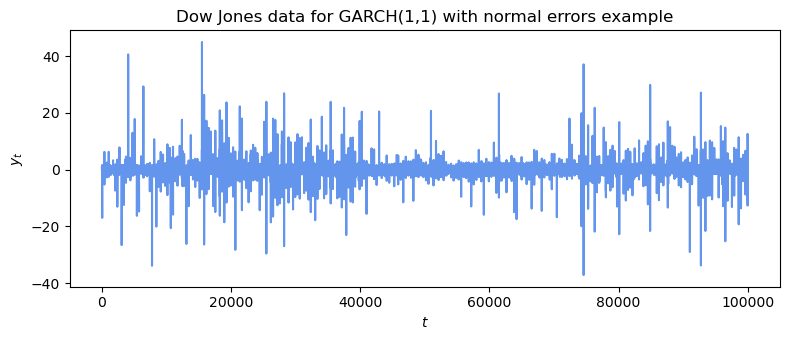

In [7]:
app = "App1_VB" # "Crap"  # To create folders
model = "GARCH11" # To create folders

GARCH_type = "GARCH"
error_type = "normal"

T = 100000 # Length of time series
p = 1 # Nbr of autoregressive y-lags in the GARCH-type variance process
q = 1 # Nbr of autoregressive sigma2-lags in the GARCH-type variance process
# Specify transforms (set all "identity" if no transformation)
dataset_name = "DowJones_%s(%s,%s)_%s_error" % (GARCH_type, p, q, error_type)

param_names, trans_param_names = get_param_names(GARCH_type, error_type, p, q)
names = {"params_name": param_names, "trans_param_names": trans_param_names}    
transforms = ["identity"] + ["log"] + p*["log"] + q*["log"]

# Likelihood optimisation settings (posterior optimisation always uses L-BFGS-B as it has a better starting value):
likelihood_optim = "basinhopping" 
options_L_BFGS_B = {"gtol":1e-6, "ftol":1e-12, "maxls":50, "maxiter":2000, "disp":True}
options_trust_ncg = {"gtol":1e-6, "maxiter":2000, "disp":True}
options_basinhopping = {"niter":5, "stepsize":0.5, "T":1.0, "disp":True}

# Prior settings:
# The default settings are
# mu_mean = 0.0, mu_sd = 10.0, omega_scale = 1.0, alpha_scale = 0.2, beta_scale = 0.8, v_shape = 2.0, v_rate = 1.0
# If other setting required, save as dictionary and pass on to the log prior once defined.
# Example:
prior_args = "default"
# prior_args = {"mu_mean":0.0, "mu_sd":100.0, "omega_scale":1.0, "alpha_scale":0.2, "beta_scale":0.8, "v_shape":2.0, "v_rate":1.0}

# Initialise prior. Either with default parameters or as specificed in prior_args
if prior_args == "default":
    log_prior = initiate_priors(GARCH_type, error_type)
    f = {"GARCH": log_prior_GARCH, "TGARCH": log_prior_TGARCH}[GARCH_type]
    prior_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    prior_hyperparams = prior_args
    log_prior = initiate_priors(GARCH_type, error_type, **prior_hyperparams)

# Penalty settings:
penalty_args = "default"

# Inititialise penalties for frequentist estimation
if penalty_args == "default":
    log_penalty = initiate_penalties(GARCH_type, error_type)
    f = {"GARCH": log_penalty_GARCH, "TGARCH": log_penalty_TGARCH}[GARCH_type]
    penalty_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    penalty_hyperparams = penalty_args
    log_penalty = initiate_penalties(GARCH_type, error_type, **penalty_hyperparams)
    
        
# Create model functions based on the inputs above
h, hinv, hinv_p, hinv_pp, jacdiag, logdet = initiate_transformation_functions(transforms)
log_densities, grad_log_densities, Hess_log_densities = initiate_model_functions(GARCH_type, error_type, hinv, hinv_p, hinv_pp)

# Read in data
# Dow Jones example  
log_returns = np.load("data/DowJones_100010obs.npy") # Data created as np.diff(np.log(data)).
series = log_returns[-(T + p):]
y = series / series.std() # std 1 normalisation.
y_start = y[:p][::-1]
y = y[-T:]
sigma2_start = np.array([1, 1, 1, 1])[-q:]
# End read data

theta0 = None # True values not available for real data
phi0 = None
if GARCH_type == 'GARCH':
    n_params = 2 + p + q
elif GARCH_type == 'TGARCH':
    n_params = 2 + 2*p + q
    
if error_type == 'Student-t':
    n_params += 1
assert(len(transforms) == n_params)

# Keep text selectable in the PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
# Latex
mpl.rcParams['text.usetex'] = False 

out_dir = Path("results") / app / model / error_type
out_dir.mkdir(parents=True, exist_ok=True)

with pdf_section("01_settings_and_data_plot", out_dir=out_dir) as active:
    with capture_output(display) as cap:
        print("==============================================================")
        print("GARCH_type:", GARCH_type, ", Error distribution:", error_type)
        print("Lags: p =, ", p, "q = ", q)
        print("Dataset name: ", dataset_name)
        print("Number of observations: ", T)
        print("Parameters:")
        display(Markdown(", ".join(param_names)))
        print("Tranformations:\n", transforms)
        print("Number of parameters:", n_params)
        print("Prior hyperparameters (v_rate and v_shape only if Student-t)")
        print_kv(prior_hyperparams)
        print("==============================================================")

    # Show in notebook
    cap.show()

    # Only write to PDF if active
    if active:
        text = cap.stdout
        pdf_add_text(text, title="Model and settings specified")

    # Measurements
    plt.figure(figsize=(8, 3.5))
    plt.title(f"Dow Jones data for GARCH(1,1) with normal errors example")
    plt.plot(y, color="cornflowerblue")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$y_t$")
    plt.tight_layout()

    # Only write figure to PDF if active
    if active:
        pdf_add_fig()

    plt.show()

### 2.2 Optimise log-likelihood and posterior

This section optimises the log-likelihood and the posterior. The maximum a posteriori (MAP) estimate is used to construct control variates and to obtain a preconditioning matrix for a random-walk proposal based on a scaled version of the full posterior covariance from a Laplace approximation. 

The mean and a scaled version of the diagonal of the covariance matrix from the Laplace approximation are used to initialise all variational optimisers.

In [8]:
# Minimise in phi space, so input is unrestricted
def log_penalty_phi(x, p, q):
    return log_penalty(hinv(x), p, q)

def obj_func_likelihood(x):
    """
    Penalised log-likelihood. To enforce the
    """
    return -log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + log_penalty_phi(x, p, q)/T

grad_log_penalty = grad(log_penalty_phi) #(x, p, q)
Hess_log_penalty = hessian(log_penalty_phi)

grad_obj_func_likelihood = lambda x: -grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + grad_log_penalty(x, p, q)/T # Gradient of obj_func_likelihood. Computed by automatic differentiation
Hess_obj_func_likelihood = lambda x: -Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + Hess_log_penalty(x, p, q)/T # Hessian of obj_func_likelihood. Computed by automatic differentiation

optim_dir = out_dir / "optim"
optim_dir.mkdir(parents=True, exist_ok=True)
save_path_optim = optim_dir / "optim_likelihood_result.h5"
log_path_optim = optim_dir / "optim_likelihood_live.log"

# Optimise the log-likelihood
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)


try:
    optim_results = load_dict_h5(save_path_optim)
    MLE = np.array(optim_results['optim_obj']['x'])
    Cov = optim_results['Cov_MLE']
    print('95% Confidence intervals for MLE estimates (phi)')
    print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2))
    print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2))
    print("\n\n")
    
except FileNotFoundError:
    # Optimise the log-likelihood
    mu_0 = np.mean(y)
    alpha_0 = np.array([0.1, 0.05, 0.05])[:p]    
    assert(len(alpha_0) == p)
    gamma_0 = np.array([0.03, 0.1, 0.03])[:p]
    assert(len(alpha_0) == p)
    beta_0 = np.array([0.2, 0.1])[:q]
    assert(len(beta_0) == q)
    omega_0 = np.var(y)
    assert(omega_0 >= 0)
    if error_type == "Student-t": 
        v_0 = 15
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0, v_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0, v_0)).flatten()  
            print(theta_optim_start)
    else: # normal error
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0)).flatten()

    phi_optim_start = h(theta_optim_start)
    
    start = time.perf_counter()
    it = {"k": 0} # For callback
    fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)

    with live_log_to_file(log_path_optim):

        if likelihood_optim == "trust-ncg":
            print('\n\nLikelihood optimisation settings for method trust-ncg:\n', flush=True)
            options = options_trust_ncg
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                jac=fg.jac, hess=Hess_obj_func_likelihood,
                method="trust-ncg", options=options
            )

        elif likelihood_optim == "L-BFGS-B":
            print('\n\nLikelihood optimisation settings for method L-BFGS-B:\n', flush=True)
            options = options_L_BFGS_B
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                method='L-BFGS-B', jac=fg.jac,
                callback=callback_optim, options=options
            )

        elif likelihood_optim == "basinhopping":
            minimizer_kwargs = {"method": "L-BFGS-B", "jac": fg.jac, "options": options_L_BFGS_B}
            res_optim_likelihood = basinhopping(
                fg.fun, x0=phi_optim_start,
                minimizer_kwargs=minimizer_kwargs,
                callback=callback_optim, **options_basinhopping
            )
        else:
            raise ValueError("Optimisation method does not exist")

        end = time.perf_counter()
        run_time = end - start

        # 

        print("==============================================================", flush=True)
        print("\nLikelihood optimisation took", run_time, "seconds.", flush=True)
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)

        print('MLE estimates (phi)', flush=True)
        MLE = res_optim_likelihood.x
        print(np.round(MLE, 2), flush=True)

        print('hinv(MLE) estimates (theta)', flush=True)
        print(np.round(hinv(MLE), 2), flush=True)

        print('95% Confidence intervals for MLE estimates (phi)', flush=True)
        Cov = np.linalg.inv(Hess_obj_func_likelihood(MLE)) / T
        print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)

        if likelihood_optim == "basinhopping":
            print_minimize_summary(
                res_optim_likelihood["lowest_optimization_result"],
                x_names=trans_param_names, latex=True
            )
        else:
            print_minimize_summary(
                res_optim_likelihood,
                x_names=trans_param_names, latex=True
            )

        print("==============================================================", flush=True)

    with pdf_section("02_optim_likelihood", out_dir=out_dir) as active:
        if active:
            text = log_path_optim.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-likelihood. Summary.")

    optim_results = {
        'optim_obj': pack_optimize_result(res_optim_likelihood),
        'method': likelihood_optim,
        'Cov_MLE': Cov,
        'start_value': phi_optim_start,
        'run_time': run_time
    }

    save_dict_h5(save_path_optim, optim_results)

95% Confidence intervals for MLE estimates (phi)
[-0.01 -2.7  -1.86 -0.25]
[ 0.   -2.59 -1.79 -0.23]





Optimise posterior.

In [9]:
# Define gradients and Hessian for log-posterior
log_prior_phi = lambda x: log_prior(hinv(x), p, q) + logdet(x) # for autograd
grad_log_prior_phi = grad(log_prior_phi)
grad_log_posterior = lambda x: grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + grad_log_prior_phi(x)
Hess_log_prior_phi = hessian(log_prior_phi)
Hess_log_posterior = lambda x: Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + Hess_log_prior_phi(x)#

obj_func_posterior = lambda x: -log_posterior(x, T, p, q, y, y_start, sigma2_start)[0] # Input is phi
grad_obj_func_posterior = lambda x: -grad_log_posterior(x) 
Hess_obj_func_posterior = lambda x: -Hess_log_posterior(x)

save_path_optim_posterior = optim_dir / "optim_posterior_result.h5"
log_path_optim_posterior = optim_dir / "optim_posterior_live.log"

# Optimise the log-posterior in phi space, so input is unrestricted
phi_optim_start = MLE
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_posterior, grad_obj_func_posterior)

try:    
    optim_posterior_results = load_dict_h5(save_path_optim_posterior)
    MAP = np.array(optim_posterior_results['optim_obj']['x'])
    Cov = optim_posterior_results['Cov']
    print('95% Credible intervals for posterior (phi)', flush=True)
    print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print("\n\n", flush=True)
    
except FileNotFoundError:
    # Optimise the posterior 
    start = time.perf_counter()

    with live_log_to_file(log_path_optim_posterior):

        res_optim_posterior = minimize(
            fg.fun, phi_optim_start,
            method='L-BFGS-B', jac=fg.jac,
            callback=callback_optim,
            options=options_L_BFGS_B
        )

        end = time.perf_counter()
        run_time = end - start

        print("==============================================================", flush=True)

        print("\nPosterior optimisation took", run_time, "seconds.", flush=True)
        print('\n\nPosterior optimisation settings for method L-BFGS-B:\n', flush=True)
        print_kv(options_L_BFGS_B)
        
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)
        # Compare answers
        print('MAP estimates (phi)', flush=True)
        MAP = res_optim_posterior.x
        print(np.round(MAP, 2), flush=True)
        print('hinv(MAP) estimates (theta)', flush=True)
        print(np.round(hinv(MAP), 2), flush=True)

        print('95% Credible intervals (normality assumption on posterior) (phi)', flush=True)
        Hess_MAP = Hess_obj_func_posterior(MAP)
        Cov = np.linalg.inv(Hess_MAP) # Negative Hessian inverse evaluated at the mode  
        if (np.linalg.eigvalsh(Cov) < 0).any():
            print("Cannot compute posterior covariance from Hessian. Trying outer product approximation", flush=True)
            scores = grad_log_densities(hinv(MAP), T, p, q, y, y_start, sigma2_start)
            Cov = np.linalg.inv(scores.T @ scores)
            assert (np.linalg.eigvalsh(Cov) > 0).all(), "Cannot compute posterior covariance."
            adapt_scaling = True
        else:
            adapt_scaling = False
        print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)
        print_minimize_summary(res_optim_posterior, x_names=trans_param_names, latex=True)
        optim_posterior_results = {
            'optim_obj': pack_optimize_result(res_optim_posterior),
            'method': 'L-BFGS-B',
            'Cov': Cov,
            'start_value': phi_optim_start,
            'run_time': run_time
        }
        save_dict_h5(save_path_optim_posterior, optim_posterior_results)
        print("==============================================================", flush=True)

    with pdf_section("03_optim_posterior", out_dir=out_dir) as active:
        if active:
            text = log_path_optim_posterior.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-posterior. Display and summary.")

95% Credible intervals for posterior (phi)
[-0.01 -2.7  -1.86 -0.25]
[ 0.   -2.59 -1.79 -0.23]





### 2.3 Markov Chain Monte Carlo

This section runs a Markov chain Monte Carlo (MCMC) algorithm using the full data set. This serves as the ground truth against which the variational approximations are compared.

The posterior of the GARCH model is challenging to sample from, even when preconditioning on an estimate of the posterior covariance (obtained from a Laplace approximation). We therefore employ an adaptive Metropolis–Hastings proposal.

In [10]:
n_iter_MCMC = 12000 
np.random.seed(SEEDS['App1_full_data_mcmc'])
N = n_iter_MCMC # MCMC samples
MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)
save_path_MCMC = MCMC_dir / ("full_data_MCMC_N%s.h5" % N)
log_path_MCMC = MCMC_dir / ("full_data_MCMC_N%s.log" % N)

try:
    MCMC_results = load_dict_h5(save_path_MCMC)
    result_full_data_MCMC = MCMC_results['MCMC_obj']
    prop_cov = MCMC_results['prop_cov']
    # Convert back to arrays
    for key in ["samples_phi", "samples_theta"]:
        result_full_data_MCMC[key] = np.asarray(result_full_data_MCMC[key])

except FileNotFoundError:

    with live_log_to_file(log_path_MCMC):

        # Run MCMC
        Sigma_pi = Cov # Negative Hessian inverse evaluated at the mode
        prop_cov = 2.38**2/n_params*Sigma_pi # For the random walk Negative Hessian inverse evaluated at the mode

        phi_init = MAP 
        print("==============================================================", flush=True)
        result_full_data_MCMC = sample_full_data_posterior_AM(
            phi_init, prop_cov, N, names, dataset_name,
            adapt_cov=True, adapt_scale=True, burn_in=1000
        )
        print("==============================================================", flush=True)

        MCMC_results = {'MCMC_obj': result_full_data_MCMC, 'prop_cov': prop_cov, 'start_value': phi_init}
        save_dict_h5(save_path_MCMC, MCMC_results)

    with pdf_section("04_full_data_MCMC", out_dir=out_dir) as active:
        if active:
            text = log_path_MCMC.read_text(encoding="utf-8")
            pdf_add_text(text, title="Full data MCMC sampling.")

            plot_traceplots_MCMC(
                result_full_data_MCMC['samples_theta'],
                param_true=hinv(MAP), param_names=param_names,
                burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
                suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
            )
            pdf_add_fig()          # saves all figures created by plot_traceplots_MCMC
            plt.close("all")       



### 2.4 Control variates for the log-density and its gradient
This section constructs and initialises the control variates used in our method to estimate the log-likelihood and its gradient. The control variates are also evaluated visually.

(100000,)
[pdf_section] Exists, skipping: results/App1_VB/GARCH11/normal/05_control_variates.pdf


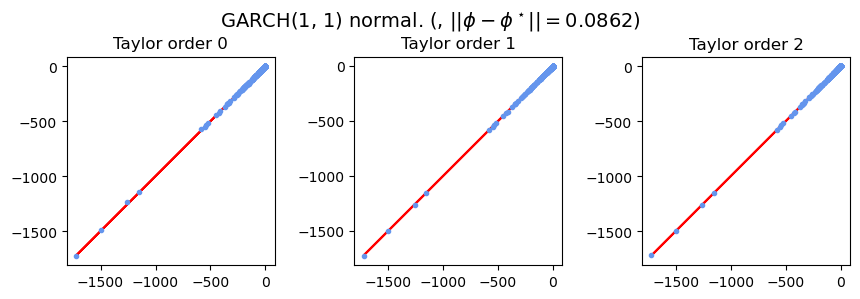

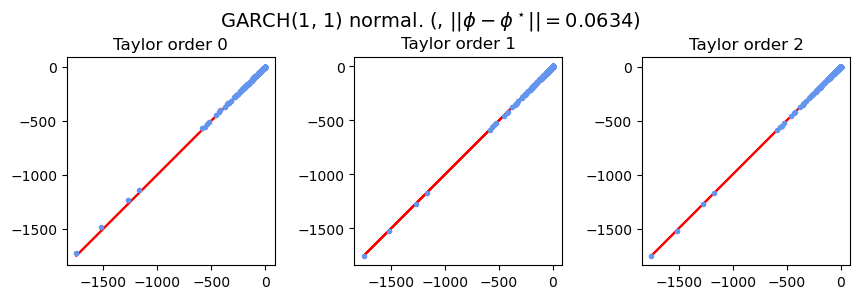

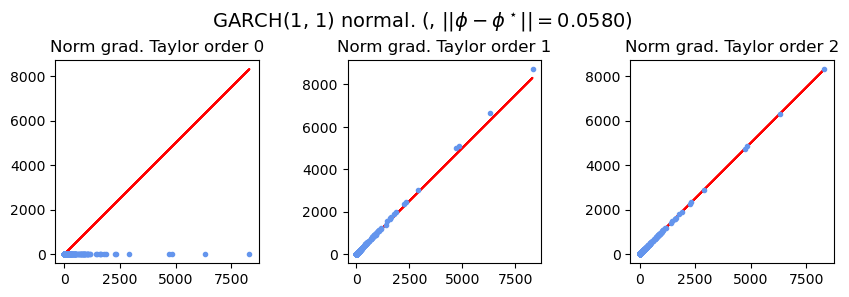

In [11]:
phiStar = MAP
args = (T, p, q, y, y_start, sigma2_start)
control_variate_dir = out_dir / "control_variates"
control_variate_dir.mkdir(parents=True, exist_ok=True)
save_path_control_variates = control_variate_dir / "control_variate_result.h5"
log_path_control_variates = control_variate_dir / "control_variate_live.log"

try:
    control_variates = load_dict_h5(save_path_control_variates)
    dens_at_phiStar = control_variates['dens_at_phiStar']
    grad_at_phiStar = control_variates['grad_at_phiStar'] 
    Hess_at_phiStar = control_variates['Hess_at_phiStar']
    end = control_variates['end']
    start = control_variates['start']
    cpu_CV = end - start

    print(dens_at_phiStar.shape)

except FileNotFoundError:
    with live_log_to_file(log_path_control_variates):
        start = time.perf_counter()
        dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar = initiate_control_variate_quantities(
            log_densities, grad_log_densities, Hess_log_densities, phiStar, args
        )
        end = time.perf_counter()
        cpu_CV = end - start
        print("==============================================================", flush=True)
        print("Elapsed time control variates initialisation with T = " , T, "p = " , p, "q = " , q,  ":", cpu_CV, "seconds", flush=True)
        print("==============================================================", flush=True)
        control_variates = {
            'dens_at_phiStar': dens_at_phiStar,
            'grad_at_phiStar': grad_at_phiStar,
            'Hess_at_phiStar': Hess_at_phiStar,
            'end': end,
            'start': start
        }
        save_dict_h5(save_path_control_variates, control_variates)

with pdf_section("05_control_variates", out_dir=out_dir) as active:

    if active:
        if log_path_control_variates.exists():
            text = log_path_control_variates.read_text(encoding="utf-8")
        else:
            text = "==============================================================\n" \
                   f"Elapsed time control variates initialisation with T = {T} p = {p} q = {q}: {cpu_CV} seconds\n" \
                   "==============================================================\n"
        pdf_add_text(text, title="Control variate construction.")

    # Precompute quantities for the control variates that do not depend on theta
    A = np.sum(dens_at_phiStar) 
    B = np.sum(grad_at_phiStar, axis = 0)
    C = np.sum(Hess_at_phiStar, axis = 0)
    # sum of control variates evaluated at phi    
    q_sum = lambda phi: A + np.dot(B, phi - phiStar) + 0.5*np.dot(phi - phiStar, np.dot(C, phi - phiStar))

    # Set up control variate quantities to estimate the gradient
    B_grad = np.sum(grad_at_phiStar, axis = 0)
    C_grad = np.sum(Hess_at_phiStar, axis = 0)
    # sum of control variates of the gradient evaluated at phi    
    grad_q_sum = lambda phi: B_grad + np.dot(C_grad, phi - phiStar)

    # Inspect control variate accuracy: log-densities

    # Outside median ellipse in phi space
    Sigma_pi = Cov # np.linalg.inv(Hess_obj_func_posterior(MAP))
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.50, n = 1).flatten()
    phi_beyond_median = phi
    q_k_order0 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    q_k_order1 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    q_k_order2 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    l_k = log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(l_k, l_k, color = 'red')
            if k == 0:
                axs[k].plot(l_k, q_k_order0, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(l_k, q_k_order1, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(l_k, q_k_order2, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)

    # Outside 0.999 ellipse
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.999, n = 1).flatten()
    phi_extreme = phi
    q_k_order0 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    q_k_order1 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    q_k_order2 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    l_k = log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(l_k, l_k, color = 'red')
            if k == 0:
                axs[k].plot(l_k, q_k_order0, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(l_k, q_k_order1, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(l_k, q_k_order2, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)

    # Inspect control variate accuracy: grad of log-densities
    # Outside median ellipse in phi space
    Sigma_pi = Cov # np.linalg.inv(Hess_obj_func_posterior(MAP))
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.50, n = 1).flatten()
    phi_beyond_median = phi
    grad_q_k_order0 = eval_grad_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    grad_q_k_order1 = eval_grad_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    grad_q_k_order2 = eval_grad_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    grad_l_k = grad_log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(np.linalg.norm(grad_l_k, axis = 1), np.linalg.norm(grad_l_k, axis = 1), color = 'red')
            if k == 0:
                axs[k].plot(np.linalg.norm(grad_l_k, axis = 1), np.linalg.norm(grad_q_k_order0, axis = 1), '.', color = 'cornflowerblue')
                axs[k].set_title('Norm grad. Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(np.linalg.norm(grad_l_k, axis = 1), np.linalg.norm(grad_q_k_order1, axis = 1), '.', color = 'cornflowerblue')
                axs[k].set_title('Norm grad. Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(np.linalg.norm(grad_l_k, axis = 1), np.linalg.norm(grad_q_k_order2, axis = 1), '.', color = 'cornflowerblue')
                axs[k].set_title('Norm grad. Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)


### 2.5 Subsampling variational Bayes with TPD tuned using $R_{\max} = 1000, 100, 10$

This section runs the subsampling variational Bayes methodology proposed in Gunawan et al. (2017), replacing uniform sampling probabilities with our truncated polynomial decaying (TPD).

We tune the estimator for different $R_{\max}$, which results in variance tolerance levels $V \approx 250, 25, 2.5$ (for $R_{\max} = 1000, 100, 10$) according to the guidelines in Section 2.7 of Quiroz et al. (2026).

In [12]:
t_star_frac = 0.01
t_star = int(t_star_frac* T)
b = 100.0
R_max_list = [1000, 100, 10, 1]
tuning_dir = out_dir / "tuning"
tuning_dir.mkdir(parents=True, exist_ok=True)

save_path_tuning = tuning_dir / "results_by_Rmax.h5"
log_path_tuning = tuning_dir / "tuning_live.log"

try:
    tuning_cache = load_dict_h5(save_path_tuning)
    results_by_Rmax_raw = tuning_cache["results_by_Rmax"]

    # Convert keys from str -> int
    results_by_Rmax = {int(k): v for k, v in results_by_Rmax_raw.items()}

    start = tuning_cache["start"]
    end = tuning_cache["end"]
    cpu_tuning_total = end - start

    print("==============================================================", flush=True)
    print("Loaded cached tuning results.", flush=True)
    print("Elapsed cached total tuning time:", cpu_tuning_total, "seconds", flush=True)
    print("==============================================================", flush=True)

except FileNotFoundError:
    with live_log_to_file(log_path_tuning):
        start = time.perf_counter()

        results_by_Rmax = run_calibrated_tuning_over_Rmax(
            R_max_list=R_max_list,
            MCMC_results=MCMC_results,
            MAP=MAP,
            phiStar=phiStar,
            dens_at_phiStar=dens_at_phiStar,
            grad_at_phiStar=grad_at_phiStar,
            Hess_at_phiStar=Hess_at_phiStar,
            args=args,
            T=T,
            t_star_frac=t_star_frac,
            b=b,
            m_min=1,
            pilot_slice=slice(1, 100, 5),
            verbose=True,
        )

        end = time.perf_counter()
        cpu_tuning_total = end - start

        print("==============================================================", flush=True)
        print("Elapsed total tuning time:", cpu_tuning_total, "seconds", flush=True)
        for R_max in R_max_list:
            print(
                f"R_max = {R_max}: cpu_tuning_Rmax = "
                f"{results_by_Rmax[R_max]['cpu_tuning_Rmax']:.2f} seconds",
                flush=True
            )
        print("==============================================================", flush=True)

        tuning_cache = {
            "results_by_Rmax": results_by_Rmax,
            "start": start,
            "end": end,
        }

        save_dict_h5(save_path_tuning, tuning_cache)

Loaded cached tuning results.
Elapsed cached total tuning time: 950.8834721660241 seconds


Summarise the tuning quantities for each $R_{\max}$.

In [13]:
for R_max in R_max_list:
    res = results_by_Rmax[R_max]

    E_umax_opt = expected_umax_safe(res['probs_opt'], res['m_opt'])

    print(
        f"R_max={R_max:>4} | "
        f"c_min={res['c_min']:.4f} | "
        f"V_target={res['V_target']:.6f} | "
        f"c_opt={res['c_opt']:.6f} | "
        f"m_opt={res['m_opt']} | "
        f"E[umax]={E_umax_opt:.4f} | "
        f"var_opt={res['var_opt']:.6f} | "
        f"bind={res['binding_ratio_final']:.6f}"
    )

R_max=1000 | c_min=0.0010 | V_target=241.904411 | c_opt=0.001410 | m_opt=1 | E[umax]=94.1952 | var_opt=241.904406 | bind=1.000000
R_max= 100 | c_min=0.0100 | V_target=24.190441 | c_opt=0.014101 | m_opt=1 | E[umax]=735.7590 | var_opt=24.190441 | bind=1.000000
R_max=  10 | c_min=0.1000 | V_target=2.419044 | c_opt=0.100000 | m_opt=1 | E[umax]=5038.8478 | var_opt=1.386656 | bind=0.573225
R_max=   1 | c_min=1.0000 | V_target=0.241904 | c_opt=1.000000 | m_opt=1 | E[umax]=50000.5000 | var_opt=0.138807 | bind=0.573811


Verification concerning the theoretical upper bound reported in Section 4.5.  

In [14]:
summarise_inflation_ratios({
    R_max: results_by_Rmax[R_max]
    for R_max in R_max_list if R_max != 1
})

R_max = 10
  At c_min (for approximate invariance across phi)
    min    = 9.89
    median = 9.98
    mean   = 9.98
    max    = 10.11
    std    = 0.04
    median / R_max = 0.9978
    max / R_max    = 1.0115
  At c_opt (for tightness of the bound 1/c_opt)
    min inflation ratio   = 9.89
    median inflation ratio= 9.98
    mean inflation ratio  = 9.97
    max inflation ratio   = 10.00
    min 1/c_opt           = 9.89
    median 1/c_opt        = 10.00
    mean 1/c_opt          = 9.99
    max 1/c_opt           = 10.00
    median ratio / bound  = 0.9978
    mean ratio / bound    = 0.9981
    max abs diff          = 0.11
  Final tuned value at phi_cross
    inflation ratio final = 9.99
    1/c_opt final         = 10.00
    ratio / bound final   = 0.9990

R_max = 100
  At c_min (for approximate invariance across phi)
    min    = 98.87
    median = 99.78
    mean   = 99.82
    max    = 101.27
    std    = 0.42
    median / R_max = 0.9978
    max / R_max    = 1.0127
  At c_opt (for tightne

The next code block constructs Figure 5 in the paper.

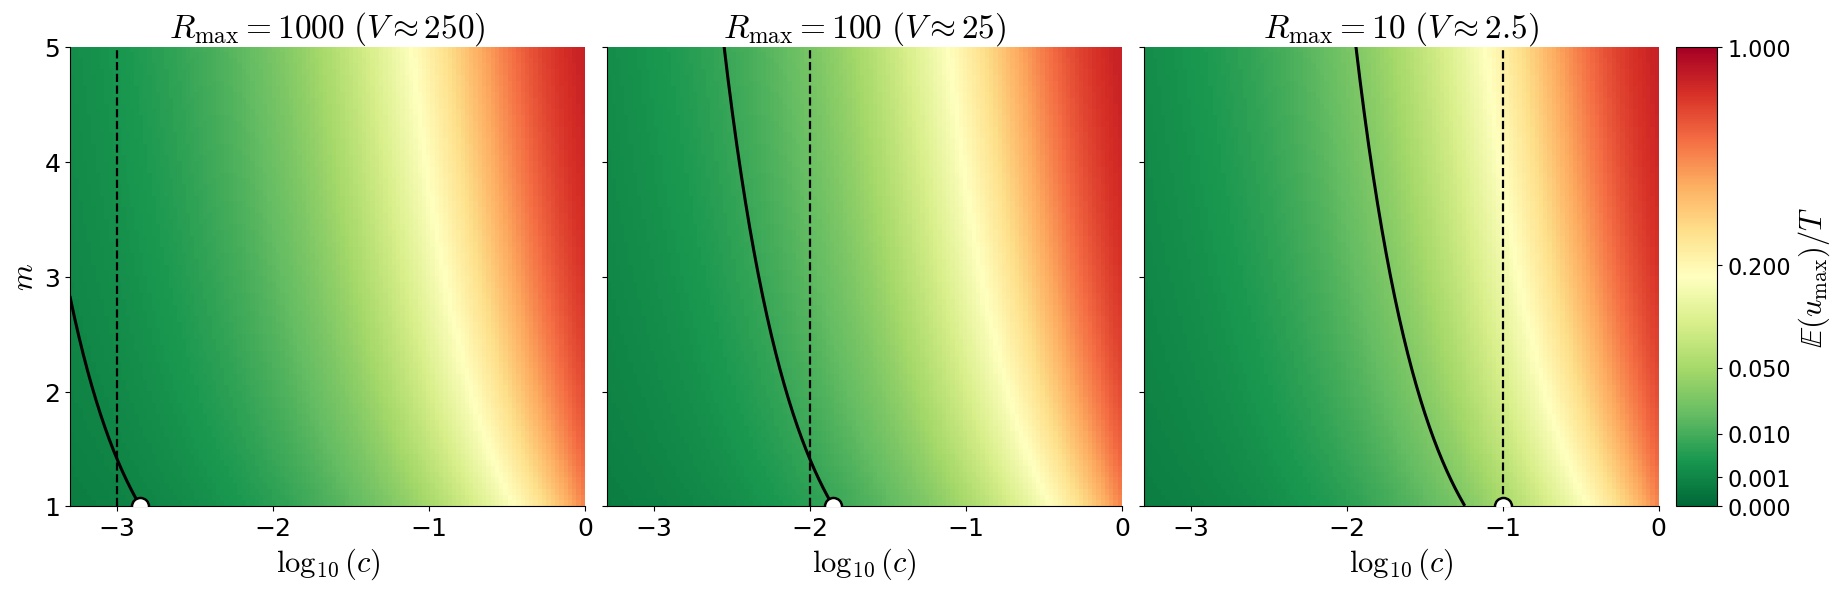

In [15]:
R_max_list = [1000, 100, 10]
V_tolerances_list = [250, 25, 2.5]
make_Rmax_triptych_from_results_Figure5(
    T=T,
    t_star=t_star,
    b=b,
    results_by_Rmax=results_by_Rmax,
    R_max_list=R_max_list,
    V_tol_list = V_tolerances_list,
    c_max=1.0,
    n_c=120,
    m_max=5,
    n_m_bg=80,
    power_gamma=0.4,
    vmax=1.0,
    marker_size=150,
    show_cmin_line=True
)

Estimate subsampling VB algorithms tuned with $V\approx 250,25,2.5$.

In [16]:
# ------------------------------------------------------------
# Estimate subsampling VB posteriors for tuned R_max values
# (rank1+iso), repeated runs with caching + per-run PDFs
# ------------------------------------------------------------
base_seed_map = {
    1000: SEEDS['vb_rmax1000'],
    100:  SEEDS['vb_rmax100'],
    10:   SEEDS['vb_rmax10'],
}

n_iter_VB = 5000
n_iter_read = 5000
warmup_iters_VB = 500
S_elbo_target = 100
n_repeat = 6

VB_dir = out_dir / "VB"
VB_dir.mkdir(parents=True, exist_ok=True)

# Store results by R_max
VB_results_by_Rmax = {}

for R_max in R_max_list:

    res_tune = results_by_Rmax[R_max]
    V_target = float(res_tune["V_target"])
    c_opt = float(res_tune["c_opt"])
    m_opt = int(res_tune["m_opt"])
    gamma_opt = float(res_tune["gamma_opt"])

    base_seed = base_seed_map[R_max]

    log_path_VB = VB_dir / f"subsampling_VB_Rmax{R_max}_n_iter{n_iter_read}_live.log"
    section_name = f"06_subsampling_VB_Rmax{R_max}_elbos"

    # Outputs collected across runs
    result_list = []
    elbo_list = []
    elbo_se_list = []
    cpu_list = []
    total_compute_list = []

    per_run_pdfs = []

    with live_log_to_file(log_path_VB):

        for run in range(1, n_repeat + 1):

            np.random.seed(base_seed + run)

            print(
                f"Running subsampling VB for {dataset_name} with "
                f"R_max = {R_max} and V_target = {V_target:.6f}",
                flush=True
            )

            save_path_VB = VB_dir / f"subsampling_VB_Rmax{R_max}_n_iter{n_iter_read}_rep{run}.h5"

            pdf_suffix = f"Rmax{R_max}_rep{run}"
            safe = section_name.replace(" ", "_").replace("/", "-")
            pdf_path_run = Path(out_dir) / f"{safe}_{pdf_suffix}.pdf"
            per_run_pdfs.append(pdf_path_run)

            try:
                subsampling_VB_results = load_dict_h5(save_path_VB)
                assert n_iter_read == subsampling_VB_results['VB_config']['n_iter'], \
                    "n_iter in settings differ."

                print("==============================================================", flush=True)
                print("WARNING: Loading cached results from disk.", flush=True)
                print("If configuration or code has changed, delete files and rerun.", flush=True)
                print(f"File: {save_path_VB}", flush=True)
                print("==============================================================", flush=True)

                result_VB = subsampling_VB_results['VB_obj']
                vb_subsampling_config = subsampling_VB_results['VB_config']
                estimator_params = subsampling_VB_results['estimator_params']
                lam_init = subsampling_VB_results['lam_init']

                for key in [
                    "lam_history", "m_history", "var_history", "elbo_history",
                    "elbo_smooth_history", "elbo_iters", "u_max", "m", "L"
                ]:
                    result_VB[key] = np.asarray(result_VB[key])

                print("==============================================================", flush=True)
                print("Reading in file with the following ELBO diagnostics", flush=True)
                elbo_final_estimate = subsampling_VB_results['elbo_final_estimate']
                elbo_hat, rej, (lo, hi), details = (
                    elbo_final_estimate['elbo_hat'],
                    elbo_final_estimate['rej'],
                    elbo_final_estimate['conf_init'],
                    elbo_final_estimate['details'],
                )
                print(
                    f"R_max = {R_max}: ELBO={elbo_hat:.2f}  "
                    f"95% CI [{lo:.2f}, {hi:.2f}]  "
                    f"rej={100*rej:.1f}%  "
                    f"n={details['n_valid']}/{details['n_attempts']}",
                    flush=True
                )
                print("==============================================================", flush=True)

            except FileNotFoundError:
                lam_init = init_rank1iso_from_laplace_diag(MAP, Sigma_pi, kappa=2.0, c_cap=2.0)

                vb_subsampling_config = dict(
                    n_iter=n_iter_VB,
                    S_grad=1,
                    S_elbo=5,
                    warmup_iters=warmup_iters_VB,
                    euclid_step_size=0.002,
                    nat_step_size=0.01,
                    nat_decay=0.60,
                    nat_offset=200.0,
                    fisher_ridge_init=1e-1,
                    fisher_ridge=1e-4,
                    fisher_ridge_tau=50.0,
                    trust_delta=0.01,
                    Sigma_lap=Sigma_pi,
                    kappa_c_floor=1e-3,
                    min_abs_c_floor=1e-12,
                    c_cap=2.0,
                    phi_cap=25.0,
                    max_draw_attempts=50,
                    eval_every=25,
                    elbo_ema_alpha=0.5,
                    elbo_tol_rel=1e-6,
                    consecutive_required=8,
                    param_avg_window=500,
                    stop_on_convergence=False,
                    verbose=True,
                    print_every=25,
                    elbo_drop_abs=1.5e5,
                    elbo_drop_rel=1.0,
                    check_every_draw_grad=False,
                )

                estimator_params = {
                    "m_opt": m_opt,
                    "c_opt": c_opt,
                    "gamma_opt": gamma_opt,
                    "t_star": t_star,
                    "b": b,
                    "V_tolerance": V_target,
                    "R_max": R_max,
                }


                print("==============================================================", flush=True)
                result_VB = estimate_subsampling_vb_rank1iso_natgrad(
                    estimator_params=estimator_params,
                    lam_init=lam_init,
                    d=n_params,
                    names=names,
                    dataset_name=dataset_name,
                    **vb_subsampling_config,
                )
                print("==============================================================", flush=True)

                print(f"Estimating ELBO at final iteration using full data and {S_elbo_target} MC samples", flush=True)
                lam_final = result_VB['lam']
                elbo_hat, rej, (lo, hi), details = elbo_estimate_final(
                    lam_final, n_params, S_elbo_target=S_elbo_target, return_details=True
                )
                elbo_final_estimate = {
                    'elbo_hat': elbo_hat,
                    'rej': rej,
                    'conf_init': (lo, hi),
                    'details': details
                }
                print(
                    f"R_max = {R_max}: ELBO={elbo_hat:.2f}  "
                    f"95% CI [{lo:.2f}, {hi:.2f}]  "
                    f"rej={100*rej:.1f}%  "
                    f"n={details['n_valid']}/{details['n_attempts']}",
                    flush=True
                )

                subsampling_VB_results = {
                    'VB_obj': result_VB,
                    'estimator_params': estimator_params,
                    'lam_init': lam_init,
                    'VB_config': vb_subsampling_config,
                    'elbo_final_estimate': elbo_final_estimate,
                }
                save_dict_h5(save_path_VB, subsampling_VB_results)

            with pdf_section(section_name, out_dir=out_dir, suffix=pdf_suffix, overwrite=False) as active_fig:
                if active_fig:
                    elbo_iters = result_VB["elbo_iters"]
                    elbo_values = result_VB['elbo_history']
                    elbo_values_smoothed = result_VB["elbo_smooth_history"]

                    pdf_add_text(
                        f"Repetition {run}/{n_repeat}",
                        title=f"Subsampling VB (R_max={R_max}, V≈{V_target:.2f}) figures"
                    )

                    plt.figure(figsize=(6, 4))
                    plt.plot(elbo_iters, elbo_values, "o-", label="ELBO")
                    plt.plot(elbo_iters, elbo_values_smoothed, "-.", label="smoothed ELBO")
                    plt.title("ELBO VB")
                    plt.xlabel("Iteration")
                    plt.ylabel("ELBO")
                    plt.legend()
                    plt.grid(True, alpha=0.3)
                    plt.tight_layout()
                    pdf_add_fig()
                    plt.close()

                    plot_rank1iso_from_lam_history(
                        result_VB['lam_history'],
                        n_params,
                        label=f"R_max = {R_max}",
                    )
                    pdf_add_fig()
                    plt.close()

            plt.close("all")

            result_list.append(result_VB)
            elbo_list.append(elbo_hat)
            elbo_se_list.append(details['se'])
            
            cpu_tuning_cost_App1_normal = results_by_Rmax[R_max]["cpu_tuning_Rmax"]
            cpu_VB = result_VB['run_time_full'] + cpu_tuning_cost_App1_normal
            cpu_list.append(cpu_VB + cpu_CV)

            work_grad_elbo = np.sum(
                (result_VB['u_max'] + 1) * vb_subsampling_config['S_grad']
            )
            monitor_mask = (np.arange(vb_subsampling_config['n_iter']) + 1) % vb_subsampling_config['eval_every'] == 0
            work_elbo = np.sum(
                (result_VB['u_max'][monitor_mask] + 1) * vb_subsampling_config['S_elbo']
            )
            work_tuning = 100 * T
            total_compute_list.append(work_grad_elbo + work_elbo + work_tuning)

    best_index = np.argmax(elbo_list)

    VB_results_by_Rmax[R_max] = {
        "result_list": result_list,
        "elbo_list": elbo_list,
        "elbo_se_list": elbo_se_list,
        "cpu_list": cpu_list,
        "total_compute_list": total_compute_list,
        "best_index": best_index,
        "best_result": result_list[best_index],
        "best_elbo": elbo_list[best_index],
        "best_elbo_se": elbo_se_list[best_index],
        "median_elbo": np.median(elbo_list),
        "median_cpu": np.median(cpu_list),
    }



Running subsampling VB for DowJones_GARCH(1,1)_normal_error with R_max = 1000 and V_target = 241.904411
If configuration or code has changed, delete files and rerun.
File: results/App1_VB/GARCH11/normal/VB/subsampling_VB_Rmax1000_n_iter5000_rep1.h5
Reading in file with the following ELBO diagnostics
R_max = 1000: ELBO=-114663.60  95% CI [-114664.24, -114662.97]  rej=0.0%  n=100/100
[pdf_section] Exists, skipping: results/App1_VB/GARCH11/normal/06_subsampling_VB_Rmax1000_elbos_Rmax1000_rep1.pdf
Running subsampling VB for DowJones_GARCH(1,1)_normal_error with R_max = 1000 and V_target = 241.904411
If configuration or code has changed, delete files and rerun.
File: results/App1_VB/GARCH11/normal/VB/subsampling_VB_Rmax1000_n_iter5000_rep2.h5
Reading in file with the following ELBO diagnostics
R_max = 1000: ELBO=-114688.10  95% CI [-114689.46, -114686.74]  rej=0.0%  n=100/100
[pdf_section] Exists, skipping: results/App1_VB/GARCH11/normal/06_subsampling_VB_Rmax1000_elbos_Rmax1000_rep2.pdf
Ru

### 2.6 Subsampling variational Bayes with uniform sampling

This section runs the subsampling variational Bayes methodology of Gunawan et al. (2017) with uniform sampling probabilities. Uniform sampling is a special case of our truncated polynomial decaying (TPD) scheme corresponding to $\gamma = 0$ (equivalently, $c = 1$). 

The estimator must be retuned with respect to the subsample size $m$; see Remark 7 in Section 2.7. This was done above by specifiying $R_{\max}=1$. Here, similar to the $R_{\max}=10$ case, the variance constraint does not bind at the optimum $m^\star=1$ (see the output of the "Summarise the tuning quantities for each $R_{\max}$" block above).

In [17]:
# ------------------------------------------------------------
# Estimate subsampling VB posteriors for UNIFORM tuning
# (rank1+iso), repeated runs with caching + per-run PDFs
# ------------------------------------------------------------
base_seed = SEEDS['vb_uniform']

n_iter_VB = 5000
n_iter_read = 5000
warmup_iters_VB = 500
S_elbo_target = 100
n_repeat = 6

VB_dir = out_dir / "VB"
VB_dir.mkdir(parents=True, exist_ok=True)

log_path_VB = VB_dir / f"subsampling_VB_uniform_n_iter{n_iter_read}_live.log"
section_name = "06_subsampling_VB_uniform_elbos"

# Set tuning quantities for the uniform casee
res_tune = results_by_Rmax[1]
V_target_uniform = float(res_tune["V_target"])
c_opt = float(res_tune["c_opt"]) # c_opt = 1.
m_opt = int(res_tune["m_opt"])
gamma_opt = float(res_tune["gamma_opt"])


# Outputs collected across runs
result_subsampling_VB_rank1iso_1MC_grad_uniform_list = []
elbos_subsampling_VB_rank1iso_1MC_grad_uniform_list = []
elbos_se_subsampling_VB_rank1iso_1MC_grad_uniform_list = []
cpus_subsampling_VB_rank1iso_1MC_grad_uniform_list = []
total_compute_subsampling_VB_rank1iso_1MC_grad_uniform_list = []

per_run_pdfs = []

with live_log_to_file(log_path_VB):

    for run in range(1, n_repeat + 1):

        np.random.seed(base_seed + run)

        print(
            f"Running subsampling VB for {dataset_name} with "
            f"uniform tuning and V_target = {V_target_uniform:.6f}",
            flush=True
        )

        save_path_VB = VB_dir / f"subsampling_VB_uniform_n_iter{n_iter_read}_rep{run}.h5"

        pdf_suffix = f"rep{run}"
        safe = section_name.replace(" ", "_").replace("/", "-")
        pdf_path_run = Path(out_dir) / f"{safe}_{pdf_suffix}.pdf"
        per_run_pdfs.append(pdf_path_run)

        try:
            subsampling_VB_results = load_dict_h5(save_path_VB)
            assert n_iter_read == subsampling_VB_results['VB_config']['n_iter'], \
                "n_iter in settings differ."

            print("==============================================================", flush=True)
            print("WARNING: Loading cached results from disk.", flush=True)
            print("If configuration or code has changed, delete files and rerun.", flush=True)
            print(f"File: {save_path_VB}", flush=True)
            print("==============================================================", flush=True)

            result_subsampling_VB_rank1iso_1MC_grad_uniform = subsampling_VB_results['VB_obj']
            vb_subsampling_config = subsampling_VB_results['VB_config']

            # Backward-compatible load of estimator params
            estimator_params_uniform = subsampling_VB_results.get(
                'estimator_params_uniform',
                subsampling_VB_results.get('estimator_params')
            )

            lam_init = subsampling_VB_results['lam_init']

            for key in [
                "lam_history", "m_history", "var_history", "elbo_history",
                "elbo_smooth_history", "elbo_iters", "u_max", "m", "L"
            ]:
                result_subsampling_VB_rank1iso_1MC_grad_uniform[key] = np.asarray(
                    result_subsampling_VB_rank1iso_1MC_grad_uniform[key]
                )

            print("==============================================================", flush=True)
            print("Reading in file with the following ELBO diagnostics", flush=True)
            elbo_final_estimate = subsampling_VB_results['elbo_final_estimate']
            elbo_hat, rej, (lo, hi), details = (
                elbo_final_estimate['elbo_hat'],
                elbo_final_estimate['rej'],
                elbo_final_estimate['conf_init'],
                elbo_final_estimate['details'],
            )
            print(
                f"Uniform: ELBO={elbo_hat:.2f}  "
                f"95% CI [{lo:.2f}, {hi:.2f}]  "
                f"rej={100*rej:.1f}%  "
                f"n={details['n_valid']}/{details['n_attempts']}",
                flush=True
            )
            print("==============================================================", flush=True)

        except FileNotFoundError:
            lam_init = init_rank1iso_from_laplace_diag(MAP, Sigma_pi, kappa=2.0, c_cap=2.0)

            vb_subsampling_config = dict(
                n_iter=n_iter_VB,
                S_grad=1,
                S_elbo=5,
                warmup_iters=warmup_iters_VB,
                euclid_step_size=0.002,
                nat_step_size=0.01,
                nat_decay=0.60,
                nat_offset=200.0,
                fisher_ridge_init=1e-1,
                fisher_ridge=1e-4,
                fisher_ridge_tau=50.0,
                trust_delta=0.01,
                Sigma_lap=Sigma_pi,
                kappa_c_floor=1e-3,
                min_abs_c_floor=1e-12,
                c_cap=2.0,
                phi_cap=25.0,
                max_draw_attempts=50,
                eval_every=25,
                elbo_ema_alpha=0.5,
                elbo_tol_rel=1e-6,
                consecutive_required=8,
                param_avg_window=500,
                stop_on_convergence=False,
                verbose=True,
                print_every=25,
                elbo_drop_abs=1.5e5,
                elbo_drop_rel=1.0,
                check_every_draw_grad=False,
            )


            estimator_params_uniform = {
                "m_opt": m_opt,
                "c_opt": c_opt,
                "gamma_opt": gamma_opt,
                "t_star": t_star,
                "b": b,
                "V_tolerance": V_target_uniform,
                "R_max": 1,
            }

            print("==============================================================", flush=True)
            result_subsampling_VB_rank1iso_1MC_grad_uniform = estimate_subsampling_vb_rank1iso_natgrad(
                estimator_params=estimator_params_uniform,
                lam_init=lam_init,
                d=n_params,
                names=names,
                dataset_name=dataset_name,
                **vb_subsampling_config,
            )
            print("==============================================================", flush=True)

            print(
                f"Estimating ELBO at final iteration using full data and {S_elbo_target} MC samples",
                flush=True
            )
            lam_final = result_subsampling_VB_rank1iso_1MC_grad_uniform['lam']
            elbo_hat, rej, (lo, hi), details = elbo_estimate_final(
                lam_final, n_params, S_elbo_target=S_elbo_target, return_details=True
            )

            elbo_final_estimate = {
                'elbo_hat': elbo_hat,
                'rej': rej,
                'conf_init': (lo, hi),
                'details': details
            }

            print(
                f"Uniform: ELBO={elbo_hat:.2f}  "
                f"95% CI [{lo:.2f}, {hi:.2f}]  "
                f"rej={100*rej:.1f}%  "
                f"n={details['n_valid']}/{details['n_attempts']}",
                flush=True
            )

            subsampling_VB_results = {
                'VB_obj': result_subsampling_VB_rank1iso_1MC_grad_uniform,
                'estimator_params_uniform': estimator_params_uniform,  # keep old name for compatibility
                'lam_init': lam_init,
                'VB_config': vb_subsampling_config,
                'elbo_final_estimate': elbo_final_estimate,
            }
            save_dict_h5(save_path_VB, subsampling_VB_results)

        with pdf_section(section_name, out_dir=out_dir, suffix=pdf_suffix, overwrite=False) as active_fig:
            if active_fig:
                elbo_iters = result_subsampling_VB_rank1iso_1MC_grad_uniform["elbo_iters"]
                elbo_values = result_subsampling_VB_rank1iso_1MC_grad_uniform['elbo_history']
                elbo_values_smoothed = result_subsampling_VB_rank1iso_1MC_grad_uniform["elbo_smooth_history"]

                pdf_add_text(
                    f"Repetition {run}/{n_repeat}",
                    title=f"Subsampling VB (uniform, V≈{V_target_uniform:.2f}) figures"
                )

                plt.figure(figsize=(6, 4))
                plt.plot(elbo_iters, elbo_values, "o-", label="ELBO")
                plt.plot(elbo_iters, elbo_values_smoothed, "-.", label="smoothed ELBO")
                plt.title("ELBO VB")
                plt.xlabel("Iteration")
                plt.ylabel("ELBO")
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                pdf_add_fig()
                plt.close()

                plot_rank1iso_from_lam_history(
                    result_subsampling_VB_rank1iso_1MC_grad_uniform['lam_history'],
                    n_params,
                    label="Uniform",
                )
                pdf_add_fig()
                plt.close()

        plt.close("all")

        result_subsampling_VB_rank1iso_1MC_grad_uniform_list.append(
            result_subsampling_VB_rank1iso_1MC_grad_uniform
        )
        elbos_subsampling_VB_rank1iso_1MC_grad_uniform_list.append(elbo_hat)
        elbos_se_subsampling_VB_rank1iso_1MC_grad_uniform_list.append(details['se'])

        cpu_tuning_cost_App1_normal = results_by_Rmax[1]["cpu_tuning_Rmax"] # R_max = 1 is uniform (contains cost for its tuning)
        cpu_VB = (
            result_subsampling_VB_rank1iso_1MC_grad_uniform['run_time_full']
            + cpu_tuning_cost_App1_normal
        )
        cpus_subsampling_VB_rank1iso_1MC_grad_uniform_list.append(cpu_VB + cpu_CV)

        work_grad_elbo = np.sum(
            (result_subsampling_VB_rank1iso_1MC_grad_uniform['u_max'] + 1)
            * vb_subsampling_config['S_grad']
        )
        monitor_mask = (
            (np.arange(vb_subsampling_config['n_iter']) + 1)
            % vb_subsampling_config['eval_every'] == 0
        )
        work_elbo = np.sum(
            (result_subsampling_VB_rank1iso_1MC_grad_uniform['u_max'][monitor_mask] + 1)
            * vb_subsampling_config['S_elbo']
        )
        work_tuning = 100 * T
        total_compute_subsampling_VB_rank1iso_1MC_grad_uniform_list.append(
            work_grad_elbo + work_elbo + work_tuning
        )

best_index = np.argmax(elbos_subsampling_VB_rank1iso_1MC_grad_uniform_list)
result_subsampling_VB_rank1iso_1MC_grad_uniform = \
    result_subsampling_VB_rank1iso_1MC_grad_uniform_list[best_index]
best_elbo_uniform = elbos_subsampling_VB_rank1iso_1MC_grad_uniform_list[best_index]
se_best_elbo_uniform = elbos_se_subsampling_VB_rank1iso_1MC_grad_uniform_list[best_index]
median_elbo_uniform = np.median(elbos_subsampling_VB_rank1iso_1MC_grad_uniform_list)
median_CPU_uniform = np.median(cpus_subsampling_VB_rank1iso_1MC_grad_uniform_list)
total_compute_uniform = total_compute_subsampling_VB_rank1iso_1MC_grad_uniform_list

Running subsampling VB for DowJones_GARCH(1,1)_normal_error with uniform tuning and V_target = 0.241904
If configuration or code has changed, delete files and rerun.
File: results/App1_VB/GARCH11/normal/VB/subsampling_VB_uniform_n_iter5000_rep1.h5
Reading in file with the following ELBO diagnostics
Uniform: ELBO=-114664.03  95% CI [-114664.72, -114663.34]  rej=0.0%  n=100/100
[pdf_section] Exists, skipping: results/App1_VB/GARCH11/normal/06_subsampling_VB_uniform_elbos_rep1.pdf
Running subsampling VB for DowJones_GARCH(1,1)_normal_error with uniform tuning and V_target = 0.241904
If configuration or code has changed, delete files and rerun.
File: results/App1_VB/GARCH11/normal/VB/subsampling_VB_uniform_n_iter5000_rep2.h5
Reading in file with the following ELBO diagnostics
Uniform: ELBO=-114668.89  95% CI [-114669.40, -114668.38]  rej=0.0%  n=100/100
[pdf_section] Exists, skipping: results/App1_VB/GARCH11/normal/06_subsampling_VB_uniform_elbos_rep2.pdf
Running subsampling VB for DowJone

### 2.7 Full-data variational Bayes

The previous sections run a doubly stochastic variational Bayes algorithm with two sources of stochasticity:  

(i) subsampling for estimating the log-likelihood and its gradient, and  
(ii) Monte Carlo estimation using the reparameterisation trick.

This section implements a version of the algorithm that removes the first source of stochasticity by evaluating the log-likelihood and its gradient using the full dataset. We refer to this as a singly stochastic variational Bayes algorithm in the paper.

In [18]:
# Full-data VB (rank1+iso), repeated runs with caching + per-run PDFs.
# -----------------------------
# Settings
# -----------------------------
base_seed = SEEDS['vb_full_data']

VB_dir = out_dir / "VB"
VB_dir.mkdir(parents=True, exist_ok=True)

log_path_VB = VB_dir / ("full_data_VB_n_iter%s_live.log" % n_iter_read)

section_name = "07_full_data_VB_elbos"

# Outputs collected across runs
result_full_data_VB_rank1iso_1MC_grad_full_data_list = []
elbos_full_data_VB_rank1iso_1MC_grad_full_data_list = []
elbos_se_full_data_VB_rank1iso_1MC_grad_full_data_list = []
cpus_full_data_VB_rank1iso_1MC_grad_full_data_list = []
total_compute_full_data_VB_rank1iso_1MC_grad_full_data_list = []

# Track per-run pdf paths (for merging)
per_run_pdfs = []

# Full-data VB configuration
vb_full_data_config = dict(
    # Iterations
    n_iter=n_iter_VB,

    # Monte Carlo
    S_grad=1,
    S_elbo=5,

    # Warmup (Euclidean steps before nat-grad)
    warmup_iters=warmup_iters_VB,
    euclid_step_size=0.002,

    # Natural-gradient schedule
    nat_step_size=0.01,
    nat_decay=0.60,
    nat_offset=200.0,

    # Fisher ridge schedule
    fisher_ridge_init=1e-1,
    fisher_ridge=1e-4,
    fisher_ridge_tau=50.0,

    # Trust region / step clipping
    trust_delta=0.01,

    # Variational stability / projection
    c_cap=2.0,

    # Hard rejection to avoid hinv overflow
    phi_cap=25.0,
    max_draw_attempts=50,

    # Monitoring / convergence
    eval_every=25,
    elbo_ema_alpha=0.5,
    elbo_tol_rel=1e-6,
    consecutive_required=8,
    param_avg_window=500,
    stop_on_convergence=False,

    verbose=True,
    print_every=25,

    # ELBO gating
    elbo_drop_abs=1.5e5,
    elbo_drop_rel=1.0,

    # Debug
    check_every_draw_grad=False,
)

with live_log_to_file(log_path_VB):

    for run in range(1, n_repeat + 1):

        # -----------------------------
        # Per-run deterministic seed
        # -----------------------------
        np.random.seed(base_seed + run)

        print("Running full-data VB for", dataset_name, flush=True)

        # Cached result path
        save_path_VB = VB_dir / ("full_data_VB_n_iter%s_rep%s.h5" % (n_iter_read, run))

        # Per-run PDF suffix and expected path (matches pdf_section logic)
        pdf_suffix = f"rep{run}"
        safe = section_name.replace(" ", "_").replace("/", "-")
        pdf_path_run = Path(out_dir) / f"{safe}_{pdf_suffix}.pdf"
        per_run_pdfs.append(pdf_path_run)

        # -----------------------------
        # Load or run
        # -----------------------------
        try:
            full_data_VB_results = load_dict_h5(save_path_VB)
            assert n_iter_read == full_data_VB_results['VB_config']['n_iter'], "n_iter in settings differ."

            print("==============================================================", flush=True)
            print("WARNING: Loading cached results from disk.", flush=True)
            print("If configuration or code has changed, delete files and rerun.", flush=True)
            print(f"File: {save_path_VB}", flush=True)
            print("==============================================================", flush=True)

            result_full_data_VB_rank1iso_1MC_grad_full_data = full_data_VB_results['VB_obj']
            vb_full_data_config = full_data_VB_results['VB_config']
            lam_init = full_data_VB_results['lam_init']

            for key in ["lam_history", "m_history", "var_history", "elbo_history", "elbo_smooth_history",
                        "elbo_iters", "u_max", "m", "L"]:
                if key in result_full_data_VB_rank1iso_1MC_grad_full_data:
                    result_full_data_VB_rank1iso_1MC_grad_full_data[key] = np.asarray(
                        result_full_data_VB_rank1iso_1MC_grad_full_data[key]
                    )

            print("==============================================================", flush=True)
            print("Reading in file with the following ELBO diagnostics", flush=True)
            elbo_final_estimate = full_data_VB_results['elbo_final_estimate']
            elbo_hat, rej, (lo, hi), details = (
                elbo_final_estimate['elbo_hat'],
                elbo_final_estimate['rej'],
                elbo_final_estimate['conf_init'],
                elbo_final_estimate['details'],
            )
            print(f"Full data: ELBO={elbo_hat:.2f}  95% CI [{lo:.2f}, {hi:.2f}]  "
                  f"rej={100*rej:.1f}%  n={details['n_valid']}/{details['n_attempts']}",
                  flush=True)
            print("==============================================================", flush=True)

        except FileNotFoundError:
            lam_init = init_rank1iso_from_laplace_diag(MAP, Sigma_pi, kappa=2.0, c_cap=2.0)

            print("==============================================================", flush=True)
            result_full_data_VB_rank1iso_1MC_grad_full_data = estimate_full_data_vb_rank1iso_natgrad(
                lam_init=lam_init,
                d=n_params,
                names=names,
                dataset_name=dataset_name,
                **vb_full_data_config,
            )
            print("==============================================================", flush=True)

            print("Estimating ELBO at final iteration using full data and 100 MC samples", flush=True)
            lam_final = result_full_data_VB_rank1iso_1MC_grad_full_data['lam']
            elbo_hat, rej, (lo, hi), details = elbo_estimate_final(
                lam_final, n_params, S_elbo_target=100, return_details=True
            )
            elbo_final_estimate = {'elbo_hat': elbo_hat, 'rej': rej, 'conf_init': (lo, hi), 'details': details}

            print(f"Full data: ELBO={elbo_hat:.2f}  95% CI [{lo:.2f}, {hi:.2f}]  "
                  f"rej={100*rej:.1f}%  n={details['n_valid']}/{details['n_attempts']}",
                  flush=True)

            full_data_VB_results = {
                'VB_obj': result_full_data_VB_rank1iso_1MC_grad_full_data,
                'lam_init': lam_init,
                'VB_config': vb_full_data_config,
                'elbo_final_estimate': elbo_final_estimate,
            }
            save_dict_h5(save_path_VB, full_data_VB_results)

        # -----------------------------
        # Per-run plotting into its own PDF (skips if already exists)
        # -----------------------------
        with pdf_section(section_name, out_dir=out_dir, suffix=pdf_suffix, overwrite=False) as active_fig:
            if active_fig:
                elbo_iters = result_full_data_VB_rank1iso_1MC_grad_full_data["elbo_iters"]
                elbo_values = result_full_data_VB_rank1iso_1MC_grad_full_data['elbo_history']
                elbo_values_smoothed = result_full_data_VB_rank1iso_1MC_grad_full_data["elbo_smooth_history"]

                pdf_add_text(f"Repetition {run}/{n_repeat}", title="Full data VB figures")

                plt.figure(figsize=(6, 4))
                plt.plot(elbo_iters, elbo_values, "o-", label="ELBO")
                plt.plot(elbo_iters, elbo_values_smoothed, "-.", label="smoothed ELBO")
                plt.title("ELBO VB")
                plt.xlabel("Iteration")
                plt.ylabel("ELBO")
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                pdf_add_fig()
                plt.close()

                plot_rank1iso_from_lam_history(
                    result_full_data_VB_rank1iso_1MC_grad_full_data['lam_history'],
                    n_params,
                    label="Full data",
                )
                pdf_add_fig()
                plt.close()

        plt.close("all")

        # -----------------------------
        # Append run results
        # -----------------------------
        result_full_data_VB_rank1iso_1MC_grad_full_data_list.append(result_full_data_VB_rank1iso_1MC_grad_full_data)
        elbos_full_data_VB_rank1iso_1MC_grad_full_data_list.append(elbo_hat)
        elbos_se_full_data_VB_rank1iso_1MC_grad_full_data_list.append(details['se'])

        cpu_VB = result_full_data_VB_rank1iso_1MC_grad_full_data['run_time_full_data']
        cpus_full_data_VB_rank1iso_1MC_grad_full_data_list.append(cpu_VB)

        work_grad_elbo = np.sum((np.ones(vb_full_data_config['n_iter']) * T) * vb_full_data_config['S_grad'])
        monitor_mask = (np.arange(vb_full_data_config['n_iter']) + 1) % vb_full_data_config['eval_every'] == 0
        work_elbo = np.sum((np.ones(np.sum(monitor_mask)) * T) * vb_full_data_config['S_elbo'])
        total_compute_full_data_VB_rank1iso_1MC_grad_full_data_list.append(work_grad_elbo + work_elbo)

# -----------------------------
# Choose best / summaries
# -----------------------------
best_index = np.argmax(elbos_full_data_VB_rank1iso_1MC_grad_full_data_list)
result_full_data_VB_rank1iso_1MC_grad_full_data = result_full_data_VB_rank1iso_1MC_grad_full_data_list[best_index]
best_elbo_full_data = elbos_full_data_VB_rank1iso_1MC_grad_full_data_list[best_index]
se_best_elbo_full_data = elbos_se_full_data_VB_rank1iso_1MC_grad_full_data_list[best_index]
median_elbo_full_data = np.median(elbos_full_data_VB_rank1iso_1MC_grad_full_data_list)
median_CPU_full_data = np.median(cpus_full_data_VB_rank1iso_1MC_grad_full_data_list)
total_compute_full_data = total_compute_full_data_VB_rank1iso_1MC_grad_full_data_list


Running full-data VB for DowJones_GARCH(1,1)_normal_error
If configuration or code has changed, delete files and rerun.
File: results/App1_VB/GARCH11/normal/VB/full_data_VB_n_iter5000_rep1.h5
Reading in file with the following ELBO diagnostics
Full data: ELBO=-114671.23  95% CI [-114671.67, -114670.80]  rej=0.0%  n=100/100
[pdf_section] Exists, skipping: results/App1_VB/GARCH11/normal/07_full_data_VB_elbos_rep1.pdf
Running full-data VB for DowJones_GARCH(1,1)_normal_error
If configuration or code has changed, delete files and rerun.
File: results/App1_VB/GARCH11/normal/VB/full_data_VB_n_iter5000_rep2.h5
Reading in file with the following ELBO diagnostics
Full data: ELBO=-114667.50  95% CI [-114668.24, -114666.76]  rej=0.0%  n=100/100
[pdf_section] Exists, skipping: results/App1_VB/GARCH11/normal/07_full_data_VB_elbos_rep2.pdf
Running full-data VB for DowJones_GARCH(1,1)_normal_error
If configuration or code has changed, delete files and rerun.
File: results/App1_VB/GARCH11/normal/VB/fu

### 2.8 Comparisons

This section visualises the ELBO per iteration for the best-performing run of each method in a single graph. Moreover, we look at typical behaviour by considering the upper median ELBO of the runs. See details in the paper. For this case, we examine the marginal posteriors from all methods and compare them with the ground truth obtained from Markov chain Monte Carlo applied to the full dataset.

[pdf_section] Exists, skipping: results/App1_VB/GARCH11/normal/08_best_elbo_comparison_new.pdf


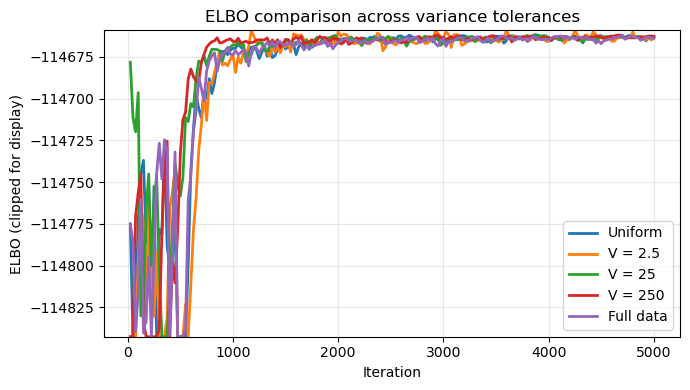

In [19]:
with pdf_section("08_best_elbo_comparison_new", out_dir=out_dir) as active_fig:

    results = {
        "Uniform": result_subsampling_VB_rank1iso_1MC_grad_uniform,
        "V = 2.5": VB_results_by_Rmax[10]['best_result'],
        "V = 25":  VB_results_by_Rmax[100]['best_result'],
        "V = 250": VB_results_by_Rmax[1000]['best_result'],
        "Full data": result_full_data_VB_rank1iso_1MC_grad_full_data
    }

    all_sm = np.concatenate([np.asarray(r["elbo_smooth_history"]) for r in results.values()])

    lo_q, hi_q = 0.03, 0.997
    y_lo, y_hi = np.quantile(all_sm, [lo_q, hi_q])

    plt.figure(figsize=(7, 4))

    for label, res in results.items():
        it = np.asarray(res["elbo_iters"])
        sm = np.asarray(res["elbo_smooth_history"])
        sm_plot = np.clip(sm, y_lo, y_hi)
        plt.plot(it, sm_plot, linewidth=2, label=label)

    plt.ylim(y_lo, y_hi)
    plt.xlabel("Iteration")
    plt.ylabel("ELBO (clipped for display)")
    plt.title("ELBO comparison across variance tolerances")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if active_fig:
        pdf_add_text("Best ELBO comparison across methods")
        pdf_add_fig()

    plt.show()
    plt.close("all")

The following code creates Figure 6 in the paper.

/tmp/ipykernel_199248/1223294488.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


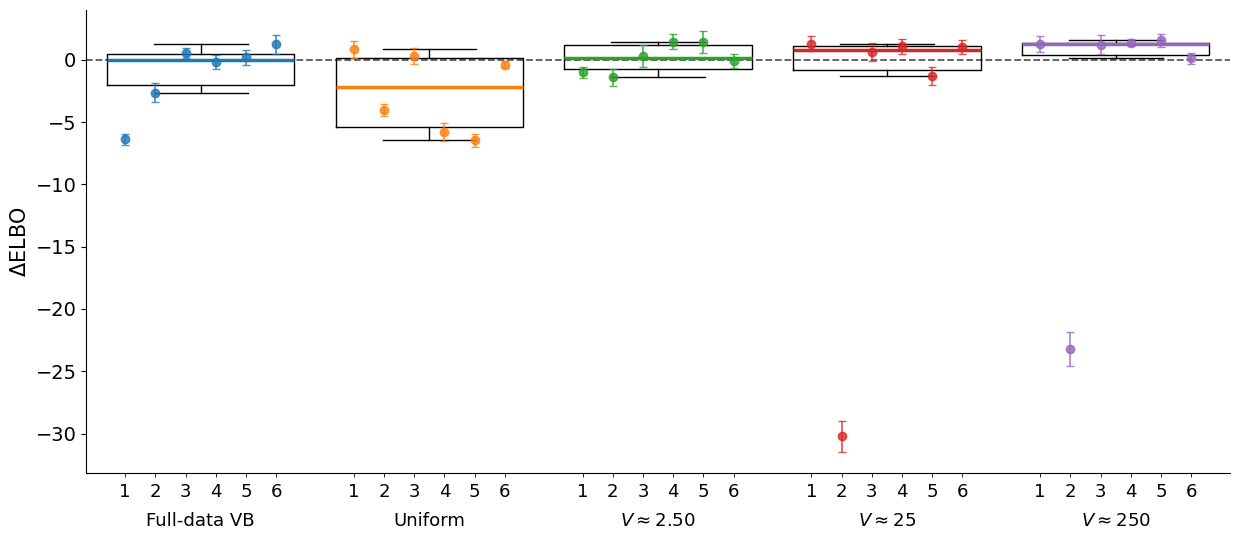

In [20]:
# -----------------------------
# Settings / inputs
# -----------------------------
# Full-data ELBOs across runs
full_data_elbos = np.asarray(
    elbos_full_data_VB_rank1iso_1MC_grad_full_data_list, dtype=float
)
full_data_ses = np.asarray(
    elbos_se_full_data_VB_rank1iso_1MC_grad_full_data_list, dtype=float
)

methods = [
    (
        "Full-data VB",
        full_data_elbos,
        full_data_ses,
        "#1f77b4",
    ),
    (
        "Uniform",
        np.asarray(elbos_subsampling_VB_rank1iso_1MC_grad_uniform_list, dtype=float),
        np.asarray(elbos_se_subsampling_VB_rank1iso_1MC_grad_uniform_list, dtype=float),
        "#ff7f0e",
    ),
    (
        r"$V \approx 2.50$",
        np.asarray(VB_results_by_Rmax[10]['elbo_list'], dtype=float),
        np.asarray(VB_results_by_Rmax[10]['elbo_se_list'], dtype=float),
        "#2ca02c",
    ),
    (
        r"$V \approx 25$",
        np.asarray(VB_results_by_Rmax[100]['elbo_list'], dtype=float),
        np.asarray(VB_results_by_Rmax[100]['elbo_se_list'], dtype=float),
        "#d62728",
    ),
    (
        r"$V \approx 250$",
        np.asarray(VB_results_by_Rmax[1000]['elbo_list'], dtype=float),
        np.asarray(VB_results_by_Rmax[1000]['elbo_se_list'], dtype=float),
        "#9467bd",
    ),
]

# -----------------------------
# Compute baseline and deltas
# -----------------------------
baseline = float(np.median(full_data_elbos))

delta_methods = []
for lab, vals, ses, colour in methods:
    vals = np.asarray(vals, dtype=float)
    ses = np.asarray(ses, dtype=float)

    if len(vals) != len(ses):
        raise ValueError(f"{lab}: ELBO values and standard errors must match.")

    delta_methods.append((lab, vals - baseline, ses, colour))

labels = [lab for lab, _, _, _ in delta_methods]
delta_vals = [vals for _, vals, _, _ in delta_methods]

n_rep = len(delta_methods[0][1])

# Spread runs wider
offsets = np.linspace(-0.33, 0.33, n_rep)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(12.5, 5.5))

# Wider boxes
bp = ax.boxplot(
    delta_vals,
    labels=labels,
    showfliers=False,
    widths=0.82,
)

# Colour the median lines to match the dots
for median, (_, _, _, colour) in zip(bp["medians"], delta_methods):
    median.set_color(colour)
    median.set_linewidth(2.5)

# Overlay run-specific ELBO estimates
for i, (lab, vals, ses, colour) in enumerate(delta_methods, start=1):
    for r in range(n_rep):
        x = i + offsets[r]

        ax.errorbar(
            x,
            vals[r],
            yerr=1.96 * ses[r],
            fmt="o",
            color=colour,
            ecolor=colour,
            markersize=6,
            elinewidth=1.2,
            capsize=3,
            alpha=0.8,
            zorder=3,
        )

# Reference line
ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1.3,
    color="0.35",
    zorder=0,
)


ax.set_ylabel(r"$\Delta$ELBO", fontsize=15)

# Larger y tick labels
ax.tick_params(axis="y", labelsize=14)

# -----------------------------
# Minor ticks for runs 1..6
# -----------------------------
group_centres = np.arange(1, len(delta_methods) + 1)

minor_positions = []
minor_labels = []

for centre in group_centres:
    for r in range(n_rep):
        minor_positions.append(centre + offsets[r])
        minor_labels.append(str(r + 1))

ax.set_xticks(group_centres)
ax.set_xticklabels(labels, fontsize=13)

ax.set_xticks(minor_positions, minor=True)
ax.set_xticklabels(minor_labels, minor=True, fontsize=13)

# spacing between method labels and run ticks
ax.tick_params(axis="x", which="major", pad=28, length=0)
ax.tick_params(axis="x", which="minor", pad=4, length=3)

# Clean spines
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()
plt.close("all")

We note above that two outliers appear for $V\approx 25$ and $V\approx 250$. The following code performs the stability analyysis in the paper.

In [21]:
# Stability analysis
# ------------------------------------------------------------
# Robustness study for subsampling VB posteriors
# Only for R_max in {100, 1000}, repeated runs with caching
# Reuse reps 1-6 from the original VB folder if available
# ------------------------------------------------------------
base_seed_map = {
    1000: SEEDS['vb_rmax1000'],
    100:  SEEDS['vb_rmax100'],
}

n_iter_VB = 5000
n_iter_read = 5000
warmup_iters_VB =500
S_elbo_target = 100
n_repeat = 50

R_max_list_robustness = [100, 1000]

# Original directory containing the existing 6-run study
VB_dir_old = out_dir / "VB"
VB_dir_old.mkdir(parents=True, exist_ok=True)

# New directory for the robustness study
VB_robustness_dir = out_dir / "VB_robustness_check"
VB_robustness_dir.mkdir(parents=True, exist_ok=True)

# Store robustness results by R_max
VB_results_by_Rmax_robustness = {}

for R_max in R_max_list_robustness:

    res_tune = results_by_Rmax[R_max]
    V_target = float(res_tune["V_target"])
    c_opt = float(res_tune["c_opt"])
    m_opt = int(res_tune["m_opt"])
    gamma_opt = float(res_tune["gamma_opt"])

    base_seed = base_seed_map[R_max]

    log_path_VB = VB_robustness_dir / f"subsampling_VB_Rmax{R_max}_n_iter{n_iter_read}_live.log"
    section_name = f"06_subsampling_VB_robustness_Rmax{R_max}_elbos"

    # Outputs collected across runs
    result_list = []
    elbo_list = []
    elbo_se_list = []
    cpu_list = []
    total_compute_list = []

    per_run_pdfs = []

    with live_log_to_file(log_path_VB):

        for run in range(1, n_repeat + 1):

            np.random.seed(base_seed + run)

            print(
                f"Running ROBUSTNESS subsampling VB for {dataset_name} with "
                f"R_max = {R_max}, V_target = {V_target:.6f}, run = {run}/{n_repeat}",
                flush=True
            )

            # ------------------------------------------------------------
            # Reuse runs 1-6 from the original directory if present
            # Store new runs (and fallback reruns) in robustness directory
            # ------------------------------------------------------------
            save_name = f"subsampling_VB_Rmax{R_max}_n_iter{n_iter_read}_rep{run}.h5"

            old_save_path_VB = VB_dir_old / save_name
            new_save_path_VB = VB_robustness_dir / save_name

            if run <= 6 and old_save_path_VB.exists():
                save_path_VB = old_save_path_VB
                loaded_from_old_cache = True
            else:
                save_path_VB = new_save_path_VB
                loaded_from_old_cache = False

            pdf_suffix = f"Rmax{R_max}_rep{run}"
            safe = section_name.replace(" ", "_").replace("/", "-")
            pdf_path_run = VB_robustness_dir / f"{safe}_{pdf_suffix}.pdf"
            per_run_pdfs.append(pdf_path_run)

            try:
                subsampling_VB_results = load_dict_h5(save_path_VB)
                assert n_iter_read == subsampling_VB_results['VB_config']['n_iter'], \
                    "n_iter in settings differ."

                print("==============================================================", flush=True)
                print("WARNING: Loading cached results from disk.", flush=True)
                if loaded_from_old_cache:
                    print("Using cached result from ORIGINAL 6-run study.", flush=True)
                else:
                    print("Using cached result from ROBUSTNESS study directory.", flush=True)
                print(f"File: {save_path_VB}", flush=True)
                print("==============================================================", flush=True)

                result_VB = subsampling_VB_results['VB_obj']
                vb_subsampling_config = subsampling_VB_results['VB_config']
                estimator_params = subsampling_VB_results['estimator_params']
                lam_init = subsampling_VB_results['lam_init']

                for key in [
                    "lam_history", "m_history", "var_history", "elbo_history",
                    "elbo_smooth_history", "elbo_iters", "u_max", "m", "L"
                ]:
                    result_VB[key] = np.asarray(result_VB[key])

                print("==============================================================", flush=True)
                print("Reading in file with the following ELBO diagnostics", flush=True)
                elbo_final_estimate = subsampling_VB_results['elbo_final_estimate']
                elbo_hat, rej, (lo, hi), details = (
                    elbo_final_estimate['elbo_hat'],
                    elbo_final_estimate['rej'],
                    elbo_final_estimate['conf_init'],
                    elbo_final_estimate['details'],
                )
                print(
                    f"R_max = {R_max}: ELBO={elbo_hat:.2f}  "
                    f"95% CI [{lo:.2f}, {hi:.2f}]  "
                    f"rej={100*rej:.1f}%  "
                    f"n={details['n_valid']}/{details['n_attempts']}",
                    flush=True
                )
                print("==============================================================", flush=True)

            except FileNotFoundError:
                lam_init = init_rank1iso_from_laplace_diag(MAP, Sigma_pi, kappa=2.0, c_cap=2.0)

                vb_subsampling_config = dict(
                    n_iter=n_iter_VB,
                    S_grad=1,
                    S_elbo=5,
                    warmup_iters=warmup_iters_VB,
                    euclid_step_size=0.002,
                    nat_step_size=0.01,
                    nat_decay=0.60,
                    nat_offset=200.0,
                    fisher_ridge_init=1e-1,
                    fisher_ridge=1e-4,
                    fisher_ridge_tau=50.0,
                    trust_delta=0.01,
                    Sigma_lap=Sigma_pi,
                    kappa_c_floor=1e-3,
                    min_abs_c_floor=1e-12,
                    c_cap=2.0,
                    phi_cap=25.0,
                    max_draw_attempts=50,
                    eval_every=25,
                    elbo_ema_alpha=0.5,
                    elbo_tol_rel=1e-6,
                    consecutive_required=8,
                    param_avg_window=500,
                    stop_on_convergence=False,
                    verbose=True,
                    print_every=25,
                    elbo_drop_abs=1.5e5,
                    elbo_drop_rel=1.0,
                    check_every_draw_grad=False,
                )

                estimator_params = {
                    "m_opt": m_opt,
                    "c_opt": c_opt,
                    "gamma_opt": gamma_opt,
                    "t_star": t_star,
                    "b": b,
                    "V_tolerance": V_target,
                    "R_max": R_max,
                }

                print("==============================================================", flush=True)
                result_VB = estimate_subsampling_vb_rank1iso_natgrad(
                    estimator_params=estimator_params,
                    lam_init=lam_init,
                    d=n_params,
                    names=names,
                    dataset_name=dataset_name,
                    **vb_subsampling_config,
                )
                print("==============================================================", flush=True)

                print(
                    f"Estimating ELBO at final iteration using full data and {S_elbo_target} MC samples",
                    flush=True
                )
                lam_final = result_VB['lam']
                elbo_hat, rej, (lo, hi), details = elbo_estimate_final(
                    lam_final, n_params, S_elbo_target=S_elbo_target, return_details=True
                )
                elbo_final_estimate = {
                    'elbo_hat': elbo_hat,
                    'rej': rej,
                    'conf_init': (lo, hi),
                    'details': details
                }
                print(
                    f"R_max = {R_max}: ELBO={elbo_hat:.2f}  "
                    f"95% CI [{lo:.2f}, {hi:.2f}]  "
                    f"rej={100*rej:.1f}%  "
                    f"n={details['n_valid']}/{details['n_attempts']}",
                    flush=True
                )

                subsampling_VB_results = {
                    'VB_obj': result_VB,
                    'estimator_params': estimator_params,
                    'lam_init': lam_init,
                    'VB_config': vb_subsampling_config,
                    'elbo_final_estimate': elbo_final_estimate,
                }

                # Always save newly generated runs to the robustness directory
                save_dict_h5(new_save_path_VB, subsampling_VB_results)

            with pdf_section(
                section_name,
                out_dir=VB_robustness_dir,
                suffix=pdf_suffix,
                overwrite=False
            ) as active_fig:
                if active_fig:
                    elbo_iters = result_VB["elbo_iters"]
                    elbo_values = result_VB['elbo_history']
                    elbo_values_smoothed = result_VB["elbo_smooth_history"]

                    pdf_add_text(
                        f"Repetition {run}/{n_repeat}",
                        title=f"Subsampling VB robustness check (R_max={R_max}, V≈{V_target:.2f}) figures"
                    )

                    plt.figure(figsize=(6, 4))
                    plt.plot(elbo_iters, elbo_values, "o-", label="ELBO")
                    plt.plot(elbo_iters, elbo_values_smoothed, "-.", label="smoothed ELBO")
                    plt.title("ELBO VB")
                    plt.xlabel("Iteration")
                    plt.ylabel("ELBO")
                    plt.legend()
                    plt.grid(True, alpha=0.3)
                    plt.tight_layout()
                    pdf_add_fig()
                    plt.close()

                    plot_rank1iso_from_lam_history(
                        result_VB['lam_history'],
                        n_params,
                        label=f"R_max = {R_max}",
                    )
                    pdf_add_fig()
                    plt.close()

            plt.close("all")

            result_list.append(result_VB)
            elbo_list.append(elbo_hat)
            elbo_se_list.append(details['se'])

            cpu_tuning_cost_App1_normal = results_by_Rmax[R_max]["cpu_tuning_Rmax"]
            cpu_VB = result_VB['run_time_full'] + cpu_tuning_cost_App1_normal
            cpu_list.append(cpu_VB + cpu_CV)

            work_grad_elbo = np.sum(
                (result_VB['u_max'] + 1) * vb_subsampling_config['S_grad']
            )
            monitor_mask = (
                (np.arange(vb_subsampling_config['n_iter']) + 1)
                % vb_subsampling_config['eval_every'] == 0
            )
            work_elbo = np.sum(
                (result_VB['u_max'][monitor_mask] + 1) * vb_subsampling_config['S_elbo']
            )
            work_tuning = 100 * T
            total_compute_list.append(work_grad_elbo + work_elbo + work_tuning)

    best_index = np.argmax(elbo_list)

    VB_results_by_Rmax_robustness[R_max] = {
        "result_list": result_list,
        "elbo_list": elbo_list,
        "elbo_se_list": elbo_se_list,
        "cpu_list": cpu_list,
        "total_compute_list": total_compute_list,
        "best_index": best_index,
        "best_result": result_list[best_index],
        "best_elbo": elbo_list[best_index],
        "best_elbo_se": elbo_se_list[best_index],
        "median_elbo": np.median(elbo_list),
        "median_cpu": np.median(cpu_list),
        "n_repeat": n_repeat,
        "V_target": V_target,
    }

Running ROBUSTNESS subsampling VB for DowJones_GARCH(1,1)_normal_error with R_max = 100, V_target = 24.190441, run = 1/50
Using cached result from ORIGINAL 6-run study.
File: results/App1_VB/GARCH11/normal/VB/subsampling_VB_Rmax100_n_iter5000_rep1.h5
Reading in file with the following ELBO diagnostics
R_max = 100: ELBO=-114663.56  95% CI [-114664.14, -114662.99]  rej=0.0%  n=100/100
[pdf_section] Exists, skipping: results/App1_VB/GARCH11/normal/VB_robustness_check/06_subsampling_VB_robustness_Rmax100_elbos_Rmax100_rep1.pdf
Running ROBUSTNESS subsampling VB for DowJones_GARCH(1,1)_normal_error with R_max = 100, V_target = 24.190441, run = 2/50
Using cached result from ORIGINAL 6-run study.
File: results/App1_VB/GARCH11/normal/VB/subsampling_VB_Rmax100_n_iter5000_rep2.h5
Reading in file with the following ELBO diagnostics
R_max = 100: ELBO=-114695.08  95% CI [-114696.34, -114693.82]  rej=0.0%  n=100/100
[pdf_section] Exists, skipping: results/App1_VB/GARCH11/normal/VB_robustness_check/06

In [22]:
# ------------------------------------------------------------
# Robustness summary table for paper
# ------------------------------------------------------------

# Reference: median full-data VB ELBO

# Extract ELBOs for robustness runs
elbo_25 = np.asarray(VB_results_by_Rmax_robustness[100]['elbo_list'], dtype=float)
elbo_250 = np.asarray(VB_results_by_Rmax_robustness[1000]['elbo_list'], dtype=float)

# Convert to Delta ELBO relative to median full-data VB
delta_25 = elbo_25 - float(np.median(full_data_elbos))
delta_250 = elbo_250 - float(np.median(full_data_elbos))

def summarise_tail_probs(delta_vals):
    delta_vals = np.asarray(delta_vals, dtype=float)
    return {
        "median": np.median(delta_vals),
        "p_lt_5": np.mean(delta_vals < -5),
        "p_lt_10": np.mean(delta_vals < -10),
        "p_lt_15": np.mean(delta_vals < -15),
    }

summary_25 = summarise_tail_probs(delta_25)
summary_250 = summarise_tail_probs(delta_250)

# ------------------------------------------------------------
# Build LaTeX table
# ------------------------------------------------------------
latex_table = rf"""
\begin{{table}}[t]
\centering
\caption{{Robustness summary over 50 independent runs for the two larger variance settings. The table reports the median $\Delta$ELBO and the empirical probability of runs below selected thresholds.}}
\label{{tab:vb_robustness}}
\begin{{tabular}}{{lrrrr}}
\toprule
Method & $\Delta$ELBO & $\Pr(\Delta \mathrm{{ELBO}} < -5)$ & $\Pr(\Delta \mathrm{{ELBO}} < -10)$ & $\Pr(\Delta \mathrm{{ELBO}} < -15)$ \\
\midrule
$V \approx 25$  & {summary_25['median']:.2f} & {summary_25['p_lt_5']:.2f} & {summary_25['p_lt_10']:.2f} & {summary_25['p_lt_15']:.2f} \\
$V \approx 250$ & {summary_250['median']:.2f} & {summary_250['p_lt_5']:.2f} & {summary_250['p_lt_10']:.2f} & {summary_250['p_lt_15']:.2f} \\
\bottomrule
\end{{tabular}}
\end{{table}}
""".strip()
# ------------------------------------------------------------
# Save to disk
# ------------------------------------------------------------
table_txt_path = Path(out_dir) / "tables" / "table2_paper.txt"
table_txt_path.parent.mkdir(parents=True, exist_ok=True)

with open(table_txt_path, "w") as f:
    f.write(latex_table)

print("Saved LaTeX table to:")
print(table_txt_path)
print("\nLaTeX table:\n")
print(latex_table)

Saved LaTeX table to:
results/App1_VB/GARCH11/normal/tables/table2_paper.txt

LaTeX table:

\begin{table}[t]
\centering
\caption{Robustness summary over 50 independent runs for the two larger variance settings. The table reports the median $\Delta$ELBO and the empirical probability of runs below selected thresholds.}
\label{tab:vb_robustness}
\begin{tabular}{lrrrr}
\toprule
Method & $\Delta$ELBO & $\Pr(\Delta \mathrm{ELBO} < -5)$ & $\Pr(\Delta \mathrm{ELBO} < -10)$ & $\Pr(\Delta \mathrm{ELBO} < -15)$ \\
\midrule
$V \approx 25$  & 1.16 & 0.08 & 0.06 & 0.06 \\
$V \approx 250$ & 0.93 & 0.10 & 0.08 & 0.08 \\
\bottomrule
\end{tabular}
\end{table}


The following code creates Figure 7 in the paper

In [23]:
# KDE for median run:
# ------------------------------------------------------------
# Helper: get median-nearest VB run
# ------------------------------------------------------------
def get_upper_median_run(result_list, elbo_list):
    elbos = np.asarray(elbo_list, dtype=float)
    idx_sorted = np.argsort(elbos)
    upper_median_idx = idx_sorted[len(elbos) // 2]  # index of e_(4) when n=6
    return result_list[upper_median_idx], upper_median_idx

# ------------------------------------------------------------
# Select median-nearest runs
# ------------------------------------------------------------

# Full-data VB
result_full_data_VB_median, idx_full = get_upper_median_run(
    result_full_data_VB_rank1iso_1MC_grad_full_data_list,
    elbos_full_data_VB_rank1iso_1MC_grad_full_data_list
)

# Uniform
result_uniform_median, idx_uniform = get_upper_median_run(
    result_subsampling_VB_rank1iso_1MC_grad_uniform_list,
    elbos_subsampling_VB_rank1iso_1MC_grad_uniform_list
)

# TPD cases
result_Rmax10_median, idx_10 = get_upper_median_run(
    VB_results_by_Rmax[10]["result_list"],
    VB_results_by_Rmax[10]["elbo_list"]
)

result_Rmax100_median, idx_100 = get_upper_median_run(
    VB_results_by_Rmax[100]["result_list"],
    VB_results_by_Rmax[100]["elbo_list"]
)

result_Rmax1000_median, idx_1000 = get_upper_median_run(
    VB_results_by_Rmax[1000]["result_list"],
    VB_results_by_Rmax[1000]["elbo_list"]
)

[pdf_section] Exists, skipping: results/App1_VB/GARCH11/normal/09_kde_best_runs.pdf
pdf_section active_fig = False


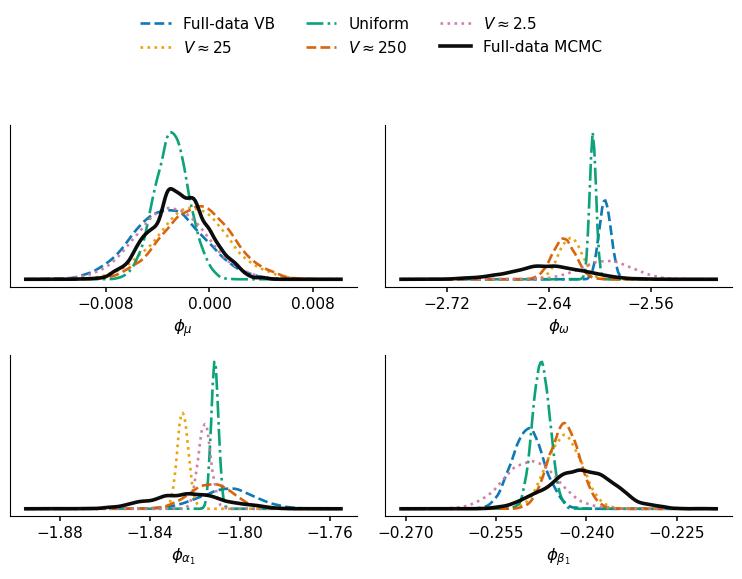

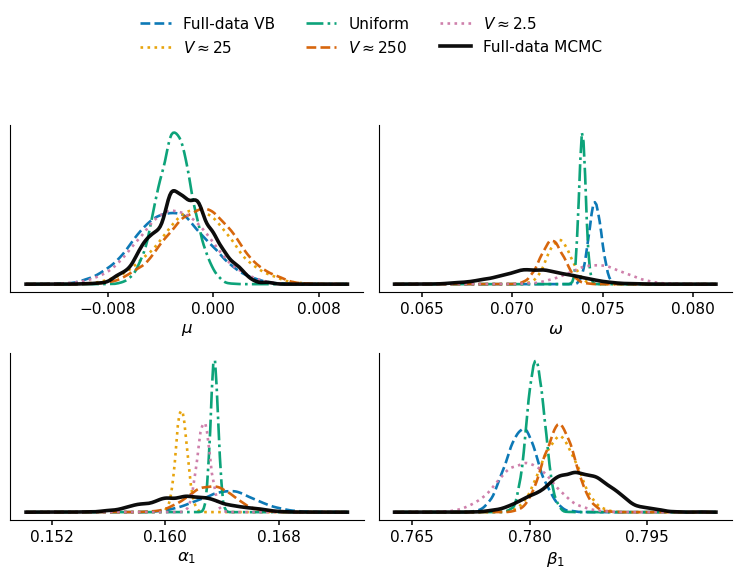

In [24]:
np.random.seed(SEEDS['vb_kdes'])
# ------------------------------------------------------------
# KDE comparison for median VB runs
# ------------------------------------------------------------
N = 10000
burn_in = 2000

# Best tuned VB runs from the consolidated R_max block
result_subsampling_VB_rank1iso_1MC_grad_Rmax10   = result_Rmax10_median
result_subsampling_VB_rank1iso_1MC_grad_Rmax100  = result_Rmax100_median
result_subsampling_VB_rank1iso_1MC_grad_Rmax1000 = result_Rmax1000_median

# ------------------------------------------------------------
# Full-data VB
# ------------------------------------------------------------
post_mean_full_data_VB_rank1iso_1MC_grad_full_data = (
    result_full_data_VB_median['m']
)
post_cov_full_data_VB_rank1iso_1MC_grad_full_data = np.dot(
    result_full_data_VB_median['L'],
    result_full_data_VB_median['L'].T
)

# ------------------------------------------------------------
# Tuned VB: R_max = 10  -> V ≈ 2.5
# ------------------------------------------------------------
post_mean_subsampling_VB_rank1iso_1MC_grad_Rmax10 = (
    result_subsampling_VB_rank1iso_1MC_grad_Rmax10['m']
)
post_cov_subsampling_VB_rank1iso_1MC_grad_Rmax10 = np.dot(
    result_subsampling_VB_rank1iso_1MC_grad_Rmax10['L'],
    result_subsampling_VB_rank1iso_1MC_grad_Rmax10['L'].T
)

# ------------------------------------------------------------
# Tuned VB: R_max = 100 -> V ≈ 25
# ------------------------------------------------------------
post_mean_subsampling_VB_rank1iso_1MC_grad_Rmax100 = (
    result_subsampling_VB_rank1iso_1MC_grad_Rmax100['m']
)
post_cov_subsampling_VB_rank1iso_1MC_grad_Rmax100 = np.dot(
    result_subsampling_VB_rank1iso_1MC_grad_Rmax100['L'],
    result_subsampling_VB_rank1iso_1MC_grad_Rmax100['L'].T
)

# ------------------------------------------------------------
# Tuned VB: R_max = 1000 -> V ≈ 250
# ------------------------------------------------------------
post_mean_subsampling_VB_rank1iso_1MC_grad_Rmax1000 = (
    result_subsampling_VB_rank1iso_1MC_grad_Rmax1000['m']
)
post_cov_subsampling_VB_rank1iso_1MC_grad_Rmax1000 = np.dot(
    result_subsampling_VB_rank1iso_1MC_grad_Rmax1000['L'],
    result_subsampling_VB_rank1iso_1MC_grad_Rmax1000['L'].T
)

# ------------------------------------------------------------
# Uniform VB
# ------------------------------------------------------------
post_mean_subsampling_VB_rank1iso_1MC_grad_uniform = (
    result_uniform_median['m']
)
post_cov_subsampling_VB_rank1iso_1MC_grad_uniform = np.dot(
    result_uniform_median['L'],
    result_uniform_median['L'].T
)

# ------------------------------------------------------------
# Draw samples in phi-space
# ------------------------------------------------------------
samples_phi_full_data_VB_rank1iso_1MC_grad_full_data = np.random.multivariate_normal(
    post_mean_full_data_VB_rank1iso_1MC_grad_full_data,
    post_cov_full_data_VB_rank1iso_1MC_grad_full_data,
    size=N
)

samples_phi_subsampling_VB_rank1iso_1MC_grad_uniform = np.random.multivariate_normal(
    post_mean_subsampling_VB_rank1iso_1MC_grad_uniform,
    post_cov_subsampling_VB_rank1iso_1MC_grad_uniform,
    size=N
)

samples_phi_subsampling_VB_rank1iso_1MC_grad_Rmax10 = np.random.multivariate_normal(
    post_mean_subsampling_VB_rank1iso_1MC_grad_Rmax10,
    post_cov_subsampling_VB_rank1iso_1MC_grad_Rmax10,
    size=N
)

samples_phi_subsampling_VB_rank1iso_1MC_grad_Rmax100 = np.random.multivariate_normal(
    post_mean_subsampling_VB_rank1iso_1MC_grad_Rmax100,
    post_cov_subsampling_VB_rank1iso_1MC_grad_Rmax100,
    size=N
)

samples_phi_subsampling_VB_rank1iso_1MC_grad_Rmax1000 = np.random.multivariate_normal(
    post_mean_subsampling_VB_rank1iso_1MC_grad_Rmax1000,
    post_cov_subsampling_VB_rank1iso_1MC_grad_Rmax1000,
    size=N
)

# ------------------------------------------------------------
# Transform to theta-space
# ------------------------------------------------------------
samples_theta_full_data_VB_rank1iso_1MC_grad_full_data = np.array(
    [hinv(item) for item in samples_phi_full_data_VB_rank1iso_1MC_grad_full_data]
)

samples_theta_subsampling_VB_rank1iso_1MC_grad_uniform = np.array(
    [hinv(item) for item in samples_phi_subsampling_VB_rank1iso_1MC_grad_uniform]
)

samples_theta_subsampling_VB_rank1iso_1MC_grad_Rmax10 = np.array(
    [hinv(item) for item in samples_phi_subsampling_VB_rank1iso_1MC_grad_Rmax10]
)

samples_theta_subsampling_VB_rank1iso_1MC_grad_Rmax100 = np.array(
    [hinv(item) for item in samples_phi_subsampling_VB_rank1iso_1MC_grad_Rmax100]
)

samples_theta_subsampling_VB_rank1iso_1MC_grad_Rmax1000 = np.array(
    [hinv(item) for item in samples_phi_subsampling_VB_rank1iso_1MC_grad_Rmax1000]
)

# ------------------------------------------------------------
# Logging / names
# ------------------------------------------------------------
log_path_kde = VB_dir / "kde_best_runs_live.log"

trans_param_names_temp = [r"$\phi_{\mu}$", r"$\phi_{\omega}$"] + \
    [r"$\phi_{\alpha_%s}$" % item for item in range(1, p + 1)] + \
    [r"$\phi_{\beta_%s}$" % item for item in range(1, q + 1)]

with live_log_to_file(log_path_kde):
    with pdf_section("09_kde_best_runs", out_dir=out_dir) as active_fig:

        print("pdf_section active_fig =", bool(active_fig), flush=True)

        # -------- Phi space --------
        # Order chosen so the 2-row legend reads visually as:
        # Full-data VB | Uniform | V ≈ 2.5
        # V ≈ 25      | V ≈ 250 | Full-data MCMC
        plot_kde_comparison(
            samples_phi_full_data_VB_rank1iso_1MC_grad_full_data,   # 1
            samples_phi_subsampling_VB_rank1iso_1MC_grad_Rmax100,   # 2
            samples_phi_subsampling_VB_rank1iso_1MC_grad_uniform,   # 3
            samples_phi_subsampling_VB_rank1iso_1MC_grad_Rmax1000,  # 4
            samples_phi_subsampling_VB_rank1iso_1MC_grad_Rmax10,    # 5
            result_full_data_MCMC['samples_phi'][burn_in:, :],      # 6
            param_names=trans_param_names_temp,
            title="Posterior marginals (phi): VB algs vs MCMC",
            n_points=200,
            true_vals=None,
            labels=(
                "Full-data VB",      # shows row 1, col 1
                r"$V \approx 25$",   # shows row 2, col 1
                "Uniform",           # shows row 1, col 2
                r"$V \approx 250$",  # shows row 2, col 2
                r"$V \approx 2.5$",  # shows row 1, col 3
                "Full-data MCMC"     # shows row 2, col 3
            )
        )
        if active_fig:
            pdf_add_fig()
        plt.show()
        plt.close("all")

        # -------- Theta space --------
        plot_kde_comparison(
            samples_theta_full_data_VB_rank1iso_1MC_grad_full_data,   # 1
            samples_theta_subsampling_VB_rank1iso_1MC_grad_Rmax100,   # 2
            samples_theta_subsampling_VB_rank1iso_1MC_grad_uniform,   # 3
            samples_theta_subsampling_VB_rank1iso_1MC_grad_Rmax1000,  # 4
            samples_theta_subsampling_VB_rank1iso_1MC_grad_Rmax10,    # 5
            result_full_data_MCMC['samples_theta'][burn_in:, :],      # 6
            param_names=param_names,
            title="Posterior marginals (theta): VB algs vs MCMC",
            n_points=200,
            true_vals=None,
            labels=(
                "Full-data VB",
                r"$V \approx 25$",
                "Uniform",
                r"$V \approx 250$",
                r"$V \approx 2.5$",
                "Full-data MCMC"
            )
        )
        if active_fig:
            pdf_add_fig()
        plt.show()
        plt.close("all")

The code below creates Table 1 in the paper.

In [25]:
table_txt_path = Path(out_dir) / "tables" / "table1_paper.txt"

latex_str, base_full_median = build_vb_table_latex(
    out_path=table_txt_path,

    elbos_full=elbos_full_data_VB_rank1iso_1MC_grad_full_data_list,
    elbos_full_se=elbos_se_full_data_VB_rank1iso_1MC_grad_full_data_list,
    cpus_full=cpus_full_data_VB_rank1iso_1MC_grad_full_data_list,
    total_compute_full=total_compute_full_data,

    elbos_uniform=elbos_subsampling_VB_rank1iso_1MC_grad_uniform_list,
    elbos_uniform_se=elbos_se_subsampling_VB_rank1iso_1MC_grad_uniform_list,
    cpus_uniform=cpus_subsampling_VB_rank1iso_1MC_grad_uniform_list,
    total_compute_uniform=total_compute_uniform,

    # R_max = 10  (≈ V 2.5)
    elbos_rmax10= VB_results_by_Rmax[10]['elbo_list'],
    elbos_rmax10_se= VB_results_by_Rmax[10]['elbo_se_list'],
    cpus_rmax10= VB_results_by_Rmax[10]['cpu_list'],
    total_compute_rmax10= VB_results_by_Rmax[10]['total_compute_list'],

    # R_max = 100 (≈ V 25)
    elbos_rmax100=VB_results_by_Rmax[100]['elbo_list'],
    elbos_rmax100_se=VB_results_by_Rmax[100]['elbo_se_list'],
    cpus_rmax100=VB_results_by_Rmax[100]['cpu_list'],
    total_compute_rmax100=VB_results_by_Rmax[100]['total_compute_list'],

    # R_max = 1000 (≈ V 250)
    elbos_rmax1000=VB_results_by_Rmax[1000]['elbo_list'],
    elbos_rmax1000_se=VB_results_by_Rmax[1000]['elbo_se_list'],
    cpus_rmax1000=VB_results_by_Rmax[1000]['cpu_list'],
    total_compute_rmax1000=VB_results_by_Rmax[1000]['total_compute_list'],

    # Labels for LaTeX table
    label_rmax10=r"$V \approx 2.5$",
    label_rmax100=r"$V \approx 25$",
    label_rmax1000=r"$V \approx 250$",

    uniform_tuning_tol=0.25,
    nd_frac=5
)

print("Median full-data ELBO used as baseline:", base_full_median)
print("Wrote LaTeX table to:", table_txt_path)
print()
print(latex_str)

Median full-data ELBO used as baseline: -114664.86123291169
Wrote LaTeX table to: results/App1_VB/GARCH11/normal/tables/table1_paper.txt

\begin{table}[t]
\centering
\small
\begin{tabular}{l c c r r}
\toprule
Method
& \makecell[c]{Best \\ ELBO}
& \makecell[c]{Median \\ ELBO}
& \makecell[c]{Median \\ CPU}
& \makecell[c]{Median \\ CF} \\
\midrule

Full-data VB& \makecell[c]{-114663.6 \\ (0.39)}& -114664.9& 73375& 1.00000 \\
\midrule

\multicolumn{5}{l}{Subsampling VB} \\
\midrule

\quad Uniform ($V \approx 0.25$)& \makecell[c]{-114664.0 \\ (0.35)}& -114667.1& 23548& 0.51993 \\
\addlinespace[4pt]

$V \approx 2.5$& \makecell[c]{-114663.4 \\ (0.31)}& -114664.8& 2677& 0.06630 \\
\addlinespace[4pt]

$V \approx 25$& \makecell[c]{-114663.6 \\ (0.29)}& -114664.0& 678& 0.02393 \\
\addlinespace[4pt]

$V \approx 250$& \makecell[c]{-114663.3 \\ (0.26)}& -114663.6& 368& 0.01737 \\
\bottomrule
\end{tabular}

\caption{TODO: paste the caption here}
\end{table}



ELBO convergence for all methods (Figure S1 in the supplement) (median run).

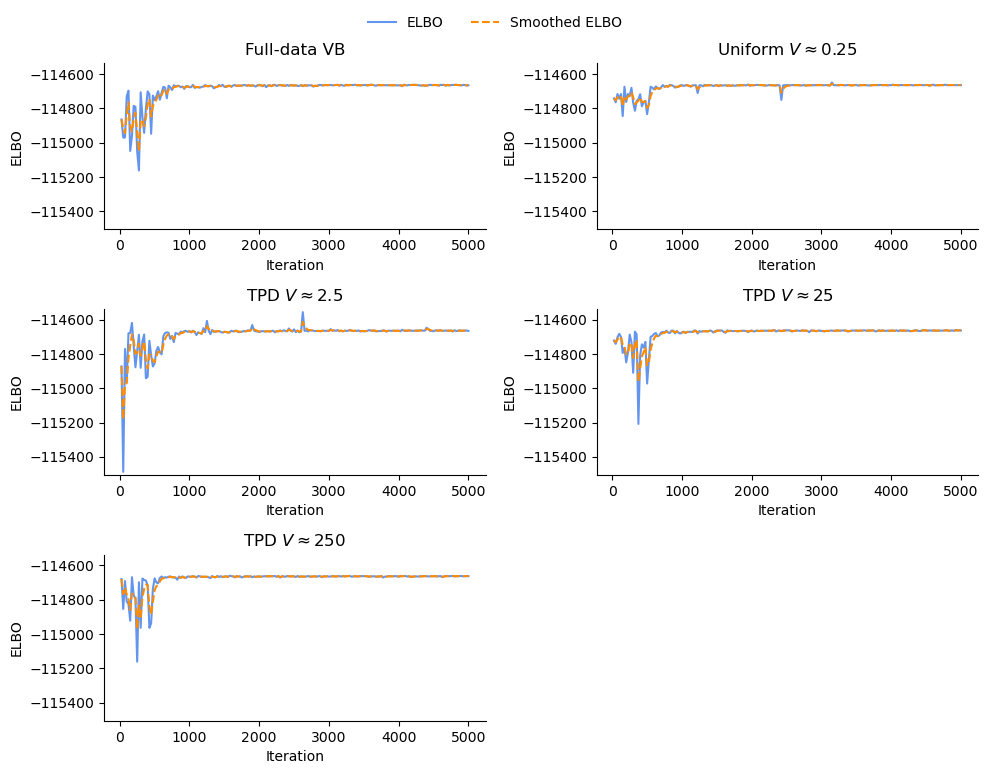

In [26]:
# Figure S1
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()

configs = [
    (r"Full-data VB", result_full_data_VB_median),
    (r"Uniform $V \approx 0.25$", result_uniform_median),
    (r"TPD $V \approx 2.5$", result_Rmax10_median),
    (r"TPD $V \approx 25$", result_Rmax100_median),
    (r"TPD $V \approx 250$", result_Rmax1000_median)
]

# ---- Compute global y-limits ----
y_min, y_max = float("inf"), float("-inf")

for _, result in configs:
    y_min = min(
        y_min,
        result["elbo_history"].min(),
        result["elbo_smooth_history"].min()
    )
    y_max = max(
        y_max,
        result["elbo_history"].max(),
        result["elbo_smooth_history"].max()
    )

# Optional: small padding for aesthetics
pad = 0.02 * (y_max - y_min)
y_min -= pad
y_max += pad

# ---- Plot ----
for ax, (title, result) in zip(axes, configs):

    elbo_iters = result["elbo_iters"]
    elbo_values = result["elbo_history"]
    elbo_values_smoothed = result["elbo_smooth_history"]

    ax.plot(elbo_iters, elbo_values, "-", color="cornflowerblue", label="ELBO")
    ax.plot(elbo_iters, elbo_values_smoothed, "--", color="darkorange", label="Smoothed ELBO")

    ax.set_title(title)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("ELBO")

    # Apply same y-limits everywhere
    ax.set_ylim(y_min, y_max)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# remove the unused panel
fig.delaxes(axes[5])

# single legend for the full figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.97)
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

The quantity $u_{\max}$ over iterations for all methods with full data compute as benchmark (Figure S2 in the supplement). For median ELBO.

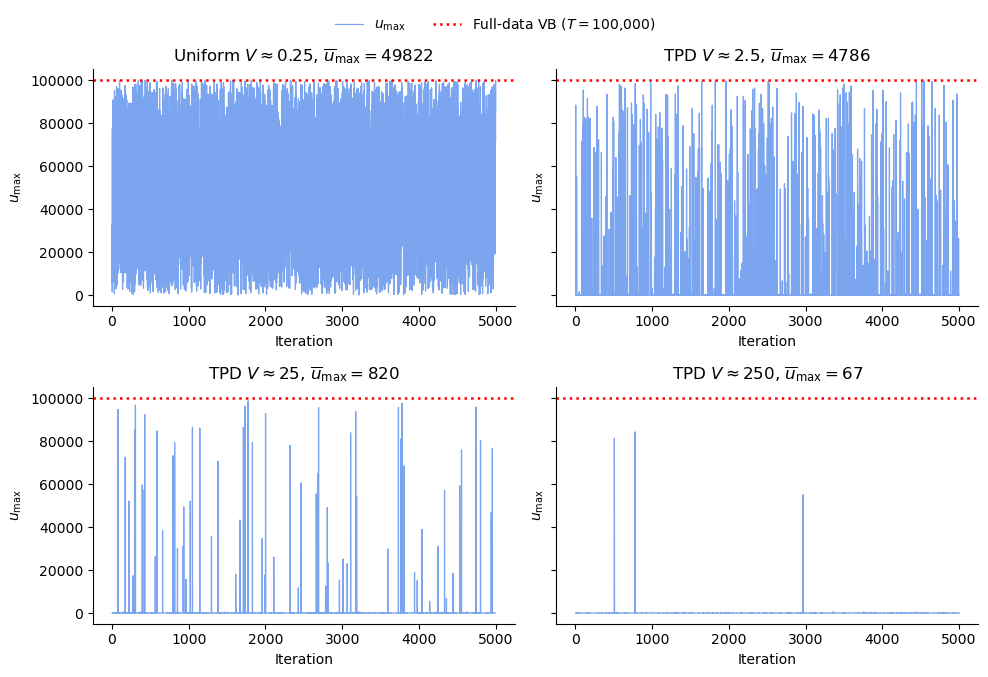

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
axes = axes.flatten()

configs = [
    (r"Uniform $V \approx 0.25$", result_uniform_median),
    (r"TPD $V \approx 2.5$", result_Rmax10_median),
    (r"TPD $V \approx 25$", result_Rmax100_median),
    (r"TPD $V \approx 250$", result_Rmax1000_median)
]

benchmark_umax = 100000

for ax, (title, result) in zip(axes, configs):

    u_max_history = np.asarray(result["u_max"], dtype=float)
    iters = np.arange(1, len(u_max_history) + 1)
    u_max_bar = np.mean(u_max_history)

    ax.plot(
        iters,
        u_max_history,
        "-",
        color="cornflowerblue",
        linewidth=0.9,
        alpha=0.85,
        label=r"$u_{\max}$"
    )

    ax.axhline(
        benchmark_umax,
        color="red",
        linestyle=":",
        linewidth=1.8,
        label=r"Full-data VB ($T = 100{,}000$)"
    )

    ax.set_title(rf"{title}, $\overline{{u}}_{{\max}} = {u_max_bar:.0f}$")
    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$u_{\max}$")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.97)
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### 2.9 Student-t error example

This section estimates the Student-t model to the same data as above. Only one variational approximation is estimated, tuned using the recommendation $R_{\max}=100$.

[pdf_section] Exists, skipping: results/App1_VB/GARCH11/Student-t/01_settings_and_data_plot.pdf
GARCH_type: GARCH , Error distribution: Student-t
Lags: p =,  1 q =  1
Dataset name:  DowJones_GARCH(1,1)_Student-t_error
Number of observations:  100000
Parameters:
Tranformations:
 ['identity', 'log', 'log', 'log', 'log_shift2']
Number of parameters: 5
Prior hyperparameters (v_rate and v_shape only if Student-t)
alpha_scale : 0.2
beta_scale  : 0.8
mu_mean     : 0
mu_sd       : 10
omega_scale : 1
v_rate      : 1
v_shape     : 2


$\mu$, $\omega$, $\alpha_1$, $\beta_1$, $\nu$

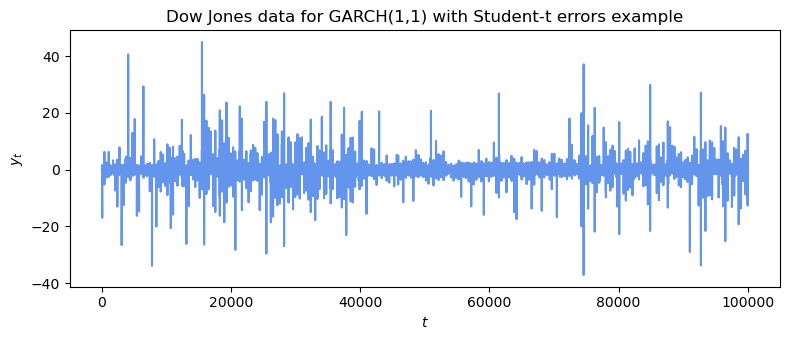

95% Confidence intervals for MLE estimates (phi)
[ 0.   -3.35 -1.91 -0.31  0.67]
[ 0.01 -3.21 -1.79 -0.27  0.76]



95% Credible intervals for posterior (phi)
[ 0.   -3.35 -1.91 -0.31  0.67]
[ 0.01 -3.21 -1.79 -0.27  0.76]





In [28]:
# Define model (change only error_type)
error_type = "Student-t"

# Specify transforms (set all "identity" if no transformation)
dataset_name = "DowJones_%s(%s,%s)_%s_error" % (GARCH_type, p, q, error_type)

param_names, trans_param_names = get_param_names(GARCH_type, error_type, p, q)
names = {"params_name": param_names, "trans_param_names": trans_param_names}    
transforms = ["identity"] + ["log"] + p*["log"] + q*["log"] + ["log_shift2"]

# Likelihood optimisation settings (posterior optimisation always uses L-BFGS-B as it has a better starting value):
likelihood_optim = "L-BFGS-B" # Basinhopping performed for normal error, which is used as starting value. L-BFGS-B enough here 
options_L_BFGS_B = {"gtol":1e-6, "ftol":1e-12, "maxls":50, "maxiter":2000, "disp":True}
options_trust_ncg = {"gtol":1e-6, "maxiter":2000, "disp":True}
options_basinhopping = {"niter":5, "stepsize":0.5, "T":1.0, "disp":True} 

# Prior settings:
# The default settings are
# mu_mean = 0.0, mu_sd = 10.0, omega_scale = 1.0, alpha_scale = 0.2, beta_scale = 0.8, v_shape = 2.0, v_rate = 1.0
# If other setting required, save as dictionary and pass on to the log prior once defined.
# Example:
prior_args = "default"
# prior_args = {"mu_mean":0.0, "mu_sd":100.0, "omega_scale":1.0, "alpha_scale":0.2, "beta_scale":0.8, "v_shape":2.0, "v_rate":1.0}

# Initialise prior. Either with default parameters or as specificed in prior_args
if prior_args == "default":
    log_prior = initiate_priors(GARCH_type, error_type)
    f = {"GARCH": log_prior_GARCH, "TGARCH": log_prior_TGARCH}[GARCH_type]
    prior_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    prior_hyperparams = prior_args
    log_prior = initiate_priors(GARCH_type, error_type, **prior_hyperparams)

# Penalty settings:
penalty_args = "default"

# Inititialise penalties for frequentist estimation
if penalty_args == "default":
    log_penalty = initiate_penalties(GARCH_type, error_type)
    f = {"GARCH": log_penalty_GARCH, "TGARCH": log_penalty_TGARCH}[GARCH_type]
    penalty_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    penalty_hyperparams = penalty_args
    log_penalty = initiate_penalties(GARCH_type, error_type, **penalty_hyperparams)
    
        
# Create model functions based on the inputs above
h, hinv, hinv_p, hinv_pp, jacdiag, logdet = initiate_transformation_functions(transforms)
log_densities, grad_log_densities, Hess_log_densities = initiate_model_functions(GARCH_type, error_type, hinv, hinv_p, hinv_pp)

# Read in data (already done above)
if GARCH_type == 'GARCH':
    n_params = 2 + p + q
elif GARCH_type == 'TGARCH':
    n_params = 2 + 2*p + q
    
if error_type == 'Student-t':
    n_params += 1
assert(len(transforms) == n_params)

# Keep text selectable in the PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
# Latex
mpl.rcParams['text.usetex'] = False 

out_dir = Path("results") / app / model / error_type
out_dir.mkdir(parents=True, exist_ok=True)

with pdf_section("01_settings_and_data_plot", out_dir=out_dir) as active:
    with capture_output(display) as cap:
        print("==============================================================")
        print("GARCH_type:", GARCH_type, ", Error distribution:", error_type)
        print("Lags: p =, ", p, "q = ", q)
        print("Dataset name: ", dataset_name)
        print("Number of observations: ", T)
        print("Parameters:")
        display(Markdown(", ".join(param_names)))
        print("Tranformations:\n", transforms)
        print("Number of parameters:", n_params)
        print("Prior hyperparameters (v_rate and v_shape only if Student-t)")
        print_kv(prior_hyperparams)
        print("==============================================================")

    # Show in notebook
    cap.show()

    # Only write to PDF if active
    if active:
        text = cap.stdout
        pdf_add_text(text, title="Model and settings specified")

    # Measurements
    plt.figure(figsize=(8, 3.5))
    plt.title(f"Dow Jones data for GARCH(1,1) with Student-t errors example")
    plt.plot(y, color="cornflowerblue")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$y_t$")
    plt.tight_layout()

    # Only write figure to PDF if active
    if active:
        pdf_add_fig()

    plt.show()

# Optimise
# Minimise in phi space, so input is unrestricted
def log_penalty_phi(x, p, q):
    return log_penalty(hinv(x), p, q)

def obj_func_likelihood(x):
    """
    Penalised log-likelihood. To enforce the
    """
    return -log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + log_penalty_phi(x, p, q)/T

grad_log_penalty = grad(log_penalty_phi) #(x, p, q)
Hess_log_penalty = hessian(log_penalty_phi)

grad_obj_func_likelihood = lambda x: -grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + grad_log_penalty(x, p, q)/T # Gradient of obj_func_likelihood. Computed by automatic differentiation
Hess_obj_func_likelihood = lambda x: -Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + Hess_log_penalty(x, p, q)/T # Hessian of obj_func_likelihood. Computed by automatic differentiation

optim_dir = out_dir / "optim"
optim_dir.mkdir(parents=True, exist_ok=True)
save_path_optim = optim_dir / "optim_likelihood_result.h5"
log_path_optim = optim_dir / "optim_likelihood_live.log"

# Optimise the log-likelihood
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)


try:
    optim_results = load_dict_h5(save_path_optim)
    MLE = np.array(optim_results['optim_obj']['x'])
    Cov = optim_results['Cov_MLE']
    print('95% Confidence intervals for MLE estimates (phi)')
    print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2))
    print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2))
    print("\n\n")
    
except FileNotFoundError:
    # Optimise the log-likelihood    
    # Use the MAP from the normal case above as starting value
    theta_optim_start = hinv(np.hstack((MAP, np.log(25 - 2)))) # v_0 = 25 
    phi_optim_start = h(theta_optim_start)
    
    start = time.perf_counter()
    it = {"k": 0} # For callback
    fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)

    with live_log_to_file(log_path_optim):

        if likelihood_optim == "trust-ncg":
            print('\n\nLikelihood optimisation settings for method trust-ncg:\n', flush=True)
            options = options_trust_ncg
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                jac=fg.jac, hess=Hess_obj_func_likelihood,
                method="trust-ncg", options=options
            )

        elif likelihood_optim == "L-BFGS-B":
            print('\n\nLikelihood optimisation settings for method L-BFGS-B:\n', flush=True)
            options = options_L_BFGS_B
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                method='L-BFGS-B', jac=fg.jac,
                callback=callback_optim, options=options
            )

        elif likelihood_optim == "basinhopping":
            minimizer_kwargs = {"method": "L-BFGS-B", "jac": fg.jac, "options": options_L_BFGS_B}
            res_optim_likelihood = basinhopping(
                fg.fun, x0=phi_optim_start,
                minimizer_kwargs=minimizer_kwargs,
                callback=callback_optim, **options_basinhopping
            )
        else:
            raise ValueError("Optimisation method does not exist")

        end = time.perf_counter()
        run_time = end - start

        # 

        print("==============================================================", flush=True)
        print("\nLikelihood optimisation took", run_time, "seconds.", flush=True)
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)

        print('MLE estimates (phi)', flush=True)
        MLE = res_optim_likelihood.x
        print(np.round(MLE, 2), flush=True)

        print('hinv(MLE) estimates (theta)', flush=True)
        print(np.round(hinv(MLE), 2), flush=True)

        print('95% Confidence intervals for MLE estimates (phi)', flush=True)
        Cov = np.linalg.inv(Hess_obj_func_likelihood(MLE)) / T
        print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)

        if likelihood_optim == "basinhopping":
            print_minimize_summary(
                res_optim_likelihood["lowest_optimization_result"],
                x_names=trans_param_names, latex=True
            )
        else:
            print_minimize_summary(
                res_optim_likelihood,
                x_names=trans_param_names, latex=True
            )

        print("==============================================================", flush=True)

    with pdf_section("02_optim_likelihood", out_dir=out_dir) as active:
        if active:
            text = log_path_optim.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-likelihood. Summary.")

    optim_results = {
        'optim_obj': pack_optimize_result(res_optim_likelihood),
        'method': likelihood_optim,
        'Cov_MLE': Cov,
        'start_value': phi_optim_start,
        'run_time': run_time
    }

    save_dict_h5(save_path_optim, optim_results)


# Define gradients and Hessian for log-posterior
log_prior_phi = lambda x: log_prior(hinv(x), p, q) + logdet(x) # for autograd
grad_log_prior_phi = grad(log_prior_phi)
grad_log_posterior = lambda x: grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + grad_log_prior_phi(x)
Hess_log_prior_phi = hessian(log_prior_phi)
Hess_log_posterior = lambda x: Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + Hess_log_prior_phi(x)#

obj_func_posterior = lambda x: -log_posterior(x, T, p, q, y, y_start, sigma2_start)[0] # Input is phi
grad_obj_func_posterior = lambda x: -grad_log_posterior(x) 
Hess_obj_func_posterior = lambda x: -Hess_log_posterior(x)

save_path_optim_posterior = optim_dir / "optim_posterior_result.h5"
log_path_optim_posterior = optim_dir / "optim_posterior_live.log"

# Optimise the log-posterior in phi space, so input is unrestricted
phi_optim_start = MLE
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_posterior, grad_obj_func_posterior)

try:    
    optim_posterior_results = load_dict_h5(save_path_optim_posterior)
    MAP = np.array(optim_posterior_results['optim_obj']['x'])
    Cov = optim_posterior_results['Cov']
    print('95% Credible intervals for posterior (phi)', flush=True)
    print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print("\n\n", flush=True)
    
except FileNotFoundError:
    # Optimise the posterior 
    start = time.perf_counter()

    with live_log_to_file(log_path_optim_posterior):

        res_optim_posterior = minimize(
            fg.fun, phi_optim_start,
            method='L-BFGS-B', jac=fg.jac,
            callback=callback_optim,
            options=options_L_BFGS_B
        )

        end = time.perf_counter()
        run_time = end - start

        print("==============================================================", flush=True)

        print("\nPosterior optimisation took", run_time, "seconds.", flush=True)
        print('\n\nPosterior optimisation settings for method L-BFGS-B:\n', flush=True)
        print_kv(options_L_BFGS_B)
        
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)
        # Compare answers
        print('MAP estimates (phi)', flush=True)
        MAP = res_optim_posterior.x
        print(np.round(MAP, 2), flush=True)
        print('hinv(MAP) estimates (theta)', flush=True)
        print(np.round(hinv(MAP), 2), flush=True)

        print('95% Credible intervals (normality assumption on posterior) (phi)', flush=True)
        Hess_MAP = Hess_obj_func_posterior(MAP)
        Cov = np.linalg.inv(Hess_MAP) # Negative Hessian inverse evaluated at the mode  
        if (np.linalg.eigvalsh(Cov) < 0).any():
            print("Cannot compute posterior covariance from Hessian. Trying outer product approximation", flush=True)
            scores = grad_log_densities(hinv(MAP), T, p, q, y, y_start, sigma2_start)
            Cov = np.linalg.inv(scores.T @ scores)
            assert (np.linalg.eigvalsh(Cov) > 0).all(), "Cannot compute posterior covariance."
            adapt_scaling = True
        else:
            adapt_scaling = False
        print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)
        print_minimize_summary(res_optim_posterior, x_names=trans_param_names, latex=True)
        optim_posterior_results = {
            'optim_obj': pack_optimize_result(res_optim_posterior),
            'method': 'L-BFGS-B',
            'Cov': Cov,
            'start_value': phi_optim_start,
            'run_time': run_time
        }
        save_dict_h5(save_path_optim_posterior, optim_posterior_results)
        print("==============================================================", flush=True)

    with pdf_section("03_optim_posterior", out_dir=out_dir) as active:
        if active:
            text = log_path_optim_posterior.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-posterior. Display and summary.")


Markov chain Monte Carlo for the Student-t example.

In [29]:
np.random.seed(SEEDS['App1_full_data_mcmc_Student_t'])
N = n_iter_MCMC # MCMC samples
MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)
save_path_MCMC = MCMC_dir / ("full_data_MCMC_N%s.h5" % N)
log_path_MCMC = MCMC_dir / ("full_data_MCMC_N%s.log" % N)

try:
    MCMC_results = load_dict_h5(save_path_MCMC)
    result_full_data_MCMC_Student_t = MCMC_results['MCMC_obj']
    prop_cov = MCMC_results['prop_cov']
    # Convert back to arrays
    for key in ["samples_phi", "samples_theta"]:
        result_full_data_MCMC_Student_t[key] = np.asarray(result_full_data_MCMC_Student_t[key])

except FileNotFoundError:

    with live_log_to_file(log_path_MCMC):

        # Run MCMC
        Sigma_pi = Cov # Negative Hessian inverse evaluated at the mode
        prop_cov = 2.38**2/n_params*Sigma_pi # For the random walk Negative Hessian inverse evaluated at the mode

        phi_init = MAP 
        print("==============================================================", flush=True)
        result_full_data_MCMC_Student_t = sample_full_data_posterior_AM(
            phi_init, prop_cov, N, names, dataset_name,
            adapt_cov=True, adapt_scale=True, burn_in=1000
        )
        print("==============================================================", flush=True)

        MCMC_results = {'MCMC_obj': result_full_data_MCMC_Student_t, 'prop_cov': prop_cov, 'start_value': phi_init}
        save_dict_h5(save_path_MCMC, MCMC_results)

    with pdf_section("04_full_data_MCMC", out_dir=out_dir) as active:
        if active:
            text = log_path_MCMC.read_text(encoding="utf-8")
            pdf_add_text(text, title="Full data MCMC sampling.")

            plot_traceplots_MCMC(
                result_full_data_MCMC_Student_t['samples_theta'],
                param_true=hinv(MAP), param_names=param_names,
                burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
                suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
            )
            pdf_add_fig()          # saves all figures created by plot_traceplots_MCMC
            plt.close("all")       


Control variates for the Student-t specification. Note that the magnitude of the log-density contributions for extreme observations is substantially smaller than under the Gaussian specification above.

[pdf_section] Exists, skipping: results/App1_VB/GARCH11/Student-t/05_control_variates.pdf


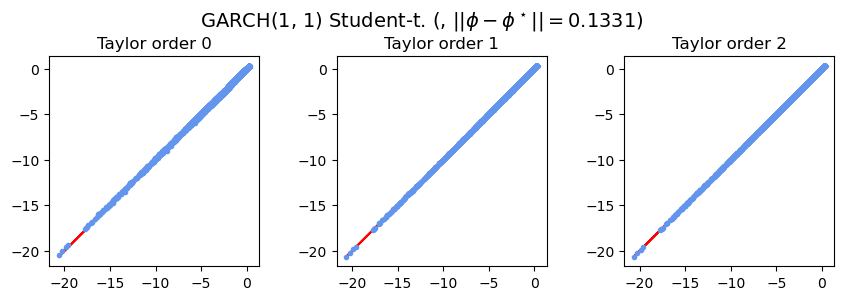

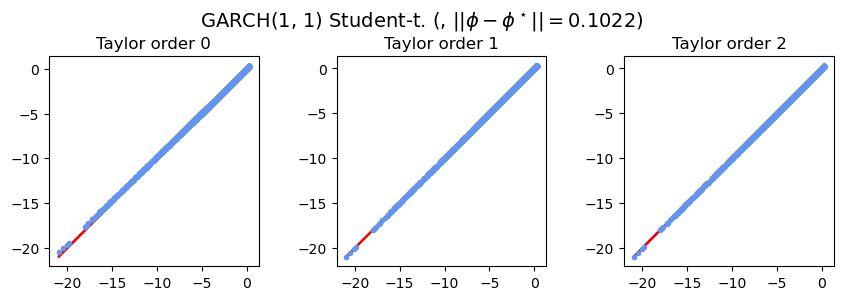

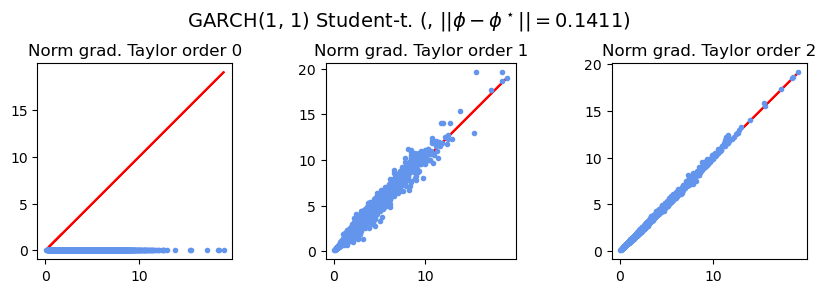

In [30]:
phiStar = MAP
args = (T, p, q, y, y_start, sigma2_start)
control_variate_dir = out_dir / "control_variates"
control_variate_dir.mkdir(parents=True, exist_ok=True)
save_path_control_variates = control_variate_dir / "control_variate_result.h5"
log_path_control_variates = control_variate_dir / "control_variate_live.log"

try:
    control_variates = load_dict_h5(save_path_control_variates)
    dens_at_phiStar = control_variates['dens_at_phiStar']
    grad_at_phiStar = control_variates['grad_at_phiStar'] 
    Hess_at_phiStar = control_variates['Hess_at_phiStar']
    end = control_variates['end']
    start = control_variates['start']
    cpu_CV = end - start

except FileNotFoundError:
    with live_log_to_file(log_path_control_variates):
        start = time.perf_counter()
        dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar = initiate_control_variate_quantities(
            log_densities, grad_log_densities, Hess_log_densities, phiStar, args
        )
        end = time.perf_counter()
        cpu_CV = end - start
        print("==============================================================", flush=True)
        print("Elapsed time control variates initialisation with T = " , T, "p = " , p, "q = " , q,  ":", cpu_CV, "seconds", flush=True)
        print("==============================================================", flush=True)
        control_variates = {
            'dens_at_phiStar': dens_at_phiStar,
            'grad_at_phiStar': grad_at_phiStar,
            'Hess_at_phiStar': Hess_at_phiStar,
            'end': end,
            'start': start
        }
        save_dict_h5(save_path_control_variates, control_variates)

with pdf_section("05_control_variates", out_dir=out_dir) as active:

    if active:
        if log_path_control_variates.exists():
            text = log_path_control_variates.read_text(encoding="utf-8")
        else:
            text = "==============================================================\n" \
                   f"Elapsed time control variates initialisation with T = {T} p = {p} q = {q}: {cpu_CV} seconds\n" \
                   "==============================================================\n"
        pdf_add_text(text, title="Control variate construction.")

    # Precompute quantities for the control variates that do not depend on theta
    A = np.sum(dens_at_phiStar) 
    B = np.sum(grad_at_phiStar, axis = 0)
    C = np.sum(Hess_at_phiStar, axis = 0)
    # sum of control variates evaluated at phi    
    q_sum = lambda phi: A + np.dot(B, phi - phiStar) + 0.5*np.dot(phi - phiStar, np.dot(C, phi - phiStar))

    # Set up control variate quantities to estimate the gradient
    B_grad = np.sum(grad_at_phiStar, axis = 0)
    C_grad = np.sum(Hess_at_phiStar, axis = 0)
    # sum of control variates of the gradient evaluated at phi    
    grad_q_sum = lambda phi: B_grad + np.dot(C_grad, phi - phiStar)

    # Inspect control variate accuracy: log-densities

    # Outside median ellipse in phi space
    Sigma_pi = Cov # np.linalg.inv(Hess_obj_func_posterior(MAP))
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.50, n = 1).flatten()
    phi_beyond_median = phi
    q_k_order0 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    q_k_order1 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    q_k_order2 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    l_k = log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(l_k, l_k, color = 'red')
            if k == 0:
                axs[k].plot(l_k, q_k_order0, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(l_k, q_k_order1, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(l_k, q_k_order2, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)

    # Outside 0.999 ellipse
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.999, n = 1).flatten()
    phi_extreme = phi
    q_k_order0 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    q_k_order1 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    q_k_order2 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    l_k = log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(l_k, l_k, color = 'red')
            if k == 0:
                axs[k].plot(l_k, q_k_order0, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(l_k, q_k_order1, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(l_k, q_k_order2, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)

    # Inspect control variate accuracy: grad of log-densities
    # Outside median ellipse in phi space
    Sigma_pi = Cov # np.linalg.inv(Hess_obj_func_posterior(MAP))
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.50, n = 1).flatten()
    phi_beyond_median = phi
    grad_q_k_order0 = eval_grad_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    grad_q_k_order1 = eval_grad_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    grad_q_k_order2 = eval_grad_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    grad_l_k = grad_log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(np.linalg.norm(grad_l_k, axis = 1), np.linalg.norm(grad_l_k, axis = 1), color = 'red')
            if k == 0:
                axs[k].plot(np.linalg.norm(grad_l_k, axis = 1), np.linalg.norm(grad_q_k_order0, axis = 1), '.', color = 'cornflowerblue')
                axs[k].set_title('Norm grad. Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(np.linalg.norm(grad_l_k, axis = 1), np.linalg.norm(grad_q_k_order1, axis = 1), '.', color = 'cornflowerblue')
                axs[k].set_title('Norm grad. Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(np.linalg.norm(grad_l_k, axis = 1), np.linalg.norm(grad_q_k_order2, axis = 1), '.', color = 'cornflowerblue')
                axs[k].set_title('Norm grad. Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)


Run subsampling variational Bayes with $R_{\max}=100$. Tune the hyperparameters first.

In [31]:
t_star_frac = 0.01
t_star = int(t_star_frac* T)
b = 100.0
R_max_list = [1000, 100, 10, 1]
tuning_dir = out_dir / "tuning"
tuning_dir.mkdir(parents=True, exist_ok=True)

save_path_tuning = tuning_dir / "results_by_Rmax.h5"
log_path_tuning = tuning_dir / "tuning_live.log"

try:
    tuning_cache = load_dict_h5(save_path_tuning)
    results_by_Rmax_raw = tuning_cache["results_by_Rmax"]

    # Convert keys from str -> int
    results_by_Rmax = {int(k): v for k, v in results_by_Rmax_raw.items()}

    start = tuning_cache["start"]
    end = tuning_cache["end"]
    cpu_tuning_total = end - start

    print("==============================================================", flush=True)
    print("Loaded cached tuning results.", flush=True)
    print("Elapsed cached total tuning time:", cpu_tuning_total, "seconds", flush=True)
    print("==============================================================", flush=True)

except FileNotFoundError:
    with live_log_to_file(log_path_tuning):
        start = time.perf_counter()

        results_by_Rmax = run_calibrated_tuning_over_Rmax(
            R_max_list=R_max_list,
            MCMC_results=MCMC_results,
            MAP=MAP,
            phiStar=phiStar,
            dens_at_phiStar=dens_at_phiStar,
            grad_at_phiStar=grad_at_phiStar,
            Hess_at_phiStar=Hess_at_phiStar,
            args=args,
            T=T,
            t_star_frac=t_star_frac,
            b=b,
            m_min=1,
            pilot_slice=slice(1, 100, 5),
            verbose=True,
        )

        end = time.perf_counter()
        cpu_tuning_total = end - start

        print("==============================================================", flush=True)
        print("Elapsed total tuning time:", cpu_tuning_total, "seconds", flush=True)
        for R_max in R_max_list:
            print(
                f"R_max = {R_max}: cpu_tuning_Rmax = "
                f"{results_by_Rmax[R_max]['cpu_tuning_Rmax']:.2f} seconds",
                flush=True
            )
        print("==============================================================", flush=True)

        tuning_cache = {
            "results_by_Rmax": results_by_Rmax,
            "start": start,
            "end": end,
        }

        save_dict_h5(save_path_tuning, tuning_cache)


Loaded cached tuning results.
Elapsed cached total tuning time: 412.4717037980445 seconds


In [32]:
for R_max in R_max_list:
    res = results_by_Rmax[R_max]

    E_umax_opt = expected_umax_safe(res['probs_opt'], res['m_opt'])

    print(
        f"R_max={R_max:>4} | "
        f"c_min={res['c_min']:.4f} | "
        f"V_target={res['V_target']:.6f} | "
        f"c_opt={res['c_opt']:.6f} | "
        f"m_opt={res['m_opt']} | "
        f"E[umax]={E_umax_opt:.4f} | "
        f"var_opt={res['var_opt']:.6f} | "
        f"bind={res['binding_ratio_final']:.6f}"
    )


R_max=1000 | c_min=0.0010 | V_target=13.448800 | c_opt=0.001142 | m_opt=1 | E[umax]=80.2928 | var_opt=13.448800 | bind=1.000000
R_max= 100 | c_min=0.0100 | V_target=1.344880 | c_opt=0.011416 | m_opt=1 | E[umax]=600.7643 | var_opt=1.344880 | bind=1.000000
R_max=  10 | c_min=0.1000 | V_target=0.134488 | c_opt=0.100000 | m_opt=1 | E[umax]=5038.8478 | var_opt=0.118948 | bind=0.884453
R_max=   1 | c_min=1.0000 | V_target=0.013449 | c_opt=1.000000 | m_opt=2 | E[umax]=66667.1667 | var_opt=0.007465 | bind=0.555098


Figure S3, similar to Figure 5, but for the GARCH(1, 1) with a Student-t error.

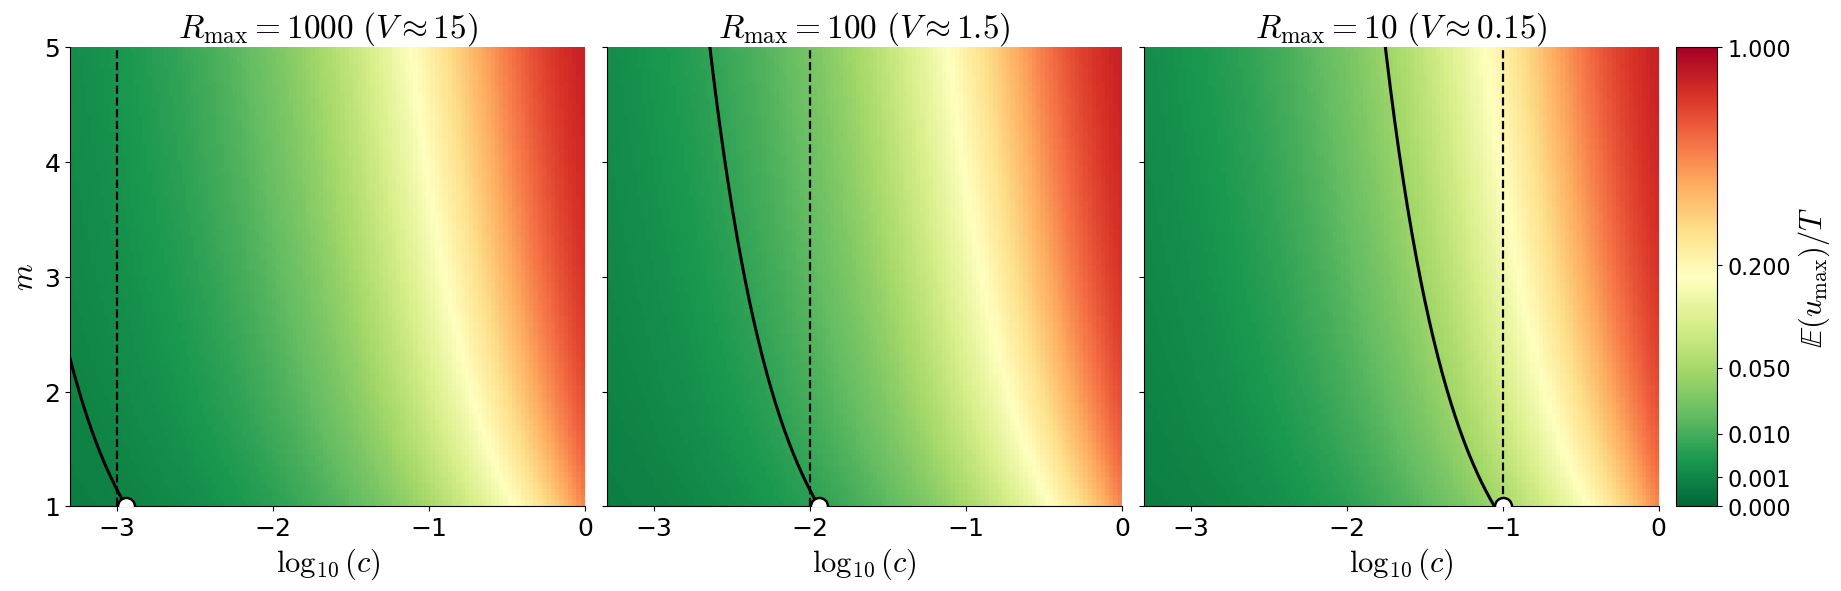

In [33]:
R_max_list = [1000, 100, 10]
V_tolerances_list = [15, 1.5, 0.15]
make_Rmax_triptych_from_results_Figure5(
    T=T,
    t_star=t_star,
    b=b,
    results_by_Rmax=results_by_Rmax,
    R_max_list=R_max_list,
    V_tol_list = V_tolerances_list,
    c_max=1.0,
    n_c=120,
    m_max=5,
    n_m_bg=80,
    power_gamma=0.4,
    vmax=1.0,
    marker_size=150,
    show_cmin_line=True
)

In [34]:
res_tune_Student_t = results_by_Rmax[100]
V_target = float(res_tune_Student_t["V_target"])
c_opt = float(res_tune_Student_t["c_opt"])
m_opt = int(res_tune_Student_t["m_opt"])
gamma_opt = float(res_tune_Student_t["gamma_opt"])
R_max = 100
cpu_tuning_cost_App1_Student_t = results_by_Rmax[100]["cpu_tuning_Rmax"]


# -----------------------------
# Settings
# -----------------------------
base_seed = SEEDS['vb_Student_t']

VB_dir = out_dir / "VB"
VB_dir.mkdir(parents=True, exist_ok=True)

log_path_VB = VB_dir / ("subsampling_R_max100_Student-t_n_iter%s_live.log" % n_iter_read)

section_name = "06_subsampling_VB_R_max100_elbos_Student-t"

with live_log_to_file(log_path_VB):

    # -----------------------------
    # Deterministic seed (single run)
    # -----------------------------
    np.random.seed(base_seed)

    print("Running subsampling VB (Student-t) for", dataset_name, "targeting an R_max = 100", flush=True)

    # Cached result path (single run)
    save_path_VB = VB_dir / ("subsampling_VB_R_max100_Student-t_n_iter%s.h5" % n_iter_read)

    # -----------------------------
    # Load or run
    # -----------------------------
    try:
        subsampling_VB_results = load_dict_h5(save_path_VB)
        assert n_iter_read == subsampling_VB_results['VB_config']['n_iter'], "n_iter in settings differ."

        print("==============================================================", flush=True)
        print("WARNING: Loading cached results from disk.", flush=True)
        print("If configuration or code has changed, delete files and rerun.", flush=True)
        print(f"File: {save_path_VB}", flush=True)
        print("==============================================================", flush=True)

        result_subsampling_VB_rank1iso_Student_t = subsampling_VB_results['VB_obj']
        vb_subsampling_config = subsampling_VB_results['VB_config']
        estimator_params = subsampling_VB_results['estimator_params']
        lam_init = subsampling_VB_results['lam_init']

        # Convert back to arrays
        for key in ["lam_history", "m_history", "var_history", "elbo_history", "elbo_smooth_history",
                    "elbo_iters", "u_max", "m", "L"]:
            result_subsampling_VB_rank1iso_Student_t[key] = np.asarray(
                result_subsampling_VB_rank1iso_Student_t[key]
            )

        # Read ELBO diagnostics
        print("==============================================================", flush=True)
        print("Reading in file with the following ELBO diagnostics", flush=True)
        elbo_final_estimate = subsampling_VB_results['elbo_final_estimate']
        elbo_hat, rej, (lo, hi), details = (
            elbo_final_estimate['elbo_hat'],
            elbo_final_estimate['rej'],
            elbo_final_estimate['conf_init'],
            elbo_final_estimate['details'],
        )
        print(f"V = 100: ELBO={elbo_hat:.2f}  95% CI [{lo:.2f}, {hi:.2f}]  rej={100*rej:.1f}%  n={details['n_valid']}/{details['n_attempts']}", flush=True)
        print("==============================================================", flush=True)

    except FileNotFoundError:
        # Same initial value for optimisation across all methods
        lam_init = init_rank1iso_from_laplace_diag(MAP, Sigma_pi, kappa=2.0, c_cap=2.0)

        # Base optimisation configuration for rank1+iso VBILL
        vb_subsampling_config = dict(
            # Iterations
            n_iter=n_iter_VB,

            # Monte Carlo
            S_grad=1,
            S_elbo=5,

            # Warmup (Euclidean before natural gradient)
            warmup_iters=warmup_iters_VB,
            euclid_step_size=0.002,

            # Natural-gradient schedule
            nat_step_size=0.01,
            nat_decay=0.60,
            nat_offset=200.0,

            # Fisher ridge schedule
            fisher_ridge_init=1e-1,
            fisher_ridge=1e-4,
            fisher_ridge_tau=50.0,

            # Trust region
            trust_delta=0.01,

            # Variational stability
            Sigma_lap=Sigma_pi,
            kappa_c_floor=1e-3,
            min_abs_c_floor=1e-12,
            c_cap=2.0,

            # Hard rejection
            phi_cap=25.0,
            max_draw_attempts=50,

            # Monitoring
            eval_every=25,
            elbo_ema_alpha=0.5,
            elbo_tol_rel=1e-6,
            consecutive_required=8,
            param_avg_window=500,
            stop_on_convergence=False,

            verbose=True,
            print_every=25,

            # ELBO gating
            elbo_drop_abs=1.5e5,
            elbo_drop_rel=1.0,

            # Debug
            check_every_draw_grad=False,
        )

        # Tuning parameters of estimator based on R_max = 100.
        estimator_params = {
            "m_opt": m_opt,
            "c_opt": c_opt,
            "gamma_opt": gamma_opt,
            "t_star": t_star,
            "b": b,
            "V_tolerance": V_target,
            "R_max": R_max,
        }

        # Run subsampling VB
        print("==============================================================", flush=True)
        result_subsampling_VB_rank1iso_Student_t = estimate_subsampling_vb_rank1iso_natgrad(
            estimator_params=estimator_params,
            lam_init=lam_init,
            d=n_params,
            names=names,
            dataset_name=dataset_name,
            **vb_subsampling_config,
        )
        print("==============================================================", flush=True)

        # Final ELBO estimate (full data, S_elbo_target MC samples)
        print(f"Estimating ELBO at final iteration using full data and {S_elbo_target} MC samples", flush=True)
        lam_final = result_subsampling_VB_rank1iso_Student_t['lam']
        elbo_hat, rej, (lo, hi), details = elbo_estimate_final(
            lam_final, n_params, S_elbo_target = S_elbo_target, return_details=True
        )
        elbo_final_estimate = {'elbo_hat': elbo_hat, 'rej': rej, 'conf_init': (lo, hi), 'details': details}
        print(f"R_max = 100: ELBO={elbo_hat:.2f}  95% CI [{lo:.2f}, {hi:.2f}]  rej={100*rej:.1f}%  n={details['n_valid']}/{details['n_attempts']}", flush=True)

        subsampling_VB_results = {
            'VB_obj': result_subsampling_VB_rank1iso_Student_t,
            'estimator_params': estimator_params,
            'lam_init': lam_init,
            'VB_config': vb_subsampling_config,
            'elbo_final_estimate': elbo_final_estimate,
        }
        save_dict_h5(save_path_VB, subsampling_VB_results)

    # -----------------------------
    # Plotting into its own PDF (skips if already exists)
    # -----------------------------
    with pdf_section(section_name, out_dir=out_dir, suffix=None, overwrite=False) as active_fig:
        if active_fig:
            elbo_iters  = result_subsampling_VB_rank1iso_Student_t["elbo_iters"]
            elbo_values = result_subsampling_VB_rank1iso_Student_t['elbo_history']
            elbo_values_smoothed = result_subsampling_VB_rank1iso_Student_t["elbo_smooth_history"]

            pdf_add_text("Student-t (single run)", title="Subsampling VB (V=10) figures")

            plt.figure(figsize=(6, 4))
            plt.plot(elbo_iters, elbo_values, "o-", label="ELBO")
            plt.plot(elbo_iters, elbo_values_smoothed, "-.", label="smoothed ELBO")
            plt.title("ELBO VB")
            plt.xlabel("Iteration")
            plt.ylabel("ELBO")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            pdf_add_fig()
            plt.close()

            plot_rank1iso_from_lam_history(
                result_subsampling_VB_rank1iso_Student_t['lam_history'],
                n_params,
                label="Student-t, R_max = 100",
            )
            pdf_add_fig()
            plt.close()

    plt.close("all")

# -----------------------------
# Convenience scalars (no “best-of” since single run)
# -----------------------------
elbo_Student_t_R_max100 = elbo_hat
se_elbo_Student_t_R_max100 = details['se']

cpu_Student_t_R_max100 = result_subsampling_VB_rank1iso_Student_t['run_time_full'] + cpu_CV + cpu_tuning_cost_App1_Student_t  # cpu_CV is CV construction overhead, other for tuning

work_grad_elbo = np.sum((result_subsampling_VB_rank1iso_Student_t['u_max'] + 1) * vb_subsampling_config['S_grad'])
monitor_mask = (np.arange(vb_subsampling_config['n_iter']) + 1) % vb_subsampling_config['eval_every'] == 0
work_elbo = np.sum((result_subsampling_VB_rank1iso_Student_t['u_max'][monitor_mask] + 1) * vb_subsampling_config['S_elbo'])
work_tuning = 100 * T
total_compute_Student_t_R_max100 = work_grad_elbo + work_elbo + work_tuning


Running subsampling VB (Student-t) for DowJones_GARCH(1,1)_Student-t_error targeting an R_max = 100
If configuration or code has changed, delete files and rerun.
File: results/App1_VB/GARCH11/Student-t/VB/subsampling_VB_R_max100_Student-t_n_iter5000.h5
Reading in file with the following ELBO diagnostics
V = 100: ELBO=-78337.54  95% CI [-78337.90, -78337.18]  rej=0.0%  n=100/100
[pdf_section] Exists, skipping: results/App1_VB/GARCH11/Student-t/06_subsampling_VB_R_max100_elbos_Student-t.pdf


Report CPU time full-data MCMC and the subsampling variational Bayes approach.

In [35]:
print("Full-data MCMC CPU (seconds) = ", result_full_data_MCMC_Student_t["run_time"])
print("Subsampling VB CPU (seconds) = ", cpu_Student_t_R_max100)

Full-data MCMC CPU (seconds) =  31588.585740327835
Subsampling VB CPU (seconds) =  562.5234448669071


Plot ELBO vs iteration for the variational approximation to the Student-t extended model and also $u_{\max}$ (Figure S4 in the supplement).

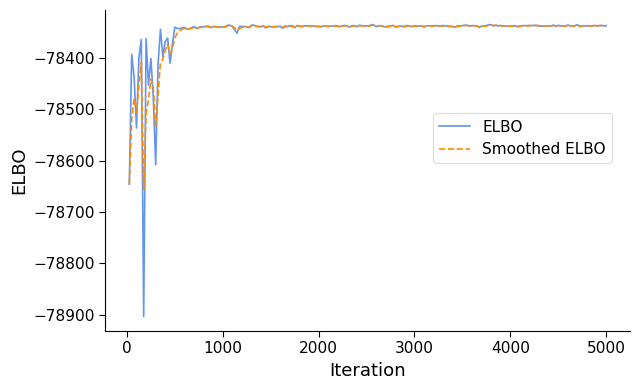

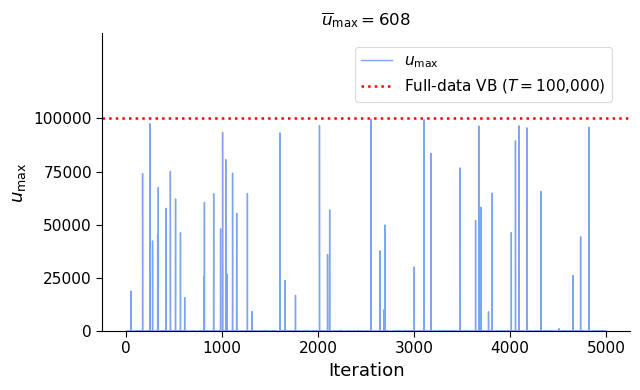

In [36]:
fig, ax = plt.subplots(figsize=(6.5, 4))

elbo_iters = result_subsampling_VB_rank1iso_Student_t["elbo_iters"]
elbo_values = result_subsampling_VB_rank1iso_Student_t["elbo_history"]
elbo_values_smoothed = result_subsampling_VB_rank1iso_Student_t["elbo_smooth_history"]

ax.plot(elbo_iters, elbo_values, "-", label="ELBO", color="cornflowerblue", linewidth=1.2)
ax.plot(elbo_iters, elbo_values_smoothed, "--", color="darkorange", label="Smoothed ELBO", linewidth=1.2)

ax.set_xlabel("Iteration", fontsize=13)
ax.set_ylabel("ELBO", fontsize=13)

ax.tick_params(axis="both", labelsize=11, direction="out", length=4, width=0.8)

# Move legend more toward the middle-right
legend = ax.legend(
    loc="center right",
    bbox_to_anchor=(0.98, 0.60),
    frameon=True,
    fontsize=11
)
legend.get_frame().set_edgecolor("lightgray")
legend.get_frame().set_linewidth(0.8)

# Remove the top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(6.5, 4))

u_max_history = np.asarray(result_subsampling_VB_rank1iso_Student_t["u_max"], dtype=float)
iters = np.arange(1, len(u_max_history) + 1)
u_max_bar = np.mean(u_max_history)

benchmark_umax = 100000

ax.plot(
    iters,
    u_max_history,
    "-",
    color="cornflowerblue",
    linewidth=1.0,
    alpha=0.85,
    label=r"$u_{\max}$"
)

ax.axhline(
    benchmark_umax,
    color="red",
    linestyle=":",
    linewidth=1.8,
    label=r"Full-data VB ($T = 100{,}000$)"
)

ax.set_title(rf"$\overline{{u}}_{{\max}} = {u_max_bar:.0f}$", fontsize=12)
ax.set_xlabel("Iteration", fontsize=13)
ax.set_ylabel(r"$u_{\max}$", fontsize=13)

ax.tick_params(axis="both", labelsize=11, direction="out", length=4, width=0.8)

# Add headroom above the red benchmark line
y_min = np.min(u_max_history)
y_max = max(np.max(u_max_history), benchmark_umax)
pad = 0.40 * (y_max - y_min)
ax.set_ylim(y_min, y_max + pad)
ax.set_yticks([0, 25000, 50000, 75000, 100000])

# Move legend further up
legend = ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    frameon=True,
    fontsize=11
)

legend.get_frame().set_edgecolor("lightgray")
legend.get_frame().set_linewidth(0.8)

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Plot kernel density estimates of variational approximation vs full-data MCMC (Figure S5 in the supplement).

[pdf_section] Exists, skipping: results/App1_VB/GARCH11/Student-t/09_kde.pdf
pdf_section active_fig = False


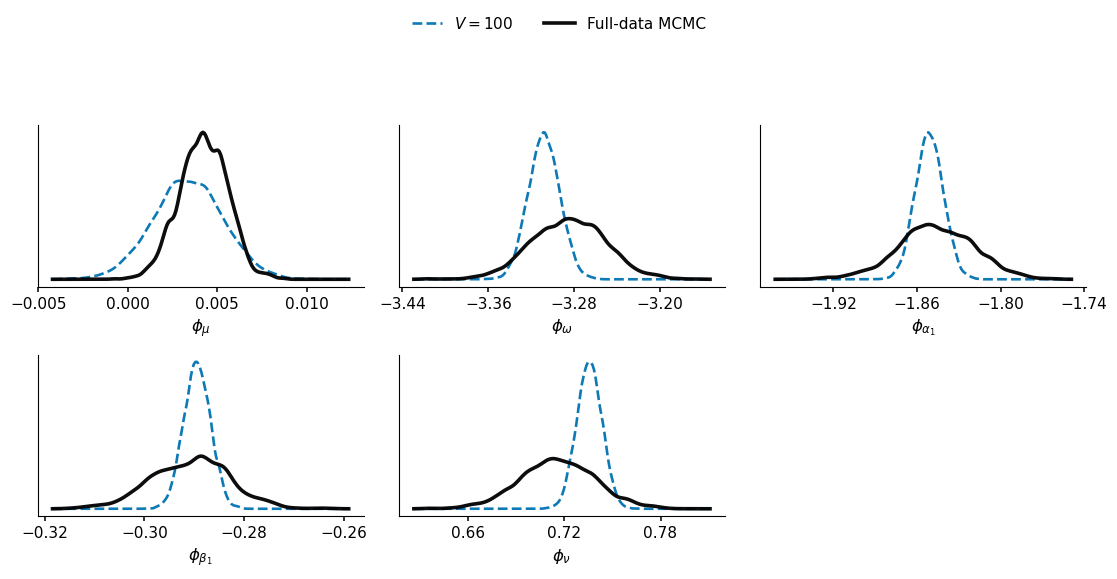

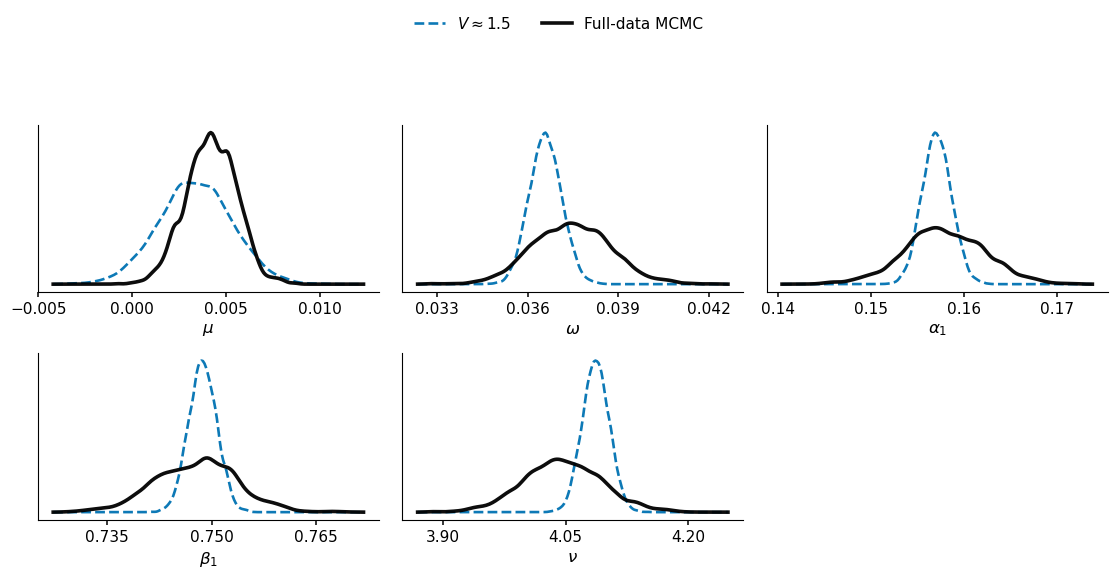

In [37]:
# KDE vs full data MCMC
np.random.seed(SEEDS['vb_kdes_Student_t'])
# Plot VB posterior accuracies
N = 10000
post_mean_subsampling_VB_rank1iso_1MC_grad_tol_var100_Student_t = result_subsampling_VB_rank1iso_Student_t['m'] 
post_cov_subsampling_VB_rank1iso_1MC_grad_tol_var100_Student_t = np.dot(result_subsampling_VB_rank1iso_Student_t['L'], result_subsampling_VB_rank1iso_Student_t['L'].T)

samples_phi_subsampling_VB_rank1iso_1MC_grad_tol_var100_Student_t = np.random.multivariate_normal(post_mean_subsampling_VB_rank1iso_1MC_grad_tol_var100_Student_t, post_cov_subsampling_VB_rank1iso_1MC_grad_tol_var100_Student_t, size = N)
samples_theta_subsampling_VB_rank1iso_1MC_grad_tol_var100_Student_t = np.array([hinv(item) for item in samples_phi_subsampling_VB_rank1iso_1MC_grad_tol_var100_Student_t])

trans_param_names_temp =  [r"$\phi_{\mu}$", r"$\phi_{\omega}$"] + \
                    [r"$\phi_{\alpha_%s}$" % item for item in range(1, p + 1)] + \
                    [r"$\phi_{\beta_%s}$" % item for item in range(1, q + 1)] + [r"$\phi_{\nu}$"]

burn_in =  2000

log_path_kde = VB_dir / ("kde_best_runs_live.log")

with live_log_to_file(log_path_kde):
    with pdf_section("09_kde", out_dir=out_dir) as active_fig:

        print("pdf_section active_fig =", bool(active_fig), flush=True)


        # -------- Phi space --------
        plot_kde_comparison(
            samples_phi_subsampling_VB_rank1iso_1MC_grad_tol_var100_Student_t,
            result_full_data_MCMC_Student_t['samples_phi'][burn_in:, :],
            param_names=trans_param_names_temp,
            title="Posterior marginals (phi): VB algs vs MCMC",
            n_points=200,
            true_vals=None,
            labels=(r"$V = 100$", "Full-data MCMC")
        )
        if active_fig:
            pdf_add_fig()
        plt.show()
        plt.close("all")

        # -------- Theta space --------
        plot_kde_comparison(
            samples_theta_subsampling_VB_rank1iso_1MC_grad_tol_var100_Student_t,
            result_full_data_MCMC_Student_t['samples_theta'][burn_in:, :],
            param_names=param_names,
            title="Posterior marginals (theta): VB algs vs MCMC",
            n_points=200,
            true_vals=None,
            labels=(r"$V \approx 1.5$", "Full-data MCMC")
        )
        if active_fig:
            pdf_add_fig()
        plt.show()
        plt.close("all")




### 2.10 Other figures

This section creates other figures for Application 1 that are included in the main paper.

Dow Jones data (Figure 4 in the paper).

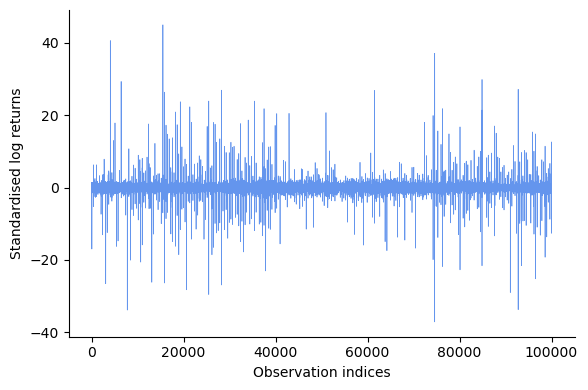

In [38]:
####################
# DJ 30 data figure
####################
# Load data
log_returns = np.load("data/DowJones_100010obs.npy")

# Last 100000 and normalise std 1
series = log_returns[-100000:]
series = series / np.std(series, ddof=1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(series, linewidth=0.5, color = "cornflowerblue")

ax.set_xlabel("Observation indices")
ax.set_ylabel("Standardised log returns")

# Remove the top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

## 3. Application in the supplement: Subsampling Markov chain Monte Carlo
This section contains the code for the subsampling Markov chain Monte Carlo application presented in the supplement of the paper. The code estimates the models and produces the corresponding figures and tables.

This empirical application fits several GARCH specifications, including threshold extensions to the Apple Inc (AAPL) stock data. The posterior distribution of the parameters are then used to evaluate which model is the best by computing its log-predictive score (averaged over the subsampling posterior) on out-of-sample test data. 

The following models are estimated and evaluated:

- GARCH(1, 1) with normal errors
- GARCH(1, 1) with Student-t errors
- TGARCH(1, 1) with Student-t errors
- TGARCH(1, 2) with Student-t errors.

The AAPL data has substantial persistence and it is therefore hard to construct Metropolis-Hastings proposals on $\boldsymbol{\phi}$-space (proposes often outside the stationary region). Thus, the proposal distribution is defined on an unrestricted $\boldsymbol{\psi}$-space, which maps to a region where the model parameters always obey stationarity; see Section S3.4 for details.

In addition to the above, the application addresses the limitation of uniform sampling in the tuning regime; see Section S3.6 in the paper. This is done for the GARCH(1, 1) with Student-t errors example.

Below is a plot of the training and test data for AAPL (Figure S6 in the supplement of the paper).

110010


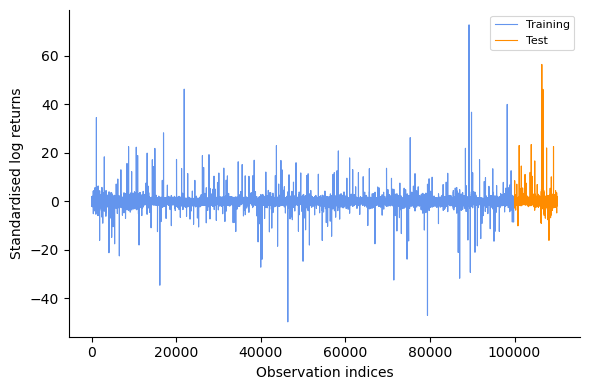

In [39]:
####################
# AAPL data
####################
train_AAPL = np.load("data/AAPL_100010obs.npy")
test_AAPL = np.load("data/AAPL_10000obs.npy")

AAPL_data = np.hstack((train_AAPL, test_AAPL))
print(len(AAPL_data))
assert(len(AAPL_data) == 110010)

burn = 10
train_size = 100000
test_size = 10000

y_data = AAPL_data/np.std(AAPL_data) 

# remove burn-in
y_plot = y_data[burn:]
x = np.arange(len(y_plot))

fig, ax = plt.subplots(figsize=(6, 4))

# Training data
ax.plot(x[:train_size],
        y_plot[:train_size],
        color="cornflowerblue",
        linewidth=0.8,
        label="Training")

# Test data
ax.plot(x[train_size:],
        y_plot[train_size:],
        color="darkorange",
        linewidth=0.8,
        label="Test")

# Axis labels
ax.set_xlabel("Observation indices")
ax.set_ylabel("Standardised log returns")

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
legend = ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="0.8",
    fontsize=8
)
legend.get_frame().set_linewidth(0.8)
plt.tight_layout()

### 3.1 GARCH(1,1) with normal errors

Define settings and optimise.

[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/normal/01_settings_and_data_plot.pdf
GARCH_type: GARCH , Error distribution: normal
Lags: p =,  1 q =  1
Dataset name:  AAPL_GARCH(1,1)_normal_error
Number of observations:  100000
Parameters:
Tranformations:
 ['identity', 'log', 'log', 'log']
Number of parameters: 4
Prior hyperparameters (v_rate and v_shape only if Student-t)
alpha_scale : 0.2
beta_scale  : 0.8
mu_mean     : 0
mu_sd       : 10
omega_scale : 1
v_rate      : 1
v_shape     : 2


$\mu$, $\omega$, $\alpha_1$, $\beta_1$

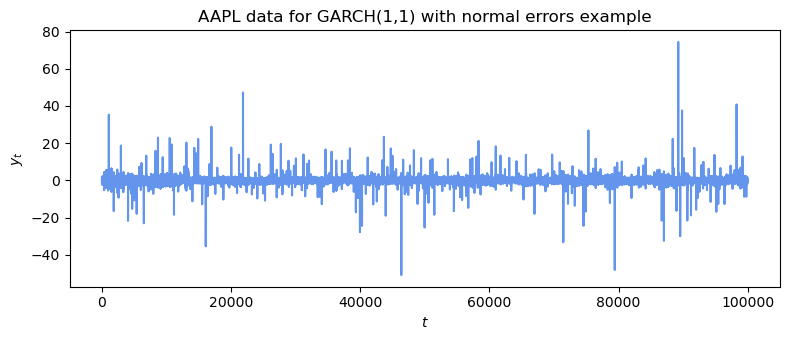

95% Confidence intervals for MLE estimates (phi)
[-0.01 -2.68 -1.94 -0.19]
[ 0.   -2.63 -1.89 -0.18]



95% Credible intervals for posterior (phi)
[-0.01 -2.73 -1.97 -0.19]
[ 0.   -2.57 -1.86 -0.17]





In [40]:
app = "App2_MCMC" # To create folders
model = "GARCH11" # To create folders

GARCH_type = "GARCH"
error_type = "normal"

T = 100000 # Length of time series
p = 1 # Nbr of autoregressive y-lags in the GARCH-type variance process
q = 1 # Nbr of autoregressive sigma2-lags in the GARCH-type variance process
# Specify transforms (set all "identity" if no transformation)
dataset_name = "AAPL_%s(%s,%s)_%s_error" % (GARCH_type, p, q, error_type)

param_names, trans_param_names = get_param_names(GARCH_type, error_type, p, q)
names = {"params_name": param_names, "trans_param_names": trans_param_names}    
transforms = ["identity"] + ["log"] + p*["log"] + q*["log"]

# Likelihood optimisation settings (posterior optimisation always uses L-BFGS-B as it has a better starting value):
likelihood_optim = "basinhopping" 
options_L_BFGS_B = {"gtol":1e-6, "ftol":1e-12, "maxls":50, "maxiter":2000, "disp":True}
options_trust_ncg = {"gtol":1e-6, "maxiter":2000, "disp":True}
options_basinhopping = {"niter":5, "stepsize":0.5, "T":1.0, "disp":True}

# Prior settings:
# The default settings are
# mu_mean = 0.0, mu_sd = 10.0, omega_scale = 1.0, alpha_scale = 0.2, beta_scale = 0.8, v_shape = 2.0, v_rate = 1.0
# If other setting required, save as dictionary and pass on to the log prior once defined.
# Example:
prior_args = "default"
# prior_args = {"mu_mean":0.0, "mu_sd":100.0, "omega_scale":1.0, "alpha_scale":0.2, "beta_scale":0.8, "v_shape":2.0, "v_rate":1.0}

# Initialise prior. Either with default parameters or as specificed in prior_args
if prior_args == "default":
    log_prior = initiate_priors(GARCH_type, error_type)
    f = {"GARCH": log_prior_GARCH, "TGARCH": log_prior_TGARCH}[GARCH_type]
    prior_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    prior_hyperparams = prior_args
    log_prior = initiate_priors(GARCH_type, error_type, **prior_hyperparams)

# Penalty settings:
penalty_args = "default"

# Inititialise penalties for frequentist estimation
if penalty_args == "default":
    log_penalty = initiate_penalties(GARCH_type, error_type)
    f = {"GARCH": log_penalty_GARCH, "TGARCH": log_penalty_TGARCH}[GARCH_type]
    penalty_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    penalty_hyperparams = penalty_args
    log_penalty = initiate_penalties(GARCH_type, error_type, **penalty_hyperparams)
    
        
# Create model functions based on the inputs above
h, hinv, hinv_p, hinv_pp, jacdiag, logdet = initiate_transformation_functions(transforms)
log_densities, grad_log_densities, Hess_log_densities = initiate_model_functions(GARCH_type, error_type, hinv, hinv_p, hinv_pp)


# Functions to reparameterise the proposal density to a space where the GARCH/TGARCH process is stationary
theta_to_psi, psi_to_theta, logabsdet_dpsi_dtheta = initiate_persistence_reparam_functions(GARCH_type=GARCH_type, error_type=error_type, p=p, q=q, h=h,
                                                                                           hinv=hinv, jacdiag=jacdiag, param_names=param_names, delta=1e-4)


# Read in data
# Dow Jones example  
log_returns = np.load("data/AAPL_100010obs.npy") # Data created as np.diff(np.log(data)).
series = log_returns[-(T + p):]
y = series / series.std() # std 1 normalisation.
y_start = y[:p][::-1]
y = y[-T:]
sigma2_start = np.array([1, 1, 1, 1])[-q:]
# End read data

theta0 = None # True values not available for real data
phi0 = None
if GARCH_type == 'GARCH':
    n_params = 2 + p + q
elif GARCH_type == 'TGARCH':
    n_params = 2 + 2*p + q
    
if error_type == 'Student-t':
    n_params += 1
assert(len(transforms) == n_params)

# Keep text selectable in the PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
# Latex
mpl.rcParams['text.usetex'] = False 

out_dir = Path("results") / app / model / error_type
out_dir.mkdir(parents=True, exist_ok=True)

with pdf_section("01_settings_and_data_plot", out_dir=out_dir) as active:
    with capture_output(display) as cap:
        print("==============================================================")
        print("GARCH_type:", GARCH_type, ", Error distribution:", error_type)
        print("Lags: p =, ", p, "q = ", q)
        print("Dataset name: ", dataset_name)
        print("Number of observations: ", T)
        print("Parameters:")
        display(Markdown(", ".join(param_names)))
        print("Tranformations:\n", transforms)
        print("Number of parameters:", n_params)
        print("Prior hyperparameters (v_rate and v_shape only if Student-t)")
        print_kv(prior_hyperparams)
        print("==============================================================")

    # Show in notebook
    cap.show()

    # Only write to PDF if active
    if active:
        text = cap.stdout
        pdf_add_text(text, title="Model and settings specified")

    # Measurements
    plt.figure(figsize=(8, 3.5))
    plt.title(f"AAPL data for {GARCH_type}({p},{q}) with {error_type} errors example")
    plt.plot(y, color="cornflowerblue")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$y_t$")
    plt.tight_layout()

    # Only write figure to PDF if active
    if active:
        pdf_add_fig()

    plt.show()

# Optimise likelihood
# Minimise in phi space, so input is unrestricted
def log_penalty_phi(x, p, q):
    return log_penalty(hinv(x), p, q)

def obj_func_likelihood(x):
    """
    Penalised log-likelihood. To enforce the
    """
    return -log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + log_penalty_phi(x, p, q)# /T

grad_log_penalty = grad(log_penalty_phi) #(x, p, q)
Hess_log_penalty = hessian(log_penalty_phi)

grad_obj_func_likelihood = lambda x: -grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + grad_log_penalty(x, p, q) #/T # Gradient of obj_func_likelihood. Computed by automatic differentiation
Hess_obj_func_likelihood = lambda x: -Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + Hess_log_penalty(x, p, q) #/T # Hessian of obj_func_likelihood. Computed by automatic differentiation

optim_dir = out_dir / "optim"
optim_dir.mkdir(parents=True, exist_ok=True)
save_path_optim = optim_dir / "optim_likelihood_result.h5"
log_path_optim = optim_dir / "optim_likelihood_live.log"

# Optimise the log-likelihood
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)


try:
    optim_results = load_dict_h5(save_path_optim)
    MLE = np.array(optim_results['optim_obj']['x'])
    Cov = optim_results['Cov_MLE']
    print('95% Confidence intervals for MLE estimates (phi)')
    print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2))
    print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2))
    print("\n\n")
    
except FileNotFoundError:
    # Optimise the log-likelihood
    mu_0 = np.mean(y)
    alpha_0 = np.array([0.1, 0.05, 0.05])[:p]    
    assert(len(alpha_0) == p)
    gamma_0 = np.array([0.03, 0.1, 0.03])[:p]
    assert(len(alpha_0) == p)
    beta_0 = np.array([0.2, 0.1])[:q]
    assert(len(beta_0) == q)
    omega_0 = np.var(y)
    assert(omega_0 >= 0)
    if error_type == "Student-t": 
        v_0 = 15
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0, v_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0, v_0)).flatten()  
            print(theta_optim_start)
    else: # normal error
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0)).flatten()

    phi_optim_start = h(theta_optim_start)
    
    start = time.perf_counter()
    it = {"k": 0} # For callback
    fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)

    with live_log_to_file(log_path_optim):

        if likelihood_optim == "trust-ncg":
            print('\n\nLikelihood optimisation settings for method trust-ncg:\n', flush=True)
            options = options_trust_ncg
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                jac=fg.jac, hess=Hess_obj_func_likelihood,
                method="trust-ncg", options=options
            )

        elif likelihood_optim == "L-BFGS-B":
            print('\n\nLikelihood optimisation settings for method L-BFGS-B:\n', flush=True)
            options = options_L_BFGS_B
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                method='L-BFGS-B', jac=fg.jac,
                callback=callback_optim, options=options
            )

        elif likelihood_optim == "basinhopping":
            minimizer_kwargs = {"method": "L-BFGS-B", "jac": fg.jac, "options": options_L_BFGS_B}
            res_optim_likelihood = basinhopping(
                fg.fun, x0=phi_optim_start,
                minimizer_kwargs=minimizer_kwargs,
                callback=callback_optim, **options_basinhopping
            )
        else:
            raise ValueError("Optimisation method does not exist")

        end = time.perf_counter()
        run_time = end - start

        # 

        print("==============================================================", flush=True)
        print("\nLikelihood optimisation took", run_time, "seconds.", flush=True)
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)

        print('MLE estimates (phi)', flush=True)
        MLE = res_optim_likelihood.x
        print(np.round(MLE, 2), flush=True)

        print('hinv(MLE) estimates (theta)', flush=True)
        print(np.round(hinv(MLE), 2), flush=True)

        print('95% Confidence intervals for MLE estimates (phi)', flush=True)
        Cov = np.linalg.inv(Hess_obj_func_likelihood(MLE)) / T
        print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)

        if likelihood_optim == "basinhopping":
            print_minimize_summary(
                res_optim_likelihood["lowest_optimization_result"],
                x_names=trans_param_names, latex=True
            )
        else:
            print_minimize_summary(
                res_optim_likelihood,
                x_names=trans_param_names, latex=True
            )

        print("==============================================================", flush=True)

    with pdf_section("02_optim_likelihood", out_dir=out_dir) as active:
        if active:
            text = log_path_optim.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-likelihood. Summary.")

    optim_results = {
        'optim_obj': pack_optimize_result(res_optim_likelihood),
        'method': likelihood_optim,
        'Cov_MLE': Cov,
        'start_value': phi_optim_start,
        'run_time': run_time
    }

    save_dict_h5(save_path_optim, optim_results)


# Optimise posterior
# Define gradients and Hessian for log-posterior
log_prior_phi = lambda x: log_prior(hinv(x), p, q) + logdet(x) # for autograd
grad_log_prior_phi = grad(log_prior_phi)
grad_log_posterior = lambda x: grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + grad_log_prior_phi(x)
Hess_log_prior_phi = hessian(log_prior_phi)
Hess_log_posterior = lambda x: Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + Hess_log_prior_phi(x)#

obj_func_posterior = lambda x: -log_posterior(x, T, p, q, y, y_start, sigma2_start)[0] # Input is phi
grad_obj_func_posterior = lambda x: -grad_log_posterior(x) 
Hess_obj_func_posterior = lambda x: -Hess_log_posterior(x)

save_path_optim_posterior = optim_dir / "optim_posterior_result.h5"
log_path_optim_posterior = optim_dir / "optim_posterior_live.log"

# Optimise the log-posterior in phi space, so input is unrestricted
phi_optim_start = MLE
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_posterior, grad_obj_func_posterior)

try:    
    optim_posterior_results = load_dict_h5(save_path_optim_posterior)
    MAP = np.array(optim_posterior_results['optim_obj']['x'])
    Cov = optim_posterior_results['Cov']
    print('95% Credible intervals for posterior (phi)', flush=True)
    print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print("\n\n", flush=True)
    
except FileNotFoundError:
    # Optimise the posterior 
    start = time.perf_counter()

    with live_log_to_file(log_path_optim_posterior):

        res_optim_posterior = minimize(
            fg.fun, phi_optim_start,
            method='L-BFGS-B', jac=fg.jac,
            callback=callback_optim,
            options=options_L_BFGS_B
        )

        end = time.perf_counter()
        run_time = end - start

        print("==============================================================", flush=True)

        print("\nPosterior optimisation took", run_time, "seconds.", flush=True)
        print('\n\nPosterior optimisation settings for method L-BFGS-B:\n', flush=True)
        print_kv(options_L_BFGS_B)
        
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)
        # Compare answers
        print('MAP estimates (phi)', flush=True)
        MAP = res_optim_posterior.x
        print(np.round(MAP, 2), flush=True)
        print('hinv(MAP) estimates (theta)', flush=True)
        print(np.round(hinv(MAP), 2), flush=True)

        print('95% Credible intervals (normality assumption on posterior) (phi)', flush=True)
        Hess_MAP = Hess_obj_func_posterior(MAP)
        Cov = np.linalg.inv(Hess_MAP) # Negative Hessian inverse evaluated at the mode  
        if (np.linalg.eigvalsh(Cov) < 0).any():
            print("Cannot compute posterior covariance from Hessian. Trying outer product approximation", flush=True)
            scores = grad_log_densities(hinv(MAP), T, p, q, y, y_start, sigma2_start)
            Cov = np.linalg.inv(scores.T @ scores)
            assert (np.linalg.eigvalsh(Cov) > 0).all(), "Cannot compute posterior covariance."
            adapt_scaling = True
        else:
            adapt_scaling = False
        print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)
        print_minimize_summary(res_optim_posterior, x_names=trans_param_names, latex=True)
        optim_posterior_results = {
            'optim_obj': pack_optimize_result(res_optim_posterior),
            'method': 'L-BFGS-B',
            'Cov': Cov,
            'start_value': phi_optim_start,
            'run_time': run_time
        }
        save_dict_h5(save_path_optim_posterior, optim_posterior_results)
        print("==============================================================", flush=True)

    with pdf_section("03_optim_posterior", out_dir=out_dir) as active:
        if active:
            text = log_path_optim_posterior.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-posterior. Display and summary.")

Optimisation finished. Pilot full-data run for tuning the estimator next.

In [41]:
np.random.seed(SEEDS['App2_tuning_GARCH11'])
N =100 # MCMC samples (pilot run for tuning)
MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)
save_path_MCMC = MCMC_dir / ("pilot_full_data_MCMC_N%s.h5" % N)
log_path_MCMC = MCMC_dir / ("pilot_full_data_MCMC_N%s.log" % N)

try:
    MCMC_results = load_dict_h5(save_path_MCMC)
    pilot_full_data_MCMC = MCMC_results['MCMC_obj']
    prop_cov = MCMC_results['prop_cov']
    # Convert back to arrays
    for key in ["samples_phi", "samples_theta"]:
        pilot_full_data_MCMC[key] = np.asarray(pilot_full_data_MCMC[key])

except FileNotFoundError:

    with live_log_to_file(log_path_MCMC):

        # Run MCMC (proposal parameterised to obey stationarity)
        # Transform to Psi by linearising
        def phi_to_psi(phi):
            return theta_to_psi(hinv(phi))

        J_phi_to_psi = Jacobian_autograd(phi_to_psi)
        J_map = J_phi_to_psi(MAP)
        Cov_phi = Cov
        Cov_psi = J_map @ Cov_phi @ J_map.T
        Cov_psi = 0.5 * (Cov_psi + Cov_psi.T)
        Cov_psi = make_pos_def(Cov_psi, eps=1e-8)
        prop_cov = 0.1*2.38**2 / n_params * Cov_psi
        phi_init = MAP 
        print("==============================================================", flush=True)
        pilot_full_data_MCMC = sample_full_data_posterior_AM_stationary_proposal(phi_init, prop_cov, N, names,dataset_name, adapt_cov=True, adapt_scale=True, burn_in = 1000)
        print("==============================================================", flush=True)        

        MCMC_results = {'MCMC_obj': pilot_full_data_MCMC, 'prop_cov': prop_cov, 'start_value': phi_init}
        save_dict_h5(save_path_MCMC, MCMC_results)

    with pdf_section("04_pilot_full_data_MCMC", out_dir=out_dir) as active:
        if active:
            text = log_path_MCMC.read_text(encoding="utf-8")
            pdf_add_text(text, title="Full data MCMC sampling.")

            plot_traceplots_MCMC(
                pilot_full_data_MCMC['samples_phi'],
                param_true=MAP, param_names=trans_param_names,
                burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
                suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
            )
            pdf_add_fig()          # saves all figures created by plot_traceplots_MCMC
            plt.close("all")       


Control variates for subsampling MCMC.

(100000,)
[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/normal/05_control_variates.pdf


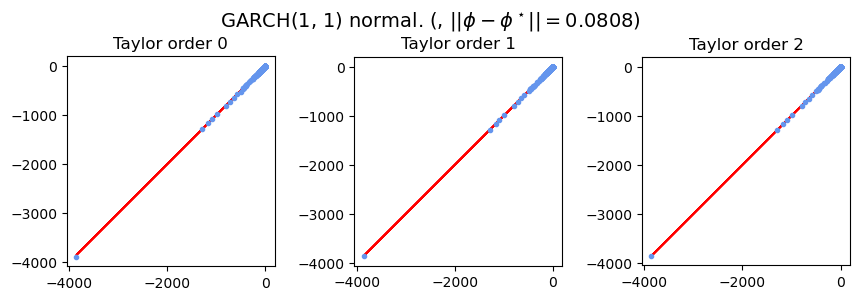

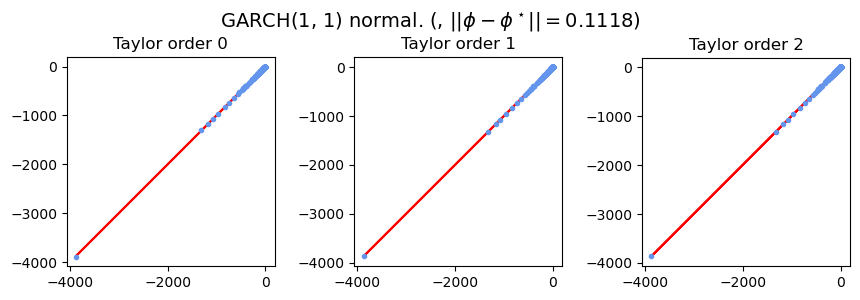

In [42]:
phiStar = MAP
args = (T, p, q, y, y_start, sigma2_start)
control_variate_dir = out_dir / "control_variates"
control_variate_dir.mkdir(parents=True, exist_ok=True)
save_path_control_variates = control_variate_dir / "control_variate_result.h5"
log_path_control_variates = control_variate_dir / "control_variate_live.log"

try:
    control_variates = load_dict_h5(save_path_control_variates)
    dens_at_phiStar = control_variates['dens_at_phiStar']
    grad_at_phiStar = control_variates['grad_at_phiStar'] 
    Hess_at_phiStar = control_variates['Hess_at_phiStar']
    end = control_variates['end']
    start = control_variates['start']
    cpu_CV = end - start

    print(dens_at_phiStar.shape)

except FileNotFoundError:
    with live_log_to_file(log_path_control_variates):
        start = time.perf_counter()
        dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar = initiate_control_variate_quantities(
            log_densities, grad_log_densities, Hess_log_densities, phiStar, args
        )
        end = time.perf_counter()
        cpu_CV = end - start
        print("==============================================================", flush=True)
        print("Elapsed time control variates initialisation with T = " , T, "p = " , p, "q = " , q,  ":", cpu_CV, "seconds", flush=True)
        print("==============================================================", flush=True)
        control_variates = {
            'dens_at_phiStar': dens_at_phiStar,
            'grad_at_phiStar': grad_at_phiStar,
            'Hess_at_phiStar': Hess_at_phiStar,
            'end': end,
            'start': start
        }
        save_dict_h5(save_path_control_variates, control_variates)

with pdf_section("05_control_variates", out_dir=out_dir) as active:

    if active:
        if log_path_control_variates.exists():
            text = log_path_control_variates.read_text(encoding="utf-8")
        else:
            text = "==============================================================\n" \
                   f"Elapsed time control variates initialisation with T = {T} p = {p} q = {q}: {cpu_CV} seconds\n" \
                   "==============================================================\n"
        pdf_add_text(text, title="Control variate construction.")

    # Precompute quantities for the control variates that do not depend on theta
    A = np.sum(dens_at_phiStar) 
    B = np.sum(grad_at_phiStar, axis = 0)
    C = np.sum(Hess_at_phiStar, axis = 0)
    # sum of control variates evaluated at phi    
    q_sum = lambda phi: A + np.dot(B, phi - phiStar) + 0.5*np.dot(phi - phiStar, np.dot(C, phi - phiStar))

    # Inspect control variate accuracy: log-densities

    # Outside median ellipse in phi space
    Sigma_pi = Cov # np.linalg.inv(Hess_obj_func_posterior(MAP))
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.50, n = 1).flatten()
    phi_beyond_median = phi
    q_k_order0 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    q_k_order1 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    q_k_order2 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    l_k = log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(l_k, l_k, color = 'red')
            if k == 0:
                axs[k].plot(l_k, q_k_order0, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(l_k, q_k_order1, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(l_k, q_k_order2, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)

    # Outside 0.999 ellipse
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.999, n = 1).flatten()
    phi_extreme = phi
    q_k_order0 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    q_k_order1 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    q_k_order2 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    l_k = log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(l_k, l_k, color = 'red')
            if k == 0:
                axs[k].plot(l_k, q_k_order0, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(l_k, q_k_order1, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(l_k, q_k_order2, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)

Tune the estimator. We recommend $R_{\max}=100$, but tune for $R_{\max}=1000, 100, 10, 1$ just to inspect.

In [43]:
t_star_frac = 0.01
t_star = int(t_star_frac* T)
b = 100.0
R_max_list = [1000, 100, 10, 1]
tuning_dir = out_dir / "tuning"
tuning_dir.mkdir(parents=True, exist_ok=True)

save_path_tuning = tuning_dir / "results_by_Rmax.h5"
log_path_tuning = tuning_dir / "tuning_live.log"

try:
    tuning_cache = load_dict_h5(save_path_tuning)
    results_by_Rmax_raw = tuning_cache["results_by_Rmax"]

    # Convert keys from str -> int
    results_by_Rmax = {int(k): v for k, v in results_by_Rmax_raw.items()}

    start = tuning_cache["start"]
    end = tuning_cache["end"]
    cpu_tuning_total = end - start

    print("==============================================================", flush=True)
    print("Loaded cached tuning results.", flush=True)
    print("Elapsed cached total tuning time:", cpu_tuning_total, "seconds", flush=True)
    print("==============================================================", flush=True)

except FileNotFoundError:
    with live_log_to_file(log_path_tuning):
        start = time.perf_counter()

        results_by_Rmax = run_calibrated_tuning_over_Rmax(
            R_max_list=R_max_list,
            MCMC_results=MCMC_results,
            MAP=MAP,
            phiStar=phiStar,
            dens_at_phiStar=dens_at_phiStar,
            grad_at_phiStar=grad_at_phiStar,
            Hess_at_phiStar=Hess_at_phiStar,
            args=args,
            T=T,
            t_star_frac=t_star_frac,
            b=b,
            m_min=2,
            pilot_slice=slice(1, 100, 5),
            verbose=True,
        )

        end = time.perf_counter()
        cpu_tuning_total = end - start

        print("==============================================================", flush=True)
        print("Elapsed total tuning time:", cpu_tuning_total, "seconds", flush=True)
        for R_max in R_max_list:
            print(
                f"R_max = {R_max}: cpu_tuning_Rmax = "
                f"{results_by_Rmax[R_max]['cpu_tuning_Rmax']:.2f} seconds",
                flush=True
            )
        print("==============================================================", flush=True)

        tuning_cache = {
            "results_by_Rmax": results_by_Rmax,
            "start": start,
            "end": end,
        }

        save_dict_h5(save_path_tuning, tuning_cache)

Loaded cached tuning results.
Elapsed cached total tuning time: 789.5559824469965 seconds


Summarise the tuning quantities. Plot constrained objective for the different $R_{\max}$ targets.

In [44]:
# Summarise and plot
for R_max in R_max_list:
    res = results_by_Rmax[R_max]

    E_umax_opt = expected_umax_safe(res['probs_opt'], res['m_opt'])

    print(
        f"R_max={R_max:>4} | "
        f"c_min={res['c_min']:.4f} | "
        f"V_target={res['V_target']:.6f} | "
        f"c_opt={res['c_opt']:.6f} | "
        f"m_opt={res['m_opt']} | "
        f"E[umax]={E_umax_opt:.4f} | "
        f"var_opt={res['var_opt']:.6f} | "
        f"bind={res['binding_ratio_final']:.6f}"
    )


results_by_Rmax_list = []
results_by_Rmax_list.append(results_by_Rmax[100]) # Used for the 2 x 2 plot version of Figure 5 for all 4 models. V tol approx 8000000

R_max=1000 | c_min=0.0010 | V_target=79693839.591555 | c_opt=0.001106 | m_opt=2 | E[umax]=146.0463 | var_opt=79693835.671348 | bind=1.000000
R_max= 100 | c_min=0.0100 | V_target=7969383.959155 | c_opt=0.010000 | m_opt=2 | E[umax]=1041.9620 | var_opt=7130894.762670 | bind=0.894786
R_max=  10 | c_min=0.1000 | V_target=796938.395916 | c_opt=0.100000 | m_opt=2 | E[umax]=9721.7259 | var_opt=713079.869797 | bind=0.894774
R_max=   1 | c_min=1.0000 | V_target=79693.839592 | c_opt=1.000000 | m_opt=2 | E[umax]=66667.1667 | var_opt=71298.691498 | bind=0.894658


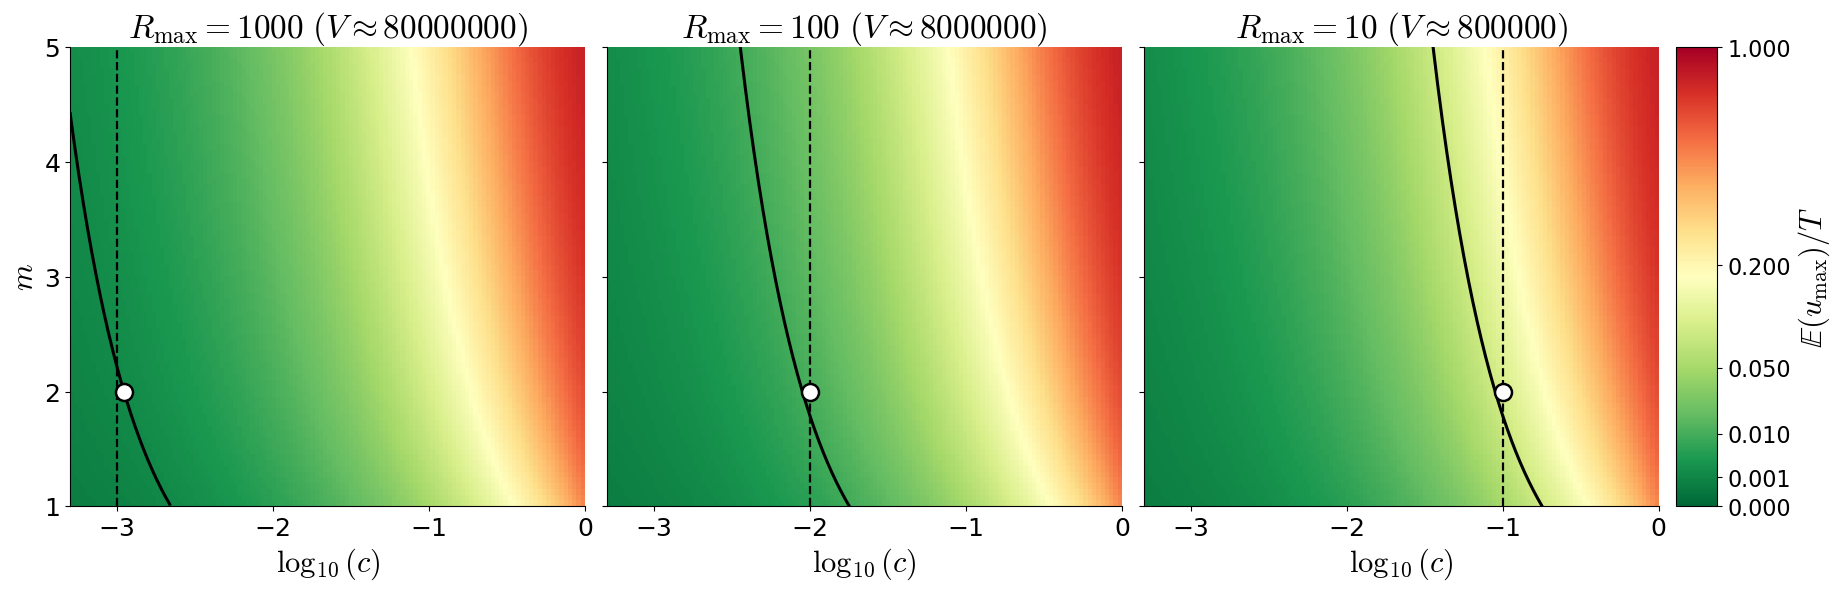

In [45]:
R_max_list = [1000, 100, 10]
V_tolerances_list = [80000000, 8000000, 800000]
make_Rmax_triptych_from_results_Figure5(
    T=T,
    t_star=t_star,
    b=b,
    results_by_Rmax=results_by_Rmax,
    R_max_list=R_max_list,
    V_tol_list = V_tolerances_list,
    c_max=1.0,
    n_c=120,
    m_max=5,
    n_m_bg=80,
    power_gamma=0.4,
    vmax=1.0,
    marker_size=150,
    show_cmin_line=True
)

Run subsampling Markov chain Monte Carlo with TPD weights (tuned using $R_{\max}=100$).

In [46]:
# ==============================================================
# Subsampling MCMC: repeated runs with caching + per-run PDFs
# Fixed R_max = 100
# ==============================================================

N = 12000
R_max = 100
n_repeat = 6
key_example = "GARCH11_normal"

base_seed = SEEDS['App2_GARCH11_subsampling_mcmc_Rmax100']

MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------------
# Tuned estimator parameters for subsampling MCMC
# --------------------------------------------------------------
res_tune_subsampling_MCMC = results_by_Rmax[R_max]
V_target = float(res_tune_subsampling_MCMC["V_target"])
c_opt = float(res_tune_subsampling_MCMC["c_opt"])
m_opt = int(res_tune_subsampling_MCMC["m_opt"])
gamma_opt = float(res_tune_subsampling_MCMC["gamma_opt"])

estimator_params = {
    "m_opt": m_opt,
    "c_opt": c_opt,
    "gamma_opt": gamma_opt,
    "t_star": t_star,
    "b": b,
    "V_tolerance": V_target,
    "R_max": R_max,
}

# --------------------------------------------------------------
# Fixed initial value and fixed proposal covariance
# --------------------------------------------------------------
phi_init = MAP
Cov_phi = Cov  # Negative Hessian inverse evaluated at the mode

def phi_to_psi(phi):
    return theta_to_psi(hinv(phi))

J_phi_to_psi = Jacobian_autograd(phi_to_psi)
J_map = J_phi_to_psi(MAP)
Cov_psi = J_map @ Cov_phi @ J_map.T
Cov_psi = 0.5 * (Cov_psi + Cov_psi.T)
Cov_psi = make_pos_def(Cov_psi, eps=1e-8)
prop_cov = 0.1 * 2.38**2 / n_params * Cov_psi

# --------------------------------------------------------------
# Storage across repetitions
# --------------------------------------------------------------
result_list = []
diagnostics_list = []
status_list = []
cpu_list = []
cf_list = []
seed_list = []
log_path_list = []
save_path_list = []
pdf_path_list = []

section_name = f"06_subsampling_MCMC_Rmax{R_max}"

for run in range(1, n_repeat + 1):

    seed_run = base_seed + run
    np.random.seed(seed_run)

    save_path_subsampling_MCMC = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_rep{run}.h5"
    log_path_subsampling_MCMC = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_rep{run}.log"

    pdf_suffix = f"Rmax{R_max}_rep{run}"
    safe = section_name.replace(" ", "_").replace("/", "-")
    pdf_path_run = Path(out_dir) / f"{safe}_{pdf_suffix}.pdf"

    save_path_list.append(save_path_subsampling_MCMC)
    log_path_list.append(log_path_subsampling_MCMC)
    pdf_path_list.append(pdf_path_run)
    seed_list.append(seed_run)

    try:
        subsampling_MCMC_results = load_dict_h5(save_path_subsampling_MCMC)

        result_subsampling_MCMC = subsampling_MCMC_results["MCMC_obj"]
        prop_cov_run = np.asarray(subsampling_MCMC_results["prop_cov"])
        estimator_params_run = subsampling_MCMC_results["estimator_params"]

        for key in [
            "samples_phi",
            "samples_theta",
            "log_posthat_samples",
            "sigma2_lhat_samples",
            "u_max_prop",
        ]:
            if key in result_subsampling_MCMC:
                result_subsampling_MCMC[key] = np.asarray(result_subsampling_MCMC[key])

        run_diagnostics = subsampling_MCMC_results.get("run_diagnostics", None)
        run_status = subsampling_MCMC_results.get("run_status", None)

    except FileNotFoundError:

        with live_log_to_file(log_path_subsampling_MCMC):

            print("==============================================================", flush=True)
            print(f"Running subsampling MCMC with R_max = {R_max}", flush=True)
            print(f"Repetition = {run}/{n_repeat}", flush=True)
            print(f"Seed = {seed_run}", flush=True)
            print(f"N = {N}", flush=True)
            print(f"m_opt = {m_opt}", flush=True)
            print(f"c_opt = {c_opt}", flush=True)
            print(f"gamma_opt = {gamma_opt}", flush=True)
            print(f"V_target = {V_target}", flush=True)
            print("==============================================================", flush=True)

            result_subsampling_MCMC = sample_subsampling_posterior_random_walk_stationary_proposal(
                estimator_params,
                phi_init,
                prop_cov,
                N,
                names,
                dataset_name,
                adapt=False,
            )

            print("==============================================================", flush=True)

        prop_cov_run = prop_cov
        estimator_params_run = estimator_params

        # ----------------------------------------------------------
        # Compute run diagnostics
        # ----------------------------------------------------------
        longest_streak, first_stuck_iteration = longest_immobility_streak(
            result_subsampling_MCMC["samples_theta"]
        )
        stuck_flag = (longest_streak >= 100)

        cpu_tuning_cost = results_by_Rmax[R_max]["cpu_tuning_Rmax"]
        cpu_subsampling_MCMC = result_subsampling_MCMC["run_time"] + cpu_tuning_cost
        cf_subsampling_MCMC = np.sum(result_subsampling_MCMC["u_max_prop"] + 1) + 100 * T

        # Optional acceptance-rate extraction if present
        acceptance_rate = np.mean(result_subsampling_MCMC['alphas_MH'])
        
        run_diagnostics = {
            "run": run,
            "seed": seed_run,
            "longest_immobility_streak": int(longest_streak),
            "first_stuck_iteration": (
                int(first_stuck_iteration) if first_stuck_iteration is not None else -1
            ),
            "stuck_flag": bool(stuck_flag),
            "run_time": float(result_subsampling_MCMC["run_time"]),
            "cpu_total_including_tuning": float(cpu_subsampling_MCMC),
            "compute_fraction": float(cf_subsampling_MCMC),
            "acceptance_rate": acceptance_rate,
        }

        run_status = classify_mcmc_run(longest_streak, threshold_stuck=100)

        subsampling_MCMC_results = {
            "MCMC_obj": result_subsampling_MCMC,
            "prop_cov": prop_cov_run,
            "start_value": phi_init,
            "estimator_params": estimator_params_run,
            "seed": seed_run,
            "run_diagnostics": run_diagnostics,
            "run_status": run_status,
        }
        save_dict_h5(save_path_subsampling_MCMC, subsampling_MCMC_results)

    # --------------------------------------------------------------
    # If diagnostics/status were not cached, compute them now
    # --------------------------------------------------------------
    if run_diagnostics is None or run_status is None:

        longest_streak, first_stuck_iteration = longest_immobility_streak(
            result_subsampling_MCMC["samples_theta"]
        )
        stuck_flag = (longest_streak >= 100)

        cpu_tuning_cost = results_by_Rmax[R_max]["cpu_tuning_Rmax"]
        cpu_subsampling_MCMC = result_subsampling_MCMC["run_time"] + cpu_tuning_cost
        cf_subsampling_MCMC = np.sum(result_subsampling_MCMC["u_max_prop"] + 1) + 100 * T

        acceptance_rate = np.mean(result_subsampling_MCMC["alphas_MH"])

        run_diagnostics = {
            "run": run,
            "seed": seed_run,
            "longest_immobility_streak": int(longest_streak),
            "first_stuck_iteration": (
                int(first_stuck_iteration) if first_stuck_iteration is not None else -1
            ),
            "stuck_flag": bool(stuck_flag),
            "run_time": float(result_subsampling_MCMC["run_time"]),
            "cpu_total_including_tuning": float(cpu_subsampling_MCMC),
            "compute_fraction": float(cf_subsampling_MCMC),
            "acceptance_rate": acceptance_rate,
        }

        run_status = classify_mcmc_run(longest_streak, threshold_stuck=100)

    # --------------------------------------------------------------
    # Store in summary lists
    # --------------------------------------------------------------
    result_list.append(result_subsampling_MCMC)
    diagnostics_list.append(run_diagnostics)
    status_list.append(run_status)
    cpu_list.append(run_diagnostics["cpu_total_including_tuning"])
    cf_list.append(run_diagnostics["compute_fraction"])

    # --------------------------------------------------------------
    # Per-run PDF output
    # --------------------------------------------------------------
    with pdf_section(section_name, out_dir=out_dir, suffix=pdf_suffix, overwrite=False) as active:
        if active:
            text = log_path_subsampling_MCMC.read_text(encoding="utf-8")

            summary_text = (
                f"Repetition {run}/{n_repeat}\n"
                f"Seed = {seed_run}\n"
                f"Status = {run_status}\n"
                f"Longest immobility streak = {run_diagnostics['longest_immobility_streak']}\n"
                f"First stuck iteration = {run_diagnostics['first_stuck_iteration']}\n"
                f"Acceptance rate = {run_diagnostics['acceptance_rate']}\n"
                f"Run time = {run_diagnostics['run_time']:.2f}\n"
                f"CPU incl. tuning = {run_diagnostics['cpu_total_including_tuning']:.2f}\n"
                f"Compute fraction = {run_diagnostics['compute_fraction']:.2f}\n"
            )

            pdf_add_text(
                text + "\n\n" + summary_text,
                title=f"Subsampling MCMC sampling (R_max = {R_max}, repetition {run})",
            )

            # Standard MCMC traceplots
            plot_traceplots_MCMC(
                result_subsampling_MCMC["samples_theta"],
                param_true=hinv(MAP),
                param_names=param_names,
                burnin=0,
                thin=1,
                use_median=False,
                show_running_mean=True,
                runmean_window=50,
                suptitle=f"Traceplots subsampling MCMC (R_max = {R_max}, rep {run})",
            )
            pdf_add_fig()
            plt.close("all")

            # Additional subsampling-specific diagnostics
            plot_subsampling_MCMC_quantities(result_subsampling_MCMC)
            pdf_add_fig()
            plt.close("all")

# --------------------------------------------------------------
# Save master summary object across repetitions
# --------------------------------------------------------------
subsampling_MCMC_repeated_summary = {
    "R_max": R_max,
    "N": N,
    "n_repeat": n_repeat,
    "base_seed": base_seed,
    "key_example": key_example,
    "estimator_params": estimator_params,
    "start_value": phi_init,
    "prop_cov": prop_cov,
    "seed_list": seed_list,
    "status_list": status_list,
    "diagnostics_list": diagnostics_list,
    "cpu_list": cpu_list,
    "cf_list": cf_list,
    "save_path_list": [str(x) for x in save_path_list],
    "log_path_list": [str(x) for x in log_path_list],
    "pdf_path_list": [str(x) for x in pdf_path_list],
    "n_stuck": int(np.sum([s == "stuck" for s in status_list])),
    "n_mixed_well": int(np.sum([s == "mixed_well" for s in status_list])),
}

save_path_summary = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_summary.h5"
save_dict_h5(save_path_summary, subsampling_MCMC_repeated_summary)

print("==============================================================")
print(f"Finished repeated subsampling MCMC runs for R_max = {R_max}")
print(f"n_repeat = {n_repeat}")
print(f"mixed well = {subsampling_MCMC_repeated_summary['n_mixed_well']}/{n_repeat}")
print(f"stuck = {subsampling_MCMC_repeated_summary['n_stuck']}/{n_repeat}")
print(f"Summary saved to: {save_path_summary}")
print("==============================================================")

[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/normal/06_subsampling_MCMC_Rmax100_Rmax100_rep1.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/normal/06_subsampling_MCMC_Rmax100_Rmax100_rep2.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/normal/06_subsampling_MCMC_Rmax100_Rmax100_rep3.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/normal/06_subsampling_MCMC_Rmax100_Rmax100_rep4.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/normal/06_subsampling_MCMC_Rmax100_Rmax100_rep5.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/normal/06_subsampling_MCMC_Rmax100_Rmax100_rep6.pdf
Finished repeated subsampling MCMC runs for R_max = 100
n_repeat = 6
mixed well = 6/6
stuck = 0/6
Summary saved to: results/App2_MCMC/GARCH11/normal/MCMC/subsampling_MCMC_Rmax100_N12000_summary.h5


In [47]:
# ==============================================================
# Inspect repeated subsampling MCMC diagnostics
# ==============================================================

summary_path = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_summary.h5"
summary_obj = load_dict_h5(summary_path)

diagnostics_list = summary_obj["diagnostics_list"]
status_list = summary_obj["status_list"]
seed_list = summary_obj["seed_list"]

rows = []
for d, status, seed in zip(diagnostics_list, status_list, seed_list):
    rows.append({
        "run": int(d["run"]),
        "seed": int(seed),
        "status": status,
        "longest_immobility_streak": int(d["longest_immobility_streak"]),
        "first_stuck_iteration": (
            None if int(d["first_stuck_iteration"]) < 0 else int(d["first_stuck_iteration"])
        ),
        "acceptance_rate": (
            np.nan if d["acceptance_rate"] is None else float(d["acceptance_rate"])
        ),
        "run_time": float(d["run_time"]),
        "cpu_total_including_tuning": float(d["cpu_total_including_tuning"]),
        "compute_fraction": float(d["compute_fraction"]),
    })

diag_df = pd.DataFrame(rows).sort_values("run").reset_index(drop=True)

print("==============================================================")
print("Repeated subsampling MCMC diagnostics")
print("==============================================================")
print(diag_df.to_string(index=False))

print("\n==============================================================")
print("Aggregate summaries")
print("==============================================================")
print(f"Number of runs: {len(diag_df)}")
print(f"Status counts:\n{diag_df['status'].value_counts(dropna=False)}")
print()
print("Longest immobility streak:")
print(f"  min    = {diag_df['longest_immobility_streak'].min()}")
print(f"  median = {diag_df['longest_immobility_streak'].median()}")
print(f"  max    = {diag_df['longest_immobility_streak'].max()}")

if diag_df["acceptance_rate"].notna().any():
    print()
    print("Acceptance rate:")
    print(f"  min    = {diag_df['acceptance_rate'].min():.4f}")
    print(f"  median = {diag_df['acceptance_rate'].median():.4f}")
    print(f"  max    = {diag_df['acceptance_rate'].max():.4f}")

print()
print("Runtime:")
print(f"  min    = {diag_df['run_time'].min():.2f}")
print(f"  median = {diag_df['run_time'].median():.2f}")
print(f"  max    = {diag_df['run_time'].max():.2f}")

print()
print("Compute fraction:")
print(f"  min    = {diag_df['compute_fraction'].min():.2f}")
print(f"  median = {diag_df['compute_fraction'].median():.2f}")
print(f"  max    = {diag_df['compute_fraction'].max():.2f}")
print("==============================================================")

Repeated subsampling MCMC diagnostics
 run  seed     status  longest_immobility_streak first_stuck_iteration  acceptance_rate   run_time  cpu_total_including_tuning  compute_fraction
   1 45679 mixed_well                         26                  None         0.362131 548.209943                  756.034075        21314312.0
   2 45680 mixed_well                         20                  None         0.355370 596.287714                  804.111846        22857018.0
   3 45681 mixed_well                         24                  None         0.352758 562.934633                  770.758765        22573812.0
   4 45682 mixed_well                         20                  None         0.359894 631.910547                  839.734679        23125686.0
   5 45683 mixed_well                         21                  None         0.357305 686.157461                  893.981594        23597979.0
   6 45684 mixed_well                         23                  None         0.359320 523.

Chains for GARCH($1,1$) with normal errors.

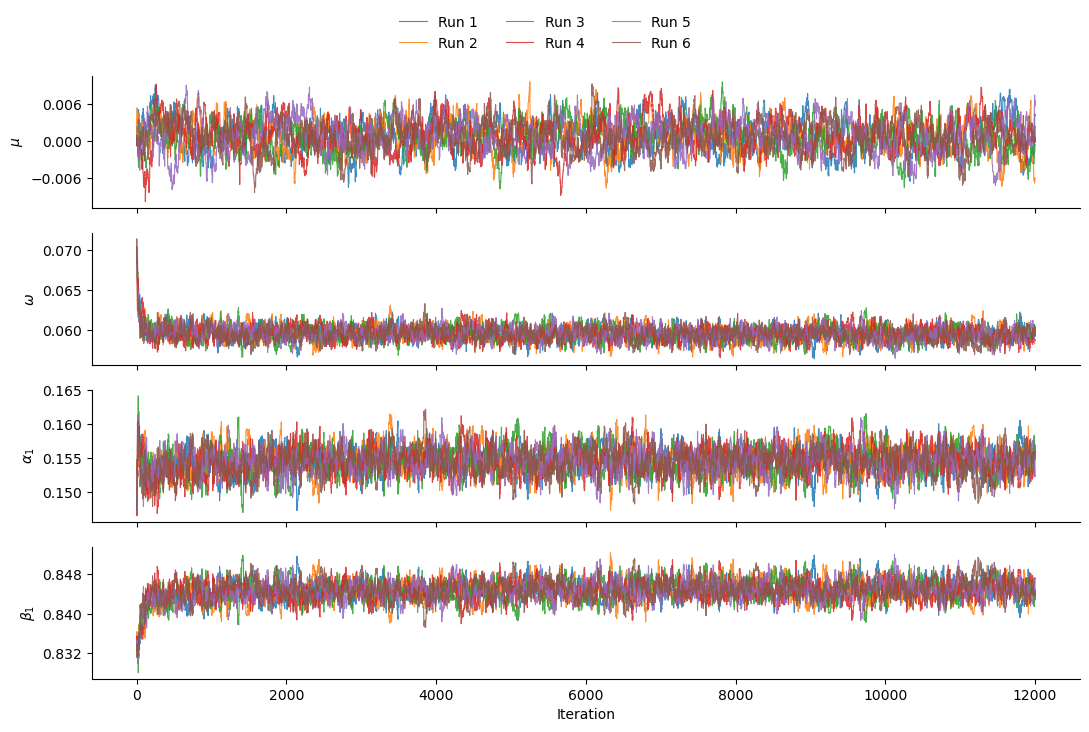

In [48]:
chains = [r['samples_theta'] for r in result_list]
chain_labels = [f"Run {i+1}" for i in range(6)]

fig, axes = plot_traceplots_MCMC_chains(
    param_draws=chains,
    param_names=param_names,
    chain_labels=chain_labels,
    burnin=0,
    thin=1,
    show_running_mean=False
)

Compute the log-predictive score for the test data with subsampling MCMC.

In [49]:
result_subsampling_MCMC_R_max100 = result_list[0]
result_garch11_normal = result_list[0]

# Compute joint out-of-sample predictive score
y_test = np.load("data/AAPL_10000obs.npy")
y_test = y_test/series.std()

# Evaluate model
evaluate_dir = out_dir / "evaluate"
evaluate_dir.mkdir(parents=True, exist_ok=True)
save_path_evaluate = evaluate_dir / ("log_pred_score.h5")
log_path_evaluate = evaluate_dir / ("evaluate_score.log")

samples_theta = result_subsampling_MCMC_R_max100["samples_theta"][2001::100] # 

try:
    log_predictive_results = load_dict_h5(save_path_evaluate)
    log_pred = log_predictive_results['log_scores']
    S = log_predictive_results['sum_log_scores']

except FileNotFoundError:

    with live_log_to_file(log_path_evaluate):

        # Compute the log-predictive score
        print("==============================================================", flush=True)
        S, log_pred = joint_predictive_score(samples_theta, y, y_test, p, q, y_start, sigma2_start, log_densities)
        print(f"p={p}, q={q}, error={error_type}, log_pred score sum = {S}")
        print("==============================================================", flush=True)
        log_predictive_results = {'sum_log_scores': S, 'log_scores': log_pred}
        save_dict_h5(save_path_evaluate, log_predictive_results)




mc_summary = predictive_score_mc_ci(log_pred)
print("Predictive score with subsampling MCMC")
print("Joint predictive score:", mc_summary["score_hat"])
print("MC standard error:", mc_summary["se"])
print("Approx. 95% CI: ({:.6f}, {:.6f})".format(
    mc_summary["ci_lower"], mc_summary["ci_upper"]
))
print("IACT:", mc_summary["tau_int"])
print("ESS:", mc_summary["ess"])



Predictive score with subsampling MCMC
Joint predictive score: -14630.846703215351
MC standard error: 0.3347094948934535
Approx. 95% CI: (-14631.502722, -14630.190685)
IACT: 1.031467404866533
ESS: 96.94925843336709


Full-data Markov chain Monte Carlo.

In [50]:
np.random.seed(SEEDS["App2_GARCH11_full_data_mcmc"])
N = 12000
MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)
save_path_MCMC = MCMC_dir / ("Full_data_MCMC_N%s.h5" % N)
log_path_MCMC = MCMC_dir / ("Full_data_MCMC_N%s.log" % N)

try:
    MCMC_results = load_dict_h5(save_path_MCMC)
    full_data_MCMC = MCMC_results['MCMC_obj']
    prop_cov = MCMC_results['prop_cov']
    # Convert back to arrays
    for key in ["samples_phi", "samples_theta"]:
        full_data_MCMC[key] = np.asarray(full_data_MCMC[key])

except FileNotFoundError:

    with live_log_to_file(log_path_MCMC):

        # Run MCMC (proposal parameterised to obey stationarity)
        # Transform to Psi by linearising
        def phi_to_psi(phi):
            return theta_to_psi(hinv(phi))

        J_phi_to_psi = Jacobian_autograd(phi_to_psi)
        J_map = J_phi_to_psi(MAP)
        Cov_phi = Cov
        Cov_psi = J_map @ Cov_phi @ J_map.T
        Cov_psi = 0.5 * (Cov_psi + Cov_psi.T)
        Cov_psi = make_pos_def(Cov_psi, eps=1e-8)
        prop_cov = 0.1*2.38**2 / n_params * Cov_psi
        phi_init = MAP 
        print("==============================================================", flush=True)
        full_data_MCMC = sample_full_data_posterior_AM_stationary_proposal(phi_init, prop_cov, N, names,dataset_name, adapt_cov=True, adapt_scale=True, burn_in = 1000)
        print("==============================================================", flush=True)        

        MCMC_results = {'MCMC_obj': full_data_MCMC, 'prop_cov': prop_cov, 'start_value': phi_init}
        save_dict_h5(save_path_MCMC, MCMC_results)

    with pdf_section("07_full_data_MCMC", out_dir=out_dir) as active:
        if active:
            text = log_path_MCMC.read_text(encoding="utf-8")
            pdf_add_text(text, title="Full data MCMC sampling.")

            plot_traceplots_MCMC(
                full_data_MCMC['samples_phi'],
                param_true=MAP, param_names=trans_param_names,
                burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
                suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
            )
            pdf_add_fig()          # saves all figures created by plot_traceplots_MCMC
            plt.close("all")       


Predictive score full-data MCMC

In [51]:
# Evaluate model
evaluate_dir = out_dir / "evaluate"
evaluate_dir.mkdir(parents=True, exist_ok=True)
save_path_evaluate = evaluate_dir / ("log_pred_score_full_data.h5")
log_path_evaluate = evaluate_dir / ("evaluate_score_full_data.log")

samples_theta = full_data_MCMC["samples_theta"][2001::100] # 

try:
    log_predictive_results = load_dict_h5(save_path_evaluate)
    log_pred = log_predictive_results['log_scores']
    S = log_predictive_results['sum_log_scores']

except FileNotFoundError:

    with live_log_to_file(log_path_evaluate):

        # Compute the log-predictive score
        print("==============================================================", flush=True)
        S, log_pred = joint_predictive_score(samples_theta, y, y_test, p, q, y_start, sigma2_start, log_densities)
        print(f"p={p}, q={q}, error={error_type}, log_pred score sum = {S}")
        print("==============================================================", flush=True)
        log_predictive_results = {'sum_log_scores': S, 'log_scores': log_pred}
        save_dict_h5(save_path_evaluate, log_predictive_results)




mc_summary_full_data = predictive_score_mc_ci(log_pred)
print("Predictive score with full_data MCMC")
print("Joint predictive score:", mc_summary_full_data["score_hat"])
print("MC standard error:", mc_summary_full_data["se"])
print("Approx. 95% CI: ({:.6f}, {:.6f})".format(
    mc_summary_full_data["ci_lower"], mc_summary_full_data["ci_upper"]
))
print("IACT:", mc_summary_full_data["tau_int"])
print("ESS:", mc_summary_full_data["ess"])

Predictive score with full_data MCMC
Joint predictive score: -14631.274918803067
MC standard error: 0.24199076971279326
Approx. 95% CI: (-14631.749212, -14630.800626)
IACT: 1.0478997803756154
ESS: 95.4289731448893


Save to create tables for subsampling MCMC results and predictive scores.

In [52]:
tables_GARCH11_norm = make_model_summary_for_tables(
    model_label="GARCH(1,1), normal",
    subsampling_summary=subsampling_MCMC_repeated_summary,
    cpu_cv=cpu_CV,
    full_data_MCMC=full_data_MCMC,
    predictive_summary_subsampling=mc_summary,
    predictive_summary_full_data=mc_summary_full_data,
    comment="stable baseline"
)

Compare the posterior of mean of the persistence parameters for the Dow Jones data and that of the AAPL data.

In [53]:
print('Posterior mean persistence Dow Jones: ', np.mean(result_full_data_MCMC["samples_theta"][2000:, 2]
    + result_full_data_MCMC["samples_theta"][2000:, 3]))

print('Posterior mean persistence AAPL: ', np.mean(full_data_MCMC["samples_theta"][2000:, 2]
    + full_data_MCMC["samples_theta"][2000:, 3]))


Posterior mean persistence Dow Jones:  0.9474262612258951
Posterior mean persistence AAPL:  0.9998460750001463


Compare accuracy toward full-data MCMC and also effective sample size (ESS).

(<Figure size 800x600 with 4 Axes>,
 array([<Axes: xlabel='$\\mu$'>, <Axes: xlabel='$\\omega$'>,
        <Axes: xlabel='$\\alpha_1$'>, <Axes: xlabel='$\\beta_1$'>],
       dtype=object),
 array([[126.41548966, 294.72451298, 273.71602835, 269.75127204],
        [798.16414989, 788.12963647, 631.2823222 , 635.58591946]]))

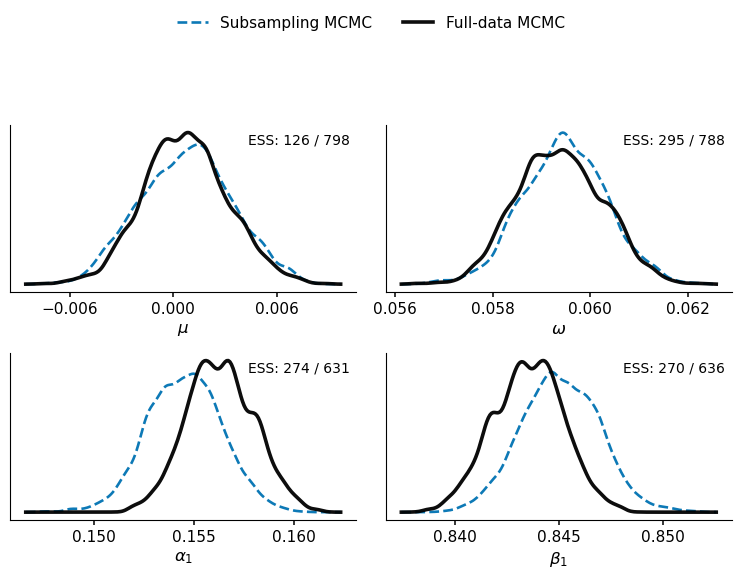

In [54]:
plot_kde_with_ESS_comparison(
            result_subsampling_MCMC_R_max100["samples_theta"][2000:, :],
            full_data_MCMC['samples_theta'][2000:, :],
            param_names=param_names,
            title="Posterior marginals (phi): Subsampling MCMC vs MCMC",
            n_points=200,
            true_vals=None,
            labels=("Subsampling MCMC", "Full-data MCMC"),
            ess_fmt="compact"
        )


### 3.2 GARCH(1,1) with Student-t errors

For this case, in addition to the standard model selection exercise and comparing to the full-data MCMC,  we illustrate the limitations of uniform sampling in the tuning regime in this application. We also show that increasing $m=30$ makes the sampling distribution of the error more normal. Running uniform sampling with $m=30$ improves mixing (not shown here), but is not practically relevant as the expected computational cost is nearly the full dataset.

Define settings and optimise.

[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/Student-t/01_settings_and_data_plot.pdf
GARCH_type: GARCH , Error distribution: Student-t
Lags: p =,  1 q =  1
Dataset name:  AAPL_GARCH(1,1)_Student-t_error
Number of observations:  100000
Parameters:
Tranformations:
 ['identity', 'log', 'log', 'log', 'log_shift2']
Number of parameters: 5
Prior hyperparameters (v_rate and v_shape only if Student-t)
alpha_scale : 0.2
beta_scale  : 0.8
mu_mean     : 0
mu_sd       : 10
omega_scale : 1
v_rate      : 1
v_shape     : 2


$\mu$, $\omega$, $\alpha_1$, $\beta_1$, $\nu$

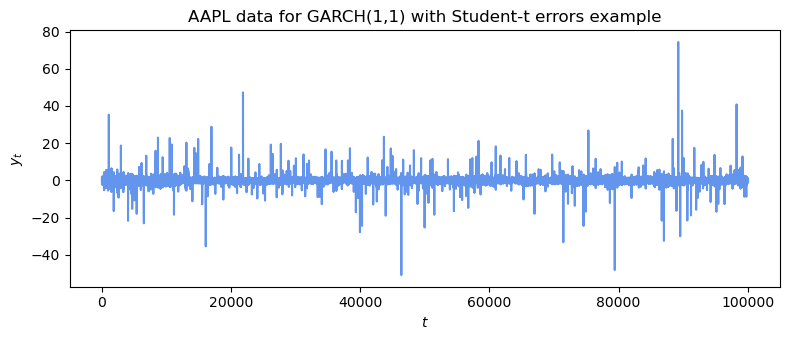

95% Confidence intervals for MLE estimates (phi)
[ 0.01 -4.17 -2.29 -0.16  0.93]
[ 0.01 -4.01 -2.16 -0.14  1.02]



95% Credible intervals for posterior (phi)
[ 0.01 -4.17 -2.29 -0.16  0.93]
[ 0.01 -4.01 -2.16 -0.14  1.02]





In [55]:
# Define model (change only error_type from the run in 3.1)
error_type = "Student-t"

# Specify transforms (set all "identity" if no transformation)
dataset_name = "AAPL_%s(%s,%s)_%s_error" % (GARCH_type, p, q, error_type)

param_names, trans_param_names = get_param_names(GARCH_type, error_type, p, q)
names = {"params_name": param_names, "trans_param_names": trans_param_names}    
transforms = ["identity"] + ["log"] + p*["log"] + q*["log"] + ["log_shift2"]

# Likelihood optimisation settings (posterior optimisation always uses L-BFGS-B as it has a better starting value):
likelihood_optim = "L-BFGS-B" # Basinhopping performed for normal error, which is used as starting value. L-BFGS-B enough here 
options_L_BFGS_B = {"gtol":1e-6, "ftol":1e-12, "maxls":50, "maxiter":2000, "disp":True}
options_trust_ncg = {"gtol":1e-6, "maxiter":2000, "disp":True}
options_basinhopping = {"niter":5, "stepsize":0.5, "T":1.0, "disp":True} 

# Prior settings:
# The default settings are
# mu_mean = 0.0, mu_sd = 10.0, omega_scale = 1.0, alpha_scale = 0.2, beta_scale = 0.8, v_shape = 2.0, v_rate = 1.0
# If other setting required, save as dictionary and pass on to the log prior once defined.
# Example:
prior_args = "default"
# prior_args = {"mu_mean":0.0, "mu_sd":100.0, "omega_scale":1.0, "alpha_scale":0.2, "beta_scale":0.8, "v_shape":2.0, "v_rate":1.0}

# Initialise prior. Either with default parameters or as specificed in prior_args
if prior_args == "default":
    log_prior = initiate_priors(GARCH_type, error_type)
    f = {"GARCH": log_prior_GARCH, "TGARCH": log_prior_TGARCH}[GARCH_type]
    prior_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    prior_hyperparams = prior_args
    log_prior = initiate_priors(GARCH_type, error_type, **prior_hyperparams)

# Penalty settings:
penalty_args = "default"

# Inititialise penalties for frequentist estimation
if penalty_args == "default":
    log_penalty = initiate_penalties(GARCH_type, error_type)
    f = {"GARCH": log_penalty_GARCH, "TGARCH": log_penalty_TGARCH}[GARCH_type]
    penalty_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    penalty_hyperparams = penalty_args
    log_penalty = initiate_penalties(GARCH_type, error_type, **penalty_hyperparams)
    
        
# Create model functions based on the inputs above
h, hinv, hinv_p, hinv_pp, jacdiag, logdet = initiate_transformation_functions(transforms)
log_densities, grad_log_densities, Hess_log_densities = initiate_model_functions(GARCH_type, error_type, hinv, hinv_p, hinv_pp)

# Functions to reparameterise the proposal density to a space where the GARCH/TGARCH process is stationary
theta_to_psi, psi_to_theta, logabsdet_dpsi_dtheta = initiate_persistence_reparam_functions(GARCH_type=GARCH_type, error_type=error_type, p=p, q=q, h=h,
                                                                                           hinv=hinv, jacdiag=jacdiag, param_names=param_names, delta=1e-4)

# Read in data (already done above)
if GARCH_type == 'GARCH':
    n_params = 2 + p + q
elif GARCH_type == 'TGARCH':
    n_params = 2 + 2*p + q
    
if error_type == 'Student-t':
    n_params += 1
assert(len(transforms) == n_params)

# Keep text selectable in the PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
# Latex
mpl.rcParams['text.usetex'] = False 

out_dir = Path("results") / app / model / error_type
out_dir.mkdir(parents=True, exist_ok=True)

with pdf_section("01_settings_and_data_plot", out_dir=out_dir) as active:
    with capture_output(display) as cap:
        print("==============================================================")
        print("GARCH_type:", GARCH_type, ", Error distribution:", error_type)
        print("Lags: p =, ", p, "q = ", q)
        print("Dataset name: ", dataset_name)
        print("Number of observations: ", T)
        print("Parameters:")
        display(Markdown(", ".join(param_names)))
        print("Tranformations:\n", transforms)
        print("Number of parameters:", n_params)
        print("Prior hyperparameters (v_rate and v_shape only if Student-t)")
        print_kv(prior_hyperparams)
        print("==============================================================")

    # Show in notebook
    cap.show()

    # Only write to PDF if active
    if active:
        text = cap.stdout
        pdf_add_text(text, title="Model and settings specified")

    # Measurements
    plt.figure(figsize=(8, 3.5))
    plt.title(f"AAPL data for GARCH(1,1) with Student-t errors example")
    plt.plot(y, color="cornflowerblue")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$y_t$")
    plt.tight_layout()

    # Only write figure to PDF if active
    if active:
        pdf_add_fig()

    plt.show()

# Optimise
# Minimise in phi space, so input is unrestricted
def log_penalty_phi(x, p, q):
    return log_penalty(hinv(x), p, q)

def obj_func_likelihood(x):
    """
    Penalised log-likelihood. To enforce the
    """
    return -log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + log_penalty_phi(x, p, q)/T

grad_log_penalty = grad(log_penalty_phi) #(x, p, q)
Hess_log_penalty = hessian(log_penalty_phi)

grad_obj_func_likelihood = lambda x: -grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + grad_log_penalty(x, p, q)/T # Gradient of obj_func_likelihood. Computed by automatic differentiation
Hess_obj_func_likelihood = lambda x: -Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + Hess_log_penalty(x, p, q)/T # Hessian of obj_func_likelihood. Computed by automatic differentiation

optim_dir = out_dir / "optim"
optim_dir.mkdir(parents=True, exist_ok=True)
save_path_optim = optim_dir / "optim_likelihood_result.h5"
log_path_optim = optim_dir / "optim_likelihood_live.log"

# Optimise the log-likelihood
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)


try:
    optim_results = load_dict_h5(save_path_optim)
    MLE = np.array(optim_results['optim_obj']['x'])
    Cov = optim_results['Cov_MLE']
    print('95% Confidence intervals for MLE estimates (phi)')
    print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2))
    print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2))
    print("\n\n")
    
except FileNotFoundError:
    # Optimise the log-likelihood    
    # Use the MAP from the normal case above as starting value
    theta_optim_start = hinv(np.hstack((MAP, np.log(25 - 2)))) # v_0 = 25 
    phi_optim_start = h(theta_optim_start)
    
    start = time.perf_counter()
    it = {"k": 0} # For callback
    fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)

    with live_log_to_file(log_path_optim):

        if likelihood_optim == "trust-ncg":
            print('\n\nLikelihood optimisation settings for method trust-ncg:\n', flush=True)
            options = options_trust_ncg
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                jac=fg.jac, hess=Hess_obj_func_likelihood,
                method="trust-ncg", options=options
            )

        elif likelihood_optim == "L-BFGS-B":
            print('\n\nLikelihood optimisation settings for method L-BFGS-B:\n', flush=True)
            options = options_L_BFGS_B
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                method='L-BFGS-B', jac=fg.jac,
                callback=callback_optim, options=options
            )

        elif likelihood_optim == "basinhopping":
            minimizer_kwargs = {"method": "L-BFGS-B", "jac": fg.jac, "options": options_L_BFGS_B}
            res_optim_likelihood = basinhopping(
                fg.fun, x0=phi_optim_start,
                minimizer_kwargs=minimizer_kwargs,
                callback=callback_optim, **options_basinhopping
            )
        else:
            raise ValueError("Optimisation method does not exist")

        end = time.perf_counter()
        run_time = end - start

        # 

        print("==============================================================", flush=True)
        print("\nLikelihood optimisation took", run_time, "seconds.", flush=True)
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)

        print('MLE estimates (phi)', flush=True)
        MLE = res_optim_likelihood.x
        print(np.round(MLE, 2), flush=True)

        print('hinv(MLE) estimates (theta)', flush=True)
        print(np.round(hinv(MLE), 2), flush=True)

        print('95% Confidence intervals for MLE estimates (phi)', flush=True)
        Cov = np.linalg.inv(Hess_obj_func_likelihood(MLE)) / T
        print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)

        if likelihood_optim == "basinhopping":
            print_minimize_summary(
                res_optim_likelihood["lowest_optimization_result"],
                x_names=trans_param_names, latex=True
            )
        else:
            print_minimize_summary(
                res_optim_likelihood,
                x_names=trans_param_names, latex=True
            )

        print("==============================================================", flush=True)

    with pdf_section("02_optim_likelihood", out_dir=out_dir) as active:
        if active:
            text = log_path_optim.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-likelihood. Summary.")

    optim_results = {
        'optim_obj': pack_optimize_result(res_optim_likelihood),
        'method': likelihood_optim,
        'Cov_MLE': Cov,
        'start_value': phi_optim_start,
        'run_time': run_time
    }

    save_dict_h5(save_path_optim, optim_results)


# Define gradients and Hessian for log-posterior
log_prior_phi = lambda x: log_prior(hinv(x), p, q) + logdet(x) # for autograd
grad_log_prior_phi = grad(log_prior_phi)
grad_log_posterior = lambda x: grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + grad_log_prior_phi(x)
Hess_log_prior_phi = hessian(log_prior_phi)
Hess_log_posterior = lambda x: Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + Hess_log_prior_phi(x)#

obj_func_posterior = lambda x: -log_posterior(x, T, p, q, y, y_start, sigma2_start)[0] # Input is phi
grad_obj_func_posterior = lambda x: -grad_log_posterior(x) 
Hess_obj_func_posterior = lambda x: -Hess_log_posterior(x)

save_path_optim_posterior = optim_dir / "optim_posterior_result.h5"
log_path_optim_posterior = optim_dir / "optim_posterior_live.log"

# Optimise the log-posterior in phi space, so input is unrestricted
phi_optim_start = MLE
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_posterior, grad_obj_func_posterior)

try:    
    optim_posterior_results = load_dict_h5(save_path_optim_posterior)
    MAP = np.array(optim_posterior_results['optim_obj']['x'])
    Cov = optim_posterior_results['Cov']
    print('95% Credible intervals for posterior (phi)', flush=True)
    print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print("\n\n", flush=True)
    
except FileNotFoundError:
    # Optimise the posterior 
    start = time.perf_counter()

    with live_log_to_file(log_path_optim_posterior):

        res_optim_posterior = minimize(
            fg.fun, phi_optim_start,
            method='L-BFGS-B', jac=fg.jac,
            callback=callback_optim,
            options=options_L_BFGS_B
        )

        end = time.perf_counter()
        run_time = end - start

        print("==============================================================", flush=True)

        print("\nPosterior optimisation took", run_time, "seconds.", flush=True)
        print('\n\nPosterior optimisation settings for method L-BFGS-B:\n', flush=True)
        print_kv(options_L_BFGS_B)
        
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)
        # Compare answers
        print('MAP estimates (phi)', flush=True)
        MAP = res_optim_posterior.x
        print(np.round(MAP, 2), flush=True)
        print('hinv(MAP) estimates (theta)', flush=True)
        print(np.round(hinv(MAP), 2), flush=True)

        print('95% Credible intervals (normality assumption on posterior) (phi)', flush=True)
        Hess_MAP = Hess_obj_func_posterior(MAP)
        Cov = np.linalg.inv(Hess_MAP) # Negative Hessian inverse evaluated at the mode  
        if (np.linalg.eigvalsh(Cov) < 0).any():
            print("Cannot compute posterior covariance from Hessian. Trying outer product approximation", flush=True)
            scores = grad_log_densities(hinv(MAP), T, p, q, y, y_start, sigma2_start)
            Cov = np.linalg.inv(scores.T @ scores)
            assert (np.linalg.eigvalsh(Cov) > 0).all(), "Cannot compute posterior covariance."
            adapt_scaling = True
        else:
            adapt_scaling = False
        print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)
        print_minimize_summary(res_optim_posterior, x_names=trans_param_names, latex=True)
        optim_posterior_results = {
            'optim_obj': pack_optimize_result(res_optim_posterior),
            'method': 'L-BFGS-B',
            'Cov': Cov,
            'start_value': phi_optim_start,
            'run_time': run_time
        }
        save_dict_h5(save_path_optim_posterior, optim_posterior_results)
        print("==============================================================", flush=True)

    with pdf_section("03_optim_posterior", out_dir=out_dir) as active:
        if active:
            text = log_path_optim_posterior.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-posterior. Display and summary.")

Optimisation finished. Pilot full-data run for tuning the estimator next.

In [56]:
np.random.seed(SEEDS['App2_tuning_GARCH11_Student-t'])
N =100 # MCMC samples (pilot run for tuning)
MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)
save_path_MCMC = MCMC_dir / ("pilot_full_data_MCMC_N%s.h5" % N)
log_path_MCMC = MCMC_dir / ("pilot_full_data_MCMC_N%s.log" % N)

try:
    MCMC_results = load_dict_h5(save_path_MCMC)
    pilot_full_data_MCMC = MCMC_results['MCMC_obj']
    prop_cov = MCMC_results['prop_cov']
    # Convert back to arrays
    for key in ["samples_phi", "samples_theta"]:
        pilot_full_data_MCMC[key] = np.asarray(pilot_full_data_MCMC[key])

except FileNotFoundError:

    with live_log_to_file(log_path_MCMC):

        # Run MCMC (proposal parameterised to obey stationarity)
        # Transform to Psi by linearising
        def phi_to_psi(phi):
            return theta_to_psi(hinv(phi))

        J_phi_to_psi = Jacobian_autograd(phi_to_psi)
        J_map = J_phi_to_psi(MAP)
        Cov_phi = Cov
        Cov_psi = J_map @ Cov_phi @ J_map.T
        Cov_psi = 0.5 * (Cov_psi + Cov_psi.T)
        Cov_psi = make_pos_def(Cov_psi, eps=1e-8)
        prop_cov = 0.1*2.38**2 / n_params * Cov_psi
        phi_init = MAP 
        print(phi_init)
        print("==============================================================", flush=True)
        pilot_full_data_MCMC = sample_full_data_posterior_AM_stationary_proposal(phi_init, prop_cov, N, names,dataset_name, adapt_cov=True, adapt_scale=True, burn_in = 1000)
        print("==============================================================", flush=True)        

        MCMC_results = {'MCMC_obj': pilot_full_data_MCMC, 'prop_cov': prop_cov, 'start_value': phi_init}
        save_dict_h5(save_path_MCMC, MCMC_results)

    with pdf_section("04_pilot_full_data_MCMC", out_dir=out_dir) as active:
        if active:
            text = log_path_MCMC.read_text(encoding="utf-8")
            pdf_add_text(text, title="Full data MCMC sampling.")

            plot_traceplots_MCMC(
                pilot_full_data_MCMC['samples_phi'],
                param_true=MAP, param_names=trans_param_names,
                burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
                suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
            )
            pdf_add_fig()          # saves all figures created by plot_traceplots_MCMC
            plt.close("all")       


Control variates for subsampling MCMC.

(100000,)
[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/Student-t/05_control_variates.pdf


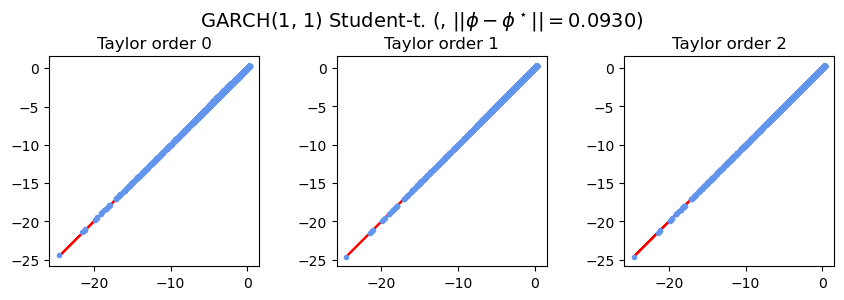

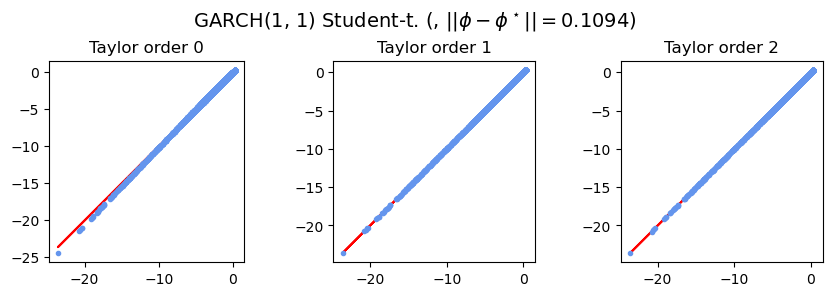

In [57]:
phiStar = MAP
args = (T, p, q, y, y_start, sigma2_start)
control_variate_dir = out_dir / "control_variates"
control_variate_dir.mkdir(parents=True, exist_ok=True)
save_path_control_variates = control_variate_dir / "control_variate_result.h5"
log_path_control_variates = control_variate_dir / "control_variate_live.log"

try:
    control_variates = load_dict_h5(save_path_control_variates)
    dens_at_phiStar = control_variates['dens_at_phiStar']
    grad_at_phiStar = control_variates['grad_at_phiStar'] 
    Hess_at_phiStar = control_variates['Hess_at_phiStar']
    end = control_variates['end']
    start = control_variates['start']
    cpu_CV = end - start

    print(dens_at_phiStar.shape)

except FileNotFoundError:
    with live_log_to_file(log_path_control_variates):
        start = time.perf_counter()
        dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar = initiate_control_variate_quantities(
            log_densities, grad_log_densities, Hess_log_densities, phiStar, args
        )
        end = time.perf_counter()
        cpu_CV = end - start
        print("==============================================================", flush=True)
        print("Elapsed time control variates initialisation with T = " , T, "p = " , p, "q = " , q,  ":", cpu_CV, "seconds", flush=True)
        print("==============================================================", flush=True)
        control_variates = {
            'dens_at_phiStar': dens_at_phiStar,
            'grad_at_phiStar': grad_at_phiStar,
            'Hess_at_phiStar': Hess_at_phiStar,
            'end': end,
            'start': start
        }
        save_dict_h5(save_path_control_variates, control_variates)

with pdf_section("05_control_variates", out_dir=out_dir) as active:

    if active:
        if log_path_control_variates.exists():
            text = log_path_control_variates.read_text(encoding="utf-8")
        else:
            text = "==============================================================\n" \
                   f"Elapsed time control variates initialisation with T = {T} p = {p} q = {q}: {cpu_CV} seconds\n" \
                   "==============================================================\n"
        pdf_add_text(text, title="Control variate construction.")

    # Precompute quantities for the control variates that do not depend on theta
    A = np.sum(dens_at_phiStar) 
    B = np.sum(grad_at_phiStar, axis = 0)
    C = np.sum(Hess_at_phiStar, axis = 0)
    # sum of control variates evaluated at phi    
    q_sum = lambda phi: A + np.dot(B, phi - phiStar) + 0.5*np.dot(phi - phiStar, np.dot(C, phi - phiStar))

    # Inspect control variate accuracy: log-densities

    # Outside median ellipse in phi space
    Sigma_pi = Cov # np.linalg.inv(Hess_obj_func_posterior(MAP))
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.50, n = 1).flatten()
    phi_beyond_median = phi
    q_k_order0 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    q_k_order1 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    q_k_order2 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    l_k = log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(l_k, l_k, color = 'red')
            if k == 0:
                axs[k].plot(l_k, q_k_order0, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(l_k, q_k_order1, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(l_k, q_k_order2, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)

    # Outside 0.999 ellipse
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.999, n = 1).flatten()
    phi_extreme = phi
    q_k_order0 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    q_k_order1 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    q_k_order2 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    l_k = log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(l_k, l_k, color = 'red')
            if k == 0:
                axs[k].plot(l_k, q_k_order0, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(l_k, q_k_order1, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(l_k, q_k_order2, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)

Tune the estimator. We recommend $R_{\max}=100$, but tune for $R_{\max}=1000, 100, 10, 1$ just to inspect.

In [58]:
t_star_frac = 0.01
t_star = int(t_star_frac* T)
b = 100.0
R_max_list = [1000, 100, 10, 1]
tuning_dir = out_dir / "tuning"
tuning_dir.mkdir(parents=True, exist_ok=True)

save_path_tuning = tuning_dir / "results_by_Rmax.h5"
log_path_tuning = tuning_dir / "tuning_live.log"

try:
    tuning_cache = load_dict_h5(save_path_tuning)
    results_by_Rmax_raw = tuning_cache["results_by_Rmax"]

    # Convert keys from str -> int
    results_by_Rmax = {int(k): v for k, v in results_by_Rmax_raw.items()}

    start = tuning_cache["start"]
    end = tuning_cache["end"]
    cpu_tuning_total = end - start

    print("==============================================================", flush=True)
    print("Loaded cached tuning results.", flush=True)
    print("Elapsed cached total tuning time:", cpu_tuning_total, "seconds", flush=True)
    print("==============================================================", flush=True)

except FileNotFoundError:
    with live_log_to_file(log_path_tuning):
        start = time.perf_counter()

        results_by_Rmax = run_calibrated_tuning_over_Rmax(
            R_max_list=R_max_list,
            MCMC_results=MCMC_results,
            MAP=MAP,
            phiStar=phiStar,
            dens_at_phiStar=dens_at_phiStar,
            grad_at_phiStar=grad_at_phiStar,
            Hess_at_phiStar=Hess_at_phiStar,
            args=args,
            T=T,
            t_star_frac=t_star_frac,
            b=b,
            m_min=2,
            pilot_slice=slice(1, 100, 5),
            verbose=True,
        )

        end = time.perf_counter()
        cpu_tuning_total = end - start

        print("==============================================================", flush=True)
        print("Elapsed total tuning time:", cpu_tuning_total, "seconds", flush=True)
        for R_max in R_max_list:
            print(
                f"R_max = {R_max}: cpu_tuning_Rmax = "
                f"{results_by_Rmax[R_max]['cpu_tuning_Rmax']:.2f} seconds",
                flush=True
            )
        print("==============================================================", flush=True)

        tuning_cache = {
            "results_by_Rmax": results_by_Rmax,
            "start": start,
            "end": end,
        }

        save_dict_h5(save_path_tuning, tuning_cache)

Loaded cached tuning results.
Elapsed cached total tuning time: 435.7612937409431 seconds


Summarise the tuning quantities. Plot constrained objective for the different $R_{\max}$ targets.

In [59]:
# Summarise and plot
for R_max in R_max_list:
    res = results_by_Rmax[R_max]

    E_umax_opt = expected_umax_safe(res['probs_opt'], res['m_opt'])

    print(
        f"R_max={R_max:>4} | "
        f"c_min={res['c_min']:.4f} | "
        f"V_target={res['V_target']:.6f} | "
        f"c_opt={res['c_opt']:.6f} | "
        f"m_opt={res['m_opt']} | "
        f"E[umax]={E_umax_opt:.4f} | "
        f"var_opt={res['var_opt']:.6f} | "
        f"bind={res['binding_ratio_final']:.6f}"
    )

results_by_Rmax_list.append(results_by_Rmax[100]) # Used for the 2 x 2 plot version of Figure 5 for all 4 models. V tol approx 2.

R_max=1000 | c_min=0.0010 | V_target=19.092620 | c_opt=0.001000 | m_opt=2 | E[umax]=135.1432 | var_opt=16.322122 | bind=0.854892
R_max= 100 | c_min=0.0100 | V_target=1.909262 | c_opt=0.010000 | m_opt=2 | E[umax]=1041.9620 | var_opt=1.632499 | bind=0.855042
R_max=  10 | c_min=0.1000 | V_target=0.190926 | c_opt=0.100000 | m_opt=2 | E[umax]=9721.7259 | var_opt=0.163237 | bind=0.854972
R_max=   1 | c_min=1.0000 | V_target=0.019093 | c_opt=1.000000 | m_opt=2 | E[umax]=66667.1667 | var_opt=0.016386 | bind=0.858218


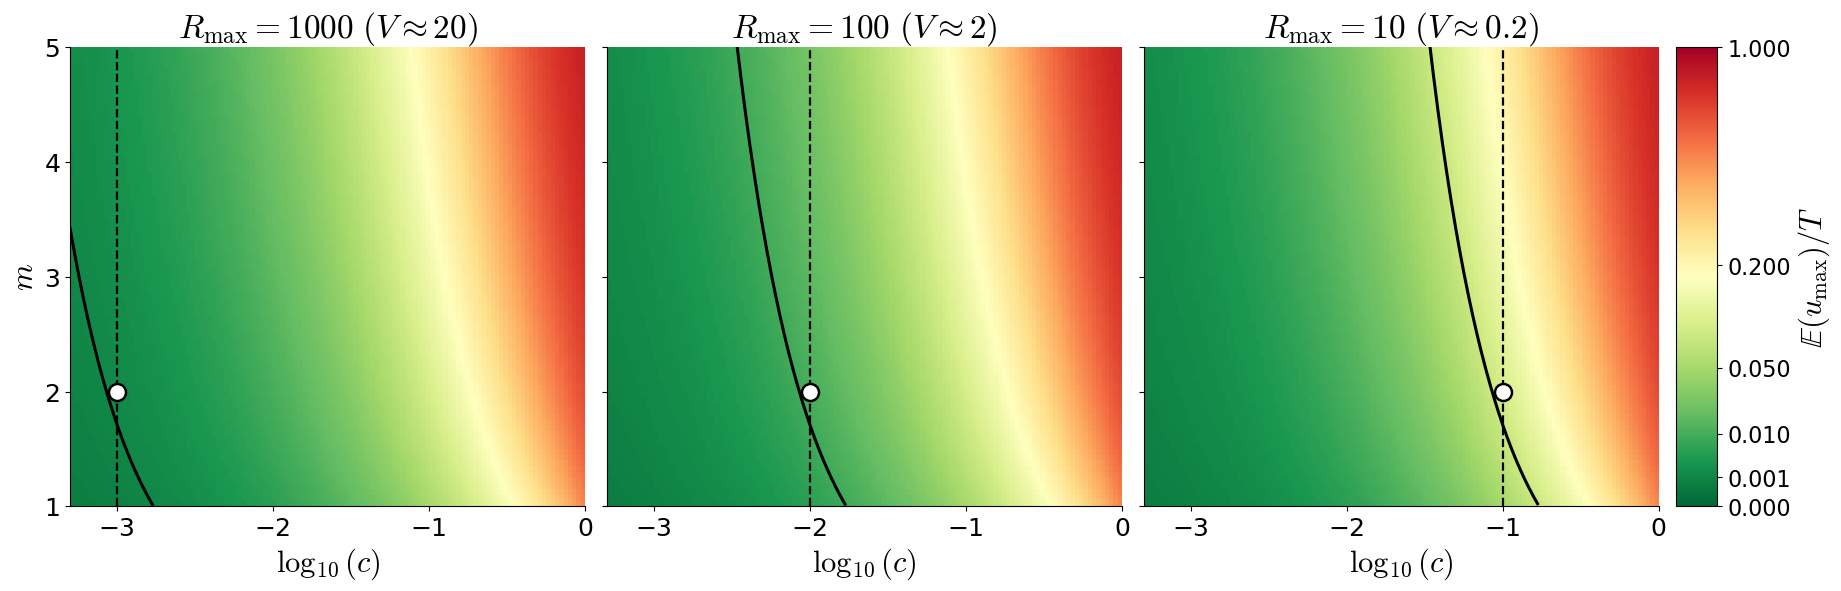

In [60]:
R_max_list = [1000, 100, 10]
V_tolerances_list = [20, 2, 0.20]

make_Rmax_triptych_from_results_Figure5(
    T=T,
    t_star=t_star,
    b=b,
    results_by_Rmax=results_by_Rmax,
    R_max_list=R_max_list,
    V_tol_list = V_tolerances_list,
    c_max=1.0,
    n_c=120,
    m_max=5,
    n_m_bg=80,
    power_gamma=0.4,
    vmax=1.0,
    marker_size=150,
    show_cmin_line=True
)

Run subsampling Markov chain Monte Carlo with TPD weights (tuned using $R_{\max}=100$).

In [61]:
# ==============================================================
# Subsampling MCMC: repeated runs with caching + per-run PDFs
# Fixed R_max = 100
# GARCH(1,1) with Student-t errors
# ==============================================================

N = 12000
R_max = 100
n_repeat = 6
key_example = "GARCH11_Student-t"

base_seed = SEEDS['App2_GARCH11_Student-t_subsampling_mcmc_Rmax100']

MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------------
# Tuned estimator parameters for subsampling MCMC
# --------------------------------------------------------------
res_tune_subsampling_MCMC = results_by_Rmax[R_max]
V_target = float(res_tune_subsampling_MCMC["V_target"])
c_opt = float(res_tune_subsampling_MCMC["c_opt"])
m_opt = int(res_tune_subsampling_MCMC["m_opt"])
gamma_opt = float(res_tune_subsampling_MCMC["gamma_opt"])

estimator_params = {
    "m_opt": m_opt,
    "c_opt": c_opt,
    "gamma_opt": gamma_opt,
    "t_star": t_star,
    "b": b,
    "V_tolerance": V_target,
    "R_max": R_max,
}

# --------------------------------------------------------------
# Fixed initial value and fixed proposal covariance
# --------------------------------------------------------------
phi_init = MAP
Cov_phi = Cov  # Negative Hessian inverse evaluated at the mode

def phi_to_psi(phi):
    return theta_to_psi(hinv(phi))

J_phi_to_psi = Jacobian_autograd(phi_to_psi)
J_map = J_phi_to_psi(MAP)
Cov_psi = J_map @ Cov_phi @ J_map.T
Cov_psi = 0.5 * (Cov_psi + Cov_psi.T)
Cov_psi = make_pos_def(Cov_psi, eps=1e-8)
prop_cov = 0.5 * 2.38**2 / n_params * Cov_psi

# --------------------------------------------------------------
# Storage across repetitions
# --------------------------------------------------------------
result_list = []
diagnostics_list = []
status_list = []
cpu_list = []
cf_list = []
seed_list = []
log_path_list = []
save_path_list = []
pdf_path_list = []

section_name = f"06_subsampling_MCMC_Rmax{R_max}"

for run in range(1, n_repeat + 1):

    seed_run = base_seed + run
    np.random.seed(seed_run)

    save_path_subsampling_MCMC = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_rep{run}.h5"
    log_path_subsampling_MCMC = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_rep{run}.log"

    pdf_suffix = f"Rmax{R_max}_rep{run}"
    safe = section_name.replace(" ", "_").replace("/", "-")
    pdf_path_run = Path(out_dir) / f"{safe}_{pdf_suffix}.pdf"

    save_path_list.append(save_path_subsampling_MCMC)
    log_path_list.append(log_path_subsampling_MCMC)
    pdf_path_list.append(pdf_path_run)
    seed_list.append(seed_run)

    try:
        subsampling_MCMC_results = load_dict_h5(save_path_subsampling_MCMC)

        result_subsampling_MCMC = subsampling_MCMC_results["MCMC_obj"]
        prop_cov_run = np.asarray(subsampling_MCMC_results["prop_cov"])
        estimator_params_run = subsampling_MCMC_results["estimator_params"]

        for key in [
            "samples_phi",
            "samples_theta",
            "log_posthat_samples",
            "sigma2_lhat_samples",
            "u_max_prop",
        ]:
            if key in result_subsampling_MCMC:
                result_subsampling_MCMC[key] = np.asarray(result_subsampling_MCMC[key])

        run_diagnostics = subsampling_MCMC_results.get("run_diagnostics", None)
        run_status = subsampling_MCMC_results.get("run_status", None)

    except FileNotFoundError:

        with live_log_to_file(log_path_subsampling_MCMC):

            print("==============================================================", flush=True)
            print(f"Running subsampling MCMC with R_max = {R_max}", flush=True)
            print(f"Repetition = {run}/{n_repeat}", flush=True)
            print(f"Seed = {seed_run}", flush=True)
            print(f"N = {N}", flush=True)
            print(f"m_opt = {m_opt}", flush=True)
            print(f"c_opt = {c_opt}", flush=True)
            print(f"gamma_opt = {gamma_opt}", flush=True)
            print(f"V_target = {V_target}", flush=True)
            print("==============================================================", flush=True)

            result_subsampling_MCMC = sample_subsampling_posterior_random_walk_stationary_proposal(
                estimator_params,
                phi_init,
                prop_cov,
                N,
                names,
                dataset_name,
                adapt=False,
            )

            print("==============================================================", flush=True)

        prop_cov_run = prop_cov
        estimator_params_run = estimator_params

        # ----------------------------------------------------------
        # Compute run diagnostics
        # ----------------------------------------------------------
        longest_streak, first_stuck_iteration = longest_immobility_streak(
            result_subsampling_MCMC["samples_theta"]
        )
        stuck_flag = (longest_streak >= 100)

        cpu_tuning_cost = results_by_Rmax[R_max]["cpu_tuning_Rmax"]
        cpu_subsampling_MCMC = result_subsampling_MCMC["run_time"] + cpu_tuning_cost
        cf_subsampling_MCMC = np.sum(result_subsampling_MCMC["u_max_prop"] + 1) + 100 * T

        acceptance_rate = np.mean(result_subsampling_MCMC["alphas_MH"])

        run_diagnostics = {
            "run": run,
            "seed": seed_run,
            "longest_immobility_streak": int(longest_streak),
            "first_stuck_iteration": (
                int(first_stuck_iteration) if first_stuck_iteration is not None else -1
            ),
            "stuck_flag": bool(stuck_flag),
            "run_time": float(result_subsampling_MCMC["run_time"]),
            "cpu_total_including_tuning": float(cpu_subsampling_MCMC),
            "compute_fraction": float(cf_subsampling_MCMC),
            "acceptance_rate": acceptance_rate,
        }

        run_status = classify_mcmc_run(longest_streak, threshold_stuck=100)

        subsampling_MCMC_results = {
            "MCMC_obj": result_subsampling_MCMC,
            "prop_cov": prop_cov_run,
            "start_value": phi_init,
            "estimator_params": estimator_params_run,
            "seed": seed_run,
            "run_diagnostics": run_diagnostics,
            "run_status": run_status,
        }
        save_dict_h5(save_path_subsampling_MCMC, subsampling_MCMC_results)

    # --------------------------------------------------------------
    # If diagnostics/status were not cached, compute them now
    # --------------------------------------------------------------
    if run_diagnostics is None or run_status is None:

        longest_streak, first_stuck_iteration = longest_immobility_streak(
            result_subsampling_MCMC["samples_theta"]
        )
        stuck_flag = (longest_streak >= 100)

        cpu_tuning_cost = results_by_Rmax[R_max]["cpu_tuning_Rmax"]
        cpu_subsampling_MCMC = result_subsampling_MCMC["run_time"] + cpu_tuning_cost
        cf_subsampling_MCMC = np.sum(result_subsampling_MCMC["u_max_prop"] + 1) + 100 * T

        acceptance_rate = np.mean(result_subsampling_MCMC["alphas_MH"])

        run_diagnostics = {
            "run": run,
            "seed": seed_run,
            "longest_immobility_streak": int(longest_streak),
            "first_stuck_iteration": (
                int(first_stuck_iteration) if first_stuck_iteration is not None else -1
            ),
            "stuck_flag": bool(stuck_flag),
            "run_time": float(result_subsampling_MCMC["run_time"]),
            "cpu_total_including_tuning": float(cpu_subsampling_MCMC),
            "compute_fraction": float(cf_subsampling_MCMC),
            "acceptance_rate": acceptance_rate,
        }

        run_status = classify_mcmc_run(longest_streak, threshold_stuck=100)

    # --------------------------------------------------------------
    # Store in summary lists
    # --------------------------------------------------------------
    result_list.append(result_subsampling_MCMC)
    diagnostics_list.append(run_diagnostics)
    status_list.append(run_status)
    cpu_list.append(run_diagnostics["cpu_total_including_tuning"])
    cf_list.append(run_diagnostics["compute_fraction"])

    # --------------------------------------------------------------
    # Per-run PDF output
    # --------------------------------------------------------------
    with pdf_section(section_name, out_dir=out_dir, suffix=pdf_suffix, overwrite=False) as active:
        if active:
            text = log_path_subsampling_MCMC.read_text(encoding="utf-8")

            summary_text = (
                f"Repetition {run}/{n_repeat}\n"
                f"Seed = {seed_run}\n"
                f"Status = {run_status}\n"
                f"Longest immobility streak = {run_diagnostics['longest_immobility_streak']}\n"
                f"First stuck iteration = {run_diagnostics['first_stuck_iteration']}\n"
                f"Acceptance rate = {run_diagnostics['acceptance_rate']}\n"
                f"Run time = {run_diagnostics['run_time']:.2f}\n"
                f"CPU incl. tuning = {run_diagnostics['cpu_total_including_tuning']:.2f}\n"
                f"Compute fraction = {run_diagnostics['compute_fraction']:.2f}\n"
            )

            pdf_add_text(
                text + "\n\n" + summary_text,
                title=f"Subsampling MCMC sampling (R_max = {R_max}, repetition {run})",
            )

            # Standard MCMC traceplots
            plot_traceplots_MCMC(
                result_subsampling_MCMC["samples_theta"],
                param_true=hinv(MAP),
                param_names=param_names,
                burnin=0,
                thin=1,
                use_median=False,
                show_running_mean=True,
                runmean_window=50,
                suptitle=f"Traceplots subsampling MCMC (R_max = {R_max}, rep {run})",
            )
            pdf_add_fig()
            plt.close("all")

            # Additional subsampling-specific diagnostics
            plot_subsampling_MCMC_quantities(result_subsampling_MCMC)
            pdf_add_fig()
            plt.close("all")

# --------------------------------------------------------------
# Save master summary object across repetitions
# --------------------------------------------------------------
subsampling_MCMC_repeated_summary = {
    "R_max": R_max,
    "N": N,
    "n_repeat": n_repeat,
    "base_seed": base_seed,
    "key_example": key_example,
    "estimator_params": estimator_params,
    "start_value": phi_init,
    "prop_cov": prop_cov,
    "seed_list": seed_list,
    "status_list": status_list,
    "diagnostics_list": diagnostics_list,
    "cpu_list": cpu_list,
    "cf_list": cf_list,
    "save_path_list": [str(x) for x in save_path_list],
    "log_path_list": [str(x) for x in log_path_list],
    "pdf_path_list": [str(x) for x in pdf_path_list],
    "n_stuck": int(np.sum([s == "stuck" for s in status_list])),
    "n_mixed_well": int(np.sum([s == "mixed_well" for s in status_list])),
}

save_path_summary = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_summary.h5"
save_dict_h5(save_path_summary, subsampling_MCMC_repeated_summary)

print("==============================================================")
print(f"Finished repeated subsampling MCMC runs for R_max = {R_max}")
print(f"n_repeat = {n_repeat}")
print(f"mixed well = {subsampling_MCMC_repeated_summary['n_mixed_well']}/{n_repeat}")
print(f"stuck = {subsampling_MCMC_repeated_summary['n_stuck']}/{n_repeat}")
print(f"Summary saved to: {save_path_summary}")
print("==============================================================")

[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep1.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep2.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep3.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep4.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep5.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep6.pdf
Finished repeated subsampling MCMC runs for R_max = 100
n_repeat = 6
mixed well = 6/6
stuck = 0/6
Summary saved to: results/App2_MCMC/GARCH11/Student-t/MCMC/subsampling_MCMC_Rmax100_N12000_summary.h5


In [62]:
# ==============================================================
# Inspect repeated subsampling MCMC diagnostics
# ==============================================================

summary_path = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_summary.h5"
summary_obj = load_dict_h5(summary_path)

diagnostics_list = summary_obj["diagnostics_list"]
status_list = summary_obj["status_list"]
seed_list = summary_obj["seed_list"]

rows = []
for d, status, seed in zip(diagnostics_list, status_list, seed_list):
    rows.append({
        "run": int(d["run"]),
        "seed": int(seed),
        "status": status,
        "longest_immobility_streak": int(d["longest_immobility_streak"]),
        "first_stuck_iteration": (
            None if int(d["first_stuck_iteration"]) < 0 else int(d["first_stuck_iteration"])
        ),
        "acceptance_rate": (
            np.nan if d["acceptance_rate"] is None else float(d["acceptance_rate"])
        ),
        "run_time": float(d["run_time"]),
        "cpu_total_including_tuning": float(d["cpu_total_including_tuning"]),
        "compute_fraction": float(d["compute_fraction"]),
    })

diag_df = pd.DataFrame(rows).sort_values("run").reset_index(drop=True)

print("==============================================================")
print("Repeated subsampling MCMC diagnostics")
print("==============================================================")
print(diag_df.to_string(index=False))

print("\n==============================================================")
print("Aggregate summaries")
print("==============================================================")
print(f"Number of runs: {len(diag_df)}")
print(f"Status counts:\n{diag_df['status'].value_counts(dropna=False)}")
print()
print("Longest immobility streak:")
print(f"  min    = {diag_df['longest_immobility_streak'].min()}")
print(f"  median = {diag_df['longest_immobility_streak'].median()}")
print(f"  max    = {diag_df['longest_immobility_streak'].max()}")

if diag_df["acceptance_rate"].notna().any():
    print()
    print("Acceptance rate:")
    print(f"  min    = {diag_df['acceptance_rate'].min():.4f}")
    print(f"  median = {diag_df['acceptance_rate'].median():.4f}")
    print(f"  max    = {diag_df['acceptance_rate'].max():.4f}")

print()
print("Runtime:")
print(f"  min    = {diag_df['run_time'].min():.2f}")
print(f"  median = {diag_df['run_time'].median():.2f}")
print(f"  max    = {diag_df['run_time'].max():.2f}")

print()
print("Compute fraction:")
print(f"  min    = {diag_df['compute_fraction'].min():.2f}")
print(f"  median = {diag_df['compute_fraction'].median():.2f}")
print(f"  max    = {diag_df['compute_fraction'].max():.2f}")
print("==============================================================")

Repeated subsampling MCMC diagnostics
 run  seed     status  longest_immobility_streak first_stuck_iteration  acceptance_rate   run_time  cpu_total_including_tuning  compute_fraction
   1 78902 mixed_well                         16                  None         0.429356 288.678734                  408.897209        23584371.0
   2 78903 mixed_well                         17                  None         0.431775 284.296840                  404.515315        22721918.0
   3 78904 mixed_well                         16                  None         0.434608 242.188187                  362.406662        21285085.0
   4 78905 mixed_well                         15                  None         0.432351 297.929281                  418.147756        22519814.0
   5 78906 mixed_well                         17                  None         0.435188 259.339077                  379.557552        21311136.0
   6 78907 mixed_well                         19                  None         0.434301 269.

Before computing log predictive score, show limitations of subsampling MCMC with uniform subsampling.

Chains for GARCH($1,1$) with Student-$t$ errors.

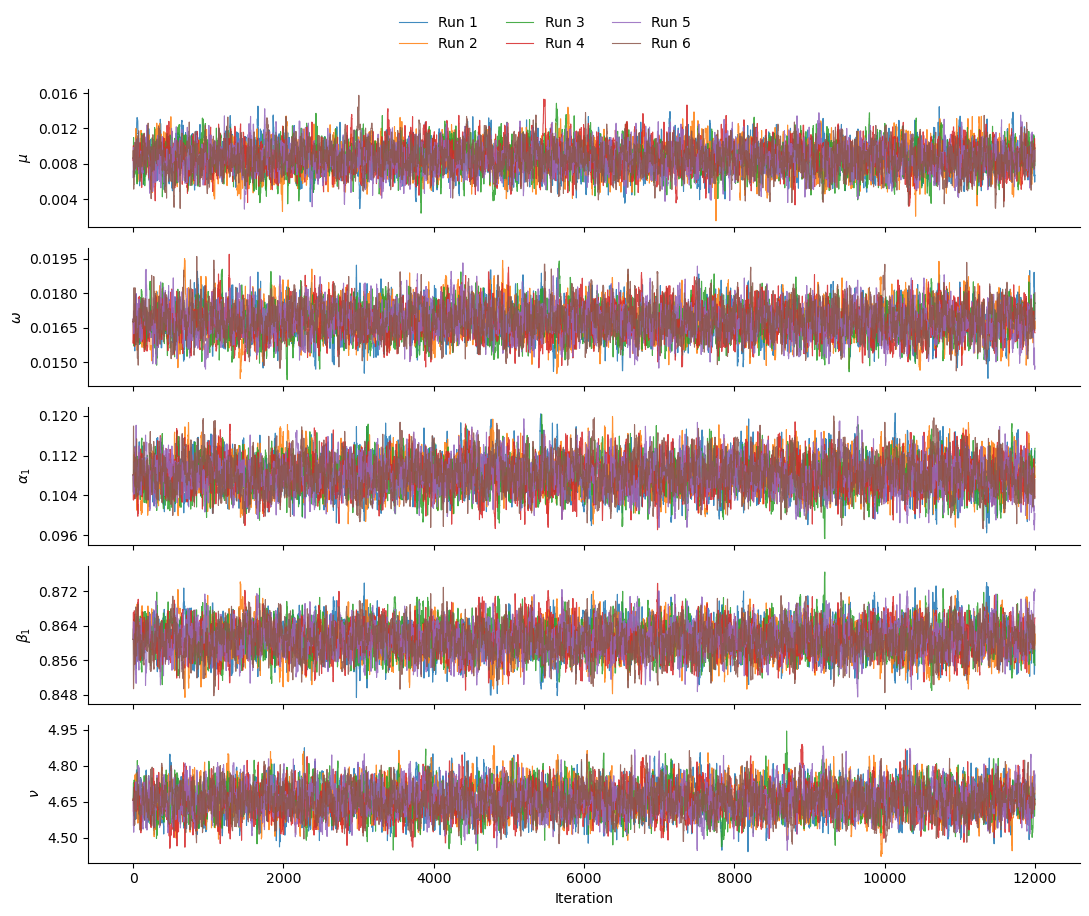

In [63]:
chains = [r['samples_theta'] for r in result_list]
chain_labels = [f"Run {i+1}" for i in range(6)]

fig, axes = plot_traceplots_MCMC_chains(
    param_draws=chains,
    param_names=param_names,
    chain_labels=chain_labels,
    burnin=0,
    thin=1,
    show_running_mean=False
)

Show the limitations of uniform sampling. The following chain gets stuck. If we rerun with $m_{\mathrm{opt}}=30$, the chain will mix well (not shown here).

In [64]:
np.random.seed(SEEDS['App2_GARCH11_Student-t_subsampling_mcmc_Rmax100']) # Use same seed as R_max = 100 case.

N = 12000
R_max = 1
key_example = "GARCH11_Student-t"

# Save estimator params for subsampling MCMC
res_tune_subsampling_MCMC = results_by_Rmax[R_max]
V_target = float(res_tune_subsampling_MCMC["V_target"])
c_opt = float(res_tune_subsampling_MCMC["c_opt"])
m_opt = int(res_tune_subsampling_MCMC["m_opt"])
gamma_opt = float(res_tune_subsampling_MCMC["gamma_opt"])

estimator_params = {
    "m_opt": m_opt,
    "c_opt": c_opt,
    "gamma_opt": gamma_opt,
    "t_star": t_star,
    "b": b,
    "V_tolerance": V_target,
    "R_max": R_max
}

phi_init = MAP
Cov_phi = Cov  # Negative Hessian inverse evaluated at the mode

# Transform to Psi by linearising
def phi_to_psi(phi):
    return theta_to_psi(hinv(phi))

J_phi_to_psi = Jacobian_autograd(phi_to_psi)
J_map = J_phi_to_psi(MAP)
Cov_psi = J_map @ Cov_phi @ J_map.T
Cov_psi = 0.5 * (Cov_psi + Cov_psi.T)
Cov_psi = make_pos_def(Cov_psi, eps=1e-8)
prop_cov = 0.5 * 2.38**2 / n_params * Cov_psi

MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)

save_path_subsampling_MCMC = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}.h5"
log_path_subsampling_MCMC = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}.log"

try:
    subsampling_MCMC_results = load_dict_h5(save_path_subsampling_MCMC)
    result_subsampling_MCMC_R_max1 = subsampling_MCMC_results["MCMC_obj"]
    prop_cov = np.asarray(subsampling_MCMC_results["prop_cov"])
    estimator_params = subsampling_MCMC_results["estimator_params"]

    # Convert back to arrays where needed
    for key in [
        "samples_phi",
        "samples_theta",
        "log_posthat_samples",
        "sigma2_lhat_samples",
        "u_max_prop"
    ]:
        if key in result_subsampling_MCMC_R_max1:
            result_subsampling_MCMC_R_max1[key] = np.asarray(result_subsampling_MCMC_R_max1[key])

except FileNotFoundError:

    with live_log_to_file(log_path_subsampling_MCMC):

        print("==============================================================", flush=True)
        print(f"Running subsampling MCMC with R_max = {R_max}", flush=True)
        print(f"N = {N}", flush=True)
        print(f"m_opt = {m_opt}", flush=True)
        print(f"c_opt = {c_opt}", flush=True)
        print(f"gamma_opt = {gamma_opt}", flush=True)
        print(f"V_target = {V_target}", flush=True)
        print("==============================================================", flush=True)

        result_subsampling_MCMC_R_max1 = sample_subsampling_posterior_random_walk_stationary_proposal(
            estimator_params,
            phi_init,
            prop_cov,
            N,
            names,
            dataset_name,
            adapt=False
        )

        print("==============================================================", flush=True)

        subsampling_MCMC_results = {
            "MCMC_obj": result_subsampling_MCMC_R_max1,
            "prop_cov": prop_cov,
            "start_value": phi_init,
            "estimator_params": estimator_params
        }
        save_dict_h5(save_path_subsampling_MCMC, subsampling_MCMC_results)

cpu_tuning_cost__GARCH11_App2_normal = results_by_Rmax[R_max]["cpu_tuning_Rmax"]
cpu_subsampling_MCMC =  result_subsampling_MCMC_R_max1['run_time'] + cpu_tuning_cost__GARCH11_App2_normal
cf_subsampling_MCMC = np.sum(result_subsampling_MCMC_R_max1['u_max_prop'] + 1) + 100*T # 100 pilot run

# ==============================================================
# PDF output
# ==============================================================

with pdf_section(f"06_subsampling_MCMC_Rmax{R_max}", out_dir=out_dir) as active:
    if active:
        text = log_path_subsampling_MCMC.read_text(encoding="utf-8")
        pdf_add_text(
            text,
            title=f"Subsampling MCMC sampling (R_max = {R_max})."
        )

        # Standard MCMC traceplots
        plot_traceplots_MCMC(
            result_subsampling_MCMC_R_max1['samples_theta'],
            param_true=hinv(MAP),
            param_names=param_names,
            burnin=0,
            thin=1,
            use_median=False,
            show_running_mean=True,
            runmean_window=50,
            suptitle=f"Traceplots subsampling MCMC (R_max = {R_max})"
        )
        pdf_add_fig()
        plt.close("all")

        # Additional subsampling-specific diagnostics
        plot_subsampling_MCMC_quantities(result_subsampling_MCMC_R_max1)
        pdf_add_fig()
        plt.close("all")

[pdf_section] Exists, skipping: results/App2_MCMC/GARCH11/Student-t/06_subsampling_MCMC_Rmax1.pdf


Illustrate the sampling distributions at $\boldsymbol{\phi}^{\dagger}$.

In [65]:
n_rep_sampling_dist = 10000
sampling_dist_dir = Path("results") / app / model / error_type / "sampling distributions"
sampling_dist_dir.mkdir(parents=True, exist_ok=True)
out_file = sampling_dist_dir / f"results_nrep{n_rep_sampling_dist}_diag.h5"

phi_eval = results_by_Rmax[1]['phi_cross'] # phi to tune at

results_by_Rmax = convert_to_numpy(results_by_Rmax)

try:
    print("Loading existing results...")
    results_diag = load_dict_h5(out_file)

    res_uniform = convert_to_numpy(results_diag["res_uniform"])
    res_uniform_m30 = convert_to_numpy(results_diag["res_uniform_m30"])
    res_tpd = convert_to_numpy(results_diag["res_tpd"])

except Exception as e:
    print("No saved results found. Running simulations...")
    print(f"Reason: {e}")

    phi_eval = results_by_Rmax[1]['phi_cross']

    # Uniform m = 2 (optimal)
    res_uniform = simulate_loglik_diagnostics_at_phi(
        phi_eval=phi_eval,
        probs=results_by_Rmax[1]['probs_opt'],
        m_opt=results_by_Rmax[1]['m_opt'],
        T=T,
        p=p,
        q=q,
        y=y,
        y_start=y_start,
        sigma2_start=sigma2_start,
        phiStar=phiStar,
        dens_at_phiStar=dens_at_phiStar,
        grad_at_phiStar=grad_at_phiStar,
        Hess_at_phiStar=Hess_at_phiStar,
        n_rep=n_rep_sampling_dist,
        seed=123
    )

    # Uniform m = 30
    res_uniform_m30 = simulate_loglik_diagnostics_at_phi(
        phi_eval=phi_eval,
        probs=results_by_Rmax[1]['probs_opt'],
        m_opt=30,
        T=T,
        p=p,
        q=q,
        y=y,
        y_start=y_start,
        sigma2_start=sigma2_start,
        phiStar=phiStar,
        dens_at_phiStar=dens_at_phiStar,
        grad_at_phiStar=grad_at_phiStar,
        Hess_at_phiStar=Hess_at_phiStar,
        n_rep=n_rep_sampling_dist,
        seed=123
    )

    # TPD
    res_tpd = simulate_loglik_diagnostics_at_phi(
        phi_eval=phi_eval,
        probs=results_by_Rmax[100]['probs_opt'],
        m_opt=results_by_Rmax[100]['m_opt'],
        T=T,
        p=p,
        q=q,
        y=y,
        y_start=y_start,
        sigma2_start=sigma2_start,
        phiStar=phiStar,
        dens_at_phiStar=dens_at_phiStar,
        grad_at_phiStar=grad_at_phiStar,
        Hess_at_phiStar=Hess_at_phiStar,
        n_rep=n_rep_sampling_dist,
        seed=123
    )

    results_diag = {
        "res_uniform": res_uniform,
        "res_uniform_m30": res_uniform_m30,
        "res_tpd": res_tpd,
    }

    save_dict_h5(out_file, results_diag)
    print("Results saved.")


Loading existing results...


Summarise and plot the sampling distributions

In [66]:
summarise_loglik_diagnostics(res_uniform, label="uniform m = 2")
summarise_loglik_diagnostics(res_uniform_m30, label="uniform m = 30")
summarise_loglik_diagnostics(res_tpd, label="TPD")

Diagnostics for uniform m = 2
True log-likelihood                     : -93700.358769
True variance of log-likelihood est.    : 0.016386
MC variance of log-likelihood est.      : 0.016874
Mean estimated sigma2_hat               : 0.016565
Median estimated sigma2_hat             : 0.004100

Error in log-likelihood estimator, lhat - ltrue
  mean                                  : -0.001383
  std                                   : 0.129899
  1%, 5%, 50%, 95%, 99% quantiles       : [-0.41619251 -0.24499309  0.01405549  0.17363817  0.26723189]

Error in corrected log-likelihood, zhat - ltrue
  mean                                  : -0.009666
  std                                   : 0.138261
  1%, 5%, 50%, 95%, 99% quantiles       : [-0.46472927 -0.27248777  0.01062313  0.16890033  0.25571169]

u_max / T diagnostics
  mean                                  : 66895.413700
  median                                : 70981.000000
  95%, 99%, 99.9% quantiles             : [97547.    99502.07  99

The following code creates Figure S7 in the paper.

/tmp/ipykernel_199248/3511298424.py:1363: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


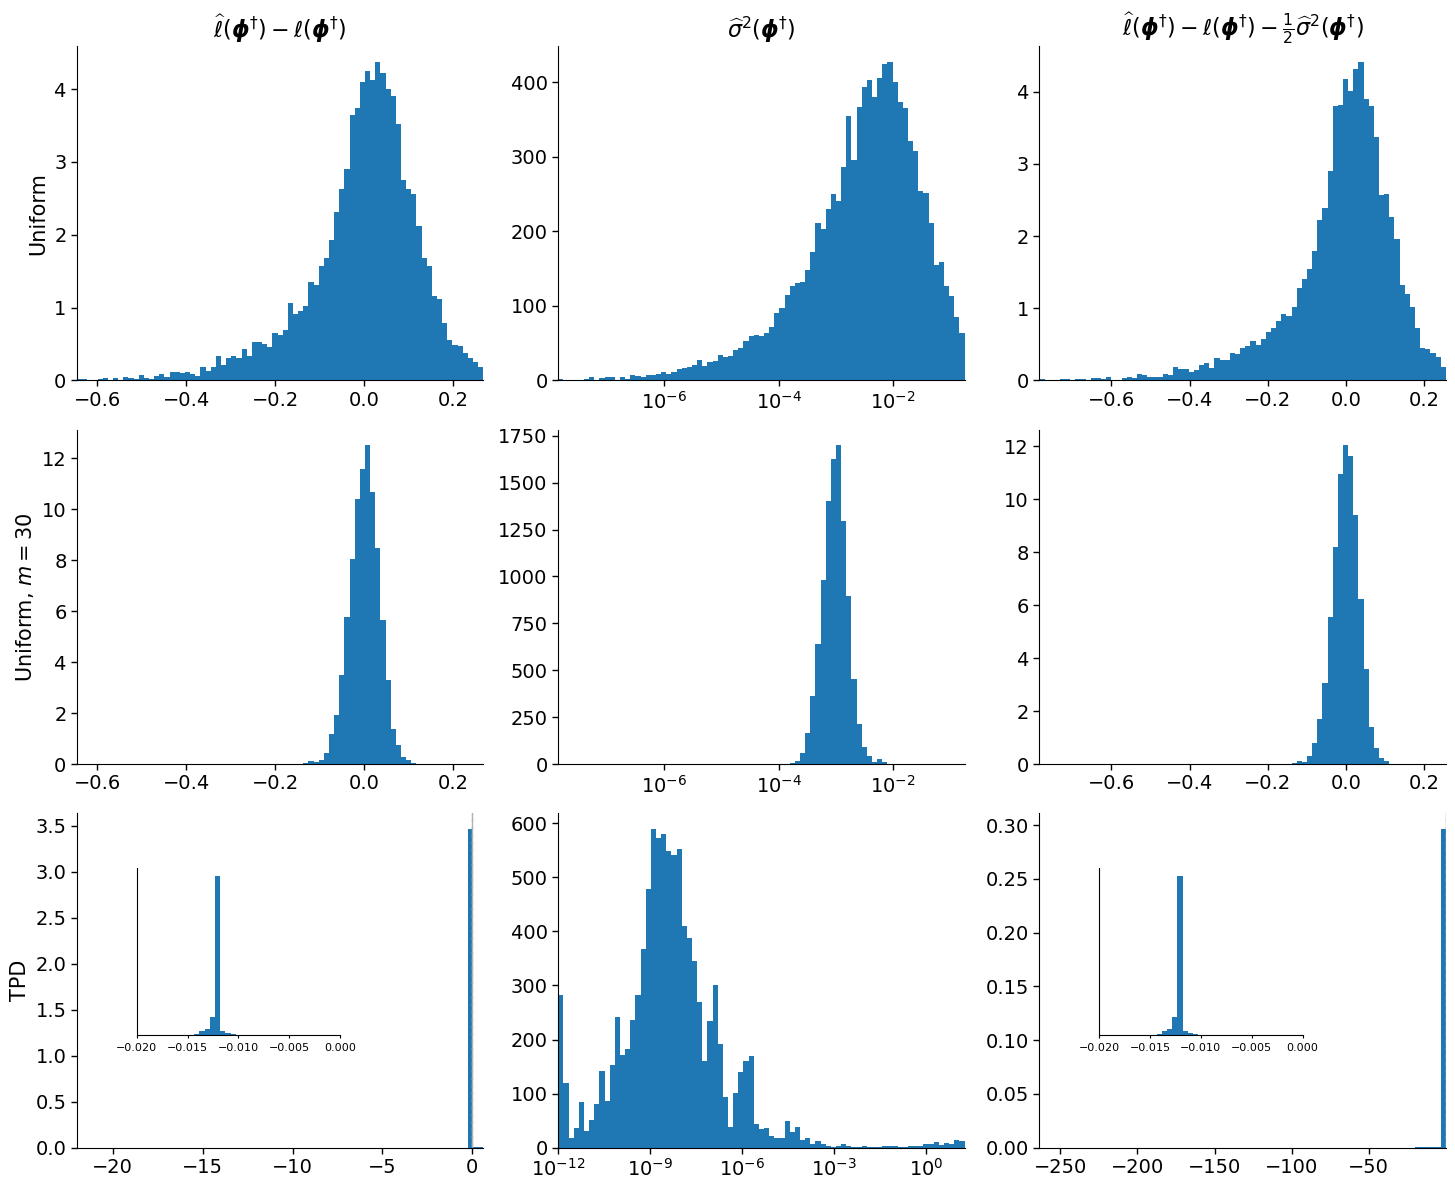

In [67]:
plot_loglik_diagnostics_final(
    res_uniform = res_uniform,
    res_uniform_m30 = res_uniform_m30,
    res_tpd = res_tpd,
    T=T,
    bins=80,
    bulk_q=(0.001, 0.99))

The following code produces Table S3 in the paper.

In [68]:
# -------------------------
# Build compact table
# -------------------------
def build_quantile_table_compact(res_uniform, res_uniform_m30, res_tpd):

    err_label = r"$\mathrm{err}(\boldsymbol{\phi}^{\dagger})$"
    sig_label = r"$\widehat{\sigma}^2(\boldsymbol{\phi}^{\dagger})$"

    def make_row(vals, sigma):
        return {
            (err_label, "min"): np.min(vals),
            (err_label, "0.01"): np.quantile(vals, 0.01),
            (err_label, "0.05"): np.quantile(vals, 0.05),
            (err_label, "0.95"): np.quantile(vals, 0.95),
            (err_label, "0.99"): np.quantile(vals, 0.99),
            (err_label, "max"): np.max(vals),
            (err_label, r"$\Pr(\mathrm{err}>0)$"): np.mean(vals > 0),
            (sig_label, "median"): np.median(sigma),
            (sig_label, "max"): np.max(sigma),
        }

    # Actual rows
    row_u2  = make_row(np.asarray(res_uniform["loglik_errors"]),
                       np.asarray(res_uniform["sigma2_lhats"]))

    row_u30 = make_row(np.asarray(res_uniform_m30["loglik_errors"]),
                       np.asarray(res_uniform_m30["sigma2_lhats"]))

    row_tpd = make_row(np.asarray(res_tpd["loglik_errors"]),
                       np.asarray(res_tpd["sigma2_lhats"]))

    # Empty row for "Uniform"
    empty_row = {k: "" for k in row_u2.keys()}

    df = pd.DataFrame(
        [empty_row, row_u2, row_u30, row_tpd],
        index=["Uniform", r"$m=2$", r"$m=30$", "TPD"]
    )

    df.columns = pd.MultiIndex.from_tuples(df.columns)

    return df


# -------------------------
# Format numbers nicely
# -------------------------
def format_table(df):

    def formatter(x):
        if isinstance(x, (float, np.floating)):
            if x == 0:
                return "0.000"
            if 0 < abs(x) < 1:
                return f"{x:.3f}"
            return f"{x:.2e}"
        return x

    return df.map(formatter)


# -------------------------
# Generate LaTeX and merge Uniform rows
# -------------------------
def table_to_latex(df):
    latex = df.to_latex(
        multicolumn=True,
        multirow=False,
        escape=False,
        column_format="l" + "c" * df.shape[1]
    )

    lines = latex.splitlines()

    # Find the lines for m=2 and m=30 and replace them
    for i, line in enumerate(lines):
        if line.startswith("m=2 "):
            lines[i] = line.replace("m=2", r"\multirow{2}{*}{Uniform} \\[-0.2em] $m=2$", 1)
        elif line.startswith("m=30 "):
            lines[i] = line.replace("m=30", r"$m=30$", 1)

    return "\n".join(lines)


# -------------------------
# Run everything
# -------------------------
df = build_quantile_table_compact(res_uniform, res_uniform_m30, res_tpd)
df_fmt = format_table(df)
latex_table = table_to_latex(df_fmt)

print(latex_table)



\begin{tabular}{lccccccccc}
\toprule
 & \multicolumn{7}{r}{$\mathrm{err}(\boldsymbol{\phi}^{\dagger})$} & \multicolumn{2}{r}{$\widehat{\sigma}^2(\boldsymbol{\phi}^{\dagger})$} \\
 & min & 0.01 & 0.05 & 0.95 & 0.99 & max & $\Pr(\mathrm{err}>0)$ & median & max \\
\midrule
Uniform &  &  &  &  &  &  &  &  &  \\
$m=2$ & -0.793 & -0.416 & -0.245 & 0.174 & 0.267 & 1.03e+00 & 0.557 & 0.004 & 1.17e+00 \\
$m=30$ & -0.135 & -0.079 & -0.055 & 0.052 & 0.075 & 0.121 & 0.514 & 0.001 & 0.008 \\
TPD & -3.82e+01 & -0.030 & -0.013 & -0.012 & 0.608 & 1.97e+01 & 0.014 & 0.000 & 1.46e+03 \\
\bottomrule
\end{tabular}


The following code produces Figure S8 in the paper.

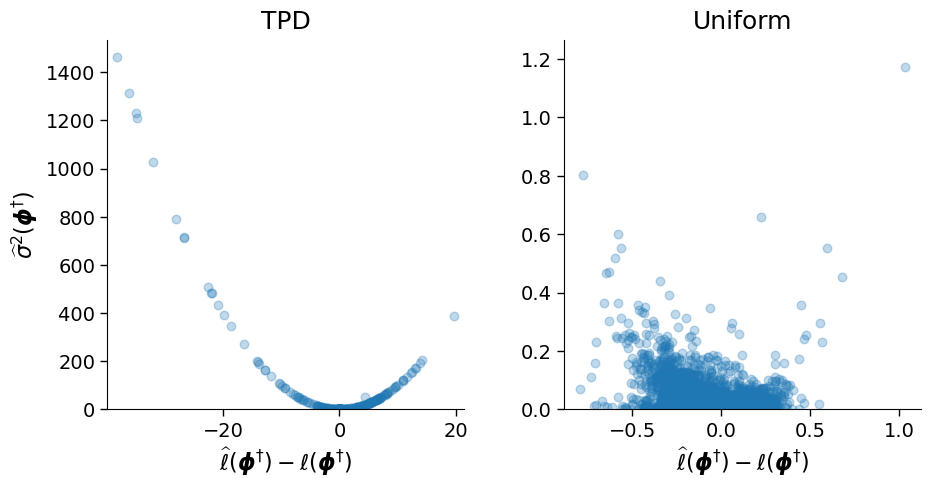

In [69]:
# Data
x_tpd = np.asarray(res_tpd['loglik_errors'])
y_tpd = np.asarray(res_tpd['sigma2_lhats'])

x_uni = np.asarray(res_uniform['loglik_errors'])
y_uni = np.asarray(res_uniform['sigma2_lhats'])

# Figure
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8), sharex=False, sharey=False)

# --------------------
# Left panel: TPD
# --------------------
axes[0].scatter(
    x_tpd, y_tpd,
    s=38, alpha=0.28
)

axes[0].set_title("TPD", fontsize=18, pad=8)
axes[0].set_xlabel(
    r"$\widehat{\ell}(\boldsymbol{\phi}^{\dagger}) - \ell(\boldsymbol{\phi}^{\dagger})$",
    fontsize=16
)
axes[0].set_ylabel(
    r"$\widehat{\sigma}^{2}(\boldsymbol{\phi}^{\dagger})$",
    fontsize=16
)

# Optional: tighten limits slightly with a small margin
xpad_tpd = 0.03 * (x_tpd.max() - x_tpd.min())
ypad_tpd = 0.05 * (y_tpd.max() - y_tpd.min())
axes[0].set_xlim(x_tpd.min() - xpad_tpd, x_tpd.max() + xpad_tpd)
axes[0].set_ylim(max(0, y_tpd.min() - ypad_tpd), y_tpd.max() + ypad_tpd)

# --------------------
# Right panel: Uniform
# --------------------
axes[1].scatter(
    x_uni, y_uni,
    s=38, alpha=0.28
)

axes[1].set_title("Uniform", fontsize=18, pad=8)
axes[1].set_xlabel(
    r"$\widehat{\ell}(\boldsymbol{\phi}^{\dagger}) - \ell(\boldsymbol{\phi}^{\dagger})$",
    fontsize=16
)

xpad_uni = 0.05 * (x_uni.max() - x_uni.min())
ypad_uni = 0.08 * (y_uni.max() - y_uni.min())
axes[1].set_xlim(x_uni.min() - xpad_uni, x_uni.max() + xpad_uni)
axes[1].set_ylim(max(0, y_uni.min() - ypad_uni), y_uni.max() + ypad_uni)

# --------------------
# Styling
# --------------------
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=14,
        direction="out",
        length=5,
        width=1.0
    )
    ax.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.subplots_adjust(wspace=0.28)
plt.show()

The following code produces Table S4 in the paper.

In [70]:
rows = [
    conditional_sigma_summary(res_tpd[ 'loglik_errors'], res_tpd[ 'sigma2_lhats'], "TPD"),
    conditional_sigma_summary(res_uniform[ 'loglik_errors'], res_uniform[ 'sigma2_lhats'], "Uniform"),
]

df = pd.DataFrame(rows)

# Select and format columns
df_table = df[[
    "Scheme",
    r"Corr(|err|, sigma2_hat)",
    r"E[sigma2_hat | err > 0]",
    r"E[sigma2_hat | err <= 0]",
    r"Pr(err > 0)"
]].copy()

df_table[r"Corr(|err|, sigma2_hat)"] = df_table[r"Corr(|err|, sigma2_hat)"].map("{:.3f}".format)
df_table[r"E[sigma2_hat | err > 0]"] = df_table[r"E[sigma2_hat | err > 0]"].map("{:.2f}".format)
df_table[r"E[sigma2_hat | err <= 0]"] = df_table[r"E[sigma2_hat | err <= 0]"].map("{:.2f}".format)
df_table[r"Pr(err > 0)"] = df_table[r"Pr(err > 0)"].map("{:.3f}".format)

# Rename to LaTeX
df_table.columns = [
    "Scheme",
    r"$\mathrm{Corr}(|\mathrm{err}|,\widehat{\sigma}^2)$",
    r"$\mathbb{E}(\widehat{\sigma}^2 \mid \mathrm{err} > 0)$",
    r"$\mathbb{E}(\widehat{\sigma}^2 \mid \mathrm{err} \le 0)$",
    r"$\Pr(\mathrm{err} > 0)$"
]

# Export to LaTeX
latex_table = df_table.to_latex(index=False, escape=False, column_format="lcccc")

print(latex_table)

\begin{tabular}{lcccc}
\toprule
Scheme & $\mathrm{Corr}(|\mathrm{err}|,\widehat{\sigma}^2)$ & $\mathbb{E}(\widehat{\sigma}^2 \mid \mathrm{err} > 0)$ & $\mathbb{E}(\widehat{\sigma}^2 \mid \mathrm{err} \le 0)$ & $\Pr(\mathrm{err} > 0)$ \\
\midrule
TPD & 0.895 & 32.14 & 1.40 & 0.014 \\
Uniform & 0.546 & 0.01 & 0.03 & 0.557 \\
\bottomrule
\end{tabular}



Compute the log-predictive score for the test data using subsampling MCMC.

In [71]:
result_subsampling_MCMC_R_max100 = result_list[0]
result_garch11_Student_t = result_list[0]

# Compute joint out-of-sample predictive score
y_test = np.load("data/AAPL_10000obs.npy")
y_test = y_test/series.std()

# Evaluate model
evaluate_dir = out_dir / "evaluate"
evaluate_dir.mkdir(parents=True, exist_ok=True)
save_path_evaluate = evaluate_dir / ("log_pred_score.h5")
log_path_evaluate = evaluate_dir / ("evaluate_score.log")

samples_theta = result_subsampling_MCMC_R_max100["samples_theta"][2001::100] 

try:
    log_predictive_results = load_dict_h5(save_path_evaluate)
    log_pred = log_predictive_results['log_scores']
    S = log_predictive_results['sum_log_scores']

except FileNotFoundError:

    with live_log_to_file(log_path_evaluate):

        # Compute the log-predictive score
        print("==============================================================", flush=True)
        S, log_pred = joint_predictive_score(samples_theta, y, y_test, p, q, y_start, sigma2_start, log_densities)
        print(f"p={p}, q={q}, error={error_type}, log_pred score sum = {S}")
        print("==============================================================", flush=True)
        log_predictive_results = {'sum_log_scores': S, 'log_scores': log_pred}
        save_dict_h5(save_path_evaluate, log_predictive_results)


mc_summary = predictive_score_mc_ci(log_pred)
print("Joint predictive score:", mc_summary["score_hat"])
print("MC standard error:", mc_summary["se"])
print("Approx. 95% CI: ({:.6f}, {:.6f})".format(
    mc_summary["ci_lower"], mc_summary["ci_upper"]
))
print("IACT:", mc_summary["tau_int"])
print("ESS:", mc_summary["ess"])




Joint predictive score: -9225.267719652342
MC standard error: 0.744504308673506
Approx. 95% CI: (-9226.726921, -9223.808518)
IACT: 1.0
ESS: 100.0


Full-data Markov chain Monte Carlo.

In [72]:
np.random.seed(SEEDS["App2_GARCH11_Student-t_full_data_mcmc"])
N = 12000
MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)
save_path_MCMC = MCMC_dir / ("Full_data_MCMC_N%s.h5" % N)
log_path_MCMC = MCMC_dir / ("Full_data_MCMC_N%s.log" % N)

try:
    MCMC_results = load_dict_h5(save_path_MCMC)
    full_data_MCMC = MCMC_results['MCMC_obj']
    prop_cov = MCMC_results['prop_cov']
    # Convert back to arrays
    for key in ["samples_phi", "samples_theta"]:
        full_data_MCMC[key] = np.asarray(full_data_MCMC[key])

except FileNotFoundError:

    with live_log_to_file(log_path_MCMC):

        # Run MCMC (proposal parameterised to obey stationarity)
        # Transform to Psi by linearising
        def phi_to_psi(phi):
            return theta_to_psi(hinv(phi))

        J_phi_to_psi = Jacobian_autograd(phi_to_psi)
        J_map = J_phi_to_psi(MAP)
        Cov_phi = Cov
        Cov_psi = J_map @ Cov_phi @ J_map.T
        Cov_psi = 0.5 * (Cov_psi + Cov_psi.T)
        Cov_psi = make_pos_def(Cov_psi, eps=1e-8)
        prop_cov = 0.1*2.38**2 / n_params * Cov_psi
        phi_init = MAP 
        print("==============================================================", flush=True)
        full_data_MCMC = sample_full_data_posterior_AM_stationary_proposal(phi_init, prop_cov, N, names,dataset_name, adapt_cov=True, adapt_scale=True, burn_in = 1000)
        print("==============================================================", flush=True)        

        MCMC_results = {'MCMC_obj': full_data_MCMC, 'prop_cov': prop_cov, 'start_value': phi_init}
        save_dict_h5(save_path_MCMC, MCMC_results)

    with pdf_section("07_full_data_MCMC", out_dir=out_dir) as active:
        if active:
            text = log_path_MCMC.read_text(encoding="utf-8")
            pdf_add_text(text, title="Full data MCMC sampling.")

            plot_traceplots_MCMC(
                full_data_MCMC['samples_phi'],
                param_true=MAP, param_names=trans_param_names,
                burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
                suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
            )
            pdf_add_fig()          # saves all figures created by plot_traceplots_MCMC
            plt.close("all")       

Predictive score full-data MCMC

In [73]:
# Evaluate model
evaluate_dir = out_dir / "evaluate"
evaluate_dir.mkdir(parents=True, exist_ok=True)
save_path_evaluate = evaluate_dir / ("log_pred_score_full_data.h5")
log_path_evaluate = evaluate_dir / ("evaluate_score_full_data.log")

samples_theta = full_data_MCMC["samples_theta"][2001::100] # 

try:
    log_predictive_results = load_dict_h5(save_path_evaluate)
    log_pred = log_predictive_results['log_scores']
    S = log_predictive_results['sum_log_scores']

except FileNotFoundError:

    with live_log_to_file(log_path_evaluate):

        # Compute the log-predictive score
        print("==============================================================", flush=True)
        S, log_pred = joint_predictive_score(samples_theta, y, y_test, p, q, y_start, sigma2_start, log_densities)
        print(f"p={p}, q={q}, error={error_type}, log_pred score sum = {S}")
        print("==============================================================", flush=True)
        log_predictive_results = {'sum_log_scores': S, 'log_scores': log_pred}
        save_dict_h5(save_path_evaluate, log_predictive_results)



mc_summary_full_data = predictive_score_mc_ci(log_pred)
print("Predictive score with full_data MCMC")
print("Joint predictive score:", mc_summary_full_data["score_hat"])
print("MC standard error:", mc_summary_full_data["se"])
print("Approx. 95% CI: ({:.6f}, {:.6f})".format(
    mc_summary_full_data["ci_lower"], mc_summary_full_data["ci_upper"]
))
print("IACT:", mc_summary_full_data["tau_int"])
print("ESS:", mc_summary_full_data["ess"])

Predictive score with full_data MCMC
Joint predictive score: -9225.902936577095
MC standard error: 0.38020941316821155
Approx. 95% CI: (-9226.648133, -9225.157740)
IACT: 1.0
ESS: 100.0


Save to create tables for subsampling MCMC results and predictive scores.

In [74]:
tables_GARCH11_Student_t = make_model_summary_for_tables(
    model_label="GARCH(1,1), Student-t",
    subsampling_summary=subsampling_MCMC_repeated_summary,
    cpu_cv=cpu_CV,
    full_data_MCMC=full_data_MCMC,
    predictive_summary_subsampling=mc_summary,
    predictive_summary_full_data=mc_summary_full_data,
    comment="stable baseline"
)

Compare accuracy toward full-data MCMC and also effective sample size (ESS).

(<Figure size 1200x600 with 5 Axes>,
 array([<Axes: xlabel='$\\mu$'>, <Axes: xlabel='$\\omega$'>,
        <Axes: xlabel='$\\alpha_1$'>, <Axes: xlabel='$\\beta_1$'>,
        <Axes: xlabel='$\\nu$'>, <Axes: >], dtype=object),
 array([[399.94150686, 549.04342526, 416.08480831, 403.49930943,
         494.22018345],
        [379.8774266 , 183.70797751, 149.80148276, 272.55107036,
         310.69863225]]))

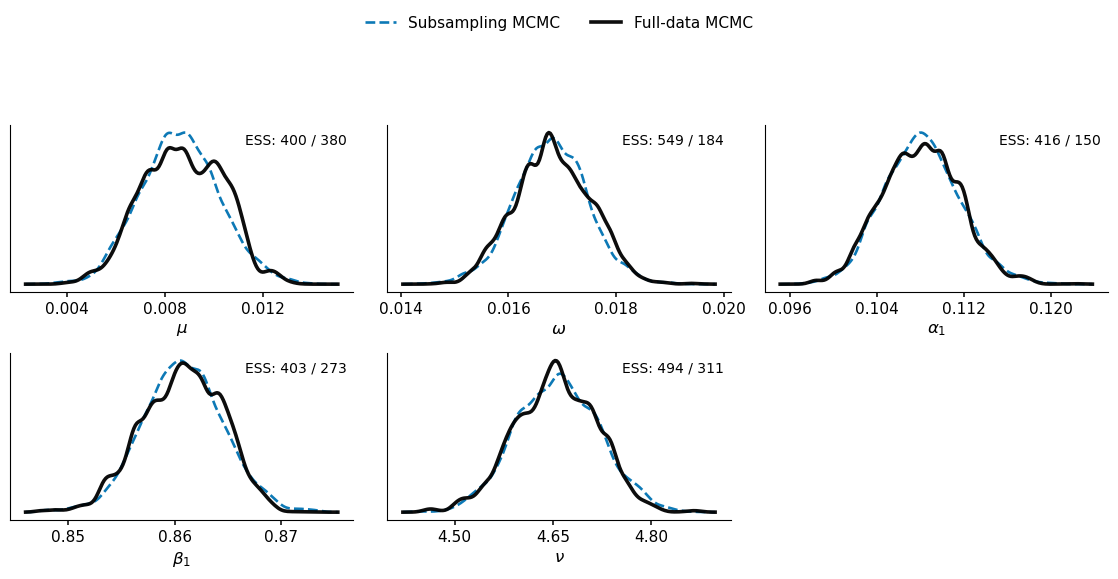

In [75]:
plot_kde_with_ESS_comparison(
            result_subsampling_MCMC_R_max100["samples_theta"][2000:, :],
            full_data_MCMC['samples_theta'][2000:, :],
            param_names=param_names,
            title="Posterior marginals (phi): Subsampling MCMC vs MCMC",
            n_points=200,
            true_vals=None,
            labels=("Subsampling MCMC", "Full-data MCMC"),
            ess_fmt="compact"
        )

### 3.3 TGARCH(1, 1) with Student-t errors

Extend the model with threshold effects.

Define settings and optimise.

[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH11/Student-t/01_settings_and_data_plot.pdf
GARCH_type: TGARCH , Error distribution: Student-t
Lags: p =,  1 q =  1
Dataset name:  AAPL_TGARCH(1,1)_Student-t_error
Number of observations:  100000
Parameters:
Tranformations:
 ['identity', 'log', 'log', 'log', 'log', 'log_shift2']
Number of parameters: 6
Prior hyperparameters (v_rate and v_shape only if Student-t)
alpha_scale : 0.2
beta_scale  : 0.8
gamma_scale : 0.2
mu_mean     : 0
mu_sd       : 10
omega_scale : 1
v_rate      : 1
v_shape     : 2


$\mu$, $\omega$, $\alpha_1$, $\gamma_1$, $\beta_1$, $\nu$

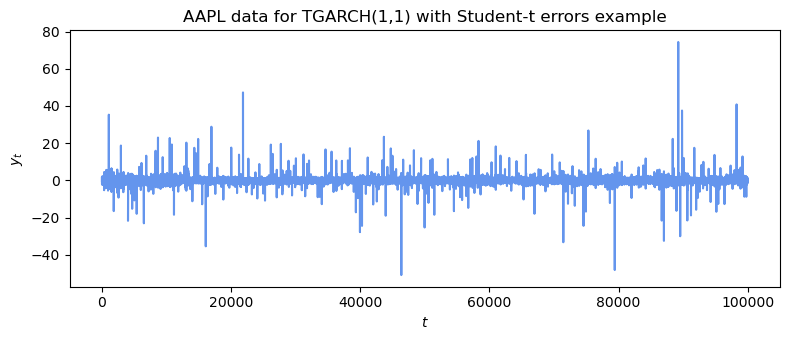

95% Confidence intervals for MLE estimates (phi)
[ 0.   -4.19 -2.51 -3.73 -0.15  0.93]
[ 0.01 -4.03 -2.33 -3.16 -0.14  1.02]



95% Credible intervals for posterior (phi)
[ 0.   -4.19 -2.51 -3.71 -0.15  0.93]
[ 0.01 -4.03 -2.33 -3.15 -0.14  1.02]





In [76]:
model = "TGARCH11" # To create folders

GARCH_type = "TGARCH"
error_type = "Student-t"

T = 100000 # Length of time series
p = 1 # Nbr of autoregressive y-lags in the GARCH-type variance process
q = 1 # Nbr of autoregressive sigma2-lags in the GARCH-type variance process
# Specify transforms (set all "identity" if no transformation)
dataset_name = "AAPL_%s(%s,%s)_%s_error" % (GARCH_type, p, q, error_type)

param_names, trans_param_names = get_param_names(GARCH_type, error_type, p, q)
names = {"params_name": param_names, "trans_param_names": trans_param_names}    
transforms = ["identity"] + ["log"] + p*["log"] + p*["log"] + q*["log"] + ["log_shift2"]

# Likelihood optimisation settings (posterior optimisation always uses L-BFGS-B as it has a better starting value):
likelihood_optim = "basinhopping" 
options_L_BFGS_B = {"gtol":1e-6, "ftol":1e-12, "maxls":50, "maxiter":2000, "disp":True}
options_trust_ncg = {"gtol":1e-6, "maxiter":2000, "disp":True}
options_basinhopping = {"niter":5, "stepsize":0.5, "T":1.0, "disp":True}

# Prior settings:
# The default settings are
# mu_mean = 0.0, mu_sd = 10.0, omega_scale = 1.0, alpha_scale = 0.2, beta_scale = 0.8, v_shape = 2.0, v_rate = 1.0
# If other setting required, save as dictionary and pass on to the log prior once defined.
# Example:
prior_args = "default"
# prior_args = {"mu_mean":0.0, "mu_sd":100.0, "omega_scale":1.0, "alpha_scale":0.2, "beta_scale":0.8, "v_shape":2.0, "v_rate":1.0}

# Initialise prior. Either with default parameters or as specificed in prior_args
if prior_args == "default":
    log_prior = initiate_priors(GARCH_type, error_type)
    f = {"GARCH": log_prior_GARCH, "TGARCH": log_prior_TGARCH}[GARCH_type]
    prior_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    prior_hyperparams = prior_args
    log_prior = initiate_priors(GARCH_type, error_type, **prior_hyperparams)

# Penalty settings:
penalty_args = "default"

# Inititialise penalties for frequentist estimation
if penalty_args == "default":
    log_penalty = initiate_penalties(GARCH_type, error_type)
    f = {"GARCH": log_penalty_GARCH, "TGARCH": log_penalty_TGARCH}[GARCH_type]
    penalty_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    penalty_hyperparams = penalty_args
    log_penalty = initiate_penalties(GARCH_type, error_type, **penalty_hyperparams)
    
        
# Create model functions based on the inputs above
h, hinv, hinv_p, hinv_pp, jacdiag, logdet = initiate_transformation_functions(transforms)
log_densities, grad_log_densities, Hess_log_densities = initiate_model_functions(GARCH_type, error_type, hinv, hinv_p, hinv_pp)


# Functions to reparameterise the proposal density to a space where the GARCH/TGARCH process is stationary
theta_to_psi, psi_to_theta, logabsdet_dpsi_dtheta = initiate_persistence_reparam_functions(GARCH_type=GARCH_type, error_type=error_type, p=p, q=q, h=h,
                                                                                           hinv=hinv, jacdiag=jacdiag, param_names=param_names, delta=1e-4)


# Read in data
# Dow Jones example  
log_returns = np.load("data/AAPL_100010obs.npy") # Data created as np.diff(np.log(data)).
series = log_returns[-(T + p):]
y = series / series.std() # std 1 normalisation.
y_start = y[:p][::-1]
y = y[-T:]
sigma2_start = np.array([1, 1, 1, 1])[-q:]
# End read data

theta0 = None # True values not available for real data
phi0 = None
if GARCH_type == 'GARCH':
    n_params = 2 + p + q
elif GARCH_type == 'TGARCH':
    n_params = 2 + 2*p + q
    
if error_type == 'Student-t':
    n_params += 1
assert(len(transforms) == n_params)

# Keep text selectable in the PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
# Latex
mpl.rcParams['text.usetex'] = False 

out_dir = Path("results") / app / model / error_type
out_dir.mkdir(parents=True, exist_ok=True)

with pdf_section("01_settings_and_data_plot", out_dir=out_dir) as active:
    with capture_output(display) as cap:
        print("==============================================================")
        print("GARCH_type:", GARCH_type, ", Error distribution:", error_type)
        print("Lags: p =, ", p, "q = ", q)
        print("Dataset name: ", dataset_name)
        print("Number of observations: ", T)
        print("Parameters:")
        display(Markdown(", ".join(param_names)))
        print("Tranformations:\n", transforms)
        print("Number of parameters:", n_params)
        print("Prior hyperparameters (v_rate and v_shape only if Student-t)")
        print_kv(prior_hyperparams)
        print("==============================================================")

    # Show in notebook
    cap.show()

    # Only write to PDF if active
    if active:
        text = cap.stdout
        pdf_add_text(text, title="Model and settings specified")

    # Measurements
    plt.figure(figsize=(8, 3.5))
    plt.title(f"AAPL data for {GARCH_type}({p},{q}) with {error_type} errors example")
    plt.plot(y, color="cornflowerblue")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$y_t$")
    plt.tight_layout()

    # Only write figure to PDF if active
    if active:
        pdf_add_fig()

    plt.show()



# Optimise likelihood
# Minimise in phi space, so input is unrestricted
def log_penalty_phi(x, p, q):
    return log_penalty(hinv(x), p, q)

def obj_func_likelihood(x):
    """
    Penalised log-likelihood. To enforce the
    """
    return -log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + log_penalty_phi(x, p, q)# /T

grad_log_penalty = grad(log_penalty_phi) #(x, p, q)
Hess_log_penalty = hessian(log_penalty_phi)

grad_obj_func_likelihood = lambda x: -grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + grad_log_penalty(x, p, q) #/T # Gradient of obj_func_likelihood. Computed by automatic differentiation
Hess_obj_func_likelihood = lambda x: -Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + Hess_log_penalty(x, p, q) #/T # Hessian of obj_func_likelihood. Computed by automatic differentiation

optim_dir = out_dir / "optim"
optim_dir.mkdir(parents=True, exist_ok=True)
save_path_optim = optim_dir / "optim_likelihood_result.h5"
log_path_optim = optim_dir / "optim_likelihood_live.log"

# Optimise the log-likelihood
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)


try:
    optim_results = load_dict_h5(save_path_optim)
    MLE = np.array(optim_results['optim_obj']['x'])
    Cov = optim_results['Cov_MLE']
    print('95% Confidence intervals for MLE estimates (phi)')
    print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2))
    print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2))
    print("\n\n")
    
except FileNotFoundError:
    # Optimise the log-likelihood
    mu_0 = np.mean(y)
    alpha_0 = np.array([0.1, 0.05, 0.05])[:p]    
    assert(len(alpha_0) == p)
    gamma_0 = np.array([0.03, 0.1, 0.03])[:p]
    assert(len(alpha_0) == p)
    beta_0 = np.array([0.2, 0.1])[:q]
    assert(len(beta_0) == q)
    omega_0 = np.var(y)
    assert(omega_0 >= 0)
    if error_type == "Student-t": 
        v_0 = 15
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0, v_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0, v_0)).flatten()  
            print(theta_optim_start)
    else: # normal error
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0)).flatten()

    phi_optim_start = h(theta_optim_start)
    
    start = time.perf_counter()
    it = {"k": 0} # For callback
    fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)

    with live_log_to_file(log_path_optim):

        if likelihood_optim == "trust-ncg":
            print('\n\nLikelihood optimisation settings for method trust-ncg:\n', flush=True)
            options = options_trust_ncg
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                jac=fg.jac, hess=Hess_obj_func_likelihood,
                method="trust-ncg", options=options
            )

        elif likelihood_optim == "L-BFGS-B":
            print('\n\nLikelihood optimisation settings for method L-BFGS-B:\n', flush=True)
            options = options_L_BFGS_B
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                method='L-BFGS-B', jac=fg.jac,
                callback=callback_optim, options=options
            )

        elif likelihood_optim == "basinhopping":
            minimizer_kwargs = {"method": "L-BFGS-B", "jac": fg.jac, "options": options_L_BFGS_B}
            res_optim_likelihood = basinhopping(
                fg.fun, x0=phi_optim_start,
                minimizer_kwargs=minimizer_kwargs,
                callback=callback_optim, **options_basinhopping
            )
        else:
            raise ValueError("Optimisation method does not exist")

        end = time.perf_counter()
        run_time = end - start

        # 

        print("==============================================================", flush=True)
        print("\nLikelihood optimisation took", run_time, "seconds.", flush=True)
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)

        print('MLE estimates (phi)', flush=True)
        MLE = res_optim_likelihood.x
        print(np.round(MLE, 2), flush=True)

        print('hinv(MLE) estimates (theta)', flush=True)
        print(np.round(hinv(MLE), 2), flush=True)

        print('95% Confidence intervals for MLE estimates (phi)', flush=True)
        Cov = np.linalg.inv(Hess_obj_func_likelihood(MLE)) / T
        print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)

        if likelihood_optim == "basinhopping":
            print_minimize_summary(
                res_optim_likelihood["lowest_optimization_result"],
                x_names=trans_param_names, latex=True
            )
        else:
            print_minimize_summary(
                res_optim_likelihood,
                x_names=trans_param_names, latex=True
            )

        print("==============================================================", flush=True)

    with pdf_section("02_optim_likelihood", out_dir=out_dir) as active:
        if active:
            text = log_path_optim.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-likelihood. Summary.")

    optim_results = {
        'optim_obj': pack_optimize_result(res_optim_likelihood),
        'method': likelihood_optim,
        'Cov_MLE': Cov,
        'start_value': phi_optim_start,
        'run_time': run_time
    }

    save_dict_h5(save_path_optim, optim_results)


# Optimise posterior
# Define gradients and Hessian for log-posterior
log_prior_phi = lambda x: log_prior(hinv(x), p, q) + logdet(x) # for autograd
grad_log_prior_phi = grad(log_prior_phi)
grad_log_posterior = lambda x: grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + grad_log_prior_phi(x)
Hess_log_prior_phi = hessian(log_prior_phi)
Hess_log_posterior = lambda x: Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + Hess_log_prior_phi(x)#

obj_func_posterior = lambda x: -log_posterior(x, T, p, q, y, y_start, sigma2_start)[0] # Input is phi
grad_obj_func_posterior = lambda x: -grad_log_posterior(x) 
Hess_obj_func_posterior = lambda x: -Hess_log_posterior(x)

save_path_optim_posterior = optim_dir / "optim_posterior_result.h5"
log_path_optim_posterior = optim_dir / "optim_posterior_live.log"

# Optimise the log-posterior in phi space, so input is unrestricted
phi_optim_start = MLE
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_posterior, grad_obj_func_posterior)

try:    
    optim_posterior_results = load_dict_h5(save_path_optim_posterior)
    MAP = np.array(optim_posterior_results['optim_obj']['x'])
    Cov = optim_posterior_results['Cov']
    print('95% Credible intervals for posterior (phi)', flush=True)
    print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print("\n\n", flush=True)
    
except FileNotFoundError:
    # Optimise the posterior 
    start = time.perf_counter()

    with live_log_to_file(log_path_optim_posterior):

        res_optim_posterior = minimize(
            fg.fun, phi_optim_start,
            method='L-BFGS-B', jac=fg.jac,
            callback=callback_optim,
            options=options_L_BFGS_B
        )

        end = time.perf_counter()
        run_time = end - start

        print("==============================================================", flush=True)

        print("\nPosterior optimisation took", run_time, "seconds.", flush=True)
        print('\n\nPosterior optimisation settings for method L-BFGS-B:\n', flush=True)
        print_kv(options_L_BFGS_B)
        
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)
        # Compare answers
        print('MAP estimates (phi)', flush=True)
        MAP = res_optim_posterior.x
        print(np.round(MAP, 2), flush=True)
        print('hinv(MAP) estimates (theta)', flush=True)
        print(np.round(hinv(MAP), 2), flush=True)

        print('95% Credible intervals (normality assumption on posterior) (phi)', flush=True)
        Hess_MAP = Hess_obj_func_posterior(MAP)
        Cov = np.linalg.inv(Hess_MAP) # Negative Hessian inverse evaluated at the mode  
        if (np.linalg.eigvalsh(Cov) < 0).any():
            print("Cannot compute posterior covariance from Hessian. Trying outer product approximation", flush=True)
            scores = grad_log_densities(hinv(MAP), T, p, q, y, y_start, sigma2_start)
            Cov = np.linalg.inv(scores.T @ scores)
            assert (np.linalg.eigvalsh(Cov) > 0).all(), "Cannot compute posterior covariance."
            adapt_scaling = True
        else:
            adapt_scaling = False
        print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)
        print_minimize_summary(res_optim_posterior, x_names=trans_param_names, latex=True)
        optim_posterior_results = {
            'optim_obj': pack_optimize_result(res_optim_posterior),
            'method': 'L-BFGS-B',
            'Cov': Cov,
            'start_value': phi_optim_start,
            'run_time': run_time
        }
        save_dict_h5(save_path_optim_posterior, optim_posterior_results)
        print("==============================================================", flush=True)

    with pdf_section("03_optim_posterior", out_dir=out_dir) as active:
        if active:
            text = log_path_optim_posterior.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-posterior. Display and summary.")

Optimisation finished. Pilot full-data run for tuning the estimator next.

In [77]:
np.random.seed(SEEDS['App2_tuning_TGARCH11_Student-t'])
N =100 # MCMC samples (pilot run for tuning)
MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)
save_path_MCMC = MCMC_dir / ("pilot_full_data_MCMC_N%s.h5" % N)
log_path_MCMC = MCMC_dir / ("pilot_full_data_MCMC_N%s.log" % N)

try:
    MCMC_results = load_dict_h5(save_path_MCMC)
    pilot_full_data_MCMC = MCMC_results['MCMC_obj']
    prop_cov = MCMC_results['prop_cov']
    # Convert back to arrays
    for key in ["samples_phi", "samples_theta"]:
        pilot_full_data_MCMC[key] = np.asarray(pilot_full_data_MCMC[key])

except FileNotFoundError:

    with live_log_to_file(log_path_MCMC):

        # Run MCMC (proposal parameterised to obey stationarity)
        # Transform to Psi by linearising
        def phi_to_psi(phi):
            return theta_to_psi(hinv(phi))

        J_phi_to_psi = Jacobian_autograd(phi_to_psi)
        J_map = J_phi_to_psi(MAP)
        Cov_phi = Cov
        Cov_psi = J_map @ Cov_phi @ J_map.T
        Cov_psi = 0.5 * (Cov_psi + Cov_psi.T)
        Cov_psi = make_pos_def(Cov_psi, eps=1e-8)
        prop_cov = 0.1*2.38**2 / n_params * Cov_psi
        phi_init = MAP 
        print("==============================================================", flush=True)
        pilot_full_data_MCMC = sample_full_data_posterior_AM_stationary_proposal(phi_init, prop_cov, N, names,dataset_name, adapt_cov=True, adapt_scale=True, burn_in = 1000)
        print("==============================================================", flush=True)        

        MCMC_results = {'MCMC_obj': pilot_full_data_MCMC, 'prop_cov': prop_cov, 'start_value': phi_init}
        save_dict_h5(save_path_MCMC, MCMC_results)

    with pdf_section("04_pilot_full_data_MCMC", out_dir=out_dir) as active:
        if active:
            text = log_path_MCMC.read_text(encoding="utf-8")
            pdf_add_text(text, title="Full data MCMC sampling.")

            plot_traceplots_MCMC(
                pilot_full_data_MCMC['samples_phi'],
                param_true=MAP, param_names=trans_param_names,
                burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
                suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
            )
            pdf_add_fig()          # saves all figures created by plot_traceplots_MCMC
            plt.close("all")       


Control variates for subsampling MCMC.

(100000,)
[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH11/Student-t/05_control_variates.pdf


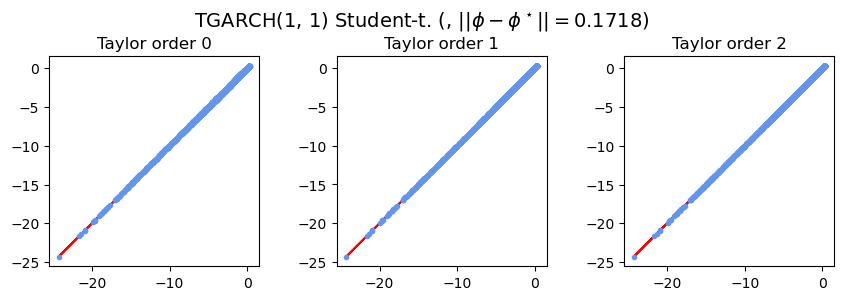

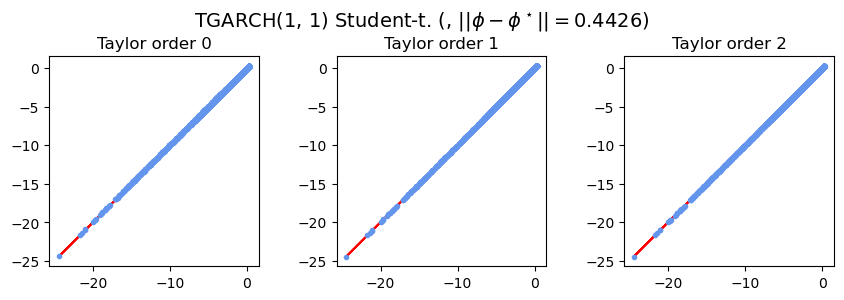

In [78]:
phiStar = MAP
args = (T, p, q, y, y_start, sigma2_start)
control_variate_dir = out_dir / "control_variates"
control_variate_dir.mkdir(parents=True, exist_ok=True)
save_path_control_variates = control_variate_dir / "control_variate_result.h5"
log_path_control_variates = control_variate_dir / "control_variate_live.log"

try:
    control_variates = load_dict_h5(save_path_control_variates)
    dens_at_phiStar = control_variates['dens_at_phiStar']
    grad_at_phiStar = control_variates['grad_at_phiStar'] 
    Hess_at_phiStar = control_variates['Hess_at_phiStar']
    end = control_variates['end']
    start = control_variates['start']
    cpu_CV = end - start

    print(dens_at_phiStar.shape)

except FileNotFoundError:
    with live_log_to_file(log_path_control_variates):
        start = time.perf_counter()
        dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar = initiate_control_variate_quantities(
            log_densities, grad_log_densities, Hess_log_densities, phiStar, args
        )
        end = time.perf_counter()
        cpu_CV = end - start
        print("==============================================================", flush=True)
        print("Elapsed time control variates initialisation with T = " , T, "p = " , p, "q = " , q,  ":", cpu_CV, "seconds", flush=True)
        print("==============================================================", flush=True)
        control_variates = {
            'dens_at_phiStar': dens_at_phiStar,
            'grad_at_phiStar': grad_at_phiStar,
            'Hess_at_phiStar': Hess_at_phiStar,
            'end': end,
            'start': start
        }
        save_dict_h5(save_path_control_variates, control_variates)

with pdf_section("05_control_variates", out_dir=out_dir) as active:

    if active:
        if log_path_control_variates.exists():
            text = log_path_control_variates.read_text(encoding="utf-8")
        else:
            text = "==============================================================\n" \
                   f"Elapsed time control variates initialisation with T = {T} p = {p} q = {q}: {cpu_CV} seconds\n" \
                   "==============================================================\n"
        pdf_add_text(text, title="Control variate construction.")

    # Precompute quantities for the control variates that do not depend on theta
    A = np.sum(dens_at_phiStar) 
    B = np.sum(grad_at_phiStar, axis = 0)
    C = np.sum(Hess_at_phiStar, axis = 0)
    # sum of control variates evaluated at phi    
    q_sum = lambda phi: A + np.dot(B, phi - phiStar) + 0.5*np.dot(phi - phiStar, np.dot(C, phi - phiStar))

    # Inspect control variate accuracy: log-densities

    # Outside median ellipse in phi space
    Sigma_pi = Cov # np.linalg.inv(Hess_obj_func_posterior(MAP))
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.50, n = 1).flatten()
    phi_beyond_median = phi
    q_k_order0 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    q_k_order1 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    q_k_order2 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    l_k = log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(l_k, l_k, color = 'red')
            if k == 0:
                axs[k].plot(l_k, q_k_order0, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(l_k, q_k_order1, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(l_k, q_k_order2, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)

    # Outside 0.999 ellipse
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.999, n = 1).flatten()
    phi_extreme = phi
    q_k_order0 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    q_k_order1 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    q_k_order2 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    l_k = log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(l_k, l_k, color = 'red')
            if k == 0:
                axs[k].plot(l_k, q_k_order0, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(l_k, q_k_order1, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(l_k, q_k_order2, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)

Tune the estimator. We recommend $R_{\max}=100$, but tune for $R_{\max}=1000, 100, 10, 1$ just to inspect.

In [79]:
t_star_frac = 0.01
t_star = int(t_star_frac* T)
b = 100.0
R_max_list = [1000, 100, 10, 1]
tuning_dir = out_dir / "tuning"
tuning_dir.mkdir(parents=True, exist_ok=True)

save_path_tuning = tuning_dir / "results_by_Rmax.h5"
log_path_tuning = tuning_dir / "tuning_live.log"

try:
    tuning_cache = load_dict_h5(save_path_tuning)
    results_by_Rmax_raw = tuning_cache["results_by_Rmax"]

    # Convert keys from str -> int
    results_by_Rmax = {int(k): v for k, v in results_by_Rmax_raw.items()}

    start = tuning_cache["start"]
    end = tuning_cache["end"]
    cpu_tuning_total = end - start

    print("==============================================================", flush=True)
    print("Loaded cached tuning results.", flush=True)
    print("Elapsed cached total tuning time:", cpu_tuning_total, "seconds", flush=True)
    print("==============================================================", flush=True)

except FileNotFoundError:
    with live_log_to_file(log_path_tuning):
        start = time.perf_counter()

        results_by_Rmax = run_calibrated_tuning_over_Rmax(
            R_max_list=R_max_list,
            MCMC_results=MCMC_results,
            MAP=MAP,
            phiStar=phiStar,
            dens_at_phiStar=dens_at_phiStar,
            grad_at_phiStar=grad_at_phiStar,
            Hess_at_phiStar=Hess_at_phiStar,
            args=args,
            T=T,
            t_star_frac=t_star_frac,
            b=b,
            m_min=2,
            pilot_slice=slice(1, 100, 5),
            verbose=True,
        )

        end = time.perf_counter()
        cpu_tuning_total = end - start

        print("==============================================================", flush=True)
        print("Elapsed total tuning time:", cpu_tuning_total, "seconds", flush=True)
        for R_max in R_max_list:
            print(
                f"R_max = {R_max}: cpu_tuning_Rmax = "
                f"{results_by_Rmax[R_max]['cpu_tuning_Rmax']:.2f} seconds",
                flush=True
            )
        print("==============================================================", flush=True)

        tuning_cache = {
            "results_by_Rmax": results_by_Rmax,
            "start": start,
            "end": end,
        }

        save_dict_h5(save_path_tuning, tuning_cache)

Loaded cached tuning results.
Elapsed cached total tuning time: 494.9104133159999 seconds


In [80]:
# Summarise and plot
for R_max in R_max_list:
    res = results_by_Rmax[R_max]

    E_umax_opt = expected_umax_safe(res['probs_opt'], res['m_opt'])

    print(
        f"R_max={R_max:>4} | "
        f"c_min={res['c_min']:.4f} | "
        f"V_target={res['V_target']:.6f} | "
        f"c_opt={res['c_opt']:.6f} | "
        f"m_opt={res['m_opt']} | "
        f"E[umax]={E_umax_opt:.4f} | "
        f"var_opt={res['var_opt']:.6f} | "
        f"bind={res['binding_ratio_final']:.6f}"
    )

results_by_Rmax_list.append(results_by_Rmax[100]) # Used for the 2 x 2 plot version of Figure 5 for all 4 models. V tol approx 50.

R_max=1000 | c_min=0.0010 | V_target=499.158229 | c_opt=0.001000 | m_opt=2 | E[umax]=135.1432 | var_opt=385.108592 | bind=0.771516
R_max= 100 | c_min=0.0100 | V_target=49.915823 | c_opt=0.012661 | m_opt=2 | E[umax]=1307.3104 | var_opt=49.915822 | bind=1.000000
R_max=  10 | c_min=0.1000 | V_target=4.991582 | c_opt=0.126405 | m_opt=2 | E[umax]=12162.4736 | var_opt=4.991582 | bind=1.000000
R_max=   1 | c_min=1.0000 | V_target=0.499158 | c_opt=1.000000 | m_opt=3 | E[umax]=75000.5000 | var_opt=0.416320 | bind=0.834044


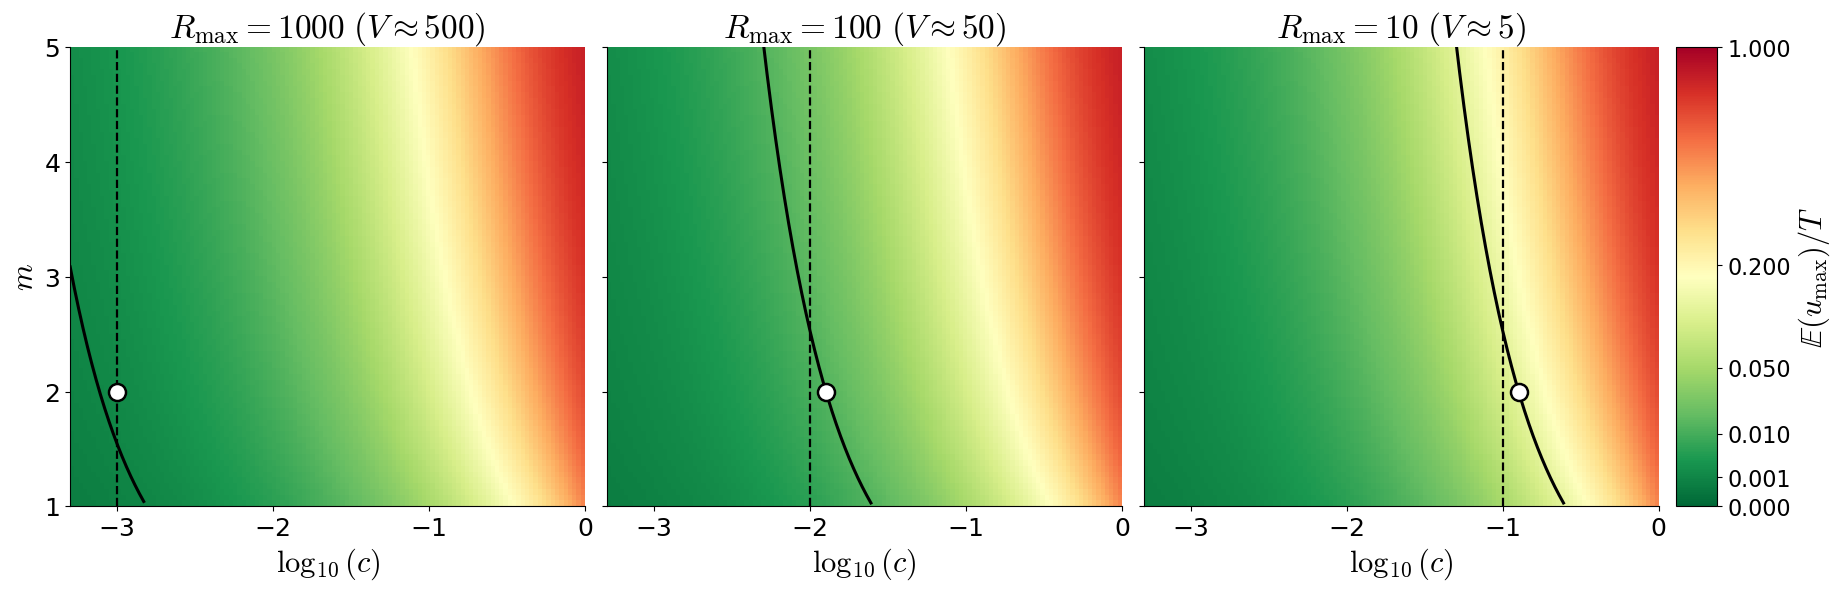

In [81]:
R_max_list = [1000, 100, 10]
V_tolerances_list = [500, 50, 5] 

make_Rmax_triptych_from_results_Figure5(
    T=T,
    t_star=t_star,
    b=b,
    results_by_Rmax=results_by_Rmax,
    R_max_list=R_max_list,
    V_tol_list = V_tolerances_list,
    c_max=1.0,
    n_c=120,
    m_max=5,
    n_m_bg=80,
    power_gamma=0.4,
    vmax=1.0,
    marker_size=150,
    show_cmin_line=True
)

Run subsampling Markov chain Monte Carlo with TPD weights (tuned using $R_{\max}=100$).

In [82]:
# ==============================================================
# Subsampling MCMC: repeated runs with caching + per-run PDFs
# Fixed R_max = 100
# TGARCH(1,1) with Student-t errors
# ==============================================================

N = 12000
R_max = 100
n_repeat = 6
key_example = "TGARCH11_Student-t"

base_seed = SEEDS['App2_TGARCH11_Student-t_subsampling_mcmc_Rmax100']

MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------------
# Tuned estimator parameters for subsampling MCMC
# --------------------------------------------------------------
res_tune_subsampling_MCMC = results_by_Rmax[R_max]
V_target = float(res_tune_subsampling_MCMC["V_target"])
c_opt = float(res_tune_subsampling_MCMC["c_opt"])
m_opt = int(res_tune_subsampling_MCMC["m_opt"])
gamma_opt = float(res_tune_subsampling_MCMC["gamma_opt"])

estimator_params = {
    "m_opt": m_opt,
    "c_opt": c_opt,
    "gamma_opt": gamma_opt,
    "t_star": t_star,
    "b": b,
    "V_tolerance": V_target,
    "R_max": R_max,
}

# --------------------------------------------------------------
# Fixed initial value and fixed proposal covariance
# --------------------------------------------------------------
phi_init = MAP
Cov_phi = Cov  # Negative Hessian inverse evaluated at the mode

def phi_to_psi(phi):
    return theta_to_psi(hinv(phi))

J_phi_to_psi = Jacobian_autograd(phi_to_psi)
J_map = J_phi_to_psi(MAP)
Cov_psi = J_map @ Cov_phi @ J_map.T
Cov_psi = 0.5 * (Cov_psi + Cov_psi.T)
Cov_psi = make_pos_def(Cov_psi, eps=1e-8)
prop_cov = 0.5 * 2.38**2 / n_params * Cov_psi

# --------------------------------------------------------------
# Storage across repetitions
# --------------------------------------------------------------
result_list = []
diagnostics_list = []
status_list = []
cpu_list = []
cf_list = []
seed_list = []
log_path_list = []
save_path_list = []
pdf_path_list = []

section_name = f"06_subsampling_MCMC_Rmax{R_max}"

for run in range(1, n_repeat + 1):

    seed_run = base_seed + run
    np.random.seed(seed_run)

    save_path_subsampling_MCMC = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_rep{run}.h5"
    log_path_subsampling_MCMC = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_rep{run}.log"

    pdf_suffix = f"Rmax{R_max}_rep{run}"
    safe = section_name.replace(" ", "_").replace("/", "-")
    pdf_path_run = Path(out_dir) / f"{safe}_{pdf_suffix}.pdf"

    save_path_list.append(save_path_subsampling_MCMC)
    log_path_list.append(log_path_subsampling_MCMC)
    pdf_path_list.append(pdf_path_run)
    seed_list.append(seed_run)

    try:
        subsampling_MCMC_results = load_dict_h5(save_path_subsampling_MCMC)

        result_subsampling_MCMC = subsampling_MCMC_results["MCMC_obj"]
        prop_cov_run = np.asarray(subsampling_MCMC_results["prop_cov"])
        estimator_params_run = subsampling_MCMC_results["estimator_params"]

        for key in [
            "samples_phi",
            "samples_theta",
            "log_posthat_samples",
            "sigma2_lhat_samples",
            "u_max_prop",
        ]:
            if key in result_subsampling_MCMC:
                result_subsampling_MCMC[key] = np.asarray(result_subsampling_MCMC[key])

        run_diagnostics = subsampling_MCMC_results.get("run_diagnostics", None)
        run_status = subsampling_MCMC_results.get("run_status", None)

    except FileNotFoundError:

        with live_log_to_file(log_path_subsampling_MCMC):

            print("==============================================================", flush=True)
            print(f"Running subsampling MCMC with R_max = {R_max}", flush=True)
            print(f"Repetition = {run}/{n_repeat}", flush=True)
            print(f"Seed = {seed_run}", flush=True)
            print(f"N = {N}", flush=True)
            print(f"m_opt = {m_opt}", flush=True)
            print(f"c_opt = {c_opt}", flush=True)
            print(f"gamma_opt = {gamma_opt}", flush=True)
            print(f"V_target = {V_target}", flush=True)
            print("==============================================================", flush=True)

            result_subsampling_MCMC = sample_subsampling_posterior_random_walk_stationary_proposal(
                estimator_params,
                phi_init,
                prop_cov,
                N,
                names,
                dataset_name,
                adapt=False,
            )

            print("==============================================================", flush=True)

        prop_cov_run = prop_cov
        estimator_params_run = estimator_params

        # ----------------------------------------------------------
        # Compute run diagnostics
        # ----------------------------------------------------------
        longest_streak, first_stuck_iteration = longest_immobility_streak(
            result_subsampling_MCMC["samples_theta"]
        )
        stuck_flag = (longest_streak >= 100)

        cpu_tuning_cost = results_by_Rmax[R_max]["cpu_tuning_Rmax"]
        cpu_subsampling_MCMC = result_subsampling_MCMC["run_time"] + cpu_tuning_cost
        cf_subsampling_MCMC = np.sum(result_subsampling_MCMC["u_max_prop"] + 1) + 100 * T

        acceptance_rate = np.mean(result_subsampling_MCMC["alphas_MH"])

        run_diagnostics = {
            "run": run,
            "seed": seed_run,
            "longest_immobility_streak": int(longest_streak),
            "first_stuck_iteration": (
                int(first_stuck_iteration) if first_stuck_iteration is not None else -1
            ),
            "stuck_flag": bool(stuck_flag),
            "run_time": float(result_subsampling_MCMC["run_time"]),
            "cpu_total_including_tuning": float(cpu_subsampling_MCMC),
            "compute_fraction": float(cf_subsampling_MCMC),
            "acceptance_rate": acceptance_rate,
        }

        run_status = classify_mcmc_run(longest_streak, threshold_stuck=100)

        subsampling_MCMC_results = {
            "MCMC_obj": result_subsampling_MCMC,
            "prop_cov": prop_cov_run,
            "start_value": phi_init,
            "estimator_params": estimator_params_run,
            "seed": seed_run,
            "run_diagnostics": run_diagnostics,
            "run_status": run_status,
        }
        save_dict_h5(save_path_subsampling_MCMC, subsampling_MCMC_results)

    # --------------------------------------------------------------
    # If diagnostics/status were not cached, compute them now
    # --------------------------------------------------------------
    if run_diagnostics is None or run_status is None:

        longest_streak, first_stuck_iteration = longest_immobility_streak(
            result_subsampling_MCMC["samples_theta"]
        )
        stuck_flag = (longest_streak >= 100)

        cpu_tuning_cost = results_by_Rmax[R_max]["cpu_tuning_Rmax"]
        cpu_subsampling_MCMC = result_subsampling_MCMC["run_time"] + cpu_tuning_cost
        cf_subsampling_MCMC = np.sum(result_subsampling_MCMC["u_max_prop"] + 1) + 100 * T

        acceptance_rate = np.mean(result_subsampling_MCMC["alphas_MH"])

        run_diagnostics = {
            "run": run,
            "seed": seed_run,
            "longest_immobility_streak": int(longest_streak),
            "first_stuck_iteration": (
                int(first_stuck_iteration) if first_stuck_iteration is not None else -1
            ),
            "stuck_flag": bool(stuck_flag),
            "run_time": float(result_subsampling_MCMC["run_time"]),
            "cpu_total_including_tuning": float(cpu_subsampling_MCMC),
            "compute_fraction": float(cf_subsampling_MCMC),
            "acceptance_rate": acceptance_rate,
        }

        run_status = classify_mcmc_run(longest_streak, threshold_stuck=100)

    # --------------------------------------------------------------
    # Store in summary lists
    # --------------------------------------------------------------
    result_list.append(result_subsampling_MCMC)
    diagnostics_list.append(run_diagnostics)
    status_list.append(run_status)
    cpu_list.append(run_diagnostics["cpu_total_including_tuning"])
    cf_list.append(run_diagnostics["compute_fraction"])

    # --------------------------------------------------------------
    # Per-run PDF output
    # --------------------------------------------------------------
    with pdf_section(section_name, out_dir=out_dir, suffix=pdf_suffix, overwrite=False) as active:
        if active:
            text = log_path_subsampling_MCMC.read_text(encoding="utf-8")

            summary_text = (
                f"Repetition {run}/{n_repeat}\n"
                f"Seed = {seed_run}\n"
                f"Status = {run_status}\n"
                f"Longest immobility streak = {run_diagnostics['longest_immobility_streak']}\n"
                f"First stuck iteration = {run_diagnostics['first_stuck_iteration']}\n"
                f"Acceptance rate = {run_diagnostics['acceptance_rate']}\n"
                f"Run time = {run_diagnostics['run_time']:.2f}\n"
                f"CPU incl. tuning = {run_diagnostics['cpu_total_including_tuning']:.2f}\n"
                f"Compute fraction = {run_diagnostics['compute_fraction']:.2f}\n"
            )

            pdf_add_text(
                text + "\n\n" + summary_text,
                title=f"Subsampling MCMC sampling (R_max = {R_max}, repetition {run})",
            )

            # Standard MCMC traceplots
            plot_traceplots_MCMC(
                result_subsampling_MCMC["samples_theta"],
                param_true=hinv(MAP),
                param_names=param_names,
                burnin=0,
                thin=1,
                use_median=False,
                show_running_mean=True,
                runmean_window=50,
                suptitle=f"Traceplots subsampling MCMC (R_max = {R_max}, rep {run})",
            )
            pdf_add_fig()
            plt.close("all")

            # Additional subsampling-specific diagnostics
            plot_subsampling_MCMC_quantities(result_subsampling_MCMC)
            pdf_add_fig()
            plt.close("all")

# --------------------------------------------------------------
# Save master summary object across repetitions
# --------------------------------------------------------------
subsampling_MCMC_repeated_summary = {
    "R_max": R_max,
    "N": N,
    "n_repeat": n_repeat,
    "base_seed": base_seed,
    "key_example": key_example,
    "estimator_params": estimator_params,
    "start_value": phi_init,
    "prop_cov": prop_cov,
    "seed_list": seed_list,
    "status_list": status_list,
    "diagnostics_list": diagnostics_list,
    "cpu_list": cpu_list,
    "cf_list": cf_list,
    "save_path_list": [str(x) for x in save_path_list],
    "log_path_list": [str(x) for x in log_path_list],
    "pdf_path_list": [str(x) for x in pdf_path_list],
    "n_stuck": int(np.sum([s == "stuck" for s in status_list])),
    "n_mixed_well": int(np.sum([s == "mixed_well" for s in status_list])),
}

save_path_summary = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_summary.h5"
save_dict_h5(save_path_summary, subsampling_MCMC_repeated_summary)

print("==============================================================")
print(f"Finished repeated subsampling MCMC runs for R_max = {R_max}")
print(f"n_repeat = {n_repeat}")
print(f"mixed well = {subsampling_MCMC_repeated_summary['n_mixed_well']}/{n_repeat}")
print(f"stuck = {subsampling_MCMC_repeated_summary['n_stuck']}/{n_repeat}")
print(f"Summary saved to: {save_path_summary}")
print("==============================================================")

[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH11/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep1.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH11/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep2.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH11/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep3.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH11/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep4.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH11/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep5.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH11/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep6.pdf
Finished repeated subsampling MCMC runs for R_max = 100
n_repeat = 6
mixed well = 6/6
stuck = 0/6
Summary saved to: results/App2_MCMC/TGARCH11/Student-t/MCMC/subsampling_MCMC_Rmax100_N12000_summary.h5


In [83]:
# ==============================================================
# Inspect repeated subsampling MCMC diagnostics
# ==============================================================

summary_path = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_summary.h5"
summary_obj = load_dict_h5(summary_path)

diagnostics_list = summary_obj["diagnostics_list"]
status_list = summary_obj["status_list"]
seed_list = summary_obj["seed_list"]

rows = []
for d, status, seed in zip(diagnostics_list, status_list, seed_list):
    rows.append({
        "run": int(d["run"]),
        "seed": int(seed),
        "status": status,
        "longest_immobility_streak": int(d["longest_immobility_streak"]),
        "first_stuck_iteration": (
            None if int(d["first_stuck_iteration"]) < 0 else int(d["first_stuck_iteration"])
        ),
        "acceptance_rate": (
            np.nan if d["acceptance_rate"] is None else float(d["acceptance_rate"])
        ),
        "run_time": float(d["run_time"]),
        "cpu_total_including_tuning": float(d["cpu_total_including_tuning"]),
        "compute_fraction": float(d["compute_fraction"]),
    })

diag_df = pd.DataFrame(rows).sort_values("run").reset_index(drop=True)

print("==============================================================")
print("Repeated subsampling MCMC diagnostics")
print("==============================================================")
print(diag_df.to_string(index=False))

print("\n==============================================================")
print("Aggregate summaries")
print("==============================================================")
print(f"Number of runs: {len(diag_df)}")
print(f"Status counts:\n{diag_df['status'].value_counts(dropna=False)}")
print()
print("Longest immobility streak:")
print(f"  min    = {diag_df['longest_immobility_streak'].min()}")
print(f"  median = {diag_df['longest_immobility_streak'].median()}")
print(f"  max    = {diag_df['longest_immobility_streak'].max()}")

if diag_df["acceptance_rate"].notna().any():
    print()
    print("Acceptance rate:")
    print(f"  min    = {diag_df['acceptance_rate'].min():.4f}")
    print(f"  median = {diag_df['acceptance_rate'].median():.4f}")
    print(f"  max    = {diag_df['acceptance_rate'].max():.4f}")

print()
print("Runtime:")
print(f"  min    = {diag_df['run_time'].min():.2f}")
print(f"  median = {diag_df['run_time'].median():.2f}")
print(f"  max    = {diag_df['run_time'].max():.2f}")

print()
print("Compute fraction:")
print(f"  min    = {diag_df['compute_fraction'].min():.2f}")
print(f"  median = {diag_df['compute_fraction'].median():.2f}")
print(f"  max    = {diag_df['compute_fraction'].max():.2f}")
print("==============================================================")

Repeated subsampling MCMC diagnostics
 run  seed     status  longest_immobility_streak first_stuck_iteration  acceptance_rate   run_time  cpu_total_including_tuning  compute_fraction
   1 12346 mixed_well                         16                  None         0.414357 426.410544                  562.456346        26890247.0
   2 12347 mixed_well                         19                  None         0.411084 383.934683                  519.980485        26465612.0
   3 12348 mixed_well                         18                  None         0.413910 385.970155                  522.015957        26554460.0
   4 12349 mixed_well                         19                  None         0.413526 395.726944                  531.772746        27553531.0
   5 12350 mixed_well                         18                  None         0.414215 399.918940                  535.964741        25737144.0
   6 12351 mixed_well                         15                  None         0.419022 395.

Chains for TGARCH($1,1$) with Student-$t$ errors.

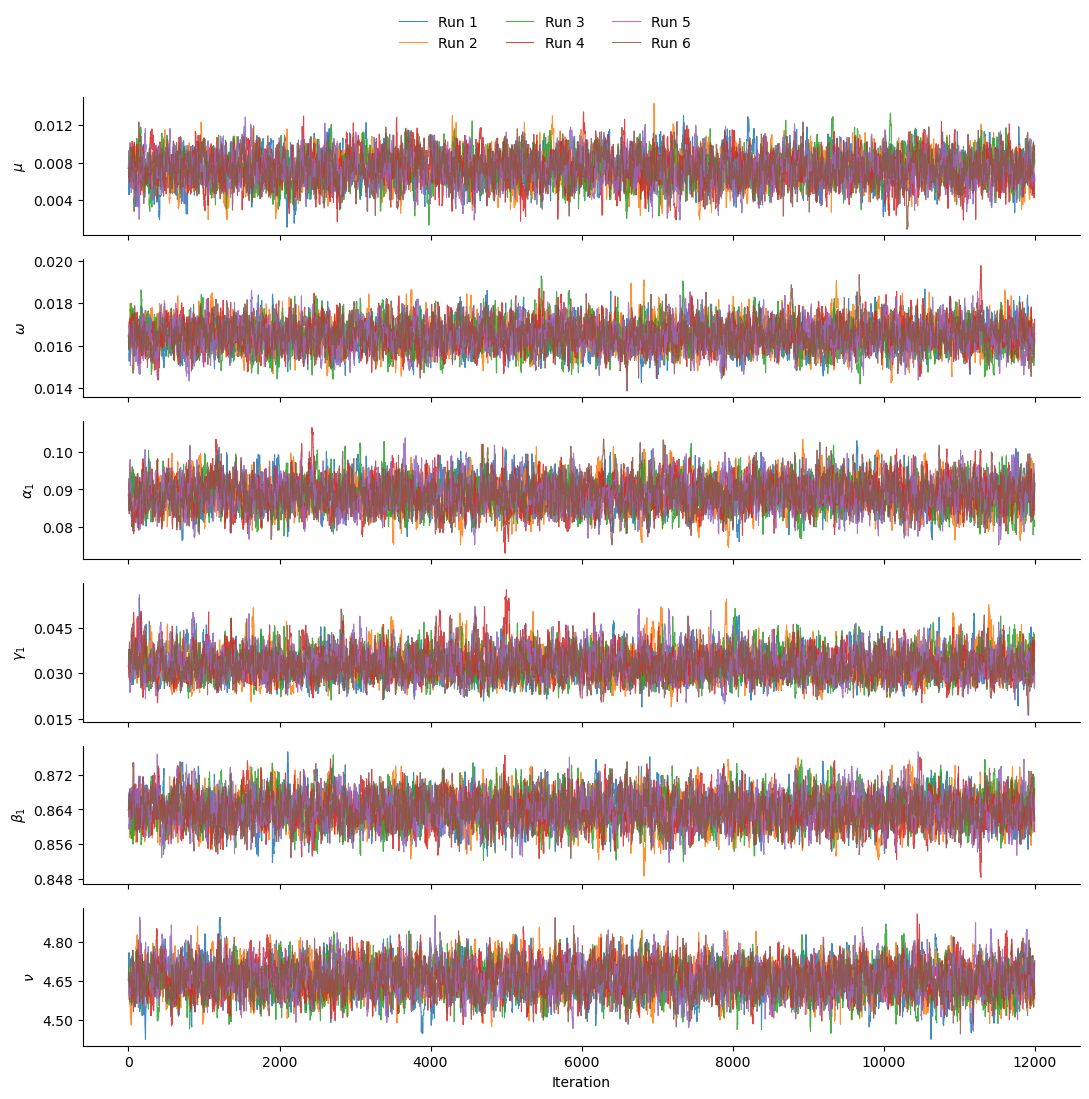

In [84]:
chains = [r['samples_theta'] for r in result_list]
chain_labels = [f"Run {i+1}" for i in range(6)]

fig, axes = plot_traceplots_MCMC_chains(
    param_draws=chains,
    param_names=param_names,
    chain_labels=chain_labels,
    burnin=0,
    thin=1,
    show_running_mean=False
)

Compute the log-predictive score for the test data using subsampling MCMC.

In [85]:
result_subsampling_MCMC_R_max100 = result_list[0]
result_tgarch11_Student_t = result_list[0]

# Compute joint out-of-sample predictive score
y_test = np.load("data/AAPL_10000obs.npy")
y_test = y_test/series.std()

# Evaluate model
evaluate_dir = out_dir / "evaluate"
evaluate_dir.mkdir(parents=True, exist_ok=True)
save_path_evaluate = evaluate_dir / ("log_pred_score.h5")
log_path_evaluate = evaluate_dir / ("evaluate_score.log")

samples_theta = result_subsampling_MCMC_R_max100["samples_theta"][2001::100]

try:
    log_predictive_results = load_dict_h5(save_path_evaluate)
    log_pred = log_predictive_results['log_scores']
    S = log_predictive_results['sum_log_scores']

except FileNotFoundError:

    with live_log_to_file(log_path_evaluate):

        # Compute the log-predictive score
        print("==============================================================", flush=True)
        S, log_pred = joint_predictive_score(samples_theta, y, y_test, p, q, y_start, sigma2_start, log_densities)
        print(f"p={p}, q={q}, error={error_type}, log_pred score sum = {S}")
        print("==============================================================", flush=True)
        log_predictive_results = {'sum_log_scores': S, 'log_scores': log_pred}
        save_dict_h5(save_path_evaluate, log_predictive_results)


mc_summary = predictive_score_mc_ci(log_pred)
print("Joint predictive score:", mc_summary["score_hat"])
print("MC standard error:", mc_summary["se"])
print("Approx. 95% CI: ({:.6f}, {:.6f})".format(
    mc_summary["ci_lower"], mc_summary["ci_upper"]
))
print("IACT:", mc_summary["tau_int"])
print("ESS:", mc_summary["ess"])




Joint predictive score: -9205.63727722471
MC standard error: 0.409080209737591
Approx. 95% CI: (-9206.439060, -9204.835495)
IACT: 1.0
ESS: 100.0


Full-data Markov chain Monte Carlo.

In [86]:
np.random.seed(SEEDS["App2_TGARCH11_Student-t_full_data_mcmc"])
N = 12000
MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)
save_path_MCMC = MCMC_dir / ("Full_data_MCMC_N%s.h5" % N)
log_path_MCMC = MCMC_dir / ("Full_data_MCMC_N%s.log" % N)

try:
    MCMC_results = load_dict_h5(save_path_MCMC)
    full_data_MCMC = MCMC_results['MCMC_obj']
    prop_cov = MCMC_results['prop_cov']
    # Convert back to arrays
    for key in ["samples_phi", "samples_theta"]:
        full_data_MCMC[key] = np.asarray(full_data_MCMC[key])

except FileNotFoundError:

    with live_log_to_file(log_path_MCMC):

        # Run MCMC (proposal parameterised to obey stationarity)
        # Transform to Psi by linearising
        def phi_to_psi(phi):
            return theta_to_psi(hinv(phi))

        J_phi_to_psi = Jacobian_autograd(phi_to_psi)
        J_map = J_phi_to_psi(MAP)
        Cov_phi = Cov
        Cov_psi = J_map @ Cov_phi @ J_map.T
        Cov_psi = 0.5 * (Cov_psi + Cov_psi.T)
        Cov_psi = make_pos_def(Cov_psi, eps=1e-8)
        prop_cov = 0.1*2.38**2 / n_params * Cov_psi
        phi_init = MAP 
        print("==============================================================", flush=True)
        full_data_MCMC = sample_full_data_posterior_AM_stationary_proposal(phi_init, prop_cov, N, names,dataset_name, adapt_cov=True, adapt_scale=True, burn_in = 1000)
        print("==============================================================", flush=True)        

        MCMC_results = {'MCMC_obj': full_data_MCMC, 'prop_cov': prop_cov, 'start_value': phi_init}
        save_dict_h5(save_path_MCMC, MCMC_results)

    with pdf_section("07_full_data_MCMC", out_dir=out_dir) as active:
        if active:
            text = log_path_MCMC.read_text(encoding="utf-8")
            pdf_add_text(text, title="Full data MCMC sampling.")

            plot_traceplots_MCMC(
                full_data_MCMC['samples_phi'],
                param_true=MAP, param_names=trans_param_names,
                burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
                suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
            )
            pdf_add_fig()          # saves all figures created by plot_traceplots_MCMC
            plt.close("all")       

Predictive score full-data MCMC

In [87]:
# Evaluate model
evaluate_dir = out_dir / "evaluate"
evaluate_dir.mkdir(parents=True, exist_ok=True)
save_path_evaluate = evaluate_dir / ("log_pred_score_full_data.h5")
log_path_evaluate = evaluate_dir / ("evaluate_score_full_data.log")

samples_theta = full_data_MCMC["samples_theta"][2001::100] # 

try:
    log_predictive_results = load_dict_h5(save_path_evaluate)
    log_pred = log_predictive_results['log_scores']
    S = log_predictive_results['sum_log_scores']

except FileNotFoundError:

    with live_log_to_file(log_path_evaluate):

        # Compute the log-predictive score
        print("==============================================================", flush=True)
        S, log_pred = joint_predictive_score(samples_theta, y, y_test, p, q, y_start, sigma2_start, log_densities)
        print(f"p={p}, q={q}, error={error_type}, log_pred score sum = {S}")
        print("==============================================================", flush=True)
        log_predictive_results = {'sum_log_scores': S, 'log_scores': log_pred}
        save_dict_h5(save_path_evaluate, log_predictive_results)



mc_summary_full_data = predictive_score_mc_ci(log_pred)
print("Predictive score with full_data MCMC")
print("Joint predictive score:", mc_summary_full_data["score_hat"])
print("MC standard error:", mc_summary_full_data["se"])
print("Approx. 95% CI: ({:.6f}, {:.6f})".format(
    mc_summary_full_data["ci_lower"], mc_summary_full_data["ci_upper"]
))
print("IACT:", mc_summary_full_data["tau_int"])
print("ESS:", mc_summary_full_data["ess"])

Predictive score with full_data MCMC
Joint predictive score: -9205.789144248634
MC standard error: 0.5010159537616218
Approx. 95% CI: (-9206.771117, -9204.807171)
IACT: 1.0
ESS: 100.0


Save to create tables for subsampling MCMC results and predictive scores.

In [88]:
tables_TGARCH11_Student_t = make_model_summary_for_tables(
    model_label="TGARCH(1,1), Student-t",
    subsampling_summary=subsampling_MCMC_repeated_summary,
    cpu_cv=cpu_CV,
    full_data_MCMC=full_data_MCMC,
    predictive_summary_subsampling=mc_summary,
    predictive_summary_full_data=mc_summary_full_data,
    comment="stable baseline"
)

Compare accuracy toward full-data MCMC and also effective sample size (ESS).

(<Figure size 1200x600 with 6 Axes>,
 array([<Axes: xlabel='$\\mu$'>, <Axes: xlabel='$\\omega$'>,
        <Axes: xlabel='$\\alpha_1$'>, <Axes: xlabel='$\\gamma_1$'>,
        <Axes: xlabel='$\\beta_1$'>, <Axes: xlabel='$\\nu$'>], dtype=object),
 array([[355.07645272, 396.79546272, 405.4478636 , 477.70775641,
         439.46429393, 391.37703373],
        [190.30647907, 269.03901733, 226.00563134, 195.68663665,
         194.63728885, 172.23693328]]))

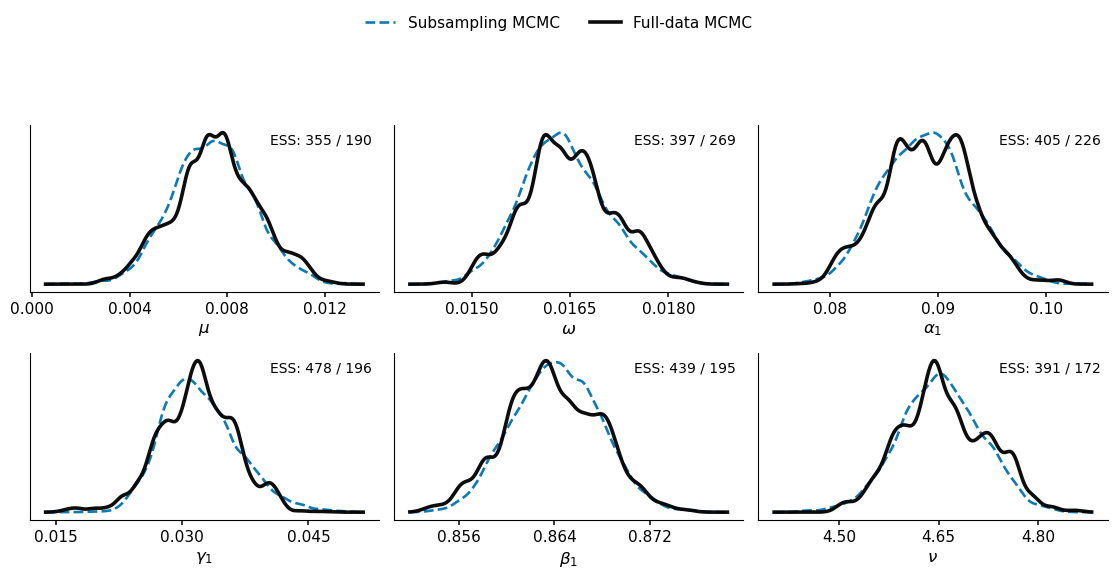

In [89]:
plot_kde_with_ESS_comparison(
            result_subsampling_MCMC_R_max100["samples_theta"][2000:, :],
            full_data_MCMC['samples_theta'][2000:, :],
            param_names=param_names,
            title="Posterior marginals (phi): Subsampling MCMC vs MCMC",
            n_points=200,
            true_vals=None,
            labels=("Subsampling MCMC", "Full-data MCMC"),
            ess_fmt="compact"
        )

### TGARCH(1, 2) with Student- errors

Define settings and optimise.

[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH12/Student-t/01_settings_and_data_plot.pdf
GARCH_type: TGARCH , Error distribution: Student-t
Lags: p =,  1 q =  2
Dataset name:  AAPL_TGARCH(1,2)_Student-t_error
Number of observations:  100000
Parameters:
Tranformations:
 ['identity', 'log', 'log', 'log', 'log', 'log', 'log_shift2']
Number of parameters: 7
Prior hyperparameters (v_rate and v_shape only if Student-t)
alpha_scale : 0.2
beta_scale  : 0.8
gamma_scale : 0.2
mu_mean     : 0
mu_sd       : 10
omega_scale : 1
v_rate      : 1
v_shape     : 2


$\mu$, $\omega$, $\alpha_1$, $\gamma_1$, $\beta_1$, $\beta_2$, $\nu$

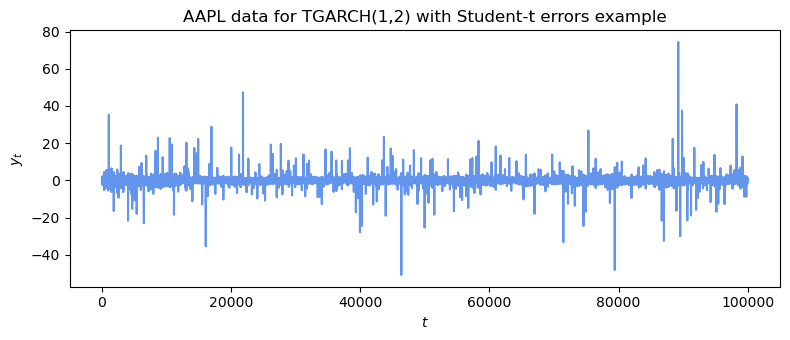

95% Confidence intervals for MLE estimates (phi)
[ 0.   -4.   -2.34 -3.49 -0.67 -1.67  0.93]
[ 0.01 -3.82 -2.14 -2.92 -0.4  -1.1   1.02]



95% Credible intervals for posterior (phi)
[ 0.   -4.   -2.34 -3.49 -0.67 -1.67  0.93]
[ 0.01 -3.82 -2.14 -2.92 -0.4  -1.1   1.02]





In [90]:
model = "TGARCH12" # To create folders

GARCH_type = "TGARCH"
error_type = "Student-t"

T = 100000 # Length of time series
p = 1 # Nbr of autoregressive y-lags in the GARCH-type variance process
q = 2 # Nbr of autoregressive sigma2-lags in the GARCH-type variance process
# Specify transforms (set all "identity" if no transformation)
dataset_name = "AAPL_%s(%s,%s)_%s_error" % (GARCH_type, p, q, error_type)

param_names, trans_param_names = get_param_names(GARCH_type, error_type, p, q)
names = {"params_name": param_names, "trans_param_names": trans_param_names}    
transforms = ["identity"] + ["log"] + p*["log"] + p*["log"] + q*["log"] + ["log_shift2"]

# Likelihood optimisation settings (posterior optimisation always uses L-BFGS-B as it has a better starting value):
likelihood_optim = "basinhopping" 
options_L_BFGS_B = {"gtol":1e-6, "ftol":1e-12, "maxls":50, "maxiter":2000, "disp":True}
options_trust_ncg = {"gtol":1e-6, "maxiter":2000, "disp":True}
options_basinhopping = {"niter":5, "stepsize":0.5, "T":1.0, "disp":True}

# Prior settings:
# The default settings are
# mu_mean = 0.0, mu_sd = 10.0, omega_scale = 1.0, alpha_scale = 0.2, beta_scale = 0.8, v_shape = 2.0, v_rate = 1.0
# If other setting required, save as dictionary and pass on to the log prior once defined.
# Example:
prior_args = "default"
# prior_args = {"mu_mean":0.0, "mu_sd":100.0, "omega_scale":1.0, "alpha_scale":0.2, "beta_scale":0.8, "v_shape":2.0, "v_rate":1.0}

# Initialise prior. Either with default parameters or as specificed in prior_args
if prior_args == "default":
    log_prior = initiate_priors(GARCH_type, error_type)
    f = {"GARCH": log_prior_GARCH, "TGARCH": log_prior_TGARCH}[GARCH_type]
    prior_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    prior_hyperparams = prior_args
    log_prior = initiate_priors(GARCH_type, error_type, **prior_hyperparams)

# Penalty settings:
penalty_args = "default"

# Inititialise penalties for frequentist estimation
if penalty_args == "default":
    log_penalty = initiate_penalties(GARCH_type, error_type)
    f = {"GARCH": log_penalty_GARCH, "TGARCH": log_penalty_TGARCH}[GARCH_type]
    penalty_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    penalty_hyperparams = penalty_args
    log_penalty = initiate_penalties(GARCH_type, error_type, **penalty_hyperparams)
    
        
# Create model functions based on the inputs above
h, hinv, hinv_p, hinv_pp, jacdiag, logdet = initiate_transformation_functions(transforms)
log_densities, grad_log_densities, Hess_log_densities = initiate_model_functions(GARCH_type, error_type, hinv, hinv_p, hinv_pp)


# Functions to reparameterise the proposal density to a space where the GARCH/TGARCH process is stationary
theta_to_psi, psi_to_theta, logabsdet_dpsi_dtheta = initiate_persistence_reparam_functions(GARCH_type=GARCH_type, error_type=error_type, p=p, q=q, h=h,
                                                                                           hinv=hinv, jacdiag=jacdiag, param_names=param_names, delta=1e-4)


# Read in data
# Dow Jones example  
log_returns = np.load("data/AAPL_100010obs.npy") # Data created as np.diff(np.log(data)).
series = log_returns[-(T + p):]
y = series / series.std() # std 1 normalisation.
y_start = y[:p][::-1]
y = y[-T:]
sigma2_start = np.array([1, 1, 1, 1])[-q:]
# End read data

theta0 = None # True values not available for real data
phi0 = None
if GARCH_type == 'GARCH':
    n_params = 2 + p + q
elif GARCH_type == 'TGARCH':
    n_params = 2 + 2*p + q
    
if error_type == 'Student-t':
    n_params += 1
assert(len(transforms) == n_params)

# Keep text selectable in the PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
# Latex
mpl.rcParams['text.usetex'] = False 

out_dir = Path("results") / app / model / error_type
out_dir.mkdir(parents=True, exist_ok=True)

with pdf_section("01_settings_and_data_plot", out_dir=out_dir) as active:
    with capture_output(display) as cap:
        print("==============================================================")
        print("GARCH_type:", GARCH_type, ", Error distribution:", error_type)
        print("Lags: p =, ", p, "q = ", q)
        print("Dataset name: ", dataset_name)
        print("Number of observations: ", T)
        print("Parameters:")
        display(Markdown(", ".join(param_names)))
        print("Tranformations:\n", transforms)
        print("Number of parameters:", n_params)
        print("Prior hyperparameters (v_rate and v_shape only if Student-t)")
        print_kv(prior_hyperparams)
        print("==============================================================")

    # Show in notebook
    cap.show()

    # Only write to PDF if active
    if active:
        text = cap.stdout
        pdf_add_text(text, title="Model and settings specified")

    # Measurements
    plt.figure(figsize=(8, 3.5))
    plt.title(f"AAPL data for {GARCH_type}({p},{q}) with {error_type} errors example")
    plt.plot(y, color="cornflowerblue")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$y_t$")
    plt.tight_layout()

    # Only write figure to PDF if active
    if active:
        pdf_add_fig()

    plt.show()



# Optimise likelihood
# Minimise in phi space, so input is unrestricted
def log_penalty_phi(x, p, q):
    return log_penalty(hinv(x), p, q)

def obj_func_likelihood(x):
    """
    Penalised log-likelihood. To enforce the
    """
    return -log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + log_penalty_phi(x, p, q)# /T

grad_log_penalty = grad(log_penalty_phi) #(x, p, q)
Hess_log_penalty = hessian(log_penalty_phi)

grad_obj_func_likelihood = lambda x: -grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + grad_log_penalty(x, p, q) #/T # Gradient of obj_func_likelihood. Computed by automatic differentiation
Hess_obj_func_likelihood = lambda x: -Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + Hess_log_penalty(x, p, q) #/T # Hessian of obj_func_likelihood. Computed by automatic differentiation

optim_dir = out_dir / "optim"
optim_dir.mkdir(parents=True, exist_ok=True)
save_path_optim = optim_dir / "optim_likelihood_result.h5"
log_path_optim = optim_dir / "optim_likelihood_live.log"

# Optimise the log-likelihood
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)


try:
    optim_results = load_dict_h5(save_path_optim)
    MLE = np.array(optim_results['optim_obj']['x'])
    Cov = optim_results['Cov_MLE']
    print('95% Confidence intervals for MLE estimates (phi)')
    print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2))
    print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2))
    print("\n\n")
    
except FileNotFoundError:
    # Optimise the log-likelihood
    
    # Start from TGARCH(1, 1) optimisation

    mu_0 = 0.007393
    alpha_0 = np.array([0.088620])    
    assert(len(alpha_0) == p)
    gamma_0 = np.array([0.032407])
    assert(len(alpha_0) == p)
    beta_0 = np.array([0.863955, 0.01])    
    assert(len(beta_0) == q)
    omega_0 = np.array([0.016467])
    assert(omega_0 >= 0)
    if error_type == "Student-t": 
        v_0 = 5
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0, v_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0, v_0)).flatten()  
            print(theta_optim_start)
    else: # normal error
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0)).flatten()

    phi_optim_start = h(theta_optim_start)
    
    start = time.perf_counter()
    it = {"k": 0} # For callback
    fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)

    with live_log_to_file(log_path_optim):

        if likelihood_optim == "trust-ncg":
            print('\n\nLikelihood optimisation settings for method trust-ncg:\n', flush=True)
            options = options_trust_ncg
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                jac=fg.jac, hess=Hess_obj_func_likelihood,
                method="trust-ncg", options=options
            )

        elif likelihood_optim == "L-BFGS-B":
            print('\n\nLikelihood optimisation settings for method L-BFGS-B:\n', flush=True)
            options = options_L_BFGS_B
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                method='L-BFGS-B', jac=fg.jac,
                callback=callback_optim, options=options
            )

        elif likelihood_optim == "basinhopping":
            minimizer_kwargs = {"method": "L-BFGS-B", "jac": fg.jac, "options": options_L_BFGS_B}
            res_optim_likelihood = basinhopping(
                fg.fun, x0=phi_optim_start,
                minimizer_kwargs=minimizer_kwargs,
                callback=callback_optim, **options_basinhopping
            )
        else:
            raise ValueError("Optimisation method does not exist")

        end = time.perf_counter()
        run_time = end - start

        # 

        print("==============================================================", flush=True)
        print("\nLikelihood optimisation took", run_time, "seconds.", flush=True)
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)

        print('MLE estimates (phi)', flush=True)
        MLE = res_optim_likelihood.x
        print(np.round(MLE, 2), flush=True)

        print('hinv(MLE) estimates (theta)', flush=True)
        print(np.round(hinv(MLE), 2), flush=True)

        print('95% Confidence intervals for MLE estimates (phi)', flush=True)
        Cov = np.linalg.inv(Hess_obj_func_likelihood(MLE)) / T
        print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)

        if likelihood_optim == "basinhopping":
            print_minimize_summary(
                res_optim_likelihood["lowest_optimization_result"],
                x_names=trans_param_names, latex=True
            )
        else:
            print_minimize_summary(
                res_optim_likelihood,
                x_names=trans_param_names, latex=True
            )

        print("==============================================================", flush=True)

    with pdf_section("02_optim_likelihood", out_dir=out_dir) as active:
        if active:
            text = log_path_optim.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-likelihood. Summary.")

    optim_results = {
        'optim_obj': pack_optimize_result(res_optim_likelihood),
        'method': likelihood_optim,
        'Cov_MLE': Cov,
        'start_value': phi_optim_start,
        'run_time': run_time
    }

    save_dict_h5(save_path_optim, optim_results)


# Optimise posterior
# Define gradients and Hessian for log-posterior
log_prior_phi = lambda x: log_prior(hinv(x), p, q) + logdet(x) # for autograd
grad_log_prior_phi = grad(log_prior_phi)
grad_log_posterior = lambda x: grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + grad_log_prior_phi(x)
Hess_log_prior_phi = hessian(log_prior_phi)
Hess_log_posterior = lambda x: Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + Hess_log_prior_phi(x)#

obj_func_posterior = lambda x: -log_posterior(x, T, p, q, y, y_start, sigma2_start)[0] # Input is phi
grad_obj_func_posterior = lambda x: -grad_log_posterior(x) 
Hess_obj_func_posterior = lambda x: -Hess_log_posterior(x)

save_path_optim_posterior = optim_dir / "optim_posterior_result.h5"
log_path_optim_posterior = optim_dir / "optim_posterior_live.log"

# Optimise the log-posterior in phi space, so input is unrestricted
phi_optim_start = MLE
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_posterior, grad_obj_func_posterior)

try:    
    optim_posterior_results = load_dict_h5(save_path_optim_posterior)
    MAP = np.array(optim_posterior_results['optim_obj']['x'])
    Cov = optim_posterior_results['Cov']
    print('95% Credible intervals for posterior (phi)', flush=True)
    print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print("\n\n", flush=True)
    
except FileNotFoundError:
    # Optimise the posterior 
    start = time.perf_counter()

    with live_log_to_file(log_path_optim_posterior):

        res_optim_posterior = minimize(
            fg.fun, phi_optim_start,
            method='L-BFGS-B', jac=fg.jac,
            callback=callback_optim,
            options=options_L_BFGS_B
        )

        end = time.perf_counter()
        run_time = end - start

        print("==============================================================", flush=True)

        print("\nPosterior optimisation took", run_time, "seconds.", flush=True)
        print('\n\nPosterior optimisation settings for method L-BFGS-B:\n', flush=True)
        print_kv(options_L_BFGS_B)
        
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)
        # Compare answers
        print('MAP estimates (phi)', flush=True)
        MAP = res_optim_posterior.x
        print(np.round(MAP, 2), flush=True)
        print('hinv(MAP) estimates (theta)', flush=True)
        print(np.round(hinv(MAP), 2), flush=True)

        print('95% Credible intervals (normality assumption on posterior) (phi)', flush=True)
        Hess_MAP = Hess_obj_func_posterior(MAP)
        Cov = np.linalg.inv(Hess_MAP) # Negative Hessian inverse evaluated at the mode  
        if (np.linalg.eigvalsh(Cov) < 0).any():
            print("Cannot compute posterior covariance from Hessian. Trying outer product approximation", flush=True)
            scores = grad_log_densities(hinv(MAP), T, p, q, y, y_start, sigma2_start)
            Cov = np.linalg.inv(scores.T @ scores)
            assert (np.linalg.eigvalsh(Cov) > 0).all(), "Cannot compute posterior covariance."
            adapt_scaling = True
        else:
            adapt_scaling = False
        print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)
        print_minimize_summary(res_optim_posterior, x_names=trans_param_names, latex=True)
        optim_posterior_results = {
            'optim_obj': pack_optimize_result(res_optim_posterior),
            'method': 'L-BFGS-B',
            'Cov': Cov,
            'start_value': phi_optim_start,
            'run_time': run_time
        }
        save_dict_h5(save_path_optim_posterior, optim_posterior_results)
        print("==============================================================", flush=True)

    with pdf_section("03_optim_posterior", out_dir=out_dir) as active:
        if active:
            text = log_path_optim_posterior.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-posterior. Display and summary.")

Optimisation finished. Pilot full-data run for tuning the estimator next.

In [91]:
np.random.seed(SEEDS['App2_tuning_TGARCH12_Student-t'])
N = 100 # MCMC samples (pilot run for tuning)
MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)
save_path_MCMC = MCMC_dir / ("pilot_full_data_MCMC_N%s.h5" % N)
log_path_MCMC = MCMC_dir / ("pilot_full_data_MCMC_N%s.log" % N)

try:
    MCMC_results = load_dict_h5(save_path_MCMC)
    pilot_full_data_MCMC = MCMC_results['MCMC_obj']
    prop_cov = MCMC_results['prop_cov']
    # Convert back to arrays
    for key in ["samples_phi", "samples_theta"]:
        pilot_full_data_MCMC[key] = np.asarray(pilot_full_data_MCMC[key])

except FileNotFoundError:

    with live_log_to_file(log_path_MCMC):

        # Run MCMC (proposal parameterised to obey stationarity)
        # Transform to Psi by linearising
        def phi_to_psi(phi):
            return theta_to_psi(hinv(phi))

        J_phi_to_psi = Jacobian_autograd(phi_to_psi)
        J_map = J_phi_to_psi(MAP)
        Cov_phi = Cov
        Cov_psi = J_map @ Cov_phi @ J_map.T
        Cov_psi = 0.5 * (Cov_psi + Cov_psi.T)
        Cov_psi = make_pos_def(Cov_psi, eps=1e-8)
        prop_cov = 0.1*2.38**2 / n_params * Cov_psi
        phi_init = MAP 
        print("==============================================================", flush=True)
        pilot_full_data_MCMC = sample_full_data_posterior_AM_stationary_proposal(phi_init, prop_cov, N, names,dataset_name, adapt_cov=True, adapt_scale=True, burn_in = 1000)
        print("==============================================================", flush=True)        

        MCMC_results = {'MCMC_obj': pilot_full_data_MCMC, 'prop_cov': prop_cov, 'start_value': phi_init}
        save_dict_h5(save_path_MCMC, MCMC_results)

    with pdf_section("04_pilot_full_data_MCMC", out_dir=out_dir) as active:
        if active:
            text = log_path_MCMC.read_text(encoding="utf-8")
            pdf_add_text(text, title="Full data MCMC sampling.")

            plot_traceplots_MCMC(
                pilot_full_data_MCMC['samples_phi'],
                param_true=MAP, param_names=trans_param_names,
                burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
                suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
            )
            pdf_add_fig()          # saves all figures created by plot_traceplots_MCMC
            plt.close("all")       


Control variates for subsampling MCMC.

(100000,)
[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH12/Student-t/05_control_variates.pdf


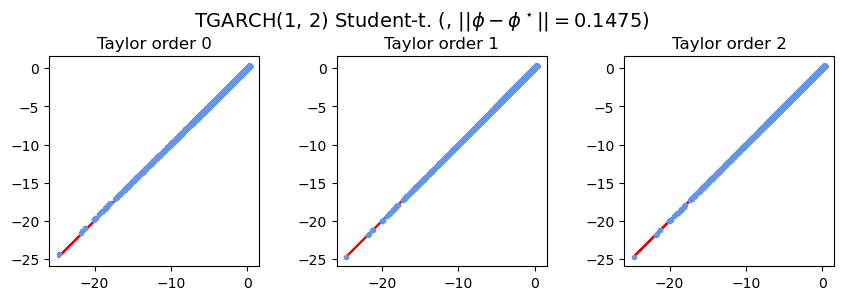

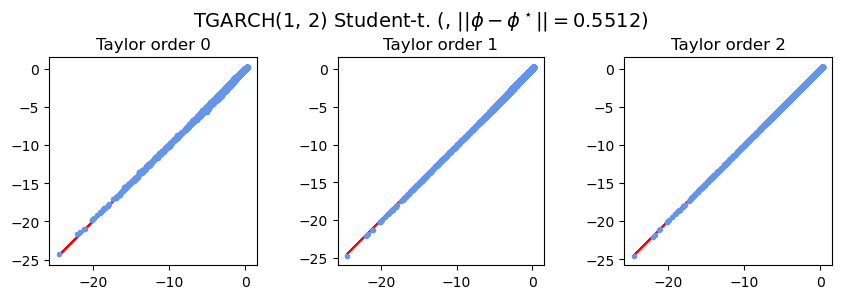

In [92]:
phiStar = MAP
args = (T, p, q, y, y_start, sigma2_start)
control_variate_dir = out_dir / "control_variates"
control_variate_dir.mkdir(parents=True, exist_ok=True)
save_path_control_variates = control_variate_dir / "control_variate_result.h5"
log_path_control_variates = control_variate_dir / "control_variate_live.log"

try:
    control_variates = load_dict_h5(save_path_control_variates)
    dens_at_phiStar = control_variates['dens_at_phiStar']
    grad_at_phiStar = control_variates['grad_at_phiStar'] 
    Hess_at_phiStar = control_variates['Hess_at_phiStar']
    end = control_variates['end']
    start = control_variates['start']
    cpu_CV = end - start

    print(dens_at_phiStar.shape)

except FileNotFoundError:
    with live_log_to_file(log_path_control_variates):
        start = time.perf_counter()
        dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar = initiate_control_variate_quantities(
            log_densities, grad_log_densities, Hess_log_densities, phiStar, args
        )
        end = time.perf_counter()
        cpu_CV = end - start
        print("==============================================================", flush=True)
        print("Elapsed time control variates initialisation with T = " , T, "p = " , p, "q = " , q,  ":", cpu_CV, "seconds", flush=True)
        print("==============================================================", flush=True)
        control_variates = {
            'dens_at_phiStar': dens_at_phiStar,
            'grad_at_phiStar': grad_at_phiStar,
            'Hess_at_phiStar': Hess_at_phiStar,
            'end': end,
            'start': start
        }
        save_dict_h5(save_path_control_variates, control_variates)

with pdf_section("05_control_variates", out_dir=out_dir) as active:

    if active:
        if log_path_control_variates.exists():
            text = log_path_control_variates.read_text(encoding="utf-8")
        else:
            text = "==============================================================\n" \
                   f"Elapsed time control variates initialisation with T = {T} p = {p} q = {q}: {cpu_CV} seconds\n" \
                   "==============================================================\n"
        pdf_add_text(text, title="Control variate construction.")

    # Precompute quantities for the control variates that do not depend on theta
    A = np.sum(dens_at_phiStar) 
    B = np.sum(grad_at_phiStar, axis = 0)
    C = np.sum(Hess_at_phiStar, axis = 0)
    # sum of control variates evaluated at phi    
    q_sum = lambda phi: A + np.dot(B, phi - phiStar) + 0.5*np.dot(phi - phiStar, np.dot(C, phi - phiStar))

    # Inspect control variate accuracy: log-densities

    # Outside median ellipse in phi space
    Sigma_pi = Cov # np.linalg.inv(Hess_obj_func_posterior(MAP))
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.50, n = 1).flatten()
    phi_beyond_median = phi
    q_k_order0 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    q_k_order1 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    q_k_order2 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    l_k = log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(l_k, l_k, color = 'red')
            if k == 0:
                axs[k].plot(l_k, q_k_order0, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(l_k, q_k_order1, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(l_k, q_k_order2, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)

    # Outside 0.999 ellipse
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.999, n = 1).flatten()
    phi_extreme = phi
    q_k_order0 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    q_k_order1 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    q_k_order2 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    l_k = log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(l_k, l_k, color = 'red')
            if k == 0:
                axs[k].plot(l_k, q_k_order0, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(l_k, q_k_order1, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(l_k, q_k_order2, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)

Tune the estimator. We recommend $R_{\max}=100$, but tune for $R_{\max}=1000, 100, 10, 1$ just to inspect.

In [93]:
t_star_frac = 0.01
t_star = int(t_star_frac* T)
b = 100.0
R_max_list = [1000, 100, 10, 1]
tuning_dir = out_dir / "tuning"
tuning_dir.mkdir(parents=True, exist_ok=True)

save_path_tuning = tuning_dir / "results_by_Rmax.h5"
log_path_tuning = tuning_dir / "tuning_live.log"

try:
    tuning_cache = load_dict_h5(save_path_tuning)
    results_by_Rmax_raw = tuning_cache["results_by_Rmax"]

    # Convert keys from str -> int
    results_by_Rmax = {int(k): v for k, v in results_by_Rmax_raw.items()}

    start = tuning_cache["start"]
    end = tuning_cache["end"]
    cpu_tuning_total = end - start

    print("==============================================================", flush=True)
    print("Loaded cached tuning results.", flush=True)
    print("Elapsed cached total tuning time:", cpu_tuning_total, "seconds", flush=True)
    print("==============================================================", flush=True)

except FileNotFoundError:
    with live_log_to_file(log_path_tuning):
        start = time.perf_counter()

        results_by_Rmax = run_calibrated_tuning_over_Rmax(
            R_max_list=R_max_list,
            MCMC_results=MCMC_results,
            MAP=MAP,
            phiStar=phiStar,
            dens_at_phiStar=dens_at_phiStar,
            grad_at_phiStar=grad_at_phiStar,
            Hess_at_phiStar=Hess_at_phiStar,
            args=args,
            T=T,
            t_star_frac=t_star_frac,
            b=b,
            m_min=2,
            pilot_slice=slice(1, 100, 5),
            verbose=True,
        )

        end = time.perf_counter()
        cpu_tuning_total = end - start

        print("==============================================================", flush=True)
        print("Elapsed total tuning time:", cpu_tuning_total, "seconds", flush=True)
        for R_max in R_max_list:
            print(
                f"R_max = {R_max}: cpu_tuning_Rmax = "
                f"{results_by_Rmax[R_max]['cpu_tuning_Rmax']:.2f} seconds",
                flush=True
            )
        print("==============================================================", flush=True)

        tuning_cache = {
            "results_by_Rmax": results_by_Rmax,
            "start": start,
            "end": end,
        }

        save_dict_h5(save_path_tuning, tuning_cache)

Loaded cached tuning results.
Elapsed cached total tuning time: 479.3835257780156 seconds


In [94]:
# Summarise and plot
for R_max in R_max_list:
    res = results_by_Rmax[R_max]

    E_umax_opt = expected_umax_safe(res['probs_opt'], res['m_opt'])

    print(
        f"R_max={R_max:>4} | "
        f"c_min={res['c_min']:.4f} | "
        f"V_target={res['V_target']:.6f} | "
        f"c_opt={res['c_opt']:.6f} | "
        f"m_opt={res['m_opt']} | "
        f"E[umax]={E_umax_opt:.4f} | "
        f"var_opt={res['var_opt']:.6f} | "
        f"bind={res['binding_ratio_final']:.6f}"
    )

results_by_Rmax_list.append(results_by_Rmax[100]) # Used for the 2 x 2 plot version of Figure 5 for all 4 models. V tol approx 4000.

R_max=1000 | c_min=0.0010 | V_target=42666.599240 | c_opt=0.001000 | m_opt=2 | E[umax]=135.1432 | var_opt=19408.348648 | bind=0.454884
R_max= 100 | c_min=0.0100 | V_target=4266.659924 | c_opt=0.016013 | m_opt=2 | E[umax]=1640.5913 | var_opt=4266.659914 | bind=1.000000
R_max=  10 | c_min=0.1000 | V_target=426.665992 | c_opt=0.106329 | m_opt=3 | E[umax]=14911.1495 | var_opt=426.665990 | bind=1.000000
R_max=   1 | c_min=1.0000 | V_target=42.666599 | c_opt=1.000000 | m_opt=2 | E[umax]=66667.1667 | var_opt=19.451976 | bind=0.455906


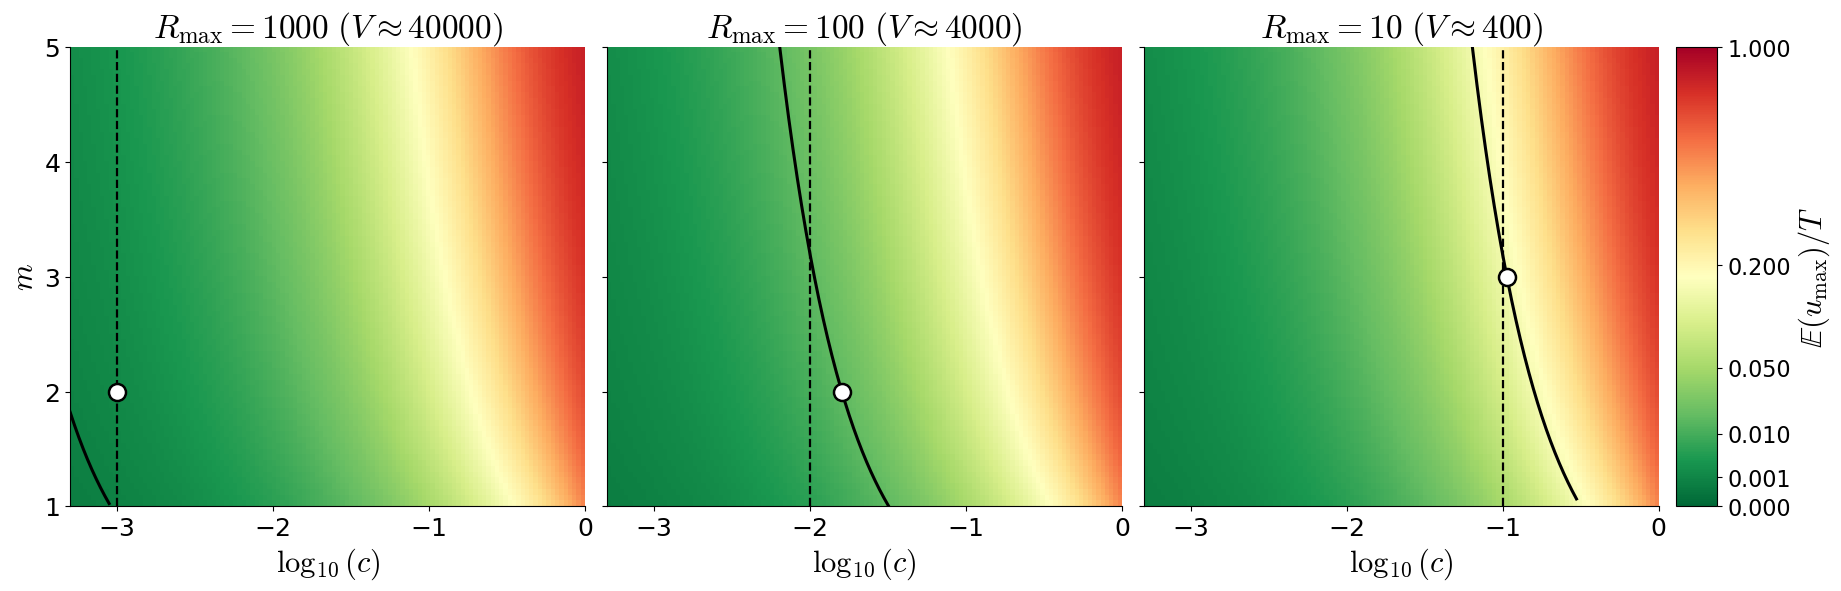

In [95]:
R_max_list = [1000, 100, 10]
V_tolerances_list = [40000, 4000, 400] 

make_Rmax_triptych_from_results_Figure5(
    T=T,
    t_star=t_star,
    b=b,
    results_by_Rmax=results_by_Rmax,
    R_max_list=R_max_list,
    V_tol_list = V_tolerances_list,
    c_max=1.0,
    n_c=120,
    m_max=5,
    n_m_bg=80,
    power_gamma=0.4,
    vmax=1.0,
    marker_size=150,
    show_cmin_line=True
)



Create a 2x2 plot version of Figure 5, but across all four methods when each is tuned using $R_{\max}=100$. 

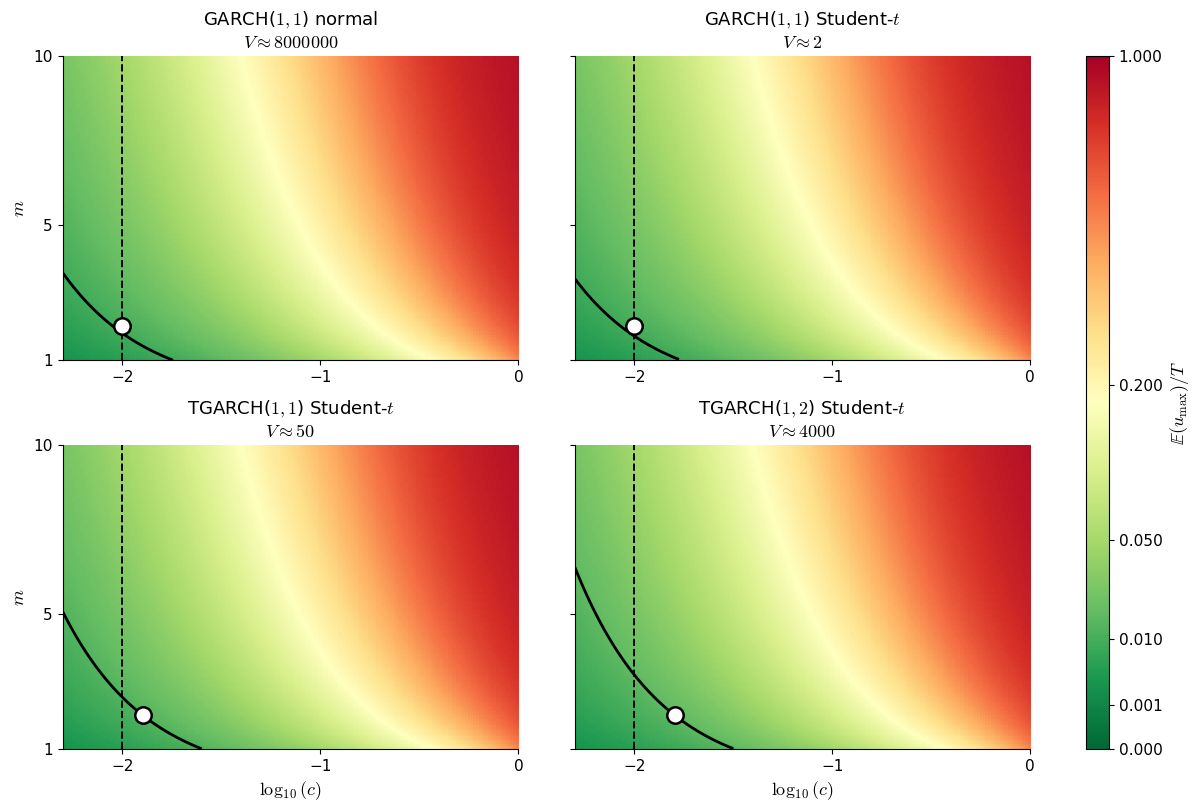

(<Figure size 1350x900 with 5 Axes>,
 [<Axes: title={'center': 'GARCH($1,1$) normal\n$V \\approx 8000000$'}, ylabel='$m$'>,
  <Axes: title={'center': 'GARCH($1,1$) Student-$t$\n$V \\approx 2$'}>,
  <Axes: title={'center': 'TGARCH($1,1$) Student-$t$\n$V \\approx 50$'}, xlabel='$\\log_{10}(c)$', ylabel='$m$'>,
  <Axes: title={'center': 'TGARCH($1,2$) Student-$t$\n$V \\approx 4000$'}, xlabel='$\\log_{10}(c)$'>])

In [96]:
assert len(results_by_Rmax_list) == 4, "Store (and append to list) only once for each model"
model_names = [r"GARCH($1,1$) normal", r"GARCH($1,1$) Student-$t$", r"TGARCH($1,1$) Student-$t$", r"TGARCH($1,2$) Student-$t$"]
V_tol_list = [8000000, 2, 50, 4000]

make_model_2x2_from_results_Rmax(
    T=T,
    t_star=t_star,
    b=b,
    results_by_Rmax_list=results_by_Rmax_list,
    model_names=model_names,
    V_tol_list=V_tol_list,
)

Run subsampling Markov chain Monte Carlo with TPD weights (tuned using $R_{\max}=100$).

In [97]:
# ==============================================================
# Subsampling MCMC: repeated runs with caching + per-run PDFs
# Fixed R_max = 100
# TGARCH(1,2) with Student-t errors
# ==============================================================

N = 12000
R_max = 100
n_repeat = 6
key_example = "TGARCH12_Student-t"

base_seed = SEEDS['App2_TGARCH12_Student-t_subsampling_mcmc_Rmax100']

MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------------
# Tuned estimator parameters for subsampling MCMC
# --------------------------------------------------------------
res_tune_subsampling_MCMC = results_by_Rmax[R_max]
V_target = float(res_tune_subsampling_MCMC["V_target"])
c_opt = float(res_tune_subsampling_MCMC["c_opt"])
m_opt = int(res_tune_subsampling_MCMC["m_opt"])
gamma_opt = float(res_tune_subsampling_MCMC["gamma_opt"])

estimator_params = {
    "m_opt": m_opt,
    "c_opt": c_opt,
    "gamma_opt": gamma_opt,
    "t_star": t_star,
    "b": b,
    "V_tolerance": V_target,
    "R_max": R_max,
}

# --------------------------------------------------------------
# Fixed initial value and fixed proposal covariance
# --------------------------------------------------------------
phi_init = MAP
Cov_phi = Cov  # Negative Hessian inverse evaluated at the mode

def phi_to_psi(phi):
    return theta_to_psi(hinv(phi))

J_phi_to_psi = Jacobian_autograd(phi_to_psi)
J_map = J_phi_to_psi(MAP)
Cov_psi = J_map @ Cov_phi @ J_map.T
Cov_psi = 0.5 * (Cov_psi + Cov_psi.T)
Cov_psi = make_pos_def(Cov_psi, eps=1e-8)
prop_cov = 0.1 * 2.38**2 / n_params * Cov_psi

# --------------------------------------------------------------
# Storage across repetitions
# --------------------------------------------------------------
result_list = []
diagnostics_list = []
status_list = []
cpu_list = []
cf_list = []
seed_list = []
log_path_list = []
save_path_list = []
pdf_path_list = []

section_name = f"06_subsampling_MCMC_Rmax{R_max}"

for run in range(1, n_repeat + 1):

    seed_run = base_seed + run
    np.random.seed(seed_run)

    save_path_subsampling_MCMC = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_rep{run}.h5"
    log_path_subsampling_MCMC = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_rep{run}.log"

    pdf_suffix = f"Rmax{R_max}_rep{run}"
    safe = section_name.replace(" ", "_").replace("/", "-")
    pdf_path_run = Path(out_dir) / f"{safe}_{pdf_suffix}.pdf"

    save_path_list.append(save_path_subsampling_MCMC)
    log_path_list.append(log_path_subsampling_MCMC)
    pdf_path_list.append(pdf_path_run)
    seed_list.append(seed_run)

    try:
        subsampling_MCMC_results = load_dict_h5(save_path_subsampling_MCMC)

        result_subsampling_MCMC = subsampling_MCMC_results["MCMC_obj"]
        prop_cov_run = np.asarray(subsampling_MCMC_results["prop_cov"])
        estimator_params_run = subsampling_MCMC_results["estimator_params"]

        for key in [
            "samples_phi",
            "samples_theta",
            "log_posthat_samples",
            "sigma2_lhat_samples",
            "u_max_prop",
        ]:
            if key in result_subsampling_MCMC:
                result_subsampling_MCMC[key] = np.asarray(result_subsampling_MCMC[key])

        run_diagnostics = subsampling_MCMC_results.get("run_diagnostics", None)
        run_status = subsampling_MCMC_results.get("run_status", None)

    except FileNotFoundError:

        with live_log_to_file(log_path_subsampling_MCMC):

            print("==============================================================", flush=True)
            print(f"Running subsampling MCMC with R_max = {R_max}", flush=True)
            print(f"Repetition = {run}/{n_repeat}", flush=True)
            print(f"Seed = {seed_run}", flush=True)
            print(f"N = {N}", flush=True)
            print(f"m_opt = {m_opt}", flush=True)
            print(f"c_opt = {c_opt}", flush=True)
            print(f"gamma_opt = {gamma_opt}", flush=True)
            print(f"V_target = {V_target}", flush=True)
            print("==============================================================", flush=True)

            result_subsampling_MCMC = sample_subsampling_posterior_random_walk_stationary_proposal(
                estimator_params,
                phi_init,
                prop_cov,
                N,
                names,
                dataset_name,
                adapt=False,
            )

            print("==============================================================", flush=True)

        prop_cov_run = prop_cov
        estimator_params_run = estimator_params

        # ----------------------------------------------------------
        # Compute run diagnostics
        # ----------------------------------------------------------
        longest_streak, first_stuck_iteration = longest_immobility_streak(
            result_subsampling_MCMC["samples_theta"]
        )
        stuck_flag = (longest_streak >= 100)

        cpu_tuning_cost = results_by_Rmax[R_max]["cpu_tuning_Rmax"]
        cpu_subsampling_MCMC = result_subsampling_MCMC["run_time"] + cpu_tuning_cost
        cf_subsampling_MCMC = np.sum(result_subsampling_MCMC["u_max_prop"] + 1) + 100 * T

        acceptance_rate = np.mean(result_subsampling_MCMC["alphas_MH"])

        run_diagnostics = {
            "run": run,
            "seed": seed_run,
            "longest_immobility_streak": int(longest_streak),
            "first_stuck_iteration": (
                int(first_stuck_iteration) if first_stuck_iteration is not None else -1
            ),
            "stuck_flag": bool(stuck_flag),
            "run_time": float(result_subsampling_MCMC["run_time"]),
            "cpu_total_including_tuning": float(cpu_subsampling_MCMC),
            "compute_fraction": float(cf_subsampling_MCMC),
            "acceptance_rate": acceptance_rate,
        }

        run_status = classify_mcmc_run(longest_streak, threshold_stuck=100)

        subsampling_MCMC_results = {
            "MCMC_obj": result_subsampling_MCMC,
            "prop_cov": prop_cov_run,
            "start_value": phi_init,
            "estimator_params": estimator_params_run,
            "seed": seed_run,
            "run_diagnostics": run_diagnostics,
            "run_status": run_status,
        }
        save_dict_h5(save_path_subsampling_MCMC, subsampling_MCMC_results)

    # --------------------------------------------------------------
    # If diagnostics/status were not cached, compute them now
    # --------------------------------------------------------------
    if run_diagnostics is None or run_status is None:

        longest_streak, first_stuck_iteration = longest_immobility_streak(
            result_subsampling_MCMC["samples_theta"]
        )
        stuck_flag = (longest_streak >= 100)

        cpu_tuning_cost = results_by_Rmax[R_max]["cpu_tuning_Rmax"]
        cpu_subsampling_MCMC = result_subsampling_MCMC["run_time"] + cpu_tuning_cost
        cf_subsampling_MCMC = np.sum(result_subsampling_MCMC["u_max_prop"] + 1) + 100 * T

        acceptance_rate = np.mean(result_subsampling_MCMC["alphas_MH"])

        run_diagnostics = {
            "run": run,
            "seed": seed_run,
            "longest_immobility_streak": int(longest_streak),
            "first_stuck_iteration": (
                int(first_stuck_iteration) if first_stuck_iteration is not None else -1
            ),
            "stuck_flag": bool(stuck_flag),
            "run_time": float(result_subsampling_MCMC["run_time"]),
            "cpu_total_including_tuning": float(cpu_subsampling_MCMC),
            "compute_fraction": float(cf_subsampling_MCMC),
            "acceptance_rate": acceptance_rate,
        }

        run_status = classify_mcmc_run(longest_streak, threshold_stuck=100)

    # --------------------------------------------------------------
    # Store in summary lists
    # --------------------------------------------------------------
    result_list.append(result_subsampling_MCMC)
    diagnostics_list.append(run_diagnostics)
    status_list.append(run_status)
    cpu_list.append(run_diagnostics["cpu_total_including_tuning"])
    cf_list.append(run_diagnostics["compute_fraction"])

    # --------------------------------------------------------------
    # Per-run PDF output
    # --------------------------------------------------------------
    with pdf_section(section_name, out_dir=out_dir, suffix=pdf_suffix, overwrite=False) as active:
        if active:
            text = log_path_subsampling_MCMC.read_text(encoding="utf-8")

            summary_text = (
                f"Repetition {run}/{n_repeat}\n"
                f"Seed = {seed_run}\n"
                f"Status = {run_status}\n"
                f"Longest immobility streak = {run_diagnostics['longest_immobility_streak']}\n"
                f"First stuck iteration = {run_diagnostics['first_stuck_iteration']}\n"
                f"Acceptance rate = {run_diagnostics['acceptance_rate']}\n"
                f"Run time = {run_diagnostics['run_time']:.2f}\n"
                f"CPU incl. tuning = {run_diagnostics['cpu_total_including_tuning']:.2f}\n"
                f"Compute fraction = {run_diagnostics['compute_fraction']:.2f}\n"
            )

            pdf_add_text(
                text + "\n\n" + summary_text,
                title=f"Subsampling MCMC sampling (R_max = {R_max}, repetition {run})",
            )

            # Standard MCMC traceplots
            plot_traceplots_MCMC(
                result_subsampling_MCMC["samples_theta"],
                param_true=hinv(MAP),
                param_names=param_names,
                burnin=0,
                thin=1,
                use_median=False,
                show_running_mean=True,
                runmean_window=50,
                suptitle=f"Traceplots subsampling MCMC (R_max = {R_max}, rep {run})",
            )
            pdf_add_fig()
            plt.close("all")

            # Additional subsampling-specific diagnostics
            plot_subsampling_MCMC_quantities(result_subsampling_MCMC)
            pdf_add_fig()
            plt.close("all")

# --------------------------------------------------------------
# Save master summary object across repetitions
# --------------------------------------------------------------
subsampling_MCMC_repeated_summary = {
    "R_max": R_max,
    "N": N,
    "n_repeat": n_repeat,
    "base_seed": base_seed,
    "key_example": key_example,
    "estimator_params": estimator_params,
    "start_value": phi_init,
    "prop_cov": prop_cov,
    "seed_list": seed_list,
    "status_list": status_list,
    "diagnostics_list": diagnostics_list,
    "cpu_list": cpu_list,
    "cf_list": cf_list,
    "save_path_list": [str(x) for x in save_path_list],
    "log_path_list": [str(x) for x in log_path_list],
    "pdf_path_list": [str(x) for x in pdf_path_list],
    "n_stuck": int(np.sum([s == "stuck" for s in status_list])),
    "n_mixed_well": int(np.sum([s == "mixed_well" for s in status_list])),
}

save_path_summary = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_summary.h5"
save_dict_h5(save_path_summary, subsampling_MCMC_repeated_summary)

print("==============================================================")
print(f"Finished repeated subsampling MCMC runs for R_max = {R_max}")
print(f"n_repeat = {n_repeat}")
print(f"mixed well = {subsampling_MCMC_repeated_summary['n_mixed_well']}/{n_repeat}")
print(f"stuck = {subsampling_MCMC_repeated_summary['n_stuck']}/{n_repeat}")
print(f"Summary saved to: {save_path_summary}")
print("==============================================================")

[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH12/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep1.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH12/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep2.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH12/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep3.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH12/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep4.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH12/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep5.pdf
[pdf_section] Exists, skipping: results/App2_MCMC/TGARCH12/Student-t/06_subsampling_MCMC_Rmax100_Rmax100_rep6.pdf
Finished repeated subsampling MCMC runs for R_max = 100
n_repeat = 6
mixed well = 6/6
stuck = 0/6
Summary saved to: results/App2_MCMC/TGARCH12/Student-t/MCMC/subsampling_MCMC_Rmax100_N12000_summary.h5


In [98]:
# ==============================================================
# Inspect repeated subsampling MCMC diagnostics
# ==============================================================

summary_path = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_summary.h5"
summary_obj = load_dict_h5(summary_path)

diagnostics_list = summary_obj["diagnostics_list"]
status_list = summary_obj["status_list"]
seed_list = summary_obj["seed_list"]

rows = []
for d, status, seed in zip(diagnostics_list, status_list, seed_list):
    rows.append({
        "run": int(d["run"]),
        "seed": int(seed),
        "status": status,
        "longest_immobility_streak": int(d["longest_immobility_streak"]),
        "first_stuck_iteration": (
            None if int(d["first_stuck_iteration"]) < 0 else int(d["first_stuck_iteration"])
        ),
        "acceptance_rate": (
            np.nan if d["acceptance_rate"] is None else float(d["acceptance_rate"])
        ),
        "run_time": float(d["run_time"]),
        "cpu_total_including_tuning": float(d["cpu_total_including_tuning"]),
        "compute_fraction": float(d["compute_fraction"]),
    })

diag_df = pd.DataFrame(rows).sort_values("run").reset_index(drop=True)

print("==============================================================")
print("Repeated subsampling MCMC diagnostics")
print("==============================================================")
print(diag_df.to_string(index=False))

print("\n==============================================================")
print("Aggregate summaries")
print("==============================================================")
print(f"Number of runs: {len(diag_df)}")
print(f"Status counts:\n{diag_df['status'].value_counts(dropna=False)}")
print()
print("Longest immobility streak:")
print(f"  min    = {diag_df['longest_immobility_streak'].min()}")
print(f"  median = {diag_df['longest_immobility_streak'].median()}")
print(f"  max    = {diag_df['longest_immobility_streak'].max()}")

if diag_df["acceptance_rate"].notna().any():
    print()
    print("Acceptance rate:")
    print(f"  min    = {diag_df['acceptance_rate'].min():.4f}")
    print(f"  median = {diag_df['acceptance_rate'].median():.4f}")
    print(f"  max    = {diag_df['acceptance_rate'].max():.4f}")

print()
print("Runtime:")
print(f"  min    = {diag_df['run_time'].min():.2f}")
print(f"  median = {diag_df['run_time'].median():.2f}")
print(f"  max    = {diag_df['run_time'].max():.2f}")

print()
print("Compute fraction:")
print(f"  min    = {diag_df['compute_fraction'].min():.2f}")
print(f"  median = {diag_df['compute_fraction'].median():.2f}")
print(f"  max    = {diag_df['compute_fraction'].max():.2f}")
print("==============================================================")

Repeated subsampling MCMC diagnostics
 run  seed     status  longest_immobility_streak first_stuck_iteration  acceptance_rate   run_time  cpu_total_including_tuning  compute_fraction
   1 78902 mixed_well                         64                  None         0.314419 571.683540                  702.589641        29504335.0
   2 78903 mixed_well                         20                  None         0.508305 430.238039                  561.144140        28603056.0
   3 78904 mixed_well                         30                  None         0.363637 410.673243                  541.579344        28378474.0
   4 78905 mixed_well                         27                  None         0.465414 444.313608                  575.219709        29535626.0
   5 78906 mixed_well                         61                  None         0.391688 486.133415                  617.039516        30827228.0
   6 78907 mixed_well                         19                  None         0.511397 519.

Chains for TGARCH($1,2$) with Student-$t$ errors.

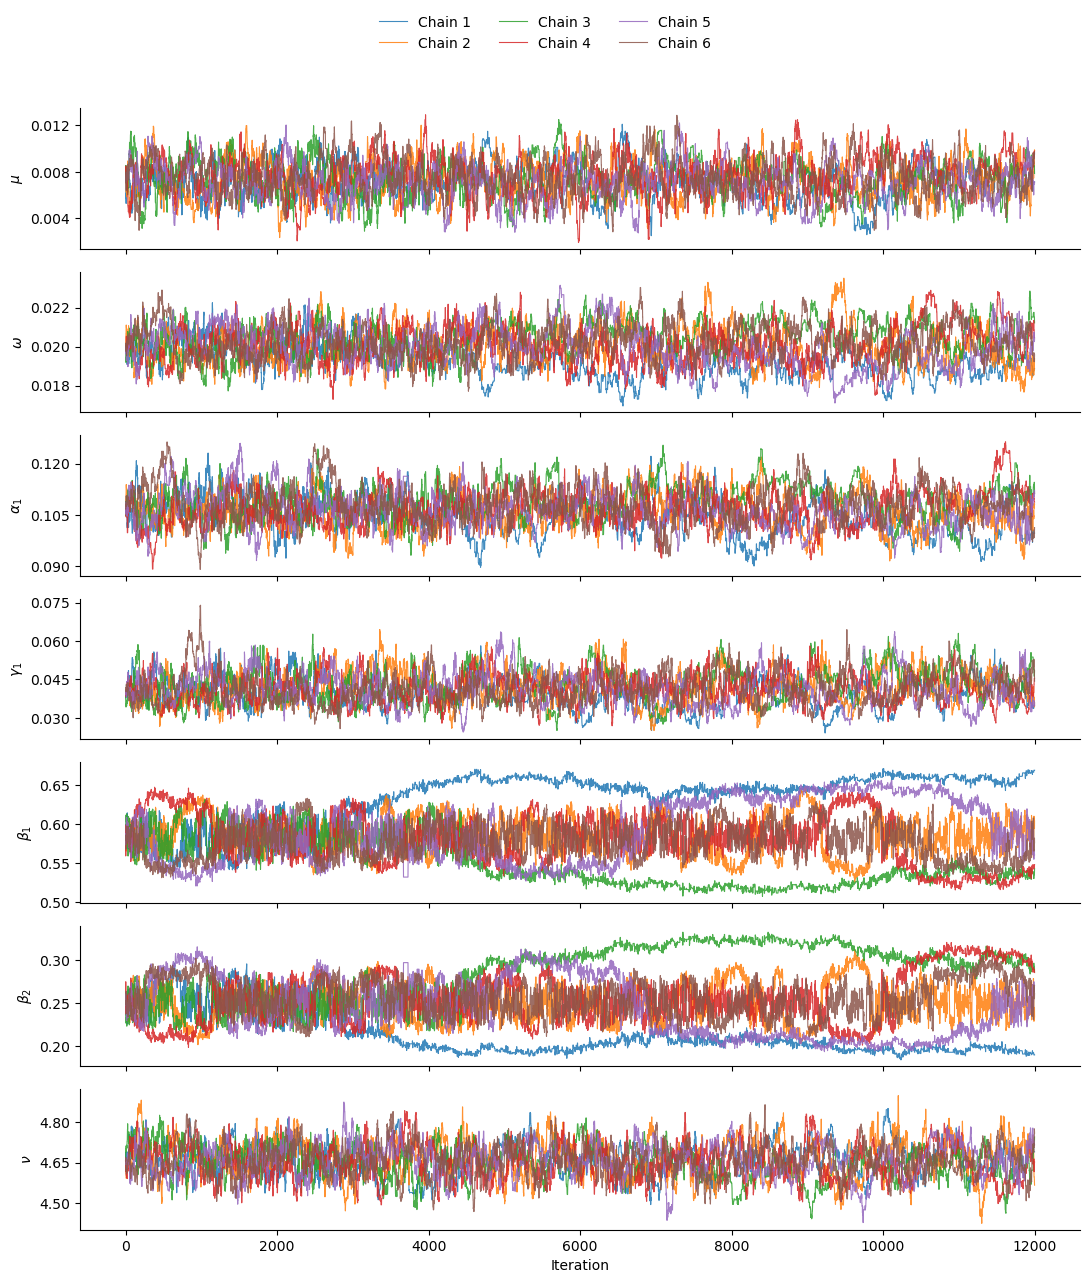

In [99]:
chains = [r['samples_theta'] for r in result_list]
chain_labels = [f"Chain {i+1}" for i in range(6)]

fig, axes = plot_traceplots_MCMC_chains(
    param_draws=chains,
    param_names=param_names,
    chain_labels=chain_labels,
    burnin=0,
    thin=1,
    show_running_mean=False
)

Compute the log-predictive score using subsampling MCMC.

In [100]:
result_subsampling_MCMC_R_max100 = result_list[-1] # Looks to be mixing OK
result_tgarch12_Student_t = result_list[-1]

# Compute joint out-of-sample predictive score
y_test = np.load("data/AAPL_10000obs.npy")
y_test = y_test/series.std()

# Evaluate model
evaluate_dir = out_dir / "evaluate"
evaluate_dir.mkdir(parents=True, exist_ok=True)
save_path_evaluate = evaluate_dir / ("log_pred_score.h5")
log_path_evaluate = evaluate_dir / ("evaluate_score.log")

samples_theta = result_subsampling_MCMC_R_max100["samples_theta"][2001::100] # 

try:
    log_predictive_results = load_dict_h5(save_path_evaluate)
    log_pred = log_predictive_results['log_scores']
    S = log_predictive_results['sum_log_scores']

except FileNotFoundError:

    with live_log_to_file(log_path_evaluate):

        # Compute the log-predictive score
        print("==============================================================", flush=True)
        S, log_pred = joint_predictive_score(samples_theta, y, y_test, p, q, y_start, sigma2_start, log_densities)
        print(f"p={p}, q={q}, error={error_type}, log_pred score sum = {S}")
        print("==============================================================", flush=True)
        log_predictive_results = {'sum_log_scores': S, 'log_scores': log_pred}
        save_dict_h5(save_path_evaluate, log_predictive_results)


mc_summary = predictive_score_mc_ci(log_pred)
print("Joint predictive score:", mc_summary["score_hat"])
print("MC standard error:", mc_summary["se"])
print("Approx. 95% CI: ({:.6f}, {:.6f})".format(
    mc_summary["ci_lower"], mc_summary["ci_upper"]
))
print("IACT:", mc_summary["tau_int"])
print("ESS:", mc_summary["ess"])




Joint predictive score: -9204.55247237256
MC standard error: 0.6297467496275707
Approx. 95% CI: (-9205.786753, -9203.318191)
IACT: 1.3012231973083022
ESS: 76.85076642259303


Full-data Markov chain Monte Carlo.

In [101]:
np.random.seed(SEEDS["App2_TGARCH12_Student-t_full_data_mcmc"])
N = 12000
MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)
save_path_MCMC = MCMC_dir / ("Full_data_MCMC_N%s.h5" % N)
log_path_MCMC = MCMC_dir / ("Full_data_MCMC_N%s.log" % N)

try:
    MCMC_results = load_dict_h5(save_path_MCMC)
    full_data_MCMC = MCMC_results['MCMC_obj']
    prop_cov = MCMC_results['prop_cov']
    # Convert back to arrays
    for key in ["samples_phi", "samples_theta"]:
        full_data_MCMC[key] = np.asarray(full_data_MCMC[key])

except FileNotFoundError:

    with live_log_to_file(log_path_MCMC):

        # Run MCMC (proposal parameterised to obey stationarity)
        # Transform to Psi by linearising
        def phi_to_psi(phi):
            return theta_to_psi(hinv(phi))

        J_phi_to_psi = Jacobian_autograd(phi_to_psi)
        J_map = J_phi_to_psi(MAP)
        Cov_phi = Cov
        Cov_psi = J_map @ Cov_phi @ J_map.T
        Cov_psi = 0.5 * (Cov_psi + Cov_psi.T)
        Cov_psi = make_pos_def(Cov_psi, eps=1e-8)
        prop_cov = 0.1*2.38**2 / n_params * Cov_psi
        phi_init = MAP 
        print("==============================================================", flush=True)
        full_data_MCMC = sample_full_data_posterior_AM_stationary_proposal(phi_init, prop_cov, N, names,dataset_name, adapt_cov=True, adapt_scale=True, burn_in = 1000)
        print("==============================================================", flush=True)        

        MCMC_results = {'MCMC_obj': full_data_MCMC, 'prop_cov': prop_cov, 'start_value': phi_init}
        save_dict_h5(save_path_MCMC, MCMC_results)

    with pdf_section("07_full_data_MCMC", out_dir=out_dir) as active:
        if active:
            text = log_path_MCMC.read_text(encoding="utf-8")
            pdf_add_text(text, title="Full data MCMC sampling.")

            plot_traceplots_MCMC(
                full_data_MCMC['samples_phi'],
                param_true=MAP, param_names=trans_param_names,
                burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
                suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
            )
            pdf_add_fig()          # saves all figures created by plot_traceplots_MCMC
            plt.close("all")       

(<Figure size 1000x1120 with 7 Axes>,
 array([<Axes: ylabel='$\\widetilde{\\mu}$'>,
        <Axes: ylabel='$\\widetilde{\\omega}$'>,
        <Axes: ylabel='$\\widetilde{\\alpha}_1$'>,
        <Axes: ylabel='$\\widetilde{\\gamma}_1$'>,
        <Axes: ylabel='$\\widetilde{\\beta}_1$'>,
        <Axes: ylabel='$\\widetilde{\\beta}_2$'>,
        <Axes: xlabel='iteration (including burn-in)', ylabel='$\\widetilde{\\nu}$'>],
       dtype=object))

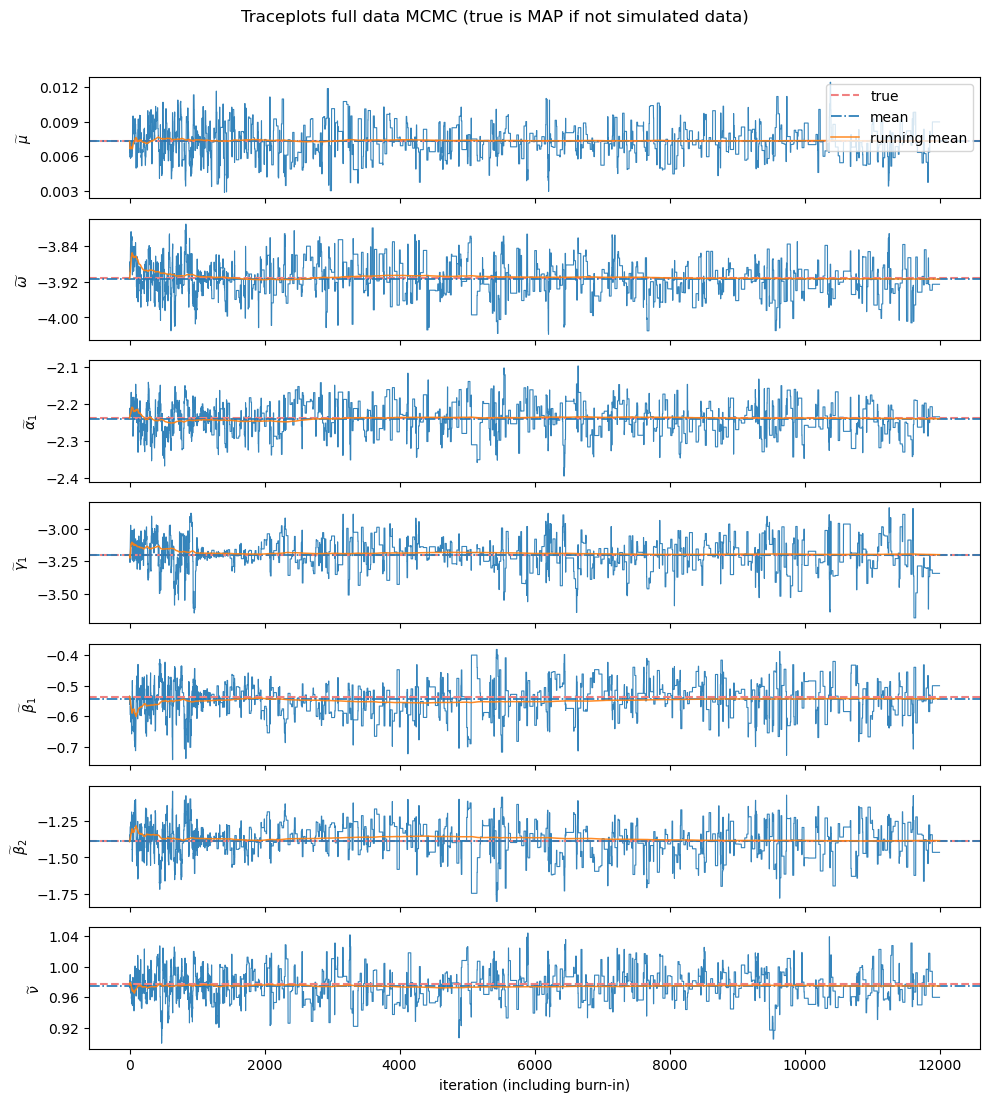

In [102]:
plot_traceplots_MCMC(
full_data_MCMC['samples_phi'],
param_true=MAP, param_names=trans_param_names,
burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
)


Predictive score full-data MCMC

In [103]:
# Evaluate model
evaluate_dir = out_dir / "evaluate"
evaluate_dir.mkdir(parents=True, exist_ok=True)
save_path_evaluate = evaluate_dir / ("log_pred_score_full_data.h5")
log_path_evaluate = evaluate_dir / ("evaluate_score_full_data.log")

samples_theta = full_data_MCMC["samples_theta"][2001::100] # 

try:
    log_predictive_results = load_dict_h5(save_path_evaluate)
    log_pred = log_predictive_results['log_scores']
    S = log_predictive_results['sum_log_scores']

except FileNotFoundError:

    with live_log_to_file(log_path_evaluate):

        # Compute the log-predictive score
        print("==============================================================", flush=True)
        S, log_pred = joint_predictive_score(samples_theta, y, y_test, p, q, y_start, sigma2_start, log_densities)
        print(f"p={p}, q={q}, error={error_type}, log_pred score sum = {S}")
        print("==============================================================", flush=True)
        log_predictive_results = {'sum_log_scores': S, 'log_scores': log_pred}
        save_dict_h5(save_path_evaluate, log_predictive_results)



mc_summary_full_data = predictive_score_mc_ci(log_pred)
print("Predictive score with full_data MCMC")
print("Joint predictive score:", mc_summary_full_data["score_hat"])
print("MC standard error:", mc_summary_full_data["se"])
print("Approx. 95% CI: ({:.6f}, {:.6f})".format(
    mc_summary_full_data["ci_lower"], mc_summary_full_data["ci_upper"]
))
print("IACT:", mc_summary_full_data["tau_int"])
print("ESS:", mc_summary_full_data["ess"])

Predictive score with full_data MCMC
Joint predictive score: -9201.88288998204
MC standard error: 0.8278558995495351
Approx. 95% CI: (-9203.505458, -9200.260322)
IACT: 1.0
ESS: 100.0


Save to create tables for subsampling MCMC results and predictive scores.

In [104]:
tables_TGARCH12_Student_t = make_model_summary_for_tables(
    model_label="TGARCH(1,2), Student-t",
    subsampling_summary=subsampling_MCMC_repeated_summary,
    cpu_cv=cpu_CV,
    full_data_MCMC=full_data_MCMC,
    predictive_summary_subsampling=mc_summary,
    predictive_summary_full_data=mc_summary_full_data,
    comment="stable baseline"
)


All four models finished. Create Tables S1 and S2 in the supplement.

In [105]:
all_table_summaries = [
    tables_GARCH11_norm,
    tables_GARCH11_Student_t,
    tables_TGARCH11_Student_t,
    tables_TGARCH12_Student_t
]
latex_table1 = render_subsampling_table_latex(12000, T, all_table_summaries)
latex_table2 = render_score_table_latex(all_table_summaries)

print(latex_table1)
print(latex_table2)

\begin{table}[t]
\centering
\small
\setlength{\tabcolsep}{4pt}
\caption{Subsampling MCMC behaviour and computational cost across models.}
\label{tab:mcmc_behaviour}
\begin{tabular}{lccccc}
\toprule
Model & \makecell{Median \\ LIS} & \makecell{Median \\ CPU} & \makecell{Median \\ CF} & \makecell{Full-data \\ CPU} & \makecell{Median \\ RCPU} \\
\midrule
GARCH(1,1), normal & \makecell{22.0 \\ {(20, 26)}} & \makecell{850.1 \\ {(794.1, 956.7)}} & \makecell{0.019 \\ {(0.018, 0.020)}} & 69039.4 & \makecell{81.2 \\ {(72.2, 86.9)}} \\
GARCH(1,1), Student-t & \makecell{16.5 \\ {(15, 19)}} & \makecell{507.8 \\ {(473.1, 528.8)}} & \makecell{0.019 \\ {(0.018, 0.020)}} & 31792.4 & \makecell{62.6 \\ {(60.1, 67.2)}} \\
TGARCH(1,1), Student-t & \makecell{18.0 \\ {(15, 19)}} & \makecell{673.2 \\ {(661.4, 703.9)}} & \makecell{0.022 \\ {(0.021, 0.023)}} & 39697.2 & \makecell{59.0 \\ {(56.4, 60.0)}} \\
TGARCH(1,2), Student-t & \makecell{28.5 \\ {(19, 64)}} & \makecell{769.0 \\ {(714.4, 875.5)}} & \makecell

Compare accuracy toward full-data MCMC and also effective sample size (ESS). Note that due to potential convergence issues, this comparison is not reliable and is therefore not in the paper.

(<Figure size 1600x600 with 7 Axes>,
 array([<Axes: xlabel='$\\mu$'>, <Axes: xlabel='$\\omega$'>,
        <Axes: xlabel='$\\alpha_1$'>, <Axes: xlabel='$\\gamma_1$'>,
        <Axes: xlabel='$\\beta_1$'>, <Axes: xlabel='$\\beta_2$'>,
        <Axes: xlabel='$\\nu$'>, <Axes: >], dtype=object),
 array([[144.32791964,  96.47712071,  79.73607933,  76.87576286,
          26.51898821,  22.9585065 , 170.66795185],
        [290.79971714, 278.0190417 , 191.50237215, 240.80288215,
         257.77570234, 258.65116644, 242.5612598 ]]))

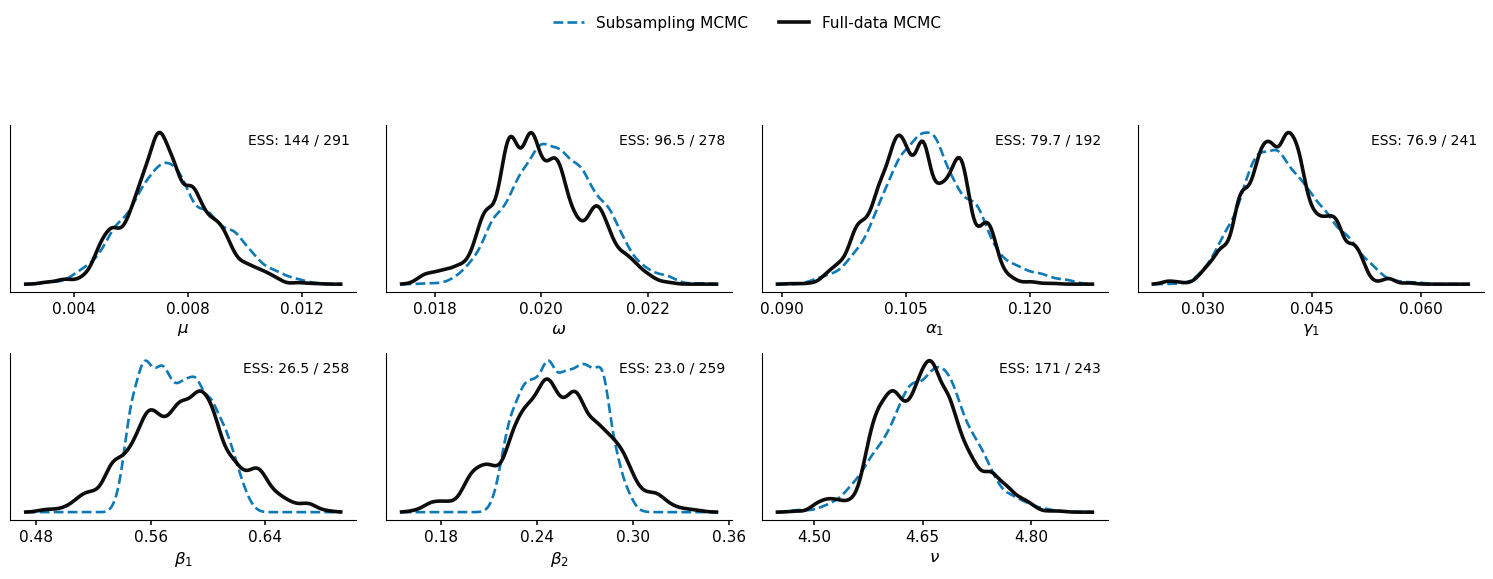

In [106]:
plot_kde_with_ESS_comparison(
            result_subsampling_MCMC_R_max100["samples_theta"][2000:, :],
            full_data_MCMC['samples_theta'][2000:, :],
            param_names=param_names,
            title="Posterior marginals (phi): Subsampling MCMC vs MCMC",
            n_points=200,
            true_vals=None,
            labels=("Subsampling MCMC", "Full-data MCMC"),
            ess_fmt="compact"
        )

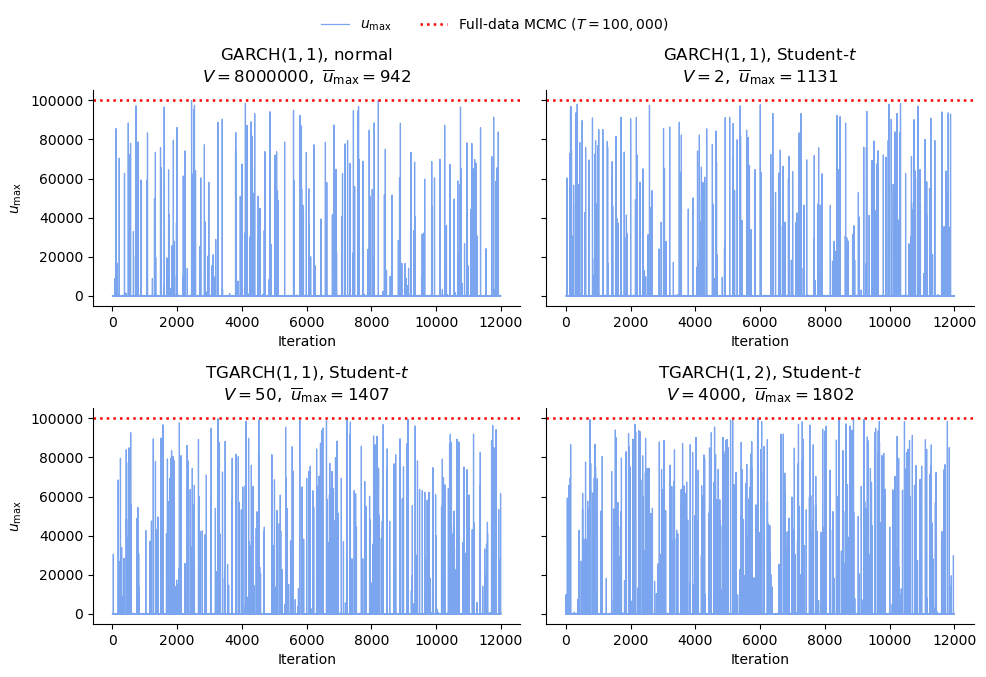

In [107]:
results_list = [
    result_garch11_normal,
    result_garch11_Student_t,
    result_tgarch11_Student_t,
    result_tgarch12_Student_t,
]

model_titles = [
    r"GARCH$(1,1)$, normal",
    r"GARCH$(1,1)$, Student-$t$",
    r"TGARCH$(1,1)$, Student-$t$",
    r"TGARCH$(1,2)$, Student-$t$",
]

V_tol_list = [8000000, 2, 50, 4000]   # or whatever rounded values you want to display

fig, axes = plot_umax_history_subsampling_mcmc_4models(
    results_list=results_list,
    model_titles=model_titles,
    benchmark_umax=100000,
    V_tol_list=V_tol_list,
    figsize=(10, 7),
)

## 4. Comparison against stochastic gradient Markov chain Monte Carlo

This section compares our stabilised weighted subsampling approach against the stochastic gradient Markov chain Monte Carlo (SG-MCMC) approach for nonlinear state space models in Aicher et al. (2025). Their paper contains a GARCH with noise model. See Section S4.2 of our paper on how this reconciles with our model formulation.

The comparison is carried out in the following steps.

Step 1: Confirm that our full-data GARCH posterior (corresponds to $\tau^2=0$) can be used to represent the ground truth when $\tau^2>0$, for $\tau^2$ small relative to $\mathbb{E}(\sigma^2_t)$. This allows us to have something to compare our approach and the SG-MCMC too (unfortunately, Aicher et al. do not contain code to do a full-data benchmark comparison).

Step 2: Step 1 shows that $\tau^2$ being $0.01\%$ of $\mathbb{E}(\sigma^2_t)$ gives nearly indistinguishable posterior from $\tau^2=0$. Hence, fit subsampling MCMC to data generated under this $\tau^2$ value and compare against SG-MCMC, and also include full-data MCMC as a ground truth.

We use $\omega$, $\alpha_1$, and $\beta_1$ values calibrated from our Dow Jones Industrial Average example in the main paper.

These are as follows: $\omega = 0.07134079, \alpha_1 = 0.16151262, \beta_1 = 0.78591371$, which corresponds to an unconditional variance 

$$\mathbb{E}(\sigma^2_t) = \frac{\omega}{1 - \alpha_1 - \beta_1}. $$

In [108]:
# Output directory
out_dir = Path("results")
data_dir = out_dir / "SG_MCMC" / "data"

# Create directory (including parents)
data_dir.mkdir(parents=True, exist_ok=True)

# True parameters from calibrating the model to the Dow Jones Industrial Average index
omega = 0.07134079
alpha1 = 0.16151262
beta1 = 0.78591371
T = 100_000

# Unconditional variance
Esigma2 = omega / (1.0 - alpha1 - beta1)

print(f"E(sigma_t^2) = {Esigma2:.6f}")

# Observation-noise variances as proportions of E(sigma_t^2)
tau2_0 = 0.00 * Esigma2
tau2_0p01pct = 0.0001 * Esigma2
tau2_1pct = 0.01 * Esigma2

print(f"tau2 (0% of E[sigma_t^2]) = {tau2_0:.6f}")
print(f"tau2 (0.01% of E[sigma_t^2]) = {tau2_0p01pct:.6f}")
print(f"tau2 (1% of E[sigma_t^2]) = {tau2_1pct:.6f}")

# Initial values at time 0
sigma2_0 = Esigma2
y0 = 0.0

sim_tau0 = simulate_latent_garch11(
    T=T,
    omega=omega,
    alpha1=alpha1,
    beta1=beta1,
    tau2=tau2_0,
    sigma2_0=sigma2_0,
    y0=y0,
    latent_seed=SEEDS["SG-MCMC_investigate_tau2"],
    obs_seed= SEEDS["SG-MCMC_investigate_tau2"] + 1,
)

sim_tau0p01 = simulate_latent_garch11(
    T=T,
    omega=omega,
    alpha1=alpha1,
    beta1=beta1,
    tau2=tau2_0p01pct,
    sigma2_0=sigma2_0,
    y0=y0,
    latent_seed=SEEDS["SG-MCMC_investigate_tau2"],
    obs_seed=SEEDS["SG-MCMC_investigate_tau2"] + 1,
)


sim_tau1 = simulate_latent_garch11(
    T=T,
    omega=omega,
    alpha1=alpha1,
    beta1=beta1,
    tau2=tau2_1pct,
    sigma2_0=sigma2_0,
    y0=y0,
    latent_seed=SEEDS["SG-MCMC_investigate_tau2"],
    obs_seed=SEEDS["SG-MCMC_investigate_tau2"] + 1,
)


# Same latent process and same sigma_t^2 across tau2 choices
print("Same x_t across tau2 choices:",
      np.allclose(sim_tau0["x"], sim_tau1["x"]) and np.allclose(sim_tau0["x"], sim_tau0p01["x"]))

print("Same sigma_t^2 across tau2 choices:",
      np.allclose(sim_tau0["sigma2"], sim_tau1["sigma2"]) and np.allclose(sim_tau0["sigma2"], sim_tau0p01["sigma2"]))

# Example to pass to our likelihood 
y_start = sim_tau1["y"][0]
sigma2_start = sim_tau1["sigma2"][0]
y_data = sim_tau1["y"][1:]

print(y_start, sigma2_start, y_data.shape)
# Sanity checks: same latent path and same conditional variances
print("Same latent x_t across tau2 values:",
      np.allclose(sim_tau0["x"], sim_tau1["x"]) and np.allclose(sim_tau0["x"], sim_tau0p01["x"]))

save_simulation(sim_tau0, "garch_tau2_0", data_dir)
save_simulation(sim_tau0p01, "garch_tau2_0p01pct", data_dir)
save_simulation(sim_tau1, "garch_tau2_1pct", data_dir)


E(sigma_t^2) = 1.356968
tau2 (0% of E[sigma_t^2]) = 0.000000
tau2 (0.01% of E[sigma_t^2]) = 0.000136
tau2 (1% of E[sigma_t^2]) = 0.013570
Same x_t across tau2 choices: True
Same sigma_t^2 across tau2 choices: True
0.0 1.3569680412267202 (100000,)
Same latent x_t across tau2 values: True
Saved: results/SG_MCMC/data/garch_tau2_0.npz
Saved: results/SG_MCMC/data/garch_tau2_0p01pct.npz
Saved: results/SG_MCMC/data/garch_tau2_1pct.npz


Visually inspect the differences (should be small).

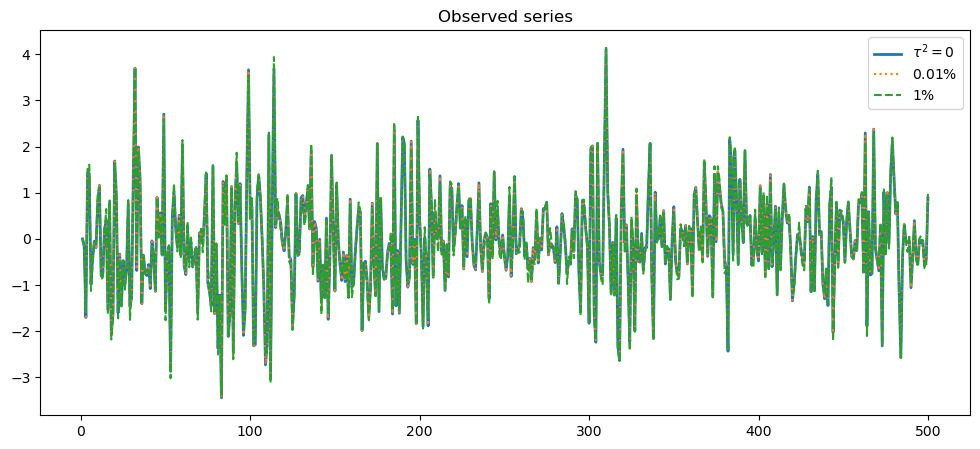

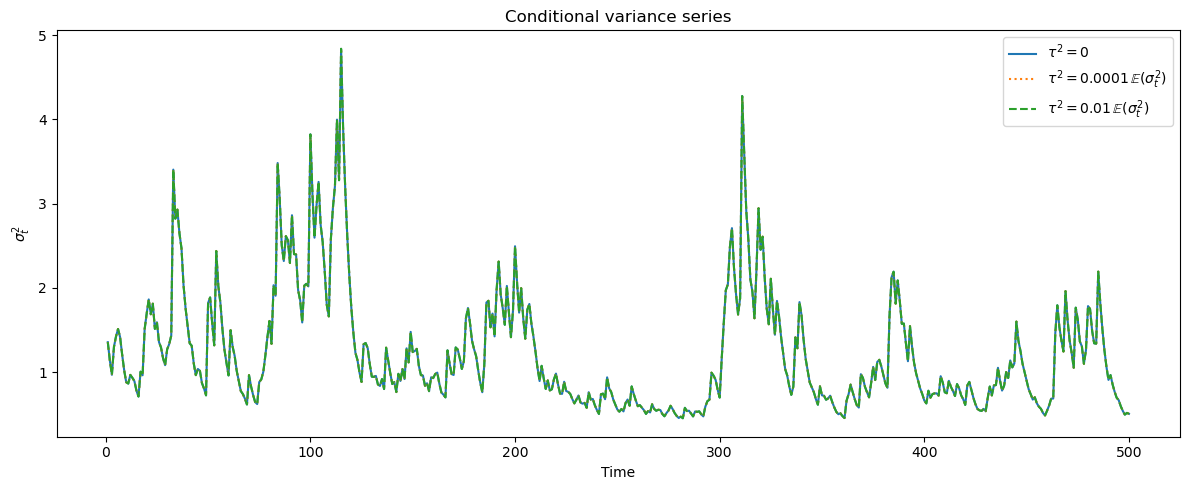

In [109]:
# Number of observations to display
n_plot = 500

t = np.arange(1, n_plot + 1)

# Plot 1: observed series y_t for tau2 = 0, 1%, 5%
plt.figure(figsize=(12, 5))
plt.plot(t, sim_tau0["y"][:n_plot], label=r"$\tau^2 = 0$", linewidth=2)
plt.plot(t, sim_tau0p01["y"][:n_plot], linestyle=":", label=r"$0.01\%$")
plt.plot(t, sim_tau1["y"][:n_plot], linestyle="--", label=r"$1\%$")

plt.legend()
plt.title("Observed series")
plt.show()

# Plot 2: conditional variance sigma_t^2
plt.figure(figsize=(12, 5))
plt.plot(t, sim_tau0["sigma2"][:n_plot], label=r"$\tau^2 = 0$")
plt.plot(t, sim_tau0p01["sigma2"][:n_plot], linestyle=":",
         label=r"$\tau^2 = 0.0001\,\mathbb{E}(\sigma_t^2)$")
plt.plot(t, sim_tau1["sigma2"][:n_plot], linestyle="--",
         label=r"$\tau^2 = 0.01\,\mathbb{E}(\sigma_t^2)$")
plt.xlabel("Time")
plt.ylabel(r"$\sigma_t^2$")
plt.title("Conditional variance series")
plt.legend()
plt.tight_layout()
plt.show()

### 4.1 Investigate $\tau^2$ effect on posterior

Estimate full-data posterior for $\tau^2 = 0$.

[pdf_section] Exists, skipping: results/SG_MCMC/GARCH11_tau2_0/normal/01_settings_and_data_plot.pdf
GARCH_type: GARCH , Error distribution: normal
Lags: p =,  1 q =  1
Dataset name:  tau2_0_example_GARCH(1,1)_normal_error
Number of observations:  100000
Parameters:
Tranformations:
 ['identity', 'identity', 'identity', 'identity']
Number of parameters: 4
Prior hyperparameters (v_rate and v_shape only if Student-t)
alpha_scale : 0.2
beta_scale  : 0.8
mu_mean     : 0
mu_sd       : 10
omega_scale : 1
v_rate      : 1
v_shape     : 2


$\mu$, $\omega$, $\alpha_1$, $\beta_1$

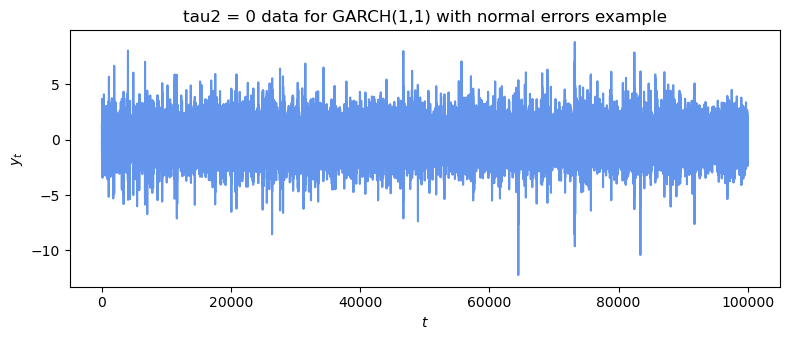

95% Confidence intervals for MLE estimates (phi)
[-0.01  0.07  0.16  0.78]
[0.01 0.08 0.17 0.79]



95% Credible intervals for posterior (phi)
[-0.01  0.07  0.16  0.78]
[0.01 0.08 0.17 0.79]





In [110]:
app = "SG_MCMC" # To create folders
model = "GARCH11_tau2_0" # To create folders

GARCH_type = "GARCH"
error_type = "normal"

T = 100000 # Length of time series
p = 1 # Nbr of autoregressive y-lags in the GARCH-type variance process
q = 1 # Nbr of autoregressive sigma2-lags in the GARCH-type variance process
# Specify transforms (set all "identity" if no transformation)
dataset_name = "tau2_0_example_%s(%s,%s)_%s_error" % (GARCH_type, p, q, error_type)

param_names, trans_param_names = get_param_names(GARCH_type, error_type, p, q)
names = {"params_name": param_names, "trans_param_names": trans_param_names}    
transforms = ["identity"] + ["identity"] + p*["identity"] + q*["identity"]

# Likelihood optimisation settings (posterior optimisation always uses L-BFGS-B as it has a better starting value):
likelihood_optim = "L-BFGS-B" 
options_L_BFGS_B = {"gtol":1e-6, "ftol":1e-12, "maxls":50, "maxiter":2000, "disp":True}
options_trust_ncg = {"gtol":1e-6, "maxiter":2000, "disp":True}
options_basinhopping = {"niter":5, "stepsize":0.5, "T":1.0, "disp":True}

# Prior settings:
# The default settings are
# mu_mean = 0.0, mu_sd = 10.0, omega_scale = 1.0, alpha_scale = 0.2, beta_scale = 0.8, v_shape = 2.0, v_rate = 1.0
# If other setting required, save as dictionary and pass on to the log prior once defined.
# Example:
prior_args = "default"
# prior_args = {"mu_mean":0.0, "mu_sd":100.0, "omega_scale":1.0, "alpha_scale":0.2, "beta_scale":0.8, "v_shape":2.0, "v_rate":1.0}

# Initialise prior. Either with default parameters or as specificed in prior_args
if prior_args == "default":
    log_prior = initiate_priors(GARCH_type, error_type)
    f = {"GARCH": log_prior_GARCH, "TGARCH": log_prior_TGARCH}[GARCH_type]
    prior_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    prior_hyperparams = prior_args
    log_prior = initiate_priors(GARCH_type, error_type, **prior_hyperparams)

# Penalty settings:
penalty_args = "default"

# Inititialise penalties for frequentist estimation
if penalty_args == "default":
    log_penalty = initiate_penalties(GARCH_type, error_type)
    f = {"GARCH": log_penalty_GARCH, "TGARCH": log_penalty_TGARCH}[GARCH_type]
    penalty_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    penalty_hyperparams = penalty_args
    log_penalty = initiate_penalties(GARCH_type, error_type, **penalty_hyperparams)
    
        
# Create model functions based on the inputs above
h, hinv, hinv_p, hinv_pp, jacdiag, logdet = initiate_transformation_functions(transforms)
log_densities, grad_log_densities, Hess_log_densities = initiate_model_functions(GARCH_type, error_type, hinv, hinv_p, hinv_pp)


# Functions to reparameterise the proposal density to a space where the GARCH/TGARCH process is stationary
theta_to_psi, psi_to_theta, logabsdet_dpsi_dtheta = initiate_persistence_reparam_functions(GARCH_type=GARCH_type, error_type=error_type, p=p, q=q, h=h,
                                                                                           hinv=hinv, jacdiag=jacdiag, param_names=param_names, delta=1e-4)


# Read in data
# tau2 = 0 example
y_start = np.array([sim_tau0["y"][0]])
sigma2_start = np.array([sim_tau0["sigma2"][0]])
y = sim_tau0["y"][1:]
# End read data

theta0 = None # True values not available for real data
phi0 = None
if GARCH_type == 'GARCH':
    n_params = 2 + p + q
elif GARCH_type == 'TGARCH':
    n_params = 2 + 2*p + q
    
if error_type == 'Student-t':
    n_params += 1
assert(len(transforms) == n_params)

# Keep text selectable in the PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
# Latex
mpl.rcParams['text.usetex'] = False 

out_dir = Path("results") / app / model / error_type
out_dir.mkdir(parents=True, exist_ok=True)

with pdf_section("01_settings_and_data_plot", out_dir=out_dir) as active:
    with capture_output(display) as cap:
        print("==============================================================")
        print("GARCH_type:", GARCH_type, ", Error distribution:", error_type)
        print("Lags: p =, ", p, "q = ", q)
        print("Dataset name: ", dataset_name)
        print("Number of observations: ", T)
        print("Parameters:")
        display(Markdown(", ".join(param_names)))
        print("Tranformations:\n", transforms)
        print("Number of parameters:", n_params)
        print("Prior hyperparameters (v_rate and v_shape only if Student-t)")
        print_kv(prior_hyperparams)
        print("==============================================================")

    # Show in notebook
    cap.show()

    # Only write to PDF if active
    if active:
        text = cap.stdout
        pdf_add_text(text, title="Model and settings specified")

    # Measurements
    plt.figure(figsize=(8, 3.5))
    plt.title(f"tau2 = 0 data for {GARCH_type}({p},{q}) with {error_type} errors example")
    plt.plot(y, color="cornflowerblue")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$y_t$")
    plt.tight_layout()

    # Only write figure to PDF if active
    if active:
        pdf_add_fig()

    plt.show()



# Optimise likelihood
# Minimise in phi space, so input is unrestricted
def log_penalty_phi(x, p, q):
    return log_penalty(hinv(x), p, q)

def obj_func_likelihood(x):
    """
    Penalised log-likelihood. To enforce the
    """
    return -log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + log_penalty_phi(x, p, q)# /T

grad_log_penalty = grad(log_penalty_phi) #(x, p, q)
Hess_log_penalty = hessian(log_penalty_phi)

grad_obj_func_likelihood = lambda x: -grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + grad_log_penalty(x, p, q) #/T # Gradient of obj_func_likelihood. Computed by automatic differentiation
Hess_obj_func_likelihood = lambda x: -Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + Hess_log_penalty(x, p, q) #/T # Hessian of obj_func_likelihood. Computed by automatic differentiation

optim_dir = out_dir / "optim"
optim_dir.mkdir(parents=True, exist_ok=True)
save_path_optim = optim_dir / "optim_likelihood_result.h5"
log_path_optim = optim_dir / "optim_likelihood_live.log"

# Optimise the log-likelihood
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)


try:
    optim_results = load_dict_h5(save_path_optim)
    MLE = np.array(optim_results['optim_obj']['x'])
    Cov = optim_results['Cov_MLE']
    print('95% Confidence intervals for MLE estimates (phi)')
    print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2))
    print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2))
    print("\n\n")
    
except FileNotFoundError:
    # Optimise the log-likelihood
    mu_0 = 0
    alpha_0 = np.array([0.05])
    assert(len(alpha_0) == p)
    gamma_0 = np.array([0.03])[:p] # Not active (GARCH here)
    assert(len(alpha_0) == p)
    beta_0 = np.array([0.80])[:q]
    assert(len(beta_0) == q)
    omega_0 = 0.05
    assert(omega_0 >= 0)
    if error_type == "Student-t": 
        v_0 = 15
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0, v_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0, v_0)).flatten()  
            print(theta_optim_start)
    else: # normal error
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0)).flatten()

    phi_optim_start = h(theta_optim_start)
    
    start = time.perf_counter()
    it = {"k": 0} # For callback
    fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)

    with live_log_to_file(log_path_optim):

        if likelihood_optim == "trust-ncg":
            print('\n\nLikelihood optimisation settings for method trust-ncg:\n', flush=True)
            options = options_trust_ncg
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                jac=fg.jac, hess=Hess_obj_func_likelihood,
                method="trust-ncg", options=options
            )

        elif likelihood_optim == "L-BFGS-B":
            print('\n\nLikelihood optimisation settings for method L-BFGS-B:\n', flush=True)
            options = options_L_BFGS_B
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                method='L-BFGS-B', jac=fg.jac,
                callback=callback_optim, options=options
            )

        elif likelihood_optim == "basinhopping":
            minimizer_kwargs = {"method": "L-BFGS-B", "jac": fg.jac, "options": options_L_BFGS_B}
            res_optim_likelihood = basinhopping(
                fg.fun, x0=phi_optim_start,
                minimizer_kwargs=minimizer_kwargs,
                callback=callback_optim, **options_basinhopping
            )
        else:
            raise ValueError("Optimisation method does not exist")

        end = time.perf_counter()
        run_time = end - start

        # 

        print("==============================================================", flush=True)
        print("\nLikelihood optimisation took", run_time, "seconds.", flush=True)
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)

        print('MLE estimates (phi)', flush=True)
        MLE = res_optim_likelihood.x
        print(np.round(MLE, 2), flush=True)

        print('hinv(MLE) estimates (theta)', flush=True)
        print(np.round(hinv(MLE), 2), flush=True)

        print('95% Confidence intervals for MLE estimates (phi)', flush=True)
        Cov = np.linalg.inv(Hess_obj_func_likelihood(MLE)) / T
        print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)

        if likelihood_optim == "basinhopping":
            print_minimize_summary(
                res_optim_likelihood["lowest_optimization_result"],
                x_names=trans_param_names, latex=True
            )
        else:
            print_minimize_summary(
                res_optim_likelihood,
                x_names=trans_param_names, latex=True
            )

        print("==============================================================", flush=True)

    with pdf_section("02_optim_likelihood", out_dir=out_dir) as active:
        if active:
            text = log_path_optim.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-likelihood. Summary.")

    optim_results = {
        'optim_obj': pack_optimize_result(res_optim_likelihood),
        'method': likelihood_optim,
        'Cov_MLE': Cov,
        'start_value': phi_optim_start,
        'run_time': run_time
    }

    save_dict_h5(save_path_optim, optim_results)


# Optimise posterior
# Define gradients and Hessian for log-posterior
log_prior_phi = lambda x: log_prior(hinv(x), p, q) + logdet(x) # for autograd
grad_log_prior_phi = grad(log_prior_phi)
grad_log_posterior = lambda x: grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + grad_log_prior_phi(x)
Hess_log_prior_phi = hessian(log_prior_phi)
Hess_log_posterior = lambda x: Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + Hess_log_prior_phi(x)#

obj_func_posterior = lambda x: -log_posterior(x, T, p, q, y, y_start, sigma2_start)[0] # Input is phi
grad_obj_func_posterior = lambda x: -grad_log_posterior(x) 
Hess_obj_func_posterior = lambda x: -Hess_log_posterior(x)

save_path_optim_posterior = optim_dir / "optim_posterior_result.h5"
log_path_optim_posterior = optim_dir / "optim_posterior_live.log"

# Optimise the log-posterior in phi space, so input is unrestricted
phi_optim_start = MLE
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_posterior, grad_obj_func_posterior)

try:    
    optim_posterior_results = load_dict_h5(save_path_optim_posterior)
    MAP = np.array(optim_posterior_results['optim_obj']['x'])
    Cov = optim_posterior_results['Cov']
    print('95% Credible intervals for posterior (phi)', flush=True)
    print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print("\n\n", flush=True)
    
except FileNotFoundError:
    # Optimise the posterior 
    start = time.perf_counter()

    with live_log_to_file(log_path_optim_posterior):

        res_optim_posterior = minimize(
            fg.fun, phi_optim_start,
            method='L-BFGS-B', jac=fg.jac,
            callback=callback_optim,
            options=options_L_BFGS_B
        )

        end = time.perf_counter()
        run_time = end - start

        print("==============================================================", flush=True)

        print("\nPosterior optimisation took", run_time, "seconds.", flush=True)
        print('\n\nPosterior optimisation settings for method L-BFGS-B:\n', flush=True)
        print_kv(options_L_BFGS_B)
        
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)
        # Compare answers
        print('MAP estimates (phi)', flush=True)
        MAP = res_optim_posterior.x
        print(np.round(MAP, 2), flush=True)
        print('hinv(MAP) estimates (theta)', flush=True)
        print(np.round(hinv(MAP), 2), flush=True)

        print('95% Credible intervals (normality assumption on posterior) (phi)', flush=True)
        Hess_MAP = Hess_obj_func_posterior(MAP)
        Cov = np.linalg.inv(Hess_MAP) # Negative Hessian inverse evaluated at the mode  
        if (np.linalg.eigvalsh(Cov) < 0).any():
            print("Cannot compute posterior covariance from Hessian. Trying outer product approximation", flush=True)
            scores = grad_log_densities(hinv(MAP), T, p, q, y, y_start, sigma2_start)
            Cov = np.linalg.inv(scores.T @ scores)
            assert (np.linalg.eigvalsh(Cov) > 0).all(), "Cannot compute posterior covariance."
            adapt_scaling = True
        else:
            adapt_scaling = False
        print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)
        print_minimize_summary(res_optim_posterior, x_names=trans_param_names, latex=True)
        optim_posterior_results = {
            'optim_obj': pack_optimize_result(res_optim_posterior),
            'method': 'L-BFGS-B',
            'Cov': Cov,
            'start_value': phi_optim_start,
            'run_time': run_time
        }
        save_dict_h5(save_path_optim_posterior, optim_posterior_results)
        print("==============================================================", flush=True)

    with pdf_section("03_optim_posterior", out_dir=out_dir) as active:
        if active:
            text = log_path_optim_posterior.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-posterior. Display and summary.")

Optimisation finished. Full-data MCMC run next.

In [111]:
np.random.seed(SEEDS["SG-MCMC_investigate_tau2"])
N = 12000 # MCMC samples
MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)
save_path_MCMC = MCMC_dir / ("full_data_MCMC_N%s.h5" % N)
log_path_MCMC = MCMC_dir / ("full_data_MCMC_N%s.log" % N)

try:
    MCMC_results = load_dict_h5(save_path_MCMC)
    result_full_data_MCMC = MCMC_results['MCMC_obj']
    prop_cov = MCMC_results['prop_cov']
    # Convert back to arrays
    for key in ["samples_phi", "samples_theta"]:
        result_full_data_MCMC[key] = np.asarray(result_full_data_MCMC[key])

except FileNotFoundError:

    with live_log_to_file(log_path_MCMC):

        # Run MCMC
        Sigma_pi = Cov # Negative Hessian inverse evaluated at the mode
        prop_cov = 2.38**2/n_params*Sigma_pi # For the random walk Negative Hessian inverse evaluated at the mode

        phi_init = MAP 
        print("==============================================================", flush=True)
        result_full_data_MCMC = sample_full_data_posterior_AM(
            phi_init, prop_cov, N, names, dataset_name,
            adapt_cov=True, adapt_scale=True, burn_in=1000
        )
        print("==============================================================", flush=True)

        MCMC_results = {'MCMC_obj': result_full_data_MCMC, 'prop_cov': prop_cov, 'start_value': phi_init}
        save_dict_h5(save_path_MCMC, MCMC_results)

    with pdf_section("04_full_data_MCMC", out_dir=out_dir) as active:
        if active:
            text = log_path_MCMC.read_text(encoding="utf-8")
            pdf_add_text(text, title="Full data MCMC sampling.")

            plot_traceplots_MCMC(
                result_full_data_MCMC['samples_theta'],
                param_true=hinv(MAP), param_names=param_names,
                burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
                suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
            )
            pdf_add_fig()          # saves all figures created by plot_traceplots_MCMC
            plt.close("all")       

full_data_tau0 = result_full_data_MCMC

Estimate full-data posterior for $\tau^2 = 0.01\%$ of $\mathbb{E}(\sigma^2_t)$.

[pdf_section] Exists, skipping: results/SG_MCMC/GARCH11_tau2_0p01/normal/01_settings_and_data_plot.pdf
GARCH_type: GARCH , Error distribution: normal
Lags: p =,  1 q =  1
Dataset name:  tau2_0p01_example_GARCH(1,1)_normal_error
Number of observations:  100000
Parameters:
Tranformations:
 ['identity', 'identity', 'identity', 'identity']
Number of parameters: 4
Prior hyperparameters (v_rate and v_shape only if Student-t)
alpha_scale : 0.2
beta_scale  : 0.8
mu_mean     : 0
mu_sd       : 10
omega_scale : 1
v_rate      : 1
v_shape     : 2


$\mu$, $\omega$, $\alpha_1$, $\beta_1$

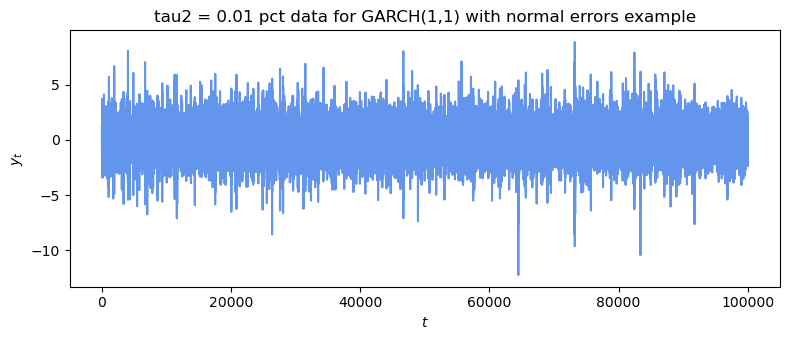

95% Confidence intervals for MLE estimates (phi)
[-0.01  0.07  0.16  0.78]
[0.01 0.08 0.17 0.79]



95% Credible intervals for posterior (phi)
[-0.01  0.07  0.16  0.78]
[0.01 0.08 0.17 0.79]





In [112]:
app = "SG_MCMC" # To create folders
model = "GARCH11_tau2_0p01" # To create folders

GARCH_type = "GARCH"
error_type = "normal"

T = 100000 # Length of time series
p = 1 # Nbr of autoregressive y-lags in the GARCH-type variance process
q = 1 # Nbr of autoregressive sigma2-lags in the GARCH-type variance process
# Specify transforms (set all "identity" if no transformation)
dataset_name = "tau2_0p01_example_%s(%s,%s)_%s_error" % (GARCH_type, p, q, error_type)

param_names, trans_param_names = get_param_names(GARCH_type, error_type, p, q)
names = {"params_name": param_names, "trans_param_names": trans_param_names}    
transforms = ["identity"] + ["identity"] + p*["identity"] + q*["identity"]

# Likelihood optimisation settings (posterior optimisation always uses L-BFGS-B as it has a better starting value):
likelihood_optim = "L-BFGS-B" 
options_L_BFGS_B = {"gtol":1e-6, "ftol":1e-12, "maxls":50, "maxiter":2000, "disp":True}
options_trust_ncg = {"gtol":1e-6, "maxiter":2000, "disp":True}
options_basinhopping = {"niter":5, "stepsize":0.5, "T":1.0, "disp":True}

# Prior settings:
# The default settings are
# mu_mean = 0.0, mu_sd = 10.0, omega_scale = 1.0, alpha_scale = 0.2, beta_scale = 0.8, v_shape = 2.0, v_rate = 1.0
# If other setting required, save as dictionary and pass on to the log prior once defined.
# Example:
prior_args = "default"
# prior_args = {"mu_mean":0.0, "mu_sd":100.0, "omega_scale":1.0, "alpha_scale":0.2, "beta_scale":0.8, "v_shape":2.0, "v_rate":1.0}

# Initialise prior. Either with default parameters or as specificed in prior_args
if prior_args == "default":
    log_prior = initiate_priors(GARCH_type, error_type)
    f = {"GARCH": log_prior_GARCH, "TGARCH": log_prior_TGARCH}[GARCH_type]
    prior_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    prior_hyperparams = prior_args
    log_prior = initiate_priors(GARCH_type, error_type, **prior_hyperparams)

# Penalty settings:
penalty_args = "default"

# Inititialise penalties for frequentist estimation
if penalty_args == "default":
    log_penalty = initiate_penalties(GARCH_type, error_type)
    f = {"GARCH": log_penalty_GARCH, "TGARCH": log_penalty_TGARCH}[GARCH_type]
    penalty_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    penalty_hyperparams = penalty_args
    log_penalty = initiate_penalties(GARCH_type, error_type, **penalty_hyperparams)
    
        
# Create model functions based on the inputs above
h, hinv, hinv_p, hinv_pp, jacdiag, logdet = initiate_transformation_functions(transforms)
log_densities, grad_log_densities, Hess_log_densities = initiate_model_functions(GARCH_type, error_type, hinv, hinv_p, hinv_pp)


# Functions to reparameterise the proposal density to a space where the GARCH/TGARCH process is stationary
theta_to_psi, psi_to_theta, logabsdet_dpsi_dtheta = initiate_persistence_reparam_functions(GARCH_type=GARCH_type, error_type=error_type, p=p, q=q, h=h,
                                                                                           hinv=hinv, jacdiag=jacdiag, param_names=param_names, delta=1e-4)


# Read in data
# tau2 = 1 example
y_start = np.array([sim_tau0p01["y"][0]])
sigma2_start = np.array([sim_tau0p01["sigma2"][0]])
y = sim_tau0p01["y"][1:]
# End read data

theta0 = None # True values not available for real data
phi0 = None
if GARCH_type == 'GARCH':
    n_params = 2 + p + q
elif GARCH_type == 'TGARCH':
    n_params = 2 + 2*p + q
    
if error_type == 'Student-t':
    n_params += 1
assert(len(transforms) == n_params)

# Keep text selectable in the PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
# Latex
mpl.rcParams['text.usetex'] = False 

out_dir = Path("results") / app / model / error_type
out_dir.mkdir(parents=True, exist_ok=True)

with pdf_section("01_settings_and_data_plot", out_dir=out_dir) as active:
    with capture_output(display) as cap:
        print("==============================================================")
        print("GARCH_type:", GARCH_type, ", Error distribution:", error_type)
        print("Lags: p =, ", p, "q = ", q)
        print("Dataset name: ", dataset_name)
        print("Number of observations: ", T)
        print("Parameters:")
        display(Markdown(", ".join(param_names)))
        print("Tranformations:\n", transforms)
        print("Number of parameters:", n_params)
        print("Prior hyperparameters (v_rate and v_shape only if Student-t)")
        print_kv(prior_hyperparams)
        print("==============================================================")

    # Show in notebook
    cap.show()

    # Only write to PDF if active
    if active:
        text = cap.stdout
        pdf_add_text(text, title="Model and settings specified")

    # Measurements
    plt.figure(figsize=(8, 3.5))
    plt.title(f"tau2 = 0.01 pct data for {GARCH_type}({p},{q}) with {error_type} errors example")
    plt.plot(y, color="cornflowerblue")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$y_t$")
    plt.tight_layout()

    # Only write figure to PDF if active
    if active:
        pdf_add_fig()

    plt.show()



# Optimise likelihood
# Minimise in phi space, so input is unrestricted
def log_penalty_phi(x, p, q):
    return log_penalty(hinv(x), p, q)

def obj_func_likelihood(x):
    """
    Penalised log-likelihood. To enforce the
    """
    return -log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + log_penalty_phi(x, p, q)# /T

grad_log_penalty = grad(log_penalty_phi) #(x, p, q)
Hess_log_penalty = hessian(log_penalty_phi)

grad_obj_func_likelihood = lambda x: -grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + grad_log_penalty(x, p, q) #/T # Gradient of obj_func_likelihood. Computed by automatic differentiation
Hess_obj_func_likelihood = lambda x: -Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + Hess_log_penalty(x, p, q) #/T # Hessian of obj_func_likelihood. Computed by automatic differentiation

optim_dir = out_dir / "optim"
optim_dir.mkdir(parents=True, exist_ok=True)
save_path_optim = optim_dir / "optim_likelihood_result.h5"
log_path_optim = optim_dir / "optim_likelihood_live.log"

# Optimise the log-likelihood
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)


try:
    optim_results = load_dict_h5(save_path_optim)
    MLE = np.array(optim_results['optim_obj']['x'])
    Cov = optim_results['Cov_MLE']
    print('95% Confidence intervals for MLE estimates (phi)')
    print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2))
    print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2))
    print("\n\n")
    
except FileNotFoundError:
    # Optimise the log-likelihood
    mu_0 = 0
    alpha_0 = np.array([0.05])
    assert(len(alpha_0) == p)
    gamma_0 = np.array([0.03])[:p] # Not active (GARCH here)
    assert(len(alpha_0) == p)
    beta_0 = np.array([0.80])[:q]
    assert(len(beta_0) == q)
    omega_0 = 0.05
    assert(omega_0 >= 0)
    if error_type == "Student-t": 
        v_0 = 15
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0, v_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0, v_0)).flatten()  
            print(theta_optim_start)
    else: # normal error
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0)).flatten()

    phi_optim_start = h(theta_optim_start)
    
    start = time.perf_counter()
    it = {"k": 0} # For callback
    fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)

    with live_log_to_file(log_path_optim):

        if likelihood_optim == "trust-ncg":
            print('\n\nLikelihood optimisation settings for method trust-ncg:\n', flush=True)
            options = options_trust_ncg
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                jac=fg.jac, hess=Hess_obj_func_likelihood,
                method="trust-ncg", options=options
            )

        elif likelihood_optim == "L-BFGS-B":
            print('\n\nLikelihood optimisation settings for method L-BFGS-B:\n', flush=True)
            options = options_L_BFGS_B
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                method='L-BFGS-B', jac=fg.jac,
                callback=callback_optim, options=options
            )

        elif likelihood_optim == "basinhopping":
            minimizer_kwargs = {"method": "L-BFGS-B", "jac": fg.jac, "options": options_L_BFGS_B}
            res_optim_likelihood = basinhopping(
                fg.fun, x0=phi_optim_start,
                minimizer_kwargs=minimizer_kwargs,
                callback=callback_optim, **options_basinhopping
            )
        else:
            raise ValueError("Optimisation method does not exist")

        end = time.perf_counter()
        run_time = end - start

        # 

        print("==============================================================", flush=True)
        print("\nLikelihood optimisation took", run_time, "seconds.", flush=True)
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)

        print('MLE estimates (phi)', flush=True)
        MLE = res_optim_likelihood.x
        print(np.round(MLE, 2), flush=True)

        print('hinv(MLE) estimates (theta)', flush=True)
        print(np.round(hinv(MLE), 2), flush=True)

        print('95% Confidence intervals for MLE estimates (phi)', flush=True)
        Cov = np.linalg.inv(Hess_obj_func_likelihood(MLE)) / T
        print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)

        if likelihood_optim == "basinhopping":
            print_minimize_summary(
                res_optim_likelihood["lowest_optimization_result"],
                x_names=trans_param_names, latex=True
            )
        else:
            print_minimize_summary(
                res_optim_likelihood,
                x_names=trans_param_names, latex=True
            )

        print("==============================================================", flush=True)

    with pdf_section("02_optim_likelihood", out_dir=out_dir) as active:
        if active:
            text = log_path_optim.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-likelihood. Summary.")

    optim_results = {
        'optim_obj': pack_optimize_result(res_optim_likelihood),
        'method': likelihood_optim,
        'Cov_MLE': Cov,
        'start_value': phi_optim_start,
        'run_time': run_time
    }

    save_dict_h5(save_path_optim, optim_results)


# Optimise posterior
# Define gradients and Hessian for log-posterior
log_prior_phi = lambda x: log_prior(hinv(x), p, q) + logdet(x) # for autograd
grad_log_prior_phi = grad(log_prior_phi)
grad_log_posterior = lambda x: grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + grad_log_prior_phi(x)
Hess_log_prior_phi = hessian(log_prior_phi)
Hess_log_posterior = lambda x: Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + Hess_log_prior_phi(x)#

obj_func_posterior = lambda x: -log_posterior(x, T, p, q, y, y_start, sigma2_start)[0] # Input is phi
grad_obj_func_posterior = lambda x: -grad_log_posterior(x) 
Hess_obj_func_posterior = lambda x: -Hess_log_posterior(x)

save_path_optim_posterior = optim_dir / "optim_posterior_result.h5"
log_path_optim_posterior = optim_dir / "optim_posterior_live.log"

# Optimise the log-posterior in phi space, so input is unrestricted
phi_optim_start = MLE
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_posterior, grad_obj_func_posterior)

try:    
    optim_posterior_results = load_dict_h5(save_path_optim_posterior)
    MAP = np.array(optim_posterior_results['optim_obj']['x'])
    Cov = optim_posterior_results['Cov']
    print('95% Credible intervals for posterior (phi)', flush=True)
    print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print("\n\n", flush=True)
    
except FileNotFoundError:
    # Optimise the posterior 
    start = time.perf_counter()

    with live_log_to_file(log_path_optim_posterior):

        res_optim_posterior = minimize(
            fg.fun, phi_optim_start,
            method='L-BFGS-B', jac=fg.jac,
            callback=callback_optim,
            options=options_L_BFGS_B
        )

        end = time.perf_counter()
        run_time = end - start

        print("==============================================================", flush=True)

        print("\nPosterior optimisation took", run_time, "seconds.", flush=True)
        print('\n\nPosterior optimisation settings for method L-BFGS-B:\n', flush=True)
        print_kv(options_L_BFGS_B)
        
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)
        # Compare answers
        print('MAP estimates (phi)', flush=True)
        MAP = res_optim_posterior.x
        print(np.round(MAP, 2), flush=True)
        print('hinv(MAP) estimates (theta)', flush=True)
        print(np.round(hinv(MAP), 2), flush=True)

        print('95% Credible intervals (normality assumption on posterior) (phi)', flush=True)
        Hess_MAP = Hess_obj_func_posterior(MAP)
        Cov = np.linalg.inv(Hess_MAP) # Negative Hessian inverse evaluated at the mode  
        if (np.linalg.eigvalsh(Cov) < 0).any():
            print("Cannot compute posterior covariance from Hessian. Trying outer product approximation", flush=True)
            scores = grad_log_densities(hinv(MAP), T, p, q, y, y_start, sigma2_start)
            Cov = np.linalg.inv(scores.T @ scores)
            assert (np.linalg.eigvalsh(Cov) > 0).all(), "Cannot compute posterior covariance."
            adapt_scaling = True
        else:
            adapt_scaling = False
        print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)
        print_minimize_summary(res_optim_posterior, x_names=trans_param_names, latex=True)
        optim_posterior_results = {
            'optim_obj': pack_optimize_result(res_optim_posterior),
            'method': 'L-BFGS-B',
            'Cov': Cov,
            'start_value': phi_optim_start,
            'run_time': run_time
        }
        save_dict_h5(save_path_optim_posterior, optim_posterior_results)
        print("==============================================================", flush=True)

    with pdf_section("03_optim_posterior", out_dir=out_dir) as active:
        if active:
            text = log_path_optim_posterior.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-posterior. Display and summary.")

Optimisation finished. Full-data MCMC run next.

In [113]:
np.random.seed(SEEDS["SG-MCMC_investigate_tau2"])
N = 12000 # MCMC samples
MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)
save_path_MCMC = MCMC_dir / ("full_data_MCMC_N%s.h5" % N)
log_path_MCMC = MCMC_dir / ("full_data_MCMC_N%s.log" % N)

try:
    MCMC_results = load_dict_h5(save_path_MCMC)
    result_full_data_MCMC = MCMC_results['MCMC_obj']
    prop_cov = MCMC_results['prop_cov']
    # Convert back to arrays
    for key in ["samples_phi", "samples_theta"]:
        result_full_data_MCMC[key] = np.asarray(result_full_data_MCMC[key])

except FileNotFoundError:

    with live_log_to_file(log_path_MCMC):

        # Run MCMC
        Sigma_pi = Cov # Negative Hessian inverse evaluated at the mode
        prop_cov = 2.38**2/n_params*Sigma_pi # For the random walk Negative Hessian inverse evaluated at the mode

        phi_init = MAP 
        print("==============================================================", flush=True)
        result_full_data_MCMC = sample_full_data_posterior_AM(
            phi_init, prop_cov, N, names, dataset_name,
            adapt_cov=True, adapt_scale=True, burn_in=1000
        )
        print("==============================================================", flush=True)

        MCMC_results = {'MCMC_obj': result_full_data_MCMC, 'prop_cov': prop_cov, 'start_value': phi_init}
        save_dict_h5(save_path_MCMC, MCMC_results)

    with pdf_section("04_full_data_MCMC", out_dir=out_dir) as active:
        if active:
            text = log_path_MCMC.read_text(encoding="utf-8")
            pdf_add_text(text, title="Full data MCMC sampling.")

            plot_traceplots_MCMC(
                result_full_data_MCMC['samples_theta'],
                param_true=hinv(MAP), param_names=param_names,
                burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
                suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
            )
            pdf_add_fig()          # saves all figures created by plot_traceplots_MCMC
            plt.close("all")       


full_data_tau0p01 = result_full_data_MCMC

Estimate full-data posterior for $\tau^2 = 1\%$ of $\mathbb{E}(\sigma^2_t)$.

[pdf_section] Exists, skipping: results/SG_MCMC/GARCH11_tau2_1/normal/01_settings_and_data_plot.pdf
GARCH_type: GARCH , Error distribution: normal
Lags: p =,  1 q =  1
Dataset name:  tau2_1_example_GARCH(1,1)_normal_error
Number of observations:  100000
Parameters:
Tranformations:
 ['identity', 'identity', 'identity', 'identity']
Number of parameters: 4
Prior hyperparameters (v_rate and v_shape only if Student-t)
alpha_scale : 0.2
beta_scale  : 0.8
mu_mean     : 0
mu_sd       : 10
omega_scale : 1
v_rate      : 1
v_shape     : 2


$\mu$, $\omega$, $\alpha_1$, $\beta_1$

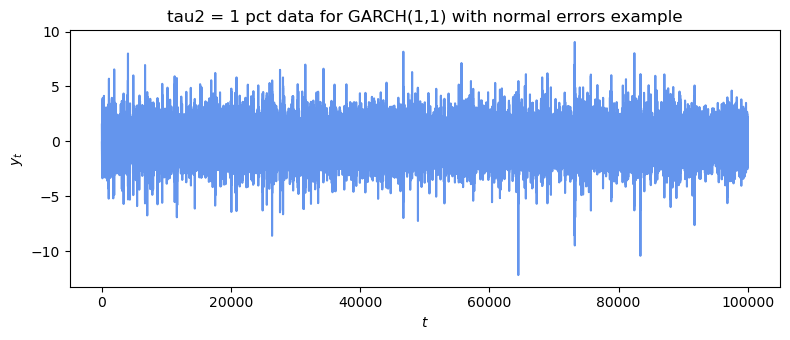

95% Confidence intervals for MLE estimates (phi)
[-0.01  0.07  0.15  0.78]
[0.01 0.08 0.16 0.79]



95% Credible intervals for posterior (phi)
[-0.01  0.07  0.15  0.78]
[0.01 0.08 0.16 0.79]





In [114]:
app = "SG_MCMC" # To create folders
model = "GARCH11_tau2_1" # To create folders

GARCH_type = "GARCH"
error_type = "normal"

T = 100000 # Length of time series
p = 1 # Nbr of autoregressive y-lags in the GARCH-type variance process
q = 1 # Nbr of autoregressive sigma2-lags in the GARCH-type variance process
# Specify transforms (set all "identity" if no transformation)
dataset_name = "tau2_1_example_%s(%s,%s)_%s_error" % (GARCH_type, p, q, error_type)

param_names, trans_param_names = get_param_names(GARCH_type, error_type, p, q)
names = {"params_name": param_names, "trans_param_names": trans_param_names}    
transforms = ["identity"] + ["identity"] + p*["identity"] + q*["identity"]

# Likelihood optimisation settings (posterior optimisation always uses L-BFGS-B as it has a better starting value):
likelihood_optim = "L-BFGS-B" 
options_L_BFGS_B = {"gtol":1e-6, "ftol":1e-12, "maxls":50, "maxiter":2000, "disp":True}
options_trust_ncg = {"gtol":1e-6, "maxiter":2000, "disp":True}
options_basinhopping = {"niter":5, "stepsize":0.5, "T":1.0, "disp":True}

# Prior settings:
# The default settings are
# mu_mean = 0.0, mu_sd = 10.0, omega_scale = 1.0, alpha_scale = 0.2, beta_scale = 0.8, v_shape = 2.0, v_rate = 1.0
# If other setting required, save as dictionary and pass on to the log prior once defined.
# Example:
prior_args = "default"
# prior_args = {"mu_mean":0.0, "mu_sd":100.0, "omega_scale":1.0, "alpha_scale":0.2, "beta_scale":0.8, "v_shape":2.0, "v_rate":1.0}

# Initialise prior. Either with default parameters or as specificed in prior_args
if prior_args == "default":
    log_prior = initiate_priors(GARCH_type, error_type)
    f = {"GARCH": log_prior_GARCH, "TGARCH": log_prior_TGARCH}[GARCH_type]
    prior_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    prior_hyperparams = prior_args
    log_prior = initiate_priors(GARCH_type, error_type, **prior_hyperparams)

# Penalty settings:
penalty_args = "default"

# Inititialise penalties for frequentist estimation
if penalty_args == "default":
    log_penalty = initiate_penalties(GARCH_type, error_type)
    f = {"GARCH": log_penalty_GARCH, "TGARCH": log_penalty_TGARCH}[GARCH_type]
    penalty_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    penalty_hyperparams = penalty_args
    log_penalty = initiate_penalties(GARCH_type, error_type, **penalty_hyperparams)
    
        
# Create model functions based on the inputs above
h, hinv, hinv_p, hinv_pp, jacdiag, logdet = initiate_transformation_functions(transforms)
log_densities, grad_log_densities, Hess_log_densities = initiate_model_functions(GARCH_type, error_type, hinv, hinv_p, hinv_pp)


# Functions to reparameterise the proposal density to a space where the GARCH/TGARCH process is stationary
theta_to_psi, psi_to_theta, logabsdet_dpsi_dtheta = initiate_persistence_reparam_functions(GARCH_type=GARCH_type, error_type=error_type, p=p, q=q, h=h,
                                                                                           hinv=hinv, jacdiag=jacdiag, param_names=param_names, delta=1e-4)


# Read in data
# tau2 = 1 example
y_start = np.array([sim_tau1["y"][0]])
sigma2_start = np.array([sim_tau1["sigma2"][0]])
y = sim_tau1["y"][1:]
# End read data

theta0 = None # True values not available for real data
phi0 = None
if GARCH_type == 'GARCH':
    n_params = 2 + p + q
elif GARCH_type == 'TGARCH':
    n_params = 2 + 2*p + q
    
if error_type == 'Student-t':
    n_params += 1
assert(len(transforms) == n_params)

# Keep text selectable in the PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
# Latex
mpl.rcParams['text.usetex'] = False 

out_dir = Path("results") / app / model / error_type
out_dir.mkdir(parents=True, exist_ok=True)

with pdf_section("01_settings_and_data_plot", out_dir=out_dir) as active:
    with capture_output(display) as cap:
        print("==============================================================")
        print("GARCH_type:", GARCH_type, ", Error distribution:", error_type)
        print("Lags: p =, ", p, "q = ", q)
        print("Dataset name: ", dataset_name)
        print("Number of observations: ", T)
        print("Parameters:")
        display(Markdown(", ".join(param_names)))
        print("Tranformations:\n", transforms)
        print("Number of parameters:", n_params)
        print("Prior hyperparameters (v_rate and v_shape only if Student-t)")
        print_kv(prior_hyperparams)
        print("==============================================================")

    # Show in notebook
    cap.show()

    # Only write to PDF if active
    if active:
        text = cap.stdout
        pdf_add_text(text, title="Model and settings specified")

    # Measurements
    plt.figure(figsize=(8, 3.5))
    plt.title(f"tau2 = 1 pct data for {GARCH_type}({p},{q}) with {error_type} errors example")
    plt.plot(y, color="cornflowerblue")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$y_t$")
    plt.tight_layout()

    # Only write figure to PDF if active
    if active:
        pdf_add_fig()

    plt.show()



# Optimise likelihood
# Minimise in phi space, so input is unrestricted
def log_penalty_phi(x, p, q):
    return log_penalty(hinv(x), p, q)

def obj_func_likelihood(x):
    """
    Penalised log-likelihood. To enforce the
    """
    return -log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + log_penalty_phi(x, p, q)# /T

grad_log_penalty = grad(log_penalty_phi) #(x, p, q)
Hess_log_penalty = hessian(log_penalty_phi)

grad_obj_func_likelihood = lambda x: -grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + grad_log_penalty(x, p, q) #/T # Gradient of obj_func_likelihood. Computed by automatic differentiation
Hess_obj_func_likelihood = lambda x: -Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + Hess_log_penalty(x, p, q) #/T # Hessian of obj_func_likelihood. Computed by automatic differentiation

optim_dir = out_dir / "optim"
optim_dir.mkdir(parents=True, exist_ok=True)
save_path_optim = optim_dir / "optim_likelihood_result.h5"
log_path_optim = optim_dir / "optim_likelihood_live.log"

# Optimise the log-likelihood
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)


try:
    optim_results = load_dict_h5(save_path_optim)
    MLE = np.array(optim_results['optim_obj']['x'])
    Cov = optim_results['Cov_MLE']
    print('95% Confidence intervals for MLE estimates (phi)')
    print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2))
    print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2))
    print("\n\n")
    
except FileNotFoundError:
    # Optimise the log-likelihood
    mu_0 = 0
    alpha_0 = np.array([0.05])
    assert(len(alpha_0) == p)
    gamma_0 = np.array([0.03])[:p] # Not active (GARCH here)
    assert(len(alpha_0) == p)
    beta_0 = np.array([0.80])[:q]
    assert(len(beta_0) == q)
    omega_0 = 0.05
    assert(omega_0 >= 0)
    if error_type == "Student-t": 
        v_0 = 15
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0, v_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0, v_0)).flatten()  
            print(theta_optim_start)
    else: # normal error
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0)).flatten()

    phi_optim_start = h(theta_optim_start)
    
    start = time.perf_counter()
    it = {"k": 0} # For callback
    fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)

    with live_log_to_file(log_path_optim):

        if likelihood_optim == "trust-ncg":
            print('\n\nLikelihood optimisation settings for method trust-ncg:\n', flush=True)
            options = options_trust_ncg
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                jac=fg.jac, hess=Hess_obj_func_likelihood,
                method="trust-ncg", options=options
            )

        elif likelihood_optim == "L-BFGS-B":
            print('\n\nLikelihood optimisation settings for method L-BFGS-B:\n', flush=True)
            options = options_L_BFGS_B
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                method='L-BFGS-B', jac=fg.jac,
                callback=callback_optim, options=options
            )

        elif likelihood_optim == "basinhopping":
            minimizer_kwargs = {"method": "L-BFGS-B", "jac": fg.jac, "options": options_L_BFGS_B}
            res_optim_likelihood = basinhopping(
                fg.fun, x0=phi_optim_start,
                minimizer_kwargs=minimizer_kwargs,
                callback=callback_optim, **options_basinhopping
            )
        else:
            raise ValueError("Optimisation method does not exist")

        end = time.perf_counter()
        run_time = end - start

        # 

        print("==============================================================", flush=True)
        print("\nLikelihood optimisation took", run_time, "seconds.", flush=True)
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)

        print('MLE estimates (phi)', flush=True)
        MLE = res_optim_likelihood.x
        print(np.round(MLE, 2), flush=True)

        print('hinv(MLE) estimates (theta)', flush=True)
        print(np.round(hinv(MLE), 2), flush=True)

        print('95% Confidence intervals for MLE estimates (phi)', flush=True)
        Cov = np.linalg.inv(Hess_obj_func_likelihood(MLE)) / T
        print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)

        if likelihood_optim == "basinhopping":
            print_minimize_summary(
                res_optim_likelihood["lowest_optimization_result"],
                x_names=trans_param_names, latex=True
            )
        else:
            print_minimize_summary(
                res_optim_likelihood,
                x_names=trans_param_names, latex=True
            )

        print("==============================================================", flush=True)

    with pdf_section("02_optim_likelihood", out_dir=out_dir) as active:
        if active:
            text = log_path_optim.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-likelihood. Summary.")

    optim_results = {
        'optim_obj': pack_optimize_result(res_optim_likelihood),
        'method': likelihood_optim,
        'Cov_MLE': Cov,
        'start_value': phi_optim_start,
        'run_time': run_time
    }

    save_dict_h5(save_path_optim, optim_results)


# Optimise posterior
# Define gradients and Hessian for log-posterior
log_prior_phi = lambda x: log_prior(hinv(x), p, q) + logdet(x) # for autograd
grad_log_prior_phi = grad(log_prior_phi)
grad_log_posterior = lambda x: grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + grad_log_prior_phi(x)
Hess_log_prior_phi = hessian(log_prior_phi)
Hess_log_posterior = lambda x: Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + Hess_log_prior_phi(x)#

obj_func_posterior = lambda x: -log_posterior(x, T, p, q, y, y_start, sigma2_start)[0] # Input is phi
grad_obj_func_posterior = lambda x: -grad_log_posterior(x) 
Hess_obj_func_posterior = lambda x: -Hess_log_posterior(x)

save_path_optim_posterior = optim_dir / "optim_posterior_result.h5"
log_path_optim_posterior = optim_dir / "optim_posterior_live.log"

# Optimise the log-posterior in phi space, so input is unrestricted
phi_optim_start = MLE
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_posterior, grad_obj_func_posterior)

try:    
    optim_posterior_results = load_dict_h5(save_path_optim_posterior)
    MAP = np.array(optim_posterior_results['optim_obj']['x'])
    Cov = optim_posterior_results['Cov']
    print('95% Credible intervals for posterior (phi)', flush=True)
    print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print("\n\n", flush=True)
    
except FileNotFoundError:
    # Optimise the posterior 
    start = time.perf_counter()

    with live_log_to_file(log_path_optim_posterior):

        res_optim_posterior = minimize(
            fg.fun, phi_optim_start,
            method='L-BFGS-B', jac=fg.jac,
            callback=callback_optim,
            options=options_L_BFGS_B
        )

        end = time.perf_counter()
        run_time = end - start

        print("==============================================================", flush=True)

        print("\nPosterior optimisation took", run_time, "seconds.", flush=True)
        print('\n\nPosterior optimisation settings for method L-BFGS-B:\n', flush=True)
        print_kv(options_L_BFGS_B)
        
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)
        # Compare answers
        print('MAP estimates (phi)', flush=True)
        MAP = res_optim_posterior.x
        print(np.round(MAP, 2), flush=True)
        print('hinv(MAP) estimates (theta)', flush=True)
        print(np.round(hinv(MAP), 2), flush=True)

        print('95% Credible intervals (normality assumption on posterior) (phi)', flush=True)
        Hess_MAP = Hess_obj_func_posterior(MAP)
        Cov = np.linalg.inv(Hess_MAP) # Negative Hessian inverse evaluated at the mode  
        if (np.linalg.eigvalsh(Cov) < 0).any():
            print("Cannot compute posterior covariance from Hessian. Trying outer product approximation", flush=True)
            scores = grad_log_densities(hinv(MAP), T, p, q, y, y_start, sigma2_start)
            Cov = np.linalg.inv(scores.T @ scores)
            assert (np.linalg.eigvalsh(Cov) > 0).all(), "Cannot compute posterior covariance."
            adapt_scaling = True
        else:
            adapt_scaling = False
        print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)
        print_minimize_summary(res_optim_posterior, x_names=trans_param_names, latex=True)
        optim_posterior_results = {
            'optim_obj': pack_optimize_result(res_optim_posterior),
            'method': 'L-BFGS-B',
            'Cov': Cov,
            'start_value': phi_optim_start,
            'run_time': run_time
        }
        save_dict_h5(save_path_optim_posterior, optim_posterior_results)
        print("==============================================================", flush=True)

    with pdf_section("03_optim_posterior", out_dir=out_dir) as active:
        if active:
            text = log_path_optim_posterior.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-posterior. Display and summary.")

Optimisation finished. Full-data MCMC run next.

In [115]:
np.random.seed(SEEDS["SG-MCMC_investigate_tau2"])
N = 12000 # MCMC samples
MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)
save_path_MCMC = MCMC_dir / ("full_data_MCMC_N%s.h5" % N)
log_path_MCMC = MCMC_dir / ("full_data_MCMC_N%s.log" % N)

try:
    MCMC_results = load_dict_h5(save_path_MCMC)
    result_full_data_MCMC = MCMC_results['MCMC_obj']
    prop_cov = MCMC_results['prop_cov']
    # Convert back to arrays
    for key in ["samples_phi", "samples_theta"]:
        result_full_data_MCMC[key] = np.asarray(result_full_data_MCMC[key])

except FileNotFoundError:

    with live_log_to_file(log_path_MCMC):

        # Run MCMC
        Sigma_pi = Cov # Negative Hessian inverse evaluated at the mode
        prop_cov = 2.38**2/n_params*Sigma_pi # For the random walk Negative Hessian inverse evaluated at the mode

        phi_init = MAP 
        print("==============================================================", flush=True)
        result_full_data_MCMC = sample_full_data_posterior_AM(
            phi_init, prop_cov, N, names, dataset_name,
            adapt_cov=True, adapt_scale=True, burn_in=1000
        )
        print("==============================================================", flush=True)

        MCMC_results = {'MCMC_obj': result_full_data_MCMC, 'prop_cov': prop_cov, 'start_value': phi_init}
        save_dict_h5(save_path_MCMC, MCMC_results)

    with pdf_section("04_full_data_MCMC", out_dir=out_dir) as active:
        if active:
            text = log_path_MCMC.read_text(encoding="utf-8")
            pdf_add_text(text, title="Full data MCMC sampling.")

            plot_traceplots_MCMC(
                result_full_data_MCMC['samples_theta'],
                param_true=hinv(MAP), param_names=param_names,
                burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
                suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
            )
            pdf_add_fig()          # saves all figures created by plot_traceplots_MCMC
            plt.close("all")       


full_data_tau1 = result_full_data_MCMC

Confirm that $\tau^2 = 0.01\%$ of $\mathbb{E}(\sigma^2_t)$ and $\tau^2$ posteriors are close. This justifies using our full-data posterior (fitted using the $\tau^2 = 0.01\%$ data) as ground truth when comparing subsampling MCMC and SG-MCMC (fitted using the $\tau^2 = 0.01\%$ data).

(<Figure size 1200x300 with 3 Axes>,
 array([<Axes: xlabel='$\\omega$'>, <Axes: xlabel='$\\alpha_1$'>,
        <Axes: xlabel='$\\beta_1$'>], dtype=object))

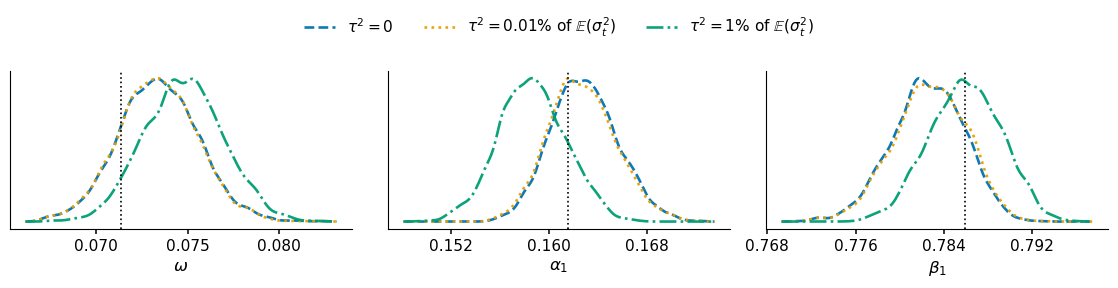

In [116]:
burn_in = 2000
plot_kde_comparison(
    full_data_tau0['samples_theta'][burn_in:, [1, 2, 3]],    
    full_data_tau0p01['samples_theta'][burn_in:, [1, 2, 3]],
    full_data_tau1['samples_theta'][burn_in:, [1, 2, 3]],
    param_names=param_names[1:],
    title="Posterior marginals",
    n_points=200,
    true_vals= np.array([omega, alpha1, beta1]),
    labels=(r"$\tau^2 = 0$", r"$\tau^2 = 0.01\%$ of $\mathbb{E}(\sigma^2_t)$", r"$\tau^2 = 1\%$ of $\mathbb{E}(\sigma^2_t)$")
)


### 4.2 Subsampling MCMC for $\tau^2 = 0.01\%$ of $\mathbb{E}(\sigma^2_t)$.

[pdf_section] Exists, skipping: results/SG_MCMC/GARCH11_tau2_0p01/normal/01_settings_and_data_plot.pdf
GARCH_type: GARCH , Error distribution: normal
Lags: p =,  1 q =  1
Dataset name:  tau2_0p01_example_GARCH(1,1)_normal_error
Number of observations:  100000
Parameters:
Tranformations:
 ['identity', 'identity', 'identity', 'identity']
Number of parameters: 4
Prior hyperparameters (v_rate and v_shape only if Student-t)
alpha_scale : 0.2
beta_scale  : 0.8
mu_mean     : 0
mu_sd       : 10
omega_scale : 1
v_rate      : 1
v_shape     : 2


$\mu$, $\omega$, $\alpha_1$, $\beta_1$

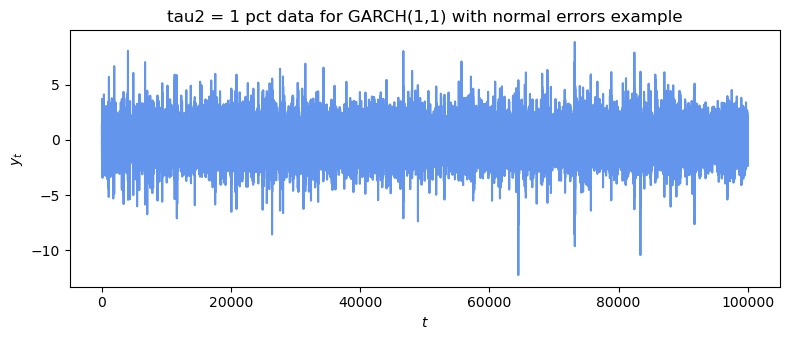

95% Confidence intervals for MLE estimates (phi)
[-0.01  0.07  0.16  0.78]
[0.01 0.08 0.17 0.79]



95% Credible intervals for posterior (phi)
[-0.01  0.07  0.16  0.78]
[0.01 0.08 0.17 0.79]





In [117]:
app = "SG_MCMC" # To create folders
model = "GARCH11_tau2_0p01" # To create folders

GARCH_type = "GARCH"
error_type = "normal"

T = 100000 # Length of time series
p = 1 # Nbr of autoregressive y-lags in the GARCH-type variance process
q = 1 # Nbr of autoregressive sigma2-lags in the GARCH-type variance process
# Specify transforms (set all "identity" if no transformation)
dataset_name = "tau2_0p01_example_%s(%s,%s)_%s_error" % (GARCH_type, p, q, error_type)

param_names, trans_param_names = get_param_names(GARCH_type, error_type, p, q)
names = {"params_name": param_names, "trans_param_names": trans_param_names}    
transforms = ["identity"] + ["identity"] + p*["identity"] + q*["identity"]

# Likelihood optimisation settings (posterior optimisation always uses L-BFGS-B as it has a better starting value):
likelihood_optim = "L-BFGS-B" 
options_L_BFGS_B = {"gtol":1e-6, "ftol":1e-12, "maxls":50, "maxiter":2000, "disp":True}
options_trust_ncg = {"gtol":1e-6, "maxiter":2000, "disp":True}
options_basinhopping = {"niter":5, "stepsize":0.5, "T":1.0, "disp":True}

# Prior settings:
# The default settings are
# mu_mean = 0.0, mu_sd = 10.0, omega_scale = 1.0, alpha_scale = 0.2, beta_scale = 0.8, v_shape = 2.0, v_rate = 1.0
# If other setting required, save as dictionary and pass on to the log prior once defined.
# Example:
prior_args = "default"
# prior_args = {"mu_mean":0.0, "mu_sd":100.0, "omega_scale":1.0, "alpha_scale":0.2, "beta_scale":0.8, "v_shape":2.0, "v_rate":1.0}

# Initialise prior. Either with default parameters or as specificed in prior_args
if prior_args == "default":
    log_prior = initiate_priors(GARCH_type, error_type)
    f = {"GARCH": log_prior_GARCH, "TGARCH": log_prior_TGARCH}[GARCH_type]
    prior_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    prior_hyperparams = prior_args
    log_prior = initiate_priors(GARCH_type, error_type, **prior_hyperparams)

# Penalty settings:
penalty_args = "default"

# Inititialise penalties for frequentist estimation
if penalty_args == "default":
    log_penalty = initiate_penalties(GARCH_type, error_type)
    f = {"GARCH": log_penalty_GARCH, "TGARCH": log_penalty_TGARCH}[GARCH_type]
    penalty_hyperparams = {k: v.default for k, v in inspect.signature(f).parameters.items()
                 if v.default is not inspect._empty}
else:
    penalty_hyperparams = penalty_args
    log_penalty = initiate_penalties(GARCH_type, error_type, **penalty_hyperparams)
    
        
# Create model functions based on the inputs above
h, hinv, hinv_p, hinv_pp, jacdiag, logdet = initiate_transformation_functions(transforms)
log_densities, grad_log_densities, Hess_log_densities = initiate_model_functions(GARCH_type, error_type, hinv, hinv_p, hinv_pp)


# Functions to reparameterise the proposal density to a space where the GARCH/TGARCH process is stationary
theta_to_psi, psi_to_theta, logabsdet_dpsi_dtheta = initiate_persistence_reparam_functions(GARCH_type=GARCH_type, error_type=error_type, p=p, q=q, h=h,
                                                                                           hinv=hinv, jacdiag=jacdiag, param_names=param_names, delta=1e-4)


# Read in data.
# tau2 = 0.01 example
y_start = np.array([sim_tau0p01["y"][0]])
sigma2_start = np.array([sim_tau0p01["sigma2"][0]])
y = sim_tau0p01["y"][1:]
# End read data

theta0 = None # True values not available for real data
phi0 = None
if GARCH_type == 'GARCH':
    n_params = 2 + p + q
elif GARCH_type == 'TGARCH':
    n_params = 2 + 2*p + q
    
if error_type == 'Student-t':
    n_params += 1
assert(len(transforms) == n_params)

# Keep text selectable in the PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
# Latex
mpl.rcParams['text.usetex'] = False 

out_dir = Path("results") / app / model / error_type
out_dir.mkdir(parents=True, exist_ok=True)

with pdf_section("01_settings_and_data_plot", out_dir=out_dir) as active:
    with capture_output(display) as cap:
        print("==============================================================")
        print("GARCH_type:", GARCH_type, ", Error distribution:", error_type)
        print("Lags: p =, ", p, "q = ", q)
        print("Dataset name: ", dataset_name)
        print("Number of observations: ", T)
        print("Parameters:")
        display(Markdown(", ".join(param_names)))
        print("Tranformations:\n", transforms)
        print("Number of parameters:", n_params)
        print("Prior hyperparameters (v_rate and v_shape only if Student-t)")
        print_kv(prior_hyperparams)
        print("==============================================================")

    # Show in notebook
    cap.show()

    # Only write to PDF if active
    if active:
        text = cap.stdout
        pdf_add_text(text, title="Model and settings specified")

    # Measurements
    plt.figure(figsize=(8, 3.5))
    plt.title(f"tau2 = 1 pct data for {GARCH_type}({p},{q}) with {error_type} errors example")
    plt.plot(y, color="cornflowerblue")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$y_t$")
    plt.tight_layout()

    # Only write figure to PDF if active
    if active:
        pdf_add_fig()

    plt.show()



# Optimise likelihood
# Minimise in phi space, so input is unrestricted
def log_penalty_phi(x, p, q):
    return log_penalty(hinv(x), p, q)

def obj_func_likelihood(x):
    """
    Penalised log-likelihood. To enforce the
    """
    return -log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + log_penalty_phi(x, p, q)# /T

grad_log_penalty = grad(log_penalty_phi) #(x, p, q)
Hess_log_penalty = hessian(log_penalty_phi)

grad_obj_func_likelihood = lambda x: -grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + grad_log_penalty(x, p, q) #/T # Gradient of obj_func_likelihood. Computed by automatic differentiation
Hess_obj_func_likelihood = lambda x: -Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start)/T + Hess_log_penalty(x, p, q) #/T # Hessian of obj_func_likelihood. Computed by automatic differentiation

optim_dir = out_dir / "optim"
optim_dir.mkdir(parents=True, exist_ok=True)
save_path_optim = optim_dir / "optim_likelihood_result.h5"
log_path_optim = optim_dir / "optim_likelihood_live.log"

# Optimise the log-likelihood
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)


try:
    optim_results = load_dict_h5(save_path_optim)
    MLE = np.array(optim_results['optim_obj']['x'])
    Cov = optim_results['Cov_MLE']
    print('95% Confidence intervals for MLE estimates (phi)')
    print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2))
    print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2))
    print("\n\n")
    
except FileNotFoundError:
    # Optimise the log-likelihood
    mu_0 = 0
    alpha_0 = np.array([0.05])
    assert(len(alpha_0) == p)
    gamma_0 = np.array([0.03])[:p] # Not active (GARCH here)
    assert(len(alpha_0) == p)
    beta_0 = np.array([0.80])[:q]
    assert(len(beta_0) == q)
    omega_0 = 0.05
    assert(omega_0 >= 0)
    if error_type == "Student-t": 
        v_0 = 15
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0, v_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0, v_0)).flatten()  
            print(theta_optim_start)
    else: # normal error
        if GARCH_type == "GARCH":
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, beta_0)).flatten()
        else: # TGARCH
            theta_optim_start = np.hstack((mu_0, omega_0, alpha_0, gamma_0, beta_0)).flatten()

    phi_optim_start = h(theta_optim_start)
    
    start = time.perf_counter()
    it = {"k": 0} # For callback
    fg = FGCache(obj_func_likelihood, grad_obj_func_likelihood)

    with live_log_to_file(log_path_optim):

        if likelihood_optim == "trust-ncg":
            print('\n\nLikelihood optimisation settings for method trust-ncg:\n', flush=True)
            options = options_trust_ncg
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                jac=fg.jac, hess=Hess_obj_func_likelihood,
                method="trust-ncg", options=options
            )

        elif likelihood_optim == "L-BFGS-B":
            print('\n\nLikelihood optimisation settings for method L-BFGS-B:\n', flush=True)
            options = options_L_BFGS_B
            print_kv(options)
            res_optim_likelihood = minimize(
                fg.fun, phi_optim_start,
                method='L-BFGS-B', jac=fg.jac,
                callback=callback_optim, options=options
            )

        elif likelihood_optim == "basinhopping":
            minimizer_kwargs = {"method": "L-BFGS-B", "jac": fg.jac, "options": options_L_BFGS_B}
            res_optim_likelihood = basinhopping(
                fg.fun, x0=phi_optim_start,
                minimizer_kwargs=minimizer_kwargs,
                callback=callback_optim, **options_basinhopping
            )
        else:
            raise ValueError("Optimisation method does not exist")

        end = time.perf_counter()
        run_time = end - start

        # 

        print("==============================================================", flush=True)
        print("\nLikelihood optimisation took", run_time, "seconds.", flush=True)
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)

        print('MLE estimates (phi)', flush=True)
        MLE = res_optim_likelihood.x
        print(np.round(MLE, 2), flush=True)

        print('hinv(MLE) estimates (theta)', flush=True)
        print(np.round(hinv(MLE), 2), flush=True)

        print('95% Confidence intervals for MLE estimates (phi)', flush=True)
        Cov = np.linalg.inv(Hess_obj_func_likelihood(MLE)) / T
        print(np.round(list(MLE - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MLE + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)

        if likelihood_optim == "basinhopping":
            print_minimize_summary(
                res_optim_likelihood["lowest_optimization_result"],
                x_names=trans_param_names, latex=True
            )
        else:
            print_minimize_summary(
                res_optim_likelihood,
                x_names=trans_param_names, latex=True
            )

        print("==============================================================", flush=True)

    with pdf_section("02_optim_likelihood", out_dir=out_dir) as active:
        if active:
            text = log_path_optim.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-likelihood. Summary.")

    optim_results = {
        'optim_obj': pack_optimize_result(res_optim_likelihood),
        'method': likelihood_optim,
        'Cov_MLE': Cov,
        'start_value': phi_optim_start,
        'run_time': run_time
    }

    save_dict_h5(save_path_optim, optim_results)


# Optimise posterior
# Define gradients and Hessian for log-posterior
log_prior_phi = lambda x: log_prior(hinv(x), p, q) + logdet(x) # for autograd
grad_log_prior_phi = grad(log_prior_phi)
grad_log_posterior = lambda x: grad_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + grad_log_prior_phi(x)
Hess_log_prior_phi = hessian(log_prior_phi)
Hess_log_posterior = lambda x: Hess_log_likelihood(hinv(x), T, p, q, y, y_start, sigma2_start) + Hess_log_prior_phi(x)#

obj_func_posterior = lambda x: -log_posterior(x, T, p, q, y, y_start, sigma2_start)[0] # Input is phi
grad_obj_func_posterior = lambda x: -grad_log_posterior(x) 
Hess_obj_func_posterior = lambda x: -Hess_log_posterior(x)

save_path_optim_posterior = optim_dir / "optim_posterior_result.h5"
log_path_optim_posterior = optim_dir / "optim_posterior_live.log"

# Optimise the log-posterior in phi space, so input is unrestricted
phi_optim_start = MLE
start = time.perf_counter()
it = {"k": 0} # For callback
fg = FGCache(obj_func_posterior, grad_obj_func_posterior)

try:    
    optim_posterior_results = load_dict_h5(save_path_optim_posterior)
    MAP = np.array(optim_posterior_results['optim_obj']['x'])
    Cov = optim_posterior_results['Cov']
    print('95% Credible intervals for posterior (phi)', flush=True)
    print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
    print("\n\n", flush=True)
    
except FileNotFoundError:
    # Optimise the posterior 
    start = time.perf_counter()

    with live_log_to_file(log_path_optim_posterior):

        res_optim_posterior = minimize(
            fg.fun, phi_optim_start,
            method='L-BFGS-B', jac=fg.jac,
            callback=callback_optim,
            options=options_L_BFGS_B
        )

        end = time.perf_counter()
        run_time = end - start

        print("==============================================================", flush=True)

        print("\nPosterior optimisation took", run_time, "seconds.", flush=True)
        print('\n\nPosterior optimisation settings for method L-BFGS-B:\n', flush=True)
        print_kv(options_L_BFGS_B)
        
        print('Starting values: \n', np.round(phi_optim_start, 3), flush=True)
        # Compare answers
        print('MAP estimates (phi)', flush=True)
        MAP = res_optim_posterior.x
        print(np.round(MAP, 2), flush=True)
        print('hinv(MAP) estimates (theta)', flush=True)
        print(np.round(hinv(MAP), 2), flush=True)

        print('95% Credible intervals (normality assumption on posterior) (phi)', flush=True)
        Hess_MAP = Hess_obj_func_posterior(MAP)
        Cov = np.linalg.inv(Hess_MAP) # Negative Hessian inverse evaluated at the mode  
        if (np.linalg.eigvalsh(Cov) < 0).any():
            print("Cannot compute posterior covariance from Hessian. Trying outer product approximation", flush=True)
            scores = grad_log_densities(hinv(MAP), T, p, q, y, y_start, sigma2_start)
            Cov = np.linalg.inv(scores.T @ scores)
            assert (np.linalg.eigvalsh(Cov) > 0).all(), "Cannot compute posterior covariance."
            adapt_scaling = True
        else:
            adapt_scaling = False
        print(np.round(list(MAP - 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print(np.round(list(MAP + 1.96*np.sqrt(np.diag(Cov))), 2), flush=True)
        print("\n\n", flush=True)
        print_minimize_summary(res_optim_posterior, x_names=trans_param_names, latex=True)
        optim_posterior_results = {
            'optim_obj': pack_optimize_result(res_optim_posterior),
            'method': 'L-BFGS-B',
            'Cov': Cov,
            'start_value': phi_optim_start,
            'run_time': run_time
        }
        save_dict_h5(save_path_optim_posterior, optim_posterior_results)
        print("==============================================================", flush=True)

    with pdf_section("03_optim_posterior", out_dir=out_dir) as active:
        if active:
            text = log_path_optim_posterior.read_text(encoding="utf-8")
            pdf_add_text(text, title="Optimisation of log-posterior. Display and summary.")

Optimisation finished. Pilot full-data run for tuning the estimator next.

In [118]:
np.random.seed(SEEDS["SG-MCMC_tuning"])
N = 100 # MCMC samples (pilot run for tuning)
MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)
save_path_MCMC = MCMC_dir / ("pilot_full_data_MCMC_N%s.h5" % N)
log_path_MCMC = MCMC_dir / ("pilot_full_data_MCMC_N%s.log" % N)

try:
    MCMC_results = load_dict_h5(save_path_MCMC)
    pilot_full_data_MCMC = MCMC_results['MCMC_obj']
    prop_cov = MCMC_results['prop_cov']
    # Convert back to arrays
    for key in ["samples_phi", "samples_theta"]:
        pilot_full_data_MCMC[key] = np.asarray(pilot_full_data_MCMC[key])

except FileNotFoundError:

    with live_log_to_file(log_path_MCMC):

        # Run MCMC
        Sigma_pi = Cov # Negative Hessian inverse evaluated at the mode
        prop_cov = 2.38**2/n_params*Sigma_pi # For the random walk Negative Hessian inverse evaluated at the mode

        phi_init = MAP 
        print("==============================================================", flush=True)
        pilot_full_data_MCMC = sample_full_data_posterior_AM(
            phi_init, prop_cov, N, names, dataset_name,
            adapt_cov=True, adapt_scale=True, burn_in=1000
        )
        print("==============================================================", flush=True)

        MCMC_results = {'MCMC_obj': pilot_full_data_MCMC, 'prop_cov': prop_cov, 'start_value': phi_init}
        save_dict_h5(save_path_MCMC, MCMC_results)
        

    with pdf_section("04_pilot_full_data_MCMC", out_dir=out_dir) as active:
        if active:
            text = log_path_MCMC.read_text(encoding="utf-8")
            pdf_add_text(text, title="Full data MCMC sampling.")

            plot_traceplots_MCMC(
                pilot_full_data_MCMC['samples_phi'],
                param_true=MAP, param_names=trans_param_names,
                burnin=0, thin=1, use_median=False, show_running_mean=True, runmean_window=50,
                suptitle="Traceplots full data MCMC (true is MAP if not simulated data)"
            )
            pdf_add_fig()          # saves all figures created by plot_traceplots_MCMC
            plt.close("all")       


Control variates for subsampling MCMC.

(100000,)
[pdf_section] Exists, skipping: results/SG_MCMC/GARCH11_tau2_0p01/normal/05_control_variates.pdf


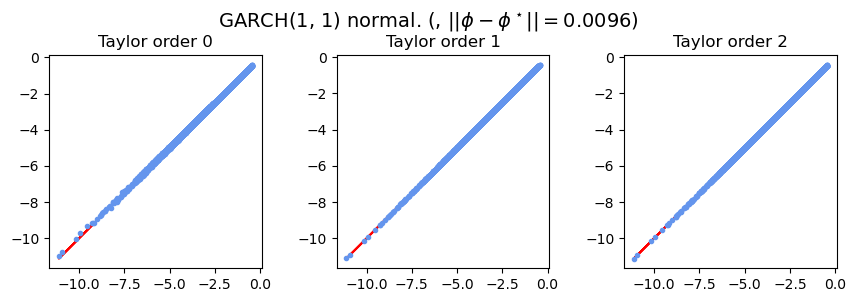

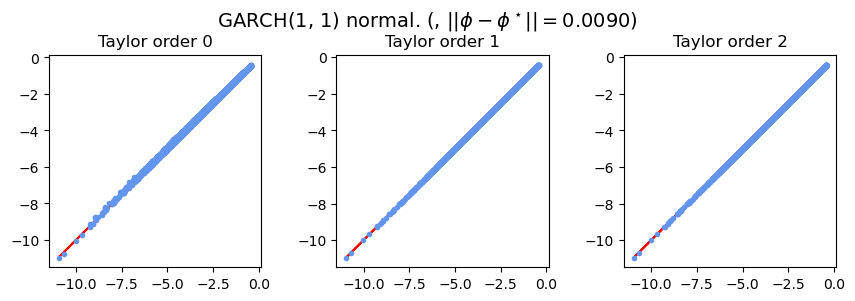

In [119]:
phiStar = MAP
args = (T, p, q, y, y_start, sigma2_start)
control_variate_dir = out_dir / "control_variates"
control_variate_dir.mkdir(parents=True, exist_ok=True)
save_path_control_variates = control_variate_dir / "control_variate_result.h5"
log_path_control_variates = control_variate_dir / "control_variate_live.log"

try:
    control_variates = load_dict_h5(save_path_control_variates)
    dens_at_phiStar = control_variates['dens_at_phiStar']
    grad_at_phiStar = control_variates['grad_at_phiStar'] 
    Hess_at_phiStar = control_variates['Hess_at_phiStar']
    end = control_variates['end']
    start = control_variates['start']
    cpu_CV = end - start

    print(dens_at_phiStar.shape)

except FileNotFoundError:
    with live_log_to_file(log_path_control_variates):
        start = time.perf_counter()
        dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar = initiate_control_variate_quantities(
            log_densities, grad_log_densities, Hess_log_densities, phiStar, args
        )
        end = time.perf_counter()
        cpu_CV = end - start
        print("==============================================================", flush=True)
        print("Elapsed time control variates initialisation with T = " , T, "p = " , p, "q = " , q,  ":", cpu_CV, "seconds", flush=True)
        print("==============================================================", flush=True)
        control_variates = {
            'dens_at_phiStar': dens_at_phiStar,
            'grad_at_phiStar': grad_at_phiStar,
            'Hess_at_phiStar': Hess_at_phiStar,
            'end': end,
            'start': start
        }
        save_dict_h5(save_path_control_variates, control_variates)

with pdf_section("05_control_variates", out_dir=out_dir) as active:

    if active:
        if log_path_control_variates.exists():
            text = log_path_control_variates.read_text(encoding="utf-8")
        else:
            text = "==============================================================\n" \
                   f"Elapsed time control variates initialisation with T = {T} p = {p} q = {q}: {cpu_CV} seconds\n" \
                   "==============================================================\n"
        pdf_add_text(text, title="Control variate construction.")

    # Precompute quantities for the control variates that do not depend on theta
    A = np.sum(dens_at_phiStar) 
    B = np.sum(grad_at_phiStar, axis = 0)
    C = np.sum(Hess_at_phiStar, axis = 0)
    # sum of control variates evaluated at phi    
    q_sum = lambda phi: A + np.dot(B, phi - phiStar) + 0.5*np.dot(phi - phiStar, np.dot(C, phi - phiStar))

    # Inspect control variate accuracy: log-densities

    # Outside median ellipse in phi space
    Sigma_pi = Cov # np.linalg.inv(Hess_obj_func_posterior(MAP))
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.50, n = 1).flatten()
    phi_beyond_median = phi
    q_k_order0 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    q_k_order1 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    q_k_order2 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    l_k = log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(l_k, l_k, color = 'red')
            if k == 0:
                axs[k].plot(l_k, q_k_order0, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(l_k, q_k_order1, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(l_k, q_k_order2, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)

    # Outside 0.999 ellipse
    phi = mvn_tail_sample(MAP, Sigma_pi, q = 0.999, n = 1).flatten()
    phi_extreme = phi
    q_k_order0 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 0) 
    q_k_order1 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 1) 
    q_k_order2 = eval_q_k(phi, phiStar, dens_at_phiStar, grad_at_phiStar, Hess_at_phiStar, order = 2) 
    l_k = log_densities(hinv(phi), *args)

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(8.5, 3.2))
    fig.suptitle(
        r'%s(%s, %s) %s. ' % (GARCH_type, p, q, error_type) + r'(, $||\phi - \phi^\star|| = %3.4f)$' % np.linalg.norm(phi - phiStar),
        fontsize=14, y=0.98
    )
    fig.set_constrained_layout_pads(h_pad=0.4, w_pad=0.05, hspace=0.08, wspace=0.08)
    for k in range(3):
            axs[k].plot(l_k, l_k, color = 'red')
            if k == 0:
                axs[k].plot(l_k, q_k_order0, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 0', size = 12)
            elif k == 1:
                axs[k].plot(l_k, q_k_order1, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 1', size = 12)
            elif k == 2:
                axs[k].plot(l_k, q_k_order2, '.', color = 'cornflowerblue')
                axs[k].set_title('Taylor order 2', size = 12)
                
            axs[k].axis('scaled')

    if active:
        pdf_add_fig(fig)
    plt.show()
    plt.close(fig)

Tune the estimator. We recommend $R_{\max}=100$, but tune for $R_{\max}=1000, 100, 10, 1$ just to inspect.

In [120]:
t_star_frac = 0.01
t_star = int(t_star_frac* T)
b = 100.0
R_max_list = [1000, 100, 10, 1]
tuning_dir = out_dir / "tuning"
tuning_dir.mkdir(parents=True, exist_ok=True)

save_path_tuning = tuning_dir / "results_by_Rmax.h5"
log_path_tuning = tuning_dir / "tuning_live.log"

try:
    tuning_cache = load_dict_h5(save_path_tuning)
    results_by_Rmax_raw = tuning_cache["results_by_Rmax"]

    # Convert keys from str -> int
    results_by_Rmax = {int(k): v for k, v in results_by_Rmax_raw.items()}

    start = tuning_cache["start"]
    end = tuning_cache["end"]
    cpu_tuning_total = end - start

    print("==============================================================", flush=True)
    print("Loaded cached tuning results.", flush=True)
    print("Elapsed cached total tuning time:", cpu_tuning_total, "seconds", flush=True)
    print("==============================================================", flush=True)

except FileNotFoundError:
    with live_log_to_file(log_path_tuning):
        start = time.perf_counter()

        results_by_Rmax = run_calibrated_tuning_over_Rmax(
            R_max_list=R_max_list,
            MCMC_results=MCMC_results,
            MAP=MAP,
            phiStar=phiStar,
            dens_at_phiStar=dens_at_phiStar,
            grad_at_phiStar=grad_at_phiStar,
            Hess_at_phiStar=Hess_at_phiStar,
            args=args,
            T=T,
            t_star_frac=t_star_frac,
            b=b,
            m_min=2,
            pilot_slice=slice(1, 100, 5),
            verbose=True,
        )

        end = time.perf_counter()
        cpu_tuning_total = end - start

        print("==============================================================", flush=True)
        print("Elapsed total tuning time:", cpu_tuning_total, "seconds", flush=True)
        for R_max in R_max_list:
            print(
                f"R_max = {R_max}: cpu_tuning_Rmax = "
                f"{results_by_Rmax[R_max]['cpu_tuning_Rmax']:.2f} seconds",
                flush=True
            )
        print("==============================================================", flush=True)

        tuning_cache = {
            "results_by_Rmax": results_by_Rmax,
            "start": start,
            "end": end,
        }

        save_dict_h5(save_path_tuning, tuning_cache)

Loaded cached tuning results.
Elapsed cached total tuning time: 595.8658432109514 seconds


Summarise the tuning quantities. Plot constrained objective for the different $R_{\max}$ targets.

In [121]:
# Summarise and plot
for R_max in R_max_list:
    res = results_by_Rmax[R_max]

    E_umax_opt = expected_umax_safe(res['probs_opt'], res['m_opt'])

    print(
        f"R_max={R_max:>4} | "
        f"c_min={res['c_min']:.4f} | "
        f"V_target={res['V_target']:.6f} | "
        f"c_opt={res['c_opt']:.6f} | "
        f"m_opt={res['m_opt']} | "
        f"E[umax]={E_umax_opt:.4f} | "
        f"var_opt={res['var_opt']:.6f} | "
        f"bind={res['binding_ratio_final']:.6f}"
    )


R_max=1000 | c_min=0.0010 | V_target=2.032718 | c_opt=0.001014 | m_opt=2 | E[umax]=136.6228 | var_opt=2.032717 | bind=1.000000
R_max= 100 | c_min=0.0100 | V_target=0.203272 | c_opt=0.010144 | m_opt=2 | E[umax]=1056.3493 | var_opt=0.203272 | bind=1.000000
R_max=  10 | c_min=0.1000 | V_target=0.020327 | c_opt=0.101283 | m_opt=2 | E[umax]=9841.3710 | var_opt=0.020327 | bind=1.000000
R_max=   1 | c_min=1.0000 | V_target=0.002033 | c_opt=1.000000 | m_opt=2 | E[umax]=66667.1667 | var_opt=0.002033 | bind=1.000000


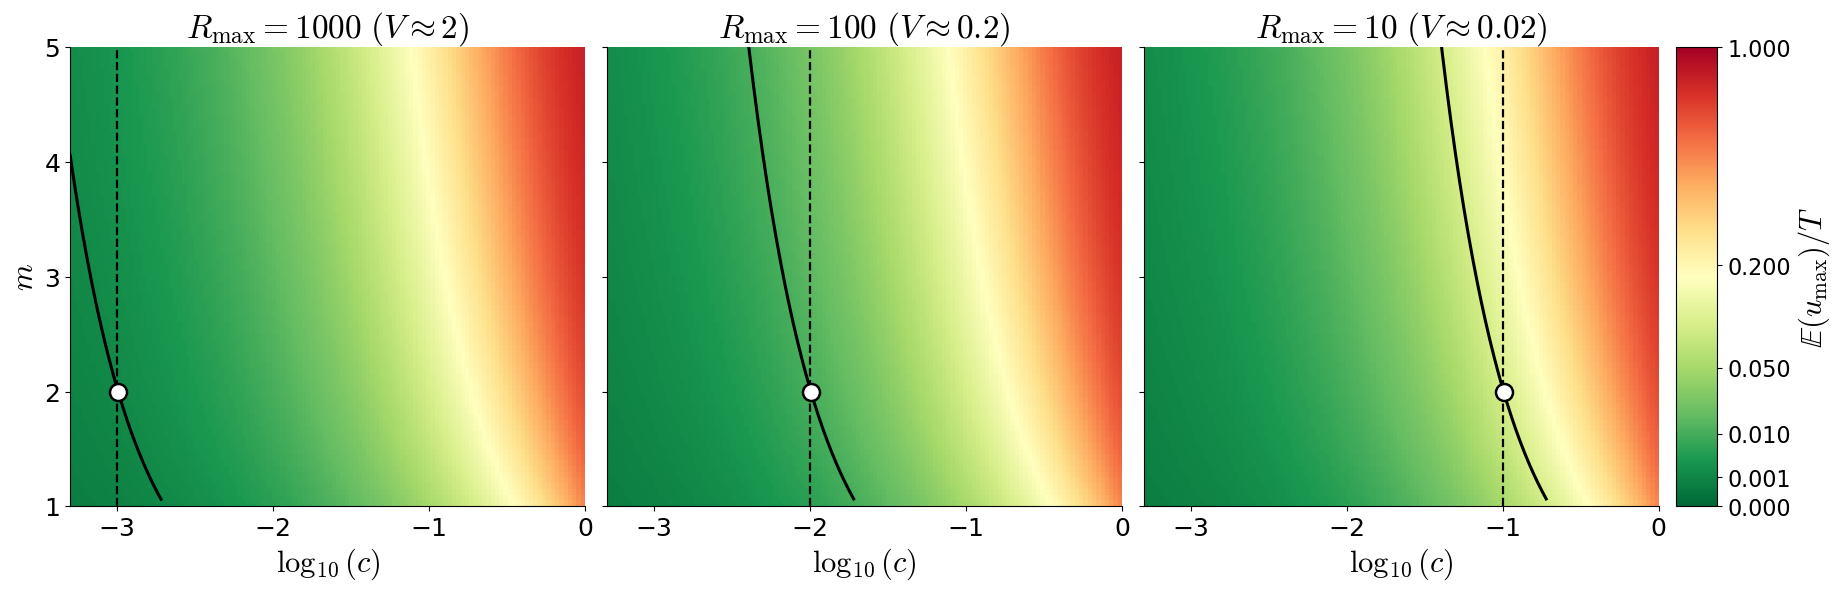

In [122]:
R_max_list = [1000, 100, 10]
V_tolerances_list = [2, 0.2, 0.02]
make_Rmax_triptych_from_results_Figure5(
    T=T,
    t_star=t_star,
    b=b,
    results_by_Rmax=results_by_Rmax,
    R_max_list=R_max_list,
    V_tol_list = V_tolerances_list,
    c_max=1.0,
    n_c=120,
    m_max=5,
    n_m_bg=80,
    power_gamma=0.4,
    vmax=1.0,
    marker_size=150,
    show_cmin_line=True
)

Run subsampling Markov chain Monte Carlo with TPD weights (tuned using $R_{\max}=100$), which we compare against the stochastic gradient Markov chain Monte Carlo (SG-MCMC) algorithm in Aicher et al. (2025).

In [123]:
# ==============================================================
# Subsampling MCMC: one run only
# Fixed R_max = 100
# ==============================================================

N = 12000
R_max = 100 # Run only for R_max = 100
n_repeat = 1
key_example = "GARCH11_normal"

base_seed = SEEDS['SG-MCMC_subsampling_mcmc_Rmax100']

MCMC_dir = out_dir / "MCMC"
MCMC_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------------
# Tuned estimator parameters for subsampling MCMC
# --------------------------------------------------------------
res_tune_subsampling_MCMC = results_by_Rmax[R_max]
V_target = float(res_tune_subsampling_MCMC["V_target"])
c_opt = float(res_tune_subsampling_MCMC["c_opt"])
m_opt = int(res_tune_subsampling_MCMC["m_opt"])
gamma_opt = float(res_tune_subsampling_MCMC["gamma_opt"])

estimator_params = {
    "m_opt": m_opt,
    "c_opt": c_opt,
    "gamma_opt": gamma_opt,
    "t_star": t_star,
    "b": b,
    "V_tolerance": V_target,
    "R_max": R_max,
}

# --------------------------------------------------------------
# Fixed initial value and fixed proposal covariance
# --------------------------------------------------------------
phi_init = MAP
prop_cov = 2.38**2 / n_params * Cov

# --------------------------------------------------------------
# Storage across repetitions
# --------------------------------------------------------------
result_list = []
diagnostics_list = []
status_list = []
cpu_list = []
cf_list = []
seed_list = []
log_path_list = []
save_path_list = []
pdf_path_list = []

section_name = f"06_subsampling_MCMC_Rmax{R_max}"

for run in range(1, n_repeat + 1):

    seed_run = base_seed + run
    np.random.seed(seed_run)

    save_path_subsampling_MCMC = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_rep{run}.h5"
    log_path_subsampling_MCMC = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_rep{run}.log"

    pdf_suffix = f"Rmax{R_max}_rep{run}"
    safe = section_name.replace(" ", "_").replace("/", "-")
    pdf_path_run = Path(out_dir) / f"{safe}_{pdf_suffix}.pdf"

    save_path_list.append(save_path_subsampling_MCMC)
    log_path_list.append(log_path_subsampling_MCMC)
    pdf_path_list.append(pdf_path_run)
    seed_list.append(seed_run)

    try:
        subsampling_MCMC_results = load_dict_h5(save_path_subsampling_MCMC)

        result_subsampling_MCMC = subsampling_MCMC_results["MCMC_obj"]
        prop_cov_run = np.asarray(subsampling_MCMC_results["prop_cov"])
        estimator_params_run = subsampling_MCMC_results["estimator_params"]

        for key in [
            "samples_phi",
            "samples_theta",
            "log_posthat_samples",
            "sigma2_lhat_samples",
            "u_max_prop",
        ]:
            if key in result_subsampling_MCMC:
                result_subsampling_MCMC[key] = np.asarray(result_subsampling_MCMC[key])

        run_diagnostics = subsampling_MCMC_results.get("run_diagnostics", None)
        run_status = subsampling_MCMC_results.get("run_status", None)

    except FileNotFoundError:

        with live_log_to_file(log_path_subsampling_MCMC):

            print("==============================================================", flush=True)
            print(f"Running subsampling MCMC with R_max = {R_max}", flush=True)
            print(f"Repetition = {run}/{n_repeat}", flush=True)
            print(f"Seed = {seed_run}", flush=True)
            print(f"N = {N}", flush=True)
            print(f"m_opt = {m_opt}", flush=True)
            print(f"c_opt = {c_opt}", flush=True)
            print(f"gamma_opt = {gamma_opt}", flush=True)
            print(f"V_target = {V_target}", flush=True)
            print("==============================================================", flush=True)

            result_subsampling_MCMC = sample_subsampling_posterior_random_walk(
                estimator_params,
                phi_init,
                prop_cov,
                N,
                names,
                dataset_name,
                adapt=False,
            )

            print("==============================================================", flush=True)

        prop_cov_run = prop_cov
        estimator_params_run = estimator_params

        # ----------------------------------------------------------
        # Compute run diagnostics
        # ----------------------------------------------------------
        longest_streak, first_stuck_iteration = longest_immobility_streak(
            result_subsampling_MCMC["samples_theta"]
        )
        stuck_flag = (longest_streak >= 100)

        cpu_tuning_cost = results_by_Rmax[R_max]["cpu_tuning_Rmax"]
        cpu_subsampling_MCMC = result_subsampling_MCMC["run_time"] + cpu_tuning_cost
        cf_subsampling_MCMC = np.sum(result_subsampling_MCMC["u_max_prop"] + 1) + 100 * T

        # Optional acceptance-rate extraction if present
        acceptance_rate = np.mean(result_subsampling_MCMC['alphas_MH'])
        
        run_diagnostics = {
            "run": run,
            "seed": seed_run,
            "longest_immobility_streak": int(longest_streak),
            "first_stuck_iteration": (
                int(first_stuck_iteration) if first_stuck_iteration is not None else -1
            ),
            "stuck_flag": bool(stuck_flag),
            "run_time": float(result_subsampling_MCMC["run_time"]),
            "cpu_total_including_tuning": float(cpu_subsampling_MCMC),
            "compute_fraction": float(cf_subsampling_MCMC),
            "acceptance_rate": acceptance_rate,
        }

        run_status = classify_mcmc_run(longest_streak, threshold_stuck=100)

        subsampling_MCMC_results = {
            "MCMC_obj": result_subsampling_MCMC,
            "prop_cov": prop_cov_run,
            "start_value": phi_init,
            "estimator_params": estimator_params_run,
            "seed": seed_run,
            "run_diagnostics": run_diagnostics,
            "run_status": run_status,
        }
        save_dict_h5(save_path_subsampling_MCMC, subsampling_MCMC_results)

    # --------------------------------------------------------------
    # If diagnostics/status were not cached, compute them now
    # --------------------------------------------------------------
    if run_diagnostics is None or run_status is None:

        longest_streak, first_stuck_iteration = longest_immobility_streak(
            result_subsampling_MCMC["samples_theta"]
        )
        stuck_flag = (longest_streak >= 100)

        cpu_tuning_cost = results_by_Rmax[R_max]["cpu_tuning_Rmax"]
        cpu_subsampling_MCMC = result_subsampling_MCMC["run_time"] + cpu_tuning_cost
        cf_subsampling_MCMC = np.sum(result_subsampling_MCMC["u_max_prop"] + 1) + 100 * T

        acceptance_rate = np.mean(result_subsampling_MCMC["alphas_MH"])

        run_diagnostics = {
            "run": run,
            "seed": seed_run,
            "longest_immobility_streak": int(longest_streak),
            "first_stuck_iteration": (
                int(first_stuck_iteration) if first_stuck_iteration is not None else -1
            ),
            "stuck_flag": bool(stuck_flag),
            "run_time": float(result_subsampling_MCMC["run_time"]),
            "cpu_total_including_tuning": float(cpu_subsampling_MCMC),
            "compute_fraction": float(cf_subsampling_MCMC),
            "acceptance_rate": acceptance_rate,
        }

        run_status = classify_mcmc_run(longest_streak, threshold_stuck=100)

    # --------------------------------------------------------------
    # Store in summary lists
    # --------------------------------------------------------------
    result_list.append(result_subsampling_MCMC)
    diagnostics_list.append(run_diagnostics)
    status_list.append(run_status)
    cpu_list.append(run_diagnostics["cpu_total_including_tuning"])
    cf_list.append(run_diagnostics["compute_fraction"])

    # --------------------------------------------------------------
    # Per-run PDF output
    # --------------------------------------------------------------
    with pdf_section(section_name, out_dir=out_dir, suffix=pdf_suffix, overwrite=False) as active:
        if active:
            text = log_path_subsampling_MCMC.read_text(encoding="utf-8")

            summary_text = (
                f"Repetition {run}/{n_repeat}\n"
                f"Seed = {seed_run}\n"
                f"Status = {run_status}\n"
                f"Longest immobility streak = {run_diagnostics['longest_immobility_streak']}\n"
                f"First stuck iteration = {run_diagnostics['first_stuck_iteration']}\n"
                f"Acceptance rate = {run_diagnostics['acceptance_rate']}\n"
                f"Run time = {run_diagnostics['run_time']:.2f}\n"
                f"CPU incl. tuning = {run_diagnostics['cpu_total_including_tuning']:.2f}\n"
                f"Compute fraction = {run_diagnostics['compute_fraction']:.2f}\n"
            )

            pdf_add_text(
                text + "\n\n" + summary_text,
                title=f"Subsampling MCMC sampling (R_max = {R_max}, repetition {run})",
            )

            # Standard MCMC traceplots
            plot_traceplots_MCMC(
                result_subsampling_MCMC["samples_theta"],
                param_true=hinv(MAP),
                param_names=param_names,
                burnin=0,
                thin=1,
                use_median=False,
                show_running_mean=True,
                runmean_window=50,
                suptitle=f"Traceplots subsampling MCMC (R_max = {R_max}, rep {run})",
            )
            pdf_add_fig()
            plt.close("all")

            # Additional subsampling-specific diagnostics
            plot_subsampling_MCMC_quantities(result_subsampling_MCMC)
            pdf_add_fig()
            plt.close("all")

# --------------------------------------------------------------
# Save master summary object across repetitions
# --------------------------------------------------------------
subsampling_MCMC_repeated_summary = {
    "R_max": R_max,
    "N": N,
    "n_repeat": n_repeat,
    "base_seed": base_seed,
    "key_example": key_example,
    "estimator_params": estimator_params,
    "start_value": phi_init,
    "prop_cov": prop_cov,
    "seed_list": seed_list,
    "status_list": status_list,
    "diagnostics_list": diagnostics_list,
    "cpu_list": cpu_list,
    "cf_list": cf_list,
    "save_path_list": [str(x) for x in save_path_list],
    "log_path_list": [str(x) for x in log_path_list],
    "pdf_path_list": [str(x) for x in pdf_path_list],
    "n_stuck": int(np.sum([s == "stuck" for s in status_list])),
    "n_mixed_well": int(np.sum([s == "mixed_well" for s in status_list])),
}

save_path_summary = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_summary.h5"
save_dict_h5(save_path_summary, subsampling_MCMC_repeated_summary)

print("==============================================================")
print(f"Finished repeated subsampling MCMC runs for R_max = {R_max}")
print(f"n_repeat = {n_repeat}")
print(f"mixed well = {subsampling_MCMC_repeated_summary['n_mixed_well']}/{n_repeat}")
print(f"stuck = {subsampling_MCMC_repeated_summary['n_stuck']}/{n_repeat}")
print(f"Summary saved to: {save_path_summary}")
print("==============================================================")

subsampling_MCMC = result_list[0]
subsampling_MCMC_time = cpu_list[0] + cpu_CV


[pdf_section] Exists, skipping: results/SG_MCMC/GARCH11_tau2_0p01/normal/06_subsampling_MCMC_Rmax100_Rmax100_rep1.pdf
Finished repeated subsampling MCMC runs for R_max = 100
n_repeat = 1
mixed well = 1/1
stuck = 0/1
Summary saved to: results/SG_MCMC/GARCH11_tau2_0p01/normal/MCMC/subsampling_MCMC_Rmax100_N12000_summary.h5


In [124]:
# ==============================================================
# Inspect repeated subsampling MCMC diagnostics
# ==============================================================
summary_path = MCMC_dir / f"subsampling_MCMC_Rmax{R_max}_N{N}_summary.h5"
summary_obj = load_dict_h5(summary_path)

diagnostics_list = summary_obj["diagnostics_list"]
status_list = summary_obj["status_list"]
seed_list = summary_obj["seed_list"]

rows = []
for d, status, seed in zip(diagnostics_list, status_list, seed_list):
    rows.append({
        "run": int(d["run"]),
        "seed": int(seed),
        "status": status,
        "longest_immobility_streak": int(d["longest_immobility_streak"]),
        "first_stuck_iteration": (
            None if int(d["first_stuck_iteration"]) < 0 else int(d["first_stuck_iteration"])
        ),
        "acceptance_rate": (
            np.nan if d["acceptance_rate"] is None else float(d["acceptance_rate"])
        ),
        "run_time": float(d["run_time"]),
        "cpu_total_including_tuning": float(d["cpu_total_including_tuning"]),
        "compute_fraction": float(d["compute_fraction"]),
    })

diag_df = pd.DataFrame(rows).sort_values("run").reset_index(drop=True)

print("==============================================================")
print("Repeated subsampling MCMC diagnostics")
print("==============================================================")
print(diag_df.to_string(index=False))

print("\n==============================================================")
print("Aggregate summaries")
print("==============================================================")
print(f"Number of runs: {len(diag_df)}")
print(f"Status counts:\n{diag_df['status'].value_counts(dropna=False)}")
print()
print("Longest immobility streak:")
print(f"  min    = {diag_df['longest_immobility_streak'].min()}")
print(f"  median = {diag_df['longest_immobility_streak'].median()}")
print(f"  max    = {diag_df['longest_immobility_streak'].max()}")

if diag_df["acceptance_rate"].notna().any():
    print()
    print("Acceptance rate:")
    print(f"  min    = {diag_df['acceptance_rate'].min():.4f}")
    print(f"  median = {diag_df['acceptance_rate'].median():.4f}")
    print(f"  max    = {diag_df['acceptance_rate'].max():.4f}")

print()
print("Runtime:")
print(f"  min    = {diag_df['run_time'].min():.2f}")
print(f"  median = {diag_df['run_time'].median():.2f}")
print(f"  max    = {diag_df['run_time'].max():.2f}")

print()
print("Compute fraction:")
print(f"  min    = {diag_df['compute_fraction'].min():.2f}")
print(f"  median = {diag_df['compute_fraction'].median():.2f}")
print(f"  max    = {diag_df['compute_fraction'].max():.2f}")
print("==============================================================")

Repeated subsampling MCMC diagnostics
 run  seed     status  longest_immobility_streak first_stuck_iteration  acceptance_rate   run_time  cpu_total_including_tuning  compute_fraction
   1 56790 mixed_well                         28                  None         0.296136 624.747718                  783.173214        22664124.0

Aggregate summaries
Number of runs: 1
Status counts:
status
mixed_well    1
Name: count, dtype: int64

Longest immobility streak:
  min    = 28
  median = 28.0
  max    = 28

Acceptance rate:
  min    = 0.2961
  median = 0.2961
  max    = 0.2961

Runtime:
  min    = 624.75
  median = 624.75
  max    = 624.75

Compute fraction:
  min    = 22664124.00
  median = 22664124.00
  max    = 22664124.00


Chain for GARCH($1,1$) with normal errors (example to compare with the SG-MCMC algorithm proposed in Aicher et al. (2025)).

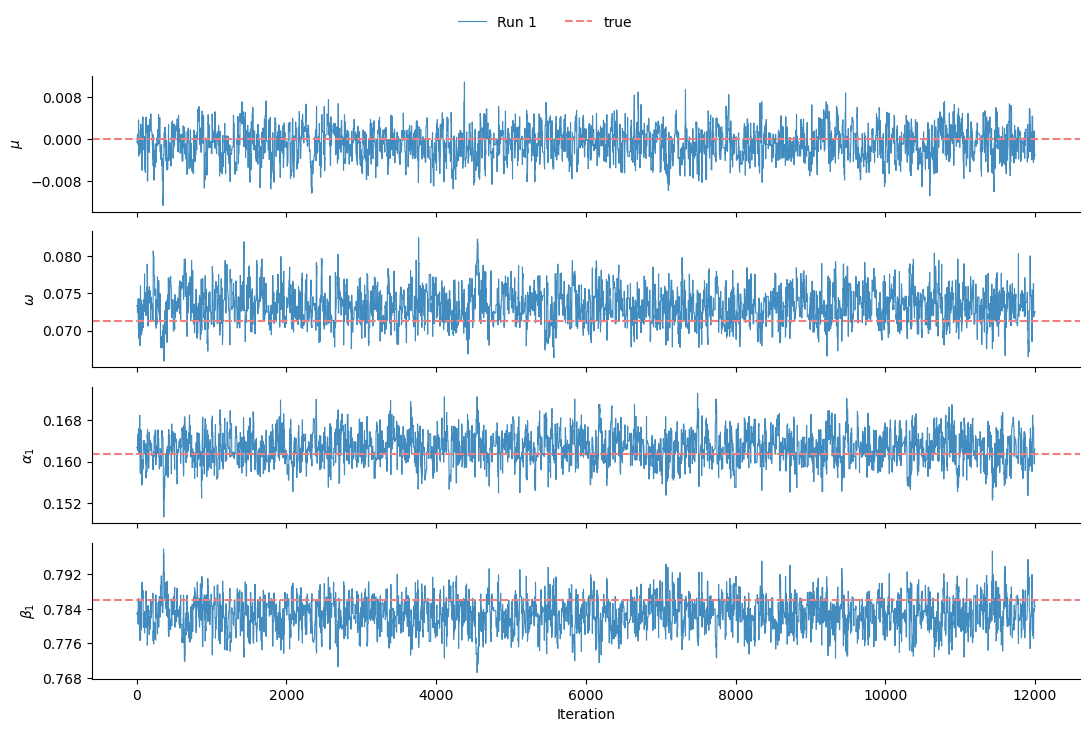

In [125]:
# Note, only one chain
chains = [r['samples_theta'] for r in result_list]
chain_labels = [f"Run {i+1}" for i in range(1)] # Just one chain here

fig, axes = plot_traceplots_MCMC_chains(
    param_draws=chains,
    param_names=param_names,
    chain_labels=chain_labels,
    burnin=0,
    thin=1,
    show_running_mean=False,
    param_true= np.array([0, omega, alpha1, beta1])
)



To compute kernelised Stein discrepancy (KSD) measures, we use the SG-MCMC code by Aicher et al (2025). We need to export full-data and subsampling results.

In [126]:
np.savez("full_data_run_tau2_0p01.npz", full_data_tau0p01)
np.savez("subsampling_run_tau2_0p01.npz", subsampling_MCMC)

Read in stochastic gradient Markov chain Monte Carlo results. 

**Note**: The code below assumes the SG-MCMC chains have been created with the script `sg_mcmc_runs.ipynb`.

In [127]:
SG_dir = Path("results/SG_runs")

niter = 12000 # Compare against full-data
burn_in = 2000
subsampling_MCMC = result_list[0]

epsilon_list = [1, 0.1, 0.01, 0.001]

SG_results = []

for setting_nbr, epsilon in enumerate(epsilon_list):
    file_path = SG_dir / f"sgmcmc_tau2_0p01pct_niter{niter}_setting{setting_nbr}.npz"

    with np.load(file_path, allow_pickle=True) as f:
        result = {
            "draws": f["sgmcmc_draws"],
            "settings": f["settings"].item(),
            "timing": f["timing"].item(),
            "start_value": f["start_value"],
        }

    SG_results.append(result)

    print(f"Loaded epsilon={epsilon} from {file_path}")



Loaded epsilon=1 from results/SG_runs/sgmcmc_tau2_0p01pct_niter12000_setting0.npz
Loaded epsilon=0.1 from results/SG_runs/sgmcmc_tau2_0p01pct_niter12000_setting1.npz
Loaded epsilon=0.01 from results/SG_runs/sgmcmc_tau2_0p01pct_niter12000_setting2.npz
Loaded epsilon=0.001 from results/SG_runs/sgmcmc_tau2_0p01pct_niter12000_setting3.npz


Kernel density estimates for all methods.

(<Figure size 1450x420 with 3 Axes>,
 array([<Axes: xlabel='$\\omega$'>, <Axes: xlabel='$\\alpha_1$'>,
        <Axes: xlabel='$\\beta_1$'>], dtype=object))

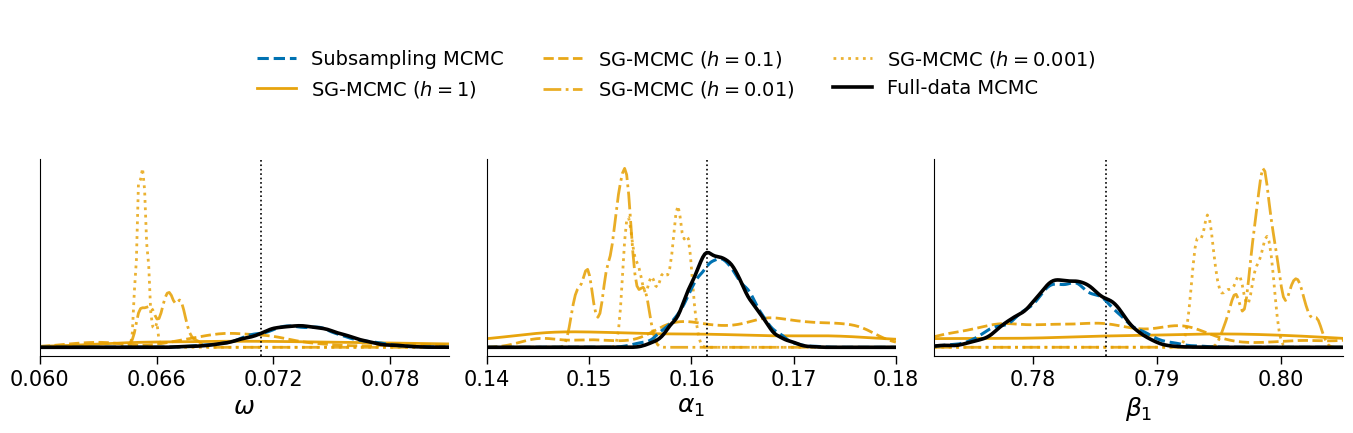

In [128]:
thin = 1
sg_samples_list = [SG_results[item]['draws'][burn_in::thin, [0, 1, 2]] for item in range(len(epsilon_list))]

xlims = [
    (0.060, 0.081),   # omega
    (0.140, 0.18),   # alpha_1
    (0.772, 0.805),   # beta_1
]

plot_kde_comparison_SG_MCMC(
    full_data_tau0p01["samples_theta"][(burn_in + 1)::thin, [1, 2, 3]],
    subsampling_MCMC["samples_theta"][(burn_in + 1)::thin, [1, 2, 3]],
    sg_samples_list,
    sg_labels= [r"SG-MCMC $(h = 1)$", r"SG-MCMC $(h = 0.1)$", r"SG-MCMC $(h = 0.01)$", r"SG-MCMC $(h = 0.001)$"],
    param_names=[r"$\omega$", r"$\alpha_1$", r"$\beta_1$"],
    title=" ",
    n_points=200,
    true_vals=np.array([omega, alpha1, beta1]),
    bw_method="scott",
    bw_adjust=1.0,
    legend_fontsize=14,
    xlims=xlims
)



Traceplots for $\alpha_1$ (confirmed similar results for the other two parameters).

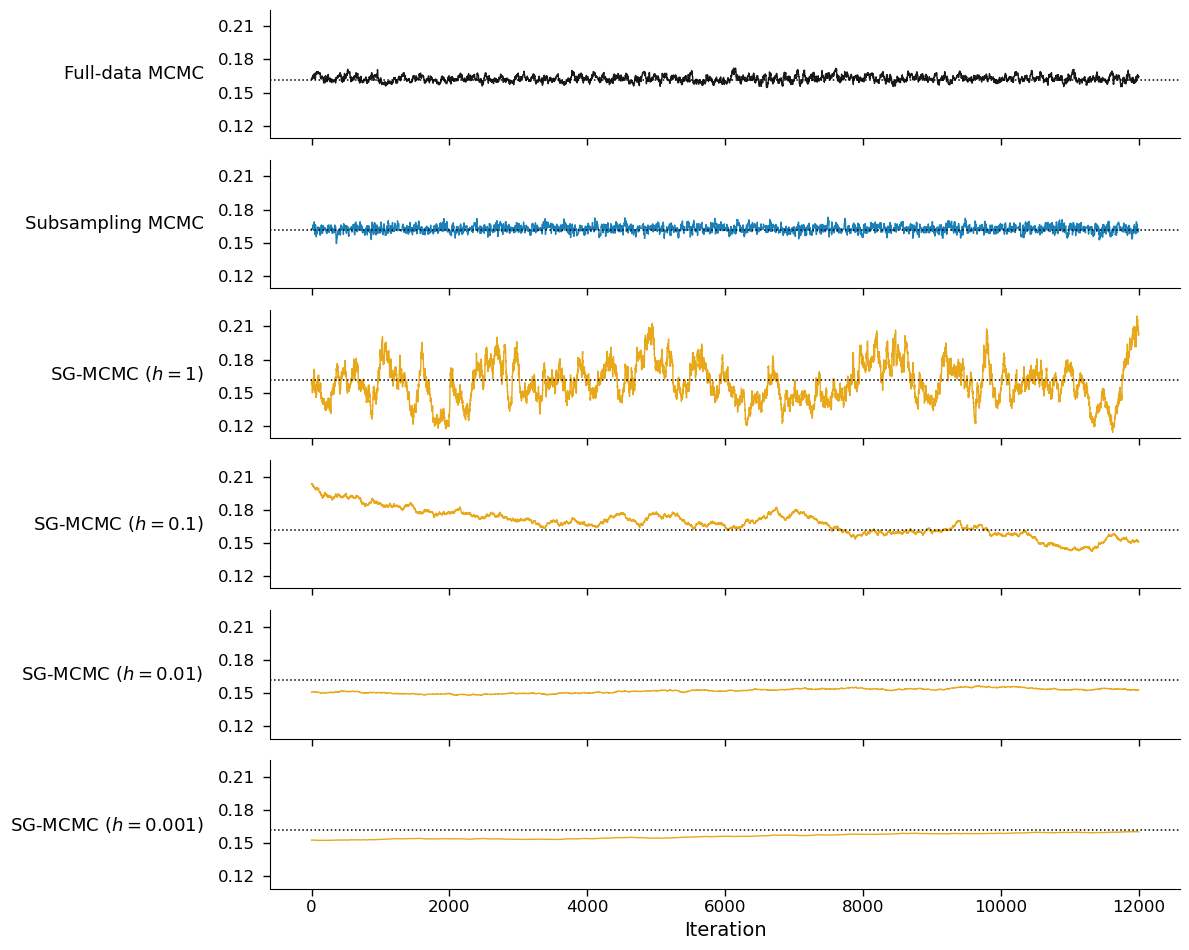

In [129]:
epsilon_list = [1, 0.1, 0.01, 0.001]

sg_labels = [
    r"SG-MCMC ($h=1$)",
    r"SG-MCMC ($h=0.1$)",
    r"SG-MCMC ($h=0.01$)",
    r"SG-MCMC ($h=0.001$)"
]

# Traceplots without burn-in
sg_samples_list = [SG_results[item]['draws'][:, [1]] for item in range(len(epsilon_list))]

figs_axes = plot_traceplots_comparison_SG_MCMC(
    full_data_samples=full_data_tau0p01["samples_theta"][1:, [2]],
    subsampling_samples=subsampling_MCMC["samples_theta"][1:, [2]],
    sg_samples_list=sg_samples_list,
    sg_labels=sg_labels,
    param_names=[r"$\alpha_1$"],
    true_vals=np.array([alpha1]),  
    burn_in=0,
    thin=1,
    fig_width=12,
    figsize_per_row=1.5,
)

Table of kernelised Stein discrepancy (KSD) measures and run times. Note: Assumes the KSD measures have been created with the script `sg_mcmc_runs.ipynb`.

In [130]:
KSD_dir = Path("results/SG_runs/KSD_tables")
load_path = KSD_dir / "ksd_summary_tau2_0p01pct.npz"
ksd_df = pd.DataFrame(np.load(load_path, allow_pickle=True)["ksd_df"].tolist())
ksd_df

,method,log10_ksd_mean,log10_ksd_sd,log10_ksd_min,log10_ksd_max
0,SG-MCMC epsilon=1,1.614754,0.105339,1.401749,1.728557
1,SG-MCMC epsilon=0.1,1.487487,0.139659,1.297086,1.663822
2,SG-MCMC epsilon=0.01,1.938985,0.060415,1.869405,2.059996
3,SG-MCMC epsilon=0.001,1.724087,0.057752,1.642494,1.797209
4,Full-data MCMC,0.718091,0.382834,0.304996,1.419027
5,Subsampling MCMC,1.038928,0.226740,0.674910,1.318128


Add the computing time for each method.

In [131]:
# Add run times. For SG-MCMC, results stored as epsilon_list = [1, 0.1, 0.01, 0.001]
ksd_df['run_times'] = [SG_results[item]['timing']['sampling_only'] for item in range(4)] + [full_data_tau0p01['run_time'], subsampling_MCMC_time]
ksd_df = ksd_df.sort_values(by="log10_ksd_mean")

ksd_df

,method,log10_ksd_mean,log10_ksd_sd,log10_ksd_min,log10_ksd_max,run_times
4,Full-data MCMC,0.718091,0.382834,0.304996,1.419027,69750.486802
5,Subsampling MCMC,1.038928,0.226740,0.674910,1.318128,865.123141
1,SG-MCMC epsilon=0.1,1.487487,0.139659,1.297086,1.663822,232.534778
0,SG-MCMC epsilon=1,1.614754,0.105339,1.401749,1.728557,235.714641
3,SG-MCMC epsilon=0.001,1.724087,0.057752,1.642494,1.797209,233.226585
2,SG-MCMC epsilon=0.01,1.938985,0.060415,1.869405,2.059996,232.854359


Create a LaTeX table for the paper

In [132]:
# =========================================================
# Prepare DataFrame for LaTeX (makecell version)
# =========================================================

df = ksd_df.copy()

# --- Mean and sd stacked using makecell ---
df["log10 KSD"] = df.apply(
    lambda row: (
        f"\\makecell{{{row['log10_ksd_mean']:.3f} \\\\ "
        f"({row['log10_ksd_sd']:.3f})}}"
    ),
    axis=1
)

# --- Range ---
df["Range"] = df.apply(
    lambda row: f"[{row['log10_ksd_min']:.3f}, {row['log10_ksd_max']:.3f}]",
    axis=1
)

# --- Runtime ---
df["Runtime (s)"] = df["run_times"].map(lambda x: f"{x:.1f}")

# --- Keep columns ---
df_latex = df[["method", "log10 KSD", "Range", "Runtime (s)"]]

# --- Rename ---
df_latex.columns = ["Method", "log$_{10}$ KSD", "Range", "Runtime (s)"]

# --- LaTeX epsilon formatting ---
df_latex["Method"] = df_latex["Method"].str.replace(
    "epsilon=", r"$\varepsilon = $", regex=False
)

# =========================================================
# Convert to LaTeX tabular
# =========================================================

latex_table = df_latex.to_latex(
    index=False,
    escape=False,
    column_format="lccc"
)

# =========================================================
# Wrap into full table
# =========================================================

latex_full = r"""
\begin{table}[htbp]
\centering
\caption{Comparison of posterior accuracy and computational cost across methods. 
The log$_{10}$ KSD is reported as mean (standard deviation) with range over $n_{\mathrm{rep}} = 6$ independent evaluations. 
Runtime corresponds to a single run of each method.}
\label{tab:ksd_runtime_comparison}
""" + latex_table + r"""
\end{table}
"""

print(latex_full)


\begin{table}[htbp]
\centering
\caption{Comparison of posterior accuracy and computational cost across methods. 
The log$_{10}$ KSD is reported as mean (standard deviation) with range over $n_{\mathrm{rep}} = 6$ independent evaluations. 
Runtime corresponds to a single run of each method.}
\label{tab:ksd_runtime_comparison}
\begin{tabular}{lccc}
\toprule
Method & log$_{10}$ KSD & Range & Runtime (s) \\
\midrule
Full-data MCMC & \makecell{0.718 \\ (0.383)} & [0.305, 1.419] & 69750.5 \\
Subsampling MCMC & \makecell{1.039 \\ (0.227)} & [0.675, 1.318] & 865.1 \\
SG-MCMC $\varepsilon = $0.1 & \makecell{1.487 \\ (0.140)} & [1.297, 1.664] & 232.5 \\
SG-MCMC $\varepsilon = $1 & \makecell{1.615 \\ (0.105)} & [1.402, 1.729] & 235.7 \\
SG-MCMC $\varepsilon = $0.001 & \makecell{1.724 \\ (0.058)} & [1.642, 1.797] & 233.2 \\
SG-MCMC $\varepsilon = $0.01 & \makecell{1.939 \\ (0.060)} & [1.869, 2.060] & 232.9 \\
\bottomrule
\end{tabular}

\end{table}



## 5. Comparison against divide-and-conquer Markov chain Monte Carlo

This section compares our stabilised weighted subsampling approach against the divide-and-conquer for Bayesian Time Series (DC-BATS) method of Ou et al. (2025). Their framework allows for a direct implementation of our GARCH specification.

To ensure comparability with the stochastic gradient Markov chain Monte Carlo results in Aicher et al. (2025), we use data generated from the GARCH model with noise described above, with the noise level set to $\tau = 0.01\%$ of the unconditional variance.

Recall that we calibrate the parameters $\omega$, $\alpha_1$, and $\beta_1$ using the Dow Jones Industrial Average example in the main paper. Specifically, we set
$$
\omega = 0.07134079, \qquad \alpha_1 = 0.16151262, \qquad \beta_1 = 0.78591371,
$$
which implies an unconditional variance given by
$$
\mathbb{E}(\sigma^2_t) = \frac{\omega}{1 - \alpha_1 - \beta_1}.
$$

The DC-BATS approach partitions the time series into contiguous shards and performs Bayesian inference independently on each shard using a powered likelihood. The resulting subset posteriors are then aggregated via a Wasserstein barycentre.

Since this is a simulated data example, we initialise the recursion within each shard using the true boundary values from the preceding shard. Specifically, each shard receives the last observed return and conditional variance from the previous shard as its starting values. This ensures that all methods operate under the same underlying volatility dynamics and removes additional approximation error due to ad hoc initialisation.

The DC-BATS implementation is written in R and uses Hamiltonian Monte Carlo via Stan to sample from each powered shard posterior. This part of the notebook assumes that these results have already been generated and stored for subsequent analysis.

Create datasets to estimate the models using the DC-BATS code in R.

In [133]:
# ------------------------------------------------------------
# Directories
# ------------------------------------------------------------
data_dir = Path("results") / "SG_MCMC" / "data"
out_dir = Path("data")
out_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Load simulated data
# ------------------------------------------------------------

data = np.load(data_dir / "garch_tau2_0p01pct.npz")

y_full = np.asarray(data["y"])              # length T + 1
sigma2_full = np.asarray(data["sigma2"])    # length T + 1

# Pre-sample values
y_start = y_full[0]
sigma2_start = sigma2_full[0]

# Observed series
y = y_full[1:]
sigma2 = sigma2_full[1:]

assert len(y) == len(sigma2)

# ------------------------------------------------------------
# Save data for DC-BATS
# ------------------------------------------------------------

pd.DataFrame({
    "y": y,
    "sigma2": sigma2
}).to_csv(out_dir / "garch11_with_sigma2.csv", index=False)

# Save starting values as CSV for R
pd.DataFrame({
    "y_start": [y_start],
    "sigma2_start": [sigma2_start]
}).to_csv(out_dir / "garch11_init_values.csv", index=False)

# ------------------------------------------------------------
# Load full-data posterior
# ------------------------------------------------------------

res = np.load("full_data_run_tau2_0p01.npz", allow_pickle=True)
full_data_results = res["arr_0"].item()

samples_theta = full_data_results["samples_theta"]

full_draws = pd.DataFrame(
    samples_theta,
    columns=["mu", "omega", "alpha1", "beta1"]
)

# Burn-in removal
full_draws = full_draws.iloc[2001:].reset_index(drop=True)

# ------------------------------------------------------------
# Save full posterior draws
# ------------------------------------------------------------

full_draws.to_csv(out_dir / "full_truth.csv", index=False)

Kernel density estimates: DC-BATS versus subsampling MCMC and full-data MCMC. We compare kernel density estimates obtained from DC-BATS with those from subsampling MCMC and full-data MCMC. The latter two were generated in Section 4.

**Note:** The code below assumes that the posterior samples from DC-BATS have been created using the script `run_dc_bats_runs.R`.

In [134]:
# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

base_dir = Path("results") / "DC_BATS"

K_values = [10, 20, 80]

# ------------------------------------------------------------
# Read DC-BATS posterior draws
# ------------------------------------------------------------

dc_draws_dict = {}

for K in K_values:
    file_k = base_dir / f"K_{K}" / f"bary_draws_garch11_dc_K{K}.csv"
    dc_draws_dict[K] = pd.read_csv(file_k)

# ------------------------------------------------------------
# Full-data posterior stored in X. Subsampling posterior in Y
# ------------------------------------------------------------


# ------------------------------------------------------------
# Quick check and create list for each K
# ------------------------------------------------------------

for K, draws in dc_draws_dict.items():
    print(f"DC-BATS K={K}:", draws.shape)

# 
params = ["mu", "omega", "alpha1", "beta1"]

dc_bats_samples_list = [
    dc_draws_dict[10][params].to_numpy(),
    dc_draws_dict[20][params].to_numpy(),
    dc_draws_dict[80][params].to_numpy(),
]

DC-BATS K=10: (10000, 5)
DC-BATS K=20: (10000, 5)
DC-BATS K=80: (10000, 5)


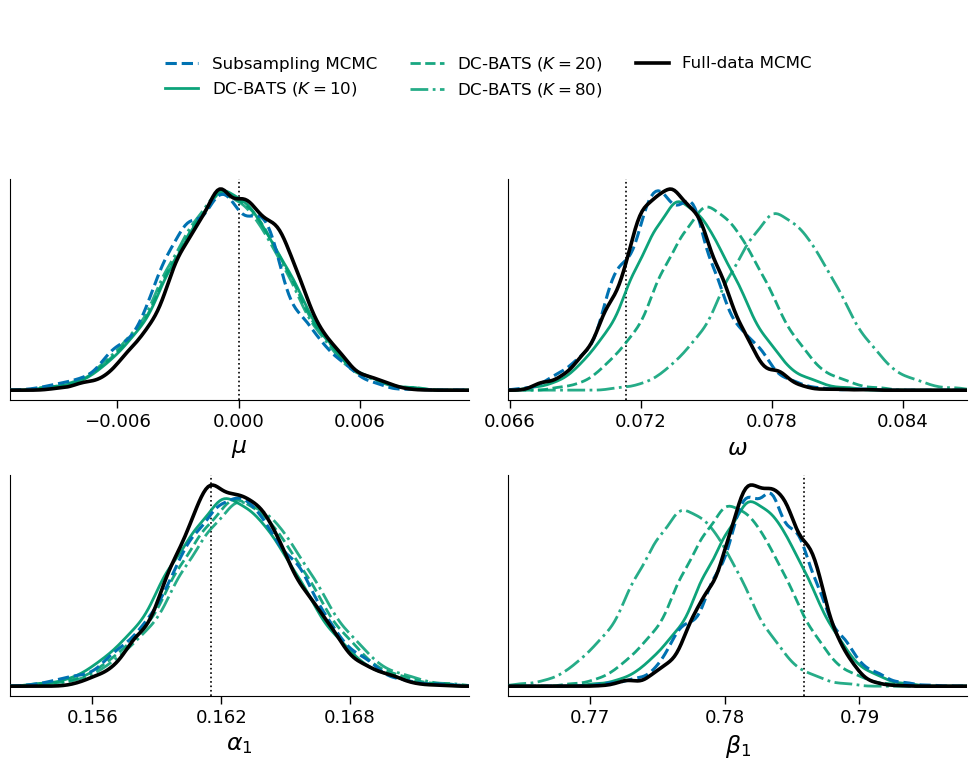

In [135]:
fig, axes = plot_kde_comparison_DC_BATS(
    full_data_samples= full_data_tau0p01['samples_theta'][2001:, :],
    subsampling_samples= subsampling_MCMC['samples_theta'][2001:, :],
    dc_bats_samples_list=dc_bats_samples_list,
    dc_bats_labels=[r"DC-BATS $(K=10)$", r"DC-BATS $(K=20)$", r"DC-BATS $(K=80)$"],
    true_vals=np.array([0.0, omega, alpha1, beta1]),
    title=" "
)

## 6. Other figures in the paper

The TPD weights plot (Figure 1 in the paper).

epsilon(gamma) = 0.114, head mass ~ 0.886, tail mass ~ 0.114


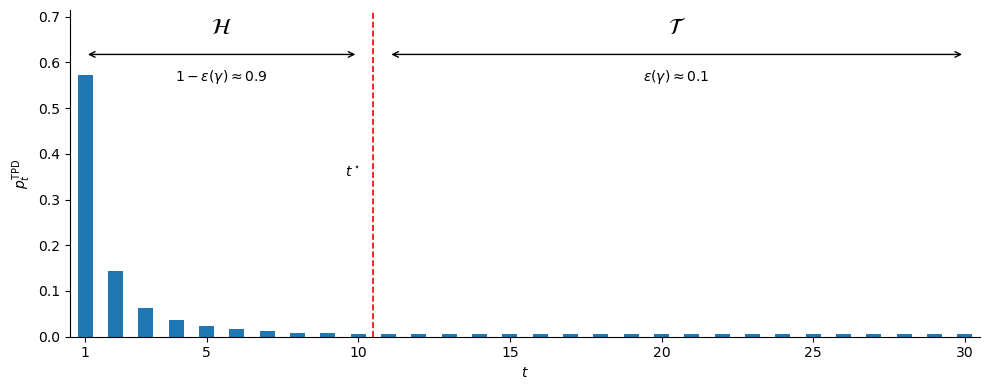

In [136]:
###################################
# TPD weight design scheme
###################################

# Parameters
T = 30
t = np.arange(1, T + 1, dtype=float)

gamma = 2.0      # decay rate
b = 0.0          # onset of decay
t_star = 10      # cut-off time

# Head and tail index sets
head_mask = t <= t_star
tail_mask = t > t_star

# Weights in the head
w_head = (t[head_mask] + b)**(-gamma)
sum_w_head = w_head.sum()

# epsilon(gamma) from p_{t*} = p_{t*+1}
w_tstar = (t_star + b)**(-gamma)
eps = (w_tstar * (T - t_star)) / (w_tstar * (T - t_star) + sum_w_head)

p = np.zeros_like(t, dtype=float)
p[head_mask] = (1.0 - eps) * ((t[head_mask] + b)**(-gamma) / sum_w_head)
p[tail_mask] = eps / (T - t_star)

head_mass = 1 - eps
tail_mass = eps
print(f"epsilon(gamma) = {eps:.3f}, head mass ~ {head_mass:.3f}, tail mass ~ {tail_mass:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))

# Thinner bars
ax.bar(t, p, width=0.5)

# Dashed red vertical line at t_star + 0.5
x_split = t_star + 0.5
ax.axvline(x_split, linestyle="--", linewidth=1.2, color="red")

# Remove top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Label t^* slightly to the left of the line
ax.text(
    x_split - 0.7,
    p.max() * 0.6,
    r"$t^\star$",
    ha="center",
    va="bottom",
    rotation=0,
)

# --- Mass labels a bit lower so arrows don't overlap ---

y_text = p.max() * 0.96     # moved down from 1.02
head_x = (1 + t_star) / 2
tail_x = (t_star + 1 + T) / 2

ax.text(
    head_x,
    y_text,
    rf"$1 - \varepsilon(\gamma) \approx {head_mass:.1f}$",
    ha="center",
    va="bottom",
)
ax.text(
    tail_x,
    y_text,
    rf"$\varepsilon(\gamma) \approx {tail_mass:.1f}$",
    ha="center",
    va="bottom",
)

# --- Mark head and tail regions H and T ---

y_region = p.max() * 1.08     # arrows
y_label  = p.max() * 1.14     # region labels

# Head region: 1 to t_star
ax.annotate(
    "",
    xy=(1, y_region),
    xytext=(t_star, y_region),
    arrowprops=dict(arrowstyle="<->", linewidth=1.0)
)
ax.text(
    (1 + t_star) / 2,
    y_label,
    r"$\mathcal{H}$",
    ha="center",
    va="bottom",
    fontsize=16,
)

# Tail region: t_star+1 to T
ax.annotate(
    "",
    xy=(t_star + 1, y_region),
    xytext=(T, y_region),
    arrowprops=dict(arrowstyle="<->", linewidth=1.0)
)
ax.text(
    (t_star + 1 + T) / 2,
    y_label,
    r"$\mathcal{T}$",
    ha="center",
    va="bottom",
    fontsize=16,
)

# For paper uncomment title: ax.set_title("Truncated power-law decaying probabilities")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$p_t^{\mathrm{TPD}}$")
ax.set_xlim(0.5, T + 0.5)
ax.set_ylim(0, p.max() * 1.25)
ax.set_xticks([1, 5, 10, 15, 20, 25, 30])

plt.tight_layout()
# plt.savefig("tpd_probabilities.pdf", bbox_inches="tight")
plt.show()


$\mathbb{E}(u_{\max})$ as a fraction of subsample ratio for several $c$ (and $\varepsilon$) (Figure 2 in the paper).

T = 10000, gamma = 2.003335937934146
T = 10000, gamma = 3.1716770032929453
T = 10000, gamma = 4.34833588746086
T = 10000, gamma = 5.430956157396517


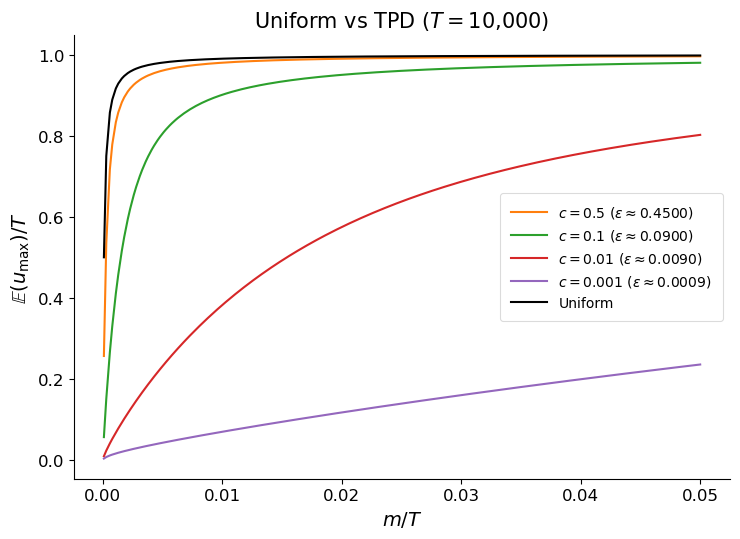

T = 100000, gamma = 3.2251311425189497
T = 100000, gamma = 4.302846723137883
T = 100000, gamma = 5.42678063349799
T = 100000, gamma = 6.482146209095219
T = 100000, gamma = 7.5170616543654925


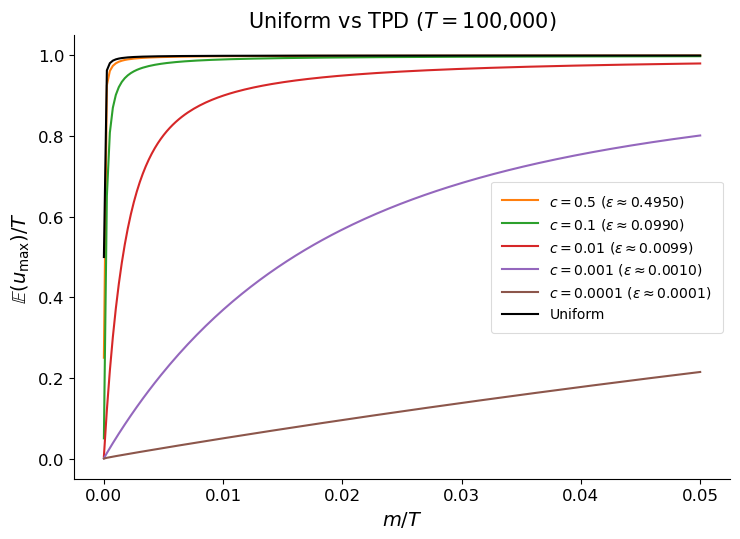

In [137]:
plt.rcdefaults()
# ---------------------------
# Figure for TPD with T = 10000
# ---------------------------
T_example = 10000
t_star_example = 1000
b = 100
cvalues = [0.5, 0.1, 0.01, 0.001]
label_cvalues = [r"$c = 0.5$", r"$c = 0.1$", r"$c = 0.01$", r"$c = 0.001$"]
m_values = np.linspace(1, int(0.05 * T_example), 200, dtype=int)
cols = ['C1', 'C2', 'C3', 'C4', 'C5']

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# TPD cases
for ind, c in enumerate(cvalues):
    gamma_max = gamma_max_value(T_example, t_star_example, c, b)
    probs, eps = TPD_probs(T_example, t_star_example, gamma=gamma_max, b=b)
    print(f"T = {T_example}, gamma = {gamma_max}")

    vals = np.array([expected_umax_safe(probs, m) for m in m_values]) / T_example
    label = label_cvalues[ind] + rf" $(\varepsilon \approx {eps:0.4f})$"

    ax.plot(m_values / T_example, vals, color=cols[ind], label=label)

# Uniform reference
probs_uniform = np.ones(T_example) / T_example
vals_uniform = np.array([expected_umax_safe(probs_uniform, m) for m in m_values]) / T_example
ax.plot(m_values / T_example, vals_uniform, color='k', label="Uniform")

# Styling
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlabel(r"$m/T$", fontsize=14)
ax.set_ylabel(r"$\mathbb{E}(u_{\max})/T$", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_title(r"Uniform vs TPD ($T = 10{,}000$)", fontsize=15)

legend = ax.legend(
    loc="center right",
    fontsize=10,
    frameon=True,
    handlelength=2.6,
    borderpad=0.8,
    labelspacing=0.5
)

legend.get_frame().set_edgecolor("lightgray")
legend.get_frame().set_linewidth(0.8)
plt.tight_layout()
plt.show()


# ---------------------------
# Figure for TPD with T = 100000
# ---------------------------
T_example = 100000
t_star_example = 1000
b = 100
cvalues = [0.5, 0.1, 0.01, 0.001, 0.0001]
label_cvalues = [r"$c = 0.5$", r"$c = 0.1$", r"$c = 0.01$", r"$c = 0.001$", r"$c = 0.0001$"]
m_values = np.linspace(1, int(0.05 * T_example), 200, dtype=int)
cols = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# TPD cases
for ind, c in enumerate(cvalues):
    gamma_max = gamma_max_value(T_example, t_star_example, c, b)
    probs, eps = TPD_probs(T_example, t_star_example, gamma=gamma_max, b=b)
    print(f"T = {T_example}, gamma = {gamma_max}")

    vals = np.array([expected_umax_safe(probs, m) for m in m_values]) / T_example
    label = label_cvalues[ind] + rf" $(\varepsilon \approx {eps:0.4f})$"

    ax.plot(m_values / T_example, vals, color=cols[ind], label=label)

# Uniform reference
probs_uniform = np.ones(T_example) / T_example
vals_uniform = np.array([expected_umax_safe(probs_uniform, m) for m in m_values]) / T_example
ax.plot(m_values / T_example, vals_uniform, color='k', label="Uniform")

# Styling
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlabel(r"$m/T$", fontsize=14)
ax.set_ylabel(r"$\mathbb{E}(u_{\max})/T$", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_title(r"Uniform vs TPD ($T = 100{,}000$)", fontsize=15)

legend = ax.legend(
    loc="center right",
    fontsize=10,
    frameon=True,
    handlelength=2.6,
    borderpad=0.8,
    labelspacing=0.5
)

legend.get_frame().set_edgecolor("lightgray")
legend.get_frame().set_linewidth(0.8)
plt.tight_layout()
plt.show()

$\mathbb{E}(u_{\max})$ as a function of $c$ and $m$ with fixed compute level curves imposed (Figure 3 in the paper).

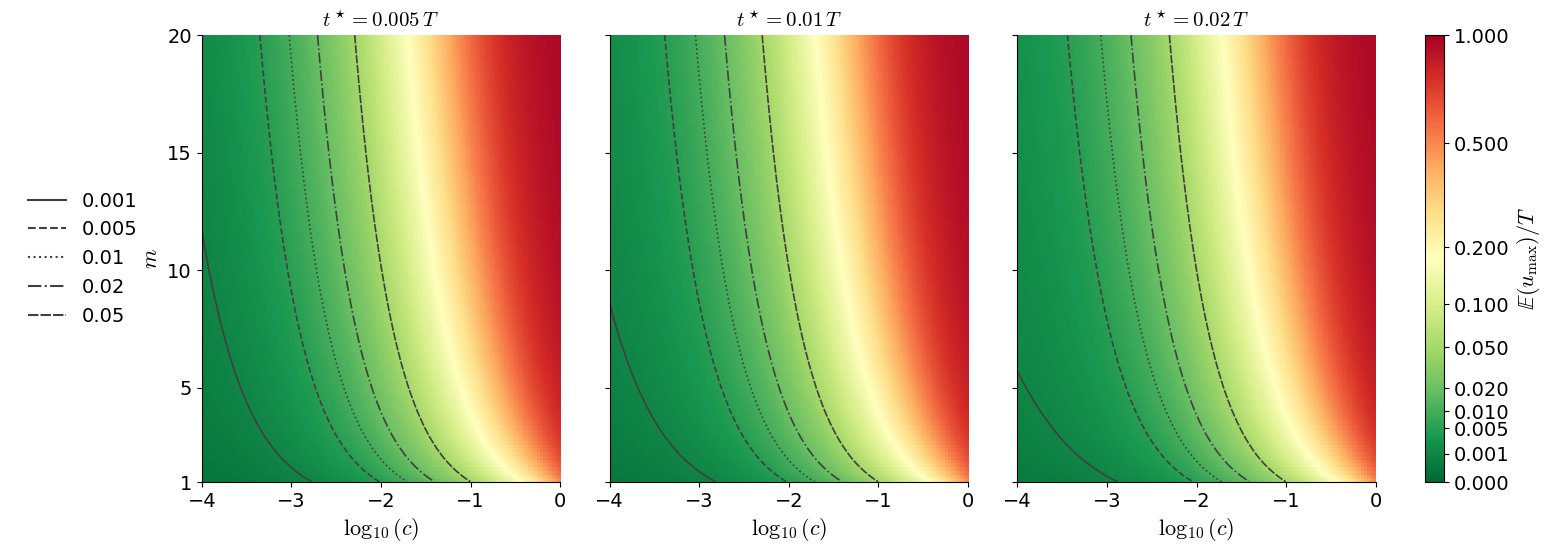

In [138]:
# -------------------------------
# 3-panel figure (shared legend + shared colourbar)
# -------------------------------
make_triptych_heatmap_Figure3(
    T=100_000,
    b=100,
    t_ratios=(0.005, 0.01, 0.02),
    m_max=20,
    c_min=1e-4,
    c_max=1.0,
    n_c=120,
    n_m_bg=120,
    contour_levels=(0.001, 0.005, 0.01, 0.02, 0.05),
    power_gamma=0.4,
    vmax=1.0,
)